# Mounting

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
#import geopandas as gpd
#from shapely.geometry import Polygon
#from shapely.geometry import Point
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.cm as cm
from sklearn import preprocessing
from sklearn.cluster import Birch
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from scipy.special import rel_entr, kl_div
from scipy.stats import entropy
import math
import time
import random
from sklearn.metrics import r2_score

import warnings
warnings.filterwarnings('ignore')

path_seoul_data = '/content/drive/MyDrive/Colab Notebooks/datasets/Seoul/'
path_lta_data = '/content/drive/MyDrive/Colab Notebooks/data_fusion_fcl/lta_data/'

path_data = '/content/drive/MyDrive/Colab Notebooks/Workspace/tour_generation/data_tour/'
path_figure = '/content/drive/MyDrive/Colab Notebooks/Workspace/tour_generation/re1_figure/'
path_result = '/content/drive/MyDrive/Colab Notebooks/Workspace/tour_generation/re1_result/'
path_segregation = '/content/drive/MyDrive/Colab Notebooks/Workspace/tour_generation/re1_segregation/'

def reduce_mem_usage22(props):
    start_mem_usg = props.memory_usage().sum() / 1024**2
    #print("Memory usage of properties dataframe is :",start_mem_usg," MB")
    NAlist = [] # Keeps track of columns that have missing values filled in.
    for col in props.columns:
        if (props[col].dtype != object) & (props[col].dtype != 'category'):  # Exclude strings

            # make variables for Int, max and min
            IsInt = False
            mx = props[col].max()
            mn = props[col].min()

            # Integer does not support NA, therefore, NA needs to be filled
            if not np.isfinite(props[col]).all():
                NAlist.append(col)
                props[col].fillna(mn-1,inplace=True)

            # test if column can be converted to an integer
            asint = props[col].fillna(0).astype(np.int64)
            result = (props[col] - asint)
            result = result.sum()
            if result > -0.01 and result < 0.01:
                IsInt = True

            if IsInt:
                if mn >= 0:
                    if mx < 255:
                        props[col] = props[col].astype(np.uint8)
                    elif mx < 65535:
                        props[col] = props[col].astype(np.uint16)
                    elif mx < 4294967295:
                        props[col] = props[col].astype(np.uint32)
                    else:
                        props[col] = props[col].astype(np.uint64)
                else:
                    if mn > np.iinfo(np.int8).min and mx < np.iinfo(np.int8).max:
                        props[col] = props[col].astype(np.int8)
                    elif mn > np.iinfo(np.int16).min and mx < np.iinfo(np.int16).max:
                        props[col] = props[col].astype(np.int16)
                    elif mn > np.iinfo(np.int32).min and mx < np.iinfo(np.int32).max:
                        props[col] = props[col].astype(np.int32)
                    elif mn > np.iinfo(np.int64).min and mx < np.iinfo(np.int64).max:
                        props[col] = props[col].astype(np.int64)
            else:
                props[col] = props[col].astype(np.float32)

    mem_usg = props.memory_usage().sum() / 1024**2
    return props



def reduce_mem_usage(props: pd.DataFrame) -> pd.DataFrame:
    """
    Downcast numeric columns of a DataFrame to reduce memory usage.

    - Object / category columns are left unchanged.
    - Numeric columns with NaN/inf are filled with a safe value
      (0 if min >= 0, else min-1).
    - If a column is "integer-like" (no meaningful fractional part),
      it is downcast to the smallest integer dtype that can hold its range.
    - Otherwise, it is downcast to float32.
    """
    start_mem_usg = props.memory_usage().sum() / 1024**2
    # print(f"Initial memory usage: {start_mem_usg:.2f} MB")

    for col in props.columns:
        col_dtype = props[col].dtype

        # Skip non-numeric types
        if col_dtype == object or col_dtype.name == "category":
            continue

        col_series = props[col]

        # Replace inf / -inf with NaN first
        if np.isinf(col_series).any():
            col_series = col_series.replace([np.inf, -np.inf], np.nan)

        # If there are NaNs, fill them with a safe value
        if not np.isfinite(col_series).all():
            mn = col_series.min(skipna=True)
            # For non-negative columns, fill with 0 so we never get negatives
            if mn is not None and mn >= 0:
                fill_val = 0
            else:
                # For columns that have negatives, min-1 is safe
                fill_val = (mn - 1) if mn is not None else 0
            col_series = col_series.fillna(fill_val)

        # At this point, col_series has no NaN/inf
        mn = col_series.min()
        mx = col_series.max()

        # Test if column is integer-like (no meaningful fractional part)
        asint = col_series.astype(np.int64)
        result = (col_series - asint).abs().sum()
        is_int_like = result < 0.01

        if is_int_like:
            # Try unsigned ints if all values are >= 0
            if mn >= 0:
                if mx <= np.iinfo(np.uint8).max:
                    col_series = col_series.astype(np.uint8)
                elif mx <= np.iinfo(np.uint16).max:
                    col_series = col_series.astype(np.uint16)
                elif mx <= np.iinfo(np.uint32).max:
                    col_series = col_series.astype(np.uint32)
                else:
                    col_series = col_series.astype(np.uint64)
            else:
                # Signed ints
                if mn >= np.iinfo(np.int8).min and mx <= np.iinfo(np.int8).max:
                    col_series = col_series.astype(np.int8)
                elif mn >= np.iinfo(np.int16).min and mx <= np.iinfo(np.int16).max:
                    col_series = col_series.astype(np.int16)
                elif mn >= np.iinfo(np.int32).min and mx <= np.iinfo(np.int32).max:
                    col_series = col_series.astype(np.int32)
                else:
                    col_series = col_series.astype(np.int64)
        else:
            # Keep as float, but downcast to float32
            col_series = col_series.astype(np.float32)

        props[col] = col_series

    mem_usg = props.memory_usage().sum() / 1024**2
    # print(f"Final memory usage: {mem_usg:.2f} MB (reduced by {start_mem_usg - mem_usg:.2f} MB)")
    return props

Mounted at /content/drive


# Randomly sample population

In [ ]:
from __future__ import annotations

import gc
import re
from pathlib import Path
from typing import Iterable, Optional

import numpy as np
import pandas as pd


# ============================================================
# 1. GENERAL VALIDATION AND COLUMN UTILITIES
# ============================================================

def get_trip_indices(df: pd.DataFrame) -> list[int]:
    """
    Identify available trip indices from columns such as:
        DESTINATION_SUBZONE_1
        DESTINATION_SUBZONE_2
        ...
    """
    pattern = re.compile(r"^DESTINATION_SUBZONE_(\d+)$")

    trip_indices = sorted(
        int(match.group(1))
        for col in df.columns
        if (match := pattern.match(col)) is not None
    )

    if not trip_indices:
        raise ValueError(
            "No DESTINATION_SUBZONE_j columns were found."
        )

    return trip_indices


def validate_wide_schedule_dataframe(
    df: pd.DataFrame,
    id_col: str = "ID",
    trip_max_col: str = "TRIP_MAX",
) -> list[int]:
    """
    Validate the minimum required structure of the wide schedule table.
    """
    required_columns = {id_col, trip_max_col, "ORIGIN_SUBZONE_1"}

    missing = required_columns.difference(df.columns)

    if missing:
        raise KeyError(
            f"Missing required columns: {sorted(missing)}"
        )

    trip_indices = get_trip_indices(df)

    required_destination_columns = {
        f"DESTINATION_SUBZONE_{j}" for j in trip_indices
    }

    missing_destinations = required_destination_columns.difference(df.columns)

    if missing_destinations:
        raise KeyError(
            "Missing destination columns: "
            f"{sorted(missing_destinations)}"
        )

    return trip_indices


def normalize_location_series(series: pd.Series) -> pd.Series:
    """
    Convert valid location identifiers to pandas nullable integers.

    This safely handles columns stored as float because later trip
    columns contain missing values.
    """
    numeric = pd.to_numeric(series, errors="coerce")

    # Remove infinite values.
    numeric = numeric.where(np.isfinite(numeric))

    # Keep only integer-valued identifiers.
    valid_integer = numeric.isna() | np.isclose(
        numeric,
        np.round(numeric),
        equal_nan=True,
    )

    numeric = numeric.where(valid_integer)

    return numeric.round().astype("Int64")


# ============================================================
# 2. EXTRACT ACTIVITY LOCATIONS WITHOUT DOUBLE COUNTING
# ============================================================

def extract_activity_locations_long(
    df: pd.DataFrame,
    id_col: str = "ID",
    trip_max_col: str = "TRIP_MAX",
) -> pd.DataFrame:
    """
    Convert only the activity-location component of the wide schedules
    into a compact long table.

    Each person's activity locations are defined as:

        activity 0: ORIGIN_SUBZONE_1
        activity j: DESTINATION_SUBZONE_j,
                    for j = 1, ..., TRIP_MAX

    This avoids double-counting intermediate locations.

    Returns
    -------
    DataFrame with columns:
        ID
        ACTIVITY_ORDER
        ACTIVITY_SUBZONE
    """
    trip_indices = validate_wide_schedule_dataframe(
        df=df,
        id_col=id_col,
        trip_max_col=trip_max_col,
    )

    pieces = []

    # First activity location: origin of the first trip.
    first_activity = pd.DataFrame(
        {
            id_col: df[id_col].to_numpy(copy=False),
            "ACTIVITY_ORDER": np.zeros(len(df), dtype=np.int16),
            "ACTIVITY_SUBZONE": normalize_location_series(
                df["ORIGIN_SUBZONE_1"]
            ),
        }
    )

    first_activity = first_activity.dropna(
        subset=["ACTIVITY_SUBZONE"]
    )

    pieces.append(first_activity)

    trip_max = pd.to_numeric(
        df[trip_max_col],
        errors="coerce",
    ).fillna(0)

    # Subsequent activity locations: destinations of valid trips.
    for j in trip_indices:
        destination_col = f"DESTINATION_SUBZONE_{j}"

        valid_trip = trip_max.ge(j)

        if not valid_trip.any():
            continue

        current = pd.DataFrame(
            {
                id_col: df.loc[valid_trip, id_col].to_numpy(copy=False),
                "ACTIVITY_ORDER": np.full(
                    valid_trip.sum(),
                    j,
                    dtype=np.int16,
                ),
                "ACTIVITY_SUBZONE": normalize_location_series(
                    df.loc[valid_trip, destination_col]
                ),
            }
        )

        current = current.dropna(
            subset=["ACTIVITY_SUBZONE"]
        )

        pieces.append(current)

    activity_locations = pd.concat(
        pieces,
        ignore_index=True,
    )

    activity_locations["ACTIVITY_SUBZONE"] = (
        activity_locations["ACTIVITY_SUBZONE"].astype("Int64")
    )

    return activity_locations


# ============================================================
# 3. INDIVIDUAL SUBSAMPLING
# ============================================================

def subsample_individuals(
    df: pd.DataFrame,
    fraction: float,
    id_col: str = "ID",
    random_state: int = 42,
    stratify_cols: Optional[Iterable[str]] = None,
) -> pd.DataFrame:
    """
    Subsample individuals and retain their complete daily schedules.

    Parameters
    ----------
    df
        Population-scale wide activity-schedule dataframe.

    fraction
        Fraction of unique individuals to retain, in (0, 1].

    id_col
        Individual identifier.

    random_state
        Reproducibility seed.

    stratify_cols
        Optional demographic columns such as:
            ["AGE", "GENDER", "INCOME"]

        When supplied, sampling is conducted within demographic strata.

    Returns
    -------
    Subsampled dataframe with complete records for selected individuals.
    """
    if not 0 < fraction <= 1:
        raise ValueError(
            "fraction must be in the interval (0, 1]."
        )

    if id_col not in df.columns:
        raise KeyError(f"{id_col!r} is not in the dataframe.")

    stratify_cols = list(stratify_cols or [])

    missing_strata = set(stratify_cols).difference(df.columns)

    if missing_strata:
        raise KeyError(
            f"Missing stratification columns: {sorted(missing_strata)}"
        )

    # One demographic row per individual.
    individual_columns = [id_col] + stratify_cols

    individuals = (
        df[individual_columns]
        .drop_duplicates(subset=[id_col])
        .copy()
    )

    if not stratify_cols:
        n_keep = max(
            1,
            int(round(len(individuals) * fraction)),
        )

        sampled_ids = individuals.sample(
            n=n_keep,
            replace=False,
            random_state=random_state,
        )[id_col]

    else:
        rng = np.random.default_rng(random_state)
        sampled_id_parts = []

        # dropna=False retains strata containing missing demographic values.
        grouped = individuals.groupby(
            stratify_cols,
            dropna=False,
            sort=False,
        )

        for _, group in grouped:
            group_size = len(group)

            n_keep = max(
                1,
                int(round(group_size * fraction)),
            )

            # Do not request more rows than the stratum contains.
            n_keep = min(n_keep, group_size)

            selected_positions = rng.choice(
                group_size,
                size=n_keep,
                replace=False,
            )

            sampled_id_parts.append(
                group.iloc[selected_positions][id_col]
            )

        sampled_ids = pd.concat(
            sampled_id_parts,
            ignore_index=True,
        )

    sampled_id_set = set(sampled_ids.tolist())

    result = df.loc[
        df[id_col].isin(sampled_id_set)
    ].copy()

    result.reset_index(drop=True, inplace=True)

    return result


def generate_individual_subsamples(
    df: pd.DataFrame,
    fractions: Iterable[float] = (
        0.01,
        0.02,
        0.05,
        0.10,
        0.20,
        0.50,
    ),
    id_col: str = "ID",
    random_state: int = 42,
    stratify_cols: Optional[Iterable[str]] = (
        "AGE",
        "GENDER",
        "INCOME",
    ),
) -> tuple[dict[float, pd.DataFrame], pd.DataFrame]:
    """
    Generate several individual-level subsamples.

    Returns
    -------
    datasets
        Dictionary:
            fraction -> sampled dataframe

    summary
        Sample-size and coverage diagnostics.
    """
    fractions = sorted(set(float(x) for x in fractions))

    full_n_individuals = df[id_col].nunique()

    datasets = {}
    summary_rows = []

    for replication_index, fraction in enumerate(fractions):
        sample = subsample_individuals(
            df=df,
            fraction=fraction,
            id_col=id_col,
            random_state=random_state + replication_index,
            stratify_cols=stratify_cols,
        )

        datasets[fraction] = sample

        summary_rows.append(
            {
                "SAMPLING_METHOD": "individual_subsampling",
                "TARGET_FRACTION": fraction,
                "N_ROWS": len(sample),
                "N_INDIVIDUALS": sample[id_col].nunique(),
                "INDIVIDUAL_COVERAGE": (
                    sample[id_col].nunique()
                    / full_n_individuals
                ),
            }
        )

    summary = pd.DataFrame(summary_rows)

    return datasets, summary


# ============================================================
# 4. LOCATION FREQUENCY AND TOP-LOCATION SELECTION
# ============================================================

def calculate_location_frequency(
    df: pd.DataFrame,
    id_col: str = "ID",
    trip_max_col: str = "TRIP_MAX",
    frequency_measure: str = "activity_visits",
) -> pd.DataFrame:
    """
    Calculate activity-location frequency.

    Parameters
    ----------
    frequency_measure
        "activity_visits":
            Number of activity records occurring at each subzone.

        "unique_individuals":
            Number of unique individuals visiting each subzone.

    Returns
    -------
    DataFrame containing:
        ACTIVITY_SUBZONE
        LOCATION_FREQUENCY
        LOCATION_RANK
        CUMULATIVE_FREQUENCY_SHARE
    """
    valid_measures = {
        "activity_visits",
        "unique_individuals",
    }

    if frequency_measure not in valid_measures:
        raise ValueError(
            f"frequency_measure must be one of {sorted(valid_measures)}."
        )

    activity_locations = extract_activity_locations_long(
        df=df,
        id_col=id_col,
        trip_max_col=trip_max_col,
    )

    if frequency_measure == "activity_visits":
        location_frequency = (
            activity_locations
            .groupby(
                "ACTIVITY_SUBZONE",
                observed=True,
            )
            .size()
            .rename("LOCATION_FREQUENCY")
            .reset_index()
        )

    else:
        location_frequency = (
            activity_locations
            .groupby(
                "ACTIVITY_SUBZONE",
                observed=True,
            )[id_col]
            .nunique()
            .rename("LOCATION_FREQUENCY")
            .reset_index()
        )

    location_frequency = location_frequency.sort_values(
        by=[
            "LOCATION_FREQUENCY",
            "ACTIVITY_SUBZONE",
        ],
        ascending=[
            False,
            True,
        ],
        kind="stable",
    ).reset_index(drop=True)

    location_frequency["LOCATION_RANK"] = (
        np.arange(1, len(location_frequency) + 1)
    )

    total_frequency = location_frequency[
        "LOCATION_FREQUENCY"
    ].sum()

    location_frequency["FREQUENCY_SHARE"] = (
        location_frequency["LOCATION_FREQUENCY"]
        / total_frequency
    )

    location_frequency["CUMULATIVE_FREQUENCY_SHARE"] = (
        location_frequency["FREQUENCY_SHARE"].cumsum()
    )

    return location_frequency


def select_top_locations(
    location_frequency: pd.DataFrame,
    location_fraction: Optional[float] = None,
    n_locations: Optional[int] = None,
) -> set[int]:
    """
    Select the most frequently visited locations.

    Specify exactly one of:
        location_fraction
        n_locations
    """
    if (location_fraction is None) == (n_locations is None):
        raise ValueError(
            "Specify exactly one of location_fraction or n_locations."
        )

    total_locations = len(location_frequency)

    if total_locations == 0:
        raise ValueError("No valid activity locations were found.")

    if location_fraction is not None:
        if not 0 < location_fraction <= 1:
            raise ValueError(
                "location_fraction must be in the interval (0, 1]."
            )

        n_keep = max(
            1,
            int(np.ceil(total_locations * location_fraction)),
        )

    else:
        if n_locations is None or n_locations < 1:
            raise ValueError("n_locations must be at least 1.")

        n_keep = min(
            int(n_locations),
            total_locations,
        )

    selected = location_frequency.iloc[:n_keep][
        "ACTIVITY_SUBZONE"
    ]

    return set(selected.astype(int).tolist())


# ============================================================
# 5. COMPLETE-SCHEDULE LOCATION TRUNCATION
# ============================================================

def truncate_locations_complete_schedules(
    df: pd.DataFrame,
    retained_locations: set[int],
    id_col: str = "ID",
    trip_max_col: str = "TRIP_MAX",
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Retain only individuals whose complete activity schedules are
    contained within the retained location set.

    This method is recommended because it does not:
        - remove intermediate trips;
        - break activity sequences;
        - alter TRIP_MAX;
        - create inconsistent origins and destinations.

    Returns
    -------
    truncated_df
        Wide schedules for eligible individuals.

    individual_diagnostics
        One row per individual, including:
            N_ACTIVITY_LOCATIONS
            N_RETAINED_ACTIVITY_LOCATIONS
            LOCATION_COVERAGE
            COMPLETE_SCHEDULE_RETAINED
    """
    if not retained_locations:
        raise ValueError("retained_locations cannot be empty.")

    activity_locations = extract_activity_locations_long(
        df=df,
        id_col=id_col,
        trip_max_col=trip_max_col,
    )

    activity_locations["IS_RETAINED_LOCATION"] = (
        activity_locations["ACTIVITY_SUBZONE"]
        .astype(int)
        .isin(retained_locations)
    )

    individual_diagnostics = (
        activity_locations
        .groupby(id_col, observed=True)
        .agg(
            N_ACTIVITY_LOCATIONS=(
                "ACTIVITY_SUBZONE",
                "size",
            ),
            N_UNIQUE_ACTIVITY_LOCATIONS=(
                "ACTIVITY_SUBZONE",
                "nunique",
            ),
            N_RETAINED_ACTIVITY_LOCATIONS=(
                "IS_RETAINED_LOCATION",
                "sum",
            ),
            COMPLETE_SCHEDULE_RETAINED=(
                "IS_RETAINED_LOCATION",
                "all",
            ),
        )
        .reset_index()
    )

    individual_diagnostics["LOCATION_COVERAGE"] = (
        individual_diagnostics["N_RETAINED_ACTIVITY_LOCATIONS"]
        / individual_diagnostics["N_ACTIVITY_LOCATIONS"]
    )

    retained_ids = individual_diagnostics.loc[
        individual_diagnostics["COMPLETE_SCHEDULE_RETAINED"],
        id_col,
    ]

    retained_id_set = set(retained_ids.tolist())

    truncated_df = df.loc[
        df[id_col].isin(retained_id_set)
    ].copy()

    truncated_df.reset_index(drop=True, inplace=True)

    del activity_locations
    gc.collect()

    return truncated_df, individual_diagnostics


def generate_location_truncations(
    df: pd.DataFrame,
    location_fractions: Iterable[float] = (
        0.05,
        0.10,
        0.20,
        0.50,
        1.00,
    ),
    id_col: str = "ID",
    trip_max_col: str = "TRIP_MAX",
    frequency_measure: str = "activity_visits",
) -> tuple[
    dict[float, pd.DataFrame],
    pd.DataFrame,
    pd.DataFrame,
]:
    """
    Generate datasets based on the top fractions of locations.

    For each location fraction:
        1. Rank locations using the full dataset.
        2. Retain the most frequently visited locations.
        3. Retain only complete schedules contained within those locations.

    Returns
    -------
    datasets
        Dictionary:
            location fraction -> truncated wide dataframe

    summary
        Dataset-level coverage diagnostics.

    location_frequency
        Full location-frequency ranking.
    """
    location_fractions = sorted(
        set(float(x) for x in location_fractions)
    )

    if any(x <= 0 or x > 1 for x in location_fractions):
        raise ValueError(
            "All location fractions must be in the interval (0, 1]."
        )

    location_frequency = calculate_location_frequency(
        df=df,
        id_col=id_col,
        trip_max_col=trip_max_col,
        frequency_measure=frequency_measure,
    )

    full_n_locations = len(location_frequency)
    full_n_individuals = df[id_col].nunique()
    full_frequency = location_frequency[
        "LOCATION_FREQUENCY"
    ].sum()

    datasets = {}
    summary_rows = []

    for fraction in location_fractions:
        retained_locations = select_top_locations(
            location_frequency=location_frequency,
            location_fraction=fraction,
        )

        truncated_df, individual_diagnostics = (
            truncate_locations_complete_schedules(
                df=df,
                retained_locations=retained_locations,
                id_col=id_col,
                trip_max_col=trip_max_col,
            )
        )

        datasets[fraction] = truncated_df

        retained_frequency = (
            location_frequency.loc[
                location_frequency["ACTIVITY_SUBZONE"]
                .astype(int)
                .isin(retained_locations),
                "LOCATION_FREQUENCY",
            ].sum()
        )

        summary_rows.append(
            {
                "TRUNCATION_METHOD": (
                    "top_locations_complete_schedules"
                ),
                "TARGET_LOCATION_FRACTION": fraction,
                "N_RETAINED_LOCATIONS": len(retained_locations),
                "N_FULL_LOCATIONS": full_n_locations,
                "ACTUAL_LOCATION_COVERAGE": (
                    len(retained_locations)
                    / full_n_locations
                ),
                "ATTENDANCE_RECORD_COVERAGE": (
                    retained_frequency
                    / full_frequency
                ),
                "N_RETAINED_INDIVIDUALS": (
                    truncated_df[id_col].nunique()
                ),
                "N_FULL_INDIVIDUALS": full_n_individuals,
                "INDIVIDUAL_COVERAGE": (
                    truncated_df[id_col].nunique()
                    / full_n_individuals
                ),
                "MEAN_WITHIN_SCHEDULE_LOCATION_COVERAGE": (
                    individual_diagnostics[
                        "LOCATION_COVERAGE"
                    ].mean()
                ),
            }
        )

        del individual_diagnostics
        gc.collect()

    summary = pd.DataFrame(summary_rows)

    return datasets, summary, location_frequency

###########################################################

individual_fractions = [
    0.05,
    0.10,
    0.20,
    0.40,
    0.70,
]

reg = "seoul"
M = 6000
seed = 45678
nb = 10

df_fus_tour_raw = pd.read_csv(
    os.path.join(path_result, f"case_{reg}_sim_tour_M_{M}_nb_{nb}_seed_{seed}.csv")
)

individual_subsamples, individual_subsampling_summary = (
    generate_individual_subsamples(
        df=df_fus_tour_raw,
        fractions=individual_fractions,
        id_col="ID",
        random_state=seed,
        stratify_cols=[
            "AGE",
            "GENDER",
            "INCOME",
            "TRIP_MAX",
        ],
    )
)

df_individual_05 = individual_subsamples[0.05]
df_individual_10 = individual_subsamples[0.10]
df_individual_20 = individual_subsamples[0.20]
df_individual_40 = individual_subsamples[0.40]
df_individual_70 = individual_subsamples[0.70]

df_individual_05.to_csv(path_result + f"case_{reg}_sim_tour_M_{M}_nb_{nb}_seed_{seed}_frac_05.csv", index=False)
df_individual_10.to_csv(path_result + f"case_{reg}_sim_tour_M_{M}_nb_{nb}_seed_{seed}_frac_10.csv", index=False)
df_individual_20.to_csv(path_result + f"case_{reg}_sim_tour_M_{M}_nb_{nb}_seed_{seed}_frac_20.csv", index=False)
df_individual_40.to_csv(path_result + f"case_{reg}_sim_tour_M_{M}_nb_{nb}_seed_{seed}_frac_40.csv", index=False)
df_individual_70.to_csv(path_result + f"case_{reg}_sim_tour_M_{M}_nb_{nb}_seed_{seed}_frac_70.csv", index=False)

print('finshed......')

finshed......


# Construct activity schedules

In [ ]:
from __future__ import annotations

import os
import time
from typing import Dict, Literal

import numpy as np
import pandas as pd

# ============================================================
# 1. Configuration
# ============================================================

MAX_TRIPS = 7


AGE_GROUP_MAPPING = {
    0: "age_0",
    1: "age_1",
    2: "age_2",
    3: "age_3",
}

AGE_GROUPS = list(AGE_GROUP_MAPPING.values())


GENDER_GROUP_MAPPING = {
    0: "male",
    1: "female",
}

GENDER_GROUPS = list(GENDER_GROUP_MAPPING.values())


INCOME_GROUP_MAPPING = {
    0: "income_0",
    1: "income_1",
    2: "income_2",
}

INCOME_GROUPS = list(INCOME_GROUP_MAPPING.values())


############################################
# 2. Reshape wide schedules into long trips
############################################
# For seoul
def reshape_trip(
    df: pd.DataFrame,
    max_trips: int = MAX_TRIPS,
) -> pd.DataFrame:
    """
    Convert a wide person-level schedule dataframe into long trip format.

    Each output row represents one trip.

    Required person-level columns
    -----------------------------
    ID, AGE, GENDER, INCOME, TRIP_MAX

    Required trip columns
    ---------------------
    TRIP_PURPOSE_i
    TRAVEL_MODE_i
    TRIP_STARTTIME_i
    TRIP_ENDTIME_i
    ORIGIN_SUBZONE_i
    DESTINATION_SUBZONE_i
    """

    person_columns = [
        "ID",
        "AGE",
        "GENDER",
        "INCOME",
        "TRIP_MAX",
    ]

    missing_person_columns = [column for column in person_columns if column not in df.columns]

    if missing_person_columns:
        raise KeyError("Missing person-level columns: " f"{missing_person_columns}")

    parts = []

    for i in range(1, max_trips + 1):

        trip_columns = [
            f"TRIP_PURPOSE_{i}",
            f"TRAVEL_MODE_{i}",
            f"TRIP_STARTTIME_{i}",
            f"TRIP_ENDTIME_{i}",
            f"ORIGIN_SUBZONE_{i}",
            f"DESTINATION_SUBZONE_{i}",
        ]

        # Skip unavailable trip slots.
        if not all(column in df.columns for column in trip_columns):
            continue

        dff = df[person_columns + trip_columns].copy()

        dff = dff.rename(
            columns={
                f"TRIP_PURPOSE_{i}": "TRIP_PURPOSE",
                f"TRAVEL_MODE_{i}": "TRAVEL_MODE",
                f"TRIP_STARTTIME_{i}": "TRIP_STARTTIME",
                f"TRIP_ENDTIME_{i}": "TRIP_ENDTIME",
                f"ORIGIN_SUBZONE_{i}": "ORIGIN_SUBZONE",
                f"DESTINATION_SUBZONE_{i}": "DESTINATION_SUBZONE",
            }
        )

        dff["TRIP_NUMBER"] = i

        # Retain trip i only if the person reports at least i trips.
        trip_max_numeric = pd.to_numeric(
            dff["TRIP_MAX"],
            errors="coerce",
        )

        dff = dff.loc[trip_max_numeric >= i].copy()

        parts.append(dff)

    if not parts:
        raise ValueError("No valid trip-column sets were found.")

    trips = pd.concat(
        parts,
        ignore_index=True,
    )

    numeric_columns = [
        "ID",
        "AGE",
        "GENDER",
        "INCOME",
        "TRIP_MAX",
        "TRIP_NUMBER",
        "TRIP_PURPOSE",
        "TRIP_STARTTIME",
        "TRIP_ENDTIME",
    ]

    for column in numeric_columns:
        trips[column] = pd.to_numeric(
            trips[column],
            errors="coerce",
        )

    # Subzone identifiers may be alphanumeric and must remain strings.
    # Strip surrounding whitespace and standardize textual missing values.
    subzone_columns = [
        "ORIGIN_SUBZONE",
        "DESTINATION_SUBZONE",
    ]

    for column in subzone_columns:
        trips[column] = (
            trips[column]
            .astype("string")
            .str.strip()
            .replace(
                {
                    "": pd.NA,
                    "nan": pd.NA,
                    "None": pd.NA,
                    "<NA>": pd.NA,
                }
            )
        )

    # Activity reconstruction requires valid origin/destination subzones
    # and a valid destination-purpose code.
    # TRAVEL_MODE may remain missing because it is not used below.
    trips = trips.dropna(
        subset=[
            "ID",
            "AGE",
            "GENDER",
            "INCOME",
            "TRIP_MAX",
            "TRIP_NUMBER",
            "TRIP_PURPOSE",
            "TRIP_STARTTIME",
            "TRIP_ENDTIME",
            "ORIGIN_SUBZONE",
            "DESTINATION_SUBZONE",
        ]
    ).copy()

    # Retain valid demographic codes.
    trips = trips.loc[
        trips["AGE"].isin(AGE_GROUP_MAPPING)
        & trips["GENDER"].isin(GENDER_GROUP_MAPPING)
        & trips["INCOME"].isin(INCOME_GROUP_MAPPING)
    ].copy()

    # Retain valid activity-purpose and hourly codes.
    trips = trips.loc[
        trips["TRIP_PURPOSE"].isin([0, 1, 2, 3, 4, 5])
        & trips["TRIP_STARTTIME"].between(0, 23)
        & trips["TRIP_ENDTIME"].between(0, 23)
    ].copy()

    # Each trip arrival should not precede its departure.
    trips = trips.loc[trips["TRIP_ENDTIME"] >= trips["TRIP_STARTTIME"]].copy()

    integer_columns = [
        "ID",
        "AGE",
        "GENDER",
        "INCOME",
        "TRIP_MAX",
        "TRIP_NUMBER",
        "TRIP_PURPOSE",
    ]

    trips[integer_columns] = trips[integer_columns].astype(int)

    trips["ORIGIN_SUBZONE"] = trips["ORIGIN_SUBZONE"].astype("string")

    trips["DESTINATION_SUBZONE"] = trips["DESTINATION_SUBZONE"].astype("string")

    trips["AGE_GROUP"] = trips["AGE"].map(AGE_GROUP_MAPPING)

    trips["GENDER_GROUP"] = trips["GENDER"].map(GENDER_GROUP_MAPPING)

    trips["INCOME_GROUP"] = trips["INCOME"].map(INCOME_GROUP_MAPPING)

    duplicated = trips.duplicated(
        subset=["ID", "TRIP_NUMBER"],
        keep=False,
    )

    if duplicated.any():
        examples = trips.loc[
            duplicated,
            ["ID", "TRIP_NUMBER"],
        ].head(10)

        raise ValueError("Duplicate trip numbers were found within individuals.\n" f"{examples}")

    return trips.sort_values(["ID", "TRIP_NUMBER"]).reset_index(drop=True)


############################################
# 3. Reconstruct complete daily activities
############################################


def calculate_destination_activities(
    trips: pd.DataFrame,
    day_start_hour: float = 0.0,
    day_end_hour: float = 23.0,
    invalid_timing: Literal["drop", "raise", "keep"] = "drop",
) -> pd.DataFrame:
    """
    Reconstruct the complete sequence of daily activities.

    Parameters
    ----------
    trips:
        Output from reshape_trip().

    day_start_hour:
        Beginning of the observation day.

    day_end_hour:
        End of the observation day.

    invalid_timing:
        Treatment of invalid activity intervals where end time is earlier
        than start time:

        "drop":
            Remove invalid activity rows.

        "raise":
            Raise an error.

        "keep":
            Retain invalid rows.
    """

    required_columns = [
        "ID",
        "AGE",
        "AGE_GROUP",
        "GENDER",
        "GENDER_GROUP",
        "INCOME",
        "INCOME_GROUP",
        "TRIP_NUMBER",
        "TRIP_PURPOSE",
        "TRIP_STARTTIME",
        "TRIP_ENDTIME",
        "ORIGIN_SUBZONE",
        "DESTINATION_SUBZONE",
    ]

    missing_columns = [column for column in required_columns if column not in trips.columns]

    if missing_columns:
        raise KeyError(
            "Missing columns required for activity reconstruction: " f"{missing_columns}"
        )

    data = trips.copy().sort_values(["ID", "TRIP_NUMBER"]).reset_index(drop=True)

    if data.empty:
        raise ValueError("The trip dataframe is empty.")

    demographic_columns = [
        "ID",
        "AGE",
        "AGE_GROUP",
        "GENDER",
        "GENDER_GROUP",
        "INCOME",
        "INCOME_GROUP",
    ]

    # Identify the first and last trip of each person.
    data["_ROW_ORDER"] = data.groupby("ID").cumcount()

    data["_REVERSE_ROW_ORDER"] = data.groupby("ID").cumcount(ascending=False)

    first_trips = data.loc[data["_ROW_ORDER"] == 0].copy()

    last_trips = data.loc[data["_REVERSE_ROW_ORDER"] == 0].copy()

    activity_parts = []

    # ========================================================
    # First activity
    # ========================================================

    first_activities = first_trips[demographic_columns].copy()

    first_activities["ACTIVITY_ORDER"] = 1

    # The day begins at home by definition.
    first_activities["ACTIVITY_PURPOSE"] = 0

    first_activities["ACTIVITY_SUBZONE"] = first_trips["ORIGIN_SUBZONE"].values

    first_activities["ACTIVITY_STARTTIME"] = day_start_hour

    first_activities["ACTIVITY_ENDTIME"] = first_trips["TRIP_STARTTIME"].values

    first_activities["ACTIVITY_TYPE"] = "first_activity"

    activity_parts.append(first_activities)

    # ========================================================
    # Intermediate activities
    # ========================================================

    data["NEXT_TRIP_STARTTIME"] = data.groupby("ID")["TRIP_STARTTIME"].shift(-1)

    intermediate_trips = data.loc[data["_REVERSE_ROW_ORDER"] > 0].copy()

    if not intermediate_trips.empty:

        intermediate_activities = intermediate_trips[demographic_columns].copy()

        # Trip 1 creates activity 2, trip 2 creates activity 3.
        intermediate_activities["ACTIVITY_ORDER"] = (
            intermediate_trips["TRIP_NUMBER"].astype(int).values + 1
        )

        intermediate_activities["ACTIVITY_PURPOSE"] = intermediate_trips["TRIP_PURPOSE"].values

        intermediate_activities["ACTIVITY_SUBZONE"] = intermediate_trips[
            "DESTINATION_SUBZONE"
        ].values

        intermediate_activities["ACTIVITY_STARTTIME"] = intermediate_trips["TRIP_ENDTIME"].values

        intermediate_activities["ACTIVITY_ENDTIME"] = intermediate_trips[
            "NEXT_TRIP_STARTTIME"
        ].values

        intermediate_activities["ACTIVITY_TYPE"] = "intermediate_activity"

        activity_parts.append(intermediate_activities)

    # ========================================================
    # Last activity
    # ========================================================

    last_activities = last_trips[demographic_columns].copy()

    last_activities["ACTIVITY_ORDER"] = last_trips["TRIP_NUMBER"].astype(int).values + 1

    last_activities["ACTIVITY_PURPOSE"] = last_trips["TRIP_PURPOSE"].values

    last_activities["ACTIVITY_SUBZONE"] = last_trips["DESTINATION_SUBZONE"].values

    last_activities["ACTIVITY_STARTTIME"] = last_trips["TRIP_ENDTIME"].values

    last_activities["ACTIVITY_ENDTIME"] = day_end_hour

    last_activities["ACTIVITY_TYPE"] = "last_activity"

    activity_parts.append(last_activities)

    # ========================================================
    # Combine activity records
    # ========================================================

    activities = pd.concat(
        activity_parts,
        ignore_index=True,
    )

    activities["ACTIVITY_STARTTIME"] = pd.to_numeric(
        activities["ACTIVITY_STARTTIME"],
        errors="coerce",
    )

    activities["ACTIVITY_ENDTIME"] = pd.to_numeric(
        activities["ACTIVITY_ENDTIME"],
        errors="coerce",
    )

    activities = activities.dropna(
        subset=[
            "ID",
            "ACTIVITY_ORDER",
            "ACTIVITY_SUBZONE",
            "ACTIVITY_STARTTIME",
            "ACTIVITY_ENDTIME",
        ]
    ).copy()

    # Inclusive duration requested by the study design:
    # duration = end time - start time + 1.
    #
    # Examples:
    # start=8, end=8  -> duration=1 hour
    # start=8, end=10 -> duration=3 hours
    activities["ACTIVITY_DURATION_HOURS"] = (
        activities["ACTIVITY_ENDTIME"] - activities["ACTIVITY_STARTTIME"] + 1.0
    )

    # Check the underlying interval directly. With inclusive duration,
    # end < start corresponds to a non-positive/invalid interval.
    activities["INVALID_ACTIVITY_TIMING"] = (
        activities["ACTIVITY_ENDTIME"] < activities["ACTIVITY_STARTTIME"]
    )

    invalid_rows = activities.loc[activities["INVALID_ACTIVITY_TIMING"]]

    if not invalid_rows.empty:

        invalid_examples = invalid_rows[
            [
                "ID",
                "ACTIVITY_ORDER",
                "ACTIVITY_STARTTIME",
                "ACTIVITY_ENDTIME",
                "ACTIVITY_DURATION_HOURS",
            ]
        ].head(10)

        if invalid_timing == "raise":
            raise ValueError("Invalid activity intervals were found:\n" f"{invalid_examples}")

        if invalid_timing == "drop":
            activities = activities.loc[~activities["INVALID_ACTIVITY_TIMING"]].copy()

        elif invalid_timing != "keep":
            raise ValueError("invalid_timing must be " "'drop', 'raise', or 'keep'.")

    # Convert the inclusive duration directly to minutes.
    activities["ACTIVITY_DURATION_MINUTES"] = activities["ACTIVITY_DURATION_HOURS"] * 60.0

    activities["ACTIVITY_ORDER"] = activities["ACTIVITY_ORDER"].astype(int)

    activities["ACTIVITY_SUBZONE"] = activities["ACTIVITY_SUBZONE"].astype("string").str.strip()

    activities = activities.sort_values(["ID", "ACTIVITY_ORDER"]).reset_index(drop=True)

    output_columns = [
        "ID",
        "AGE",
        "AGE_GROUP",
        "GENDER",
        "GENDER_GROUP",
        "INCOME",
        "INCOME_GROUP",
        "ACTIVITY_ORDER",
        "ACTIVITY_PURPOSE",
        "ACTIVITY_SUBZONE",
        "ACTIVITY_STARTTIME",
        "ACTIVITY_ENDTIME",
        "ACTIVITY_DURATION_HOURS",
        "ACTIVITY_DURATION_MINUTES",
    ]

    return activities[output_columns]


#######################################
# 4. Validate the activity reconstruction
#######################################


def validate_activity_reconstruction(
    trips: pd.DataFrame,
    activities: pd.DataFrame,
) -> pd.DataFrame:
    """
    Check that a person with N trips has N + 1 activities.
    """

    trip_counts = trips.groupby("ID").size().rename("N_TRIPS")

    activity_counts = activities.groupby("ID").size().rename("N_ACTIVITIES")

    validation = pd.concat(
        [
            trip_counts,
            activity_counts,
        ],
        axis=1,
    ).fillna(0)

    validation["N_TRIPS"] = validation["N_TRIPS"].astype(int)

    validation["N_ACTIVITIES"] = validation["N_ACTIVITIES"].astype(int)

    validation["EXPECTED_N_ACTIVITIES"] = validation["N_TRIPS"] + 1

    validation["VALID_ACTIVITY_COUNT"] = (
        validation["N_ACTIVITIES"] == validation["EXPECTED_N_ACTIVITIES"]
    )

    return validation.reset_index()


###############################################
# 5. Check first and last activity consistency
###############################################


def validate_first_last_activities(
    trips: pd.DataFrame,
    activities: pd.DataFrame,
) -> pd.DataFrame:
    """
    Validate the locations and purposes of first and last activities.

    Expected:
    - first activity location = first trip origin;
    - last activity location = last trip destination;
    - first activity purpose = 0 (home);
    - last activity purpose = last trip purpose.
    """

    ordered_trips = trips.sort_values(["ID", "TRIP_NUMBER"])

    first_trips = ordered_trips.groupby("ID", as_index=False).first()

    last_trips = ordered_trips.groupby("ID", as_index=False).last()

    ordered_activities = activities.sort_values(["ID", "ACTIVITY_ORDER"])

    first_activities = ordered_activities.groupby(
        "ID",
        as_index=False,
    ).first()

    last_activities = ordered_activities.groupby(
        "ID",
        as_index=False,
    ).last()

    validation = (
        first_trips[
            [
                "ID",
                "ORIGIN_SUBZONE",
                "TRIP_STARTTIME",
            ]
        ]
        .rename(
            columns={
                "ORIGIN_SUBZONE": ("EXPECTED_FIRST_SUBZONE"),
                "TRIP_STARTTIME": ("EXPECTED_FIRST_ENDTIME"),
            }
        )
        .merge(
            last_trips[
                [
                    "ID",
                    "DESTINATION_SUBZONE",
                    "TRIP_PURPOSE",
                    "TRIP_ENDTIME",
                ]
            ].rename(
                columns={
                    "DESTINATION_SUBZONE": ("EXPECTED_LAST_SUBZONE"),
                    "TRIP_PURPOSE": ("EXPECTED_LAST_PURPOSE"),
                    "TRIP_ENDTIME": ("EXPECTED_LAST_STARTTIME"),
                }
            ),
            on="ID",
            how="inner",
            validate="one_to_one",
        )
        .merge(
            first_activities[
                [
                    "ID",
                    "ACTIVITY_PURPOSE",
                    "ACTIVITY_SUBZONE",
                    "ACTIVITY_ENDTIME",
                ]
            ].rename(
                columns={
                    "ACTIVITY_PURPOSE": ("FIRST_ACTIVITY_PURPOSE"),
                    "ACTIVITY_SUBZONE": ("FIRST_ACTIVITY_SUBZONE"),
                    "ACTIVITY_ENDTIME": ("FIRST_ACTIVITY_ENDTIME"),
                }
            ),
            on="ID",
            how="inner",
            validate="one_to_one",
        )
        .merge(
            last_activities[
                [
                    "ID",
                    "ACTIVITY_PURPOSE",
                    "ACTIVITY_SUBZONE",
                    "ACTIVITY_STARTTIME",
                    "ACTIVITY_ENDTIME",
                ]
            ].rename(
                columns={
                    "ACTIVITY_PURPOSE": ("LAST_ACTIVITY_PURPOSE"),
                    "ACTIVITY_SUBZONE": ("LAST_ACTIVITY_SUBZONE"),
                    "ACTIVITY_STARTTIME": ("LAST_ACTIVITY_STARTTIME"),
                    "ACTIVITY_ENDTIME": ("LAST_ACTIVITY_ENDTIME"),
                }
            ),
            on="ID",
            how="inner",
            validate="one_to_one",
        )
    )

    validation["VALID_FIRST_LOCATION"] = (
        validation["FIRST_ACTIVITY_SUBZONE"] == validation["EXPECTED_FIRST_SUBZONE"]
    )

    validation["VALID_LAST_LOCATION"] = (
        validation["LAST_ACTIVITY_SUBZONE"] == validation["EXPECTED_LAST_SUBZONE"]
    )

    validation["VALID_FIRST_PURPOSE"] = validation["FIRST_ACTIVITY_PURPOSE"] == 0

    validation["VALID_LAST_PURPOSE"] = (
        validation["LAST_ACTIVITY_PURPOSE"] == validation["EXPECTED_LAST_PURPOSE"]
    )

    validation["VALID_FIRST_ENDTIME"] = (
        validation["FIRST_ACTIVITY_ENDTIME"] == validation["EXPECTED_FIRST_ENDTIME"]
    )

    validation["VALID_LAST_STARTTIME"] = (
        validation["LAST_ACTIVITY_STARTTIME"] == validation["EXPECTED_LAST_STARTTIME"]
    )

    validation["VALID_LAST_ENDTIME"] = validation["LAST_ACTIVITY_ENDTIME"] == 24

    return validation


###################################
# 6. Full trip-to-activity wrapper
###################################


def build_activity_schedule_pipeline(
    df: pd.DataFrame,
    max_trips: int = MAX_TRIPS,
    day_start_hour: float = 0.0,
    day_end_hour: float = 23.0,
    invalid_timing: Literal[
        "drop",
        "raise",
        "keep",
    ] = "drop",
) -> Dict[str, pd.DataFrame]:
    """
    Complete pipeline from wide trip schedules to activity schedules.
    """

    trips = reshape_trip(
        df=df,
        max_trips=max_trips,
    )

    activities = calculate_destination_activities(
        trips=trips,
        day_start_hour=day_start_hour,
        day_end_hour=day_end_hour,
        invalid_timing=invalid_timing,
    )

    activity_count_validation = validate_activity_reconstruction(
        trips=trips,
        activities=activities,
    )

    first_last_validation = validate_first_last_activities(
        trips=trips,
        activities=activities,
    )

    return {
        "trips": trips,
        "activities": activities,
        "activity_count_validation": (activity_count_validation),
        "first_last_validation": (first_last_validation),
    }


PURPOSE_LABELS = {
    0: "Returning Home",
    1: "Work/Commute",
    2: "Dining",
    3: "Shopping",
    4: "Education",
    5: "Other",
}


def summarize_earliest_activity_start(activities: pd.DataFrame) -> pd.DataFrame:
    """Return the earliest activity start time for every purpose code."""
    summary = (
        activities.assign(
            ACTIVITY_PURPOSE=pd.to_numeric(activities["ACTIVITY_PURPOSE"], errors="coerce")
        )
        .dropna(subset=["ACTIVITY_PURPOSE", "ACTIVITY_STARTTIME"])
        .assign(ACTIVITY_PURPOSE=lambda x: x["ACTIVITY_PURPOSE"].astype(int))
        .groupby("ACTIVITY_PURPOSE", as_index=False)
        .agg(EARLIEST_ACTIVITY_STARTTIME=("ACTIVITY_STARTTIME", "min"))
        .set_index("ACTIVITY_PURPOSE")
        .reindex(PURPOSE_LABELS)
        .rename_axis("ACTIVITY_PURPOSE")
        .reset_index()
    )
    summary["PURPOSE_LABEL"] = summary["ACTIVITY_PURPOSE"].map(PURPOSE_LABELS)
    return summary[["ACTIVITY_PURPOSE", "PURPOSE_LABEL", "EARLIEST_ACTIVITY_STARTTIME"]]


def main() -> None:
    """Load a wide schedule, reconstruct activities, validate, and save output."""

    reg = "seoul"
    M = 6000
    #seed = 12345
    nb = 10
    #frac = ''#'_frac_05'

    for seed in [1]:#[12345, 23456, 34567, 45678, 56789]:#['_frac_05', '_frac_10', '_frac_20', '_frac_40', '_frac_70']:
    #for fz in ['0.6', '0.8']:#['_frac_05', '_frac_10', '_frac_20', '_frac_40', '_frac_70']:
        print('**********************************')
        print(f'For fraction {seed}...')

        total_start_time = time.time()
        input_file = os.path.join(
            #path_result,
            path_data,
            #f"case_{reg}_sim_tour_M_{M}_nb_{nb}_seed_{seed}{frac}.csv"
            #f"distort_pcm_case_{reg}_sim_tour_M_{M}_nb_{nb}_seed_{seed}_severity_{fz}_combined.csv"
            #f"distort_hts_case_{reg}_sim_tour_M_{M}_nb_{nb}_seed_{seed}_frac_{fz}.csv"
            #f"data_{reg}_hts_tour_M_{M}_nb_{nb}_seed_{seed}.csv"
            f"data_{reg}_hts_tour.csv"
        )
        output_file = os.path.join(
            path_segregation,
            #f"segregation_activities_{reg}_M_{M}_nb_{nb}_seed_{seed}{frac}.csv",
            #f"distort_pcm_segregation_activities_{reg}_M_{M}_nb_{nb}_seed_{seed}_severity_{fz}_combined.csv"
            #f"distort_hts_segregation_activities_{reg}_M_{M}_nb_{nb}_seed_{seed}_frac_{fz}.csv"
            #f"hts_segregation_activities_{reg}_M_{M}_nb_{nb}_seed_{seed}.csv",
            f"unweighted_hts_segregation_activities_{reg}.csv",
        )

        df_fus_tour_raw = pd.read_csv(input_file)
        # commend out if not hts
        age_mapping = {0: 0, 1: 0, 2: 1, 3: 1, 4: 2,  5: 2, 6: 3, 7: 3}
        df_fus_tour_raw["AGE"] = df_fus_tour_raw["AGE"].replace(age_mapping)


        pipeline_start_time = time.time()
        results = build_activity_schedule_pipeline(
            df=df_fus_tour_raw,
            max_trips=MAX_TRIPS,
            day_start_hour=0,
            day_end_hour=23,
            invalid_timing="drop",
        )
        pipeline_duration = time.time() - pipeline_start_time

        activities = results["activities"]
        earliest_start = summarize_earliest_activity_start(activities)
        del df_fus_tour_raw, results

        if reg == "seoul":
            activities["ACTIVITY_SUBZONE"] = activities["ACTIVITY_SUBZONE"].astype(float).astype(int)

        os.makedirs(path_segregation, exist_ok=True)
        activities.to_csv(output_file, index=False)

        print(activities)
        print("\n--- Earliest Activity Start Time by Purpose ---")
        print(earliest_start.to_string(index=False, na_rep="No activity"))
        print("\n--- Execution Time ---")
        print(f"Pipeline execution time: {pipeline_duration:.4f} seconds")
        print(f"Total execution time: {time.time() - total_start_time:.4f} seconds")
        print(f"Saved activities to: {output_file}")

if __name__ == "__main__":
    main()

# Place segregation

In [ ]:
from __future__ import annotations

import gc
import time
from typing import Iterable, Optional

import numpy as np
import pandas as pd

# ============================================================
# 1. CONFIGURATION
# ============================================================

AGE_GROUPS = ["age_0", "age_1", "age_2", "age_3"]

GENDER_GROUPS = ["male", "female"]

INCOME_GROUPS = ["income_0", "income_1", "income_2"]

ATTRIBUTE_CONFIGURATIONS = [
    ("AGE", "AGE_GROUP", AGE_GROUPS),
    ("GENDER", "GENDER_GROUP", GENDER_GROUPS),
    ("INCOME", "INCOME_GROUP", INCOME_GROUPS),
]


# ============================================================
# 2. VALIDATION
# ============================================================


def validate_required_columns(
    df: pd.DataFrame,
    required_columns: Iterable[str],
    dataframe_name: str,
) -> None:
    required_columns = list(required_columns)
    missing = [c for c in required_columns if c not in df.columns]

    if missing:
        raise KeyError(f"{dataframe_name} is missing columns: {missing}")

    if df.empty:
        raise ValueError(f"{dataframe_name} is empty.")


# ============================================================
# 3. COMMON SAMPLE PREPARATION
# ============================================================


def prepare_attribute_activities(
    activities: pd.DataFrame,
    group_column: str,
    group_categories: Iterable,
    person_column: str = "ID",
    location_column: str = "ACTIVITY_SUBZONE",
    purpose_column: str = "ACTIVITY_PURPOSE",
    start_column: str = "ACTIVITY_STARTTIME",
    end_column: str = "ACTIVITY_ENDTIME",
    duration_hours_column: str = "ACTIVITY_DURATION_HOURS",
    activity_purposes: Optional[Iterable] = None,
    minimum_duration_hours: float = 0.0,
) -> pd.DataFrame:
    """Prepare one common sample for all segregation resolutions."""
    if minimum_duration_hours < 0:
        raise ValueError("minimum_duration_hours must be non-negative.")

    required = [
        person_column,
        group_column,
        location_column,
        purpose_column,
        start_column,
        end_column,
    ]
    validate_required_columns(activities, required, "activities")

    columns = required.copy()
    if duration_hours_column in activities.columns:
        columns.append(duration_hours_column)

    data = activities[columns].copy()

    for column in [start_column, end_column]:
        data[column] = pd.to_numeric(data[column], errors="coerce")

    if duration_hours_column in data.columns:
        data[duration_hours_column] = pd.to_numeric(data[duration_hours_column], errors="coerce")

    data = data.dropna(subset=required).copy()

    data = data.loc[
        data[start_column].ge(0)
        & data[start_column].lt(24)
        & data[end_column].ge(0)
        & data[end_column].le(23)
    ].copy()

    # Apply the study's inclusive duration definition consistently.
    inclusive_duration = data[end_column] - data[start_column] + 1.0
    valid_timing = data[end_column].ge(data[start_column])

    if duration_hours_column in data.columns:
        stored_duration = data[duration_hours_column].astype("float64")
        mismatch = stored_duration.notna() & ~np.isclose(
            stored_duration, inclusive_duration, rtol=0.0, atol=1e-10
        )
        if mismatch.any():
            examples = data.loc[
                mismatch,
                [start_column, end_column, duration_hours_column],
            ].head(10)
            raise ValueError(
                f"{duration_hours_column} is inconsistent with the inclusive "
                f"formula end - start + 1.\nExamples:\n{examples}"
            )

    data["ACTIVITY_DURATION_HOURS_CLEAN"] = inclusive_duration.astype("float64")

    # Every valid inclusive interval has a duration of at least one hour.
    data = data.loc[
        valid_timing
        & data["ACTIVITY_DURATION_HOURS_CLEAN"].gt(0)
        & data["ACTIVITY_DURATION_HOURS_CLEAN"].ge(minimum_duration_hours)
    ].copy()

    categories = list(group_categories)
    data = data.loc[data[group_column].isin(categories)].copy()

    if activity_purposes is not None:
        purposes = list(activity_purposes)
        data = data.loc[data[purpose_column].isin(purposes)].copy()

    if data.empty:
        raise ValueError(f"No valid activities remain for {group_column}.")

    group_counts = (
        data[[person_column, group_column]]
        .drop_duplicates()
        .groupby(person_column, observed=True)[group_column]
        .nunique()
    )
    inconsistent = group_counts.loc[group_counts > 1]

    if not inconsistent.empty:
        raise ValueError(
            f"Some people have multiple {group_column} values.\n"
            f"Examples:\n{inconsistent.head(10)}"
        )

    return data.reset_index(drop=True)


# ============================================================
# 4. POPULATION SHARES
# ============================================================


def calculate_population_shares(
    activities: pd.DataFrame,
    group_column: str,
    group_categories: Iterable,
    person_column: str = "ID",
) -> pd.Series:
    categories = list(group_categories)

    people = (
        activities[[person_column, group_column]].dropna().drop_duplicates(subset=[person_column])
    )

    counts = people[group_column].value_counts().reindex(categories, fill_value=0).astype("float64")

    total = counts.sum()
    if total <= 0:
        raise ValueError("The total population count is zero.")

    shares = counts / total
    shares.name = "POPULATION_SHARE"
    return shares


# ============================================================
# 5. HIGHEST-RESOLUTION ATTENDANCE TENSOR
# ============================================================


def calculate_place_purpose_time_attendance(
    activities: pd.DataFrame,
    group_column: str,
    group_categories: Iterable,
    location_column: str = "ACTIVITY_SUBZONE",
    purpose_column: str = "ACTIVITY_PURPOSE",
    start_column: str = "ACTIVITY_STARTTIME",
    end_column: str = "ACTIVITY_ENDTIME",
    time_column: str = "ACTIVITY_TIME_SLOT",
) -> pd.DataFrame:
    """Construct attendance under the inclusive end-hour convention."""
    categories = list(group_categories)

    starts = pd.to_numeric(activities[start_column], errors="coerce").astype("float64")
    durations = pd.to_numeric(activities["ACTIVITY_DURATION_HOURS_CLEAN"], errors="coerce").astype(
        "float64"
    )
    recorded_ends = pd.to_numeric(activities[end_column], errors="coerce").astype("float64")
    # The inclusive interval [start, end] is represented as [start, end + 1)
    # for overlap calculations. Valid hourly slots are exactly 0 through 23.
    exclusive_ends = recorded_ends + 1.0
    expected_durations = recorded_ends - starts + 1.0

    invalid = (
        starts.isna()
        | recorded_ends.isna()
        | starts.lt(0)
        | starts.ge(24)
        | durations.isna()
        | durations.le(0)
        | recorded_ends.lt(starts)
        | recorded_ends.gt(23)
        | ~np.isclose(durations, expected_durations, rtol=0.0, atol=1e-10)
    )

    if invalid.any():
        examples = activities.loc[invalid, [start_column, end_column]].head(10)
        raise ValueError("Invalid intervals remain after preparation.\n" f"Examples:\n{examples}")

    base = activities[[location_column, purpose_column, group_column]].copy()
    start_values = starts.to_numpy(dtype="float64")
    end_values = exclusive_ends.to_numpy(dtype="float64")
    parts = []

    for hour in range(24):
        overlap = np.minimum(end_values, hour + 1.0) - np.maximum(start_values, float(hour))
        active_mask = overlap > 0

        if not active_mask.any():
            continue

        active = base.loc[
            active_mask,
            [location_column, purpose_column, group_column],
        ].copy()
        active[time_column] = hour
        active["_PARTICIPATION_HOURS"] = overlap[active_mask].astype("float64")

        parts.append(
            active.groupby(
                [
                    location_column,
                    purpose_column,
                    time_column,
                    group_column,
                ],
                observed=True,
                sort=False,
            )["_PARTICIPATION_HOURS"].sum()
        )
        del active

    if not parts:
        raise ValueError("No occupied hourly slots were generated.")

    tensor_long = pd.concat(parts).groupby(level=[0, 1, 2, 3], sort=False).sum()

    del parts
    gc.collect()

    tensor = (
        tensor_long.unstack(fill_value=0.0)
        .reindex(columns=categories, fill_value=0.0)
        .astype("float64")
    )
    tensor.index.names = [location_column, purpose_column, time_column]

    del tensor_long
    gc.collect()
    return tensor


# ============================================================
# 6. LOWER-RESOLUTION MARGINALS
# ============================================================


def derive_attendance_marginals(
    place_purpose_time_attendance: pd.DataFrame,
    location_column: str = "ACTIVITY_SUBZONE",
    purpose_column: str = "ACTIVITY_PURPOSE",
    time_column: str = "ACTIVITY_TIME_SLOT",
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    if place_purpose_time_attendance.empty:
        raise ValueError("place_purpose_time_attendance is empty.")

    place_purpose = (
        place_purpose_time_attendance.groupby(level=[location_column, purpose_column], sort=False)
        .sum()
        .astype("float64")
    )

    place_time = (
        place_purpose_time_attendance.groupby(level=[location_column, time_column], sort=False)
        .sum()
        .astype("float64")
    )

    place = (
        place_purpose_time_attendance.groupby(level=[location_column], sort=False)
        .sum()
        .astype("float64")
    )

    return place, place_purpose, place_time


# ============================================================
# 7. SEGREGATION
# ============================================================


def calculate_segregation_output(
    attendance: pd.DataFrame,
    population_shares: pd.Series,
    segregation_column: str,
) -> pd.DataFrame:
    if attendance.empty:
        raise ValueError("The attendance matrix is empty.")

    attendance = attendance.astype("float64")
    total_attendance = attendance.sum(axis=1)
    valid = total_attendance > 0

    attendance = attendance.loc[valid].copy()
    total_attendance = total_attendance.loc[valid]
    composition = attendance.div(total_attendance, axis=0)

    reference = population_shares.reindex(composition.columns).astype("float64")

    if reference.isna().any():
        raise ValueError("Population shares are missing for some groups.")

    if not np.isclose(reference.sum(), 1.0, rtol=0.0, atol=1e-12):
        raise ValueError("Population shares must sum to one.")

    denominator = 2.0 * (1.0 - reference.min())
    if denominator <= 0:
        raise ValueError("The segregation denominator is not positive.")

    segregation = (composition.sub(reference, axis=1).abs().sum(axis=1) / denominator).clip(
        lower=0.0, upper=1.0
    )

    output = composition.add_prefix("COMPOSITION_").copy()
    output[segregation_column] = segregation.astype("float64")
    output["TOTAL_ATTENDANCE_HOURS"] = total_attendance.astype("float64")
    output["N_GROUPS_PRESENT"] = (attendance > 0).sum(axis=1)

    return output.reset_index()


# ============================================================
# 8. FOUR MODELS FOR ONE ATTRIBUTE
# ============================================================


def calculate_four_models_for_attribute(
    activities: pd.DataFrame,
    group_column: str,
    group_categories: Iterable,
    activity_purposes: Optional[Iterable] = None,
    minimum_duration_hours: float = 0.0,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    data = prepare_attribute_activities(
        activities=activities,
        group_column=group_column,
        group_categories=group_categories,
        activity_purposes=activity_purposes,
        minimum_duration_hours=minimum_duration_hours,
    )

    population_shares = calculate_population_shares(
        activities=data,
        group_column=group_column,
        group_categories=group_categories,
    )

    place_purpose_time_attendance = calculate_place_purpose_time_attendance(
        activities=data,
        group_column=group_column,
        group_categories=group_categories,
    )

    place_attendance, place_purpose_attendance, place_time_attendance = derive_attendance_marginals(
        place_purpose_time_attendance
    )

    place = calculate_segregation_output(place_attendance, population_shares, "PLACE_SEGREGATION")
    place_purpose = calculate_segregation_output(
        place_purpose_attendance,
        population_shares,
        "PLACE_PURPOSE_SEGREGATION",
    )
    place_time = calculate_segregation_output(
        place_time_attendance,
        population_shares,
        "PLACE_TIME_SEGREGATION",
    )
    place_purpose_time = calculate_segregation_output(
        place_purpose_time_attendance,
        population_shares,
        "PLACE_PURPOSE_TIME_SEGREGATION",
    )

    del data, population_shares
    del place_attendance, place_purpose_attendance, place_time_attendance
    del place_purpose_time_attendance
    gc.collect()

    return place, place_purpose, place_time, place_purpose_time


# ============================================================
# 9. ALL ATTRIBUTES
# ============================================================


def calculate_all_segregation_models(
    activities: pd.DataFrame,
    activity_purposes: Optional[Iterable] = None,
    minimum_duration_hours: float = 0.0,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    place_results = []
    purpose_results = []
    time_results = []
    purpose_time_results = []

    for attribute_label, group_column, group_categories in ATTRIBUTE_CONFIGURATIONS:
        print(f"Calculating {attribute_label} segregation...")

        place, place_purpose, place_time, place_purpose_time = calculate_four_models_for_attribute(
            activities=activities,
            group_column=group_column,
            group_categories=group_categories,
            activity_purposes=activity_purposes,
            minimum_duration_hours=minimum_duration_hours,
        )

        place_results.append(place.assign(ATTRIBUTE=attribute_label))
        purpose_results.append(place_purpose.assign(ATTRIBUTE=attribute_label))
        time_results.append(place_time.assign(ATTRIBUTE=attribute_label))
        purpose_time_results.append(place_purpose_time.assign(ATTRIBUTE=attribute_label))

        del place, place_purpose, place_time, place_purpose_time
        gc.collect()

    outputs = (
        pd.concat(place_results, ignore_index=True, sort=False),
        pd.concat(purpose_results, ignore_index=True, sort=False),
        pd.concat(time_results, ignore_index=True, sort=False),
        pd.concat(purpose_time_results, ignore_index=True, sort=False),
    )

    del place_results, purpose_results, time_results, purpose_time_results
    gc.collect()
    return outputs


# ============================================================
# 10. WEIGHTED RESOLUTION COMPARISON
# ============================================================


def calculate_attendance_weighted_mean_score(
    dataframe: pd.DataFrame,
    score_column: str,
    output_score_column: str,
    place_column: str = "ACTIVITY_SUBZONE",
    attribute_column: str = "ATTRIBUTE",
    attendance_column: str = "TOTAL_ATTENDANCE_HOURS",
) -> pd.DataFrame:
    required = [place_column, attribute_column, score_column, attendance_column]
    validate_required_columns(dataframe, required, output_score_column)

    data = dataframe[required].copy()
    data[score_column] = pd.to_numeric(data[score_column], errors="coerce")
    data[attendance_column] = pd.to_numeric(data[attendance_column], errors="coerce")
    data = data.dropna(subset=required).copy()
    data = data.loc[data[attendance_column] > 0].copy()

    if data.empty:
        raise ValueError(f"No positive-attendance rows remain for {output_score_column}.")

    data["_WEIGHTED_SCORE"] = data[score_column] * data[attendance_column]

    grouped = (
        data.groupby([place_column, attribute_column], observed=True, sort=False)
        .agg(
            _WEIGHTED_SCORE_SUM=("_WEIGHTED_SCORE", "sum"),
            RESOLVED_TOTAL_ATTENDANCE_HOURS=(attendance_column, "sum"),
            N_RESOLVED_CONTEXTS=(score_column, "size"),
        )
        .reset_index()
    )

    grouped[output_score_column] = (
        grouped["_WEIGHTED_SCORE_SUM"] / grouped["RESOLVED_TOTAL_ATTENDANCE_HOURS"]
    )

    return grouped[
        [
            place_column,
            attribute_column,
            output_score_column,
            "RESOLVED_TOTAL_ATTENDANCE_HOURS",
            "N_RESOLVED_CONTEXTS",
        ]
    ]


def build_place_resolution_comparison(
    all_place_segregation: pd.DataFrame,
    all_place_purpose_segregation: pd.DataFrame,
    all_place_time_segregation: pd.DataFrame,
    all_place_purpose_time_segregation: pd.DataFrame,
    tolerance: float = 1e-10,
) -> pd.DataFrame:
    keys = ["ACTIVITY_SUBZONE", "ATTRIBUTE"]

    place = (
        all_place_segregation[keys + ["PLACE_SEGREGATION", "TOTAL_ATTENDANCE_HOURS"]]
        .rename(columns={"TOTAL_ATTENDANCE_HOURS": "PLACE_TOTAL_ATTENDANCE_HOURS"})
        .copy()
    )

    if place.duplicated(keys).any():
        raise ValueError("Duplicate place-attribute keys in place output.")

    purpose = calculate_attendance_weighted_mean_score(
        all_place_purpose_segregation,
        "PLACE_PURPOSE_SEGREGATION",
        "PURPOSE_RESOLVED_MEAN_SEGREGATION",
    ).rename(
        columns={
            "RESOLVED_TOTAL_ATTENDANCE_HOURS": "PURPOSE_TOTAL_ATTENDANCE_HOURS",
            "N_RESOLVED_CONTEXTS": "N_PURPOSE_CONTEXTS",
        }
    )

    time_resolved = calculate_attendance_weighted_mean_score(
        all_place_time_segregation,
        "PLACE_TIME_SEGREGATION",
        "TIME_RESOLVED_MEAN_SEGREGATION",
    ).rename(
        columns={
            "RESOLVED_TOTAL_ATTENDANCE_HOURS": "TIME_TOTAL_ATTENDANCE_HOURS",
            "N_RESOLVED_CONTEXTS": "N_TIME_CONTEXTS",
        }
    )

    purpose_time = calculate_attendance_weighted_mean_score(
        all_place_purpose_time_segregation,
        "PLACE_PURPOSE_TIME_SEGREGATION",
        "PURPOSE_TIME_RESOLVED_MEAN_SEGREGATION",
    ).rename(
        columns={
            "RESOLVED_TOTAL_ATTENDANCE_HOURS": ("PURPOSE_TIME_TOTAL_ATTENDANCE_HOURS"),
            "N_RESOLVED_CONTEXTS": "N_PURPOSE_TIME_CONTEXTS",
        }
    )

    comparison = (
        place.merge(purpose, on=keys, how="left", validate="one_to_one")
        .merge(time_resolved, on=keys, how="left", validate="one_to_one")
        .merge(purpose_time, on=keys, how="left", validate="one_to_one")
    )

    comparison["PURPOSE_RESOLUTION_GAP"] = (
        comparison["PURPOSE_RESOLVED_MEAN_SEGREGATION"] - comparison["PLACE_SEGREGATION"]
    )
    comparison["TIME_RESOLUTION_GAP"] = (
        comparison["TIME_RESOLVED_MEAN_SEGREGATION"] - comparison["PLACE_SEGREGATION"]
    )
    comparison["PURPOSE_TIME_RESOLUTION_GAP"] = (
        comparison["PURPOSE_TIME_RESOLVED_MEAN_SEGREGATION"] - comparison["PLACE_SEGREGATION"]
    )

    # The convexity result forms a partial order (a diamond), not a total chain:
    #
    #                         purpose-time
    #                         /          \
    #                    purpose        time
    #                         \          /
    #                              place
    #
    # Purpose-resolved and time-resolved segregation are not generally ordered.
    comparison["PURPOSE_TIME_MINUS_PURPOSE_GAP"] = (
        comparison["PURPOSE_TIME_RESOLVED_MEAN_SEGREGATION"]
        - comparison["PURPOSE_RESOLVED_MEAN_SEGREGATION"]
    )
    comparison["PURPOSE_TIME_MINUS_TIME_GAP"] = (
        comparison["PURPOSE_TIME_RESOLVED_MEAN_SEGREGATION"]
        - comparison["TIME_RESOLVED_MEAN_SEGREGATION"]
    )

    comparison["PLACE_LE_PURPOSE_RESOLVED"] = comparison["PURPOSE_RESOLUTION_GAP"] >= -tolerance
    comparison["PLACE_LE_TIME_RESOLVED"] = comparison["TIME_RESOLUTION_GAP"] >= -tolerance
    comparison["PLACE_LE_PURPOSE_TIME_RESOLVED"] = (
        comparison["PURPOSE_TIME_RESOLUTION_GAP"] >= -tolerance
    )
    comparison["PURPOSE_RESOLVED_LE_PURPOSE_TIME_RESOLVED"] = (
        comparison["PURPOSE_TIME_MINUS_PURPOSE_GAP"] >= -tolerance
    )
    comparison["TIME_RESOLVED_LE_PURPOSE_TIME_RESOLVED"] = (
        comparison["PURPOSE_TIME_MINUS_TIME_GAP"] >= -tolerance
    )

    comparison["PURPOSE_ATTENDANCE_CONSISTENT"] = np.isclose(
        comparison["PLACE_TOTAL_ATTENDANCE_HOURS"],
        comparison["PURPOSE_TOTAL_ATTENDANCE_HOURS"],
        rtol=1e-10,
        atol=1e-9,
    )
    comparison["TIME_ATTENDANCE_CONSISTENT"] = np.isclose(
        comparison["PLACE_TOTAL_ATTENDANCE_HOURS"],
        comparison["TIME_TOTAL_ATTENDANCE_HOURS"],
        rtol=1e-10,
        atol=1e-9,
    )
    comparison["PURPOSE_TIME_ATTENDANCE_CONSISTENT"] = np.isclose(
        comparison["PLACE_TOTAL_ATTENDANCE_HOURS"],
        comparison["PURPOSE_TIME_TOTAL_ATTENDANCE_HOURS"],
        rtol=1e-10,
        atol=1e-9,
    )

    return comparison.sort_values(keys).reset_index(drop=True)


def summarize_place_resolution_comparison(
    comparison: pd.DataFrame,
) -> pd.DataFrame:
    required = [
        "ATTRIBUTE", "ACTIVITY_SUBZONE", "PLACE_TOTAL_ATTENDANCE_HOURS",
        "PLACE_SEGREGATION", "PURPOSE_RESOLVED_MEAN_SEGREGATION",
        "TIME_RESOLVED_MEAN_SEGREGATION", "PURPOSE_TIME_RESOLVED_MEAN_SEGREGATION",
        "PURPOSE_RESOLUTION_GAP", "TIME_RESOLUTION_GAP", "PURPOSE_TIME_RESOLUTION_GAP",
        "PURPOSE_TIME_MINUS_PURPOSE_GAP", "PURPOSE_TIME_MINUS_TIME_GAP",
        "PLACE_LE_PURPOSE_RESOLVED", "PLACE_LE_TIME_RESOLVED",
        "PLACE_LE_PURPOSE_TIME_RESOLVED", "PURPOSE_RESOLVED_LE_PURPOSE_TIME_RESOLVED",
        "TIME_RESOLVED_LE_PURPOSE_TIME_RESOLVED",
    ]
    validate_required_columns(comparison, required, "comparison")
    data = comparison[required].dropna().copy()
    data = data.loc[data["PLACE_TOTAL_ATTENDANCE_HOURS"] > 0].copy()
    score_columns = [
        "PLACE_SEGREGATION", "PURPOSE_RESOLVED_MEAN_SEGREGATION",
        "TIME_RESOLVED_MEAN_SEGREGATION", "PURPOSE_TIME_RESOLVED_MEAN_SEGREGATION",
    ]
    for column in score_columns:
        data[f"_WEIGHTED_{column}"] = data[column] * data["PLACE_TOTAL_ATTENDANCE_HOURS"]

    summary = (
        data.groupby("ATTRIBUTE", observed=True, sort=False)
        .agg(
            N_PLACES=("ACTIVITY_SUBZONE", "nunique"),
            TOTAL_ATTENDANCE_HOURS=("PLACE_TOTAL_ATTENDANCE_HOURS", "sum"),
            MEAN_PLACE_SEGREGATION=("PLACE_SEGREGATION", "mean"),
            MEAN_PURPOSE_RESOLVED_SEGREGATION=("PURPOSE_RESOLVED_MEAN_SEGREGATION", "mean"),
            MEAN_TIME_RESOLVED_SEGREGATION=("TIME_RESOLVED_MEAN_SEGREGATION", "mean"),
            MEAN_PURPOSE_TIME_RESOLVED_SEGREGATION=(
                "PURPOSE_TIME_RESOLVED_MEAN_SEGREGATION",
                "mean",
            ),
            MEAN_PURPOSE_GAP=("PURPOSE_RESOLUTION_GAP", "mean"),
            MEAN_TIME_GAP=("TIME_RESOLUTION_GAP", "mean"),
            MEAN_PURPOSE_TIME_GAP=("PURPOSE_TIME_RESOLUTION_GAP", "mean"),
            MIN_PURPOSE_GAP=("PURPOSE_RESOLUTION_GAP", "min"),
            MIN_TIME_GAP=("TIME_RESOLUTION_GAP", "min"),
            MIN_PURPOSE_TIME_GAP=("PURPOSE_TIME_RESOLUTION_GAP", "min"),
            MIN_PURPOSE_TIME_MINUS_PURPOSE_GAP=("PURPOSE_TIME_MINUS_PURPOSE_GAP", "min"),
            MIN_PURPOSE_TIME_MINUS_TIME_GAP=("PURPOSE_TIME_MINUS_TIME_GAP", "min"),
            SHARE_PLACE_LE_PURPOSE=("PLACE_LE_PURPOSE_RESOLVED", "mean"),
            SHARE_PLACE_LE_TIME=("PLACE_LE_TIME_RESOLVED", "mean"),
            SHARE_PLACE_LE_PURPOSE_TIME=("PLACE_LE_PURPOSE_TIME_RESOLVED", "mean"),
            SHARE_PURPOSE_LE_PURPOSE_TIME=(
                "PURPOSE_RESOLVED_LE_PURPOSE_TIME_RESOLVED", "mean"
            ),
            SHARE_TIME_LE_PURPOSE_TIME=("TIME_RESOLVED_LE_PURPOSE_TIME_RESOLVED", "mean"),
            _W_PLACE=("_WEIGHTED_PLACE_SEGREGATION", "sum"),
            _W_PURPOSE=("_WEIGHTED_PURPOSE_RESOLVED_MEAN_SEGREGATION", "sum"),
            _W_TIME=("_WEIGHTED_TIME_RESOLVED_MEAN_SEGREGATION", "sum"),
            _W_PURPOSE_TIME=("_WEIGHTED_PURPOSE_TIME_RESOLVED_MEAN_SEGREGATION", "sum"),
        )
        .reset_index()
    )
    summary["ATTENDANCE_WEIGHTED_PLACE_SEGREGATION"] = (
        summary["_W_PLACE"] / summary["TOTAL_ATTENDANCE_HOURS"]
    )
    summary["ATTENDANCE_WEIGHTED_PURPOSE_SEGREGATION"] = (
        summary["_W_PURPOSE"] / summary["TOTAL_ATTENDANCE_HOURS"]
    )
    summary["ATTENDANCE_WEIGHTED_TIME_SEGREGATION"] = (
        summary["_W_TIME"] / summary["TOTAL_ATTENDANCE_HOURS"]
    )
    summary["ATTENDANCE_WEIGHTED_PURPOSE_TIME_SEGREGATION"] = (
        summary["_W_PURPOSE_TIME"] / summary["TOTAL_ATTENDANCE_HOURS"]
    )
    return summary.drop(columns=["_W_PLACE", "_W_PURPOSE", "_W_TIME", "_W_PURPOSE_TIME"])


# ============================================================
# 11. CLEANLINESS DIAGNOSTICS
# ============================================================


def diagnose_activity_interval_cleanliness(
    activities: pd.DataFrame,
    start_column: str = "ACTIVITY_STARTTIME",
    end_column: str = "ACTIVITY_ENDTIME",
    tolerance: float = 1e-10,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    validate_required_columns(activities, [start_column, end_column], "activities")

    data = activities.copy()
    data[start_column] = pd.to_numeric(data[start_column], errors="coerce")
    data[end_column] = pd.to_numeric(data[end_column], errors="coerce")

    start = data[start_column]
    end = data[end_column]

    data["_IS_MISSING_TIME"] = start.isna() | end.isna()
    data["_START_OUTSIDE_DAY"] = start.notna() & (start.lt(0) | start.ge(24))
    data["_END_OUTSIDE_DAY"] = end.notna() & (end.lt(0) | end.gt(23))
    data["_SAME_START_END"] = (
        start.notna() & end.notna() & np.isclose(start, end, rtol=0.0, atol=1e-12)
    )
    data["_NEGATIVE_DURATION"] = start.notna() & end.notna() & end.lt(start)

    # Inclusive duration: an activity with start == end lasts one hour.
    direct_duration = end - start + 1.0
    start_values = start.to_numpy(dtype="float64")
    end_values = end.to_numpy(dtype="float64")
    valid_numeric = np.isfinite(start_values) & np.isfinite(end_values)
    overlap_sum = np.zeros(len(data), dtype="float64")

    # Use the 24 valid inclusive hourly slots, labelled 0 through 23.
    exclusive_end_values = end_values + 1.0
    for hour in range(24):
        overlap = np.minimum(exclusive_end_values, hour + 1.0) - np.maximum(
            start_values, float(hour)
        )
        overlap = np.where(valid_numeric, np.maximum(overlap, 0.0), 0.0)
        overlap_sum += overlap

    data["_DIRECT_DURATION"] = direct_duration
    data["_HOURLY_OVERLAP_SUM"] = overlap_sum
    data["_OVERLAP_ERROR"] = overlap_sum - direct_duration

    valid_within_day = (
        ~data["_IS_MISSING_TIME"]
        & ~data["_START_OUTSIDE_DAY"]
        & ~data["_END_OUTSIDE_DAY"]
        & ~data["_NEGATIVE_DURATION"]
    )
    data["_OVERLAP_IDENTITY_FAILS"] = valid_within_day & data["_OVERLAP_ERROR"].abs().gt(tolerance)

    summary = pd.DataFrame(
        {
            "CHECK": [
                "Missing time",
                "Start outside [0,24)",
                "End outside [0,23]",
                "Same start and end (one inclusive hour)",
                "Negative duration",
                "Hourly-overlap identity failure",
            ],
            "N_ROWS": [
                int(data["_IS_MISSING_TIME"].sum()),
                int(data["_START_OUTSIDE_DAY"].sum()),
                int(data["_END_OUTSIDE_DAY"].sum()),
                int(data["_SAME_START_END"].sum()),
                int(data["_NEGATIVE_DURATION"].sum()),
                int(data["_OVERLAP_IDENTITY_FAILS"].sum()),
            ],
        }
    )

    issue_columns = [
        "_IS_MISSING_TIME",
        "_START_OUTSIDE_DAY",
        "_END_OUTSIDE_DAY",
        "_NEGATIVE_DURATION",
        "_OVERLAP_IDENTITY_FAILS",
    ]
    problematic = data.loc[data[issue_columns].any(axis=1)].copy()
    return summary, problematic


# ============================================================
# 12. OUTPUT VALIDATION
# ============================================================


def validate_final_outputs(
    all_place_segregation: pd.DataFrame,
    all_place_purpose_segregation: pd.DataFrame,
    all_place_time_segregation: pd.DataFrame,
    all_place_purpose_time_segregation: pd.DataFrame,
    tolerance: float = 1e-10,
) -> pd.DataFrame:
    specifications = [
        (
            "PLACE",
            all_place_segregation,
            "PLACE_SEGREGATION",
            ["ACTIVITY_SUBZONE", "ATTRIBUTE"],
        ),
        (
            "PLACE_PURPOSE",
            all_place_purpose_segregation,
            "PLACE_PURPOSE_SEGREGATION",
            ["ACTIVITY_SUBZONE", "ACTIVITY_PURPOSE", "ATTRIBUTE"],
        ),
        (
            "PLACE_TIME",
            all_place_time_segregation,
            "PLACE_TIME_SEGREGATION",
            ["ACTIVITY_SUBZONE", "ACTIVITY_TIME_SLOT", "ATTRIBUTE"],
        ),
        (
            "PLACE_PURPOSE_TIME",
            all_place_purpose_time_segregation,
            "PLACE_PURPOSE_TIME_SEGREGATION",
            [
                "ACTIVITY_SUBZONE",
                "ACTIVITY_PURPOSE",
                "ACTIVITY_TIME_SLOT",
                "ATTRIBUTE",
            ],
        ),
    ]

    rows = []
    for model, dataframe, score_column, key_columns in specifications:
        required = key_columns + [
            score_column,
            "TOTAL_ATTENDANCE_HOURS",
            "N_GROUPS_PRESENT",
        ]
        validate_required_columns(dataframe, required, model)

        scores = pd.to_numeric(dataframe[score_column], errors="coerce")
        attendance = pd.to_numeric(dataframe["TOTAL_ATTENDANCE_HOURS"], errors="coerce")

        rows.append(
            {
                "MODEL": model,
                "N_ROWS": len(dataframe),
                "N_DUPLICATE_KEYS": int(dataframe.duplicated(subset=key_columns).sum()),
                "SCORES_NONMISSING": bool(scores.notna().all()),
                "SCORES_IN_0_1": bool(scores.between(-tolerance, 1.0 + tolerance).all()),
                "POSITIVE_ATTENDANCE": bool(attendance.gt(0).all()),
            }
        )

    return pd.DataFrame(rows)


# ============================================================
# 13. RUN
# ============================================================

start_time = time.time()

reg = "seoul"
M = 6000
#seed = 12345
nb = 10

#frac = ''#'_frac_70'

#for frac in ['_frac_05', '_frac_10', '_frac_20', '_frac_40', '_frac_70']:
#for fz in ['0.6', '0.8']:
for seed in [12345, 23456, 34567, 45678, 56789]:

    print('**********************************')
    print(f'For fraction {seed}...')


    activities = pd.read_csv(
        #path_segregation + f"segregation_activities_{reg}_M_{M}_nb_{nb}_seed_{seed}{frac}.csv"
        #path_segregation + f"distort_pcm_segregation_activities_{reg}_M_{M}_nb_{nb}_seed_{seed}_severity_{fz}_combined.csv"
        #path_segregation + f"distort_hts_segregation_activities_{reg}_M_{M}_nb_{nb}_seed_{seed}_frac_{fz}.csv"
        path_segregation + f"hts_segregation_activities_{reg}_M_{M}_nb_{nb}_seed_{seed}.csv"
        #path_segregation + f"unweighted_hts_segregation_activities_{reg}.csv"

    )

    activity_cleanliness_summary, problematic_activities = diagnose_activity_interval_cleanliness(
        activities
    )

    print("\nRaw activity-time cleanliness")
    print(activity_cleanliness_summary.to_string(index=False))

    (
        all_place_segregation,
        all_place_purpose_segregation,
        all_place_time_segregation,
        all_place_purpose_time_segregation,
    ) = calculate_all_segregation_models(
        activities=activities,
        activity_purposes=None,
        minimum_duration_hours=0.0,
    )

    all_place_resolution_comparison = build_place_resolution_comparison(
        all_place_segregation=all_place_segregation,
        all_place_purpose_segregation=all_place_purpose_segregation,
        all_place_time_segregation=all_place_time_segregation,
        all_place_purpose_time_segregation=all_place_purpose_time_segregation,
        tolerance=1e-10,
    )

    place_resolution_summary = summarize_place_resolution_comparison(all_place_resolution_comparison)

    validation = validate_final_outputs(
        all_place_segregation,
        all_place_purpose_segregation,
        all_place_time_segregation,
        all_place_purpose_time_segregation,
    )

    print("\nOutput validation")
    print(validation.to_string(index=False))

    print("\nPlace-resolution summary")
    print(
        place_resolution_summary.to_string(
            index=False,
            float_format=lambda value: f"{value:.12g}",
        )
    )

    inequality_checks = [
        "PLACE_LE_PURPOSE_RESOLVED",
        "PLACE_LE_TIME_RESOLVED",
        "PLACE_LE_PURPOSE_TIME_RESOLVED",
        "PURPOSE_RESOLVED_LE_PURPOSE_TIME_RESOLVED",
        "TIME_RESOLVED_LE_PURPOSE_TIME_RESOLVED",
    ]

    attendance_checks = [
        "PURPOSE_ATTENDANCE_CONSISTENT",
        "TIME_ATTENDANCE_CONSISTENT",
        "PURPOSE_TIME_ATTENDANCE_CONSISTENT",
    ]

    print("\nConvexity inequality checks")
    print(all_place_resolution_comparison[inequality_checks].all().to_string())

    print("\nAttendance conservation checks")
    print(all_place_resolution_comparison[attendance_checks].all().to_string())

    print("\nMinimum observed gaps")
    print(
        all_place_resolution_comparison[
            [
                "PURPOSE_RESOLUTION_GAP",
                "TIME_RESOLUTION_GAP",
                "PURPOSE_TIME_RESOLUTION_GAP",
                "PURPOSE_TIME_MINUS_PURPOSE_GAP",
                "PURPOSE_TIME_MINUS_TIME_GAP",
            ]
        ]
        .min()
        .to_string()
    )

    violations = all_place_resolution_comparison.loc[
        ~all_place_resolution_comparison[inequality_checks].all(axis=1)
    ].copy()

    if violations.empty:
        print("\nNo material convexity violations were detected.")
    else:
        print("\nRows with apparent convexity violations")
        print(
            violations[
                [
                    "ACTIVITY_SUBZONE",
                    "ATTRIBUTE",
                    "PLACE_SEGREGATION",
                    "PURPOSE_RESOLVED_MEAN_SEGREGATION",
                    "TIME_RESOLVED_MEAN_SEGREGATION",
                    "PURPOSE_TIME_RESOLVED_MEAN_SEGREGATION",
                    "PURPOSE_RESOLUTION_GAP",
                    "TIME_RESOLUTION_GAP",
                    "PURPOSE_TIME_RESOLUTION_GAP",
                    "PURPOSE_TIME_MINUS_PURPOSE_GAP",
                    "PURPOSE_TIME_MINUS_TIME_GAP",
                    "PLACE_TOTAL_ATTENDANCE_HOURS",
                    "PURPOSE_TOTAL_ATTENDANCE_HOURS",
                    "TIME_TOTAL_ATTENDANCE_HOURS",
                    "PURPOSE_TIME_TOTAL_ATTENDANCE_HOURS",
                ]
            ]
            .sort_values(
                [
                    "PURPOSE_RESOLUTION_GAP",
                    "TIME_RESOLUTION_GAP",
                    "PURPOSE_TIME_RESOLUTION_GAP",
                    "PURPOSE_TIME_MINUS_PURPOSE_GAP",
                    "PURPOSE_TIME_MINUS_TIME_GAP",
                ]
            )
            .head(50)
            .to_string(index=False)
        )

    all_place_segregation.to_csv(
        #path_segregation + f"all_place_segregation_{reg}_M_{M}_nb_{nb}_seed_{seed}{frac}.csv",
        #path_segregation + f"distort_pcm_all_place_segregation_{reg}_M_{M}_nb_{nb}_seed_{seed}_severity_{fz}_combined.csv",
        #path_segregation + f"distort_hts_all_place_segregation_{reg}_M_{M}_nb_{nb}_seed_{seed}_frac_{fz}.csv",
        path_segregation + f"hts_all_place_segregation_{reg}_M_{M}_nb_{nb}_seed_{seed}.csv",
        #path_segregation + f"unweighted_hts_all_place_segregation_{reg}.csv",
        index=False
    )
    all_place_purpose_segregation.to_csv(
        #path_segregation + f"all_place_purpose_segregation_{reg}_M_{M}_nb_{nb}_seed_{seed}{frac}.csv",
        #path_segregation + f"distort_pcm_all_place_purpose_segregation_{reg}_M_{M}_nb_{nb}_seed_{seed}_severity_{fz}_combined.csv",
        #path_segregation + f"distort_hts_all_place_purpose_segregation_{reg}_M_{M}_nb_{nb}_seed_{seed}_frac_{fz}.csv",
        path_segregation + f"hts_all_place_purpose_segregation_{reg}_M_{M}_nb_{nb}_seed_{seed}.csv",
        #path_segregation + f"unweighted_hts_all_place_purpose_segregation_{reg}.csv",
        index=False,
    )
    all_place_time_segregation.to_csv(
        #path_segregation + f"all_place_time_segregation_{reg}_M_{M}_nb_{nb}_seed_{seed}{frac}.csv",
        #path_segregation + f"distort_pcm_all_place_time_segregation_{reg}_M_{M}_nb_{nb}_seed_{seed}_severity_{fz}_combined.csv",
        #path_segregation + f"distort_hts_all_place_time_segregation_{reg}_M_{M}_nb_{nb}_seed_{seed}_frac_{fz}.csv",
        path_segregation + f"hts_all_place_time_segregation_{reg}_M_{M}_nb_{nb}_seed_{seed}.csv",
        #path_segregation + f"unweighted_hts_all_place_time_segregation_{reg}.csv",
        index=False,
    )
    all_place_purpose_time_segregation.to_csv(
        #path_segregation + f"all_place_purpose_time_segregation_{reg}_M_{M}_nb_{nb}_seed_{seed}{frac}.csv",
        #path_segregation + f"distort_pcm_all_place_purpose_time_segregation_{reg}_M_{M}_nb_{nb}_seed_{seed}_severity_{fz}_combined.csv",
        #path_segregation + f"distort_hts_all_place_purpose_time_segregation_{reg}_M_{M}_nb_{nb}_seed_{seed}_frac_{fz}.csv",
        path_segregation + f"hts_all_place_purpose_time_segregation_{reg}_M_{M}_nb_{nb}_seed_{seed}.csv",
        #path_segregation + f"unweighted_hts_all_place_purpose_time_segregation_{reg}.csv",
        index=False,
    )


    end_time = time.time()
    print(f"\nTotal runtime: {end_time - start_time:.4f} seconds")

# Retained analytical outputs:
# 1. all_place_segregation
# 2. all_place_purpose_segregation
# 3. all_place_time_segregation
# 4. all_place_purpose_time_segregation
# 5. all_place_resolution_comparison
# 6. place_resolution_summary
#
# Retained diagnostics:
# 7. activity_cleanliness_summary
# 8. problematic_activities
# 9. validation
# 10. violations

**********************************
For fraction 12345...

Raw activity-time cleanliness
                                  CHECK  N_ROWS
                           Missing time       0
                   Start outside [0,24)       0
                     End outside [0,23]       0
Same start and end (one inclusive hour) 3120723
                      Negative duration       0
        Hourly-overlap identity failure       0
Calculating AGE segregation...
Calculating GENDER segregation...
Calculating INCOME segregation...

Output validation
             MODEL  N_ROWS  N_DUPLICATE_KEYS  SCORES_NONMISSING  SCORES_IN_0_1  POSITIVE_ATTENDANCE
             PLACE    1263                 0               True           True                 True
     PLACE_PURPOSE    6723                 0               True           True                 True
        PLACE_TIME   30282                 0               True           True                 True
PLACE_PURPOSE_TIME   86841                 0              

# Individual segregation

In [ ]:
from __future__ import annotations

import gc
from typing import Iterable
import os
import time
import warnings

import numpy as np
import pandas as pd

AGE_GROUPS = ["age_0", "age_1", "age_2", "age_3"]

GENDER_GROUPS = ["male", "female"]

INCOME_GROUPS = ["income_0", "income_1", "income_2"]

ATTRIBUTE_CONFIGURATIONS = [
    ("AGE", "AGE_GROUP", AGE_GROUPS),
    ("GENDER", "GENDER_GROUP", GENDER_GROUPS),
    ("INCOME", "INCOME_GROUP", INCOME_GROUPS),
]


def canonicalize_subzone(values: pd.Series) -> pd.Series:
    """Create stable string keys while preserving alphanumeric subzones."""
    result = values.astype("string").str.strip()
    result = result.mask(result.str.lower().isin(["", "nan", "none", "null", "<na>"]))
    numeric = pd.to_numeric(result, errors="coerce")
    integer_like = (
        numeric.notna() & np.isfinite(numeric) & np.isclose(numeric % 1, 0.0, rtol=0.0, atol=1e-12)
    )
    result.loc[integer_like] = numeric.loc[integer_like].astype("int64").astype("string")
    return result


def validate_required_columns(df: pd.DataFrame, columns: Iterable[str], name: str) -> None:
    columns = list(columns)
    missing = [c for c in columns if c not in df.columns]
    if missing:
        raise KeyError(f"{name} is missing columns: {missing}")
    if df.empty:
        raise ValueError(f"{name} is empty.")


def prepare_activity_sample(
    activities: pd.DataFrame,
    group_column: str,
    group_categories: Iterable,
    person_column: str = "ID",
) -> pd.DataFrame:
    """Validate and prepare all activity rows without filtering any row."""
    required = [
        person_column,
        group_column,
        "ACTIVITY_SUBZONE",
        "ACTIVITY_PURPOSE",
        "ACTIVITY_STARTTIME",
        "ACTIVITY_ENDTIME",
        "ACTIVITY_DURATION_HOURS",
    ]
    validate_required_columns(activities, required, "activities")

    data = activities[required].copy()
    data["ACTIVITY_SUBZONE"] = canonicalize_subzone(data["ACTIVITY_SUBZONE"])
    data["ACTIVITY_STARTTIME"] = pd.to_numeric(
        data["ACTIVITY_STARTTIME"], errors="coerce", downcast="float"
    )
    data["ACTIVITY_ENDTIME"] = pd.to_numeric(
        data["ACTIVITY_ENDTIME"], errors="coerce", downcast="float"
    )
    data["ACTIVITY_DURATION_HOURS"] = pd.to_numeric(
        data["ACTIVITY_DURATION_HOURS"], errors="coerce", downcast="float"
    )
    valid = data[required].notna().all(axis=1)
    inclusive_duration = data["ACTIVITY_ENDTIME"] - data["ACTIVITY_STARTTIME"] + 1.0
    duration_matches = np.isclose(
        data["ACTIVITY_DURATION_HOURS"], inclusive_duration, rtol=0.0, atol=1e-10
    )
    valid &= data["ACTIVITY_STARTTIME"].ge(0) & data["ACTIVITY_STARTTIME"].lt(24)
    valid &= data["ACTIVITY_ENDTIME"].ge(data["ACTIVITY_STARTTIME"])
    valid &= data["ACTIVITY_ENDTIME"].le(23)
    valid &= data["ACTIVITY_DURATION_HOURS"].gt(0) & duration_matches
    valid &= data[group_column].isin(list(group_categories))
    if not valid.all():
        invalid = data.loc[~valid, required].head(20)
        raise ValueError(
            f"Found {(~valid).sum():,} invalid {group_column} activity rows. "
            "No rows were discarded. ACTIVITY_DURATION_HOURS must equal "
            "ACTIVITY_ENDTIME - ACTIVITY_STARTTIME + 1. Examples:\n"
            f"{invalid.to_string(index=False)}"
        )

    person_group = data[[person_column, group_column]].drop_duplicates()
    bad = person_group.groupby(person_column, observed=True)[group_column].nunique()
    if (bad > 1).any():
        raise ValueError(f"Some people have multiple {group_column} values.")

    return data.reset_index(drop=True)


def prepare_common_activity_cohort(
    activities: pd.DataFrame,
    person_column: str = "ID",
) -> pd.DataFrame:
    """Validate and retain every schedule row and ID for every attribute."""
    group_rules = {
        group_column: list(categories) for _, group_column, categories in ATTRIBUTE_CONFIGURATIONS
    }
    activity_columns = [
        "ACTIVITY_SUBZONE",
        "ACTIVITY_PURPOSE",
        "ACTIVITY_STARTTIME",
        "ACTIVITY_ENDTIME",
        "ACTIVITY_DURATION_HOURS",
    ]
    required = [person_column, *group_rules, *activity_columns]
    validate_required_columns(activities, required, "activities")
    if activities[person_column].isna().any():
        raise ValueError("activities contains missing ID values.")

    data = activities[required].copy()
    data["ACTIVITY_SUBZONE"] = canonicalize_subzone(data["ACTIVITY_SUBZONE"])
    data["ACTIVITY_STARTTIME"] = pd.to_numeric(
        data["ACTIVITY_STARTTIME"], errors="coerce", downcast="float"
    )
    data["ACTIVITY_ENDTIME"] = pd.to_numeric(
        data["ACTIVITY_ENDTIME"], errors="coerce", downcast="float"
    )
    data["ACTIVITY_DURATION_HOURS"] = pd.to_numeric(
        data["ACTIVITY_DURATION_HOURS"], errors="coerce", downcast="float"
    )

    demographic_valid = data[[person_column, *group_rules]].notna().all(axis=1)
    for group_column, categories in group_rules.items():
        demographic_valid &= data[group_column].isin(categories)
    if not demographic_valid.all():
        invalid = data.loc[~demographic_valid, [person_column, *group_rules]]
        raise ValueError(
            f"Found {len(invalid):,} rows with invalid demographic groups. "
            "Check the configured group lists. Examples:\n"
            f"{invalid.head(20).to_string(index=False)}"
        )

    activity_valid = data[[person_column, *activity_columns]].notna().all(axis=1)
    inclusive_duration = data["ACTIVITY_ENDTIME"] - data["ACTIVITY_STARTTIME"] + 1.0
    duration_matches = np.isclose(
        data["ACTIVITY_DURATION_HOURS"], inclusive_duration, rtol=0.0, atol=1e-10
    )
    activity_valid &= data["ACTIVITY_STARTTIME"].ge(0)
    activity_valid &= data["ACTIVITY_STARTTIME"].lt(24)
    activity_valid &= data["ACTIVITY_ENDTIME"].ge(data["ACTIVITY_STARTTIME"])
    activity_valid &= data["ACTIVITY_ENDTIME"].le(23)
    activity_valid &= data["ACTIVITY_DURATION_HOURS"].gt(0) & duration_matches
    if not activity_valid.all():
        invalid_columns = [person_column, *activity_columns]
        invalid = data.loc[~activity_valid, invalid_columns].head(20)
        raise ValueError(
            f"Found {(~activity_valid).sum():,} invalid activity rows. No rows or IDs "
            "were discarded. ACTIVITY_DURATION_HOURS must be positive and equal "
            "ACTIVITY_ENDTIME - ACTIVITY_STARTTIME + 1. "
            "Examples:\n"
            f"{invalid.to_string(index=False)}"
        )

    retained_ids = pd.Index(data[person_column].unique())

    for group_column in group_rules:
        counts = data.groupby(person_column, observed=True)[group_column].nunique()
        if (counts > 1).any():
            bad_ids = counts.index[counts > 1][:20].tolist()
            raise ValueError(
                f"Some people have multiple {group_column} values. " f"Example IDs: {bad_ids}"
            )

    print(
        f"Common activity cohort: {len(retained_ids):,} unique IDs; "
        f"all {len(data):,} activity rows retained"
    )
    return data.reset_index(drop=True)


def calculate_population_shares(
    data: pd.DataFrame,
    group_column: str,
    group_categories: Iterable,
    person_column: str = "ID",
) -> pd.Series:
    categories = list(group_categories)
    people = data[[person_column, group_column]].drop_duplicates(subset=[person_column])
    counts = people[group_column].value_counts().reindex(categories, fill_value=0).astype("float64")
    if counts.sum() <= 0:
        raise ValueError("Population count is zero.")
    return counts / counts.sum()


def _prepare_context_lookup(
    context_result: pd.DataFrame,
    context_columns: list[str],
    categories: list[str],
) -> tuple[pd.DataFrame, list[str]]:
    comp_cols = [f"COMPOSITION_{g}" for g in categories]
    validate_required_columns(context_result, context_columns, "context_result")

    # A composition column can be absent when that category has zero members in
    # the dataframe used to create/pivot the saved context table. Such an absent
    # category has composition zero in every context; add it explicitly so all
    # models use the same configured category vector and column order.
    present_comp_cols = [c for c in comp_cols if c in context_result.columns]
    if not present_comp_cols:
        available = [c for c in context_result.columns if c.startswith("COMPOSITION_")]
        raise KeyError(
            "context_result contains none of the expected composition columns "
            f"{comp_cols}. Available composition columns: {available}"
        )

    lookup = context_result[[*context_columns, *present_comp_cols]].copy()
    if "ACTIVITY_SUBZONE" in context_columns:
        lookup["ACTIVITY_SUBZONE"] = canonicalize_subzone(lookup["ACTIVITY_SUBZONE"])
        lookup = lookup.dropna(subset=["ACTIVITY_SUBZONE"])
    missing_comp_cols = [c for c in comp_cols if c not in lookup.columns]
    for c in missing_comp_cols:
        lookup[c] = 0.0
    if missing_comp_cols:
        warnings.warn(
            "The following configured categories are absent from context_result "
            f"and are treated as zero composition: {missing_comp_cols}",
            RuntimeWarning,
            stacklevel=2,
        )

    lookup = lookup[[*context_columns, *comp_cols]]
    if lookup.duplicated(context_columns).any():
        examples = lookup.loc[lookup.duplicated(context_columns, keep=False), context_columns].head(
            20
        )
        raise ValueError(
            f"Duplicate context keys after normalization: {context_columns}\n"
            f"Examples:\n{examples.to_string(index=False)}"
        )

    for c in comp_cols:
        lookup[c] = pd.to_numeric(lookup[c], errors="coerce").astype("float64")

    if lookup[comp_cols].isna().any().any():
        raise ValueError("Missing context compositions.")

    if not np.allclose(
        lookup[comp_cols].sum(axis=1).to_numpy(),
        1.0,
        rtol=0.0,
        atol=1e-9,
    ):
        raise ValueError("Some context compositions do not sum to one.")

    return lookup, comp_cols


def _initialize_accumulators(person_ids: pd.Index, n_groups: int) -> dict:
    return {
        "person_ids": person_ids,
        "person_to_code": pd.Series(
            np.arange(len(person_ids), dtype=np.int64),
            index=person_ids,
        ),
        "exposure_numerator": np.zeros((len(person_ids), n_groups), dtype=np.float64),
        "matched": np.zeros(len(person_ids), dtype=np.float64),
        "input": np.zeros(len(person_ids), dtype=np.float64),
        "contexts": np.zeros(len(person_ids), dtype=np.int64),
    }


def _accumulate_chunk(
    attendance_chunk: pd.DataFrame,
    context_lookup: pd.DataFrame,
    context_columns: list[str],
    comp_cols: list[str],
    accumulators: dict,
    person_column: str = "ID",
    attendance_column: str = "INDIVIDUAL_ATTENDANCE_HOURS",
) -> None:
    """Merge only one chunk and accumulate exposure numerators with np.add.at."""
    if attendance_chunk.empty:
        return

    chunk = attendance_chunk[[person_column, *context_columns, attendance_column]].copy()
    chunk[attendance_column] = pd.to_numeric(chunk[attendance_column], errors="coerce").astype(
        "float64"
    )
    chunk = chunk.dropna(subset=[person_column, *context_columns, attendance_column])
    chunk = chunk.loc[chunk[attendance_column] > 0]
    if chunk.empty:
        return

    person_codes = accumulators["person_to_code"].reindex(chunk[person_column]).to_numpy()
    if np.isnan(person_codes).any():
        raise ValueError("Attendance contains an unknown person ID.")
    person_codes = person_codes.astype(np.int64)
    weights = chunk[attendance_column].to_numpy(dtype=np.float64)
    np.add.at(accumulators["input"], person_codes, weights)

    merged = chunk.merge(
        context_lookup,
        on=context_columns,
        how="left",
        validate="many_to_one",
        sort=False,
    )

    matched_mask = merged[comp_cols[0]].notna().to_numpy()
    if not matched_mask.any():
        del chunk, merged
        gc.collect()
        return

    matched = merged.loc[matched_mask]
    codes = accumulators["person_to_code"].reindex(matched[person_column]).to_numpy(dtype=np.int64)
    hours = matched[attendance_column].to_numpy(dtype=np.float64)
    compositions = matched[comp_cols].to_numpy(dtype=np.float64, copy=False)

    np.add.at(accumulators["matched"], codes, hours)
    np.add.at(accumulators["contexts"], codes, 1)

    for j in range(len(comp_cols)):
        np.add.at(
            accumulators["exposure_numerator"][:, j],
            codes,
            hours * compositions[:, j],
        )

    del chunk, merged, matched, person_codes, weights, codes, hours, compositions
    gc.collect()


def _finalize_individual_scores(
    accumulators: dict,
    population_shares: pd.Series,
    categories: list[str],
    score_column: str,
    person_column: str = "ID",
) -> pd.DataFrame:
    matched = accumulators["matched"]
    total_input = accumulators["input"]
    no_input = total_input <= 0
    if no_input.any():
        ids = accumulators["person_ids"][no_input][:20].tolist()
        raise ValueError(
            f"{no_input.sum():,} IDs have no positive attendance for {score_column}. "
            f"Example IDs: {ids}"
        )

    unmatched = total_input - matched
    tolerance = np.maximum(1e-9, 1e-10 * total_input)
    incomplete = np.abs(unmatched) > tolerance
    '''if incomplete.any():
        ids = accumulators["person_ids"][incomplete]
        audit = pd.DataFrame(
            {
                person_column: ids[:20].to_numpy(),
                "TOTAL_INPUT_ATTENDANCE_HOURS": total_input[incomplete][:20],
                "MATCHED_ATTENDANCE_HOURS": matched[incomplete][:20],
                "UNMATCHED_ATTENDANCE_HOURS": unmatched[incomplete][:20],
            }
        )
        raise ValueError(
            f"{incomplete.sum():,} IDs have unmatched schedule time for "
            f"{score_column}. Paper-consistent exposure requires the complete "
            f"schedule. Total unmatched time: {unmatched[incomplete].sum():,.6f} "
            f"hours. Examples:\n{audit.to_string(index=False)}"
        )
    '''
    # Paper: tau_iq = sum_c(t_i,c * composition_q,c) / sum_c(t_i,c).
    exposure = accumulators["exposure_numerator"] / total_input[:, None]

    reference = population_shares.reindex(categories).to_numpy(dtype=np.float64)
    denominator = 2.0 * (1.0 - reference.min())
    scores = np.abs(exposure - reference[None, :]).sum(axis=1) / denominator

    out = pd.DataFrame(
        {
            person_column: accumulators["person_ids"].to_numpy(),
            score_column: np.clip(scores, 0.0, 1.0),
            "MATCHED_ATTENDANCE_HOURS": matched,
            "TOTAL_INPUT_ATTENDANCE_HOURS": total_input,
            "N_MATCHED_CONTEXTS": accumulators["contexts"],
        }
    )

    for j, category in enumerate(categories):
        out[f"EXPOSURE_{category}"] = exposure[:, j]

    out["UNMATCHED_ATTENDANCE_HOURS"] = (
        out["TOTAL_INPUT_ATTENDANCE_HOURS"] - out["MATCHED_ATTENDANCE_HOURS"]
    ).clip(lower=0.0)

    out["MATCHED_ATTENDANCE_SHARE"] = (
        out["MATCHED_ATTENDANCE_HOURS"] / out["TOTAL_INPUT_ATTENDANCE_HOURS"]
    )
    out["UNMATCHED_ATTENDANCE_SHARE"] = (
        out["UNMATCHED_ATTENDANCE_HOURS"] / out["TOTAL_INPUT_ATTENDANCE_HOURS"]
    )

    return out


def select_attribute_context(
    context_result: pd.DataFrame,
    attribute_label: str,
    name: str,
) -> pd.DataFrame:
    """Select attribute rows robustly to capitalization and whitespace."""
    validate_required_columns(context_result, ["ATTRIBUTE"], name)
    labels = context_result["ATTRIBUTE"].astype("string").str.strip().str.upper()
    selected = context_result.loc[labels.eq(attribute_label.strip().upper())].copy()
    if selected.empty:
        raise ValueError(
            f"{name} contains no rows for {attribute_label}. "
            f"Available attributes: {sorted(labels.dropna().unique().tolist())}"
        )
    return selected


def calculate_non_temporal_individual_model(
    data: pd.DataFrame,
    context_result: pd.DataFrame,
    context_columns: list[str],
    population_shares: pd.Series,
    categories: list[str],
    score_column: str,
    chunk_size: int = 2_000_000,
    person_column: str = "ID",
) -> pd.DataFrame:
    """Low-RAM place or place-purpose individual segregation."""
    lookup, comp_cols = _prepare_context_lookup(context_result, context_columns, categories)

    person_ids = pd.Index(data[person_column].drop_duplicates())
    acc = _initialize_accumulators(person_ids, len(categories))

    group_columns = [person_column, *context_columns]
    attendance = (
        data.groupby(group_columns, observed=True, sort=False)["ACTIVITY_DURATION_HOURS"]
        .sum()
        .rename("INDIVIDUAL_ATTENDANCE_HOURS")
        .reset_index()
    )

    for start in range(0, len(attendance), chunk_size):
        _accumulate_chunk(
            attendance.iloc[start : start + chunk_size],
            lookup,
            context_columns,
            comp_cols,
            acc,
            person_column=person_column,
        )

    out = _finalize_individual_scores(
        acc,
        population_shares,
        categories,
        score_column,
        person_column,
    )

    del attendance, lookup, acc
    gc.collect()
    return out


def calculate_temporal_individual_models(
    data: pd.DataFrame,
    place_time_result: pd.DataFrame,
    place_purpose_time_result: pd.DataFrame,
    population_shares: pd.Series,
    categories: list[str],
    person_column: str = "ID",
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Calculate place-time and place-purpose-time individual segregation
    without constructing a full hourly-expanded dataframe.

    Only one hour is materialized at a time.
    """
    pt_contexts = ["ACTIVITY_SUBZONE", "ACTIVITY_TIME_SLOT"]
    ppt_contexts = [
        "ACTIVITY_SUBZONE",
        "ACTIVITY_PURPOSE",
        "ACTIVITY_TIME_SLOT",
    ]

    pt_lookup, pt_comp_cols = _prepare_context_lookup(place_time_result, pt_contexts, categories)
    ppt_lookup, ppt_comp_cols = _prepare_context_lookup(
        place_purpose_time_result, ppt_contexts, categories
    )

    person_ids = pd.Index(data[person_column].drop_duplicates())
    pt_acc = _initialize_accumulators(person_ids, len(categories))
    ppt_acc = _initialize_accumulators(person_ids, len(categories))

    starts = data["ACTIVITY_STARTTIME"].to_numpy(dtype=np.float64)
    ends = data["ACTIVITY_ENDTIME"].to_numpy(dtype=np.float64)
    durations = data["ACTIVITY_DURATION_HOURS"].to_numpy(dtype=np.float64)
    inclusive_slot_counts = ends - starts + 1.0
    base = data[[person_column, "ACTIVITY_SUBZONE", "ACTIVITY_PURPOSE"]]

    # The observation day contains the 24 inclusive hourly slots 0 through 23.
    for hour in range(24):
        mask = (starts <= hour) & (ends >= hour)
        if not mask.any():
            continue

        hour_rows = base.loc[mask].copy()
        hour_rows["ACTIVITY_TIME_SLOT"] = np.int8(hour)
        # STARTTIME and ENDTIME are inclusive hourly slots. Because preparation
        # verifies duration = end - start + 1, each occupied slot receives one
        # attendance-hour and total attendance is conserved exactly.
        hour_rows["INDIVIDUAL_ATTENDANCE_HOURS"] = durations[mask] / inclusive_slot_counts[mask]

        ppt_att = hour_rows.groupby(
            [
                person_column,
                "ACTIVITY_SUBZONE",
                "ACTIVITY_PURPOSE",
                "ACTIVITY_TIME_SLOT",
            ],
            observed=True,
            sort=False,
            as_index=False,
        )["INDIVIDUAL_ATTENDANCE_HOURS"].sum()

        pt_att = ppt_att.groupby(
            [person_column, "ACTIVITY_SUBZONE", "ACTIVITY_TIME_SLOT"],
            observed=True,
            sort=False,
            as_index=False,
        )["INDIVIDUAL_ATTENDANCE_HOURS"].sum()

        _accumulate_chunk(
            pt_att,
            pt_lookup,
            pt_contexts,
            pt_comp_cols,
            pt_acc,
            person_column=person_column,
        )
        _accumulate_chunk(
            ppt_att,
            ppt_lookup,
            ppt_contexts,
            ppt_comp_cols,
            ppt_acc,
            person_column=person_column,
        )

        del hour_rows, pt_att, ppt_att, mask
        gc.collect()

    pt = _finalize_individual_scores(
        pt_acc,
        population_shares,
        categories,
        "INDIVIDUAL_PLACE_TIME_SEGREGATION",
        person_column,
    )
    ppt = _finalize_individual_scores(
        ppt_acc,
        population_shares,
        categories,
        "INDIVIDUAL_PLACE_PURPOSE_TIME_SEGREGATION",
        person_column,
    )

    del pt_lookup, ppt_lookup, pt_acc, ppt_acc
    gc.collect()
    return pt, ppt


def calculate_four_individual_models_for_attribute_low_ram(
    activities: pd.DataFrame,
    all_place_segregation: pd.DataFrame,
    all_place_purpose_segregation: pd.DataFrame,
    all_place_time_segregation: pd.DataFrame,
    all_place_purpose_time_segregation: pd.DataFrame,
    attribute_label: str,
    group_column: str,
    group_categories: Iterable,
    chunk_size: int = 2_000_000,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    categories = list(group_categories)
    data = prepare_activity_sample(activities, group_column, categories)
    shares = calculate_population_shares(data, group_column, categories)
    person_group = data[["ID", group_column]].drop_duplicates(subset=["ID"])

    place_context = select_attribute_context(
        all_place_segregation, attribute_label, "all_place_segregation"
    )
    pp_context = select_attribute_context(
        all_place_purpose_segregation,
        attribute_label,
        "all_place_purpose_segregation",
    )
    pt_context = select_attribute_context(
        all_place_time_segregation, attribute_label, "all_place_time_segregation"
    )
    ppt_context = select_attribute_context(
        all_place_purpose_time_segregation,
        attribute_label,
        "all_place_purpose_time_segregation",
    )

    place = calculate_non_temporal_individual_model(
        data,
        place_context,
        ["ACTIVITY_SUBZONE"],
        shares,
        categories,
        "INDIVIDUAL_PLACE_SEGREGATION",
        chunk_size,
    )

    place_purpose = calculate_non_temporal_individual_model(
        data,
        pp_context,
        ["ACTIVITY_SUBZONE", "ACTIVITY_PURPOSE"],
        shares,
        categories,
        "INDIVIDUAL_PLACE_PURPOSE_SEGREGATION",
        chunk_size,
    )

    place_time, place_purpose_time = calculate_temporal_individual_models(
        data,
        pt_context,
        ppt_context,
        shares,
        categories,
    )

    outputs = [place, place_purpose, place_time, place_purpose_time]
    for i, output in enumerate(outputs):
        output = output.merge(
            person_group,
            on="ID",
            how="left",
            validate="one_to_one",
        )
        output["ATTRIBUTE"] = attribute_label
        outputs[i] = output

    del data, shares, person_group
    gc.collect()
    return tuple(outputs)


def calculate_all_individual_segregation_models_low_ram(
    activities: pd.DataFrame,
    all_place_segregation: pd.DataFrame,
    all_place_purpose_segregation: pd.DataFrame,
    all_place_time_segregation: pd.DataFrame,
    all_place_purpose_time_segregation: pd.DataFrame,
    chunk_size: int = 2_000_000,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Run every attribute on the same IDs and complete schedule-time support."""
    activities = prepare_common_activity_cohort(activities)
    expected_ids = pd.Index(activities["ID"].dropna().unique())
    place_results = []
    pp_results = []
    pt_results = []
    ppt_results = []

    for attribute_label, group_column, categories in ATTRIBUTE_CONFIGURATIONS:
        print(f"Calculating low-RAM individual {attribute_label} segregation...")

        place, pp, pt, ppt = calculate_four_individual_models_for_attribute_low_ram(
            activities=activities,
            all_place_segregation=all_place_segregation,
            all_place_purpose_segregation=all_place_purpose_segregation,
            all_place_time_segregation=all_place_time_segregation,
            all_place_purpose_time_segregation=all_place_purpose_time_segregation,
            attribute_label=attribute_label,
            group_column=group_column,
            group_categories=categories,
            chunk_size=chunk_size,
        )

        place_results.append(place)
        pp_results.append(pp)
        pt_results.append(pt)
        ppt_results.append(ppt)

        del place, pp, pt, ppt
        gc.collect()

    outputs = (
        pd.concat(place_results, ignore_index=True, sort=False),
        pd.concat(pp_results, ignore_index=True, sort=False),
        pd.concat(pt_results, ignore_index=True, sort=False),
        pd.concat(ppt_results, ignore_index=True, sort=False),
    )

    resolution_names = ["place", "place-purpose", "place-time", "place-purpose-time"]
    failures = []
    for resolution_name, output in zip(resolution_names, outputs):
        for attribute_label, _, _ in ATTRIBUTE_CONFIGURATIONS:
            output_ids = pd.Index(
                output.loc[output["ATTRIBUTE"].eq(attribute_label), "ID"].unique()
            )
            missing = expected_ids.difference(output_ids)
            unexpected = output_ids.difference(expected_ids)
            if len(missing) or len(unexpected):
                failures.append(
                    {
                        "RESOLUTION": resolution_name,
                        "ATTRIBUTE": attribute_label,
                        "N_EXPECTED": len(expected_ids),
                        "N_OUTPUT": len(output_ids),
                        "N_MISSING": len(missing),
                        "N_UNEXPECTED": len(unexpected),
                        "EXAMPLE_MISSING_IDS": missing[:20].tolist(),
                    }
                )
    if failures:
        raise RuntimeError(
            "ID-cohort inconsistency detected:\n" f"{pd.DataFrame(failures).to_string(index=False)}"
        )

    print(
        f"All four resolutions and all attributes retain all " f"{len(expected_ids):,} input IDs."
    )
    return outputs


# ============================================================
# COMBINE FOUR INDIVIDUAL SCORES BY ATTRIBUTE
# ============================================================


def extract_individual_score_for_attribute(
    dataframe: pd.DataFrame,
    attribute: str,
    input_score_column: str,
    output_score_column: str,
    id_column: str = "ID",
    attribute_column: str = "ATTRIBUTE",
) -> pd.DataFrame:
    """Extract one score for one attribute, retaining one row per ID."""

    validate_required_columns(
        dataframe,
        [id_column, attribute_column, input_score_column],
        input_score_column,
    )

    result = dataframe.loc[
        dataframe[attribute_column].astype("string").str.upper().eq(attribute.upper()),
        [id_column, input_score_column],
    ].copy()

    if result.empty:
        raise ValueError(f"No {attribute} rows were found for {input_score_column}.")

    result[input_score_column] = pd.to_numeric(
        result[input_score_column],
        errors="coerce",
    )

    result = result.dropna(subset=[id_column, input_score_column]).copy()

    duplicate_mask = result.duplicated(
        subset=[id_column],
        keep=False,
    )

    if duplicate_mask.any():
        examples = result.loc[duplicate_mask].head(20)
        raise ValueError(
            f"Duplicate IDs found for {attribute} and "
            f"{input_score_column}.\nExamples:\n{examples}"
        )

    return result.rename(columns={input_score_column: output_score_column}).reset_index(drop=True)


def combine_individual_segregation_by_attribute(
    attribute: str,
    all_individual_place_segregation: pd.DataFrame,
    all_individual_place_purpose_segregation: pd.DataFrame,
    all_individual_place_time_segregation: pd.DataFrame,
    all_individual_place_purpose_time_segregation: pd.DataFrame,
    id_column: str = "ID",
) -> pd.DataFrame:
    """
    Combine the four individual segregation scores for one attribute.

    Final columns:
        ID
        PLACE_SEGREGATION
        PLACE_PURPOSE_SEGREGATION
        PLACE_TIME_SEGREGATION
        PLACE_PURPOSE_TIME_SEGREGATION
    """

    place = extract_individual_score_for_attribute(
        dataframe=all_individual_place_segregation,
        attribute=attribute,
        input_score_column="INDIVIDUAL_PLACE_SEGREGATION",
        output_score_column="PLACE_SEGREGATION",
        id_column=id_column,
    )

    place_purpose = extract_individual_score_for_attribute(
        dataframe=all_individual_place_purpose_segregation,
        attribute=attribute,
        input_score_column="INDIVIDUAL_PLACE_PURPOSE_SEGREGATION",
        output_score_column="PLACE_PURPOSE_SEGREGATION",
        id_column=id_column,
    )

    place_time = extract_individual_score_for_attribute(
        dataframe=all_individual_place_time_segregation,
        attribute=attribute,
        input_score_column="INDIVIDUAL_PLACE_TIME_SEGREGATION",
        output_score_column="PLACE_TIME_SEGREGATION",
        id_column=id_column,
    )

    place_purpose_time = extract_individual_score_for_attribute(
        dataframe=all_individual_place_purpose_time_segregation,
        attribute=attribute,
        input_score_column="INDIVIDUAL_PLACE_PURPOSE_TIME_SEGREGATION",
        output_score_column="PLACE_PURPOSE_TIME_SEGREGATION",
        id_column=id_column,
    )

    combined = (
        place.merge(
            place_purpose,
            on=id_column,
            how="outer",
            validate="one_to_one",
        )
        .merge(
            place_time,
            on=id_column,
            how="outer",
            validate="one_to_one",
        )
        .merge(
            place_purpose_time,
            on=id_column,
            how="outer",
            validate="one_to_one",
        )
    )

    score_columns = [
        "PLACE_SEGREGATION",
        "PLACE_PURPOSE_SEGREGATION",
        "PLACE_TIME_SEGREGATION",
        "PLACE_PURPOSE_TIME_SEGREGATION",
    ]

    for column in score_columns:
        combined[column] = pd.to_numeric(
            combined[column],
            errors="coerce",
        )

    combined = combined[[id_column, *score_columns]].sort_values(id_column).reset_index(drop=True)

    return combined


def validate_combined_individual_results(
    dataframe: pd.DataFrame,
    attribute: str,
    id_column: str = "ID",
) -> dict:
    """Validate one final attribute-level dataframe."""

    score_columns = [
        "PLACE_SEGREGATION",
        "PLACE_PURPOSE_SEGREGATION",
        "PLACE_TIME_SEGREGATION",
        "PLACE_PURPOSE_TIME_SEGREGATION",
    ]

    validate_required_columns(
        dataframe,
        [id_column, *score_columns],
        f"individual_segregation_{attribute.lower()}",
    )

    available_scores = dataframe[score_columns].stack()

    return {
        "ATTRIBUTE": attribute,
        "N_ROWS": len(dataframe),
        "N_UNIQUE_IDS": dataframe[id_column].nunique(),
        "N_DUPLICATE_IDS": int(dataframe.duplicated(subset=[id_column]).sum()),
        "N_COMPLETE_ROWS": int(dataframe[score_columns].notna().all(axis=1).sum()),
        "N_ROWS_WITH_MISSING_SCORE": int(dataframe[score_columns].isna().any(axis=1).sum()),
        "ALL_AVAILABLE_SCORES_IN_0_1": bool(available_scores.between(0.0, 1.0).all()),
    }


def validate_individual_attendance_conservation(
    all_individual_place_segregation: pd.DataFrame,
    all_individual_place_purpose_segregation: pd.DataFrame,
    all_individual_place_time_segregation: pd.DataFrame,
    all_individual_place_purpose_time_segregation: pd.DataFrame,
    id_column: str = "ID",
    attribute_column: str = "ATTRIBUTE",
    tolerance: float = 1e-9,
) -> pd.DataFrame:
    """Verify that every individual uses identical attendance in all resolutions."""
    specifications = [
        ("PLACE", all_individual_place_segregation),
        ("PLACE_PURPOSE", all_individual_place_purpose_segregation),
        ("PLACE_TIME", all_individual_place_time_segregation),
        ("PLACE_PURPOSE_TIME", all_individual_place_purpose_time_segregation),
    ]
    keys = [id_column, attribute_column]
    merged = None
    hour_columns = []
    for label, dataframe in specifications:
        required = keys + ["TOTAL_INPUT_ATTENDANCE_HOURS", "MATCHED_ATTENDANCE_HOURS"]
        validate_required_columns(dataframe, required, label)
        if dataframe.duplicated(keys).any():
            raise ValueError(f"{label} has duplicate ID × ATTRIBUTE rows.")
        total_column = f"{label}_TOTAL_INPUT_ATTENDANCE_HOURS"
        matched_column = f"{label}_MATCHED_ATTENDANCE_HOURS"
        current = dataframe[required].rename(
            columns={
                "TOTAL_INPUT_ATTENDANCE_HOURS": total_column,
                "MATCHED_ATTENDANCE_HOURS": matched_column,
            }
        )
        hour_columns.append(total_column)
        merged = current if merged is None else merged.merge(
            current, on=keys, how="outer", validate="one_to_one"
        )

    if merged[hour_columns].isna().any().any():
        bad = merged.loc[merged[hour_columns].isna().any(axis=1), keys + hour_columns].head(20)
        raise ValueError(
            "The four individual models do not contain identical ID × ATTRIBUTE cohorts.\n"
            f"Examples:\n{bad.to_string(index=False)}"
        )

    hour_values = merged[hour_columns].to_numpy(dtype=np.float64)
    merged["MAX_ATTENDANCE_DIFFERENCE"] = hour_values.max(axis=1) - hour_values.min(axis=1)
    scale = np.maximum(1.0, hour_values.max(axis=1))
    merged["ATTENDANCE_CONSISTENT"] = merged["MAX_ATTENDANCE_DIFFERENCE"].to_numpy() <= (
        tolerance * scale
    )
    if not merged["ATTENDANCE_CONSISTENT"].all():
        bad = merged.loc[~merged["ATTENDANCE_CONSISTENT"], keys + hour_columns].head(20)
        raise ValueError(
            "Individual attendance is not conserved across resolutions.\n"
            f"Examples:\n{bad.to_string(index=False)}"
        )

    return (
        merged.groupby(attribute_column, observed=True, sort=False)
        .agg(
            N_INDIVIDUALS=(id_column, "nunique"),
            MAX_ATTENDANCE_DIFFERENCE=("MAX_ATTENDANCE_DIFFERENCE", "max"),
            SHARE_ATTENDANCE_CONSISTENT=("ATTENDANCE_CONSISTENT", "mean"),
        )
        .reset_index()
    )


def analyze_individual_resolution_ordering(
    dataframe: pd.DataFrame,
    attribute: str,
    id_column: str = "ID",
    tolerance: float = 1e-10,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Calculate empirical cross-resolution gaps for individuals.

    These comparisons are diagnostics, not universal convexity results, because
    individual context weights differ from the population weights used to form
    lower-resolution place compositions. No ordering is imposed between the
    purpose-resolved and time-resolved scores.
    """
    score_columns = [
        "PLACE_SEGREGATION",
        "PLACE_PURPOSE_SEGREGATION",
        "PLACE_TIME_SEGREGATION",
        "PLACE_PURPOSE_TIME_SEGREGATION",
    ]
    validate_required_columns(dataframe, [id_column, *score_columns], attribute)
    result = dataframe.copy()
    if result[id_column].duplicated().any():
        raise ValueError(f"{attribute} contains duplicate IDs.")
    if result[score_columns].isna().any().any():
        raise ValueError(f"{attribute} contains missing individual segregation scores.")

    gap_definitions = {
        "PURPOSE_MINUS_PLACE_GAP": (
            "PLACE_PURPOSE_SEGREGATION", "PLACE_SEGREGATION"
        ),
        "TIME_MINUS_PLACE_GAP": (
            "PLACE_TIME_SEGREGATION", "PLACE_SEGREGATION"
        ),
        "PURPOSE_TIME_MINUS_PLACE_GAP": (
            "PLACE_PURPOSE_TIME_SEGREGATION", "PLACE_SEGREGATION"
        ),
        "PURPOSE_TIME_MINUS_PURPOSE_GAP": (
            "PLACE_PURPOSE_TIME_SEGREGATION", "PLACE_PURPOSE_SEGREGATION"
        ),
        "PURPOSE_TIME_MINUS_TIME_GAP": (
            "PLACE_PURPOSE_TIME_SEGREGATION", "PLACE_TIME_SEGREGATION"
        ),
    }
    flag_definitions = {
        "PLACE_LE_PURPOSE": "PURPOSE_MINUS_PLACE_GAP",
        "PLACE_LE_TIME": "TIME_MINUS_PLACE_GAP",
        "PLACE_LE_PURPOSE_TIME": "PURPOSE_TIME_MINUS_PLACE_GAP",
        "PURPOSE_LE_PURPOSE_TIME": "PURPOSE_TIME_MINUS_PURPOSE_GAP",
        "TIME_LE_PURPOSE_TIME": "PURPOSE_TIME_MINUS_TIME_GAP",
    }
    for gap_column, (higher_column, lower_column) in gap_definitions.items():
        result[gap_column] = result[higher_column] - result[lower_column]
    for flag_column, gap_column in flag_definitions.items():
        result[flag_column] = result[gap_column] >= -tolerance

    summary_row = {
        "ATTRIBUTE": attribute,
        "N_INDIVIDUALS": len(result),
    }
    for gap_column in gap_definitions:
        summary_row[f"MEAN_{gap_column}"] = result[gap_column].mean()
        summary_row[f"MEDIAN_{gap_column}"] = result[gap_column].median()
        summary_row[f"MIN_{gap_column}"] = result[gap_column].min()
        summary_row[f"MAX_{gap_column}"] = result[gap_column].max()
    for flag_column in flag_definitions:
        summary_row[f"SHARE_{flag_column}"] = result[flag_column].mean()

    return result, pd.DataFrame([summary_row])


# ============================================================
# RUN
# ============================================================
reg = "seoul"
M = 6000
nb = 10
seed = 12345 #[12345, 23456, 34567, 45678, 56789]
frac = '_frac_05'


#for seed in [12345]:
    #print(f"SEED {seed}____________________________________________________")
#for M in [10000]:

for seed in [12345, 23456, 34567, 45678, 56789]:
    print(f"SEED {seed}____________________________________________________")

    activities = pd.read_csv(
        #path_segregation + f"segregation_activities_{reg}_M_{M}_nb_{nb}_seed_{seed}{frac}.csv"
        #path_segregation + f"distort_pcm_segregation_activities_{reg}_M_{M}_nb_{nb}_seed_{seed}_severity_{fz}_combined.csv"
        #path_segregation + f"distort_hts_segregation_activities_{reg}_M_{M}_nb_{nb}_seed_{seed}_frac_{fz}.csv"
        #path_segregation + f"identification_segregation_activities_{reg}_M_{M}_nb_{nb}_seed_{seed}.csv"
        path_segregation + f"hts_segregation_activities_{reg}_M_{M}_nb_{nb}_seed_{seed}.csv"
    )

    file_paths = {
        "place": os.path.join(
            path_segregation,
            #f"all_place_segregation_{reg}_M_{M}_nb_{nb}_seed_{seed}{frac}.csv",
            #f"distort_pcm_all_place_segregation_{reg}_M_{M}_nb_{nb}_seed_{seed}_severity_{fz}_combined.csv"
            #f"distort_hts_all_place_segregation_{reg}_M_{M}_nb_{nb}_seed_{seed}_frac_{fz}.csv"
            #f"identification_all_place_segregation_{reg}_M_{M}_nb_{nb}_seed_{seed}.csv",
            f"hts_all_place_segregation_{reg}_M_{M}_nb_{nb}_seed_{seed}.csv",

        ),
        "purpose": os.path.join(
            path_segregation,
            #f"all_place_purpose_segregation_{reg}_M_{M}_nb_{nb}_seed_{seed}{frac}.csv",
            #f"distort_pcm_all_place_purpose_segregation_{reg}_M_{M}_nb_{nb}_seed_{seed}_severity_{fz}_combined.csv"
            #f"distort_hts_all_place_purpose_segregation_{reg}_M_{M}_nb_{nb}_seed_{seed}_frac_{fz}.csv"
            #f"identification_all_place_purpose_segregation_{reg}_M_{M}_nb_{nb}_seed_{seed}.csv",
            f"hts_identification_all_place_purpose_segregation_{reg}_M_{M}_nb_{nb}_seed_{seed}.csv",
        ),
        "time": os.path.join(
            path_segregation,
            #f"all_place_time_segregation_{reg}_M_{M}_nb_{nb}_seed_{seed}{frac}.csv",
            #f"distort_pcm_all_place_time_segregation_{reg}_M_{M}_nb_{nb}_seed_{seed}_severity_{fz}_combined.csv"
            #f"distort_hts_all_place_time_segregation_{reg}_M_{M}_nb_{nb}_seed_{seed}_frac_{fz}.csv"
            #f"identification_all_place_time_segregation_{reg}_M_{M}_nb_{nb}_seed_{seed}.csv",
            f"hts_all_place_time_segregation_{reg}_M_{M}_nb_{nb}_seed_{seed}.csv",
        ),
        "purpose_time": os.path.join(
            path_segregation,
            #f"all_place_purpose_time_segregation_{reg}_M_{M}_nb_{nb}_seed_{seed}{frac}.csv",
            #f"distort_pcm_all_place_purpose_time_segregation_{reg}_M_{M}_nb_{nb}_seed_{seed}_severity_{fz}_combined.csv"
            #f"distort_hts_all_place_purpose_time_segregation_{reg}_M_{M}_nb_{nb}_seed_{seed}_frac_{fz}.csv"
            #f"identification_all_place_purpose_time_segregation_{reg}_M_{M}_nb_{nb}_seed_{seed}.csv",
            f"hts_all_place_purpose_time_segregation_{reg}_M_{M}_nb_{nb}_seed_{seed}.csv",
        ),
    }

    all_place_segregation = pd.read_csv(file_paths["place"])
    all_place_purpose_segregation = pd.read_csv(file_paths["purpose"])
    all_place_time_segregation = pd.read_csv(file_paths["time"])
    all_place_purpose_time_segregation = pd.read_csv(file_paths["purpose_time"])

    (
        all_individual_place_segregation,
        all_individual_place_purpose_segregation,
        all_individual_place_time_segregation,
        all_individual_place_purpose_time_segregation,
    ) = calculate_all_individual_segregation_models_low_ram(
        activities=activities,
        all_place_segregation=all_place_segregation,
        all_place_purpose_segregation=all_place_purpose_segregation,
        all_place_time_segregation=all_place_time_segregation,
        all_place_purpose_time_segregation=all_place_purpose_time_segregation,
        # Reduce this to 500_000 or 250_000 if RAM is still limited.
        chunk_size=1_000_000,
    )

    print(all_individual_place_segregation.head())
    print(all_individual_place_purpose_segregation.head())
    print(all_individual_place_time_segregation.head())
    print(all_individual_place_purpose_time_segregation.head())

    attendance_conservation_summary = validate_individual_attendance_conservation(
        all_individual_place_segregation=all_individual_place_segregation,
        all_individual_place_purpose_segregation=all_individual_place_purpose_segregation,
        all_individual_place_time_segregation=all_individual_place_time_segregation,
        all_individual_place_purpose_time_segregation=(
            all_individual_place_purpose_time_segregation
        ),
    )
    print("\nIndividual attendance conservation across resolutions")
    print(attendance_conservation_summary.to_string(index=False))

    # ============================================================
    # CREATE FINAL AGE, GENDER, AND INCOME DATAFRAMES
    # ============================================================
    start_time = time.time()

    individual_segregation_age = combine_individual_segregation_by_attribute(
        attribute="AGE",
        all_individual_place_segregation=all_individual_place_segregation,
        all_individual_place_purpose_segregation=(all_individual_place_purpose_segregation),
        all_individual_place_time_segregation=(all_individual_place_time_segregation),
        all_individual_place_purpose_time_segregation=(
            all_individual_place_purpose_time_segregation
        ),
    )

    gc.collect()

    individual_segregation_gender = combine_individual_segregation_by_attribute(
        attribute="GENDER",
        all_individual_place_segregation=all_individual_place_segregation,
        all_individual_place_purpose_segregation=(all_individual_place_purpose_segregation),
        all_individual_place_time_segregation=(all_individual_place_time_segregation),
        all_individual_place_purpose_time_segregation=(
            all_individual_place_purpose_time_segregation
        ),
    )

    gc.collect()

    individual_segregation_income = combine_individual_segregation_by_attribute(
        attribute="INCOME",
        all_individual_place_segregation=all_individual_place_segregation,
        all_individual_place_purpose_segregation=(all_individual_place_purpose_segregation),
        all_individual_place_time_segregation=(all_individual_place_time_segregation),
        all_individual_place_purpose_time_segregation=(
            all_individual_place_purpose_time_segregation
        ),
    )

    gc.collect()

    # ============================================================
    # EMPIRICAL INDIVIDUAL RESOLUTION ORDERING
    # ============================================================

    individual_segregation_age, individual_ordering_summary_age = (
        analyze_individual_resolution_ordering(individual_segregation_age, "AGE")
    )
    individual_segregation_gender, individual_ordering_summary_gender = (
        analyze_individual_resolution_ordering(individual_segregation_gender, "GENDER")
    )
    individual_segregation_income, individual_ordering_summary_income = (
        analyze_individual_resolution_ordering(individual_segregation_income, "INCOME")
    )
    individual_ordering_summary = pd.concat(
        [
            individual_ordering_summary_age,
            individual_ordering_summary_gender,
            individual_ordering_summary_income,
        ],
        ignore_index=True,
    )
    print("\nEmpirical individual resolution-ordering summary")
    print(
        individual_ordering_summary.to_string(
            index=False,
            float_format=lambda value: f"{value:.12g}",
        )
    )

    # ============================================================
    # VALIDATE FINAL DATAFRAMES
    # ============================================================

    combined_validation = pd.DataFrame(
        [
            validate_combined_individual_results(
                individual_segregation_age,
                "AGE",
            ),
            validate_combined_individual_results(
                individual_segregation_gender,
                "GENDER",
            ),
            validate_combined_individual_results(
                individual_segregation_income,
                "INCOME",
            ),
        ]
    )

    print("\nCombined individual segregation validation")
    print(combined_validation.to_string(index=False))

    # ============================================================
    # SAVE FINAL CSV FILES
    # ============================================================

    os.makedirs(path_segregation, exist_ok=True)

    age_output_path = os.path.join(
        path_segregation,
        #f"individual_segregation_age_{reg}_M_{M}_nb_{nb}_seed_{seed}{frac}.csv",
        #f"distort_pcm_individual_segregation_age_{reg}_M_{M}_nb_{nb}_seed_{seed}_severity_{fz}_combined.csv"
        #f"distort_hts_individual_segregation_age_{reg}_M_{M}_nb_{nb}_seed_{seed}_frac_{fz}.csv"
        #f"identification_individual_segregation_age_{reg}_M_{M}_nb_{nb}_seed_{seed}.csv",
        f"hts_individual_segregation_age_{reg}_M_{M}_nb_{nb}_seed_{seed}.csv",

    )

    gender_output_path = os.path.join(
        path_segregation,
        #f"individual_segregation_gender_{reg}_M_{M}_nb_{nb}_seed_{seed}{frac}.csv",
        #f"distort_pcm_individual_segregation_gender_{reg}_M_{M}_nb_{nb}_seed_{seed}_severity_{fz}_combined.csv"
        #f"distort_hts_individual_segregation_gender_{reg}_M_{M}_nb_{nb}_seed_{seed}_frac_{fz}.csv"
        #f"identification_individual_segregation_gender_{reg}_M_{M}_nb_{nb}_seed_{seed}.csv",
        f"hts_individual_segregation_gender_{reg}_M_{M}_nb_{nb}_seed_{seed}.csv",
    )

    income_output_path = os.path.join(
        path_segregation,
        #f"individual_segregation_income_{reg}_M_{M}_nb_{nb}_seed_{seed}{frac}.csv",
        #f"distort_pcm_individual_segregation_income_{reg}_M_{M}_nb_{nb}_seed_{seed}_severity_{fz}_combined.csv"
        #f"distort_hts_individual_segregation_income_{reg}_M_{M}_nb_{nb}_seed_{seed}_frac_{fz}.csv"
        #f"identification_individual_segregation_income_{reg}_M_{M}_nb_{nb}_seed_{seed}.csv",
        f"hts_individual_segregation_income_{reg}_M_{M}_nb_{nb}_seed_{seed}.csv",
    )

    ordering_summary_output_path = os.path.join(
        path_segregation,
        #f"individual_segregation_ordering_summary_{reg}_M_{M}_nb_{nb}_seed_{seed}{frac}.csv",
        #f"distort_pcm_individual_segregation_ordering_summary_{reg}_M_{M}_nb_{nb}_seed_{seed}_severity_{fz}_combined.csv",
        #f"distort_hts_individual_segregation_ordering_summary_{reg}_M_{M}_nb_{nb}_seed_{seed}_frac_{fz}.csv",
        #f"identification_individual_segregation_ordering_summary_{reg}_M_{M}_nb_{nb}_seed_{seed}.csv",
        f"hts_individual_segregation_ordering_summary_{reg}_M_{M}_nb_{nb}_seed_{seed}.csv",
    )

    individual_segregation_age.to_csv(
        age_output_path,
        index=False,
    )

    individual_segregation_gender.to_csv(
        gender_output_path,
        index=False,
    )

    individual_segregation_income.to_csv(
        income_output_path,
        index=False,
    )

    individual_ordering_summary.to_csv(ordering_summary_output_path, index=False)

    print("\nSaved files")
    print(age_output_path)
    print(gender_output_path)
    print(income_output_path)
    print(ordering_summary_output_path)

    print("\nAGE")
    print(individual_segregation_age)

    print("\nGENDER")
    print(individual_segregation_gender)

    print("\nINCOME")
    print(individual_segregation_income)

    del individual_segregation_age, individual_segregation_gender, individual_segregation_income
    gc.collect()

    print("Time take %s seconds" % (time.time() - start_time))
    print("Done!")

# ============================================================
# FINAL RETAINED OUTPUTS
# ============================================================
#
# Detailed outputs:
#   all_individual_place_segregation
#   all_individual_place_purpose_segregation
#   all_individual_place_time_segregation
#   all_individual_place_purpose_time_segregation
#
# Final attribute-level outputs:
#   individual_segregation_age
#   individual_segregation_gender
#   individual_segregation_income
#   individual_ordering_summary
#   attendance_conservation_summary
#
# Saved files:
#   individual_segregation_age_{reg}_M_{M}_nb_{nb}_seed_{seed}.csv
#   individual_segregation_gender_{reg}_M_{M}_nb_{nb}_seed_{seed}.csv
#   individual_segregation_income_{reg}_M_{M}_nb_{nb}_seed_{seed}.csv
#   individual_segregation_ordering_summary_{reg}_M_{M}_nb_{nb}_seed_{seed}.csv
#

Common activity cohort: 8,963,639 unique IDs; all 35,066,708 activity rows retained
Calculating low-RAM individual AGE segregation...
Calculating low-RAM individual GENDER segregation...


# Result 1: Diversity table

In [ ]:
# -*- coding: utf-8 -*-
"""Spatiotemporal heterogeneity and improvement ratios across seeds.

For every dataset, counts unique wide-trip rows after masking trip slots
greater than TRIP_MAX. For each generated seed, the improvement ratio is
Generated / HTS. The final report gives mean +/- sample standard deviation.
"""

from __future__ import annotations

import os
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd


# -----------------------------------------------------------------------------
# Configuration
# -----------------------------------------------------------------------------
MAX_TRIPS = 7
REGIONS = {"Singapore": "sgp", "Seoul": "seoul"}
KK = 6000
NB = 10
SEEDS = [12345, 23456, 34567, 45678, 56789]

# Define these in the notebook before running, or replace the placeholders.
# path_data = "..."
# path_result = "..."

SPACE_COLS: List[str] = []
TIME_COLS: List[str] = []
for k in range(1, MAX_TRIPS + 1):
    SPACE_COLS.extend([f"ORIGIN_SUBZONE_{k}", f"DESTINATION_SUBZONE_{k}"])
    TIME_COLS.extend([f"TRIP_STARTTIME_{k}", f"TRIP_ENDTIME_{k}"])
SPACE_TIME_COLS = SPACE_COLS + TIME_COLS


# -----------------------------------------------------------------------------
# Normalization and metric calculation
# -----------------------------------------------------------------------------
def _normalize_space(df: pd.DataFrame, cols: List[str]) -> pd.DataFrame:
    return df[cols].astype("string").fillna("")


def _normalize_time(df: pd.DataFrame, cols: List[str]) -> pd.DataFrame:
    return df[cols].apply(pd.to_numeric, errors="coerce").fillna(-1).astype(np.int64)


def _apply_tripmax_mask(
    space_df: pd.DataFrame,
    time_df: pd.DataFrame,
    trip_max: pd.Series,
    max_trips: int = MAX_TRIPS,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    k = pd.to_numeric(trip_max, errors="coerce").fillna(0).astype(int).clip(0, max_trips)
    idx = np.arange(1, max_trips + 1)[None, :]
    keep = idx <= k.to_numpy()[:, None]
    keep_space = np.repeat(keep, 2, axis=1)
    keep_time = np.repeat(keep, 2, axis=1)

    space_arr = np.where(keep_space, space_df.to_numpy(dtype=object, copy=False), "")
    time_arr = np.where(keep_time, time_df.to_numpy(dtype=np.int64, copy=False), -1)
    return (
        pd.DataFrame(space_arr, columns=space_df.columns, index=space_df.index),
        pd.DataFrame(time_arr, columns=time_df.columns, index=time_df.index),
    )


def count_heterogeneity(df: pd.DataFrame, max_trips: int = MAX_TRIPS) -> Dict[str, int]:
    required = ["TRIP_MAX"] + SPACE_TIME_COLS
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    space_df = _normalize_space(df, SPACE_COLS)
    time_df = _normalize_time(df, TIME_COLS)
    space_df, time_df = _apply_tripmax_mask(space_df, time_df, df["TRIP_MAX"], max_trips)
    space_time_df = pd.concat([space_df, time_df], axis=1)

    return {
        "unique_location_time_combinations": int(space_time_df.drop_duplicates().shape[0]),
        "unique_location_combinations": int(space_df.drop_duplicates().shape[0]),
        "unique_time_combinations": int(time_df.drop_duplicates().shape[0]),
    }


METRICS = [
    ("unique_location_time_combinations", "Unique location-time combinations"),
    ("unique_location_combinations", "Unique location combinations"),
    ("unique_time_combinations", "Unique time combinations"),
]


# -----------------------------------------------------------------------------
# Summary calculations
# -----------------------------------------------------------------------------
def _sample_sd(values: List[float]) -> float:
    return float(np.std(values, ddof=1)) if len(values) > 1 else 0.0


def summarize_region(
    hts_counts: Dict[str, int],
    generated_counts_by_seed: Dict[int, Dict[str, int]],
) -> Dict[str, Dict[str, float]]:
    """Summarize HTS, generated counts, and ratios across generated seeds."""
    summary = {}
    for key, _ in METRICS:
        hts = float(hts_counts[key])
        generated = [float(generated_counts_by_seed[s][key]) for s in SEEDS]
        ratios = [x / hts if hts > 0 else np.nan for x in generated]
        summary[key] = {
            "hts_mean": hts,
            "hts_sd": 0.0,
            "generated_mean": float(np.mean(generated)),
            "generated_sd": _sample_sd(generated),
            "ratio_mean": float(np.nanmean(ratios)),
            "ratio_sd": _sample_sd([x for x in ratios if np.isfinite(x)]),
        }
    return summary


def _fmt_count(mean: float, sd: float) -> str:
    return f"{mean:,.0f} +/- {sd:,.0f}"


def _fmt_ratio(mean: float, sd: float) -> str:
    return "NA" if not np.isfinite(mean) else f"{mean:.3f} +/- {sd:.3f}"


def print_report(
    region_name: str,
    hts_counts: Dict[str, int],
    generated_counts_by_seed: Dict[int, Dict[str, int]],
    summary: Dict[str, Dict[str, float]],
) -> None:
    print(f"\n{region_name}")
    print("=" * len(region_name))
    print("Seed-specific counts:")
    print(pd.DataFrame(generated_counts_by_seed).T.rename_axis("seed").to_string())
    print("\nMean +/- standard deviation:")
    print(f"{'Metric':42s} {'HTS':>25s} {'Generated':>25s} {'Generated / HTS':>20s}")
    for key, label in METRICS:
        s = summary[key]
        print(
            f"{label:42s} "
            f"{_fmt_count(s['hts_mean'], s['hts_sd']):>25s} "
            f"{_fmt_count(s['generated_mean'], s['generated_sd']):>25s} "
            f"{_fmt_ratio(s['ratio_mean'], s['ratio_sd']):>20s}"
        )


def print_latex_block(all_summaries: Dict[str, Dict[str, Dict[str, float]]]) -> None:
    """Print LaTeX rows: HTS, generated, and improvement ratio for both cities."""
    print("\nLaTeX rows")
    for key, label in METRICS:
        cells = [label]
        for region_name in ["Singapore", "Seoul"]:
            s = all_summaries[region_name][key]
            cells.extend([
                _fmt_count(s["hts_mean"], s["hts_sd"]),
                _fmt_count(s["generated_mean"], s["generated_sd"]),
                _fmt_ratio(s["ratio_mean"], s["ratio_sd"]),
            ])
        print(" & ".join(cells) + r" \\")


# -----------------------------------------------------------------------------
# Main pipeline
# -----------------------------------------------------------------------------
def run(path_data: str, path_result: str) -> Dict[str, Dict[str, Dict[str, float]]]:
    all_summaries = {}

    for region_name, region_code in REGIONS.items():
        hts_path = os.path.join(path_data, f"data_{region_code}_hts_tour.csv")
        if not os.path.exists(hts_path):
            raise FileNotFoundError(hts_path)

        print(f"Loading HTS: {hts_path}")
        df_hts = pd.read_csv(hts_path)
        hts_counts = count_heterogeneity(df_hts)
        del df_hts

        generated_counts_by_seed = {}
        for seed in SEEDS:
            gen_path = os.path.join(
                path_result,
                f"case_{region_code}_sim_tour_M_{KK}_nb_{NB}_seed_{seed}.csv",
            )
            if not os.path.exists(gen_path):
                raise FileNotFoundError(gen_path)
            print(f"Loading generated seed {seed}: {gen_path}")
            df_gen = pd.read_csv(gen_path)
            generated_counts_by_seed[seed] = count_heterogeneity(df_gen)
            del df_gen

        summary = summarize_region(hts_counts, generated_counts_by_seed)
        all_summaries[region_name] = summary
        print_report(region_name, hts_counts, generated_counts_by_seed, summary)

    print_latex_block(all_summaries)
    return all_summaries


if __name__ == "__main__":
    # Replace these paths before running as a .py file.
    run(path_data=path_data, path_result=path_result)


Loading HTS: /content/drive/MyDrive/Colab Notebooks/Workspace/tour_generation/data_tour/data_sgp_hts_tour.csv
Loading generated seed 12345: /content/drive/MyDrive/Colab Notebooks/Workspace/tour_generation/re1_result/case_sgp_sim_tour_M_6000_nb_10_seed_12345.csv
Loading generated seed 23456: /content/drive/MyDrive/Colab Notebooks/Workspace/tour_generation/re1_result/case_sgp_sim_tour_M_6000_nb_10_seed_23456.csv
Loading generated seed 34567: /content/drive/MyDrive/Colab Notebooks/Workspace/tour_generation/re1_result/case_sgp_sim_tour_M_6000_nb_10_seed_34567.csv
Loading generated seed 45678: /content/drive/MyDrive/Colab Notebooks/Workspace/tour_generation/re1_result/case_sgp_sim_tour_M_6000_nb_10_seed_45678.csv
Loading generated seed 56789: /content/drive/MyDrive/Colab Notebooks/Workspace/tour_generation/re1_result/case_sgp_sim_tour_M_6000_nb_10_seed_56789.csv

Singapore
Seed-specific counts:
       unique_location_time_combinations  unique_location_combinations  unique_time_combinations


# Result 2: Validation

## Seoul purpose scatters

Processing seed 12345
Finished seed 12345
Processing seed 23456
Finished seed 23456
Processing seed 34567
Finished seed 34567
Processing seed 45678
Finished seed 45678
Processing seed 56789
Finished seed 56789
Saved: /content/drive/MyDrive/Colab Notebooks/Workspace/tour_generation/re1_figure/case_seoul_1x6_work_other_empirical_95_interval.pdf
Saved: /content/drive/MyDrive/Colab Notebooks/Workspace/tour_generation/re1_figure/case_seoul_1x6_work_other_empirical_95_interval.png


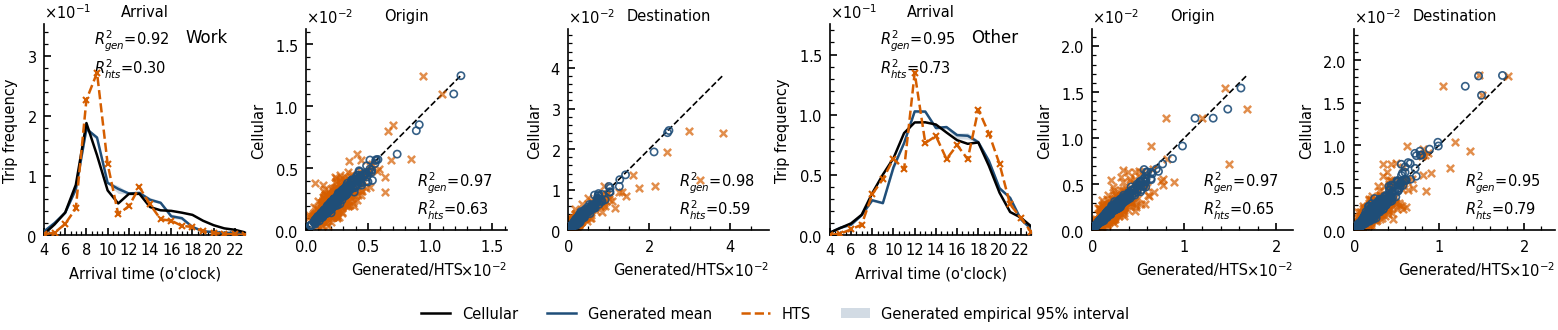

In [ ]:
# seoul_work_other_plots_nature_low_ram.py
# ------------------------------------------------------------
# Multiple-seed version with low RAM usage.
#
# Only aggregated probability distributions are retained after
# each generated seed is processed.
# ------------------------------------------------------------

from __future__ import annotations

import gc
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.ticker import (
    ScalarFormatter,
    AutoMinorLocator,
    MultipleLocator,
)
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from sklearn.metrics import r2_score


# =============================================================================
# GLOBAL CONFIGURATION
# =============================================================================

TRIP_MAX = 7

REGION = "seoul"
KK = 6000
NB = 10

SEEDS = [
    12345,
    23456,
    34567,
    45678,
    56789,
]

WORK_PURPOSE = 1
OTHER_PURPOSE = 2
TIME_ATTRIBUTE = "TRIP_ENDTIME"


# =============================================================================
# NATURE-STYLE SETUP
# =============================================================================

def set_nature_style() -> None:
    plt.rcParams.update({
        "figure.dpi": 150,
        "savefig.dpi": 600,
        "font.family": "DejaVu Sans",
        "font.size": 7,
        "axes.labelsize": 7,
        "axes.titlesize": 7,
        "legend.fontsize": 7,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "axes.linewidth": 0.8,
        "lines.linewidth": 1.2,
        "patch.linewidth": 0.8,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.major.size": 3.5,
        "ytick.major.size": 3.5,
        "xtick.minor.size": 2,
        "ytick.minor.size": 2,
        "legend.frameon": False,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.02,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })


COLORS2 = {
    "true": "#000000",
    "hts": "#D55E00",
    "sim": "#0072B2",
    "diag": "#000000",
}

COLORS = {
    "true": "#000000",
    "hts": "#D55E00",
    "sim": "#1F4E79",
    "diag": "#000000",
}

AX_LABELS = {
    "TRIP_STARTTIME": "Departure time (o'clock)",
    "TRIP_ENDTIME": "Arrival time (o'clock)",
}


# =============================================================================
# PLOT HELPERS
# =============================================================================

def _format_axis_sci(
    ax: plt.Axes,
    which: str = "both",
) -> None:
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((0, 0))

    if which in ("x", "both"):
        ax.xaxis.set_major_formatter(formatter)

    if which in ("y", "both"):
        ax.yaxis.set_major_formatter(formatter)

    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())


def _beautify_axes(
    ax: plt.Axes,
    grid: bool = False,
) -> None:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)

    # Remove background grid
    ax.grid(False)

    if grid:
        ax.grid(
            axis="y",
            which="major",
            linewidth=0.3,
            color="#DDDDDD",
        )

    ax.tick_params(
        width=0.8,
        length=3.5,
    )

    ax.tick_params(
        which="minor",
        width=0.6,
        length=2,
    )


def _safe_r2(
    y_true,
    y_pred,
) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    valid = np.isfinite(y_true) & np.isfinite(y_pred)

    if valid.sum() < 2:
        return np.nan

    if np.var(y_true[valid]) <= 0:
        return np.nan

    return float(
        r2_score(
            y_true[valid],
            y_pred[valid],
        )
    )


# =============================================================================
# DATA PREPARATION
# =============================================================================

AGE_RECODE = {
    0: 0,
    1: 1,
    2: 2,
    3: 3,
}

PURPOSE_RECODE_HTS_FUS = {
    0: 0,
    1: 1,
    2: 2,
    3: 2,
    4: 2,
    5: 2,
}

PURPOSE_RECODE_PCM = {
    "H": 0,
    "W": 1,
    "E": 2,
}


def _recode_age(
    df: pd.DataFrame,
    age_col: str = "AGE",
) -> pd.DataFrame:
    # Preserve original logic.
    return df


def prepare_hts(
    df_hts: pd.DataFrame,
) -> pd.DataFrame:
    df = _recode_age(
        df_hts.copy()
    )

    df["COUNT"] = 1

    df["TRIP_PURPOSE"] = (
        df["TRIP_PURPOSE"]
        .replace(PURPOSE_RECODE_HTS_FUS)
    )

    return df


def prepare_pcm(
    df_pcm: pd.DataFrame,
) -> pd.DataFrame:
    df = _recode_age(
        df_pcm.copy()
    )

    if "COUNT" not in df.columns:
        df["COUNT"] = 1

    df["TRIP_PURPOSE"] = (
        df["TRIP_PURPOSE"]
        .replace(PURPOSE_RECODE_PCM)
    )

    return df


def prepare_fus_bk(
    df: pd.DataFrame,
) -> pd.DataFrame:
    df = _recode_age(
        df.copy()
    )

    df["COUNT"] = df["Prob_XYZ_fus"]

    df["TRIP_PURPOSE"] = (
        df["TRIP_PURPOSE"]
        .replace(PURPOSE_RECODE_HTS_FUS)
    )

    return df


# =============================================================================
# PROBABILITY COMPUTATION
# =============================================================================

def prob_att_purpose(
    df: pd.DataFrame,
    att: list[str],
    purpose_val: int,
    suffix: str,
) -> pd.DataFrame:
    """
    Calculate normalized frequency distribution for one purpose.
    """
    required_columns = [
        *att,
        "TRIP_PURPOSE",
        "COUNT",
    ]

    missing = [
        column
        for column in required_columns
        if column not in df.columns
    ]

    if missing:
        raise KeyError(
            f"Missing columns: {missing}"
        )

    data = df.loc[
        df["TRIP_PURPOSE"].eq(purpose_val),
        [*att, "COUNT"],
    ].copy()

    if data.empty:
        return pd.DataFrame(
            columns=[
                *att,
                f"Pop_{suffix}",
            ]
        )

    data["COUNT"] = pd.to_numeric(
        data["COUNT"],
        errors="coerce",
    )

    data.dropna(
        subset=["COUNT"],
        inplace=True,
    )

    data = (
        data.groupby(
            att,
            observed=True,
        )["COUNT"]
        .sum()
        .reset_index()
    )

    denominator = float(
        data["COUNT"].sum()
    )

    if denominator > 0:
        data[f"Pop_{suffix}"] = (
            data["COUNT"] / denominator
        )
    else:
        data[f"Pop_{suffix}"] = 0.0

    return data.drop(
        columns=["COUNT"]
    ).sort_values(att)


# =============================================================================
# LOW-RAM MULTIPLE-SEED PROCESSING
# =============================================================================

def process_one_seed(
    seed_path: str,
    seed: int,
    purposes: list[int],
    time_attribute: str,
    location_attributes: list[str],
) -> dict[tuple[int, str], pd.DataFrame]:
    """
    Load one generated seed, calculate only required summaries,
    and return small aggregated tables.

    The raw generated dataframe is deleted before returning.
    """
    print(f"Processing seed {seed}")

    df_fus = pd.read_csv(seed_path)

    if "Prob_XYZ_fus" not in df_fus.columns:
        raise KeyError(
            f"Prob_XYZ_fus is missing from {seed_path}"
        )

    df_fus["COUNT"] = df_fus["Prob_XYZ_fus"]

    df_fus["TRIP_PURPOSE"] = (
        df_fus["TRIP_PURPOSE"]
        .replace(PURPOSE_RECODE_HTS_FUS)
    )

    summaries = {}

    for purpose in purposes:
        summaries[(purpose, time_attribute)] = (
            prob_att_purpose(
                df_fus,
                [time_attribute],
                purpose,
                "fus",
            )
        )

        for location_attribute in location_attributes:
            summaries[(purpose, location_attribute)] = (
                prob_att_purpose(
                    df_fus,
                    [location_attribute],
                    purpose,
                    "fus",
                )
            )

    # Release the large raw generated dataframe immediately.
    del df_fus
    gc.collect()

    print(f"Finished seed {seed}")

    return summaries


def combine_seed_summaries(
    seed_summaries: list[dict[tuple[int, str], pd.DataFrame]],
    purposes: list[int],
    attributes: list[str],
) -> dict[tuple[int, str], pd.DataFrame]:
    """
    Combine small per-seed tables and calculate:
    - mean across seeds;
    - empirical 2.5th percentile;
    - empirical 97.5th percentile.
    """
    combined_results = {}

    for purpose in purposes:
        for attribute in attributes:
            tables = []

            for seed_number, summary in enumerate(
                seed_summaries
            ):
                key = (purpose, attribute)

                if key not in summary:
                    continue

                table = summary[key].copy()
                table["SEED"] = seed_number
                tables.append(table)

            if not tables:
                combined_results[(purpose, attribute)] = (
                    pd.DataFrame()
                )
                continue

            combined = pd.concat(
                tables,
                ignore_index=True,
            )

            value_column = "Pop_fus"

            keys = (
                combined[[attribute]]
                .drop_duplicates()
                .sort_values(attribute)
            )

            complete_tables = []

            for seed_number in sorted(
                combined["SEED"].unique()
            ):
                seed_table = combined[
                    combined["SEED"].eq(seed_number)
                ][
                    [attribute, value_column]
                ]

                seed_table = (
                    keys.merge(
                        seed_table,
                        on=attribute,
                        how="left",
                    )
                    .fillna({
                        value_column: 0.0,
                    })
                )

                seed_table["SEED"] = seed_number
                complete_tables.append(seed_table)

            complete = pd.concat(
                complete_tables,
                ignore_index=True,
            )

            result = (
                complete
                .groupby(
                    attribute,
                    observed=True,
                )[value_column]
                .agg(
                    Pop_fus_mean="mean",
                    Pop_fus_lower=lambda values: np.percentile(
                        values,
                        2.5,
                    ),
                    Pop_fus_upper=lambda values: np.percentile(
                        values,
                        97.5,
                    ),
                )
                .reset_index()
            )

            combined_results[(purpose, attribute)] = result

    return combined_results


# =============================================================================
# PLOT FUNCTIONS
# =============================================================================

def plot_line_ax(
    ax: plt.Axes,
    df: pd.DataFrame,
    att: str,
) -> None:
    """
    Plot generated mean and empirical 95% interval,
    together with True and HTS distributions.
    """
    data = df.copy()

    data[att] = pd.to_numeric(
        data[att],
        errors="coerce",
    )

    data.sort_values(
        att,
        inplace=True,
    )

    x = data[att].to_numpy(float)

    generated_mean = data["Pop_fus_mean"].to_numpy(float)
    generated_lower = data["Pop_fus_lower"].to_numpy(float)
    generated_upper = data["Pop_fus_upper"].to_numpy(float)

    true_values = data["Pop_sc"].to_numpy(float)
    hts_values = data["Pop_hts"].to_numpy(float)

    ax.fill_between(
        x,
        generated_lower,
        generated_upper,
        color=COLORS["sim"],
        alpha=0.20,
        linewidth=0,
        zorder=1,
    )

    ax.plot(
        x,
        generated_mean,
        color=COLORS["sim"],
        linestyle="-",
        linewidth=1.2,
        label="Generated mean",
        zorder=3,
    )

    ax.plot(
        x,
        true_values,
        color=COLORS["true"],
        linestyle="-",
        linewidth=1.2,
        label="True",
        zorder=4,
    )

    ax.plot(
        x,
        hts_values,
        color=COLORS["hts"],
        linestyle="--",
        marker="x",
        markersize=2.5,
        linewidth=1.2,
        label="HTS",
        zorder=5,
    )

    ax.set_xlabel(
        AX_LABELS.get(
            att,
            att,
        )
    )

    ax.set_ylabel("Trip frequency")

    if att in {
        "TRIP_STARTTIME",
        "TRIP_ENDTIME",
    }:
        ax.set_xlim(4, 23)
        ax.set_xticks(
            np.arange(4, 24, 2)
        )
        ax.xaxis.set_minor_locator(
            MultipleLocator(1)
        )

    _format_axis_sci(
        ax,
        which="y",
    )

    _beautify_axes(
        ax,
        grid=False,
    )

    maximum = np.nanmax([
        generated_upper.max(),
        true_values.max(),
        hts_values.max(),
    ])

    ax.set_ylim(
        0,
        1.3 * maximum if maximum > 0 else 1.0,
    )

    r2_generated = _safe_r2(
        true_values,
        generated_mean,
    )

    r2_hts = _safe_r2(
        true_values,
        hts_values,
    )

    annotation = []

    if not np.isnan(r2_generated):
        annotation.append(
            f"$R^2_{{gen}}$={r2_generated:.2f}"
        )

    if not np.isnan(r2_hts):
        annotation.append(
            f"$R^2_{{hts}}$={r2_hts:.2f}"
        )

    if annotation:
        ax.text(
            0.25,
            0.98,
            "\n".join(annotation),
            transform=ax.transAxes,
            fontsize=7,
            va="top",
            ha="left",
        )


def plot_point_ax(
    ax: plt.Axes,
    df: pd.DataFrame,
) -> None:
    """
    Plot generated mean versus True and HTS versus True.
    """
    df_hts_vis = df[
        (df["Pop_sc"] > 0)
        & (df["Pop_hts"] > 0)
    ].copy()

    df_fus_vis = df[
        (df["Pop_sc"] > 0)
        & (df["Pop_fus_mean"] > 0)
    ].copy()

    maximum = 0.0

    if not df_hts_vis.empty:
        maximum = max(
            maximum,
            float(
                df_hts_vis[
                    ["Pop_sc", "Pop_hts"]
                ]
                .to_numpy()
                .max()
            ),
        )

    if not df_fus_vis.empty:
        maximum = max(
            maximum,
            float(
                df_fus_vis[
                    ["Pop_sc", "Pop_fus_mean"]
                ]
                .to_numpy()
                .max()
            ),
        )

    if maximum <= 0:
        maximum = 1.0

    ax.plot(
        [0, maximum],
        [0, maximum],
        linestyle="--",
        color=COLORS["diag"],
        linewidth=0.8,
        zorder=1,
    )

    if not df_hts_vis.empty:
        ax.scatter(
            df_hts_vis["Pop_hts"],
            df_hts_vis["Pop_sc"],
            s=12,
            marker="x",
            color=COLORS["hts"],
            alpha=0.7,
            zorder=2,
        )

    if not df_fus_vis.empty:
        ax.scatter(
            df_fus_vis["Pop_fus_mean"],
            df_fus_vis["Pop_sc"],
            s=12,
            facecolor="none",
            edgecolor=COLORS["sim"],
            linewidth=0.8,
            alpha=0.9,
            zorder=3,
        )

    ax.set_xlim(
        0,
        1.3 * maximum,
    )

    ax.set_ylim(
        0,
        1.3 * maximum,
    )

    ax.set_aspect(
        "equal",
        adjustable="box",
    )

    ax.set_xlabel("Generated/HTS")
    ax.set_ylabel("Cellular")

    _format_axis_sci(ax)
    _beautify_axes(
        ax,
        grid=False,
    )

    r2_generated = (
        _safe_r2(
            df_fus_vis["Pop_sc"],
            df_fus_vis["Pop_fus_mean"],
        )
        if not df_fus_vis.empty
        else np.nan
    )

    r2_hts = (
        _safe_r2(
            df_hts_vis["Pop_sc"],
            df_hts_vis["Pop_hts"],
        )
        if not df_hts_vis.empty
        else np.nan
    )

    annotation = []

    if not np.isnan(r2_generated):
        annotation.append(
            f"$R^2_{{gen}}$={r2_generated:.2f}"
        )

    if not np.isnan(r2_hts):
        annotation.append(
            f"$R^2_{{hts}}$={r2_hts:.2f}"
        )

    if annotation:
        ax.text(
            0.55,
            0.30,
            "\n".join(annotation),
            transform=ax.transAxes,
            fontsize=7,
            va="top",
            ha="left",
        )


# =============================================================================
# FIGURE COMPOSITION
# =============================================================================

def compose_work_other_1x6(
    df_pcm: pd.DataFrame,
    df_hts: pd.DataFrame,
    generated_summary: dict[tuple[int, str], pd.DataFrame],
    *,
    work_val: int = 1,
    other_val: int = 2,
    time_att: str = "TRIP_ENDTIME",
    figsize: tuple[float, float] = (14.0, 2.2),
    save_path: str | None = None,
) -> plt.Figure:
    fig, axes = plt.subplots(
        1,
        6,
        figsize=figsize,
    )

    axes = np.atleast_1d(axes)

    def assemble_time(
        purpose_value: int,
    ) -> pd.DataFrame:
        true_data = prob_att_purpose(
            df_pcm,
            [time_att],
            purpose_value,
            "sc",
        )

        hts_data = prob_att_purpose(
            df_hts,
            [time_att],
            purpose_value,
            "hts",
        )

        generated_data = generated_summary[
            (purpose_value, time_att)
        ].copy()

        return (
            true_data
            .merge(
                generated_data,
                on=time_att,
                how="outer",
            )
            .merge(
                hts_data,
                on=time_att,
                how="outer",
            )
            .fillna(0)
            .sort_values(time_att)
        )

    def assemble_scatter(
        purpose_value: int,
        location_attribute: str,
    ) -> pd.DataFrame:
        true_data = prob_att_purpose(
            df_pcm,
            [location_attribute],
            purpose_value,
            "sc",
        )

        hts_data = prob_att_purpose(
            df_hts,
            [location_attribute],
            purpose_value,
            "hts",
        )

        generated_data = generated_summary[
            (purpose_value, location_attribute)
        ].copy()

        generated_data.rename(
            columns={
                "Pop_fus_mean": "Pop_fus_mean",
            },
            inplace=True,
        )

        return (
            true_data
            .merge(
                generated_data,
                on=location_attribute,
                how="inner",
            )
            .merge(
                hts_data,
                on=location_attribute,
                how="inner",
            )
        )

    # Work
    plot_line_ax(
        axes[0],
        assemble_time(work_val),
        time_att,
    )

    plot_point_ax(
        axes[1],
        assemble_scatter(
            work_val,
            "ORIGIN_SUBZONE",
        ),
    )

    plot_point_ax(
        axes[2],
        assemble_scatter(
            work_val,
            "DESTINATION_SUBZONE",
        ),
    )

    # Other
    plot_line_ax(
        axes[3],
        assemble_time(other_val),
        time_att,
    )

    plot_point_ax(
        axes[4],
        assemble_scatter(
            other_val,
            "ORIGIN_SUBZONE",
        ),
    )

    plot_point_ax(
        axes[5],
        assemble_scatter(
            other_val,
            "DESTINATION_SUBZONE",
        ),
    )

    axes[0].text(
        0.70,
        0.98,
        "Work",
        transform=axes[0].transAxes,
        va="top",
        ha="left",
        fontsize=8,
    )

    axes[3].text(
        0.70,
        0.98,
        "Other",
        transform=axes[3].transAxes,
        va="top",
        ha="left",
        fontsize=8,
    )

    panel_titles = [
        "Arrival",
        "Origin",
        "Destination",
        "Arrival",
        "Origin",
        "Destination",
    ]

    for ax, title in zip(
        axes,
        panel_titles,
    ):
        ax.set_title(
            title,
            fontsize=7,
            pad=4,
        )

    plt.subplots_adjust(
        wspace=0.30,
        hspace=0.0,
        bottom=0.24,
    )

    legend_handles = [
        Line2D(
            [0],
            [0],
            color=COLORS["true"],
            lw=1.2,
            label="Cellular",
        ),
        Line2D(
            [0],
            [0],
            color=COLORS["sim"],
            lw=1.2,
            label="Generated mean",
        ),
        Line2D(
            [0],
            [0],
            color=COLORS["hts"],
            lw=1.2,
            ls="--",
            label="HTS",
        ),
        Patch(
            facecolor=COLORS["sim"],
            edgecolor="none",
            alpha=0.20,
            label="Generated empirical 95% interval",
        ),
    ]

    fig.legend(
        handles=legend_handles,
        loc="lower center",
        bbox_to_anchor=(0.50, -0.06),
        ncol=4,
        frameon=False,
    )

    if save_path:
        fig.savefig(
            save_path + ".pdf",
            dpi=600,
            bbox_inches="tight",
        )

        fig.savefig(
            save_path + ".png",
            dpi=600,
            bbox_inches="tight",
        )

        print(f"Saved: {save_path}.pdf")
        print(f"Saved: {save_path}.png")

    return fig


# =============================================================================
# MAIN
# =============================================================================

if __name__ == "__main__":
    set_nature_style()

    os.makedirs(
        path_figure,
        exist_ok=True,
    )

    # -------------------------------------------------------------------------
    # Load reference data
    # -------------------------------------------------------------------------

    hts_path = os.path.join(
        path_data,
        f"data_{REGION}_hts_trip.csv",
    )

    pcm_path = os.path.join(
        path_data,
        f"data_{REGION}_pcm_trip.csv",
    )

    df_hts_raw = pd.read_csv(
        hts_path
    )

    df_pcm_raw = pd.read_csv(
        pcm_path
    )

    # Preserve original AGE recoding
    age_mapping = {
        0: 0,
        1: 0,
        2: 1,
        3: 1,
        4: 2,
        5: 2,
        6: 3,
        7: 3,
    }

    if "AGE" in df_hts_raw.columns:
        df_hts_raw["AGE"] = (
            df_hts_raw["AGE"]
            .replace(age_mapping)
        )

    if "AGE" in df_pcm_raw.columns:
        df_pcm_raw["AGE"] = (
            df_pcm_raw["AGE"]
            .replace(age_mapping)
        )

    if (
        "TRIP_PURPOSE_" in df_pcm_raw.columns
        and "TRIP_PURPOSE" not in df_pcm_raw.columns
    ):
        df_pcm_raw.rename(
            columns={
                "TRIP_PURPOSE_": "TRIP_PURPOSE",
            },
            inplace=True,
        )

    df_hts = prepare_hts(
        df_hts_raw
    )

    df_pcm = prepare_pcm(
        df_pcm_raw
    )

    # Release raw reference data
    del df_hts_raw
    del df_pcm_raw
    gc.collect()

    # -------------------------------------------------------------------------
    # Process generated seeds sequentially
    # -------------------------------------------------------------------------

    purposes = [
        WORK_PURPOSE,
        OTHER_PURPOSE,
    ]

    location_attributes = [
        "ORIGIN_SUBZONE",
        "DESTINATION_SUBZONE",
    ]

    seed_summaries = []

    for seed in SEEDS:
        seed_path = os.path.join(
            path_result,
            f"case_{REGION}_sim_trip_M_{KK}_nb_{NB}_seed_{seed}.csv",
        )

        if not os.path.exists(seed_path):
            raise FileNotFoundError(
                f"Generated file not found for seed {seed}: "
                f"{seed_path}"
            )

        one_seed_summary = process_one_seed(
            seed_path=seed_path,
            seed=seed,
            purposes=purposes,
            time_attribute=TIME_ATTRIBUTE,
            location_attributes=location_attributes,
        )

        seed_summaries.append(
            one_seed_summary
        )

        # The raw seed data are already deleted inside process_one_seed.
        gc.collect()

    # Only small probability tables remain at this point.
    generated_summary = combine_seed_summaries(
        seed_summaries=seed_summaries,
        purposes=purposes,
        attributes=[
            TIME_ATTRIBUTE,
            *location_attributes,
        ],
    )

    del seed_summaries
    gc.collect()

    # -------------------------------------------------------------------------
    # Create Figure A
    # -------------------------------------------------------------------------

    save_path = os.path.join(
        path_figure,
        f"case_{REGION}_1x6_work_other_empirical_95_interval",
    )

    fig_A = compose_work_other_1x6(
        df_pcm=df_pcm,
        df_hts=df_hts,
        generated_summary=generated_summary,
        work_val=WORK_PURPOSE,
        other_val=OTHER_PURPOSE,
        time_att=TIME_ATTRIBUTE,
        figsize=(13.0, 2.2),
        save_path=save_path,
    )

    plt.show()
    plt.close(fig_A)

    # Release final objects
    del generated_summary
    del df_hts
    del df_pcm
    gc.collect()

## Seoul purpose map

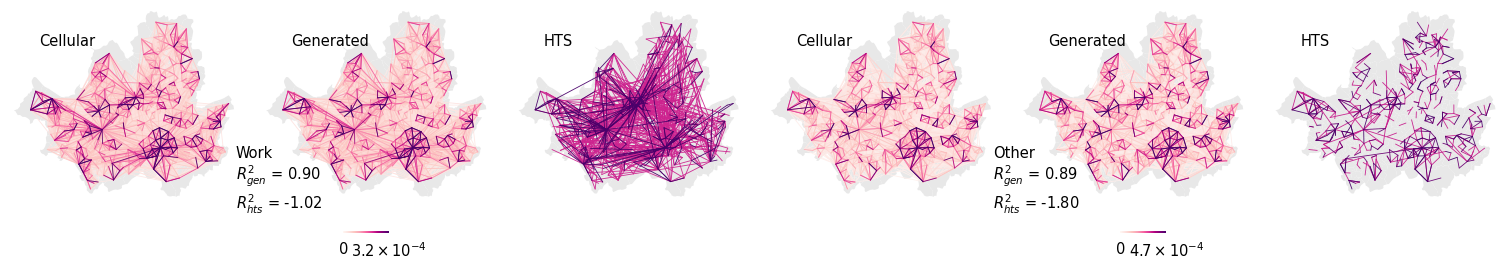

In [ ]:
# seoul_work_other_maps_triples.py
# Figure B only (1×6 interzone maps)
# - Colormap: viridis (CMAP_NAME)
# - Row-wise normalization shared within each TRIPLE: Work (0,1,2), Other (3,4,5)
# - Declutter: keep >= 95th percentile flows (optionally top-N)
# - Linewidth: constant (LW_MIN * 2)
# - Shared horizontal colorbar PER TRIPLE (axes [0,1,2] and [3,4,5])
# - Panel titles: "Cellular" / "Generated" / "HTS"
# - R² annotation: shown on the Generated panel (per triple)
#
# You must define: path_data, path_result, path_figure in your runtime environment.

from __future__ import annotations

import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.collections import LineCollection
from shapely.geometry import LineString
from sklearn.metrics import r2_score


# -----------------------------
# Nature-style setup (same)
# -----------------------------
def set_nature_style() -> None:
    plt.rcParams.update({
        "figure.dpi": 150, "savefig.dpi": 150,
        "font.family": "DejaVu Sans", "font.size": 7,
        "axes.labelsize": 7, "axes.titlesize": 7,
        "legend.fontsize": 7, "xtick.labelsize": 7, "ytick.labelsize": 7,
        "axes.linewidth": 0.8, "lines.linewidth": 1.0, "patch.linewidth": 0.8,
        "xtick.direction": "in", "ytick.direction": "in",
        "xtick.major.size": 3.5, "ytick.major.size": 3.5,
        "xtick.minor.size": 2, "ytick.minor.size": 2,
        "legend.frameon": False,
        "savefig.bbox": "tight", "savefig.pad_inches": 0.02,
        "pdf.fonttype": 42, "ps.fonttype": 42,
    })


# -----------------------------
# Style knobs (MATCH reference)
# -----------------------------
CMAP_NAME = "RdPu"
ROW_PERCENTILE = 0.98
FLOW_KEEP_Q = 0.95
FLOW_TOP_N = None
LW_MIN, LW_MAX = 0.2, 2.4  # LW_MAX unused because widths are constant


# -----------------------------
# Recodes (same logic as before)
# -----------------------------
TRIP_MAX = 7
AGE_RECODE = {0: 0, 1: 1, 2: 2, 3: 3}
PURPOSE_RECODE_HTS_FUS = {0: 0, 1: 1, 2: 2, 3: 2, 4: 2, 5: 2}  # Work=1, Other=2
PURPOSE_RECODE_PCM = {"H": 0, "W": 1, "E": 2}  # assumes E corresponds to Other


def _recode_age(df: pd.DataFrame, age_col: str = "AGE") -> pd.DataFrame:
    return df


def reshape_trip(df: pd.DataFrame) -> pd.DataFrame:
    parts = []
    for i in range(1, TRIP_MAX + 1):
        cols_i = [
            f"TRIP_PURPOSE_{i}", f"TRAVEL_MODE_{i}",
            f"TRIP_STARTTIME_{i}", f"TRIP_ENDTIME_{i}",
            f"ORIGIN_SUBZONE_{i}", f"DESTINATION_SUBZONE_{i}",
        ]
        dff = df[["AGE", "GENDER", "TRIP_MAX"] + cols_i].copy()
        dff = dff.rename(columns={
            f"TRIP_PURPOSE_{i}": "TRIP_PURPOSE",
            f"TRAVEL_MODE_{i}": "TRAVEL_MODE",
            f"TRIP_STARTTIME_{i}": "TRIP_STARTTIME",
            f"TRIP_ENDTIME_{i}": "TRIP_ENDTIME",
            f"ORIGIN_SUBZONE_{i}": "ORIGIN_SUBZONE",
            f"DESTINATION_SUBZONE_{i}": "DESTINATION_SUBZONE",
        })
        parts.append(dff)

    out = pd.concat(parts, ignore_index=True).dropna()
    return out


def prepare_pcm(df_pcm_raw: pd.DataFrame) -> pd.DataFrame:
    df = _recode_age(df_pcm_raw)
    if "COUNT" not in df.columns:
        df["COUNT"] = 1
    df["TRIP_PURPOSE"] = df["TRIP_PURPOSE"].replace(PURPOSE_RECODE_PCM)
    return df


def prepare_fus_like(df_tour_raw: pd.DataFrame) -> pd.DataFrame:
    df = reshape_trip(df_tour_raw)
    df = _recode_age(df)
    df["COUNT"] = 1
    df["TRIP_PURPOSE"] = df["TRIP_PURPOSE"].replace(PURPOSE_RECODE_HTS_FUS)
    return df


# -----------------------------
# Geometry helpers
# -----------------------------
def _load_subzone(path_shp: str) -> gpd.GeoDataFrame:
    g = gpd.read_file(path_shp)[["SUBZONE_C", "geometry"]].copy()
    if g.crs is None:
        g.set_crs(epsg=4326, inplace=True)
    return g


def _centroids(gdf_sub: gpd.GeoDataFrame) -> pd.DataFrame:
    c = gdf_sub.copy()
    c["centroid"] = c.geometry.centroid
    return c[["SUBZONE_C", "centroid"]]


# -----------------------------
# OD aggregation + shares
# -----------------------------
def _od_group(df: pd.DataFrame) -> pd.DataFrame:
    cols = ["ORIGIN_SUBZONE", "DESTINATION_SUBZONE", "TRIP_STARTTIME", "TRIP_PURPOSE", "COUNT"]
    t = df[cols].copy()
    t["COUNT"] = t.groupby(cols[:-1], observed=True)["COUNT"].transform("sum")
    return t.drop_duplicates()


def _interzone_share(od_df: pd.DataFrame) -> pd.DataFrame:
    if od_df.empty:
        return pd.DataFrame(columns=["O", "D", "COUNT"])

    z = od_df[["ORIGIN_SUBZONE", "DESTINATION_SUBZONE", "COUNT"]].copy()
    z = z.rename(columns={"ORIGIN_SUBZONE": "O", "DESTINATION_SUBZONE": "D"})
    z = z.groupby(["O", "D"], observed=True, as_index=False)["COUNT"].sum()
    z = z[z["O"] != z["D"]]

    denom = float(z["COUNT"].sum())
    z["COUNT"] = 0.0 if denom <= 0 else (z["COUNT"] / denom)
    return z


def _declutter_flows(
    df: pd.DataFrame,
    keep_q: float = FLOW_KEEP_Q,
    top_n: int | None = FLOW_TOP_N,
) -> pd.DataFrame:
    if df.empty:
        return df

    out = df
    if keep_q is not None:
        thr = float(np.quantile(out["COUNT"], keep_q))
        out = out[out["COUNT"] >= thr]

    if top_n is not None and len(out) > top_n:
        out = out.nlargest(top_n, "COUNT")

    return out.copy()


def _build_lines(gdf_sub: gpd.GeoDataFrame, flows: pd.DataFrame) -> gpd.GeoDataFrame:
    if flows.empty:
        return gpd.GeoDataFrame({"COUNT": []}, geometry=[], crs=gdf_sub.crs)

    c = _centroids(gdf_sub)
    cO = c.rename(columns={"SUBZONE_C": "O", "centroid": "O_pt"})
    cD = c.rename(columns={"SUBZONE_C": "D", "centroid": "D_pt"})

    j = flows.merge(cO, on="O", how="left").merge(cD, on="D", how="left")
    j = j.dropna(subset=["O_pt", "D_pt"])

    geom = [LineString([o, d]) for o, d in zip(j["O_pt"], j["D_pt"])]
    return gpd.GeoDataFrame(j[["O", "D", "COUNT"]].copy(), geometry=geom, crs=gdf_sub.crs)


# -----------------------------
# Color/width scaling (TRIPLE norm)
# -----------------------------
def _row_norm_for_lines_triple(
    gA: gpd.GeoDataFrame,
    gB: gpd.GeoDataFrame,
    gC: gpd.GeoDataFrame,
    q: float = ROW_PERCENTILE,
) -> mpl.colors.Normalize:
    vals = np.r_[
        gA["COUNT"].to_numpy() if (gA is not None and not gA.empty and "COUNT" in gA) else np.array([]),
        gB["COUNT"].to_numpy() if (gB is not None and not gB.empty and "COUNT" in gB) else np.array([]),
        gC["COUNT"].to_numpy() if (gC is not None and not gC.empty and "COUNT" in gC) else np.array([]),
    ]
    if vals.size == 0 or np.all(vals == 0):
        vmax = 1.0
    else:
        vmax = float(np.quantile(vals, q))
        if vmax <= 0:
            vmax = float(vals.max() if vals.max() > 0 else 1.0)
    return mpl.colors.Normalize(vmin=0.0, vmax=vmax)


def _line_widths(counts: np.ndarray, norm: mpl.colors.Normalize, lw_min: float = LW_MIN, lw_max: float = LW_MAX) -> np.ndarray:
    # Reference behavior: constant width
    return lw_min * 2


# -----------------------------
# Plot helpers
# -----------------------------
def _plot_background(ax: plt.Axes, gdf_sub: gpd.GeoDataFrame) -> None:
    gdf_sub.plot(ax=ax, facecolor="#e8e8e8", edgecolor="none", linewidth=0.0)
    ax.set_axis_off()


def _plot_lines(ax: plt.Axes, gdf_lines: gpd.GeoDataFrame, cmap: str, norm: mpl.colors.Normalize) -> None:
    if gdf_lines.empty:
        return

    gdf_lines = gdf_lines.sort_values("COUNT", ascending=True).reset_index(drop=True)

    cmap_obj = cm.get_cmap(cmap)
    values = gdf_lines["COUNT"].to_numpy()
    colors = cmap_obj(norm(values))
    widths = _line_widths(values, norm)

    lines = [np.array(line.coords) for line in gdf_lines.geometry if line is not None]
    lc = LineCollection(
        lines,
        colors=colors,
        linewidths=widths,
        alpha=0.95,
        joinstyle="round",
        capstyle="round",
    )
    ax.add_collection(lc)


def _fmt_sci_mathtext(x: float, sig: int = 2) -> str:
    if x == 0:
        return r"$0$"
    exp = int(np.floor(np.log10(abs(x))))
    mant = x / (10 ** exp)
    mant_str = f"{mant:.{sig}g}"
    return rf"${mant_str}\times 10^{{{exp}}}$"


def _add_shared_cbar(fig: plt.Figure, axes_row, norm: mpl.colors.Normalize, cmap_name: str) -> mpl.colorbar.Colorbar:
    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cm.get_cmap(cmap_name))
    sm.set_array([])

    cbar = fig.colorbar(
        sm,
        ax=axes_row,
        orientation="horizontal",
        fraction=0.01,
        pad=0.02, #.02
    )
    cbar.outline.set_visible(False)

    vmin, vmax = float(norm.vmin), float(norm.vmax)
    cbar.set_ticks([vmin, vmax])
    cbar.ax.xaxis.get_offset_text().set_visible(False)
    cbar.set_ticklabels([_fmt_sci_mathtext(vmin, sig=2), _fmt_sci_mathtext(vmax, sig=2)])
    cbar.ax.tick_params(length=0, labelsize=7)
    return cbar


def _safe_r2(y_true, y_pred) -> float:
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    if y_true.size > 1 and np.var(y_true) > 0:
        return float(r2_score(y_true, y_pred))
    return float("nan")


# -----------------------------
# Public API: 1×6 maps (Work triple + Other triple)
# -----------------------------
def compose_1x6_maps_work_other_triples(
    df_pcm: pd.DataFrame,
    df_fus: pd.DataFrame,
    df_hts: pd.DataFrame,
    shp_path: str,
    *,
    work_val: int = 1,
    other_val: int = 2,
    figsize: tuple[float, float] = (19.0, 3.0),
    save_path: str | None = None,
) -> plt.Figure:
    fig, axes = plt.subplots(nrows=1, ncols=6, figsize=figsize)
    axes = np.asarray(axes)

    gdf_sub = _load_subzone(shp_path)

    sc = _od_group(df_pcm)
    fu = _od_group(df_fus)
    ht = _od_group(df_hts)

    def _triple(purpose_val: int):
        sc_p = sc[sc["TRIP_PURPOSE"] == purpose_val]
        fu_p = fu[fu["TRIP_PURPOSE"] == purpose_val]
        ht_p = ht[ht["TRIP_PURPOSE"] == purpose_val]

        sc_flow = _declutter_flows(_interzone_share(sc_p))
        fu_flow = _declutter_flows(_interzone_share(fu_p))
        ht_flow = _declutter_flows(_interzone_share(ht_p))

        # R² computed on common support with Cellular, for clean interpretation
        m_sc_fu = sc_flow.merge(fu_flow, on=["O", "D"], how="inner", suffixes=("_sc", "_fu"))
        r2_sc_fu = _safe_r2(m_sc_fu["COUNT_sc"], m_sc_fu["COUNT_fu"]) if len(m_sc_fu) else float("nan")

        m_sc_ht = sc_flow.merge(ht_flow, on=["O", "D"], how="inner", suffixes=("_sc", "_ht"))
        r2_sc_ht = _safe_r2(m_sc_ht["COUNT_sc"], m_sc_ht["COUNT_ht"]) if len(m_sc_ht) else float("nan")

        g_sc = _build_lines(gdf_sub, sc_flow)
        g_fu = _build_lines(gdf_sub, fu_flow)
        g_ht = _build_lines(gdf_sub, ht_flow)

        norm = _row_norm_for_lines_triple(g_sc, g_fu, g_ht, ROW_PERCENTILE)
        return g_sc, g_fu, g_ht, norm, r2_sc_fu, r2_sc_ht

    # ---------- Work triple (axes 0–2)
    gW_sc, gW_fu, gW_ht, normW, r2W_sc_fu, r2W_sc_ht = _triple(work_val)

    for ax, gL, title in zip(
        axes[0:3],
        [gW_sc, gW_fu, gW_ht],
        ["Cellular", "Generated", "HTS"],
    ):
        _plot_background(ax, gdf_sub)
        _plot_lines(ax, gL, CMAP_NAME, normW)
        ax.text(0.15, 0.85, title, transform=ax.transAxes, va="top", ha="left", fontsize=7)

    # annotate on the Generated panel (axes[1]) like your reference style
    if not (np.isnan(r2W_sc_fu) and np.isnan(r2W_sc_ht)):
        axes[1].text(
            -0.08, 0.3,
            "Work\n"
            + ("$R^2_{gen}$" + f" = {r2W_sc_fu:.2f}\n" if not np.isnan(r2W_sc_fu) else "")
            + ("$R^2_{hts}$" + f" = {r2W_sc_ht:.2f}" if not np.isnan(r2W_sc_ht) else ""),
            transform=axes[1].transAxes,
            fontsize=7,
            va="top",
            ha="left",
        )

    _add_shared_cbar(fig, [axes[0], axes[1], axes[2]], normW, CMAP_NAME)

    # ---------- Other triple (axes 3–5)
    gO_sc, gO_fu, gO_ht, normO, r2O_sc_fu, r2O_sc_ht = _triple(other_val)

    for ax, gL, title in zip(
        axes[3:6],
        [gO_sc, gO_fu, gO_ht],
        ["Cellular", "Generated", "HTS"],
    ):
        _plot_background(ax, gdf_sub)
        _plot_lines(ax, gL, CMAP_NAME, normO)
        ax.text(0.15, 0.85, title, transform=ax.transAxes, va="top", ha="left", fontsize=7)

    if not (np.isnan(r2O_sc_fu) and np.isnan(r2O_sc_ht)):
        axes[4].text(
            -0.08, 0.3,
            "Other\n"
            + ("$R^2_{gen}$" + f" = {r2O_sc_fu:.2f}\n" if not np.isnan(r2O_sc_fu) else "")
            + ("$R^2_{hts}$" + f" = {r2O_sc_ht:.2f}" if not np.isnan(r2O_sc_ht) else ""),
            transform=axes[4].transAxes,
            fontsize=7,
            va="top",
            ha="left",
        )

    _add_shared_cbar(fig, [axes[3], axes[4], axes[5]], normO, CMAP_NAME)

    # Layout: keep tight like reference
    #plt.subplots_adjust(wspace=0.03, hspace=0.0, bottom=0.06)
    plt.subplots_adjust(wspace=0.01, hspace=0.0, bottom=0.2)

    if save_path:
        fig.savefig(save_path + ".pdf", dpi=200)

    return fig


# -----------------------------
# MAIN
# -----------------------------
if __name__ == "__main__":
    set_nature_style()

    df_pcm_raw = pd.read_csv(os.path.join(path_data, "data_seoul_pcm_trip.csv"))
    df_pcm_raw = df_pcm_raw.rename(columns={"TRIP_PURPOSE_": "TRIP_PURPOSE"})

    #df_fus_tour_raw = pd.read_csv(os.path.join(path_result, "case_seoul_sim_tour_M_3000_income.csv"))

    # --- Your new input (same structure as df_fus_tour_raw)
    df_hts_tour = pd.read_csv(os.path.join(path_data, "data_seoul_hts_tour.csv"))

    df_pcm = prepare_pcm(df_pcm_raw)
    #df_fus = prepare_fus_like(df_fus_tour_raw)
    df_hts = prepare_fus_like(df_hts_tour)


    REGION = "seoul"
    KK = 6000
    NB = 10
    RANDOM_SEED = 12345

    df_fus = pd.read_csv(path_result + f"case_{REGION}_sim_trip_M_{KK}_nb_{NB}_seed_{RANDOM_SEED}.csv")
    df_fus["COUNT"] = df_fus["Prob_XYZ_fus"]
    df_fus["TRIP_PURPOSE"] = df_fus["TRIP_PURPOSE"].replace(PURPOSE_RECODE_HTS_FUS)

    fig = compose_1x6_maps_work_other_triples(
        df_pcm=df_pcm,
        df_fus=df_fus,
        df_hts=df_hts,
        shp_path=os.path.join(path_data, "data_seoul_subzone.shp"),
        work_val=1,
        other_val=2,
        figsize=(13.0, 2.0),
        save_path=os.path.join(path_figure, "case_seoul_1x6_maps_work_other_triples"),
    )

    plt.show()


## Singapore age scatters

Processing seed 12345: /content/drive/MyDrive/Colab Notebooks/Workspace/tour_generation/re1_result/case_sgp_sim_trip_M_6000_nb_10_seed_12345.csv
Finished seed 12345
Processing seed 23456: /content/drive/MyDrive/Colab Notebooks/Workspace/tour_generation/re1_result/case_sgp_sim_trip_M_6000_nb_10_seed_23456.csv
Finished seed 23456
Processing seed 34567: /content/drive/MyDrive/Colab Notebooks/Workspace/tour_generation/re1_result/case_sgp_sim_trip_M_6000_nb_10_seed_34567.csv
Finished seed 34567
Processing seed 45678: /content/drive/MyDrive/Colab Notebooks/Workspace/tour_generation/re1_result/case_sgp_sim_trip_M_6000_nb_10_seed_45678.csv
Finished seed 45678
Processing seed 56789: /content/drive/MyDrive/Colab Notebooks/Workspace/tour_generation/re1_result/case_sgp_sim_trip_M_6000_nb_10_seed_56789.csv
Finished seed 56789
Saved: /content/drive/MyDrive/Colab Notebooks/Workspace/tour_generation/re1_figure/case_sgp_grid_age_empirical_95_interval.pdf
Saved: /content/drive/MyDrive/Colab Notebooks/Wo

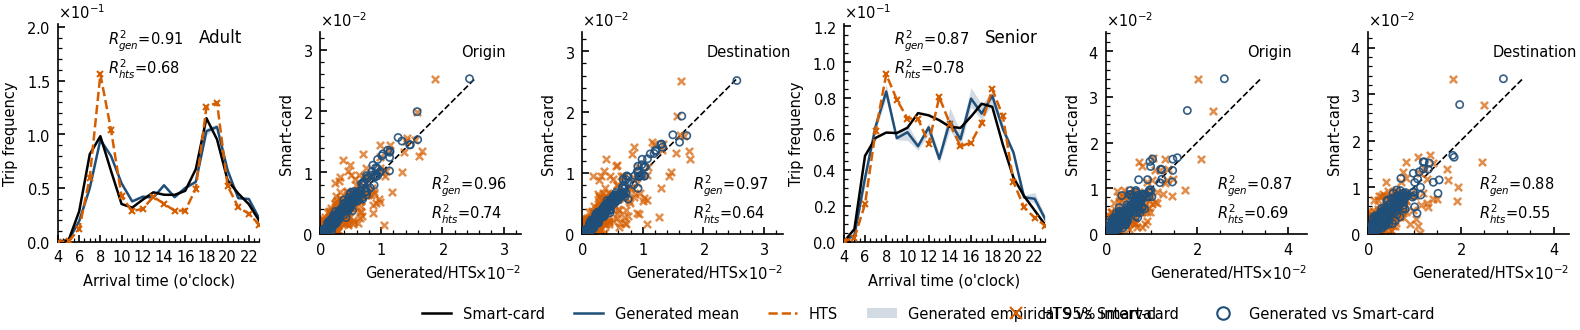

In [ ]:
# -*- coding: utf-8 -*-
"""
Singapore multiple-seed plot with low RAM usage.

Figure:
    Adult/Senior × {Arrival, Origin, Destination}

Output:
    1 × 6 grid

The generated files are processed one seed at a time.
Only probability summaries are retained after each seed.
"""

from __future__ import annotations

import gc
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.ticker import (
    ScalarFormatter,
    AutoMinorLocator,
    MultipleLocator,
)
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from sklearn.metrics import r2_score


# =============================================================================
# PATHS
# =============================================================================

# Define these variables in the runtime environment:
#
# path_data = "/content/drive/MyDrive/.../data/"
# path_result = "/content/drive/MyDrive/.../results/"
# path_figure = "/content/drive/MyDrive/.../figures/"


# =============================================================================
# GLOBAL CONFIGURATION
# =============================================================================

TRIP_MAX = 7
reg = "sgp"
KK = 6000
nb = 10

SEEDS = [
    12345,
    23456,
    34567,
    45678,
    56789,
]

CATEGORIES = (
    "ADULT",
    "SENIOR",
)

TIME_ATTRIBUTE = "TRIP_ENDTIME"


# =============================================================================
# NATURE-STYLE SETUP
# =============================================================================

def set_nature_style() -> None:
    plt.rcParams.update({
        "figure.dpi": 150,
        "savefig.dpi": 150,
        "font.family": "DejaVu Sans",
        "font.size": 7,
        "axes.labelsize": 7,
        "axes.titlesize": 7,
        "legend.fontsize": 7,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "axes.linewidth": 0.8,
        "lines.linewidth": 1.2,
        "patch.linewidth": 0.8,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.major.size": 3.5,
        "ytick.major.size": 3.5,
        "xtick.minor.size": 2,
        "ytick.minor.size": 2,
        "legend.frameon": False,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.02,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })


COLORSzz = {
    "true": "#000000",
    "sim": "#2E8B57",
    "hts": "#A0A0A0",
    "diag": "#000000",
}

COLORS = {
    "true": "#000000",
    "hts": "#D55E00",
    "sim": "#1F4E79",
    "diag": "#000000",
}

COLORS2 = {
    "true": "#440154",
    "sim": "#35B779",
    "hts": "#FDE725",
}

COLORS4 = {
    "true": "#000000",
    "sim": "#0072B2",
    "hts": "#E69F00",
}

COLORS222 = {
    "true": "#000000",
    "sim": "#1B9E77",
    "hts": "#7570B3",
    "diag": "#000000",
}

AX_LABELS = {
    "TRIP_STARTTIME": "Departure time (o'clock)",
    "TRIP_ENDTIME": "Arrival time (o'clock)",
    "DESTINATION_DURATION": "Duration (h)",
    "TRIP_DISTANCE": "Trip distance (km)",
}


# =============================================================================
# GENERAL HELPERS
# =============================================================================

def _format_axis_sci(
    ax: plt.Axes,
    which: str = "both",
) -> None:
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((0, 0))

    if which in ("x", "both"):
        ax.xaxis.set_major_formatter(formatter)

    if which in ("y", "both"):
        ax.yaxis.set_major_formatter(formatter)

    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())


def _beautify_axes(
    ax: plt.Axes,
    grid: bool = False,
) -> None:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)

    # Remove background grid
    ax.grid(False)

    if grid:
        ax.grid(
            axis="y",
            which="major",
            linewidth=0.3,
            color="#DDDDDD",
        )

    ax.tick_params(
        width=0.8,
        length=3.5,
    )

    ax.tick_params(
        which="minor",
        width=0.6,
        length=2,
    )


def _safe_r2(
    y_true,
    y_pred,
) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    valid = np.isfinite(y_true) & np.isfinite(y_pred)

    if valid.sum() < 2:
        return np.nan

    if np.var(y_true[valid]) <= 0:
        return np.nan

    return float(
        r2_score(
            y_true[valid],
            y_pred[valid],
        )
    )


def add_commuter_category(
    df: pd.DataFrame,
    name: str,
) -> pd.DataFrame:
    """
    Use COMMUTER_CATEGORY if it already exists.
    Otherwise derive it from AGE.
    """
    df = df.copy()

    if "COMMUTER_CATEGORY" in df.columns:
        df["COMMUTER_CATEGORY"] = (
            df["COMMUTER_CATEGORY"]
            .astype(str)
            .str.upper()
            .str.strip()
        )
        return df

    if "AGE" not in df.columns:
        raise KeyError(
            f"{name} contains neither AGE nor "
            f"COMMUTER_CATEGORY. Available columns are: "
            f"{list(df.columns)}"
        )

    age = pd.to_numeric(
        df["AGE"],
        errors="coerce",
    )

    df["COMMUTER_CATEGORY"] = age.replace({
        0: "ADULT",
        1: "ADULT",
        2: "ADULT",
        3: "SENIOR",
    })

    return df


def filter_travel_modes(
    df: pd.DataFrame,
    name: str,
) -> pd.DataFrame:
    """
    Apply the original mode filter when travel-mode information exists.

    Some generated files do not contain TRAVEL_MODE. In that case,
    the mode filter is skipped because it cannot be applied.
    """
    df = df.copy()

    if "TRAVEL_MODE" in df.columns:
        return df[
            df["TRAVEL_MODE"].isin([1, 2])
        ].copy()

    wide_mode_columns = [
        f"TRAVEL_MODE_{i}"
        for i in range(1, TRIP_MAX + 1)
        if f"TRAVEL_MODE_{i}" in df.columns
    ]

    if wide_mode_columns:
        mode_values = df[wide_mode_columns].apply(
            pd.to_numeric,
            errors="coerce",
        )

        keep = mode_values.isin([1, 2]).any(axis=1)

        return df.loc[keep].copy()

    print(
        f"Warning: {name} has no TRAVEL_MODE column. "
        "Travel-mode filtering was skipped."
    )

    return df


# =============================================================================
# DATA PREPARATION
# =============================================================================

def reshape_trip(
    df: pd.DataFrame,
    trip_max: int,
) -> pd.DataFrame:
    """Convert wide trip columns into long trip records."""
    parts = []

    for i in range(1, trip_max + 1):
        trip_columns = [
            f"TRIP_PURPOSE_{i}",
            f"TRAVEL_MODE_{i}",
            f"TRIP_STARTTIME_{i}",
            f"TRIP_ENDTIME_{i}",
            f"ORIGIN_SUBZONE_{i}",
            f"DESTINATION_SUBZONE_{i}",
        ]

        required_columns = [
            "AGE",
            "GENDER",
            "TRIP_MAX",
            "COMMUTER_CATEGORY",
            *trip_columns,
        ]

        missing = [
            column
            for column in required_columns
            if column not in df.columns
        ]

        if missing:
            raise KeyError(
                f"Missing columns for trip {i}: {missing}"
            )

        trip_df = df[required_columns].copy()

        trip_df.rename(columns={
            f"TRIP_PURPOSE_{i}": "TRIP_PURPOSE",
            f"TRAVEL_MODE_{i}": "TRAVEL_MODE",
            f"TRIP_STARTTIME_{i}": "TRIP_STARTTIME",
            f"TRIP_ENDTIME_{i}": "TRIP_ENDTIME",
            f"ORIGIN_SUBZONE_{i}": "ORIGIN_SUBZONE",
            f"DESTINATION_SUBZONE_{i}": "DESTINATION_SUBZONE",
        }, inplace=True)

        parts.append(trip_df)

    result = pd.concat(
        parts,
        ignore_index=True,
    )

    result.dropna(
        inplace=True,
    )

    return result


def prepare_reference_data(
    df: pd.DataFrame,
    name: str,
) -> pd.DataFrame:
    df = df.copy()

    if "COUNT" not in df.columns:
        df["COUNT"] = 1

    df = add_commuter_category(
        df,
        name,
    )

    df = filter_travel_modes(
        df,
        name,
    )

    df = df[
        df["COMMUTER_CATEGORY"]
        .isin(CATEGORIES)
    ].copy()

    return df


def prepare_generated_data(
    df: pd.DataFrame,
    seed: int,
) -> pd.DataFrame:
    df = df.copy()

    if "Prob_XYZ_fus" not in df.columns:
        raise KeyError(
            f"Prob_XYZ_fus is missing for seed {seed}."
        )

    df["COUNT"] = df["Prob_XYZ_fus"]

    df = add_commuter_category(
        df,
        f"Generated data, seed {seed}",
    )

    df = filter_travel_modes(
        df,
        f"Generated data, seed {seed}",
    )

    df = df[
        df["COMMUTER_CATEGORY"]
        .isin(CATEGORIES)
    ].copy()

    return df


# =============================================================================
# PROBABILITY COMPUTATION
# =============================================================================

def prob_att_age(
    df: pd.DataFrame,
    att: list[str],
    category: str,
    suffix: str,
) -> pd.DataFrame:
    required_columns = [
        "COMMUTER_CATEGORY",
        *att,
        "COUNT",
    ]

    missing = [
        column
        for column in required_columns
        if column not in df.columns
    ]

    if missing:
        raise KeyError(
            f"Missing columns for {suffix}: {missing}"
        )

    data = df.loc[
        df["COMMUTER_CATEGORY"].eq(category),
        [*att, "COUNT"],
    ].copy()

    if data.empty:
        return pd.DataFrame(
            columns=[
                *att,
                f"Pop_{suffix}",
            ]
        )

    data["COUNT"] = pd.to_numeric(
        data["COUNT"],
        errors="coerce",
    )

    data.dropna(
        subset=["COUNT"],
        inplace=True,
    )

    data = (
        data.groupby(
            att,
            observed=True,
        )["COUNT"]
        .sum()
        .reset_index()
    )

    denominator = float(
        data["COUNT"].sum()
    )

    data[f"Pop_{suffix}"] = (
        data["COUNT"] / denominator
        if denominator > 0
        else 0.0
    )

    return data.drop(
        columns=["COUNT"]
    ).sort_values(att)


# =============================================================================
# LOW-RAM MULTIPLE-SEED PROCESSING
# =============================================================================

def process_one_seed(
    seed_path: str,
    seed: int,
    categories: tuple[str, ...],
    attributes: list[str],
) -> dict[tuple[str, str], pd.DataFrame]:
    """
    Process one seed and retain only small probability tables.
    """
    print(
        f"Processing seed {seed}: {seed_path}"
    )

    df_fus = pd.read_csv(
        seed_path
    )

    df_fus = prepare_generated_data(
        df_fus,
        seed,
    )

    summary = {}

    for category in categories:
        for attribute in attributes:
            summary[
                (category, attribute)
            ] = prob_att_age(
                df_fus,
                [attribute],
                category,
                "fus",
            )

    # Delete the large generated dataframe immediately
    del df_fus
    gc.collect()

    print(
        f"Finished seed {seed}"
    )

    return summary


def combine_seed_summaries(
    seed_summaries: list[
        dict[tuple[str, str], pd.DataFrame]
    ],
    categories: tuple[str, ...],
    attributes: list[str],
) -> dict[tuple[str, str], pd.DataFrame]:
    """
    Calculate the mean and empirical 95% interval across seeds.
    """
    results = {}

    for category in categories:
        for attribute in attributes:
            seed_tables = []

            for seed_number, seed_summary in enumerate(
                seed_summaries
            ):
                data = seed_summary.get(
                    (category, attribute)
                )

                if data is None or data.empty:
                    continue

                data = data.copy()
                data["SEED"] = seed_number
                seed_tables.append(data)

            if not seed_tables:
                results[
                    (category, attribute)
                ] = pd.DataFrame()
                continue

            combined = pd.concat(
                seed_tables,
                ignore_index=True,
            )

            value_column = "Pop_fus"

            keys = (
                combined[[attribute]]
                .drop_duplicates()
                .sort_values(attribute)
            )

            complete_tables = []

            for seed_number in sorted(
                combined["SEED"].unique()
            ):
                seed_data = combined[
                    combined["SEED"].eq(seed_number)
                ][
                    [attribute, value_column]
                ]

                seed_data = (
                    keys
                    .merge(
                        seed_data,
                        on=attribute,
                        how="left",
                    )
                    .fillna({
                        value_column: 0.0,
                    })
                )

                seed_data["SEED"] = seed_number
                complete_tables.append(seed_data)

            complete = pd.concat(
                complete_tables,
                ignore_index=True,
            )

            result = (
                complete
                .groupby(
                    attribute,
                    observed=True,
                )[value_column]
                .agg(
                    Pop_fus_mean="mean",
                    Pop_fus_lower=lambda x: np.percentile(
                        x,
                        2.5,
                    ),
                    Pop_fus_upper=lambda x: np.percentile(
                        x,
                        97.5,
                    ),
                )
                .reset_index()
            )

            results[
                (category, attribute)
            ] = result

    return results


# =============================================================================
# PLOT FUNCTIONS
# =============================================================================

def plot_line_ax(
    ax: plt.Axes,
    df: pd.DataFrame,
    att: str,
) -> None:
    data = df.copy()

    data[att] = pd.to_numeric(
        data[att],
        errors="coerce",
    )

    data.sort_values(
        att,
        inplace=True,
    )

    x = data[att].to_numpy(float)

    generated_mean = data["Pop_fus_mean"].to_numpy(float)
    generated_lower = data["Pop_fus_lower"].to_numpy(float)
    generated_upper = data["Pop_fus_upper"].to_numpy(float)
    true_values = data["Pop_sc"].to_numpy(float)
    hts_values = data["Pop_hts"].to_numpy(float)

    # Empirical 95% interval
    ax.fill_between(
        x,
        generated_lower,
        generated_upper,
        color=COLORS["sim"],
        alpha=0.20,
        linewidth=0,
        zorder=1,
    )

    # Generated mean
    ax.plot(
        x,
        generated_mean,
        color=COLORS["sim"],
        linestyle="-",
        linewidth=1.2,
        label="Generated mean",
        zorder=3,
    )

    # Smart-card/true distribution
    ax.plot(
        x,
        true_values,
        color=COLORS["true"],
        linestyle="-",
        linewidth=1.2,
        label="Smart-card",
        zorder=4,
    )

    # HTS distribution
    ax.plot(
        x,
        hts_values,
        color=COLORS["hts"],
        linestyle="--",
        marker="x",
        markersize=2.5,
        linewidth=1.2,
        label="HTS",
        zorder=5,
    )

    ax.set_xlabel(
        AX_LABELS.get(
            att,
            att,
        )
    )

    ax.set_ylabel(
        "Trip frequency"
    )

    if att in {
        "TRIP_STARTTIME",
        "TRIP_ENDTIME",
    }:
        ax.set_xlim(4, 23)
        ax.set_xticks(
            np.arange(4, 24, 2)
        )
        ax.xaxis.set_minor_locator(
            MultipleLocator(1)
        )

    _format_axis_sci(
        ax,
        which="y",
    )

    _beautify_axes(
        ax,
        grid=False,
    )

    maximum = np.nanmax([
        generated_upper.max(),
        true_values.max(),
        hts_values.max(),
    ])

    ax.set_ylim(
        0,
        1.3 * maximum if maximum > 0 else 1.0,
    )

    r2_generated = _safe_r2(
        true_values,
        generated_mean,
    )

    r2_hts = _safe_r2(
        true_values,
        hts_values,
    )

    annotation = []

    if not np.isnan(r2_generated):
        annotation.append(
            f"$R^2_{{gen}}$={r2_generated:.2f}"
        )

    if not np.isnan(r2_hts):
        annotation.append(
            f"$R^2_{{hts}}$={r2_hts:.2f}"
        )

    if annotation:
        ax.text(
            0.25,
            0.98,
            "\n".join(annotation),
            transform=ax.transAxes,
            fontsize=7,
            va="top",
            ha="left",
        )


def plot_point_ax(
    ax: plt.Axes,
    df: pd.DataFrame,
) -> None:
    hts_data = df[
        (df["Pop_sc"] > 0)
        & (df["Pop_hts"] > 0)
    ].copy()

    generated_data = df[
        (df["Pop_sc"] > 0)
        & (df["Pop_fus_mean"] > 0)
    ].copy()

    maximum = 0.0

    if not hts_data.empty:
        maximum = max(
            maximum,
            float(
                hts_data[
                    ["Pop_sc", "Pop_hts"]
                ]
                .to_numpy()
                .max()
            ),
        )

    if not generated_data.empty:
        maximum = max(
            maximum,
            float(
                generated_data[
                    ["Pop_sc", "Pop_fus_mean"]
                ]
                .to_numpy()
                .max()
            ),
        )

    if maximum <= 0:
        maximum = 1.0

    ax.plot(
        [0, maximum],
        [0, maximum],
        linestyle="--",
        color=COLORS["true"],
        linewidth=0.8,
        zorder=1,
    )

    if not hts_data.empty:
        ax.scatter(
            hts_data["Pop_hts"],
            hts_data["Pop_sc"],
            s=12,
            marker="x",
            color=COLORS["hts"],
            alpha=0.7,
            zorder=2,
        )

    if not generated_data.empty:
        ax.scatter(
            generated_data["Pop_fus_mean"],
            generated_data["Pop_sc"],
            s=12,
            facecolor="none",
            edgecolor=COLORS["sim"],
            linewidth=0.8,
            alpha=0.9,
            zorder=3,
        )

    ax.set_xlim(
        0,
        1.3 * maximum,
    )

    ax.set_ylim(
        0,
        1.3 * maximum,
    )

    ax.set_aspect(
        "equal",
        adjustable="box",
    )

    ax.set_xlabel(
        "Generated/HTS"
    )

    ax.set_ylabel(
        "Smart-card"
    )

    _format_axis_sci(ax)
    _beautify_axes(
        ax,
        grid=False,
    )

    r2_generated = (
        _safe_r2(
            generated_data["Pop_sc"],
            generated_data["Pop_fus_mean"],
        )
        if not generated_data.empty
        else np.nan
    )

    r2_hts = (
        _safe_r2(
            hts_data["Pop_sc"],
            hts_data["Pop_hts"],
        )
        if not hts_data.empty
        else np.nan
    )

    annotation = []

    if not np.isnan(r2_generated):
        annotation.append(
            f"$R^2_{{gen}}$={r2_generated:.2f}"
        )

    if not np.isnan(r2_hts):
        annotation.append(
            f"$R^2_{{hts}}$={r2_hts:.2f}"
        )

    if annotation:
        ax.text(
            0.55,
            0.30,
            "\n".join(annotation),
            transform=ax.transAxes,
            fontsize=7,
            va="top",
            ha="left",
        )


# =============================================================================
# GRID COMPOSER
# =============================================================================

def compose_commuter_grid_from_prob(
    df_sc: pd.DataFrame,
    df_hts: pd.DataFrame,
    generated_summary: dict[
        tuple[str, str],
        pd.DataFrame,
    ],
    categories: tuple[str, str] = (
        "ADULT",
        "SENIOR",
    ),
    time_att: str = "TRIP_ENDTIME",
    figsize: tuple[float, float] = (13.0, 2.2),
    save_path: str | None = None,
) -> plt.Figure:
    fig, axes = plt.subplots(
        nrows=1,
        ncols=6,
        figsize=figsize,
    )

    axes = np.atleast_1d(axes)

    for row, category in enumerate(categories):
        base = row * 3

        # ---------------------------------------------------------
        # Arrival
        # ---------------------------------------------------------
        sc_time = prob_att_age(
            df_sc,
            [time_att],
            category,
            "sc",
        )

        hts_time = prob_att_age(
            df_hts,
            [time_att],
            category,
            "hts",
        )

        fus_time = generated_summary[
            (category, time_att)
        ].copy()

        arrival = (
            sc_time
            .merge(
                fus_time,
                on=time_att,
                how="outer",
            )
            .merge(
                hts_time,
                on=time_att,
                how="outer",
            )
            .fillna(0)
            .sort_values(time_att)
        )

        plot_line_ax(
            axes[base],
            arrival,
            time_att,
        )

        axes[base].text(
            0.70,
            0.98,
            category.title(),
            transform=axes[base].transAxes,
            va="top",
            ha="left",
            fontsize=8,
        )

        # ---------------------------------------------------------
        # Origin
        # ---------------------------------------------------------
        sc_origin = prob_att_age(
            df_sc,
            ["ORIGIN_SUBZONE"],
            category,
            "sc",
        )

        hts_origin = prob_att_age(
            df_hts,
            ["ORIGIN_SUBZONE"],
            category,
            "hts",
        )

        fus_origin = generated_summary[
            (category, "ORIGIN_SUBZONE")
        ].copy()

        origin = (
            sc_origin
            .merge(
                fus_origin,
                on="ORIGIN_SUBZONE",
                how="inner",
            )
            .merge(
                hts_origin,
                on="ORIGIN_SUBZONE",
                how="inner",
            )
        )

        plot_point_ax(
            axes[base + 1],
            origin,
        )

        axes[base + 1].text(
            0.70,
            0.94,
            "Origin",
            transform=axes[base + 1].transAxes,
            va="top",
            ha="left",
            fontsize=7,
        )

        # ---------------------------------------------------------
        # Destination
        # ---------------------------------------------------------
        sc_destination = prob_att_age(
            df_sc,
            ["DESTINATION_SUBZONE"],
            category,
            "sc",
        )

        hts_destination = prob_att_age(
            df_hts,
            ["DESTINATION_SUBZONE"],
            category,
            "hts",
        )

        fus_destination = generated_summary[
            (category, "DESTINATION_SUBZONE")
        ].copy()

        destination = (
            sc_destination
            .merge(
                fus_destination,
                on="DESTINATION_SUBZONE",
                how="inner",
            )
            .merge(
                hts_destination,
                on="DESTINATION_SUBZONE",
                how="inner",
            )
        )

        plot_point_ax(
            axes[base + 2],
            destination,
        )

        axes[base + 2].text(
            0.62,
            0.94,
            "Destination",
            transform=axes[base + 2].transAxes,
            va="top",
            ha="left",
            fontsize=7,
        )

    plt.subplots_adjust(
        wspace=0.30,
        hspace=0.0,
        bottom=0.22,
    )

    legend1 = [
        Line2D(
            [0],
            [0],
            color=COLORS["true"],
            lw=1.2,
            label="Smart-card",
        ),
        Line2D(
            [0],
            [0],
            color=COLORS["sim"],
            lw=1.2,
            label="Generated mean",
        ),
        Line2D(
            [0],
            [0],
            color=COLORS["hts"],
            lw=1.2,
            ls="--",
            label="HTS",
        ),
        Patch(
            facecolor=COLORS["sim"],
            edgecolor="none",
            alpha=0.20,
            label="Generated empirical 95% interval",
        ),
    ]

    fig.legend(
        handles=legend1,
        loc="lower center",
        bbox_to_anchor=(0.50, -0.06),
        ncol=4,
        frameon=False,
    )

    legend2 = [
        Line2D(
            [],
            [],
            marker="x",
            linestyle="None",
            markerfacecolor=COLORS["hts"],
            markeredgecolor=COLORS["hts"],
            markersize=6,
            label="HTS vs Smart-card",
        ),
        Line2D(
            [],
            [],
            marker="o",
            linestyle="None",
            markerfacecolor="none",
            markeredgecolor=COLORS["sim"],
            markersize=6,
            label="Generated vs Smart-card",
        ),
    ]

    fig.legend(
        handles=legend2,
        loc="lower center",
        bbox_to_anchor=(0.72, -0.06),
        ncol=2,
        frameon=False,
    )

    if save_path:
        fig.savefig(
            save_path + ".pdf",
            dpi=600,
            bbox_inches="tight",
        )

        fig.savefig(
            save_path + ".png",
            dpi=600,
            bbox_inches="tight",
        )

        print(f"Saved: {save_path}.pdf")
        print(f"Saved: {save_path}.png")

    return fig


# =============================================================================
# MAIN
# =============================================================================

if __name__ == "__main__":
    set_nature_style()

    os.makedirs(
        path_figure,
        exist_ok=True,
    )

    # -------------------------------------------------------------------------
    # Load reference data
    # -------------------------------------------------------------------------

    sc_path = os.path.join(
        path_data,
        "data_sgp_sc_trip.csv",
    )

    hts_path = os.path.join(
        path_data,
        "data_sgp_hts_trip.csv",
    )

    df_sc = pd.read_csv(
        sc_path
    )

    df_hts = pd.read_csv(
        hts_path
    )

    # Add categories safely.
    # Existing COMMUTER_CATEGORY is preserved.
    df_sc = add_commuter_category(
        df_sc,
        "Smart-card data",
    )

    df_hts = add_commuter_category(
        df_hts,
        "HTS data",
    )

    # Apply original filtering where possible.
    df_sc = filter_travel_modes(
        df_sc,
        "Smart-card data",
    )

    df_hts = filter_travel_modes(
        df_hts,
        "HTS data",
    )

    df_sc = df_sc[
        df_sc["COMMUTER_CATEGORY"]
        .isin(CATEGORIES)
    ].copy()

    df_hts = df_hts[
        df_hts["COMMUTER_CATEGORY"]
        .isin(CATEGORIES)
    ].copy()

    if "COUNT" not in df_sc.columns:
        df_sc["COUNT"] = 1

    if "COUNT" not in df_hts.columns:
        df_hts["COUNT"] = 1

    # -------------------------------------------------------------------------
    # Process generated seeds sequentially
    # -------------------------------------------------------------------------

    generated_attributes = [
        TIME_ATTRIBUTE,
        "ORIGIN_SUBZONE",
        "DESTINATION_SUBZONE",
    ]

    seed_summaries = []

    for seed in SEEDS:
        seed_path = os.path.join(
            path_result,
            f"case_{reg}_sim_trip_M_{KK}_nb_{nb}_seed_{seed}.csv",
        )

        if not os.path.exists(seed_path):
            raise FileNotFoundError(
                f"Generated file not found for seed {seed}: "
                f"{seed_path}"
            )

        summary = process_one_seed(
            seed_path=seed_path,
            seed=seed,
            categories=CATEGORIES,
            attributes=generated_attributes,
        )

        seed_summaries.append(
            summary
        )

        gc.collect()

    # -------------------------------------------------------------------------
    # Combine small summaries and calculate empirical 95% intervals
    # -------------------------------------------------------------------------

    generated_summary = combine_seed_summaries(
        seed_summaries=seed_summaries,
        categories=CATEGORIES,
        attributes=generated_attributes,
    )

    del seed_summaries
    gc.collect()

    # -------------------------------------------------------------------------
    # Create figure using Seoul figure settings
    # -------------------------------------------------------------------------

    save_path = os.path.join(
        path_figure,
        f"case_{reg}_grid_age_empirical_95_interval",
    )

    fig = compose_commuter_grid_from_prob(
        df_sc=df_sc,
        df_hts=df_hts,
        generated_summary=generated_summary,
        categories=CATEGORIES,
        time_att=TIME_ATTRIBUTE,
        figsize=(13.0, 2.2),
        save_path=save_path,
    )

    plt.show()
    plt.close(fig)

    del generated_summary
    del df_sc
    del df_hts
    gc.collect()

## Singapore age map

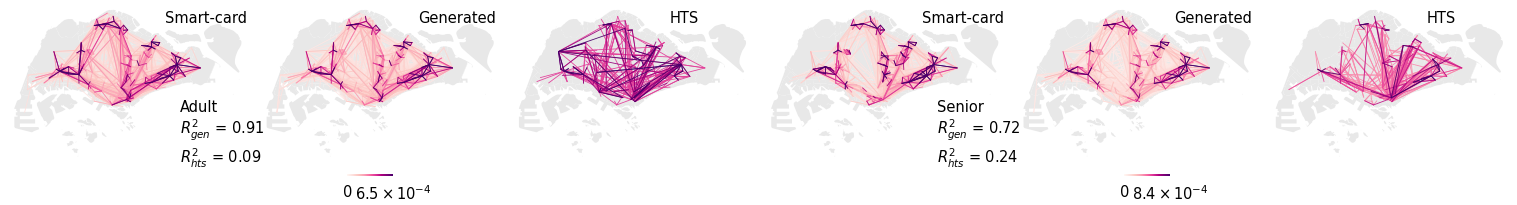

In [ ]:
"""
Full pipeline: 1×6 interzone desire-line maps (Adult/Senior × Smart-card/Generated/HTS)

Adds two R² values per category:
- R^2_gen = R²(Smart-card vs Generated) on overlapping (O,D)
- R^2_hts = R²(Smart-card vs HTS) on overlapping (O,D)

Annotation shown on Generated panels:
- Adult:  axes[1]  at (-0.22, 0.40)
- Senior: axes[4]  at (-0.22, 0.40)

You must define: path_data, path_result, path_figure
"""

from __future__ import annotations

import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.collections import LineCollection
from shapely.geometry import LineString
from sklearn.metrics import r2_score


# -----------------------------
# Nature-style setup
# -----------------------------
def set_nature_style() -> None:
    plt.rcParams.update({
        "figure.dpi": 150, "savefig.dpi": 150,
        "font.family": "DejaVu Sans", "font.size": 7,
        "axes.labelsize": 7, "axes.titlesize": 7,
        "legend.fontsize": 7, "xtick.labelsize": 7, "ytick.labelsize": 7,
        "axes.linewidth": 0.8, "lines.linewidth": 1.0, "patch.linewidth": 0.8,
        "xtick.direction": "in", "ytick.direction": "in",
        "xtick.major.size": 3.5, "ytick.major.size": 3.5,
        "xtick.minor.size": 2, "ytick.minor.size": 2,
        "legend.frameon": False,
        "savefig.bbox": "tight", "savefig.pad_inches": 0.02,
        "pdf.fonttype": 42, "ps.fonttype": 42,
    })


# -----------------------------
# Style knobs
# -----------------------------
CMAP_NAME = "RdPu"
ROW_PERCENTILE = 0.98
FLOW_KEEP_Q = 0.95
FLOW_TOP_N = None
LW_MIN, LW_MAX = 0.2, 2.4  # LW_MAX unused (constant widths)


# -----------------------------
# Reshape tours -> trips
# -----------------------------
def reshape_trip(df: pd.DataFrame, trip_max: int) -> pd.DataFrame:
    """
    Wide tours -> long trips.
    Requires columns:
      AGE, GENDER, TRIP_MAX, COMMUTER_CATEGORY
      plus TRIP_PURPOSE_i, TRAVEL_MODE_i, TRIP_STARTTIME_i, TRIP_ENDTIME_i,
           ORIGIN_SUBZONE_i, DESTINATION_SUBZONE_i
    """
    parts = []
    base_cols = ["AGE", "GENDER", "TRIP_MAX", "COMMUTER_CATEGORY"]

    for i in range(1, trip_max + 1):
        cols_i = [
            f"TRIP_PURPOSE_{i}",
            f"TRAVEL_MODE_{i}",
            f"TRIP_STARTTIME_{i}",
            f"TRIP_ENDTIME_{i}",
            f"ORIGIN_SUBZONE_{i}",
            f"DESTINATION_SUBZONE_{i}",
        ]
        dff = df[base_cols + cols_i].copy()
        dff = dff.rename(columns={
            f"TRIP_PURPOSE_{i}": "TRIP_PURPOSE",
            f"TRAVEL_MODE_{i}": "TRAVEL_MODE",
            f"TRIP_STARTTIME_{i}": "TRIP_STARTTIME",
            f"TRIP_ENDTIME_{i}": "TRIP_ENDTIME",
            f"ORIGIN_SUBZONE_{i}": "ORIGIN_SUBZONE",
            f"DESTINATION_SUBZONE_{i}": "DESTINATION_SUBZONE",
        })
        parts.append(dff)

    out = pd.concat(parts, ignore_index=True).dropna()
    return out


# -----------------------------
# Geometry helpers
# -----------------------------
def _load_subzone(path_shp: str) -> gpd.GeoDataFrame:
    g = gpd.read_file(path_shp)[["SUBZONE_C", "geometry"]].copy()
    # Use the same type as the OD keys. Shapefiles often return numeric
    # subzone IDs, whereas CSV files often return them as strings.
    g["SUBZONE_C"] = g["SUBZONE_C"].astype("string").str.strip()
    if g.crs is None:
        g.set_crs(epsg=4326, inplace=True)
    return g


def _centroids(gdf_sub: gpd.GeoDataFrame) -> pd.DataFrame:
    c = gdf_sub.copy()
    c["centroid"] = c.geometry.centroid
    return c[["SUBZONE_C", "centroid"]]


# -----------------------------
# Data aggregation
# -----------------------------
def _od_group(df: pd.DataFrame) -> pd.DataFrame:
    """
    Aggregate to unique (O,D,start,cat) then deduplicate.
    Requires columns:
      ORIGIN_SUBZONE, DESTINATION_SUBZONE, TRIP_STARTTIME, COMMUTER_CATEGORY, COUNT
    """
    cols = ["ORIGIN_SUBZONE", "DESTINATION_SUBZONE", "TRIP_STARTTIME", "COMMUTER_CATEGORY", "COUNT"]
    t = df[cols].copy()
    t["COUNT"] = t.groupby(cols[:-1], observed=True)["COUNT"].transform("sum")
    return t.drop_duplicates()


def _interzone_share(od_df: pd.DataFrame) -> pd.DataFrame:
    """
    From (O,D,start,cat,COUNT) -> aggregate to (O,D) and convert to proportions.
    Remove self-loops.
    """
    if od_df.empty:
        return pd.DataFrame(columns=["O", "D", "COUNT"])

    z = od_df[["ORIGIN_SUBZONE", "DESTINATION_SUBZONE", "COUNT"]].copy()
    z = z.rename(columns={"ORIGIN_SUBZONE": "O", "DESTINATION_SUBZONE": "D"})

    # Normalize both OD identifiers before grouping and before the later
    # merge with the centroid table.
    z["O"] = z["O"].astype("string").str.strip()
    z["D"] = z["D"].astype("string").str.strip()

    z = z.groupby(["O", "D"], observed=True, as_index=False)["COUNT"].sum()
    z = z[z["O"] != z["D"]]

    denom = float(z["COUNT"].sum())
    z["COUNT"] = 0.0 if denom <= 0 else (z["COUNT"] / denom)
    return z


def _declutter_flows(df: pd.DataFrame, keep_q: float = FLOW_KEEP_Q, top_n: int | None = FLOW_TOP_N) -> pd.DataFrame:
    if df.empty:
        return df

    out = df
    if keep_q is not None:
        thr = float(np.quantile(out["COUNT"], keep_q))
        out = out[out["COUNT"] >= thr]

    if top_n is not None and len(out) > top_n:
        out = out.nlargest(top_n, "COUNT")

    return out.copy()


# -----------------------------
# Build desire lines
# -----------------------------
def _build_lines(gdf_sub: gpd.GeoDataFrame, flows: pd.DataFrame) -> gpd.GeoDataFrame:
    if flows.empty:
        return gpd.GeoDataFrame({"COUNT": []}, geometry=[], crs=gdf_sub.crs)

    c = _centroids(gdf_sub)
    c["SUBZONE_C"] = c["SUBZONE_C"].astype("string").str.strip()

    flows = flows.copy()
    flows["O"] = flows["O"].astype("string").str.strip()
    flows["D"] = flows["D"].astype("string").str.strip()

    cO = c.rename(columns={"SUBZONE_C": "O", "centroid": "O_pt"})
    cD = c.rename(columns={"SUBZONE_C": "D", "centroid": "D_pt"})

    j = flows.merge(cO, on="O", how="left").merge(cD, on="D", how="left")
    j = j.dropna(subset=["O_pt", "D_pt"])

    geom = [LineString([o, d]) for o, d in zip(j["O_pt"], j["D_pt"])]
    return gpd.GeoDataFrame(j[["O", "D", "COUNT"]].copy(), geometry=geom, crs=gdf_sub.crs)


# -----------------------------
# Color normalization (TRIPLE)
# -----------------------------
def _row_norm_for_lines_triple(
    gA: gpd.GeoDataFrame,
    gB: gpd.GeoDataFrame,
    gC: gpd.GeoDataFrame,
    q: float = ROW_PERCENTILE,
) -> mpl.colors.Normalize:
    vals = np.r_[
        gA["COUNT"].to_numpy() if (gA is not None and not gA.empty and "COUNT" in gA) else np.array([]),
        gB["COUNT"].to_numpy() if (gB is not None and not gB.empty and "COUNT" in gB) else np.array([]),
        gC["COUNT"].to_numpy() if (gC is not None and not gC.empty and "COUNT" in gC) else np.array([]),
    ]
    if vals.size == 0 or np.all(vals == 0):
        vmax = 1.0
    else:
        vmax = float(np.quantile(vals, q))
        if vmax <= 0:
            vmax = float(vals.max() if vals.max() > 0 else 1.0)
    return mpl.colors.Normalize(vmin=0.0, vmax=vmax)


def _line_widths(counts: np.ndarray, norm: mpl.colors.Normalize, lw_min: float = LW_MIN, lw_max: float = LW_MAX) -> np.ndarray:
    return lw_min * 2


# -----------------------------
# Plot helpers
# -----------------------------
def _plot_background(ax: plt.Axes, gdf_sub: gpd.GeoDataFrame) -> None:
    gdf_sub.plot(ax=ax, facecolor="#e8e8e8", edgecolor="none", linewidth=0.0)
    ax.set_axis_off()


def _plot_lines(ax: plt.Axes, gdf_lines: gpd.GeoDataFrame, cmap_name: str, norm: mpl.colors.Normalize) -> None:
    if gdf_lines.empty:
        return

    gdf_lines = gdf_lines.sort_values("COUNT", ascending=True).reset_index(drop=True)
    cmap_obj = cm.get_cmap(cmap_name)

    values = gdf_lines["COUNT"].to_numpy()
    colors = cmap_obj(norm(values))
    widths = _line_widths(values, norm)

    lines = [np.array(line.coords) for line in gdf_lines.geometry if line is not None]

    lc = LineCollection(
        lines,
        colors=colors,
        linewidths=widths,
        alpha=0.95,
        joinstyle="round",
        capstyle="round",
    )
    ax.add_collection(lc)


def _fmt_sci_mathtext(x: float, sig: int = 2) -> str:
    if x == 0:
        return r"$0$"
    exp = int(np.floor(np.log10(abs(x))))
    mant = x / (10 ** exp)
    mant_str = f"{mant:.{sig}g}"
    return rf"${mant_str}\times 10^{{{exp}}}$"


def _add_shared_cbar(fig: plt.Figure, axes_row, norm: mpl.colors.Normalize, cmap_name: str) -> mpl.colorbar.Colorbar:
    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cm.get_cmap(cmap_name))
    sm.set_array([])

    cbar = fig.colorbar(
        sm,
        ax=axes_row,
        orientation="horizontal",
        fraction=0.01,
        pad=0.02,
    )
    cbar.outline.set_visible(False)

    vmin, vmax = float(norm.vmin), float(norm.vmax)
    cbar.set_ticks([vmin, vmax])
    cbar.ax.xaxis.get_offset_text().set_visible(False)
    cbar.set_ticklabels([_fmt_sci_mathtext(vmin, sig=2), _fmt_sci_mathtext(vmax, sig=2)])
    cbar.ax.tick_params(length=0, labelsize=7)
    return cbar


# -----------------------------
# 1×6 Interzone flow grid (Adult/Senior × Smart-card/Generated/HTS)
# -----------------------------
def compose_interzone_flow_grid_1x6(
    df_sc: pd.DataFrame,
    df_fus: pd.DataFrame,
    df_hts: pd.DataFrame,
    shp_path: str,
    save_path: str | None = None,
    figsize: tuple[float, float] = (19.0, 3.0),
) -> plt.Figure:
    gdf_sub = _load_subzone(shp_path)

    sc_od = _od_group(df_sc)
    fus_od = _od_group(df_fus)
    hts_od = _od_group(df_hts)

    cats = ["ADULT", "SENIOR"]
    panels = []   # (g_sc, g_fus, g_hts, cat)
    r2_dict = {}  # {cat: {"gen": r2_gen, "hts": r2_hts}}

    for cat in cats:
        sc_cat = sc_od[sc_od["COMMUTER_CATEGORY"] == cat]
        fu_cat = fus_od[fus_od["COMMUTER_CATEGORY"] == cat]
        ht_cat = hts_od[hts_od["COMMUTER_CATEGORY"] == cat]

        sc_flow = _declutter_flows(_interzone_share(sc_cat))
        fu_flow = _declutter_flows(_interzone_share(fu_cat))
        ht_flow = _declutter_flows(_interzone_share(ht_cat))

        # ---- R²_gen: Smart-card vs Generated ----
        merged_gen = sc_flow.merge(fu_flow, on=["O", "D"], how="inner", suffixes=("_sc", "_gen"))
        if len(merged_gen) > 1 and np.var(merged_gen["COUNT_sc"]) > 0:
            r2_gen = float(r2_score(merged_gen["COUNT_sc"], merged_gen["COUNT_gen"]))
        else:
            r2_gen = float("nan")

        # ---- R²_hts: Smart-card vs HTS ----
        merged_hts = sc_flow.merge(ht_flow, on=["O", "D"], how="inner", suffixes=("_sc", "_hts"))
        if len(merged_hts) > 1 and np.var(merged_hts["COUNT_sc"]) > 0:
            r2_hts = float(r2_score(merged_hts["COUNT_sc"], merged_hts["COUNT_hts"]))
        else:
            r2_hts = float("nan")

        r2_dict[cat] = {"gen": r2_gen, "hts": r2_hts}

        g_sc = _build_lines(gdf_sub, sc_flow)
        g_fu = _build_lines(gdf_sub, fu_flow)
        g_ht = _build_lines(gdf_sub, ht_flow)
        panels.append((g_sc, g_fu, g_ht, cat))

    fig, axes = plt.subplots(nrows=1, ncols=6, figsize=figsize)

    # -------------------------
    # Adult triple: axes 0–2
    # -------------------------
    g_sc, g_fu, g_ht, cat = panels[0]
    norm_adult = _row_norm_for_lines_triple(g_sc, g_fu, g_ht, ROW_PERCENTILE)

    ax = axes[0]
    _plot_background(ax, gdf_sub)
    _plot_lines(ax, g_sc, CMAP_NAME, norm_adult)
    ax.text(0.65, 0.95, "Smart-card", transform=ax.transAxes, va="top", ha="left", fontsize=7)

    ax = axes[1]
    _plot_background(ax, gdf_sub)
    _plot_lines(ax, g_fu, CMAP_NAME, norm_adult)
    ax.text(0.65, 0.95, "Generated", transform=ax.transAxes, va="top", ha="left", fontsize=7)

    r2g = r2_dict[cat]["gen"]
    r2h = r2_dict[cat]["hts"]
    if not (np.isnan(r2g) and np.isnan(r2h)):
        txt = "Adult\n"
        txt += (rf"$R^2_{{gen}}$ = {r2g:.2f}" if not np.isnan(r2g) else r"$R^2_{gen}$ = NA")
        txt += "\n"
        txt += (rf"$R^2_{{hts}}$ = {r2h:.2f}" if not np.isnan(r2h) else r"$R^2_{hts}$ = NA")
        ax.text(-0.3, 0.40, txt, transform=ax.transAxes, fontsize=7, va="top", ha="left")

    ax = axes[2]
    _plot_background(ax, gdf_sub)
    _plot_lines(ax, g_ht, CMAP_NAME, norm_adult)
    ax.text(0.65, 0.95, "HTS", transform=ax.transAxes, va="top", ha="left", fontsize=7)

    _add_shared_cbar(fig, [axes[0], axes[1], axes[2]], norm_adult, CMAP_NAME)

    # -------------------------
    # Senior triple: axes 3–5
    # -------------------------
    g_sc, g_fu, g_ht, cat = panels[1]
    norm_senior = _row_norm_for_lines_triple(g_sc, g_fu, g_ht, ROW_PERCENTILE)

    ax = axes[3]
    _plot_background(ax, gdf_sub)
    _plot_lines(ax, g_sc, CMAP_NAME, norm_senior)
    ax.text(0.65, 0.95, "Smart-card", transform=ax.transAxes, va="top", ha="left", fontsize=7)

    ax = axes[4]
    _plot_background(ax, gdf_sub)
    _plot_lines(ax, g_fu, CMAP_NAME, norm_senior)
    ax.text(0.65, 0.95, "Generated", transform=ax.transAxes, va="top", ha="left", fontsize=7)

    r2g = r2_dict[cat]["gen"]
    r2h = r2_dict[cat]["hts"]
    if not (np.isnan(r2g) and np.isnan(r2h)):
        txt = "Senior\n"
        txt += (rf"$R^2_{{gen}}$ = {r2g:.2f}" if not np.isnan(r2g) else r"$R^2_{gen}$ = NA")
        txt += "\n"
        txt += (rf"$R^2_{{hts}}$ = {r2h:.2f}" if not np.isnan(r2h) else r"$R^2_{hts}$ = NA")
        ax.text(-0.3, 0.40, txt, transform=ax.transAxes, fontsize=7, va="top", ha="left")

    ax = axes[5]
    _plot_background(ax, gdf_sub)
    _plot_lines(ax, g_ht, CMAP_NAME, norm_senior)
    ax.text(0.65, 0.95, "HTS", transform=ax.transAxes, va="top", ha="left", fontsize=7)

    _add_shared_cbar(fig, [axes[3], axes[4], axes[5]], norm_senior, CMAP_NAME)

    plt.subplots_adjust(wspace=0.01, hspace=0.0, bottom=0.15)

    if save_path:
        fig.savefig(save_path + ".pdf", dpi=200)

    return fig


# -----------------------------
# MAIN PIPELINE (edit filenames as needed)
# -----------------------------
if __name__ == "__main__":
    # REQUIRED: define these paths in your runtime environment (or set here)
    # path_data = "..."
    # path_result = "..."
    # path_figure = "..."

    set_nature_style()

    # The original script mixed Singapore reference data with a Seoul
    # generated file. Set one region for all inputs; use "seoul" only if
    # matching Seoul *_sc_trip.csv and *_hts_tour.csv files exist.
    REGION = "sgp"
    KK = 6000
    NB = 10
    RANDOM_SEED = 12345
    TRIP_MAX = 7

    # -------- Load datasets --------
    # All four inputs must refer to the same region.
    df_sc = pd.read_csv(
        os.path.join(path_data, f"data_{REGION}_sc_trip.csv")
    )

    df_fus = pd.read_csv(
        os.path.join(
            path_result,
            f"case_{REGION}_sim_trip_M_{KK}_nb_{NB}_seed_{RANDOM_SEED}.csv",
        )
    )
    df_fus["COUNT"] = df_fus["Prob_XYZ_fus"]

    df_hts = pd.read_csv(
        os.path.join(path_data, f"data_{REGION}_hts_tour.csv")
    )

    # -------- Build commuter categories --------
    commuter_ages = list(range(0, 4))
    commuter_ages_ = ["CHILD", "ADULT", "ADULT", "SENIOR"]


    df_hts["COMMUTER_CATEGORY"] = df_hts["AGE"].replace(commuter_ages, commuter_ages_)
    df_fus["COMMUTER_CATEGORY"] = df_fus["AGE"].replace(commuter_ages, commuter_ages_)

    # df_sc is already long; ensure it has COMMUTER_CATEGORY (if it doesn't, uncomment)
    # df_sc["COMMUTER_CATEGORY"] = df_sc["AGE"].replace(commuter_ages, commuter_ages_)

    # -------- Reshape tours -> trips --------
    #df_fus = reshape_trip(df_fus_wide, TRIP_MAX)
    df_hts = reshape_trip(df_hts, TRIP_MAX)

    # Counts (uniform per trip)
    #df_fus["COUNT"] = 1
    df_hts["COUNT"] = 1
    if "COUNT" not in df_sc.columns:
        df_sc["COUNT"] = 1



    # -------- Filter travel modes + drop CHILD --------
    df_fus = df_fus[df_fus["TRAVEL_MODE"].isin([1, 2])]
    df_hts = df_hts[df_hts["TRAVEL_MODE"].isin([1, 2])]

    df_fus = df_fus[df_fus["COMMUTER_CATEGORY"] != "CHILD"]
    df_hts = df_hts[df_hts["COMMUTER_CATEGORY"] != "CHILD"]
    df_sc = df_sc[df_sc["COMMUTER_CATEGORY"] != "CHILD"]

    # -------- Compose 1×6 figure --------
    fig = compose_interzone_flow_grid_1x6(
        df_sc=df_sc,
        df_fus=df_fus,
        df_hts=df_hts,
        shp_path=os.path.join(path_data, f"data_{REGION}_subzone.shp"),
        save_path=os.path.join(path_figure, f"case_{REGION}_interzone_grid_age_with_hts_r2gen_r2hts"),
        figsize=(13.0, 2),
    )

    plt.show()

# SFigue: Supplementary validation

## Seoul home scatters

TRIP_PURPOSE
0    14938
2    13144
1    11040
Name: count, dtype: int64
TRIP_PURPOSE
2    12945394
0     9987952
1     5758037
Name: count, dtype: int64
TRIP_PURPOSE
2    45480066
0    44243158
1    31397168
Name: count, dtype: int64
AGE
1    16551
2    15775
3     6122
0      674
Name: count, dtype: int64
AGE
1    10625817
2     9795029
0     4178886
3     4091651
Name: count, dtype: int64
AGE
1    48623141
2    46770261
3    23724782
0     2002208
Name: count, dtype: int64


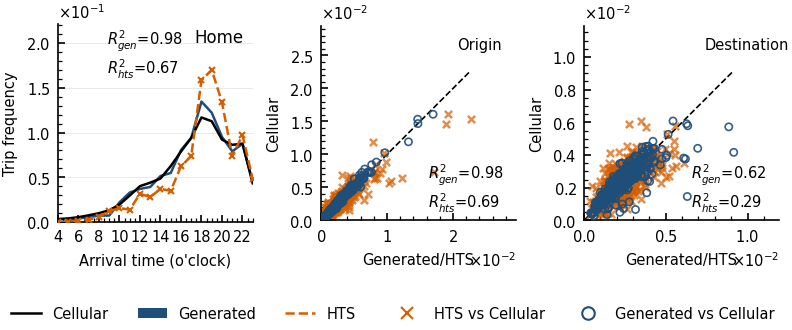

In [ ]:
# seoul_home_plots_nature.py
# ------------------------------------------------------------
# Figure A (Nature-style) — HOME ONLY
#   - Home: [Arrival time, Origin, Destination]
#
# Output: 1×3 grid
#   [Home Arr, Home Org, Home Dest]
#
# R² annotations on both line and scatter plots.
# Two legends at bottom (line legend + scatter legend).
#
# You must define: path_data, path_result, path_figure in your runtime environment.
# ------------------------------------------------------------

from __future__ import annotations

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter, AutoMinorLocator, MultipleLocator
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from sklearn.metrics import r2_score

# =========================
# Global config
# =========================
TRIP_MAX = 7

# =========================
# Nature-style setup
# =========================
def set_nature_style() -> None:
    plt.rcParams.update({
        "figure.dpi": 150, "savefig.dpi": 150,
        "font.family": "DejaVu Sans", "font.size": 7,
        "axes.labelsize": 7, "axes.titlesize": 7,
        "legend.fontsize": 7, "xtick.labelsize": 7, "ytick.labelsize": 7,
        "axes.linewidth": 0.8, "lines.linewidth": 1.2, "patch.linewidth": 0.8,
        "xtick.direction": "in", "ytick.direction": "in",
        "xtick.major.size": 3.5, "ytick.major.size": 3.5,
        "xtick.minor.size": 2, "ytick.minor.size": 2,
        "legend.frameon": False,
        "savefig.bbox": "tight", "savefig.pad_inches": 0.02,
        "pdf.fonttype": 42, "ps.fonttype": 42,
    })


COLORS = {
    "true": "#000000",
    "hts":  "#D55E00",   # orange-red
    "sim":  "#1F4E79",    # deep blue
    "diag": "#000000",
}


AX_LABELS = {
    "TRIP_STARTTIME": "Departure time (o'clock)",
    "TRIP_ENDTIME":   "Arrival time (o'clock)",
}


def _format_axis_sci(ax: plt.Axes, which: str = "both") -> None:
    fmt = ScalarFormatter(useMathText=True)
    fmt.set_powerlimits((0, 0))
    if which in ("x", "both"):
        ax.xaxis.set_major_formatter(fmt)
    if which in ("y", "both"):
        ax.yaxis.set_major_formatter(fmt)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())


def _beautify_axes(ax: plt.Axes, grid: bool = True) -> None:
    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)
    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)
    if grid:
        ax.grid(axis="y", which="major", linewidth=0.3, color="#DDDDDD")
    ax.tick_params(width=0.8, length=3.5)
    ax.tick_params(which="minor", width=0.6, length=2)


def _safe_r2(y_true, y_pred) -> float:
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    if y_true.size > 1 and np.var(y_true) > 0:
        return r2_score(y_true, y_pred)
    return np.nan


def get_max_pop(df: pd.DataFrame) -> float:
    cand_cols = [c for c in df.columns if c.startswith("Pop_")]
    if not cand_cols or df.empty:
        return 0.0
    return float(df[cand_cols].max().max())


# ============================================================
# Data preparation
# ============================================================
AGE_RECODE = {0: 0, 1: 1, 2: 2, 3: 3}
PURPOSE_RECODE_HTS_FUS = {0: 0, 1: 1, 2: 2, 3: 2, 4: 2, 5: 2}  # keeps Work=1, Other=2
PURPOSE_RECODE_PCM = {"H": 0, "W": 1, "E": 2}  # assumes E corresponds to Other


def reshape_trip(df: pd.DataFrame) -> pd.DataFrame:
    """Tour-wide columns (TRIP_*_i) -> long trips."""
    parts = []
    for i in range(1, TRIP_MAX + 1):
        cols_i = [
            f"TRIP_PURPOSE_{i}", f"TRAVEL_MODE_{i}",
            f"TRIP_STARTTIME_{i}", f"TRIP_ENDTIME_{i}",
            f"ORIGIN_SUBZONE_{i}", f"DESTINATION_SUBZONE_{i}",
        ]
        dff = df[["AGE", "GENDER", "TRIP_MAX"] + cols_i].copy()
        dff.rename(columns={
            f"TRIP_PURPOSE_{i}": "TRIP_PURPOSE",
            f"TRAVEL_MODE_{i}": "TRAVEL_MODE",
            f"TRIP_STARTTIME_{i}": "TRIP_STARTTIME",
            f"TRIP_ENDTIME_{i}": "TRIP_ENDTIME",
            f"ORIGIN_SUBZONE_{i}": "ORIGIN_SUBZONE",
            f"DESTINATION_SUBZONE_{i}": "DESTINATION_SUBZONE",
        }, inplace=True)
        parts.append(dff)

    out = pd.concat(parts, ignore_index=True)
    out.dropna(inplace=True)
    return out


def _recode_age(df: pd.DataFrame, age_col: str = "AGE") -> pd.DataFrame:
    return df


def prepare_hts(df_hts: pd.DataFrame) -> pd.DataFrame:
    df = _recode_age(df_hts)
    df["COUNT"] = 1
    df["TRIP_PURPOSE"] = df["TRIP_PURPOSE"].replace(PURPOSE_RECODE_HTS_FUS)
    return df


def prepare_pcm(df_pcm: pd.DataFrame) -> pd.DataFrame:
    df = _recode_age(df_pcm)
    if "COUNT" not in df.columns:
        df["COUNT"] = 1
    df["TRIP_PURPOSE"] = df["TRIP_PURPOSE"].replace(PURPOSE_RECODE_PCM)
    return df


def prepare_fus(df_fus_tour: pd.DataFrame) -> pd.DataFrame:
    df = reshape_trip(df_fus_tour)
    df = _recode_age(df)
    df["COUNT"] = 1
    df["TRIP_PURPOSE"] = df["TRIP_PURPOSE"].replace(PURPOSE_RECODE_HTS_FUS)
    return df

def prepare_fus_bk(df: pd.DataFrame) -> pd.DataFrame:
    df = _recode_age(df)
    df["COUNT"] = df["Prob_XYZ_fus"]
    df["TRIP_PURPOSE"] = df["TRIP_PURPOSE"].replace(PURPOSE_RECODE_HTS_FUS)
    return df


# ============================================================
# Probability computation
# ============================================================
def prob_att_purpose(df: pd.DataFrame, att: list[str], purpose_val: int, suffix: str) -> pd.DataFrame:
    """
    Normalized frequency distribution for `att`, restricted to TRIP_PURPOSE == purpose_val.
    Output: att + [f'Pop_{suffix}'].
    """
    dff = df.loc[df["TRIP_PURPOSE"] == purpose_val, att + ["COUNT"]].copy()
    if dff.empty:
        return pd.DataFrame(columns=att + [f"Pop_{suffix}"])

    dff["COUNT"] = dff.groupby(att, observed=True)["COUNT"].transform("sum")
    dff = dff.drop_duplicates()
    denom = float(dff["COUNT"].sum())
    dff[f"Pop_{suffix}"] = (dff["COUNT"] / denom) if denom > 0 else 0.0
    dff = dff.drop(columns=["COUNT"]).sort_values(att)
    return dff


# ============================================================
# Plot helpers
# ============================================================
def plot_line_ax(ax: plt.Axes, df: pd.DataFrame, att: str) -> None:
    """Time distribution: bar (Generated) + lines (True, HTS) + R²."""
    d = df.copy()
    d[att] = pd.to_numeric(d[att], errors="coerce")
    d = d.sort_values(att)

    '''ax.bar(
        d[att], d["Pop_fus"], width=0.8,
        color=COLORS["sim"], edgecolor="none", alpha=0.85,
        label="Generated",
    )'''

    ax.plot(
        d[att], d["Pop_fus"],
        color=COLORS["sim"], label="Generated", zorder=3,
    )
    ax.plot(d[att], d["Pop_sc"], color=COLORS["true"], linestyle="-", label="True", zorder=3)
    ax.plot(
        d[att], d["Pop_hts"],
        color=COLORS["hts"], linestyle="--",
        marker="x", markersize=2.5, label="HTS", zorder=4,
    )

    ax.set_xlabel(AX_LABELS.get(att, att))
    ax.set_ylabel("Trip frequency")

    if att in {"TRIP_STARTTIME", "TRIP_ENDTIME"}:
        ax.set_xlim(4, 23)
        ax.set_xticks(np.arange(4, 24, 2))
        ax.xaxis.set_minor_locator(MultipleLocator(1))

    _format_axis_sci(ax, which="y")
    _beautify_axes(ax)

    maxz = get_max_pop(d)
    ax.set_ylim(0, 1.3 * maxz if maxz > 0 else 1.0)

    r2_gen = _safe_r2(d["Pop_sc"], d["Pop_fus"])
    r2_hts = _safe_r2(d["Pop_sc"], d["Pop_hts"])

    lines = []
    if not np.isnan(r2_gen):
        lines.append(f"$R^2_{{gen}}$={r2_gen:.2f}")
    if not np.isnan(r2_hts):
        lines.append(f"$R^2_{{hts}}$={r2_hts:.2f}")
    if lines:
        ax.text(0.25, 0.98, "\n".join(lines), transform=ax.transAxes,
                fontsize=7, va="top", ha="left")


def plot_point_ax(ax: plt.Axes, df: pd.DataFrame) -> None:
    """OD marginal scatter: (Generated vs True) + (HTS vs True) + R²."""
    df_hts_vis = df[(df["Pop_sc"] > 0) & (df["Pop_hts"] > 0)].copy()
    df_fus_vis = df[(df["Pop_sc"] > 0) & (df["Pop_fus"] > 0)].copy()

    limit = 0.0
    if len(df_hts_vis):
        limit = max(limit, float(df_hts_vis[["Pop_sc", "Pop_hts"]].to_numpy().max()))
    if len(df_fus_vis):
        limit = max(limit, float(df_fus_vis[["Pop_sc", "Pop_fus"]].to_numpy().max()))
    if limit == 0.0:
        limit = 1.0

    ax.plot([0, limit], [0, limit], linestyle="--",
            color=COLORS["true"], linewidth=0.8, zorder=1)

    if len(df_hts_vis):
        ax.scatter(
            df_hts_vis["Pop_hts"], df_hts_vis["Pop_sc"],
            s=12, marker="x", color=COLORS["hts"], alpha=0.7,
            label="HTS vs True", zorder=2,
        )
    if len(df_fus_vis):
        ax.scatter(
            df_fus_vis["Pop_fus"], df_fus_vis["Pop_sc"],
            s=12, facecolor="none", edgecolor=COLORS["sim"],
            linewidth=0.8, alpha=0.9,
            label="Generated vs True", zorder=3,
        )

    ax.set_xlim(0, 1.3 * limit)
    ax.set_ylim(0, 1.3 * limit)
    ax.set_aspect("equal", adjustable="box")

    ax.set_xlabel("Generated/HTS")
    ax.set_ylabel("Cellular")
    _format_axis_sci(ax)
    _beautify_axes(ax, grid=False)

    r2_gen = _safe_r2(df_fus_vis["Pop_sc"], df_fus_vis["Pop_fus"]) if len(df_fus_vis) else np.nan
    r2_hts = _safe_r2(df_hts_vis["Pop_sc"], df_hts_vis["Pop_hts"]) if len(df_hts_vis) else np.nan

    lines = []
    if not np.isnan(r2_gen):
        lines.append(f"$R^2_{{gen}}$={r2_gen:.2f}")
    if not np.isnan(r2_hts):
        lines.append(f"$R^2_{{hts}}$={r2_hts:.2f}")
    if lines:
        ax.text(0.55, 0.30, "\n".join(lines), transform=ax.transAxes,
                fontsize=7, va="top", ha="left")


# ============================================================
# Figure A composer: 1×3 (HOME only)
# ============================================================
def compose_home_1x3(
    df_pcm: pd.DataFrame,
    df_hts: pd.DataFrame,
    df_fus: pd.DataFrame,
    *,
    home_val: int = 0,
    time_att: str = "TRIP_ENDTIME",
    figsize: tuple[float, float] = (7.0, 2.2),
    save_path: str | None = None,
) -> plt.Figure:
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    axes = np.atleast_1d(axes)

    def _assemble_time(purpose_val: int):
        d_fus = prob_att_purpose(df_fus, [time_att], purpose_val, "fus")
        d_sc  = prob_att_purpose(df_pcm, [time_att], purpose_val, "sc")
        d_hts = prob_att_purpose(df_hts, [time_att], purpose_val, "hts")
        return (
            d_sc.merge(d_fus, on=[time_att], how="outer")
               .merge(d_hts, on=[time_att], how="outer")
               .fillna(0)
               .sort_values(time_att)
        )

    def _assemble_scatter(purpose_val: int, col: str):
        a_fus = prob_att_purpose(df_fus, [col], purpose_val, "fus")
        a_sc  = prob_att_purpose(df_pcm, [col], purpose_val, "sc")
        a_hts = prob_att_purpose(df_hts, [col], purpose_val, "hts")
        return (
            a_sc.merge(a_fus, on=[col], how="inner")
                .merge(a_hts, on=[col], how="inner")
        )

    # Home: Arrival time, Origin, Destination
    h_time = _assemble_time(home_val)
    plot_line_ax(axes[0], h_time, time_att)
    axes[0].text(0.70, 0.98, "Home", transform=axes[0].transAxes,
                 va="top", ha="left", fontsize=8)

    h_org = _assemble_scatter(home_val, "ORIGIN_SUBZONE")
    plot_point_ax(axes[1], h_org)
    axes[1].text(0.70, 0.94, "Origin", transform=axes[1].transAxes,
                 va="top", ha="left", fontsize=7)

    h_dst = _assemble_scatter(home_val, "DESTINATION_SUBZONE")
    plot_point_ax(axes[2], h_dst)
    axes[2].text(0.62, 0.94, "Destination", transform=axes[2].transAxes,
                 va="top", ha="left", fontsize=7)

    # Layout + Legends (same style as original)
    plt.subplots_adjust(wspace=0.35, hspace=0.0, bottom=0.28)

    legend1 = [
        Line2D([0], [0], color=COLORS["true"], lw=1.2, label="True"),
        Patch(facecolor=COLORS["sim"], edgecolor="none", label="Generated"),
        Line2D([0], [0], color=COLORS["hts"], lw=1.2, ls="--", label="HTS"),
    ]
    fig.legend(
        legend1, ["Cellular", "Generated", "HTS"],
        loc="lower center", bbox_to_anchor=(0.26, -0.06),
        ncol=3, frameon=False,
    )

    legend2 = [
        Line2D([], [], marker="x", linestyle="None",
               markerfacecolor=COLORS["hts"], markeredgecolor=COLORS["hts"],
               markersize=6, label="HTS vs True"),
        Line2D([], [], marker="o", linestyle="None",
               markerfacecolor="none", markeredgecolor=COLORS["sim"],
               markersize=6, label="Generated vs True"),
    ]
    fig.legend(
        legend2, ["HTS vs Cellular", "Generated vs Cellular"],
        loc="lower center", bbox_to_anchor=(0.69, -0.06),
        ncol=2, frameon=False,
    )

    if save_path:
        #fig.savefig(save_path + ".pdf", dpi=600, bbox_inches="tight")
        fig.savefig(save_path + ".pdf", dpi=200, bbox_inches="tight")

    return fig


# ============================================================
# MAIN
# ============================================================
if __name__ == "__main__":
    set_nature_style()

    # -------- Load --------
    df_hts_raw = pd.read_csv(os.path.join(path_data, "data_seoul_hts_trip.csv"))

    df_pcm_raw = pd.read_csv(os.path.join(path_data, "data_seoul_pcm_trip.csv"))

    df_hts_raw['AGE'].replace([i for i in range(8)], [0, 0, 1, 1, 2, 2, 3, 3], inplace=True)
    df_pcm_raw['AGE'].replace([i for i in range(8)], [0, 0, 1, 1, 2, 2, 3, 3], inplace=True)

    if "TRIP_PURPOSE_" in df_pcm_raw.columns and "TRIP_PURPOSE" not in df_pcm_raw.columns:
        df_pcm_raw.rename(columns={"TRIP_PURPOSE_": "TRIP_PURPOSE"}, inplace=True)

    reg = 'seoul'
    KK = 6000
    nb = 10
    RANDOM_SEED = 12345

    #df_fus_tour_raw = pd.read_csv(path_result +  f"case_{reg}_sim_tour_M_{KK}_nb_{nb}_seed_{RANDOM_SEED}.csv")
    #df_fus = prepare_fus(df_fus_tour_raw)

    df_fus = pd.read_csv(path_result +  f"case_{reg}_sim_trip_M_{KK}_nb_{nb}_seed_{RANDOM_SEED}.csv")
    df_fus["COUNT"] = df_fus["Prob_XYZ_fus"]

    df_fus["TRIP_PURPOSE"] = df_fus["TRIP_PURPOSE"].replace(PURPOSE_RECODE_HTS_FUS)

    # -------- Prepare --------
    df_hts = prepare_hts(df_hts_raw)
    df_pcm = prepare_pcm(df_pcm_raw)

    print(df_hts['TRIP_PURPOSE'].value_counts())
    print(df_pcm['TRIP_PURPOSE'].value_counts())
    print(df_fus['TRIP_PURPOSE'].value_counts())

    print(df_hts['AGE'].value_counts())
    print(df_pcm['AGE'].value_counts())
    print(df_fus['AGE'].value_counts())

    # -------- Figure A (1×3) --------
    fig_A = compose_home_1x3(
        df_pcm=df_pcm,
        df_hts=df_hts,
        df_fus=df_fus,
        home_val=0,                 # Home (H) -> 0
        time_att="TRIP_ENDTIME",    # Arrival time
        figsize=(6.2, 2.2),
        save_path=os.path.join(path_figure, "case_seoul_1x3_home_nature"),
    )

    plt.show()


## Seoul home map

In [ ]:
# seoul_age_od_maps_memory_safe.py
# ------------------------------------------------------------
# Memory-safe age-specific interzonal OD-flow maps:
#   1 × 3 panels: Cellular / Generated / HTS
#
# Key memory safeguards:
#   1. Reads only AGE, origin, destination, and generated weight.
#   2. Aggregates each source immediately after reading it.
#   3. Deletes the original trip-level dataframe before loading the next source.
#   4. Applies a strict top-N limit before constructing flow geometries.
#   5. Closes each figure after saving it.
#
# You must define: path_data, path_result, path_figure
# ------------------------------------------------------------

from __future__ import annotations

import os
import gc
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt

from matplotlib import cm
from matplotlib.collections import LineCollection
from shapely.geometry import LineString
from sklearn.metrics import r2_score


# =========================
# Configuration
# =========================
REGION = "seoul"
KK = 6000
NB = 10
RANDOM_SEED = 12345

CMAP_NAME = "RdPu"

# Retain high-flow links, with an absolute limit to prevent RAM crashes.
FLOW_KEEP_Q = 0.95
FLOW_TOP_N = 500

ROW_PERCENTILE = 0.98
LW_MIN = 0.25
LW_MAX = 2.50

# Set True only when figures should also be displayed interactively.
SHOW_FIGURES = False


# Original HTS / PCM age categories 0–7 collapsed to four groups.
AGE_RECODE = {
    0: 0,
    1: 0,  # Younger: <20 years
    2: 1,
    3: 1,  # Younger adults: 20–39 years
    4: 2,
    5: 2,  # Middle-aged adults: 40–59 years
    6: 3,
    7: 3,  # Older adults: >=60 years
}

AGE_SPECS = [
    (0, "Younger (<20 years)"),
    (1, "Younger adults (20–39 years)"),
    (2, "Middle-aged adults (40–59 years)"),
    (3, "Older adults (≥60 years)"),
]


# =========================
# Nature-style setup
# =========================
def set_nature_style() -> None:
    plt.rcParams.update({
        "figure.dpi": 150,
        "savefig.dpi": 300,
        "font.family": "DejaVu Sans",
        "font.size": 7,
        "axes.labelsize": 7,
        "axes.titlesize": 7,
        "legend.fontsize": 7,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "axes.linewidth": 0.8,
        "lines.linewidth": 1.0,
        "patch.linewidth": 0.8,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.major.size": 3.5,
        "ytick.major.size": 3.5,
        "xtick.minor.size": 2,
        "ytick.minor.size": 2,
        "legend.frameon": False,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.02,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })


# =========================
# Data loading and aggregation
# =========================
def load_trip_data(
    csv_path: str,
    *,
    generated: bool = False,
) -> pd.DataFrame:
    """
    Read only fields required for the OD map.

    For generated data, COUNT is Prob_XYZ_fus.
    For HTS and Cellular data, each trip has unit weight.
    """
    base_cols = [
        "AGE",
        "ORIGIN_SUBZONE",
        "DESTINATION_SUBZONE",
    ]

    usecols = (
        base_cols + ["Prob_XYZ_fus"]
        if generated
        else base_cols
    )

    df = pd.read_csv(
        csv_path,
        usecols=usecols,
        dtype={
            "AGE": "int8",
            "ORIGIN_SUBZONE": "string",
            "DESTINATION_SUBZONE": "string",
        },
    )

    if generated:
        df["COUNT"] = pd.to_numeric(
            df["Prob_XYZ_fus"],
            errors="coerce",
        ).fillna(0).astype("float32")

        df.drop(columns="Prob_XYZ_fus", inplace=True)

    else:
        df["COUNT"] = np.float32(1.0)

    return df


def aggregate_od_shares_all_ages(
    df: pd.DataFrame,
) -> pd.DataFrame:
    """
    Aggregate normalized interzonal OD shares for all age groups.

    Returns a compact table with:
        AGE, O, D, COUNT

    COUNT is each OD pair's share among all interzonal trips for that
    specific age group.
    """
    valid_mask = (
        df["ORIGIN_SUBZONE"].notna()
        & df["DESTINATION_SUBZONE"].notna()
        & df["ORIGIN_SUBZONE"].ne(df["DESTINATION_SUBZONE"])
    )

    flows = (
        df.loc[
            valid_mask,
            [
                "AGE",
                "ORIGIN_SUBZONE",
                "DESTINATION_SUBZONE",
                "COUNT",
            ],
        ]
        .groupby(
            [
                "AGE",
                "ORIGIN_SUBZONE",
                "DESTINATION_SUBZONE",
            ],
            observed=True,
            as_index=False,
        )["COUNT"]
        .sum()
        .rename(columns={
            "ORIGIN_SUBZONE": "O",
            "DESTINATION_SUBZONE": "D",
        })
    )

    if flows.empty:
        return pd.DataFrame(columns=["AGE", "O", "D", "COUNT"])

    age_totals = (
        flows.groupby(
            "AGE",
            observed=True,
        )["COUNT"]
        .transform("sum")
    )

    flows["COUNT"] = (
        flows["COUNT"] / age_totals
    ).astype("float32")

    return flows


def get_age_flows(
    od_flows: pd.DataFrame,
    age_val: int,
) -> pd.DataFrame:
    """Retrieve compact OD flows for one age group."""
    return (
        od_flows.loc[
            od_flows["AGE"].eq(age_val),
            ["O", "D", "COUNT"],
        ]
        .copy()
        .reset_index(drop=True)
    )


def declutter_flows(
    flows: pd.DataFrame,
    keep_q: float = FLOW_KEEP_Q,
    top_n: int = FLOW_TOP_N,
) -> pd.DataFrame:
    """
    Keep high-flow OD pairs, then enforce a strict top-N ceiling.

    The top-N ceiling is necessary because percentile thresholds can retain
    many tied OD pairs, especially in HTS or Cellular data.
    """
    if flows.empty:
        return flows.copy()

    out = flows

    if keep_q is not None:
        threshold = float(out["COUNT"].quantile(keep_q))
        out = out.loc[out["COUNT"] >= threshold]

    if top_n is not None and len(out) > top_n:
        out = out.nlargest(top_n, "COUNT")

    return out.reset_index(drop=True)


# =========================
# Geometry
# =========================
def load_subzones_with_centroids(
    shp_path: str,
) -> tuple[gpd.GeoDataFrame, pd.DataFrame]:
    """Load the subzone layer and calculate centroids once."""
    gdf_sub = gpd.read_file(
        shp_path,
    )[["SUBZONE_C", "geometry"]].copy()

    if gdf_sub.crs is None:
        gdf_sub = gdf_sub.set_crs(epsg=4326)

    # Centroids should be calculated in a projected CRS.
    if gdf_sub.crs.is_geographic:
        gdf_sub = gdf_sub.to_crs(epsg=5186)

    gdf_sub["SUBZONE_C"] = gdf_sub["SUBZONE_C"].astype("string")

    centroids = pd.DataFrame({
        "SUBZONE_C": gdf_sub["SUBZONE_C"].to_numpy(),
        "centroid": gdf_sub.geometry.centroid.to_numpy(),
    })

    return gdf_sub, centroids


def build_flow_lines(
    flows: pd.DataFrame,
    centroids: pd.DataFrame,
    crs,
) -> gpd.GeoDataFrame:
    """
    Convert already-filtered OD pairs into centroid-to-centroid lines.

    Do not pass full OD results here: use declutter_flows() first.
    """
    if flows.empty:
        return gpd.GeoDataFrame(
            {"O": [], "D": [], "COUNT": []},
            geometry=[],
            crs=crs,
        )

    origins = centroids.rename(columns={
        "SUBZONE_C": "O",
        "centroid": "O_pt",
    })

    destinations = centroids.rename(columns={
        "SUBZONE_C": "D",
        "centroid": "D_pt",
    })

    joined = (
        flows
        .merge(origins, on="O", how="left")
        .merge(destinations, on="D", how="left")
        .dropna(subset=["O_pt", "D_pt"])
    )

    geometry = [
        LineString([origin, destination])
        for origin, destination in zip(
            joined["O_pt"],
            joined["D_pt"],
        )
    ]

    return gpd.GeoDataFrame(
        joined[["O", "D", "COUNT"]].copy(),
        geometry=geometry,
        crs=crs,
    )


# =========================
# Statistics
# =========================
def safe_r2(
    y_true: pd.Series,
    y_pred: pd.Series,
) -> float:
    """Return R² where it is statistically defined."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    if y_true.size > 1 and np.var(y_true) > 0:
        return float(r2_score(y_true, y_pred))

    return float("nan")


def comparison_r2(
    reference: pd.DataFrame,
    comparison: pd.DataFrame,
) -> float:
    """
    OD-share R² on the union of supports.

    An OD pair absent from one source receives zero share, consistent with
    the OD scatter-plot comparison.
    """
    merged = (
        reference[["O", "D", "COUNT"]]
        .merge(
            comparison[["O", "D", "COUNT"]],
            on=["O", "D"],
            how="outer",
            suffixes=("_true", "_comparison"),
        )
        .fillna(0)
    )

    return safe_r2(
        merged["COUNT_true"],
        merged["COUNT_comparison"],
    )


# =========================
# Plotting helpers
# =========================
def shared_norm(
    *line_gdfs: gpd.GeoDataFrame,
    percentile: float = ROW_PERCENTILE,
) -> mpl.colors.Normalize:
    """Create one colour scale shared by the three panels."""
    value_arrays = [
        gdf["COUNT"].to_numpy()
        for gdf in line_gdfs
        if gdf is not None and not gdf.empty
    ]

    if not value_arrays:
        return mpl.colors.Normalize(vmin=0.0, vmax=1.0)

    values = np.concatenate(value_arrays)

    if np.all(values <= 0):
        return mpl.colors.Normalize(vmin=0.0, vmax=1.0)

    vmax = float(np.quantile(values, percentile))

    if vmax <= 0:
        vmax = float(values.max())

    return mpl.colors.Normalize(vmin=0.0, vmax=vmax)


def line_widths(
    values: np.ndarray,
    norm: mpl.colors.Normalize,
) -> np.ndarray:
    """Scale OD line widths consistently within a figure."""
    scaled = np.clip(norm(values), 0, 1)

    return LW_MIN + (LW_MAX - LW_MIN) * scaled


def plot_background(
    ax: plt.Axes,
    gdf_sub: gpd.GeoDataFrame,
) -> None:
    """Plot Seoul subzones as the map background."""
    gdf_sub.plot(
        ax=ax,
        facecolor="#E8E8E8",
        edgecolor="#FFFFFF",
        linewidth=0.10,
        zorder=0,
    )
    ax.set_axis_off()


def plot_flow_lines(
    ax: plt.Axes,
    gdf_lines: gpd.GeoDataFrame,
    norm: mpl.colors.Normalize,
) -> None:
    """Plot already-capped OD flow lines."""
    if gdf_lines.empty:
        return

    dff = gdf_lines.sort_values(
        "COUNT",
        ascending=True,
    ).reset_index(drop=True)

    values = dff["COUNT"].to_numpy()

    segments = [
        np.asarray(line.coords)
        for line in dff.geometry
    ]

    collection = LineCollection(
        segments,
        colors=cm.get_cmap(CMAP_NAME)(norm(values)),
        linewidths=line_widths(values, norm),
        alpha=0.90,
        capstyle="round",
        joinstyle="round",
        zorder=2,
    )

    ax.add_collection(collection)


def add_shared_colorbar(
    fig: plt.Figure,
    axes: list[plt.Axes],
    norm: mpl.colors.Normalize,
) -> None:
    """Add a shared OD-share colour bar below the three maps."""
    scalar_map = mpl.cm.ScalarMappable(
        norm=norm,
        cmap=cm.get_cmap(CMAP_NAME),
    )
    scalar_map.set_array([])

    cbar = fig.colorbar(
        scalar_map,
        ax=axes,
        orientation="horizontal",
        fraction=0.025,
        pad=0.02,
        aspect=45,
    )

    cbar.outline.set_visible(False)
    cbar.set_label("Interzonal OD share", labelpad=2)
    cbar.ax.tick_params(length=0, labelsize=7)


# =========================
# Compose one figure per age
# =========================
def compose_age_od_maps(
    od_pcm: pd.DataFrame,
    od_fus: pd.DataFrame,
    od_hts: pd.DataFrame,
    gdf_sub: gpd.GeoDataFrame,
    centroids: pd.DataFrame,
    *,
    age_val: int,
    age_label: str,
    figsize: tuple[float, float] = (6.5, 2.25),
    save_path: str | None = None,
) -> plt.Figure:
    """
    Plot one age group's Cellular / Generated / HTS interzonal OD maps.
    """
    cellular_all = get_age_flows(od_pcm, age_val)
    generated_all = get_age_flows(od_fus, age_val)
    hts_all = get_age_flows(od_hts, age_val)

    # Compute R² before applying visual filtering.
    r2_gen = comparison_r2(cellular_all, generated_all)
    r2_hts = comparison_r2(cellular_all, hts_all)

    # Restrict OD pairs before constructing geometries.
    cellular_map = declutter_flows(cellular_all)
    generated_map = declutter_flows(generated_all)
    hts_map = declutter_flows(hts_all)

    gdf_cellular = build_flow_lines(
        cellular_map,
        centroids,
        gdf_sub.crs,
    )
    gdf_generated = build_flow_lines(
        generated_map,
        centroids,
        gdf_sub.crs,
    )
    gdf_hts = build_flow_lines(
        hts_map,
        centroids,
        gdf_sub.crs,
    )

    norm = shared_norm(
        gdf_cellular,
        gdf_generated,
        gdf_hts,
    )

    fig, axes = plt.subplots(
        nrows=1,
        ncols=3,
        figsize=figsize,
    )
    axes = np.asarray(axes)

    for ax, gdf_lines, title in zip(
        axes,
        [gdf_cellular, gdf_generated, gdf_hts],
        ["Cellular", "Generated", "HTS"],
    ):
        plot_background(ax, gdf_sub)
        plot_flow_lines(ax, gdf_lines, norm)
        ax.set_title(title, pad=3)

    axes[0].text(
        0.03,
        0.97,
        age_label,
        transform=axes[0].transAxes,
        va="top",
        ha="left",
        fontsize=7,
        fontweight="bold",
    )

    r2_text = []

    if not np.isnan(r2_gen):
        r2_text.append(f"$R^2_{{gen}}$ = {r2_gen:.2f}")

    if not np.isnan(r2_hts):
        r2_text.append(f"$R^2_{{hts}}$ = {r2_hts:.2f}")

    if r2_text:
        axes[1].text(
            0.04,
            0.10,
            "\n".join(r2_text),
            transform=axes[1].transAxes,
            va="bottom",
            ha="left",
            fontsize=7,
        )

    add_shared_colorbar(fig, list(axes), norm)

    plt.subplots_adjust(
        wspace=0.01,
        bottom=0.18,
    )

    if save_path:
        fig.savefig(
            save_path + ".pdf",
            dpi=300,
            bbox_inches="tight",
        )

    return fig


# =========================
# Main
# =========================
if __name__ == "__main__":
    set_nature_style()

    hts_path = os.path.join(
        path_data,
        "data_seoul_hts_trip.csv",
    )

    pcm_path = os.path.join(
        path_data,
        "data_seoul_pcm_trip.csv",
    )

    fus_path = os.path.join(
        path_result,
        f"case_{REGION}_sim_trip_M_{KK}_nb_{NB}_seed_{RANDOM_SEED}.csv",
    )

    shp_path = os.path.join(
        path_data,
        "data_seoul_subzone.shp",
    )

    # --------------------------------------------------------
    # Aggregate HTS, then remove the original trip-level table.
    # --------------------------------------------------------
    print("Loading and aggregating HTS...")
    df_hts = load_trip_data(
        hts_path,
        generated=False,
    )

    df_hts["AGE"] = (
        df_hts["AGE"]
        .replace(AGE_RECODE)
        .astype("int8")
    )

    od_hts = aggregate_od_shares_all_ages(df_hts)

    del df_hts
    gc.collect()

    # --------------------------------------------------------
    # Aggregate Cellular, then remove the original trip-level table.
    # --------------------------------------------------------
    print("Loading and aggregating Cellular...")
    df_pcm = load_trip_data(
        pcm_path,
        generated=False,
    )

    df_pcm["AGE"] = (
        df_pcm["AGE"]
        .replace(AGE_RECODE)
        .astype("int8")
    )

    od_pcm = aggregate_od_shares_all_ages(df_pcm)

    del df_pcm
    gc.collect()

    # --------------------------------------------------------
    # Aggregate Generated, then remove the original trip-level table.
    # --------------------------------------------------------
    print("Loading and aggregating Generated...")
    df_fus = load_trip_data(
        fus_path,
        generated=True,
    )

    # Generated data already use the four age groups 0–3.
    df_fus["AGE"] = df_fus["AGE"].astype("int8")

    od_fus = aggregate_od_shares_all_ages(df_fus)

    del df_fus
    gc.collect()

    # Only compact aggregated OD tables remain after this point.
    print("Loading subzone geometry...")
    gdf_sub, centroids = load_subzones_with_centroids(shp_path)

    # --------------------------------------------------------
    # Create one 1 × 3 OD-map figure per age group.
    # --------------------------------------------------------
    for age_val, age_label in AGE_SPECS:
        print(f"Plotting age group {age_val}: {age_label}")

        fig = compose_age_od_maps(
            od_pcm=od_pcm,
            od_fus=od_fus,
            od_hts=od_hts,
            gdf_sub=gdf_sub,
            centroids=centroids,
            age_val=age_val,
            age_label=age_label,
            figsize=(6.5, 2.25),
            save_path=os.path.join(
                path_figure,
                f"case_seoul_1x3_interzonal_od_map_age_{age_val}",
            ),
        )

        if SHOW_FIGURES:
            plt.show()

        # Release figure and its LineCollection objects before the next age.
        plt.close(fig)
        gc.collect()

    print("Completed.")

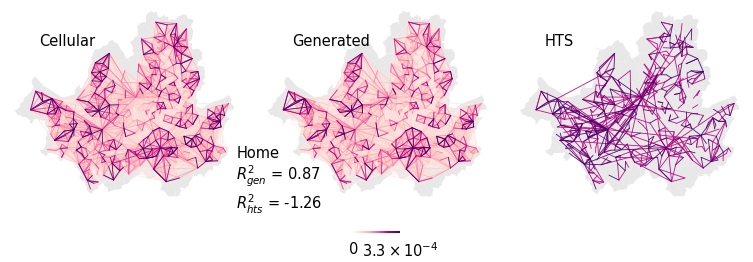

In [ ]:
# seoul_home_maps_triple.py
# Figure: 1×3 interzone maps for Home trips (purpose code = 0)
# Columns: Cellular / Generated / HTS
#
# You must define: path_data, path_result, path_figure
# in your runtime environment.

from __future__ import annotations

import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.collections import LineCollection
from shapely.geometry import LineString
from sklearn.metrics import r2_score


# -----------------------------
# Nature-style setup
# -----------------------------
def set_nature_style() -> None:
    plt.rcParams.update({
        "figure.dpi": 150,
        "savefig.dpi": 150,
        "font.family": "DejaVu Sans",
        "font.size": 7,
        "axes.labelsize": 7,
        "axes.titlesize": 7,
        "legend.fontsize": 7,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "axes.linewidth": 0.8,
        "lines.linewidth": 1.0,
        "patch.linewidth": 0.8,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.major.size": 3.5,
        "ytick.major.size": 3.5,
        "xtick.minor.size": 2,
        "ytick.minor.size": 2,
        "legend.frameon": False,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.02,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })


# -----------------------------
# Style knobs
# -----------------------------
CMAP_NAME = "RdPu"
ROW_PERCENTILE = 0.98
FLOW_KEEP_Q = 0.95
FLOW_TOP_N = None
LW_MIN, LW_MAX = 0.2, 2.4


# -----------------------------
# Recodes
# -----------------------------
TRIP_MAX = 7

# Home = 0, Work = 1, all remaining non-home/non-work purposes = 2
PURPOSE_RECODE_HTS_FUS = {
    0: 0,  # Home
    1: 1,  # Work
    2: 2,
    3: 2,
    4: 2,
    5: 2,
}

# PCM source: H = Home, W = Work, E = Other
PURPOSE_RECODE_PCM = {
    "H": 0,
    "W": 1,
    "E": 2,
}


def _recode_age(df: pd.DataFrame, age_col: str = "AGE") -> pd.DataFrame:
    return df


def reshape_trip(df: pd.DataFrame) -> pd.DataFrame:
    parts = []

    for i in range(1, TRIP_MAX + 1):
        cols_i = [
            f"TRIP_PURPOSE_{i}",
            f"TRAVEL_MODE_{i}",
            f"TRIP_STARTTIME_{i}",
            f"TRIP_ENDTIME_{i}",
            f"ORIGIN_SUBZONE_{i}",
            f"DESTINATION_SUBZONE_{i}",
        ]

        dff = df[["AGE", "GENDER", "TRIP_MAX"] + cols_i].copy()

        dff = dff.rename(columns={
            f"TRIP_PURPOSE_{i}": "TRIP_PURPOSE",
            f"TRAVEL_MODE_{i}": "TRAVEL_MODE",
            f"TRIP_STARTTIME_{i}": "TRIP_STARTTIME",
            f"TRIP_ENDTIME_{i}": "TRIP_ENDTIME",
            f"ORIGIN_SUBZONE_{i}": "ORIGIN_SUBZONE",
            f"DESTINATION_SUBZONE_{i}": "DESTINATION_SUBZONE",
        })

        parts.append(dff)

    out = pd.concat(parts, ignore_index=True).dropna()
    return out


def prepare_pcm(df_pcm_raw: pd.DataFrame) -> pd.DataFrame:
    df = _recode_age(df_pcm_raw.copy())

    if "COUNT" not in df.columns:
        df["COUNT"] = 1

    df["TRIP_PURPOSE"] = df["TRIP_PURPOSE"].replace(PURPOSE_RECODE_PCM)
    return df


def prepare_fus_like(df_tour_raw: pd.DataFrame) -> pd.DataFrame:
    df = reshape_trip(df_tour_raw)
    df = _recode_age(df)
    df["COUNT"] = 1
    df["TRIP_PURPOSE"] = df["TRIP_PURPOSE"].replace(PURPOSE_RECODE_HTS_FUS)
    return df


# -----------------------------
# Geometry helpers
# -----------------------------
def _load_subzone(path_shp: str) -> gpd.GeoDataFrame:
    gdf_sub = gpd.read_file(path_shp)[["SUBZONE_C", "geometry"]].copy()

    if gdf_sub.crs is None:
        gdf_sub.set_crs(epsg=4326, inplace=True)

    return gdf_sub


def _centroids(gdf_sub: gpd.GeoDataFrame) -> pd.DataFrame:
    centroids = gdf_sub.copy()
    centroids["centroid"] = centroids.geometry.centroid
    return centroids[["SUBZONE_C", "centroid"]]


# -----------------------------
# OD aggregation and shares
# -----------------------------
def _od_group(df: pd.DataFrame) -> pd.DataFrame:
    cols = [
        "ORIGIN_SUBZONE",
        "DESTINATION_SUBZONE",
        "TRIP_STARTTIME",
        "TRIP_PURPOSE",
        "COUNT",
    ]

    out = df[cols].copy()
    out["COUNT"] = out.groupby(
        cols[:-1],
        observed=True,
    )["COUNT"].transform("sum")

    return out.drop_duplicates()


def _interzone_share(od_df: pd.DataFrame) -> pd.DataFrame:
    if od_df.empty:
        return pd.DataFrame(columns=["O", "D", "COUNT"])

    flows = od_df[
        ["ORIGIN_SUBZONE", "DESTINATION_SUBZONE", "COUNT"]
    ].copy()

    flows = flows.rename(columns={
        "ORIGIN_SUBZONE": "O",
        "DESTINATION_SUBZONE": "D",
    })

    flows = flows.groupby(
        ["O", "D"],
        observed=True,
        as_index=False,
    )["COUNT"].sum()

    # Retain only interzone trips
    flows = flows[flows["O"] != flows["D"]]

    total_count = float(flows["COUNT"].sum())
    flows["COUNT"] = (
        0.0
        if total_count <= 0
        else flows["COUNT"] / total_count
    )

    return flows


def _declutter_flows(
    df: pd.DataFrame,
    keep_q: float = FLOW_KEEP_Q,
    top_n: int | None = FLOW_TOP_N,
) -> pd.DataFrame:
    if df.empty:
        return df

    out = df.copy()

    if keep_q is not None:
        threshold = float(np.quantile(out["COUNT"], keep_q))
        out = out[out["COUNT"] >= threshold]

    if top_n is not None and len(out) > top_n:
        out = out.nlargest(top_n, "COUNT")

    return out.copy()


def _build_lines(
    gdf_sub: gpd.GeoDataFrame,
    flows: pd.DataFrame,
) -> gpd.GeoDataFrame:
    if flows.empty:
        return gpd.GeoDataFrame(
            {"COUNT": []},
            geometry=[],
            crs=gdf_sub.crs,
        )

    centroids = _centroids(gdf_sub)

    centroids_o = centroids.rename(columns={
        "SUBZONE_C": "O",
        "centroid": "O_pt",
    })

    centroids_d = centroids.rename(columns={
        "SUBZONE_C": "D",
        "centroid": "D_pt",
    })

    joined = (
        flows
        .merge(centroids_o, on="O", how="left")
        .merge(centroids_d, on="D", how="left")
        .dropna(subset=["O_pt", "D_pt"])
    )

    geometry = [
        LineString([origin, destination])
        for origin, destination in zip(joined["O_pt"], joined["D_pt"])
    ]

    return gpd.GeoDataFrame(
        joined[["O", "D", "COUNT"]].copy(),
        geometry=geometry,
        crs=gdf_sub.crs,
    )


# -----------------------------
# Colour and width scaling
# -----------------------------
def _row_norm_for_lines_triple(
    gdf_a: gpd.GeoDataFrame,
    gdf_b: gpd.GeoDataFrame,
    gdf_c: gpd.GeoDataFrame,
    q: float = ROW_PERCENTILE,
) -> mpl.colors.Normalize:
    values = np.r_[
        gdf_a["COUNT"].to_numpy()
        if gdf_a is not None and not gdf_a.empty else np.array([]),

        gdf_b["COUNT"].to_numpy()
        if gdf_b is not None and not gdf_b.empty else np.array([]),

        gdf_c["COUNT"].to_numpy()
        if gdf_c is not None and not gdf_c.empty else np.array([]),
    ]

    if values.size == 0 or np.all(values == 0):
        vmax = 1.0
    else:
        vmax = float(np.quantile(values, q))
        if vmax <= 0:
            vmax = float(values.max() if values.max() > 0 else 1.0)

    return mpl.colors.Normalize(vmin=0.0, vmax=vmax)


def _line_widths(
    counts: np.ndarray,
    norm: mpl.colors.Normalize,
    lw_min: float = LW_MIN,
    lw_max: float = LW_MAX,
) -> float:
    return lw_min * 2


# -----------------------------
# Plot helpers
# -----------------------------
def _plot_background(
    ax: plt.Axes,
    gdf_sub: gpd.GeoDataFrame,
) -> None:
    gdf_sub.plot(
        ax=ax,
        facecolor="#e8e8e8",
        edgecolor="none",
        linewidth=0.0,
    )
    ax.set_axis_off()


def _plot_lines(
    ax: plt.Axes,
    gdf_lines: gpd.GeoDataFrame,
    cmap: str,
    norm: mpl.colors.Normalize,
) -> None:
    if gdf_lines.empty:
        return

    gdf_lines = (
        gdf_lines
        .sort_values("COUNT", ascending=True)
        .reset_index(drop=True)
    )

    cmap_obj = cm.get_cmap(cmap)
    values = gdf_lines["COUNT"].to_numpy()

    colors = cmap_obj(norm(values))
    widths = _line_widths(values, norm)

    lines = [
        np.array(line.coords)
        for line in gdf_lines.geometry
        if line is not None
    ]

    line_collection = LineCollection(
        lines,
        colors=colors,
        linewidths=widths,
        alpha=0.95,
        joinstyle="round",
        capstyle="round",
    )

    ax.add_collection(line_collection)


def _fmt_sci_mathtext(x: float, sig: int = 2) -> str:
    if x == 0:
        return r"$0$"

    exponent = int(np.floor(np.log10(abs(x))))
    mantissa = x / (10 ** exponent)
    mantissa_str = f"{mantissa:.{sig}g}"

    return rf"${mantissa_str}\times 10^{{{exponent}}}$"


def _add_shared_cbar(
    fig: plt.Figure,
    axes_row,
    norm: mpl.colors.Normalize,
    cmap_name: str,
) -> mpl.colorbar.Colorbar:
    scalar_map = mpl.cm.ScalarMappable(
        norm=norm,
        cmap=cm.get_cmap(cmap_name),
    )
    scalar_map.set_array([])

    cbar = fig.colorbar(
        scalar_map,
        ax=axes_row,
        orientation="horizontal",
        fraction=0.01,
        pad=0.02,
    )

    cbar.outline.set_visible(False)

    vmin = float(norm.vmin)
    vmax = float(norm.vmax)

    cbar.set_ticks([vmin, vmax])
    cbar.ax.xaxis.get_offset_text().set_visible(False)
    cbar.set_ticklabels([
        _fmt_sci_mathtext(vmin, sig=2),
        _fmt_sci_mathtext(vmax, sig=2),
    ])
    cbar.ax.tick_params(length=0, labelsize=7)

    return cbar


def _safe_r2(y_true, y_pred) -> float:
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    if y_true.size > 1 and np.var(y_true) > 0:
        return float(r2_score(y_true, y_pred))

    return float("nan")


# -----------------------------
# Public API: Home maps (1×3)
# -----------------------------
def compose_1x3_maps_home(
    df_pcm: pd.DataFrame,
    df_fus: pd.DataFrame,
    df_hts: pd.DataFrame,
    shp_path: str,
    *,
    home_val: int = 0,
    figsize: tuple[float, float] = (6.5, 2.0),
    save_path: str | None = None,
) -> plt.Figure:
    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=figsize)
    axes = np.asarray(axes)

    gdf_sub = _load_subzone(shp_path)

    cellular = _od_group(df_pcm)
    generated = _od_group(df_fus)
    hts = _od_group(df_hts)

    # Home destination/activity purpose: code = 0
    cellular_home = cellular[cellular["TRIP_PURPOSE"] == home_val]
    generated_home = generated[generated["TRIP_PURPOSE"] == home_val]
    hts_home = hts[hts["TRIP_PURPOSE"] == home_val]

    cellular_flow = _declutter_flows(_interzone_share(cellular_home))
    generated_flow = _declutter_flows(_interzone_share(generated_home))
    hts_flow = _declutter_flows(_interzone_share(hts_home))

    # R² on common interzone OD support with Cellular
    cellular_generated = cellular_flow.merge(
        generated_flow,
        on=["O", "D"],
        how="inner",
        suffixes=("_cellular", "_generated"),
    )

    r2_generated = (
        _safe_r2(
            cellular_generated["COUNT_cellular"],
            cellular_generated["COUNT_generated"],
        )
        if len(cellular_generated) else float("nan")
    )

    cellular_hts = cellular_flow.merge(
        hts_flow,
        on=["O", "D"],
        how="inner",
        suffixes=("_cellular", "_hts"),
    )

    r2_hts = (
        _safe_r2(
            cellular_hts["COUNT_cellular"],
            cellular_hts["COUNT_hts"],
        )
        if len(cellular_hts) else float("nan")
    )

    gdf_cellular = _build_lines(gdf_sub, cellular_flow)
    gdf_generated = _build_lines(gdf_sub, generated_flow)
    gdf_hts = _build_lines(gdf_sub, hts_flow)

    norm = _row_norm_for_lines_triple(
        gdf_cellular,
        gdf_generated,
        gdf_hts,
        ROW_PERCENTILE,
    )

    for ax, gdf_lines, title in zip(
        axes,
        [gdf_cellular, gdf_generated, gdf_hts],
        ["Cellular", "Generated", "HTS"],
    ):
        _plot_background(ax, gdf_sub)
        _plot_lines(ax, gdf_lines, CMAP_NAME, norm)

        ax.text(
            0.15,
            0.85,
            title,
            transform=ax.transAxes,
            va="top",
            ha="left",
            fontsize=7,
        )

    if not (np.isnan(r2_generated) and np.isnan(r2_hts)):
        axes[1].text(
            -0.08,
            0.30,
            "Home\n"
            + (
                "$R^2_{gen}$" + f" = {r2_generated:.2f}\n"
                if not np.isnan(r2_generated) else ""
            )
            + (
                "$R^2_{hts}$" + f" = {r2_hts:.2f}"
                if not np.isnan(r2_hts) else ""
            ),
            transform=axes[1].transAxes,
            fontsize=7,
            va="top",
            ha="left",
        )

    _add_shared_cbar(fig, list(axes), norm, CMAP_NAME)

    plt.subplots_adjust(
        wspace=0.01,
        hspace=0.0,
        bottom=0.20,
    )

    if save_path:
        fig.savefig(save_path + ".pdf", dpi=200)

    return fig


# -----------------------------
# Main
# -----------------------------
if __name__ == "__main__":
    set_nature_style()

    # Cellular-signalling data
    df_pcm_raw = pd.read_csv(
        os.path.join(path_data, "data_seoul_pcm_trip.csv")
    )
    df_pcm_raw = df_pcm_raw.rename(
        columns={"TRIP_PURPOSE_": "TRIP_PURPOSE"}
    )

    # Household travel survey data
    df_hts_tour = pd.read_csv(
        os.path.join(path_data, "data_seoul_hts_tour.csv")
    )

    df_pcm = prepare_pcm(df_pcm_raw)
    df_hts = prepare_fus_like(df_hts_tour)

    # Generated trip-level data
    REGION = "seoul"
    KK = 6000
    NB = 10
    RANDOM_SEED = 12345

    df_fus = pd.read_csv(
        os.path.join(
            path_result,
            f"case_{REGION}_sim_trip_M_{KK}_nb_{NB}_seed_{RANDOM_SEED}.csv",
        )
    )

    df_fus["COUNT"] = df_fus["Prob_XYZ_fus"]
    df_fus["TRIP_PURPOSE"] = df_fus["TRIP_PURPOSE"].replace(
        PURPOSE_RECODE_HTS_FUS
    )

    fig = compose_1x3_maps_home(
        df_pcm=df_pcm,
        df_fus=df_fus,
        df_hts=df_hts,
        shp_path=os.path.join(path_data, "data_seoul_subzone.shp"),
        home_val=0,
        figsize=(6.5, 2.0),
        save_path=os.path.join(
            path_figure,
            "case_seoul_1x3_maps_home",
        ),
    )

    plt.show()

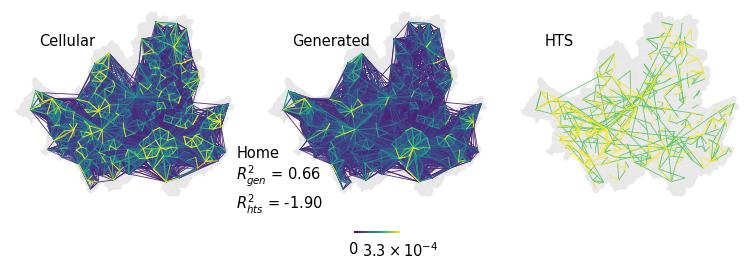

In [ ]:
# seoul_home_maps.py
# Figure B — HOME ONLY (1×3 interzone maps): Cellular / Generated / HTS
# - Colormap: viridis
# - Row-wise normalization shared within the TRIPLE (Home: Cellular vs Generated vs HTS)
# - Declutter: keep >= 95th percentile flows (optionally top-N)
# - Linewidth: constant (LW_MIN * 2)
# - Shared horizontal colorbar for the triple (axes [0,1,2])
# - Panel titles at (0.15, 0.85): "Cellular" / "Generated" / "HTS"
# - R² annotation on Generated panel at (-0.05, 0.35):
#       Home
#       R^2_gen = ...
#       R^2_hts = ...
#   where:
#     R^2_gen = R²(Cellular vs Generated) on overlapping (O,D)
#     R^2_hts = R²(Cellular vs HTS) on overlapping (O,D)
#
# You must define: path_data, path_result, path_figure in your runtime environment.

from __future__ import annotations

import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.collections import LineCollection
from shapely.geometry import LineString
from sklearn.metrics import r2_score


# -----------------------------
# Nature-style setup (same)
# -----------------------------
def set_nature_style() -> None:
    plt.rcParams.update({
        "figure.dpi": 150, "savefig.dpi": 150,
        "font.family": "DejaVu Sans", "font.size": 7,
        "axes.labelsize": 7, "axes.titlesize": 7,
        "legend.fontsize": 7, "xtick.labelsize": 7, "ytick.labelsize": 7,
        "axes.linewidth": 0.8, "lines.linewidth": 1.0, "patch.linewidth": 0.8,
        "xtick.direction": "in", "ytick.direction": "in",
        "xtick.major.size": 3.5, "ytick.major.size": 3.5,
        "xtick.minor.size": 2, "ytick.minor.size": 2,
        "legend.frameon": False,
        "savefig.bbox": "tight", "savefig.pad_inches": 0.02,
        "pdf.fonttype": 42, "ps.fonttype": 42,
    })


# -----------------------------
# Style knobs (MATCH reference)
# -----------------------------
CMAP_NAME = "viridis"
ROW_PERCENTILE = 0.98
FLOW_KEEP_Q = 0.95
FLOW_TOP_N = None
LW_MIN, LW_MAX = 0.2, 2.4  # LW_MAX unused (constant widths)


# -----------------------------
# Recodes / reshape (same logic)
# -----------------------------
TRIP_MAX = 7
AGE_RECODE = {2: 0, 3: 0, 4: 1, 5: 1, 6: 2, 7: 2}
PURPOSE_RECODE_HTS_FUS = {0: 0, 1: 1, 2: 2, 3: 2, 4: 2, 5: 2}
PURPOSE_RECODE_PCM = {"H": 0, "W": 1, "E": 2}


def _recode_age(df: pd.DataFrame, age_col: str = "AGE") -> pd.DataFrame:
    df = df[df[age_col] >= 2].copy()
    df[age_col] = df[age_col].replace(AGE_RECODE)
    return df


def reshape_trip(df: pd.DataFrame) -> pd.DataFrame:
    parts = []
    for i in range(1, TRIP_MAX + 1):
        cols_i = [
            f"TRIP_PURPOSE_{i}", f"TRAVEL_MODE_{i}",
            f"TRIP_STARTTIME_{i}", f"TRIP_ENDTIME_{i}",
            f"ORIGIN_SUBZONE_{i}", f"DESTINATION_SUBZONE_{i}",
        ]
        dff = df[["AGE", "GENDER", "TRIP_MAX"] + cols_i].copy()
        dff = dff.rename(columns={
            f"TRIP_PURPOSE_{i}": "TRIP_PURPOSE",
            f"TRAVEL_MODE_{i}": "TRAVEL_MODE",
            f"TRIP_STARTTIME_{i}": "TRIP_STARTTIME",
            f"TRIP_ENDTIME_{i}": "TRIP_ENDTIME",
            f"ORIGIN_SUBZONE_{i}": "ORIGIN_SUBZONE",
            f"DESTINATION_SUBZONE_{i}": "DESTINATION_SUBZONE",
        })
        parts.append(dff)
    return pd.concat(parts, ignore_index=True).dropna()


def prepare_pcm(df_pcm_raw: pd.DataFrame) -> pd.DataFrame:
    df = _recode_age(df_pcm_raw)
    if "COUNT" not in df.columns:
        df["COUNT"] = 1
    df["TRIP_PURPOSE"] = df["TRIP_PURPOSE"].replace(PURPOSE_RECODE_PCM)
    return df


def prepare_fus(df_tour_raw: pd.DataFrame) -> pd.DataFrame:
    # Use for BOTH generated tours and HTS tours (same structure)
    df = reshape_trip(df_tour_raw)
    df = _recode_age(df)
    df["COUNT"] = 1
    df["TRIP_PURPOSE"] = df["TRIP_PURPOSE"].replace(PURPOSE_RECODE_HTS_FUS)
    return df


# -----------------------------
# Geometry helpers (MATCH reference)
# -----------------------------
def _load_subzone(path_shp: str) -> gpd.GeoDataFrame:
    g = gpd.read_file(path_shp)[["SUBZONE_C", "geometry"]].copy()
    if g.crs is None:
        g.set_crs(epsg=4326, inplace=True)
    return g


def _centroids(gdf_sub: gpd.GeoDataFrame) -> pd.DataFrame:
    c = gdf_sub.copy()
    c["centroid"] = c.geometry.centroid
    return c[["SUBZONE_C", "centroid"]]


# -----------------------------
# OD aggregation + shares
# -----------------------------
def _od_group(df: pd.DataFrame) -> pd.DataFrame:
    cols = ["ORIGIN_SUBZONE", "DESTINATION_SUBZONE", "TRIP_STARTTIME", "TRIP_PURPOSE", "COUNT"]
    t = df[cols].copy()
    t["COUNT"] = t.groupby(cols[:-1], observed=True)["COUNT"].transform("sum")
    return t.drop_duplicates()


def _interzone_share(od_df: pd.DataFrame) -> pd.DataFrame:
    if od_df.empty:
        return pd.DataFrame(columns=["O", "D", "COUNT"])
    z = od_df[["ORIGIN_SUBZONE", "DESTINATION_SUBZONE", "COUNT"]].copy()
    z = z.rename(columns={"ORIGIN_SUBZONE": "O", "DESTINATION_SUBZONE": "D"})
    z = z.groupby(["O", "D"], observed=True, as_index=False)["COUNT"].sum()
    z = z[z["O"] != z["D"]]
    denom = float(z["COUNT"].sum())
    z["COUNT"] = 0.0 if denom <= 0 else (z["COUNT"] / denom)
    return z


def _declutter_flows(df: pd.DataFrame, keep_q: float = FLOW_KEEP_Q, top_n: int | None = FLOW_TOP_N) -> pd.DataFrame:
    if df.empty:
        return df
    out = df
    if keep_q is not None:
        thr = float(np.quantile(out["COUNT"], keep_q))
        out = out[out["COUNT"] >= thr]
    if top_n is not None and len(out) > top_n:
        out = out.nlargest(top_n, "COUNT")
    return out.copy()


def _build_lines(gdf_sub: gpd.GeoDataFrame, flows: pd.DataFrame) -> gpd.GeoDataFrame:
    if flows.empty:
        return gpd.GeoDataFrame({"COUNT": []}, geometry=[], crs=gdf_sub.crs)

    c = _centroids(gdf_sub)
    cO = c.rename(columns={"SUBZONE_C": "O", "centroid": "O_pt"})
    cD = c.rename(columns={"SUBZONE_C": "D", "centroid": "D_pt"})

    j = flows.merge(cO, on="O", how="left").merge(cD, on="D", how="left")
    j = j.dropna(subset=["O_pt", "D_pt"])

    geom = [LineString([o, d]) for o, d in zip(j["O_pt"], j["D_pt"])]
    return gpd.GeoDataFrame(j[["O", "D", "COUNT"]].copy(), geometry=geom, crs=gdf_sub.crs)


# -----------------------------
# Color scaling (TRIPLE)
# -----------------------------
def _row_norm_for_lines_triple(
    gA: gpd.GeoDataFrame,
    gB: gpd.GeoDataFrame,
    gC: gpd.GeoDataFrame,
    q: float = ROW_PERCENTILE,
) -> mpl.colors.Normalize:
    vals = np.r_[
        gA["COUNT"].to_numpy() if (gA is not None and not gA.empty and "COUNT" in gA) else np.array([]),
        gB["COUNT"].to_numpy() if (gB is not None and not gB.empty and "COUNT" in gB) else np.array([]),
        gC["COUNT"].to_numpy() if (gC is not None and not gC.empty and "COUNT" in gC) else np.array([]),
    ]
    if vals.size == 0 or np.all(vals == 0):
        vmax = 1.0
    else:
        vmax = float(np.quantile(vals, q))
        if vmax <= 0:
            vmax = float(vals.max() if vals.max() > 0 else 1.0)
    return mpl.colors.Normalize(vmin=0.0, vmax=vmax)


def _line_widths(counts: np.ndarray, norm: mpl.colors.Normalize, lw_min: float = LW_MIN, lw_max: float = LW_MAX) -> float:
    return lw_min * 2


# -----------------------------
# Plot helpers (MATCH reference)
# -----------------------------
def _plot_background(ax: plt.Axes, gdf_sub: gpd.GeoDataFrame) -> None:
    gdf_sub.plot(ax=ax, facecolor="#e8e8e8", edgecolor="none", linewidth=0.0)
    ax.set_axis_off()


def _plot_lines(ax: plt.Axes, gdf_lines: gpd.GeoDataFrame, cmap: str, norm: mpl.colors.Normalize) -> None:
    if gdf_lines.empty:
        return
    gdf_lines = gdf_lines.sort_values("COUNT", ascending=True).reset_index(drop=True)

    cmap_obj = cm.get_cmap(cmap)
    values = gdf_lines["COUNT"].to_numpy()
    colors = cmap_obj(norm(values))
    widths = _line_widths(values, norm)

    lines = [np.array(line.coords) for line in gdf_lines.geometry if line is not None]
    lc = LineCollection(
        lines,
        colors=colors,
        linewidths=widths,
        alpha=0.95,
        joinstyle="round",
        capstyle="round",
    )
    ax.add_collection(lc)


def _fmt_sci_mathtext(x: float, sig: int = 2) -> str:
    if x == 0:
        return r"$0$"
    exp = int(np.floor(np.log10(abs(x))))
    mant = x / (10 ** exp)
    mant_str = f"{mant:.{sig}g}"
    return rf"${mant_str}\times 10^{{{exp}}}$"


def _add_shared_cbar(fig: plt.Figure, axes_row, norm: mpl.colors.Normalize, cmap_name: str):
    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cm.get_cmap(cmap_name))
    sm.set_array([])
    cbar = fig.colorbar(
        sm,
        ax=axes_row,
        orientation="horizontal",
        fraction=0.01,
        pad=0.02,
    )
    cbar.outline.set_visible(False)

    vmin, vmax = float(norm.vmin), float(norm.vmax)
    cbar.set_ticks([vmin, vmax])
    cbar.ax.xaxis.get_offset_text().set_visible(False)
    cbar.set_ticklabels([_fmt_sci_mathtext(vmin, sig=2), _fmt_sci_mathtext(vmax, sig=2)])
    cbar.ax.tick_params(length=0, labelsize=7)
    return cbar


def _safe_r2(y_true, y_pred) -> float:
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    if y_true.size > 1 and np.var(y_true) > 0:
        return float(r2_score(y_true, y_pred))
    return float("nan")


# -----------------------------
# Public API: 1×3 maps (HOME) with reference styling
# -----------------------------
def compose_1x3_maps_home(
    df_pcm: pd.DataFrame,
    df_fus: pd.DataFrame,
    df_hts: pd.DataFrame,
    shp_path: str,
    *,
    home_val: int = 0,
    figsize: tuple[float, float] = (10.0, 3.0),
    save_path: str | None = None,
) -> plt.Figure:
    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=figsize)
    axes = np.asarray(axes)

    gdf_sub = _load_subzone(shp_path)

    sc = _od_group(df_pcm)
    fu = _od_group(df_fus)
    ht = _od_group(df_hts)

    sc_p = sc[sc["TRIP_PURPOSE"] == home_val]
    fu_p = fu[fu["TRIP_PURPOSE"] == home_val]
    ht_p = ht[ht["TRIP_PURPOSE"] == home_val]

    sc_flow = _declutter_flows(_interzone_share(sc_p))
    fu_flow = _declutter_flows(_interzone_share(fu_p))
    ht_flow = _declutter_flows(_interzone_share(ht_p))

    # R²_gen and R²_hts on common support
    m_gen = sc_flow.merge(fu_flow, on=["O", "D"], how="inner", suffixes=("_sc", "_gen"))
    r2_gen = _safe_r2(m_gen["COUNT_sc"], m_gen["COUNT_gen"]) if len(m_gen) else float("nan")

    m_hts = sc_flow.merge(ht_flow, on=["O", "D"], how="inner", suffixes=("_sc", "_hts"))
    r2_hts = _safe_r2(m_hts["COUNT_sc"], m_hts["COUNT_hts"]) if len(m_hts) else float("nan")

    g_sc = _build_lines(gdf_sub, sc_flow)
    g_fu = _build_lines(gdf_sub, fu_flow)
    g_ht = _build_lines(gdf_sub, ht_flow)

    norm = _row_norm_for_lines_triple(g_sc, g_fu, g_ht, ROW_PERCENTILE)

    # (a) Home – Cellular
    ax = axes[0]
    _plot_background(ax, gdf_sub)
    _plot_lines(ax, g_sc, CMAP_NAME, norm)
    ax.text(0.15, 0.85, "Cellular", transform=ax.transAxes, va="top", ha="left", fontsize=7)

    # (b) Home – Generated
    ax = axes[1]
    _plot_background(ax, gdf_sub)
    _plot_lines(ax, g_fu, CMAP_NAME, norm)
    ax.text(0.15, 0.85, "Generated", transform=ax.transAxes, va="top", ha="left", fontsize=7)

    if not (np.isnan(r2_gen) and np.isnan(r2_hts)):
        txt = "Home\n"
        txt += (rf"$R^2_{{gen}}$ = {r2_gen:.2f}" if not np.isnan(r2_gen) else r"$R^2_{gen}$ = NA")
        txt += "\n"
        txt += (rf"$R^2_{{hts}}$ = {r2_hts:.2f}" if not np.isnan(r2_hts) else r"$R^2_{hts}$ = NA")
        ax.text(
            -0.08, 0.3,
            txt,
            transform=ax.transAxes,
            fontsize=7,
            va="top",
            ha="left",
        )

    # (c) Home – HTS
    ax = axes[2]
    _plot_background(ax, gdf_sub)
    _plot_lines(ax, g_ht, CMAP_NAME, norm)
    ax.text(0.15, 0.85, "HTS", transform=ax.transAxes, va="top", ha="left", fontsize=7)

    # Shared colorbar for the triple
    _add_shared_cbar(fig, [axes[0], axes[1], axes[2]], norm, CMAP_NAME)

    plt.subplots_adjust(wspace=0.01, hspace=0.0, bottom=0.2)

    if save_path:
        fig.savefig(save_path + ".png", dpi=200)

    return fig


# -----------------------------
# MAIN
# -----------------------------
if __name__ == "__main__":
    set_nature_style()

    df_pcm_raw = pd.read_csv(os.path.join(path_data, "data_seoul_pcm_trip.csv"))
    if "TRIP_PURPOSE_" in df_pcm_raw.columns and "TRIP_PURPOSE" not in df_pcm_raw.columns:
        df_pcm_raw = df_pcm_raw.rename(columns={"TRIP_PURPOSE_": "TRIP_PURPOSE"})

    df_fus_tour_raw = pd.read_csv(os.path.join(path_result, "case_seoul_sim_tour_M_3000_income.csv"))

    # HTS tours (same structure as df_fus_tour_raw) - adjust filename
    df_hts_tour_raw = pd.read_csv(os.path.join(path_data, "data_seoul_hts_tour.csv"))

    df_pcm = prepare_pcm(df_pcm_raw)
    df_fus = prepare_fus(df_fus_tour_raw)
    df_hts = prepare_fus(df_hts_tour_raw)

    fig = compose_1x3_maps_home(
        df_pcm=df_pcm,
        df_fus=df_fus,
        df_hts=df_hts,
        shp_path=os.path.join(path_data, "data_seoul_subzone.shp"),
        home_val=0,  # Home
        figsize=(6.5, 2.0),
        save_path=os.path.join(path_figure, "case_seoul_1x3_maps_home"),
    )

    plt.show()


## Seoul age scatters

TRIP_PURPOSE
0    14938
2    13144
1    11040
Name: count, dtype: int64
TRIP_PURPOSE
2    12945394
0     9987952
1     5758037
Name: count, dtype: int64
TRIP_PURPOSE
2    45480066
0    44243158
1    31397168
Name: count, dtype: int64
AGE
1    16551
2    15775
3     6122
0      674
Name: count, dtype: int64
AGE
1    10625817
2     9795029
0     4178886
3     4091651
Name: count, dtype: int64
AGE
1    48623141
2    46770261
3    23724782
0     2002208
Name: count, dtype: int64


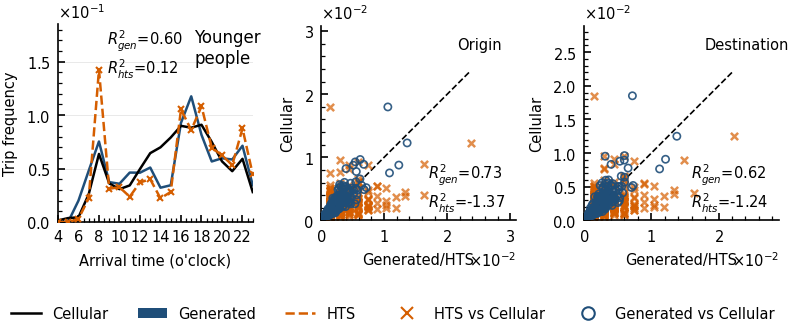

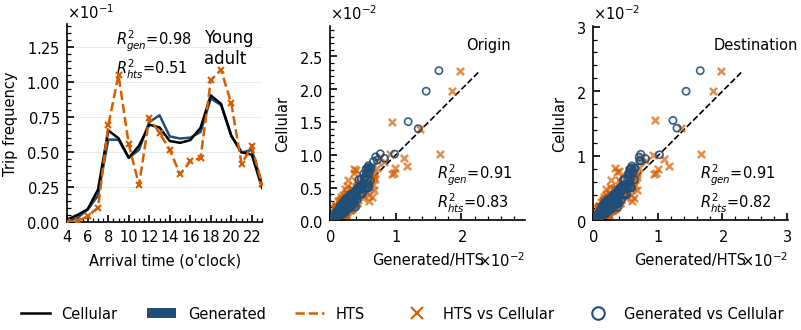

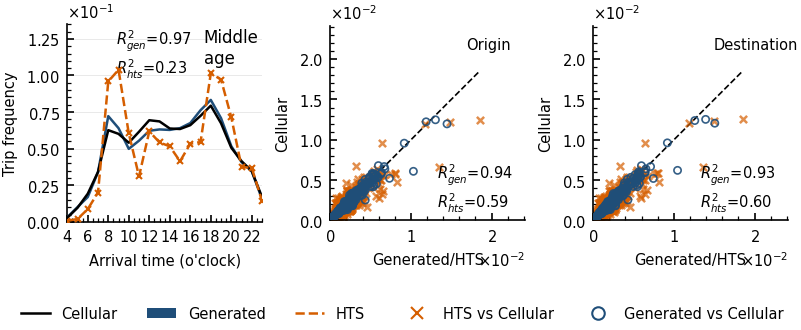

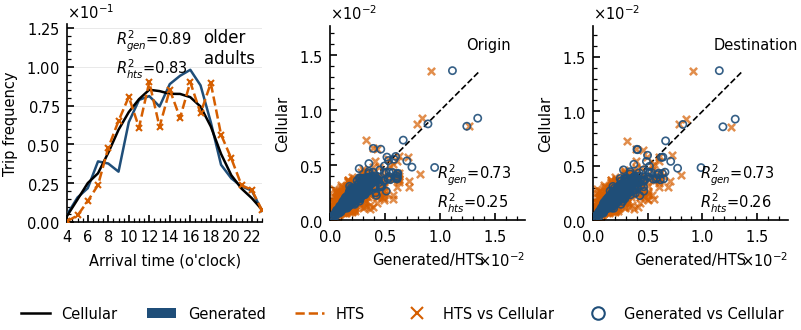

In [ ]:
# seoul_age_plots_nature.py
# ------------------------------------------------------------
# Nature-style plots — AGE GROUPS ONLY (no trip-purpose logic)
#
# For each AGE group (0/1/2 after recode), create ONE figure (1×3):
#   [Arrival time, Origin, Destination]
#
# Styling matches seoul_home_plots_nature.py:
#   - COLORS (Cellular black, Generated orange, HTS blue)
#   - Line panel: bars (Generated) + lines (Cellular + HTS) + R² text at (0.25, 0.98)
#   - Scatter panels: diagonal + markers + R² text at (0.55, 0.30)
#   - Two legends at bottom with same anchors
#   - Default figsize (6.2, 2.2) and spacing
#
# Input files expected (same as your pipeline):
#   - data_seoul_hts_trip.csv
#   - data_seoul_pcm_trip.csv
#   - case_seoul_sim_tour_z1_income.csv   (tour-level, will be reshaped)
#
# You must define: path_data, path_result, path_figure in your runtime environment.
# ------------------------------------------------------------

from __future__ import annotations

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter, AutoMinorLocator, MultipleLocator
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from sklearn.metrics import r2_score

# =========================
# Global config
# =========================
TRIP_MAX = 7

# =========================
# Nature-style setup
# =========================
def set_nature_style() -> None:
    plt.rcParams.update({
        "figure.dpi": 150, "savefig.dpi": 150,
        "font.family": "DejaVu Sans", "font.size": 7,
        "axes.labelsize": 7, "axes.titlesize": 7,
        "legend.fontsize": 7, "xtick.labelsize": 7, "ytick.labelsize": 7,
        "axes.linewidth": 0.8, "lines.linewidth": 1.2, "patch.linewidth": 0.8,
        "xtick.direction": "in", "ytick.direction": "in",
        "xtick.major.size": 3.5, "ytick.major.size": 3.5,
        "xtick.minor.size": 2, "ytick.minor.size": 2,
        "legend.frameon": False,
        "savefig.bbox": "tight", "savefig.pad_inches": 0.02,
        "pdf.fonttype": 42, "ps.fonttype": 42,
    })


COLORS = {
    "true": "#000000",
    "hts":  "#D55E00",   # orange-red
    "sim":  "#1F4E79",    # deep blue
    "diag": "#000000",
}


AX_LABELS = {
    "TRIP_STARTTIME": "Departure time (o'clock)",
    "TRIP_ENDTIME":   "Arrival time (o'clock)",
}


def _format_axis_sci(ax: plt.Axes, which: str = "both") -> None:
    fmt = ScalarFormatter(useMathText=True)
    fmt.set_powerlimits((0, 0))
    if which in ("x", "both"):
        ax.xaxis.set_major_formatter(fmt)
    if which in ("y", "both"):
        ax.yaxis.set_major_formatter(fmt)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())


def _beautify_axes(ax: plt.Axes, grid: bool = True) -> None:
    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)
    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)
    if grid:
        ax.grid(axis="y", which="major", linewidth=0.3, color="#DDDDDD")
    ax.tick_params(width=0.8, length=3.5)
    ax.tick_params(which="minor", width=0.6, length=2)


def _safe_r2(y_true, y_pred) -> float:
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    if y_true.size > 1 and np.var(y_true) > 0:
        return float(r2_score(y_true, y_pred))
    return float("nan")


def get_max_pop(df: pd.DataFrame) -> float:
    cand_cols = [c for c in df.columns if c.startswith("Pop_")]
    if not cand_cols or df.empty:
        return 0.0
    return float(df[cand_cols].max().max())


# ============================================================
# Data preparation (AGE ONLY)
# ============================================================
# Same age recode you used:
#   AGE in {2,3}->{0}, {4,5}->{1}, {6,7}->{2}
AGE_RECODE = {0: 0, 1: 1, 2: 2, 3: 3}
PURPOSE_RECODE_HTS_FUS = {0: 0, 1: 1, 2: 2, 3: 2, 4: 2, 5: 2}  # keeps Work=1, Other=2
PURPOSE_RECODE_PCM = {"H": 0, "W": 1, "E": 2}  # assumes E corresponds to Other


def reshape_trip(df: pd.DataFrame) -> pd.DataFrame:
    """Tour-wide columns (TRIP_*_i) -> long trips."""
    parts = []
    for i in range(1, TRIP_MAX + 1):
        cols_i = [
            f"TRIP_PURPOSE_{i}", f"TRAVEL_MODE_{i}",
            f"TRIP_STARTTIME_{i}", f"TRIP_ENDTIME_{i}",
            f"ORIGIN_SUBZONE_{i}", f"DESTINATION_SUBZONE_{i}",
        ]
        dff = df[["AGE", "GENDER", "TRIP_MAX"] + cols_i].copy()
        dff.rename(columns={
            f"TRIP_PURPOSE_{i}": "TRIP_PURPOSE",      # kept but unused
            f"TRAVEL_MODE_{i}": "TRAVEL_MODE",        # kept but unused
            f"TRIP_STARTTIME_{i}": "TRIP_STARTTIME",
            f"TRIP_ENDTIME_{i}": "TRIP_ENDTIME",
            f"ORIGIN_SUBZONE_{i}": "ORIGIN_SUBZONE",
            f"DESTINATION_SUBZONE_{i}": "DESTINATION_SUBZONE",
        }, inplace=True)
        parts.append(dff)

    out = pd.concat(parts, ignore_index=True)
    out.dropna(inplace=True)
    return out


def _recode_age(df: pd.DataFrame, age_col: str = "AGE") -> pd.DataFrame:
    #df = df[df[age_col] >= 2].copy()
    #df[age_col] = df[age_col].replace(AGE_RECODE)
    return df


def prepare_hts(df_hts: pd.DataFrame) -> pd.DataFrame:
    df = _recode_age(df_hts)
    df["COUNT"] = 1
    df["TRIP_PURPOSE"] = df["TRIP_PURPOSE"].replace(PURPOSE_RECODE_HTS_FUS)
    return df


def prepare_pcm(df_pcm: pd.DataFrame) -> pd.DataFrame:
    df = _recode_age(df_pcm)
    if "COUNT" not in df.columns:
        df["COUNT"] = 1
    df["TRIP_PURPOSE"] = df["TRIP_PURPOSE"].replace(PURPOSE_RECODE_PCM)
    return df


def prepare_fus(df_fus_tour: pd.DataFrame) -> pd.DataFrame:
    df = reshape_trip(df_fus_tour)
    df = _recode_age(df)
    df["COUNT"] = 1
    df["TRIP_PURPOSE"] = df["TRIP_PURPOSE"].replace(PURPOSE_RECODE_HTS_FUS)
    return df

def prepare_fus_bk(df: pd.DataFrame) -> pd.DataFrame:
    df = _recode_age(df)
    df["COUNT"] = df["Prob_XYZ_fus"]
    df["TRIP_PURPOSE"] = df["TRIP_PURPOSE"].replace(PURPOSE_RECODE_HTS_FUS)
    return df


# ============================================================
# Probability computation (conditional on AGE)
# ============================================================
def prob_att_age(df: pd.DataFrame, att: list[str], age_val: int, suffix: str) -> pd.DataFrame:
    """
    Normalized frequency distribution for `att`, restricted to AGE == age_val.
    Output: att + [f'Pop_{suffix}'].
    """
    dff = df.loc[df["AGE"] == age_val, att + ["COUNT"]].copy()
    if dff.empty:
        return pd.DataFrame(columns=att + [f"Pop_{suffix}"])

    dff["COUNT"] = dff.groupby(att, observed=True)["COUNT"].transform("sum")
    dff = dff.drop_duplicates()
    denom = float(dff["COUNT"].sum())
    dff[f"Pop_{suffix}"] = (dff["COUNT"] / denom) if denom > 0 else 0.0
    dff = dff.drop(columns=["COUNT"]).sort_values(att)
    return dff


# ============================================================
# Plot helpers (MATCH seoul_home_plots_nature.py)
# ============================================================
def plot_line_ax(ax: plt.Axes, df: pd.DataFrame, att: str) -> None:
    """Time distribution: bar (Generated) + lines (Cellular, HTS) + R²."""
    d = df.copy()
    d[att] = pd.to_numeric(d[att], errors="coerce")
    d = d.sort_values(att)

    ax.plot(
        d[att], d["Pop_sim"],
        color=COLORS["sim"], label="Generated", zorder=3,
    )
    ax.plot(d[att], d["Pop_true"], color=COLORS["true"], linestyle="-", label="Cellular", zorder=3)
    ax.plot(
        d[att], d["Pop_hts"],
        color=COLORS["hts"], linestyle="--",
        marker="x", markersize=2.5, label="HTS", zorder=4,
    )

    ax.set_xlabel(AX_LABELS.get(att, att))
    ax.set_ylabel("Trip frequency")

    if att in {"TRIP_STARTTIME", "TRIP_ENDTIME"}:
        ax.set_xlim(4, 23)
        ax.set_xticks(np.arange(4, 24, 2))
        ax.xaxis.set_minor_locator(MultipleLocator(1))

    _format_axis_sci(ax, which="y")
    _beautify_axes(ax)

    maxz = get_max_pop(d)
    ax.set_ylim(0, 1.3 * maxz if maxz > 0 else 1.0)

    r2_gen = _safe_r2(d["Pop_true"], d["Pop_sim"])
    r2_hts = _safe_r2(d["Pop_true"], d["Pop_hts"])

    lines = []
    if not np.isnan(r2_gen):
        lines.append(f"$R^2_{{gen}}$={r2_gen:.2f}")
    if not np.isnan(r2_hts):
        lines.append(f"$R^2_{{hts}}$={r2_hts:.2f}")
    if lines:
        ax.text(
            0.25, 0.98, "\n".join(lines),
            transform=ax.transAxes, fontsize=7,
            va="top", ha="left",
        )


def plot_point_ax(ax: plt.Axes, df: pd.DataFrame) -> None:
    """OD marginal scatter: (Generated vs Cellular) + (HTS vs Cellular) + R²."""
    df_hts_vis = df[(df["Pop_true"] > 0) & (df["Pop_hts"] > 0)].copy()
    df_gen_vis = df[(df["Pop_true"] > 0) & (df["Pop_sim"] > 0)].copy()

    limit = 0.0
    if len(df_hts_vis):
        limit = max(limit, float(df_hts_vis[["Pop_true", "Pop_hts"]].to_numpy().max()))
    if len(df_gen_vis):
        limit = max(limit, float(df_gen_vis[["Pop_true", "Pop_sim"]].to_numpy().max()))
    if limit == 0.0:
        limit = 1.0

    ax.plot([0, limit], [0, limit], linestyle="--",
            color=COLORS["true"], linewidth=0.8, zorder=1)

    if len(df_hts_vis):
        ax.scatter(
            df_hts_vis["Pop_hts"], df_hts_vis["Pop_true"],
            s=12, marker="x", color=COLORS["hts"], alpha=0.7,
            label="HTS vs Cellular", zorder=2,
        )
    if len(df_gen_vis):
        ax.scatter(
            df_gen_vis["Pop_sim"], df_gen_vis["Pop_true"],
            s=12, facecolor="none", edgecolor=COLORS["sim"],
            linewidth=0.8, alpha=0.9,
            label="Generated vs Cellular", zorder=3,
        )

    ax.set_xlim(0, 1.3 * limit)
    ax.set_ylim(0, 1.3 * limit)
    ax.set_aspect("equal", adjustable="box")

    ax.set_xlabel("Generated/HTS")
    ax.set_ylabel("Cellular")
    _format_axis_sci(ax)
    _beautify_axes(ax, grid=False)

    r2_gen = _safe_r2(df_gen_vis["Pop_true"], df_gen_vis["Pop_sim"]) if len(df_gen_vis) else np.nan
    r2_hts = _safe_r2(df_hts_vis["Pop_true"], df_hts_vis["Pop_hts"]) if len(df_hts_vis) else np.nan

    lines = []
    if not np.isnan(r2_gen):
        lines.append(f"$R^2_{{gen}}$={r2_gen:.2f}")
    if not np.isnan(r2_hts):
        lines.append(f"$R^2_{{hts}}$={r2_hts:.2f}")
    if lines:
        ax.text(
            0.55, 0.30, "\n".join(lines),
            transform=ax.transAxes, fontsize=7,
            va="top", ha="left",
        )


# ============================================================
# Composer: ONE FIGURE PER AGE GROUP (1×3)
# ============================================================
def compose_age_1x3(
    df_pcm: pd.DataFrame,
    df_hts: pd.DataFrame,
    df_fus: pd.DataFrame,
    *,
    age_val: int,
    age_label: str,
    time_att: str = "TRIP_ENDTIME",
    figsize: tuple[float, float] = (6.2, 2.2),
    save_path: str | None = None,
) -> plt.Figure:
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    axes = np.atleast_1d(axes)

    def _assemble_time():
        d_sim  = prob_att_age(df_fus, [time_att], age_val, "sim")
        d_true = prob_att_age(df_pcm, [time_att], age_val, "true")
        d_hts  = prob_att_age(df_hts, [time_att], age_val, "hts")
        return (
            d_true.merge(d_sim,  on=[time_att], how="outer")
                  .merge(d_hts,  on=[time_att], how="outer")
                  .fillna(0)
                  .sort_values(time_att)
        )

    def _assemble_scatter(col: str):
        a_sim  = prob_att_age(df_fus, [col], age_val, "sim")
        a_true = prob_att_age(df_pcm, [col], age_val, "true")
        a_hts  = prob_att_age(df_hts, [col], age_val, "hts")
        # keep inner for stable apples-to-apples on common zones
        return (
            a_true.merge(a_sim, on=[col], how="inner")
                  .merge(a_hts, on=[col], how="inner")
        )

    # Arrival time
    t = _assemble_time()
    plot_line_ax(axes[0], t, time_att)
    axes[0].text(0.70, 0.98, age_label, transform=axes[0].transAxes,
                 va="top", ha="left", fontsize=8)

    # Origin
    o = _assemble_scatter("ORIGIN_SUBZONE")
    plot_point_ax(axes[1], o)
    axes[1].text(0.70, 0.94, "Origin", transform=axes[1].transAxes,
                 va="top", ha="left", fontsize=7)

    # Destination
    d = _assemble_scatter("DESTINATION_SUBZONE")
    plot_point_ax(axes[2], d)
    axes[2].text(0.62, 0.94, "Destination", transform=axes[2].transAxes,
                 va="top", ha="left", fontsize=7)

    # Layout + Legends (match HOME script)
    plt.subplots_adjust(wspace=0.35, hspace=0.0, bottom=0.28)

    legend1 = [
        Line2D([0], [0], color=COLORS["true"], lw=1.2, label="Cellular"),
        Patch(facecolor=COLORS["sim"], edgecolor="none", label="Generated"),
        Line2D([0], [0], color=COLORS["hts"], lw=1.2, ls="--", label="HTS"),
    ]
    fig.legend(
        legend1, ["Cellular", "Generated", "HTS"],
        loc="lower center", bbox_to_anchor=(0.26, -0.06),
        ncol=3, frameon=False,
    )

    legend2 = [
        Line2D([], [], marker="x", linestyle="None",
               markerfacecolor=COLORS["hts"], markeredgecolor=COLORS["hts"],
               markersize=6, label="HTS vs Cellular"),
        Line2D([], [], marker="o", linestyle="None",
               markerfacecolor="none", markeredgecolor=COLORS["sim"],
               markersize=6, label="Generated vs Cellular"),
    ]
    fig.legend(
        legend2, ["HTS vs Cellular", "Generated vs Cellular"],
        loc="lower center", bbox_to_anchor=(0.69, -0.06),
        ncol=2, frameon=False,
    )

    if save_path:
        #fig.savefig(save_path + ".pdf", dpi=600, bbox_inches="tight")
        fig.savefig(save_path + ".pdf", dpi=200, bbox_inches="tight")

    return fig


# ============================================================
# MAIN
# ============================================================
if __name__ == "__main__":
    set_nature_style()

     # -------- Load --------
    df_hts_raw = pd.read_csv(os.path.join(path_data, "data_seoul_hts_trip.csv"))

    df_pcm_raw = pd.read_csv(os.path.join(path_data, "data_seoul_pcm_trip.csv"))

    df_hts_raw['AGE'].replace([i for i in range(8)], [0, 0, 1, 1, 2, 2, 3, 3], inplace=True)
    df_pcm_raw['AGE'].replace([i for i in range(8)], [0, 0, 1, 1, 2, 2, 3, 3], inplace=True)

    if "TRIP_PURPOSE_" in df_pcm_raw.columns and "TRIP_PURPOSE" not in df_pcm_raw.columns:
        df_pcm_raw.rename(columns={"TRIP_PURPOSE_": "TRIP_PURPOSE"}, inplace=True)

    reg = 'seoul'
    KK = 6000
    nb = 10
    RANDOM_SEED = 12345

    #df_fus_tour_raw = pd.read_csv(path_result +  f"case_{reg}_sim_tour_M_{KK}_nb_{nb}_seed_{RANDOM_SEED}.csv")
    #df_fus = prepare_fus(df_fus_tour_raw)

    df_fus =  pd.read_csv(path_result +  f"case_{reg}_sim_trip_M_{KK}_nb_{nb}_seed_{RANDOM_SEED}.csv")
    df_fus["COUNT"] = df_fus["Prob_XYZ_fus"]

    df_fus["TRIP_PURPOSE"] = df_fus["TRIP_PURPOSE"].replace(PURPOSE_RECODE_HTS_FUS)

    # -------- Prepare --------
    df_hts = prepare_hts(df_hts_raw)
    df_pcm = prepare_pcm(df_pcm_raw)

    print(df_hts['TRIP_PURPOSE'].value_counts())
    print(df_pcm['TRIP_PURPOSE'].value_counts())
    print(df_fus['TRIP_PURPOSE'].value_counts())

    print(df_hts['AGE'].value_counts())
    print(df_pcm['AGE'].value_counts())
    print(df_fus['AGE'].value_counts())

    # -------- One figure per age group --------
    age_specs = [
        (0, "Younger\npeople"),
        (1, "Young\nadult"),
        (2, "Middle\nage"),
        (3, "older\nadults"),
    ]

    for age_val, age_label in age_specs:
        fig = compose_age_1x3(
            df_pcm=df_pcm,
            df_hts=df_hts,
            df_fus=df_fus,
            age_val=age_val,
            age_label=age_label,
            time_att="TRIP_ENDTIME",
            figsize=(6.2, 2.2),
            save_path=os.path.join(path_figure, f"case_seoul_1x3_age_{age_val}"),
        )

    plt.show()


## Seoul age map

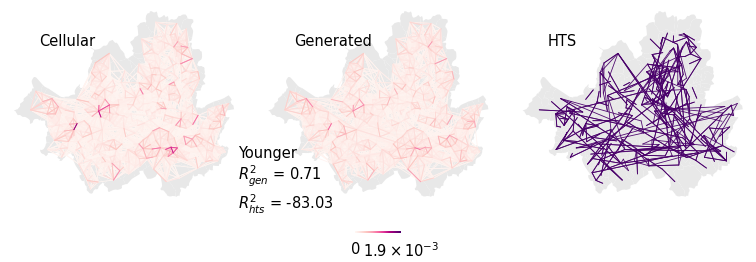

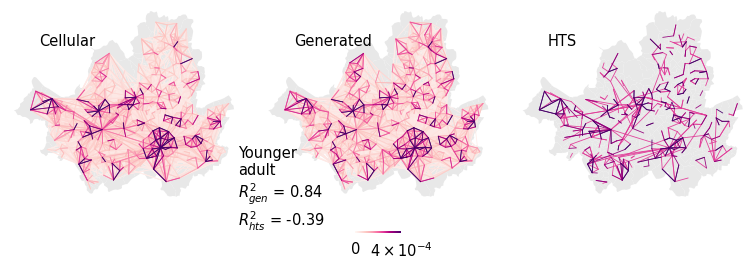

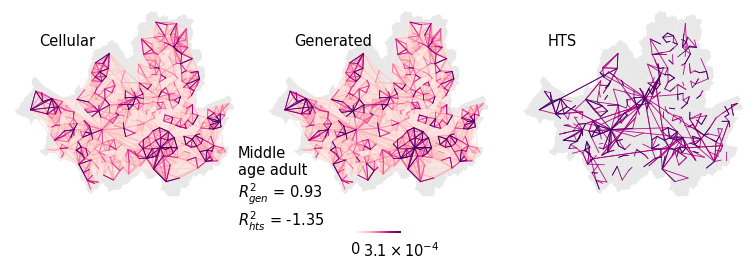

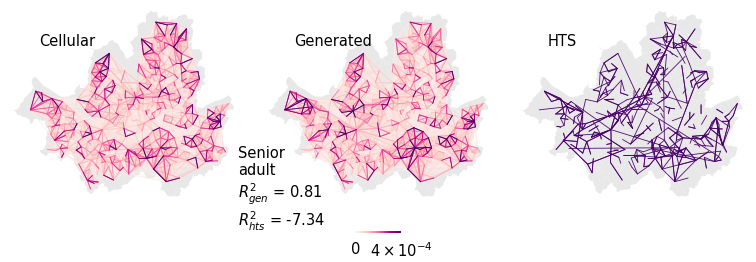

In [ ]:
# seoul_age_only_maps.py
# ------------------------------------------------------------
# AGE-ONLY interzone maps (now with HTS added).
#
# Output: separate figures; one per AGE group (after recode to {0,1,2})
#   Figure (per age group): 1×3
#     [Cellular interzone map, Generated interzone map, HTS interzone map]
#     + shared horizontal colorbar (TRIPLE; row-wise normalization shared)
#     + declutter (>= 95th percentile, optional top-N)
#     + constant linewidth (LW_MIN * 2)
#     + R² badge on Generated map at (-0.05, 0.35):
#           <age_label>
#           R^2_gen = ...
#           R^2_hts = ...
#       where:
#         R^2_gen = R²(Cellular vs Generated) on overlapping (O,D)
#         R^2_hts = R²(Cellular vs HTS) on overlapping (O,D)
#     + panel titles at (0.15, 0.85): "Cellular" / "Generated" / "HTS"
#
# You must define: path_data, path_result, path_figure in your runtime environment.
# ------------------------------------------------------------

from __future__ import annotations

import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.collections import LineCollection
from shapely.geometry import LineString
from sklearn.metrics import r2_score

# =========================
# Nature-style setup
# =========================
def set_nature_style() -> None:
    plt.rcParams.update({
        "figure.dpi": 150, "savefig.dpi": 150,
        "font.family": "DejaVu Sans", "font.size": 7,
        "axes.labelsize": 7, "axes.titlesize": 7,
        "legend.fontsize": 7, "xtick.labelsize": 7, "ytick.labelsize": 7,
        "axes.linewidth": 0.8, "lines.linewidth": 1.0, "patch.linewidth": 0.8,
        "xtick.direction": "in", "ytick.direction": "in",
        "xtick.major.size": 3.5, "ytick.major.size": 3.5,
        "xtick.minor.size": 2, "ytick.minor.size": 2,
        "legend.frameon": False,
        "savefig.bbox": "tight", "savefig.pad_inches": 0.02,
        "pdf.fonttype": 42, "ps.fonttype": 42,
    })

# =========================
# Map styling knobs (MATCH reference)
# =========================
CMAP_NAME = "RdPu"
ROW_PERCENTILE = 0.98
FLOW_KEEP_Q = 0.95
FLOW_TOP_N: int | None = None
LW_MIN = 0.2  # constant width = LW_MIN * 2

# =========================
# AGE recode
# =========================
TRIP_MAX = 7
AGE_RECODE = {0:0, 1:0, 2:1, 3: 1, 4: 2, 5: 2, 6: 3, 7: 3}

# =========================
# Small utilities
# =========================
def _safe_r2(y_true, y_pred) -> float:
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    if y_true.size > 1 and np.var(y_true) > 0:
        return float(r2_score(y_true, y_pred))
    return float("nan")

def _recode_age(df: pd.DataFrame, age_col: str = "AGE") -> pd.DataFrame:
    return df

# =========================
# Trip-table preparation (AGE-only)
# =========================
def reshape_trip(df_tour: pd.DataFrame) -> pd.DataFrame:
    """Tour-level (TRIP_*_i) -> long trip-level, keeping only map-relevant fields."""
    parts = []
    for i in range(1, TRIP_MAX + 1):
        cols_i = [
            f"TRIP_STARTTIME_{i}",
            f"ORIGIN_SUBZONE_{i}",
            f"DESTINATION_SUBZONE_{i}",
        ]
        dff = df_tour[["AGE", "GENDER", "TRIP_MAX"] + cols_i].copy()
        dff = dff.rename(columns={
            f"TRIP_STARTTIME_{i}": "TRIP_STARTTIME",
            f"ORIGIN_SUBZONE_{i}": "ORIGIN_SUBZONE",
            f"DESTINATION_SUBZONE_{i}": "DESTINATION_SUBZONE",
        })
        parts.append(dff)
    out = pd.concat(parts, ignore_index=True).dropna()
    return out

def prepare_pcm(df_pcm_raw: pd.DataFrame) -> pd.DataFrame:
    """PCM/smart-card trip table for maps."""
    df = _recode_age(df_pcm_raw)
    return df[["AGE", "TRIP_STARTTIME", "ORIGIN_SUBZONE", "DESTINATION_SUBZONE", "COUNT"]].copy()

def prepare_tour_like(df_tour_raw: pd.DataFrame) -> pd.DataFrame:
    """Tour-like table (Generated OR HTS) -> trip table for maps."""
    df = reshape_trip(df_tour_raw)
    df = _recode_age(df)
    df["COUNT"] = 1
    return df[["AGE", "TRIP_STARTTIME", "ORIGIN_SUBZONE", "DESTINATION_SUBZONE", "COUNT"]].copy()

# =========================
# Geometry helpers
# =========================
def _load_subzone(path_shp: str) -> gpd.GeoDataFrame:
    g = gpd.read_file(path_shp)[["SUBZONE_C", "geometry"]].copy()
    if g.crs is None:
        g.set_crs(epsg=4326, inplace=True)
    return g

def _centroids(gdf_sub: gpd.GeoDataFrame) -> pd.DataFrame:
    c = gdf_sub.copy()
    c["centroid"] = c.geometry.centroid
    return c[["SUBZONE_C", "centroid"]]

# =========================
# OD aggregation + interzone shares
# =========================
def _od_group_age(df: pd.DataFrame) -> pd.DataFrame:
    cols = ["ORIGIN_SUBZONE", "DESTINATION_SUBZONE", "TRIP_STARTTIME", "AGE", "COUNT"]
    t = df[cols].copy()
    t["COUNT"] = t.groupby(cols[:-1], observed=True)["COUNT"].transform("sum")
    return t.drop_duplicates()

def _interzone_share(od_df: pd.DataFrame) -> pd.DataFrame:
    """(O,D,COUNT) shares, interzone only."""
    if od_df.empty:
        return pd.DataFrame(columns=["O", "D", "COUNT"])

    z = od_df[["ORIGIN_SUBZONE", "DESTINATION_SUBZONE", "COUNT"]].copy()
    z = z.rename(columns={"ORIGIN_SUBZONE": "O", "DESTINATION_SUBZONE": "D"})
    z = z.groupby(["O", "D"], observed=True, as_index=False)["COUNT"].sum()
    z = z[z["O"] != z["D"]]

    denom = float(z["COUNT"].sum())
    z["COUNT"] = 0.0 if denom <= 0 else (z["COUNT"] / denom)
    return z

def _declutter_flows(df: pd.DataFrame, keep_q: float = FLOW_KEEP_Q, top_n: int | None = FLOW_TOP_N) -> pd.DataFrame:
    if df.empty:
        return df
    out = df
    if keep_q is not None:
        thr = float(np.quantile(out["COUNT"], keep_q))
        out = out[out["COUNT"] >= thr]
    if top_n is not None and len(out) > top_n:
        out = out.nlargest(top_n, "COUNT")
    return out.copy()

def _build_lines(gdf_sub: gpd.GeoDataFrame, flows: pd.DataFrame) -> gpd.GeoDataFrame:
    if flows.empty:
        return gpd.GeoDataFrame({"COUNT": []}, geometry=[], crs=gdf_sub.crs)

    c = _centroids(gdf_sub)
    cO = c.rename(columns={"SUBZONE_C": "O", "centroid": "O_pt"})
    cD = c.rename(columns={"SUBZONE_C": "D", "centroid": "D_pt"})

    j = flows.merge(cO, on="O", how="left").merge(cD, on="D", how="left")
    j = j.dropna(subset=["O_pt", "D_pt"])
    geom = [LineString([o, d]) for o, d in zip(j["O_pt"], j["D_pt"])]
    return gpd.GeoDataFrame(j[["O", "D", "COUNT"]].copy(), geometry=geom, crs=gdf_sub.crs)

# =========================
# Normalization + plotting
# =========================
def _row_norm_for_lines_triple(
    gA: gpd.GeoDataFrame,
    gB: gpd.GeoDataFrame,
    gC: gpd.GeoDataFrame,
    q: float = ROW_PERCENTILE
) -> mpl.colors.Normalize:
    vals = np.r_[
        gA["COUNT"].to_numpy() if (gA is not None and not gA.empty) else np.array([]),
        gB["COUNT"].to_numpy() if (gB is not None and not gB.empty) else np.array([]),
        gC["COUNT"].to_numpy() if (gC is not None and not gC.empty) else np.array([]),
    ]
    if vals.size == 0 or np.all(vals == 0):
        vmax = 1.0
    else:
        vmax = float(np.quantile(vals, q))
        if vmax <= 0:
            vmax = float(vals.max() if vals.max() > 0 else 1.0)
    return mpl.colors.Normalize(vmin=0.0, vmax=vmax)

def _plot_background(ax: plt.Axes, gdf_sub: gpd.GeoDataFrame) -> None:
    gdf_sub.plot(ax=ax, facecolor="#e8e8e8", edgecolor="none", linewidth=0.0)
    ax.set_axis_off()

def _plot_lines(ax: plt.Axes, gdf_lines: gpd.GeoDataFrame, cmap: str, norm: mpl.colors.Normalize) -> None:
    if gdf_lines.empty:
        return

    gdf_lines = gdf_lines.sort_values("COUNT", ascending=True).reset_index(drop=True)
    cmap_obj = cm.get_cmap(cmap)

    values = gdf_lines["COUNT"].to_numpy()
    colors = cmap_obj(norm(values))
    widths = LW_MIN * 2  # constant (reference)

    lines = [np.array(line.coords) for line in gdf_lines.geometry if line is not None]
    lc = LineCollection(
        lines,
        colors=colors,
        linewidths=widths,
        alpha=0.95,
        joinstyle="round",
        capstyle="round",
    )
    ax.add_collection(lc)

def _fmt_sci_mathtext(x: float, sig: int = 2) -> str:
    if x == 0:
        return r"$0$"
    exp = int(np.floor(np.log10(abs(x))))
    mant = x / (10 ** exp)
    mant_str = f"{mant:.{sig}g}"
    return rf"${mant_str}\times 10^{{{exp}}}$"

def _add_shared_cbar(fig: plt.Figure, axes_triple, norm: mpl.colors.Normalize, cmap_name: str):
    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cm.get_cmap(cmap_name))
    sm.set_array([])

    cbar = fig.colorbar(
        sm,
        ax=axes_triple,
        orientation="horizontal",
        fraction=0.01,
        pad=0.02,
    )
    cbar.outline.set_visible(False)

    vmin, vmax = float(norm.vmin), float(norm.vmax)
    cbar.set_ticks([vmin, vmax])
    cbar.ax.xaxis.get_offset_text().set_visible(False)
    cbar.set_ticklabels([_fmt_sci_mathtext(vmin, sig=2), _fmt_sci_mathtext(vmax, sig=2)])
    cbar.ax.tick_params(length=0, labelsize=7)
    return cbar

# =========================
# Public API: 1×3 maps per AGE group
# =========================
def plot_age_row_interzone_maps(
    df_pcm: pd.DataFrame,
    df_fus: pd.DataFrame,
    df_hts: pd.DataFrame,
    shp_path: str,
    *,
    age_val: int,
    age_label: str,
    figsize: tuple[float, float] = (10.0, 3.0),
    save_path: str | None = None,
) -> plt.Figure:
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    axes = np.asarray(axes)

    gdf_sub = _load_subzone(shp_path)

    sc = _od_group_age(df_pcm)
    fu = _od_group_age(df_fus)
    ht = _od_group_age(df_hts)

    sc_a = sc[sc["AGE"] == age_val]
    fu_a = fu[fu["AGE"] == age_val]
    ht_a = ht[ht["AGE"] == age_val]

    sc_flow = _declutter_flows(_interzone_share(sc_a))
    fu_flow = _declutter_flows(_interzone_share(fu_a))
    ht_flow = _declutter_flows(_interzone_share(ht_a))

    # R²_gen and R²_hts on common support
    m_gen = sc_flow.merge(fu_flow, on=["O", "D"], how="inner", suffixes=("_sc", "_gen"))
    r2_gen = _safe_r2(m_gen["COUNT_sc"], m_gen["COUNT_gen"]) if len(m_gen) else float("nan")

    m_hts = sc_flow.merge(ht_flow, on=["O", "D"], how="inner", suffixes=("_sc", "_hts"))
    r2_hts = _safe_r2(m_hts["COUNT_sc"], m_hts["COUNT_hts"]) if len(m_hts) else float("nan")

    g_sc = _build_lines(gdf_sub, sc_flow)
    g_fu = _build_lines(gdf_sub, fu_flow)
    g_ht = _build_lines(gdf_sub, ht_flow)

    norm = _row_norm_for_lines_triple(g_sc, g_fu, g_ht, ROW_PERCENTILE)

    # (a) Cellular
    ax0 = axes[0]
    _plot_background(ax0, gdf_sub)
    _plot_lines(ax0, g_sc, CMAP_NAME, norm)
    ax0.text(0.15, 0.85, "Cellular", transform=ax0.transAxes, va="top", ha="left", fontsize=7)

    # (b) Generated
    ax1 = axes[1]
    _plot_background(ax1, gdf_sub)
    _plot_lines(ax1, g_fu, CMAP_NAME, norm)
    ax1.text(0.15, 0.85, "Generated", transform=ax1.transAxes, va="top", ha="left", fontsize=7)

    if not (np.isnan(r2_gen) and np.isnan(r2_hts)):
        txt = f"{age_label}\n"
        txt += (rf"$R^2_{{gen}}$ = {r2_gen:.2f}" if not np.isnan(r2_gen) else r"$R^2_{gen}$ = NA")
        txt += "\n"
        txt += (rf"$R^2_{{hts}}$ = {r2_hts:.2f}" if not np.isnan(r2_hts) else r"$R^2_{hts}$ = NA")
        ax1.text(
            -0.08, 0.3,
            txt,
            transform=ax1.transAxes,
            fontsize=7,
            va="top",
            ha="left",
        )

    # (c) HTS
    ax2 = axes[2]
    _plot_background(ax2, gdf_sub)
    _plot_lines(ax2, g_ht, CMAP_NAME, norm)
    ax2.text(0.15, 0.85, "HTS", transform=ax2.transAxes, va="top", ha="left", fontsize=7)

    _add_shared_cbar(fig, [ax0, ax1, ax2], norm, CMAP_NAME)
    plt.subplots_adjust(wspace=0.03, hspace=0.0, bottom=0.2)

    if save_path:
        fig.savefig(save_path + ".pdf", dpi=200)

    return fig

# =========================
# MAIN
# =========================
if __name__ == "__main__":
    set_nature_style()

    REGION = "seoul"
    KK = 6000
    NB = 10
    RANDOM_SEED = 12345

    df_fus = pd.read_csv(
        os.path.join(
            path_result,
            f"case_{REGION}_sim_trip_M_{KK}_nb_{NB}_seed_{RANDOM_SEED}.csv",
        )
    )

    df_fus["COUNT"] = df_fus['Prob_XYZ_fus']
    df_fus = df_fus[["AGE", "TRIP_STARTTIME", "ORIGIN_SUBZONE", "DESTINATION_SUBZONE", "COUNT"]].copy()


    # Load raw
    df_pcm = pd.read_csv(os.path.join(path_data, "data_seoul_pcm_trip.csv"))
    #df_fus_raw = pd.read_csv(os.path.join(path_result, "case_seoul_sim_tour_M_3000_income.csv"))

    # HTS tours (same structure as generated tours) - adjust filename
    df_hts = pd.read_csv(os.path.join(path_data, "data_seoul_hts_tour.csv"))


    df_hts["AGE"] = df_hts["AGE"].replace(AGE_RECODE)
    df_pcm["AGE"] = df_pcm["AGE"].replace(AGE_RECODE)

    # Prepare (AGE-only)
    df_pcm = prepare_pcm(df_pcm)
    df_hts = prepare_tour_like(df_hts)



    shp_path = os.path.join(path_data, "data_seoul_subzone.shp")

    age_vals = [0, 1, 2, 3]
    age_labels = ["Younger", "Younger\nadult", "Middle\nage adult", "Older\nadult"]

    for a, lab in zip(age_vals, age_labels):
        plot_age_row_interzone_maps(
            df_pcm=df_pcm,
            df_fus=df_fus,
            df_hts=df_hts,
            shp_path=shp_path,
            age_val=a,
            age_label=lab,
            figsize=(6.5, 2.0),
            save_path=os.path.join(path_figure, f"case_seoul_age_{a}_1x3_maps"),
        )

    plt.show()


In [ ]:
# seoul_age_od_interaction_plots_nature.py
# ------------------------------------------------------------
# Nature-style interzonal OD validation plots by age group.
#
# Interzonal OD interaction:
#   - aggregates joint Origin–Destination flows;
#   - excludes intrazonal trips (Origin == Destination);
#   - compares normalized OD shares across Cellular, Generated, and HTS.
#
# You must define: path_data, path_result, path_figure.
# ------------------------------------------------------------

from __future__ import annotations

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter, AutoMinorLocator
from matplotlib.lines import Line2D
from sklearn.metrics import r2_score


# =========================
# Global configuration
# =========================
COLORS = {
    "true": "#000000",   # Cellular
    "hts": "#D55E00",    # HTS
    "sim": "#1F4E79",    # Generated
    "diag": "#000000",
}

# Original age groups 0–7 collapsed into four broad groups.
AGE_RECODE = {
    0: 0,
    1: 0,  # <20 years
    2: 1,
    3: 1,  # 20–39 years
    4: 2,
    5: 2,  # 40–59 years
    6: 3,
    7: 3,  # >=60 years
}


# =========================
# Nature-style setup
# =========================
def set_nature_style() -> None:
    plt.rcParams.update({
        "figure.dpi": 150,
        "savefig.dpi": 300,
        "font.family": "DejaVu Sans",
        "font.size": 7,
        "axes.labelsize": 7,
        "axes.titlesize": 8,
        "legend.fontsize": 7,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "axes.linewidth": 0.8,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.major.size": 3.5,
        "ytick.major.size": 3.5,
        "xtick.minor.size": 2,
        "ytick.minor.size": 2,
        "legend.frameon": False,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.02,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })


def _format_axis_sci(ax: plt.Axes) -> None:
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((0, 0))

    ax.xaxis.set_major_formatter(formatter)
    ax.yaxis.set_major_formatter(formatter)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())


def _beautify_axes(ax: plt.Axes) -> None:
    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)

    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)
    ax.tick_params(width=0.8, length=3.5)
    ax.tick_params(which="minor", width=0.6, length=2)


def _safe_r2(y_true, y_pred) -> float:
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    if y_true.size > 1 and np.var(y_true) > 0:
        return float(r2_score(y_true, y_pred))

    return float("nan")


# =========================
# Data preparation
# =========================
def prepare_hts(df_hts: pd.DataFrame) -> pd.DataFrame:
    df = df_hts.copy()
    df["COUNT"] = 1.0
    return df


def prepare_pcm(df_pcm: pd.DataFrame) -> pd.DataFrame:
    df = df_pcm.copy()

    if "COUNT" not in df.columns:
        df["COUNT"] = 1.0

    return df


def prepare_fus(df_fus: pd.DataFrame) -> pd.DataFrame:
    df = df_fus.copy()
    df["COUNT"] = df["Prob_XYZ_fus"]
    return df


# =========================
# OD distribution
# =========================
def prob_interzonal_od_age(
    df: pd.DataFrame,
    age_val: int,
    suffix: str,
) -> pd.DataFrame:
    """
    Normalized joint origin-destination distribution for one age group.
    Intrazonal OD pairs are excluded.
    """
    od_cols = ["ORIGIN_SUBZONE", "DESTINATION_SUBZONE"]

    dff = df.loc[
        df["AGE"].eq(age_val),
        od_cols + ["COUNT"],
    ].copy()

    dff = dff.dropna(subset=od_cols)
    dff = dff.loc[
        dff["ORIGIN_SUBZONE"] != dff["DESTINATION_SUBZONE"]
    ]

    if dff.empty:
        return pd.DataFrame(columns=od_cols + [f"Pop_{suffix}"])

    dff = (
        dff.groupby(od_cols, observed=True, as_index=False)["COUNT"]
        .sum()
    )

    total_count = float(dff["COUNT"].sum())

    dff[f"Pop_{suffix}"] = (
        dff["COUNT"] / total_count
        if total_count > 0
        else 0.0
    )

    return (
        dff.drop(columns="COUNT")
        .sort_values(od_cols)
        .reset_index(drop=True)
    )


# =========================
# Plot
# =========================
def plot_interzonal_od_scatter_ax(
    ax: plt.Axes,
    df: pd.DataFrame,
    age_label: str,
) -> None:
    """Interzonal OD interaction comparison."""
    dff = df.copy()

    if dff.empty:
        ax.text(
            0.5, 0.5,
            "No interzonal OD records",
            transform=ax.transAxes,
            ha="center",
            va="center",
        )
        ax.set_axis_off()
        return

    limit = float(
        dff[["Pop_true", "Pop_sim", "Pop_hts"]]
        .to_numpy()
        .max()
    )
    limit = max(limit, 1e-6)

    ax.plot(
        [0, limit],
        [0, limit],
        linestyle="--",
        color=COLORS["diag"],
        linewidth=0.8,
        zorder=1,
    )

    ax.scatter(
        dff["Pop_hts"],
        dff["Pop_true"],
        s=10,
        marker="x",
        color=COLORS["hts"],
        alpha=0.60,
        zorder=2,
        label="HTS vs Cellular",
    )

    ax.scatter(
        dff["Pop_sim"],
        dff["Pop_true"],
        s=10,
        facecolor="none",
        edgecolor=COLORS["sim"],
        linewidth=0.7,
        alpha=0.75,
        zorder=3,
        label="Generated vs Cellular",
    )

    ax.set_xlim(0, 1.05 * limit)
    ax.set_ylim(0, 1.05 * limit)
    ax.set_aspect("equal", adjustable="box")

    ax.set_xlabel("Generated / HTS OD share")
    ax.set_ylabel("Cellular OD share")
    ax.set_title(age_label, loc="left", pad=4)

    _format_axis_sci(ax)
    _beautify_axes(ax)

    r2_gen = _safe_r2(dff["Pop_true"], dff["Pop_sim"])
    r2_hts = _safe_r2(dff["Pop_true"], dff["Pop_hts"])

    text_lines = []

    if not np.isnan(r2_gen):
        text_lines.append(f"$R^2_{{gen}}$ = {r2_gen:.2f}")

    if not np.isnan(r2_hts):
        text_lines.append(f"$R^2_{{hts}}$ = {r2_hts:.2f}")

    if text_lines:
        ax.text(
            0.54,
            0.30,
            "\n".join(text_lines),
            transform=ax.transAxes,
            fontsize=7,
            va="top",
            ha="left",
        )


def compose_age_od(
    df_pcm: pd.DataFrame,
    df_hts: pd.DataFrame,
    df_fus: pd.DataFrame,
    *,
    age_val: int,
    age_label: str,
    figsize: tuple[float, float] = (2.5, 2.4),
    save_path: str | None = None,
) -> plt.Figure:
    """Create one interzonal OD comparison plot for one age group."""

    sim_od = prob_interzonal_od_age(df_fus, age_val, "sim")
    true_od = prob_interzonal_od_age(df_pcm, age_val, "true")
    hts_od = prob_interzonal_od_age(df_hts, age_val, "hts")

    # OD pairs absent from a source receive zero share. This evaluates
    # recovery of both OD magnitude and interaction support.
    od_df = (
        true_od.merge(
            sim_od,
            on=["ORIGIN_SUBZONE", "DESTINATION_SUBZONE"],
            how="outer",
        )
        .merge(
            hts_od,
            on=["ORIGIN_SUBZONE", "DESTINATION_SUBZONE"],
            how="outer",
        )
        .fillna(0)
    )

    fig, ax = plt.subplots(figsize=figsize)
    plot_interzonal_od_scatter_ax(ax, od_df, age_label)

    legend_handles = [
        Line2D(
            [], [],
            marker="x",
            linestyle="None",
            color=COLORS["hts"],
            markersize=5,
            label="HTS vs Cellular",
        ),
        Line2D(
            [], [],
            marker="o",
            linestyle="None",
            markerfacecolor="none",
            markeredgecolor=COLORS["sim"],
            color=COLORS["sim"],
            markersize=5,
            label="Generated vs Cellular",
        ),
    ]

    fig.legend(
        handles=legend_handles,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.02),
        ncol=1,
        frameon=False,
    )

    fig.subplots_adjust(bottom=0.28)

    if save_path:
        fig.savefig(
            save_path + ".pdf",
            bbox_inches="tight",
        )

    return fig


# =========================
# Main
# =========================
if __name__ == "__main__":
    set_nature_style()

    df_hts_raw = pd.read_csv(
        os.path.join(path_data, "data_seoul_hts_trip.csv")
    )
    df_pcm_raw = pd.read_csv(
        os.path.join(path_data, "data_seoul_pcm_trip.csv")
    )

    # Harmonize a possible PCM purpose-column name. Kept only for input
    # compatibility; purpose is not used in the OD-only analysis.
    if (
        "TRIP_PURPOSE_" in df_pcm_raw.columns
        and "TRIP_PURPOSE" not in df_pcm_raw.columns
    ):
        df_pcm_raw = df_pcm_raw.rename(
            columns={"TRIP_PURPOSE_": "TRIP_PURPOSE"}
        )

    df_hts_raw["AGE"] = df_hts_raw["AGE"].replace(AGE_RECODE)
    df_pcm_raw["AGE"] = df_pcm_raw["AGE"].replace(AGE_RECODE)

    REGION = "seoul"
    KK = 6000
    NB = 10
    RANDOM_SEED = 12345

    df_fus_raw = pd.read_csv(
        os.path.join(
            path_result,
            f"case_{REGION}_sim_trip_M_{KK}_nb_{NB}_seed_{RANDOM_SEED}.csv",
        )
    )

    df_hts = prepare_hts(df_hts_raw)
    df_pcm = prepare_pcm(df_pcm_raw)
    df_fus = prepare_fus(df_fus_raw)

    age_specs = [
        (0, "Younger (<20 years)"),
        (1, "Younger adults (20–39 years)"),
        (2, "Middle-aged adults (40–59 years)"),
        (3, "Older adults (≥60 years)"),
    ]

    for age_val, age_label in age_specs:
        compose_age_od(
            df_pcm=df_pcm,
            df_hts=df_hts,
            df_fus=df_fus,
            age_val=age_val,
            age_label=age_label,
            figsize=(2.5, 2.4),
            save_path=os.path.join(
                path_figure,
                f"case_seoul_interzonal_od_age_{age_val}",
            ),
        )

    plt.show()

In [ ]:
# seoul_age_od_maps.py
# ------------------------------------------------------------
# Age-specific interzonal OD-flow maps:
#   1 × 3 panels: Cellular / Generated / HTS
#
# - Flows are normalized as OD shares within each age group.
# - Intrazonal trips are excluded.
# - Only the strongest OD interactions are shown to avoid clutter.
#
# You must define: path_data, path_result, path_figure
# ------------------------------------------------------------

from __future__ import annotations

import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.collections import LineCollection
from shapely.geometry import LineString
from sklearn.metrics import r2_score


# =========================
# Configuration
# =========================
CMAP_NAME = "RdPu"

# Display only the largest OD flows. Increase to 0.98 for a sparser map;
# decrease to 0.90 if more OD interactions should be visible.
FLOW_KEEP_Q = 0.95
FLOW_TOP_N = None

ROW_PERCENTILE = 0.98
LW_MIN = 0.25
LW_MAX = 2.50

AGE_RECODE = {
    0: 0,
    1: 0,  # Younger: <20 years
    2: 1,
    3: 1,  # Younger adults: 20–39 years
    4: 2,
    5: 2,  # Middle-aged adults: 40–59 years
    6: 3,
    7: 3,  # Older adults: >=60 years
}


# =========================
# Nature-style setup
# =========================
def set_nature_style() -> None:
    plt.rcParams.update({
        "figure.dpi": 150,
        "savefig.dpi": 300,
        "font.family": "DejaVu Sans",
        "font.size": 7,
        "axes.labelsize": 7,
        "axes.titlesize": 7,
        "legend.fontsize": 7,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "axes.linewidth": 0.8,
        "lines.linewidth": 1.0,
        "patch.linewidth": 0.8,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.major.size": 3.5,
        "ytick.major.size": 3.5,
        "xtick.minor.size": 2,
        "ytick.minor.size": 2,
        "legend.frameon": False,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.02,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })


# =========================
# Data preparation
# =========================
def prepare_hts(df_hts: pd.DataFrame) -> pd.DataFrame:
    """HTS trip-level records: each observed trip has unit weight."""
    df = df_hts.copy()
    df["COUNT"] = 1.0
    return df


def prepare_pcm(df_pcm: pd.DataFrame) -> pd.DataFrame:
    """Cellular trip-level records."""
    df = df_pcm.copy()

    if "COUNT" not in df.columns:
        df["COUNT"] = 1.0

    return df


def prepare_fus(df_fus: pd.DataFrame) -> pd.DataFrame:
    """Generated trip-level records weighted by fusion probability."""
    df = df_fus.copy()
    df["COUNT"] = df["Prob_XYZ_fus"]
    return df


# =========================
# OD aggregation
# =========================
def interzonal_od_share_by_age(
    df: pd.DataFrame,
    age_val: int,
) -> pd.DataFrame:
    """
    Aggregate and normalize interzonal OD flows for one age group.

    Returns
    -------
    DataFrame with columns O, D, COUNT, where COUNT is the normalized
    OD share among all interzonal trips of the selected age group.
    """
    od_cols = ["ORIGIN_SUBZONE", "DESTINATION_SUBZONE"]

    dff = df.loc[
        df["AGE"].eq(age_val),
        od_cols + ["COUNT"],
    ].copy()

    dff = dff.dropna(subset=od_cols)
    dff = dff.loc[
        dff["ORIGIN_SUBZONE"] != dff["DESTINATION_SUBZONE"]
    ]

    if dff.empty:
        return pd.DataFrame(columns=["O", "D", "COUNT"])

    flows = (
        dff.groupby(od_cols, observed=True, as_index=False)["COUNT"]
        .sum()
        .rename(columns={
            "ORIGIN_SUBZONE": "O",
            "DESTINATION_SUBZONE": "D",
        })
    )

    total_count = float(flows["COUNT"].sum())
    flows["COUNT"] = (
        flows["COUNT"] / total_count
        if total_count > 0
        else 0.0
    )

    return flows


def declutter_flows(
    flows: pd.DataFrame,
    keep_q: float = FLOW_KEEP_Q,
    top_n: int | None = FLOW_TOP_N,
) -> pd.DataFrame:
    """Retain only the strongest OD interactions for readable maps."""
    if flows.empty:
        return flows.copy()

    out = flows.copy()

    if keep_q is not None:
        threshold = float(out["COUNT"].quantile(keep_q))
        out = out.loc[out["COUNT"] >= threshold]

    if top_n is not None and len(out) > top_n:
        out = out.nlargest(top_n, "COUNT")

    return out.reset_index(drop=True)


# =========================
# Geometry helpers
# =========================
def load_subzones(shp_path: str) -> gpd.GeoDataFrame:
    gdf_sub = gpd.read_file(shp_path)[["SUBZONE_C", "geometry"]].copy()

    if gdf_sub.crs is None:
        gdf_sub = gdf_sub.set_crs(epsg=4326)

    # Use a projected CRS for valid centroids and line construction.
    if gdf_sub.crs.is_geographic:
        gdf_sub = gdf_sub.to_crs(epsg=5186)

    gdf_sub["SUBZONE_C"] = gdf_sub["SUBZONE_C"].astype(str)

    return gdf_sub


def build_flow_lines(
    gdf_sub: gpd.GeoDataFrame,
    flows: pd.DataFrame,
) -> gpd.GeoDataFrame:
    """Convert OD pairs into centroid-to-centroid flow lines."""
    if flows.empty:
        return gpd.GeoDataFrame(
            {"O": [], "D": [], "COUNT": []},
            geometry=[],
            crs=gdf_sub.crs,
        )

    centroids = gdf_sub[["SUBZONE_C", "geometry"]].copy()
    centroids["centroid"] = centroids.geometry.centroid

    origin_points = centroids[
        ["SUBZONE_C", "centroid"]
    ].rename(columns={
        "SUBZONE_C": "O",
        "centroid": "O_pt",
    })

    destination_points = centroids[
        ["SUBZONE_C", "centroid"]
    ].rename(columns={
        "SUBZONE_C": "D",
        "centroid": "D_pt",
    })

    flow_joined = (
        flows.assign(
            O=flows["O"].astype(str),
            D=flows["D"].astype(str),
        )
        .merge(origin_points, on="O", how="left")
        .merge(destination_points, on="D", how="left")
        .dropna(subset=["O_pt", "D_pt"])
    )

    geometry = [
        LineString([origin, destination])
        for origin, destination in zip(
            flow_joined["O_pt"],
            flow_joined["D_pt"],
        )
    ]

    return gpd.GeoDataFrame(
        flow_joined[["O", "D", "COUNT"]].copy(),
        geometry=geometry,
        crs=gdf_sub.crs,
    )


# =========================
# Plot helpers
# =========================
def shared_norm(
    *line_gdfs: gpd.GeoDataFrame,
    percentile: float = ROW_PERCENTILE,
) -> mpl.colors.Normalize:
    values = np.concatenate([
        gdf["COUNT"].to_numpy()
        for gdf in line_gdfs
        if gdf is not None and not gdf.empty
    ]) if any(
        gdf is not None and not gdf.empty
        for gdf in line_gdfs
    ) else np.array([])

    if values.size == 0 or np.all(values <= 0):
        return mpl.colors.Normalize(vmin=0.0, vmax=1.0)

    vmax = float(np.quantile(values, percentile))
    vmax = max(vmax, float(values.max()) * 0.01)

    return mpl.colors.Normalize(vmin=0.0, vmax=vmax)


def line_widths(
    values: np.ndarray,
    norm: mpl.colors.Normalize,
) -> np.ndarray:
    scaled = np.clip(norm(values), 0, 1)
    return LW_MIN + (LW_MAX - LW_MIN) * scaled


def plot_background(
    ax: plt.Axes,
    gdf_sub: gpd.GeoDataFrame,
) -> None:
    gdf_sub.plot(
        ax=ax,
        facecolor="#E8E8E8",
        edgecolor="#FFFFFF",
        linewidth=0.10,
        zorder=0,
    )
    ax.set_axis_off()


def plot_flow_lines(
    ax: plt.Axes,
    gdf_lines: gpd.GeoDataFrame,
    norm: mpl.colors.Normalize,
) -> None:
    if gdf_lines.empty:
        return

    dff = gdf_lines.sort_values("COUNT").reset_index(drop=True)
    values = dff["COUNT"].to_numpy()

    line_collection = LineCollection(
        [np.asarray(line.coords) for line in dff.geometry],
        colors=cm.get_cmap(CMAP_NAME)(norm(values)),
        linewidths=line_widths(values, norm),
        alpha=0.90,
        capstyle="round",
        joinstyle="round",
        zorder=2,
    )

    ax.add_collection(line_collection)


def safe_r2(y_true, y_pred) -> float:
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    if y_true.size > 1 and np.var(y_true) > 0:
        return float(r2_score(y_true, y_pred))

    return float("nan")


def comparison_r2(
    reference: pd.DataFrame,
    comparison: pd.DataFrame,
) -> float:
    """
    R² over the union of OD support; OD pairs missing from one source
    are treated as having zero share.
    """
    merged = (
        reference[["O", "D", "COUNT"]]
        .merge(
            comparison[["O", "D", "COUNT"]],
            on=["O", "D"],
            how="outer",
            suffixes=("_true", "_comparison"),
        )
        .fillna(0)
    )

    return safe_r2(
        merged["COUNT_true"],
        merged["COUNT_comparison"],
    )


def add_shared_colorbar(
    fig: plt.Figure,
    axes: list[plt.Axes],
    norm: mpl.colors.Normalize,
) -> None:
    scalar_map = mpl.cm.ScalarMappable(
        norm=norm,
        cmap=cm.get_cmap(CMAP_NAME),
    )
    scalar_map.set_array([])

    cbar = fig.colorbar(
        scalar_map,
        ax=axes,
        orientation="horizontal",
        fraction=0.025,
        pad=0.02,
        aspect=45,
    )

    cbar.outline.set_visible(False)
    cbar.set_label("Interzonal OD share", labelpad=2)
    cbar.ax.tick_params(length=0, labelsize=7)


# =========================
# One 1×3 map figure per age
# =========================
def compose_age_od_maps(
    df_pcm: pd.DataFrame,
    df_fus: pd.DataFrame,
    df_hts: pd.DataFrame,
    gdf_sub: gpd.GeoDataFrame,
    *,
    age_val: int,
    age_label: str,
    figsize: tuple[float, float] = (6.5, 2.25),
    save_path: str | None = None,
) -> plt.Figure:
    """Create Cellular / Generated / HTS OD maps for one age group."""

    cellular_all = interzonal_od_share_by_age(df_pcm, age_val)
    generated_all = interzonal_od_share_by_age(df_fus, age_val)
    hts_all = interzonal_od_share_by_age(df_hts, age_val)

    # Calculate fit before display filtering.
    r2_gen = comparison_r2(cellular_all, generated_all)
    r2_hts = comparison_r2(cellular_all, hts_all)

    cellular_map = declutter_flows(cellular_all)
    generated_map = declutter_flows(generated_all)
    hts_map = declutter_flows(hts_all)

    gdf_cellular = build_flow_lines(gdf_sub, cellular_map)
    gdf_generated = build_flow_lines(gdf_sub, generated_map)
    gdf_hts = build_flow_lines(gdf_sub, hts_map)

    norm = shared_norm(gdf_cellular, gdf_generated, gdf_hts)

    fig, axes = plt.subplots(1, 3, figsize=figsize)
    axes = np.asarray(axes)

    for ax, gdf_lines, title in zip(
        axes,
        [gdf_cellular, gdf_generated, gdf_hts],
        ["Cellular", "Generated", "HTS"],
    ):
        plot_background(ax, gdf_sub)
        plot_flow_lines(ax, gdf_lines, norm)
        ax.set_title(title, pad=3)

    axes[0].text(
        0.03,
        0.97,
        age_label,
        transform=axes[0].transAxes,
        va="top",
        ha="left",
        fontsize=7,
        fontweight="bold",
    )

    fit_text = []
    if not np.isnan(r2_gen):
        fit_text.append(f"$R^2_{{gen}}$ = {r2_gen:.2f}")
    if not np.isnan(r2_hts):
        fit_text.append(f"$R^2_{{hts}}$ = {r2_hts:.2f}")

    if fit_text:
        axes[1].text(
            0.04,
            0.10,
            "\n".join(fit_text),
            transform=axes[1].transAxes,
            va="bottom",
            ha="left",
            fontsize=7,
        )

    add_shared_colorbar(fig, list(axes), norm)

    plt.subplots_adjust(
        wspace=0.01,
        bottom=0.18,
    )

    if save_path:
        fig.savefig(save_path + ".pdf", dpi=300)

    return fig


# =========================
# Main
# =========================
if __name__ == "__main__":
    set_nature_style()

    REGION = "seoul"
    KK = 6000
    NB = 10
    RANDOM_SEED = 12345

    # These are already trip-level data, as in the OD validation script.
    df_hts_raw = pd.read_csv(
        os.path.join(path_data, "data_seoul_hts_trip.csv")
    )
    df_pcm_raw = pd.read_csv(
        os.path.join(path_data, "data_seoul_pcm_trip.csv")
    )
    df_fus_raw = pd.read_csv(
        os.path.join(
            path_result,
            f"case_{REGION}_sim_trip_M_{KK}_nb_{NB}_seed_{RANDOM_SEED}.csv",
        )
    )

    df_fus_raw = reduce_mem_usage(df_fus_raw)

    # Harmonize the original 8 age groups to the four display groups.
    df_hts_raw["AGE"] = df_hts_raw["AGE"].replace(AGE_RECODE)
    df_pcm_raw["AGE"] = df_pcm_raw["AGE"].replace(AGE_RECODE)

    df_hts = prepare_hts(df_hts_raw)
    df_pcm = prepare_pcm(df_pcm_raw)
    df_fus = prepare_fus(df_fus_raw)

    gdf_sub = load_subzones(
        os.path.join(path_data, "data_seoul_subzone.shp")
    )

    age_specs = [
        (0, "Younger (<20 years)"),
        (1, "Younger adults (20–39 years)"),
        (2, "Middle-aged adults (40–59 years)"),
        (3, "Older adults (≥60 years)"),
    ]

    for age_val, age_label in age_specs:
        compose_age_od_maps(
            df_pcm=df_pcm,
            df_fus=df_fus,
            df_hts=df_hts,
            gdf_sub=gdf_sub,
            age_val=age_val,
            age_label=age_label,
            figsize=(6.5, 2.25),
            save_path=os.path.join(
                path_figure,
                f"case_seoul_1x3_interzonal_od_map_age_{age_val}",
            ),
        )

    plt.show()

HTS age groups:
AGE
0      674
1    16551
2    15775
3     6122
Name: count, dtype: int64

Cellular age groups:
AGE
0     4178886
1    10625817
2     9795029
3     4091651
Name: count, dtype: int64

Generated age groups:
AGE
0     2002208
1    48623141
2    46770261
3    23724782
Name: count, dtype: int64


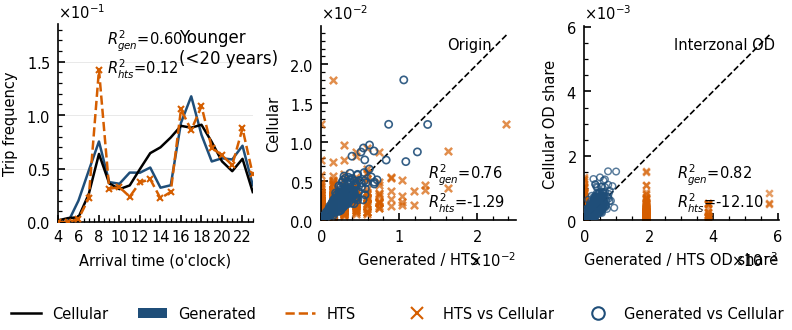

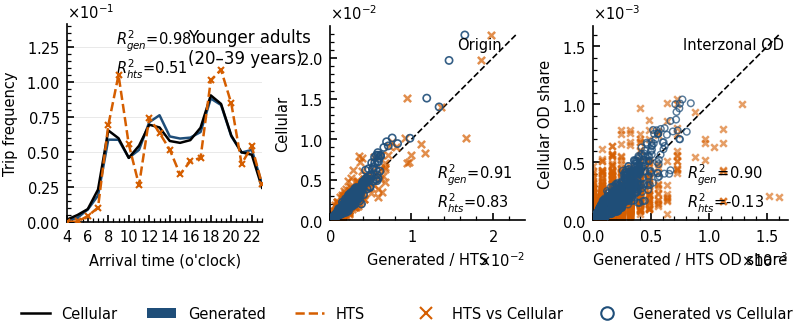

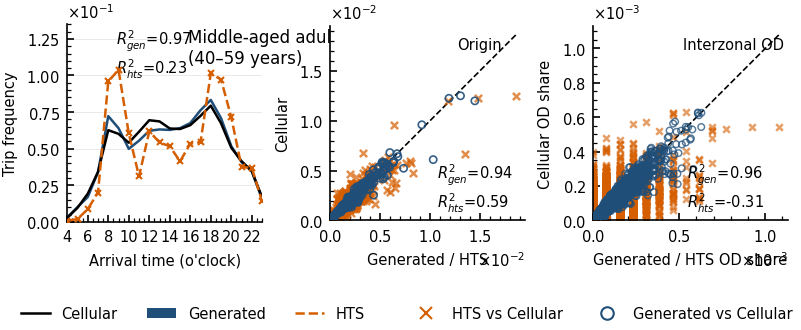

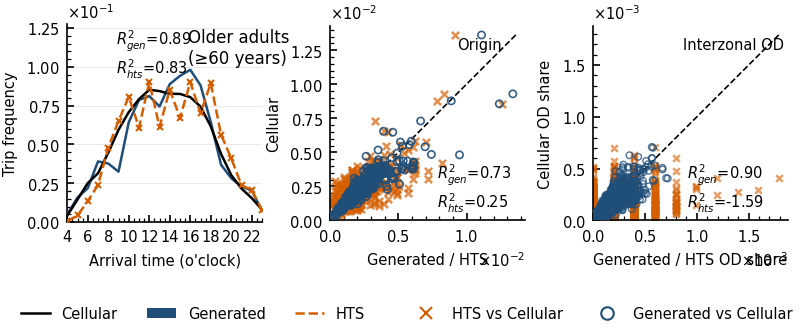

In [ ]:
# seoul_age_od_interaction_plots_nature.py
# ------------------------------------------------------------
# Nature-style validation plots by age group:
#   (A) Arrival-time distribution
#   (B) Origin marginal distribution
#   (C) Interzonal OD interaction distribution
#
# Interzonal OD interaction:
#   - aggregates joint Origin–Destination flows;
#   - excludes intrazonal trips (Origin == Destination);
#   - compares normalized OD shares across Cellular, Generated, and HTS.
#
# You must define: path_data, path_result, path_figure.
# ------------------------------------------------------------

from __future__ import annotations

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter, AutoMinorLocator, MultipleLocator
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from sklearn.metrics import r2_score


# =========================
# Global configuration
# =========================
COLORS = {
    "true": "#000000",   # Cellular
    "hts": "#D55E00",    # HTS
    "sim": "#1F4E79",    # Generated
    "diag": "#000000",
}

AX_LABELS = {
    "TRIP_STARTTIME": "Departure time (o'clock)",
    "TRIP_ENDTIME": "Arrival time (o'clock)",
}

# Original age groups 0–7 are collapsed into four broad groups.
AGE_RECODE = {
    0: 0,
    1: 0,  # Younger: <20 years
    2: 1,
    3: 1,  # Younger adults: 20–39 years
    4: 2,
    5: 2,  # Middle-aged adults: 40–59 years
    6: 3,
    7: 3,  # Older adults: >=60 years
}

PURPOSE_RECODE_HTS_FUS = {
    0: 0,
    1: 1,
    2: 2,
    3: 2,
    4: 2,
    5: 2,
}

PURPOSE_RECODE_PCM = {
    "H": 0,
    "W": 1,
    "E": 2,
}


# =========================
# Nature-style setup
# =========================
def set_nature_style() -> None:
    plt.rcParams.update({
        "figure.dpi": 150,
        "savefig.dpi": 150,
        "font.family": "DejaVu Sans",
        "font.size": 7,
        "axes.labelsize": 7,
        "axes.titlesize": 7,
        "legend.fontsize": 7,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "axes.linewidth": 0.8,
        "lines.linewidth": 1.2,
        "patch.linewidth": 0.8,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.major.size": 3.5,
        "ytick.major.size": 3.5,
        "xtick.minor.size": 2,
        "ytick.minor.size": 2,
        "legend.frameon": False,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.02,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })


def _format_axis_sci(ax: plt.Axes, which: str = "both") -> None:
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((0, 0))

    if which in ("x", "both"):
        ax.xaxis.set_major_formatter(formatter)

    if which in ("y", "both"):
        ax.yaxis.set_major_formatter(formatter)

    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())


def _beautify_axes(ax: plt.Axes, grid: bool = True) -> None:
    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)

    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)

    if grid:
        ax.grid(
            axis="y",
            which="major",
            linewidth=0.3,
            color="#DDDDDD",
        )

    ax.tick_params(width=0.8, length=3.5)
    ax.tick_params(which="minor", width=0.6, length=2)


def _safe_r2(y_true, y_pred) -> float:
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    if y_true.size > 1 and np.var(y_true) > 0:
        return float(r2_score(y_true, y_pred))

    return float("nan")


def get_max_pop(df: pd.DataFrame) -> float:
    pop_cols = [col for col in df.columns if col.startswith("Pop_")]

    if not pop_cols or df.empty:
        return 0.0

    return float(df[pop_cols].max().max())


# =========================
# Data preparation
# =========================
def prepare_hts(df_hts: pd.DataFrame) -> pd.DataFrame:
    df = df_hts.copy()
    df["COUNT"] = 1.0
    df["TRIP_PURPOSE"] = df["TRIP_PURPOSE"].replace(
        PURPOSE_RECODE_HTS_FUS
    )
    return df


def prepare_pcm(df_pcm: pd.DataFrame) -> pd.DataFrame:
    df = df_pcm.copy()

    if "COUNT" not in df.columns:
        df["COUNT"] = 1.0

    df["TRIP_PURPOSE"] = df["TRIP_PURPOSE"].replace(
        PURPOSE_RECODE_PCM
    )

    return df


def prepare_fus(df_fus: pd.DataFrame) -> pd.DataFrame:
    df = df_fus.copy()
    df["COUNT"] = df["Prob_XYZ_fus"]

    df["TRIP_PURPOSE"] = df["TRIP_PURPOSE"].replace(
        PURPOSE_RECODE_HTS_FUS
    )

    return df


# =========================
# Probability distributions
# =========================
def prob_att_age(
    df: pd.DataFrame,
    att: list[str],
    age_val: int,
    suffix: str,
) -> pd.DataFrame:
    """
    Normalized distribution of one attribute (or set of attributes),
    conditional on AGE == age_val.
    """
    dff = df.loc[
        df["AGE"].eq(age_val),
        att + ["COUNT"],
    ].copy()

    if dff.empty:
        return pd.DataFrame(columns=att + [f"Pop_{suffix}"])

    dff = (
        dff.groupby(att, observed=True, as_index=False)["COUNT"]
        .sum()
    )

    total_count = float(dff["COUNT"].sum())

    dff[f"Pop_{suffix}"] = (
        dff["COUNT"] / total_count
        if total_count > 0
        else 0.0
    )

    return (
        dff.drop(columns="COUNT")
        .sort_values(att)
        .reset_index(drop=True)
    )


def prob_interzonal_od_age(
    df: pd.DataFrame,
    age_val: int,
    suffix: str,
) -> pd.DataFrame:
    """
    Normalized joint Origin–Destination distribution for one age group.

    Intrazonal OD pairs are excluded:
        ORIGIN_SUBZONE != DESTINATION_SUBZONE
    """
    od_cols = ["ORIGIN_SUBZONE", "DESTINATION_SUBZONE"]

    dff = df.loc[
        df["AGE"].eq(age_val),
        od_cols + ["COUNT"],
    ].copy()

    dff = dff.dropna(subset=od_cols)

    dff = dff.loc[
        dff["ORIGIN_SUBZONE"] != dff["DESTINATION_SUBZONE"]
    ].copy()

    if dff.empty:
        return pd.DataFrame(columns=od_cols + [f"Pop_{suffix}"])

    dff = (
        dff.groupby(
            od_cols,
            observed=True,
            as_index=False,
        )["COUNT"]
        .sum()
    )

    total_count = float(dff["COUNT"].sum())

    dff[f"Pop_{suffix}"] = (
        dff["COUNT"] / total_count
        if total_count > 0
        else 0.0
    )

    return (
        dff.drop(columns="COUNT")
        .sort_values(od_cols)
        .reset_index(drop=True)
    )


# =========================
# Plot helpers
# =========================
def plot_line_ax(
    ax: plt.Axes,
    df: pd.DataFrame,
    att: str,
) -> None:
    """Arrival/departure time distribution."""
    dff = df.copy()
    dff[att] = pd.to_numeric(dff[att], errors="coerce")
    dff = dff.sort_values(att)

    ax.plot(
        dff[att],
        dff["Pop_sim"],
        color=COLORS["sim"],
        label="Generated",
        zorder=3,
    )

    ax.plot(
        dff[att],
        dff["Pop_true"],
        color=COLORS["true"],
        linestyle="-",
        label="Cellular",
        zorder=3,
    )

    ax.plot(
        dff[att],
        dff["Pop_hts"],
        color=COLORS["hts"],
        linestyle="--",
        marker="x",
        markersize=2.5,
        label="HTS",
        zorder=4,
    )

    ax.set_xlabel(AX_LABELS.get(att, att))
    ax.set_ylabel("Trip frequency")

    if att in {"TRIP_STARTTIME", "TRIP_ENDTIME"}:
        ax.set_xlim(4, 23)
        ax.set_xticks(np.arange(4, 24, 2))
        ax.xaxis.set_minor_locator(MultipleLocator(1))

    _format_axis_sci(ax, which="y")
    _beautify_axes(ax)

    max_value = get_max_pop(dff)
    ax.set_ylim(0, 1.3 * max_value if max_value > 0 else 1.0)

    r2_gen = _safe_r2(dff["Pop_true"], dff["Pop_sim"])
    r2_hts = _safe_r2(dff["Pop_true"], dff["Pop_hts"])

    text_lines = []

    if not np.isnan(r2_gen):
        text_lines.append(f"$R^2_{{gen}}$={r2_gen:.2f}")

    if not np.isnan(r2_hts):
        text_lines.append(f"$R^2_{{hts}}$={r2_hts:.2f}")

    if text_lines:
        ax.text(
            0.25,
            0.98,
            "\n".join(text_lines),
            transform=ax.transAxes,
            fontsize=7,
            va="top",
            ha="left",
        )


def plot_origin_scatter_ax(
    ax: plt.Axes,
    df: pd.DataFrame,
) -> None:
    """Origin marginal comparison."""
    dff = df.copy()

    limit = float(
        dff[["Pop_true", "Pop_sim", "Pop_hts"]]
        .to_numpy()
        .max()
    )

    if limit <= 0:
        limit = 1.0

    ax.plot(
        [0, limit],
        [0, limit],
        linestyle="--",
        color=COLORS["diag"],
        linewidth=0.8,
        zorder=1,
    )

    ax.scatter(
        dff["Pop_hts"],
        dff["Pop_true"],
        s=12,
        marker="x",
        color=COLORS["hts"],
        alpha=0.70,
        zorder=2,
    )

    ax.scatter(
        dff["Pop_sim"],
        dff["Pop_true"],
        s=12,
        facecolor="none",
        edgecolor=COLORS["sim"],
        linewidth=0.8,
        alpha=0.90,
        zorder=3,
    )

    ax.set_xlim(0, 1.05 * limit)
    ax.set_ylim(0, 1.05 * limit)
    ax.set_aspect("equal", adjustable="box")

    ax.set_xlabel("Generated / HTS")
    ax.set_ylabel("Cellular")

    _format_axis_sci(ax)
    _beautify_axes(ax, grid=False)

    r2_gen = _safe_r2(dff["Pop_true"], dff["Pop_sim"])
    r2_hts = _safe_r2(dff["Pop_true"], dff["Pop_hts"])

    text_lines = []

    if not np.isnan(r2_gen):
        text_lines.append(f"$R^2_{{gen}}$={r2_gen:.2f}")

    if not np.isnan(r2_hts):
        text_lines.append(f"$R^2_{{hts}}$={r2_hts:.2f}")

    if text_lines:
        ax.text(
            0.55,
            0.30,
            "\n".join(text_lines),
            transform=ax.transAxes,
            fontsize=7,
            va="top",
            ha="left",
        )


def plot_interzonal_od_scatter_ax(
    ax: plt.Axes,
    df: pd.DataFrame,
) -> None:
    """Interzonal OD interaction comparison."""
    dff = df.copy()

    limit = float(
        dff[["Pop_true", "Pop_sim", "Pop_hts"]]
        .to_numpy()
        .max()
    )

    if limit <= 0:
        limit = 1.0

    ax.plot(
        [0, limit],
        [0, limit],
        linestyle="--",
        color=COLORS["diag"],
        linewidth=0.8,
        zorder=1,
    )

    ax.scatter(
        dff["Pop_hts"],
        dff["Pop_true"],
        s=10,
        marker="x",
        color=COLORS["hts"],
        alpha=0.60,
        zorder=2,
    )

    ax.scatter(
        dff["Pop_sim"],
        dff["Pop_true"],
        s=10,
        facecolor="none",
        edgecolor=COLORS["sim"],
        linewidth=0.7,
        alpha=0.75,
        zorder=3,
    )

    ax.set_xlim(0, 1.05 * limit)
    ax.set_ylim(0, 1.05 * limit)
    ax.set_aspect("equal", adjustable="box")

    ax.set_xlabel("Generated / HTS OD share")
    ax.set_ylabel("Cellular OD share")

    _format_axis_sci(ax)
    _beautify_axes(ax, grid=False)

    r2_gen = _safe_r2(dff["Pop_true"], dff["Pop_sim"])
    r2_hts = _safe_r2(dff["Pop_true"], dff["Pop_hts"])

    text_lines = []

    if not np.isnan(r2_gen):
        text_lines.append(f"$R^2_{{gen}}$={r2_gen:.2f}")

    if not np.isnan(r2_hts):
        text_lines.append(f"$R^2_{{hts}}$={r2_hts:.2f}")

    if text_lines:
        ax.text(
            0.48,
            0.30,
            "\n".join(text_lines),
            transform=ax.transAxes,
            fontsize=7,
            va="top",
            ha="left",
        )


# =========================
# One figure per age group
# =========================
def compose_age_1x3(
    df_pcm: pd.DataFrame,
    df_hts: pd.DataFrame,
    df_fus: pd.DataFrame,
    *,
    age_val: int,
    age_label: str,
    time_att: str = "TRIP_ENDTIME",
    figsize: tuple[float, float] = (6.2, 2.2),
    save_path: str | None = None,
) -> plt.Figure:

    fig, axes = plt.subplots(1, 3, figsize=figsize)
    axes = np.atleast_1d(axes)

    # (A) Arrival time
    sim_time = prob_att_age(df_fus, [time_att], age_val, "sim")
    true_time = prob_att_age(df_pcm, [time_att], age_val, "true")
    hts_time = prob_att_age(df_hts, [time_att], age_val, "hts")

    time_df = (
        true_time.merge(sim_time, on=[time_att], how="outer")
        .merge(hts_time, on=[time_att], how="outer")
        .fillna(0)
        .sort_values(time_att)
    )

    plot_line_ax(axes[0], time_df, time_att)

    axes[0].text(
        0.62,
        0.98,
        age_label,
        transform=axes[0].transAxes,
        va="top",
        ha="left",
        fontsize=8,
    )

    # (B) Origin marginal
    sim_origin = prob_att_age(
        df_fus,
        ["ORIGIN_SUBZONE"],
        age_val,
        "sim",
    )
    true_origin = prob_att_age(
        df_pcm,
        ["ORIGIN_SUBZONE"],
        age_val,
        "true",
    )
    hts_origin = prob_att_age(
        df_hts,
        ["ORIGIN_SUBZONE"],
        age_val,
        "hts",
    )

    origin_df = (
        true_origin.merge(
            sim_origin,
            on=["ORIGIN_SUBZONE"],
            how="outer",
        )
        .merge(
            hts_origin,
            on=["ORIGIN_SUBZONE"],
            how="outer",
        )
        .fillna(0)
    )

    plot_origin_scatter_ax(axes[1], origin_df)

    axes[1].text(
        0.65,
        0.94,
        "Origin",
        transform=axes[1].transAxes,
        va="top",
        ha="left",
        fontsize=7,
    )

    # (C) Interzonal OD interaction
    sim_od = prob_interzonal_od_age(df_fus, age_val, "sim")
    true_od = prob_interzonal_od_age(df_pcm, age_val, "true")
    hts_od = prob_interzonal_od_age(df_hts, age_val, "hts")

    # Outer merge is intentional: OD pairs absent from a source receive zero
    # share, so the comparison reflects interaction-support recovery.
    od_df = (
        true_od.merge(
            sim_od,
            on=["ORIGIN_SUBZONE", "DESTINATION_SUBZONE"],
            how="outer",
        )
        .merge(
            hts_od,
            on=["ORIGIN_SUBZONE", "DESTINATION_SUBZONE"],
            how="outer",
        )
        .fillna(0)
    )

    plot_interzonal_od_scatter_ax(axes[2], od_df)

    axes[2].text(
        0.46,
        0.94,
        "Interzonal OD",
        transform=axes[2].transAxes,
        va="top",
        ha="left",
        fontsize=7,
    )

    plt.subplots_adjust(
        wspace=0.35,
        hspace=0.0,
        bottom=0.28,
    )

    line_legend = [
        Line2D([0], [0], color=COLORS["true"], lw=1.2),
        Patch(facecolor=COLORS["sim"], edgecolor="none"),
        Line2D([0], [0], color=COLORS["hts"], lw=1.2, ls="--"),
    ]

    fig.legend(
        line_legend,
        ["Cellular", "Generated", "HTS"],
        loc="lower center",
        bbox_to_anchor=(0.26, -0.06),
        ncol=3,
        frameon=False,
    )

    scatter_legend = [
        Line2D(
            [], [],
            marker="x",
            linestyle="None",
            markerfacecolor=COLORS["hts"],
            markeredgecolor=COLORS["hts"],
            markersize=6,
        ),
        Line2D(
            [], [],
            marker="o",
            linestyle="None",
            markerfacecolor="none",
            markeredgecolor=COLORS["sim"],
            markersize=6,
        ),
    ]

    fig.legend(
        scatter_legend,
        ["HTS vs Cellular", "Generated vs Cellular"],
        loc="lower center",
        bbox_to_anchor=(0.70, -0.06),
        ncol=2,
        frameon=False,
    )

    if save_path:
        fig.savefig(
            save_path + ".pdf",
            dpi=200,
            bbox_inches="tight",
        )

    return fig


# =========================
# Main
# =========================
if __name__ == "__main__":
    set_nature_style()

    # Input data
    df_hts_raw = pd.read_csv(
        os.path.join(path_data, "data_seoul_hts_trip.csv")
    )

    df_pcm_raw = pd.read_csv(
        os.path.join(path_data, "data_seoul_pcm_trip.csv")
    )

    if (
        "TRIP_PURPOSE_" in df_pcm_raw.columns
        and "TRIP_PURPOSE" not in df_pcm_raw.columns
    ):
        df_pcm_raw = df_pcm_raw.rename(
            columns={"TRIP_PURPOSE_": "TRIP_PURPOSE"}
        )

    # Retrieve the four age groups.
    df_hts_raw["AGE"] = df_hts_raw["AGE"].replace(AGE_RECODE)
    df_pcm_raw["AGE"] = df_pcm_raw["AGE"].replace(AGE_RECODE)

    REGION = "seoul"
    KK = 6000
    NB = 10
    RANDOM_SEED = 12345

    df_fus_raw = pd.read_csv(
        os.path.join(
            path_result,
            f"case_{REGION}_sim_trip_M_{KK}_nb_{NB}_seed_{RANDOM_SEED}.csv",
        )
    )

    # The generated file already uses the four age categories 0–3.
    df_hts = prepare_hts(df_hts_raw)
    df_pcm = prepare_pcm(df_pcm_raw)
    df_fus = prepare_fus(df_fus_raw)

    print("HTS age groups:")
    print(df_hts["AGE"].value_counts().sort_index())

    print("\nCellular age groups:")
    print(df_pcm["AGE"].value_counts().sort_index())

    print("\nGenerated age groups:")
    print(df_fus["AGE"].value_counts().sort_index())

    age_specs = [
        (0, "Younger\n(<20 years)"),
        (1, "Younger adults\n(20–39 years)"),
        (2, "Middle-aged adults\n(40–59 years)"),
        (3, "Older adults\n(≥60 years)"),
    ]

    for age_val, age_label in age_specs:
        fig = compose_age_1x3(
            df_pcm=df_pcm,
            df_hts=df_hts,
            df_fus=df_fus,
            age_val=age_val,
            age_label=age_label,
            time_att="TRIP_ENDTIME",
            figsize=(6.2, 2.2),
            save_path=os.path.join(
                path_figure,
                f"case_seoul_1x3_interzonal_od_age_{age_val}",
            ),
        )

    plt.show()

# SFigure: Concept illustration map

Selected segregation records: 303
Mapped subzones: 303
Subzones imputed with the mean: 20
Minimum segregation: 0.003874
Maximum segregation: 0.171871


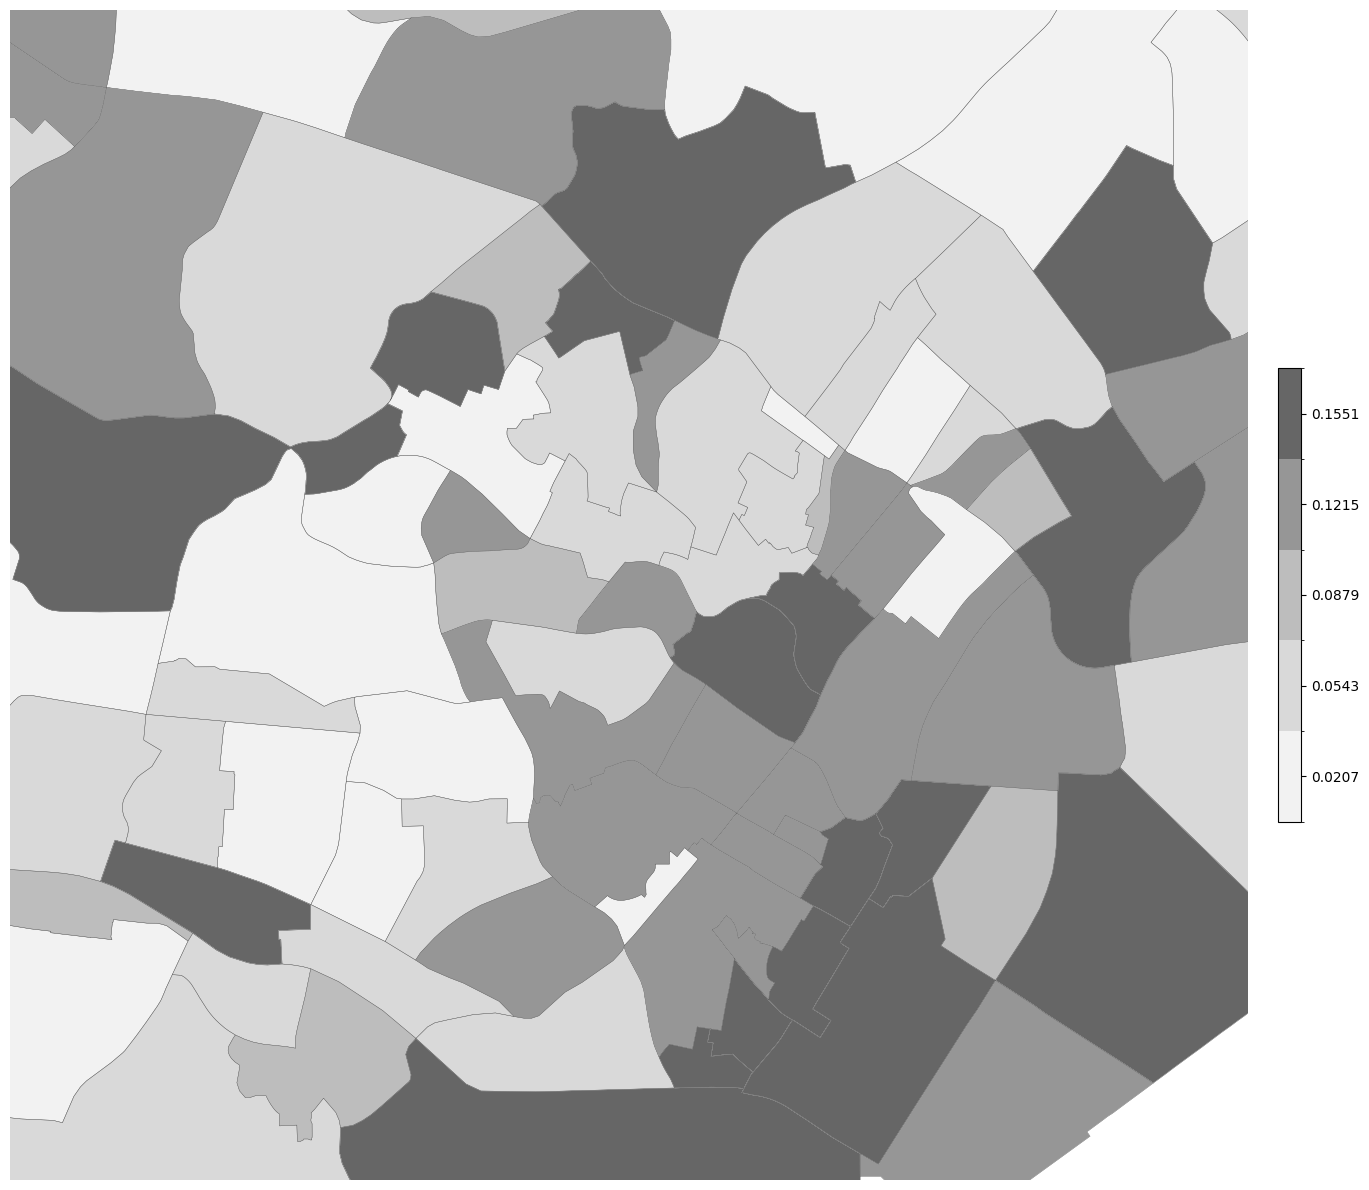

Rectangular cropped map saved to: /content/drive/MyDrive/Colab Notebooks/Workspace/tour_generation/re1_figure/map_cropped_rectangle_place_purpose_time_segregation_income_purpose_1_time_11_seed_12345_grey.png


In [ ]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, LinearSegmentedColormap
from matplotlib.cm import ScalarMappable


# ============================================================
# Configuration
# ============================================================

reg = "sgp"
M = 6000
nb = 10
seed = 12345

selected_attribute = "INCOME"
selected_purpose = 1
selected_time_slot = 11

n_bins = 5
cmap_name = "custom_greys"

# Rectangular crop proportions
crop_left_fraction = 0.42
crop_right_fraction = 0.45
crop_bottom_fraction = 0.35
crop_top_fraction = 0.46

purpose_labels = {
    0: "Household",
    1: "Work",
    2: "Dinning/Refreshment",
    3: "Shopping",
    4: "Education",
    5: "Other",
}

segregation_column = "PLACE_PURPOSE_TIME_SEGREGATION"

shapefile_path = os.path.join(
    path_data,
    f"data_{reg}_subzone.shp",
)

segregation_path = os.path.join(
    path_segregation,
    f"all_place_purpose_time_segregation_"
    f"{reg}_M_{M}_nb_{nb}_seed_{seed}.csv",
)

output_path = os.path.join(
    path_figure,
    f"map_cropped_rectangle_"
    f"{segregation_column.lower()}_"
    f"{selected_attribute.lower()}_"
    f"purpose_{selected_purpose}_"
    f"time_{selected_time_slot}_"
    f"seed_{seed}_grey.png",
)


# ============================================================
# Load data
# ============================================================

df_subzone = gpd.read_file(shapefile_path)

df_place_segregation = pd.read_csv(
    segregation_path,
    usecols=[
        "ACTIVITY_SUBZONE",
        "ATTRIBUTE",
        "ACTIVITY_PURPOSE",
        "ACTIVITY_TIME_SLOT",
        segregation_column,
    ],
)


# ============================================================
# Validate required columns
# ============================================================

required_map_columns = [
    "SUBZONE_C",
    "geometry",
]

required_segregation_columns = [
    "ACTIVITY_SUBZONE",
    "ATTRIBUTE",
    "ACTIVITY_PURPOSE",
    "ACTIVITY_TIME_SLOT",
    segregation_column,
]

missing_map_columns = [
    column
    for column in required_map_columns
    if column not in df_subzone.columns
]

missing_segregation_columns = [
    column
    for column in required_segregation_columns
    if column not in df_place_segregation.columns
]

if missing_map_columns:
    raise KeyError(
        f"Shapefile is missing columns: {missing_map_columns}"
    )

if missing_segregation_columns:
    raise KeyError(
        "Segregation data is missing columns: "
        f"{missing_segregation_columns}"
    )


# ============================================================
# Standardize fields
# ============================================================

df_subzone["SUBZONE_C"] = (
    df_subzone["SUBZONE_C"]
    .astype("string")
    .str.strip()
    .str.upper()
)

df_place_segregation["ACTIVITY_SUBZONE"] = (
    df_place_segregation["ACTIVITY_SUBZONE"]
    .astype("string")
    .str.strip()
    .str.upper()
)

df_place_segregation["ATTRIBUTE"] = (
    df_place_segregation["ATTRIBUTE"]
    .astype("string")
    .str.strip()
    .str.upper()
)

df_place_segregation["ACTIVITY_PURPOSE"] = pd.to_numeric(
    df_place_segregation["ACTIVITY_PURPOSE"],
    errors="coerce",
)

df_place_segregation["ACTIVITY_TIME_SLOT"] = pd.to_numeric(
    df_place_segregation["ACTIVITY_TIME_SLOT"],
    errors="coerce",
)

df_place_segregation[segregation_column] = pd.to_numeric(
    df_place_segregation[segregation_column],
    errors="coerce",
)


# ============================================================
# Filter selected segregation setting
# ============================================================

selected = df_place_segregation.loc[
    df_place_segregation["ATTRIBUTE"].eq(
        selected_attribute.upper()
    )
    & df_place_segregation["ACTIVITY_PURPOSE"].eq(
        selected_purpose
    )
    & df_place_segregation["ACTIVITY_TIME_SLOT"].eq(
        selected_time_slot
    ),
    [
        "ACTIVITY_SUBZONE",
        segregation_column,
    ],
].copy()

selected.dropna(
    subset=[
        "ACTIVITY_SUBZONE",
        segregation_column,
    ],
    inplace=True,
)

if selected.empty:
    raise ValueError(
        "No valid segregation records were found for "
        f"ATTRIBUTE={selected_attribute}, "
        f"ACTIVITY_PURPOSE={selected_purpose}, "
        f"ACTIVITY_TIME_SLOT={selected_time_slot}."
    )


# ============================================================
# Ensure one value per subzone
# ============================================================

duplicate_zones = selected[
    "ACTIVITY_SUBZONE"
].duplicated(keep=False)

if duplicate_zones.any():
    duplicate_names = (
        selected.loc[
            duplicate_zones,
            "ACTIVITY_SUBZONE",
        ]
        .drop_duplicates()
        .tolist()
    )

    raise ValueError(
        "Multiple segregation values remain for some subzones. "
        f"Example duplicate subzones: {duplicate_names[:10]}"
    )

selected.rename(
    columns={
        "ACTIVITY_SUBZONE": "SUBZONE_C",
    },
    inplace=True,
)


# ============================================================
# Merge segregation data with shapefile
# ============================================================

map_data = df_subzone.merge(
    selected,
    on="SUBZONE_C",
    how="left",
    validate="one_to_one",
)

n_matched = int(
    map_data[segregation_column].notna().sum()
)

n_missing = int(
    map_data[segregation_column].isna().sum()
)

if n_matched == 0:
    raise ValueError(
        "None of the selected segregation records matched "
        "the shapefile."
    )


# ============================================================
# Fill missing values with the matched-subzone average
# ============================================================

average_segregation = float(
    map_data[segregation_column].mean(skipna=True)
)

map_data["VALUE_IMPUTED"] = (
    map_data[segregation_column].isna()
)

map_data[segregation_column] = (
    map_data[segregation_column]
    .fillna(average_segregation)
)

n_imputed = int(
    map_data["VALUE_IMPUTED"].sum()
)

print(
    f"Selected segregation records: {len(selected):,}\n"
    f"Mapped subzones: {n_matched:,}\n"
    f"Subzones imputed with the mean: {n_imputed:,}\n"
    f"Minimum segregation: "
    f"{map_data[segregation_column].min():.6f}\n"
    f"Maximum segregation: "
    f"{map_data[segregation_column].max():.6f}"
)


# ============================================================
# Construct discrete grey-scale bins
# ============================================================

values = map_data[segregation_column].to_numpy(
    dtype=float
)

vmin = float(np.nanmin(values))
vmax = float(np.nanmax(values))

if not np.isfinite(vmin) or not np.isfinite(vmax):
    raise ValueError(
        "The mapped segregation values are not finite."
    )

if np.isclose(vmin, vmax):
    padding = max(abs(vmin) * 0.01, 1e-6)
    vmin -= padding
    vmax += padding

bin_edges = np.linspace(
    vmin,
    vmax,
    n_bins + 1,
)

bin_midpoints = (
    bin_edges[:-1] + bin_edges[1:]
) / 2

bin_labels = [
    f"{lower:.4f}–{upper:.4f}"
    for lower, upper in zip(
        bin_edges[:-1],
        bin_edges[1:],
    )
]

# Light grey for low values and medium-dark grey for high values.
# The maximum value is not black.
cmap = LinearSegmentedColormap.from_list(
    "custom_greys",
    [
        "#F2F2F2",  # lowest values
        "#D9D9D9",
        "#BDBDBD",
        "#969696",
        "#666666",  # highest values
    ],
    N=n_bins,
)

normalization = BoundaryNorm(
    boundaries=bin_edges,
    ncolors=cmap.N,
    clip=True,
)


# ============================================================
# Plot map
# ============================================================

fig, ax = plt.subplots(
    figsize=(16, 12)
)

map_data.plot(
    column=segregation_column,
    ax=ax,
    cmap=cmap,
    norm=normalization,
    edgecolor="white",
    linewidth=0.25,
)

map_data.boundary.plot(
    ax=ax,
    color="#555555",
    linewidth=0.25,
)

colorbar_object = ScalarMappable(
    norm=normalization,
    cmap=cmap,
)

colorbar_object.set_array([])

colorbar = fig.colorbar(
    colorbar_object,
    ax=ax,
    boundaries=bin_edges,
    ticks=bin_midpoints,
    spacing="uniform",
    fraction=0.015,
    pad=0.02,
)

'''colorbar.ax.set_yticklabels(
    bin_labels,
    fontsize=9,
)'''

'''colorbar.set_label(
    "Place–purpose–time segregation",
    fontsize=11,
)'''

purpose_name = purpose_labels.get(
    selected_purpose,
    f"Purpose {selected_purpose}",
)

'''ax.set_title(
    "Place–purpose–time segregation\n"
    f"Attribute: {selected_attribute.title()} | "
    f"Purpose: {purpose_name} | "
    f"Time slot: {selected_time_slot}:00",
    fontsize=15,
    fontweight="bold",
    pad=14,
)'''

'''ax.text(
    0.01,
    0.01,
    f"Seed: {seed} | M: {M} | "
    f"Observed: {n_matched}/{len(map_data)} | "
    f"Mean-imputed: {n_imputed}",
    transform=ax.transAxes,
    fontsize=9,
    ha="left",
    va="bottom",
    bbox={
        "facecolor": "white",
        "edgecolor": "none",
        "alpha": 0.80,
        "pad": 4,
    },
)'''


# ============================================================
# Crop output to a rectangle
# ============================================================

minx, miny, maxx, maxy = map_data.total_bounds

map_width = maxx - minx
map_height = maxy - miny

crop_left = minx + crop_left_fraction * map_width
crop_right = maxx - crop_right_fraction * map_width
crop_bottom = miny + crop_bottom_fraction * map_height
crop_top = maxy - crop_top_fraction * map_height

ax.set_xlim(crop_left, crop_right)
ax.set_ylim(crop_bottom, crop_top)

ax.set_axis_off()

fig.tight_layout()

fig.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.05,
    facecolor="white",
)

plt.show()
plt.close(fig)

print(f"Rectangular cropped map saved to: {output_path}")

# Result 3: Compressed segregation

## Location segregation

ATTRIBUTE             METRIC              LABEL  R2_MEAN  R2_STD
      AGE      place-purpose      Place–purpose   0.5064  0.1136
      AGE place-purpose-time Place–purpose–time   0.5015  0.1107
      AGE         place-time         Place–time   0.9544  0.0165
   GENDER      place-purpose      Place–purpose   0.2420  0.0613
   GENDER place-purpose-time Place–purpose–time   0.1585  0.0537
   GENDER         place-time         Place–time   0.6574  0.1331
   INCOME      place-purpose      Place–purpose   0.4438  0.1119
   INCOME place-purpose-time Place–purpose–time   0.5196  0.1198
   INCOME         place-time         Place–time   0.9347  0.0247


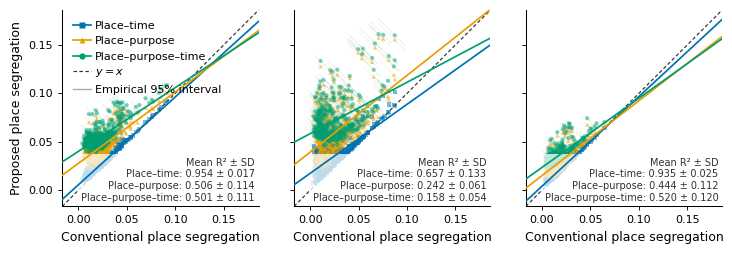

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator


# ============================================================
# Figure typography: Matplotlib default font
# ============================================================

PANEL_FONT_SIZE = 10
AXIS_LABEL_FONT_SIZE = 9
TICK_FONT_SIZE = 8
LEGEND_FONT_SIZE = 8
ANNOTATION_FONT_SIZE = 7

plt.rcParams.update({
    "font.size": TICK_FONT_SIZE,
    "axes.labelsize": AXIS_LABEL_FONT_SIZE,
    "xtick.labelsize": TICK_FONT_SIZE,
    "ytick.labelsize": TICK_FONT_SIZE,
    "legend.fontsize": LEGEND_FONT_SIZE,
    "axes.linewidth": 0.75,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


# ============================================================
# Configuration
# ============================================================

reg = "seoul"
M = 6000
nb = 10
seeds = [12345, 23456, 34567, 45678, 56789]

attribute_order = ["AGE", "GENDER", "INCOME"]

show_empirical_interval = True
interval_alpha = 0.16
point_alpha = 0.5
dpi = 600

output_path = os.path.join(
    path_figure,
    f"place_vs_disaggregated_segregation_{reg}_"
    f"M_{M}_nb_{nb}_across_seeds.pdf",
)


# ============================================================
# Metric configuration
# ============================================================

METRIC_CONFIG = {
    "place-time": {
        "file_stem": "all_place_time_segregation",
        "column": "PLACE_TIME_SEGREGATION",
        "weighted_column": "PLACE_TIME_WEIGHTED_SEGREGATION",
        "label": "Place–time",
        "color": "#0072B2",
        "marker": "s",
    },
    "place-purpose": {
        "file_stem": "all_place_purpose_segregation",
        "column": "PLACE_PURPOSE_SEGREGATION",
        "weighted_column": "PLACE_PURPOSE_WEIGHTED_SEGREGATION",
        "label": "Place–purpose",
        "color": "#E69F00",
        "marker": "^",
    },
    "place-purpose-time": {
        "file_stem": "all_place_purpose_time_segregation",
        "column": "PLACE_PURPOSE_TIME_SEGREGATION",
        "weighted_column": "PLACE_PURPOSE_TIME_WEIGHTED_SEGREGATION",
        "label": "Place–purpose–time",
        "color": "#009E73",
        "marker": "o",
    },
}


# ============================================================
# Calculate weighted comparison for one metric and one seed
# ============================================================

def calculate_seed_comparison(
    path_segregation,
    reg,
    M,
    nb,
    seed,
    metric_name,
    metric_config,
):
    place_path = os.path.join(
        path_segregation,
        f"all_place_segregation_{reg}_M_{M}_nb_{nb}_seed_{seed}.csv",
    )

    metric_path = os.path.join(
        path_segregation,
        f"{metric_config['file_stem']}_{reg}_"
        f"M_{M}_nb_{nb}_seed_{seed}.csv",
    )

    place = pd.read_csv(
        place_path,
        usecols=[
            "ACTIVITY_SUBZONE",
            "ATTRIBUTE",
            "PLACE_SEGREGATION",
        ],
    )

    metric_data = pd.read_csv(
        metric_path,
        usecols=[
            "ACTIVITY_SUBZONE",
            "ATTRIBUTE",
            metric_config["column"],
            "TOTAL_ATTENDANCE_HOURS",
        ],
    )

    for dataframe in [place, metric_data]:
        dataframe["ACTIVITY_SUBZONE"] = (
            dataframe["ACTIVITY_SUBZONE"]
            .astype("string")
            .str.strip()
            .str.upper()
        )

        dataframe["ATTRIBUTE"] = (
            dataframe["ATTRIBUTE"]
            .astype("string")
            .str.strip()
            .str.upper()
        )

    place["PLACE_SEGREGATION"] = pd.to_numeric(
        place["PLACE_SEGREGATION"],
        errors="coerce",
    )

    metric_data[metric_config["column"]] = pd.to_numeric(
        metric_data[metric_config["column"]],
        errors="coerce",
    )

    metric_data["TOTAL_ATTENDANCE_HOURS"] = pd.to_numeric(
        metric_data["TOTAL_ATTENDANCE_HOURS"],
        errors="coerce",
    )

    place = place.dropna(
        subset=[
            "ACTIVITY_SUBZONE",
            "ATTRIBUTE",
            "PLACE_SEGREGATION",
        ]
    )

    metric_data = metric_data.dropna(
        subset=[
            "ACTIVITY_SUBZONE",
            "ATTRIBUTE",
            metric_config["column"],
            "TOTAL_ATTENDANCE_HOURS",
        ]
    )

    metric_data = metric_data.loc[
        metric_data["TOTAL_ATTENDANCE_HOURS"].gt(0)
    ].copy()

    metric_data["_WEIGHTED_VALUE"] = (
        metric_data[metric_config["column"]]
        * metric_data["TOTAL_ATTENDANCE_HOURS"]
    )

    metric_summary = (
        metric_data
        .groupby(
            ["ACTIVITY_SUBZONE", "ATTRIBUTE"],
            observed=True,
            sort=False,
            as_index=False,
        )
        .agg(
            WEIGHTED_SUM=("_WEIGHTED_VALUE", "sum"),
            TOTAL_ATTENDANCE_HOURS=("TOTAL_ATTENDANCE_HOURS", "sum"),
        )
    )

    metric_summary[metric_config["weighted_column"]] = (
        metric_summary["WEIGHTED_SUM"]
        / metric_summary["TOTAL_ATTENDANCE_HOURS"]
    )

    comparison = place.merge(
        metric_summary[
            [
                "ACTIVITY_SUBZONE",
                "ATTRIBUTE",
                metric_config["weighted_column"],
            ]
        ],
        on=[
            "ACTIVITY_SUBZONE",
            "ATTRIBUTE",
        ],
        how="inner",
        validate="one_to_one",
    )

    comparison.insert(0, "SEED", seed)
    comparison.insert(1, "METRIC", metric_name)

    comparison.rename(
        columns={
            metric_config["weighted_column"]: "RESOLVED_SEGREGATION",
        },
        inplace=True,
    )

    return comparison


# ============================================================
# Summarize subzone estimates across seeds
# ============================================================

def summarize_across_seeds(seed_results):
    seed_results = seed_results.copy()

    seed_results["PAIRED_GAP"] = (
        seed_results["RESOLVED_SEGREGATION"]
        - seed_results["PLACE_SEGREGATION"]
    )

    return (
        seed_results
        .groupby(
            [
                "METRIC",
                "ACTIVITY_SUBZONE",
                "ATTRIBUTE",
            ],
            observed=True,
            sort=False,
        )
        .agg(
            N_SEEDS=("SEED", "nunique"),
            PLACE_MEAN=("PLACE_SEGREGATION", "mean"),
            RESOLVED_MEAN=("RESOLVED_SEGREGATION", "mean"),
            GAP_P025=(
                "PAIRED_GAP",
                lambda values: values.quantile(0.025),
            ),
            GAP_P975=(
                "PAIRED_GAP",
                lambda values: values.quantile(0.975),
            ),
        )
        .reset_index()
    )


# ============================================================
# Fit a linear model and calculate R²
# ============================================================

def fit_linear_model(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)

    x = x[valid]
    y = y[valid]

    if len(x) < 2 or np.isclose(np.ptp(x), 0):
        return np.nan, np.nan, np.nan

    slope, intercept = np.polyfit(x, y, 1)
    fitted = intercept + slope * x

    residual_sum_squares = np.sum(
        (y - fitted) ** 2
    )

    total_sum_squares = np.sum(
        (y - y.mean()) ** 2
    )

    r_squared = (
        1.0 - residual_sum_squares / total_sum_squares
        if total_sum_squares > 0
        else np.nan
    )

    return slope, intercept, r_squared


# ============================================================
# Calculate seed-specific R² uncertainty from subzone dots
# ============================================================

def calculate_seed_r_squared(
    seed_results,
    attributes,
    metric_config,
):
    records = []

    for attribute in attributes:
        for metric_name, config in metric_config.items():
            metric_data = seed_results.loc[
                seed_results["ATTRIBUTE"].eq(attribute)
                & seed_results["METRIC"].eq(metric_name)
            ]

            for seed, seed_data in metric_data.groupby(
                "SEED",
                observed=True,
                sort=False,
            ):
                _, _, r_squared = fit_linear_model(
                    seed_data["PLACE_SEGREGATION"],
                    seed_data["RESOLVED_SEGREGATION"],
                )

                records.append(
                    {
                        "ATTRIBUTE": attribute,
                        "METRIC": metric_name,
                        "LABEL": config["label"],
                        "SEED": seed,
                        "R_SQUARED": r_squared,
                    }
                )

    seed_r_squared = pd.DataFrame(records)

    return (
        seed_r_squared
        .groupby(
            [
                "ATTRIBUTE",
                "METRIC",
                "LABEL",
            ],
            observed=True,
            as_index=False,
        )
        .agg(
            R2_MEAN=("R_SQUARED", "mean"),
            R2_STD=("R_SQUARED", "std"),
        )
    )


# ============================================================
# Plot all measures
# ============================================================
def plot_all_metrics(
    summary,
    seed_r_squared_summary,
    metric_config,
    attributes,
    show_interval=True,
    output_path=None,
    dpi=600,
):
    all_values = summary[
        ["PLACE_MEAN", "RESOLVED_MEAN"]
    ].to_numpy(dtype=float)

    if not np.isfinite(all_values).any():
        raise ValueError("No finite values are available for plotting.")

    axis_min = min(0.0, float(np.nanmin(all_values)))
    axis_max = float(np.nanmax(all_values))

    if show_interval:
        midpoint = (
            summary["PLACE_MEAN"] + summary["RESOLVED_MEAN"]
        ) / 2.0

        interval_endpoints = np.concatenate(
            [
                (
                    midpoint - summary["GAP_P025"] / 2.0
                ).to_numpy(dtype=float),
                (
                    midpoint + summary["GAP_P025"] / 2.0
                ).to_numpy(dtype=float),
                (
                    midpoint - summary["GAP_P975"] / 2.0
                ).to_numpy(dtype=float),
                (
                    midpoint + summary["GAP_P975"] / 2.0
                ).to_numpy(dtype=float),
            ]
        )

        axis_min = min(
            axis_min,
            float(np.nanmin(interval_endpoints)),
        )
        axis_max = max(
            axis_max,
            float(np.nanmax(interval_endpoints)),
        )

    padding = max(
        0.05 * (axis_max - axis_min),
        1e-6,
    )

    limits = (
        axis_min - padding,
        axis_max + padding,
    )

    fig, axes = plt.subplots(
        1,
        len(attributes),
        figsize=(2.5 * len(attributes), 4),
        sharex=True,
        sharey=True,
        squeeze=False,
    )

    axes = axes.ravel()

    for panel_index, (ax, attribute) in enumerate(
        zip(axes, attributes)
    ):
        attribute_data = summary.loc[
            summary["ATTRIBUTE"].eq(attribute)
        ].copy()

        for metric_name, config in metric_config.items():
            data = attribute_data.loc[
                attribute_data["METRIC"].eq(metric_name)
            ].dropna(
                subset=[
                    "PLACE_MEAN",
                    "RESOLVED_MEAN",
                ]
            )

            if data.empty:
                continue

            x = data["PLACE_MEAN"].to_numpy(dtype=float)
            y = data["RESOLVED_MEAN"].to_numpy(dtype=float)

            if show_interval:
                midpoint = (x + y) / 2.0
                gap_low = data["GAP_P025"].to_numpy(dtype=float)
                gap_high = data["GAP_P975"].to_numpy(dtype=float)

                x_low = midpoint - gap_low / 2.0
                y_low = midpoint + gap_low / 2.0
                x_high = midpoint - gap_high / 2.0
                y_high = midpoint + gap_high / 2.0

                for index in range(len(data)):
                    ax.plot(
                        [x_low[index], x_high[index]],
                        [y_low[index], y_high[index]],
                        color=config["color"],
                        linewidth=0.55,
                        alpha=interval_alpha,
                        solid_capstyle="round",
                        zorder=1,
                        rasterized=True,
                    )

            ax.scatter(
                x,
                y,
                s=9,
                color=config["color"],
                marker=config["marker"],
                alpha=point_alpha,
                edgecolors="none",
                zorder=3,
                rasterized=True,
            )

            slope, intercept, _ = fit_linear_model(x, y)

            if np.isfinite(slope):
                ax.plot(
                    limits,
                    intercept + slope * np.asarray(limits),
                    color=config["color"],
                    linewidth=1.25,
                    zorder=4,
                )

        ax.plot(
            limits,
            limits,
            linestyle=(0, (3, 2)),
            color="#303030",
            linewidth=0.85,
            zorder=2,
        )

        ax.set_xlabel("Conventional place segregation")
        ax.set_xlim(limits)
        ax.set_ylim(limits)
        ax.set_aspect("equal", adjustable="box")

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        ax.tick_params(
            direction="out",
            width=0.65,
            length=3,
            top=False,
            right=False,
        )

        ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
        ax.yaxis.set_major_locator(MaxNLocator(nbins=5))

        # Display the mean R² and standard deviation across seeds.
        r2_lines = []
        for metric_name, config in metric_config.items():
            r2_data = seed_r_squared_summary.loc[
                seed_r_squared_summary["ATTRIBUTE"].eq(attribute)
                & seed_r_squared_summary["METRIC"].eq(metric_name)
            ]

            if r2_data.empty:
                continue

            mean_r2 = r2_data["R2_MEAN"].iloc[0]
            std_r2 = r2_data["R2_STD"].iloc[0]

            if np.isfinite(mean_r2):
                std_text = f"{std_r2:.3f}" if np.isfinite(std_r2) else "NA"
                r2_lines.append(
                    f"{config['label']}: {mean_r2:.3f} ± {std_text}"
                )

        if r2_lines:
            ax.text(
                0.98,
                0.02,
                "Mean R² ± SD\n" + "\n".join(r2_lines),
                transform=ax.transAxes,
                ha="right",
                va="bottom",
                fontsize=7,
                color="#303030",
                bbox=dict(
                    facecolor="white",
                    edgecolor="none",
                    alpha=0.75,
                    pad=2.5,
                ),
            )

    axes[0].set_ylabel("Proposed place segregation")

    legend_handles = [
        Line2D(
            [0],
            [0],
            marker=config["marker"],
            linestyle="-",
            color=config["color"],
            markerfacecolor=config["color"],
            markeredgecolor="none",
            markersize=4.5,
            linewidth=1.25,
            label=config["label"],
        )
        for config in metric_config.values()
    ]

    legend_handles.extend(
        [
            Line2D(
                [0],
                [0],
                linestyle=(0, (3, 2)),
                color="#303030",
                linewidth=0.85,
                label="$y=x$",
            ),
            Line2D(
                [0],
                [0],
                color="#777777",
                alpha=0.60,
                linewidth=1.0,
                label="Empirical 95% interval",
            ),
        ]
    )

    # Legend inside the first plot.
    axes[0].legend(
        handles=legend_handles,
        loc="upper left",
        bbox_to_anchor=(0.02, 0.98),
        ncol=1,
        frameon=False,
        handlelength=1.6,
        columnspacing=1.0,
        handletextpad=0.4,
        borderaxespad=0.2,
        fontsize=LEGEND_FONT_SIZE,
    )

    fig.subplots_adjust(
        left=0.10,
        right=0.98,
        top=0.94,
        bottom=0.16,
        wspace=0.18,
    )

    if output_path is not None:
        output_directory = os.path.dirname(output_path)

        if output_directory:
            os.makedirs(output_directory, exist_ok=True)

        fig.savefig(
            output_path,
            dpi=dpi,
            bbox_inches="tight",
            facecolor="white",
        )

    return fig, axes



# ============================================================
# Load all metrics and seeds
# ============================================================

all_seed_results = []

for metric_name, config in METRIC_CONFIG.items():
    for seed in seeds:
        all_seed_results.append(
            calculate_seed_comparison(
                path_segregation=path_segregation,
                reg=reg,
                M=M,
                nb=nb,
                seed=seed,
                metric_name=metric_name,
                metric_config=config,
            )
        )

seed_results = pd.concat(
    all_seed_results,
    ignore_index=True,
)

summary = summarize_across_seeds(seed_results)

seed_r_squared_summary = calculate_seed_r_squared(
    seed_results=seed_results,
    attributes=attribute_order,
    metric_config=METRIC_CONFIG,
)

fig, axes = plot_all_metrics(
    summary=summary,
    seed_r_squared_summary=seed_r_squared_summary,
    metric_config=METRIC_CONFIG,
    attributes=attribute_order,
    show_interval=show_empirical_interval,
    output_path=output_path,
    dpi=dpi,
)

print(
    seed_r_squared_summary
    .sort_values(
        ["ATTRIBUTE", "METRIC"]
    )
    .to_string(
        index=False,
        float_format=lambda value: f"{value:.4f}",
    )
)

plt.show()


## Individual segregation

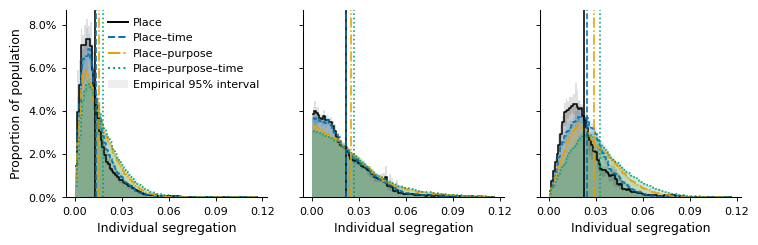

Saved figure: /content/drive/MyDrive/Colab Notebooks/Workspace/tour_generation/re1_figure/individual_all_segregation_distributions_sgp_M_6000_nb_10_across_seeds_colored.pdf
Seeds: [12345, 23456, 34567, 45678, 56789]
Displayed population coverage: 98.0%
Common x-axis range: 0.000272 to 0.116978
Common y-axis range: 0.000000 to 0.087153

Mean individual segregation across seeds:
ATTRIBUTE             METRIC  N_SEEDS     MEAN      STD
      AGE              Place        5 0.012929 0.000845
      AGE         Place–time        5 0.013579 0.000866
      AGE      Place–purpose        5 0.015790 0.000628
      AGE Place–purpose–time        5 0.017837 0.000591
   GENDER              Place        5 0.021664 0.000605
   GENDER         Place–time        5 0.022066 0.000567
   GENDER      Place–purpose        5 0.025357 0.000524
   GENDER Place–purpose–time        5 0.026899 0.000524
   INCOME              Place        5 0.022258 0.001135
   INCOME         Place–time        5 0.024351 0.001136
   I

In [ ]:
from __future__ import annotations

import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import MaxNLocator, PercentFormatter


# ============================================================
# Figure settings
# ============================================================

PANEL_FONT_SIZE = 10
AXIS_LABEL_FONT_SIZE = 9
TICK_FONT_SIZE = 8
LEGEND_FONT_SIZE = 8

plt.rcParams.update(
    {
        "font.size": TICK_FONT_SIZE,
        "axes.labelsize": AXIS_LABEL_FONT_SIZE,
        "xtick.labelsize": TICK_FONT_SIZE,
        "ytick.labelsize": TICK_FONT_SIZE,
        "legend.fontsize": LEGEND_FONT_SIZE,
        "axes.linewidth": 0.75,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }
)


# ============================================================
# Configuration
# ============================================================

reg = "sgp"
M = 6000
nb = 10
seeds = [12345, 23456, 34567, 45678, 56789]

attributes = ["AGE", "GENDER", "INCOME"]

METRIC_CONFIG = {
    "PLACE_SEGREGATION": {
        "label": "Place",
        "color": "#000000",
        "line_style": "-",
    },
    "PLACE_TIME_SEGREGATION": {
        "label": "Place–time",
        "color": "#0072B2",
        "line_style": "--",
    },
    "PLACE_PURPOSE_SEGREGATION": {
        "label": "Place–purpose",
        "color": "#E69F00",
        "line_style": "-.",
    },
    "PLACE_PURPOSE_TIME_SEGREGATION": {
        "label": "Place–purpose–time",
        "color": "#009E73",
        "line_style": ":",
    },
}

metrics = list(METRIC_CONFIG)

bar_transparency = 0.22
interval_transparency = 0.12
line_transparency = 0.95
mean_line_transparency = 1.00

n_bins = 100
population_coverage = 0.98
y_axis_padding = 0.05
dpi = 600

output_path = os.path.join(
    path_figure,
    f"individual_all_segregation_distributions_{reg}_"
    f"M_{M}_nb_{nb}_across_seeds_colored.pdf",
)


# ============================================================
# Load individual-level data
# ============================================================

def load_all_seed_data(
    path_segregation,
    reg,
    M,
    nb,
    seeds,
    attributes,
    metrics,
):
    data = {
        attribute: {metric: {} for metric in metrics}
        for attribute in attributes
    }

    for seed in seeds:
        for attribute in attributes:
            input_path = os.path.join(
                path_segregation,
                f"individual_segregation_{attribute.lower()}_{reg}_"
                f"M_{M}_nb_{nb}_seed_{seed}.csv",
            )

            dataframe = pd.read_csv(
                input_path,
                usecols=metrics,
            )

            for metric in metrics:
                values = pd.to_numeric(
                    dataframe[metric],
                    errors="coerce",
                ).to_numpy(dtype=float)

                values = values[np.isfinite(values)]

                if values.size > 0:
                    data[attribute][metric][seed] = values

    return data


# ============================================================
# Determine common x-axis range
# ============================================================

def determine_common_bin_edges(
    data,
    attributes,
    metrics,
    n_bins,
    population_coverage,
):
    lower_quantile = (1.0 - population_coverage) / 2.0
    upper_quantile = 1.0 - lower_quantile

    lower_limits = []
    upper_limits = []

    for attribute in attributes:
        for metric in metrics:
            for values in data[attribute][metric].values():
                lower_limits.append(
                    np.quantile(values, lower_quantile)
                )
                upper_limits.append(
                    np.quantile(values, upper_quantile)
                )

    if not lower_limits:
        raise ValueError(
            "No valid individual-segregation values were loaded."
        )

    x_min = float(np.min(lower_limits))
    x_max = float(np.max(upper_limits))

    if np.isclose(x_min, x_max):
        padding = max(abs(x_min) * 0.05, 1e-6)
        x_min -= padding
        x_max += padding

    bin_edges = np.linspace(
        x_min,
        x_max,
        n_bins + 1,
    )

    return bin_edges, x_min, x_max


# ============================================================
# Calculate distributions and empirical intervals
# ============================================================

def calculate_histogram_summary(
    data,
    attributes,
    metrics,
    seeds,
    bin_edges,
):
    summary = {}

    for attribute in attributes:
        summary[attribute] = {}

        for metric in metrics:
            seed_histograms = []
            seed_means = []
            available_seeds = []

            for seed in seeds:
                values = data[attribute][metric].get(seed)

                if values is None or values.size == 0:
                    continue

                counts, _ = np.histogram(
                    values,
                    bins=bin_edges,
                )

                seed_histograms.append(
                    counts.astype(float) / values.size
                )
                seed_means.append(float(np.mean(values)))
                available_seeds.append(seed)

            if not seed_histograms:
                raise ValueError(
                    f"No valid data for {attribute}, {metric}."
                )

            histogram_matrix = np.vstack(seed_histograms)

            summary[attribute][metric] = {
                "SEEDS": available_seeds,
                "MEAN": histogram_matrix.mean(axis=0),
                "P025": np.quantile(
                    histogram_matrix,
                    0.025,
                    axis=0,
                ),
                "P975": np.quantile(
                    histogram_matrix,
                    0.975,
                    axis=0,
                ),
                "MEAN_SEGREGATION": float(
                    np.mean(seed_means)
                ),
                "STD_SEGREGATION": float(
                    np.std(seed_means, ddof=1)
                    if len(seed_means) > 1
                    else np.nan
                ),
            }

    return summary


# ============================================================
# Calculate common y-axis maximum
# ============================================================

def calculate_common_y_max(
    histogram_summary,
    attributes,
    metrics,
    padding=0.05,
):
    maxima = [
        float(
            histogram_summary[attribute][metric]["P975"].max()
        )
        for attribute in attributes
        for metric in metrics
    ]

    maximum_value = max(maxima)

    if maximum_value <= 0:
        return 1e-6

    return maximum_value * (1.0 + padding)


# ============================================================
# Create mean-value table
# ============================================================

def create_mean_summary_table(
    histogram_summary,
    attributes,
    metrics,
    metric_config,
):
    records = []

    for attribute in attributes:
        for metric in metrics:
            result = histogram_summary[attribute][metric]

            records.append(
                {
                    "ATTRIBUTE": attribute,
                    "METRIC": metric_config[metric]["label"],
                    "N_SEEDS": len(result["SEEDS"]),
                    "MEAN": result["MEAN_SEGREGATION"],
                    "STD": result["STD_SEGREGATION"],
                }
            )

    return pd.DataFrame(records)


# ============================================================
# Plot distributions
# ============================================================

def plot_histogram_summary(
    summary,
    attributes,
    metrics,
    metric_config,
    bin_edges,
    y_max,
    output_path=None,
    dpi=600,
):
    bin_widths = np.diff(bin_edges)
    bin_centers = bin_edges[:-1] + bin_widths / 2.0

    fig, axes = plt.subplots(
        1,
        len(attributes),
        figsize=(2.5 * len(attributes), 2.5),
        sharex=True,
        sharey=True,
        squeeze=False,
    )

    axes = axes.ravel()

    for panel_index, (ax, attribute) in enumerate(
        zip(axes, attributes)
    ):
        for metric in metrics:
            result = summary[attribute][metric]
            config = metric_config[metric]

            color = config["color"]
            line_style = config["line_style"]

            ax.bar(
                bin_centers,
                result["MEAN"],
                width=bin_widths,
                align="center",
                color=color,
                edgecolor="none",
                alpha=bar_transparency,
                zorder=2,
                rasterized=True,
            )

            ax.fill_between(
                bin_centers,
                result["P025"],
                result["P975"],
                step="mid",
                color=color,
                alpha=interval_transparency,
                linewidth=0,
                zorder=3,
                rasterized=True,
            )

            ax.step(
                bin_centers,
                result["MEAN"],
                where="mid",
                color=color,
                linestyle=line_style,
                linewidth=1.15,
                alpha=line_transparency,
                zorder=4,
                rasterized=True,
            )

            ax.axvline(
                result["MEAN_SEGREGATION"],
                color=color,
                linestyle=line_style,
                linewidth=1.15,
                alpha=mean_line_transparency,
                zorder=5,
            )

        # Attribute names intentionally removed.
        ax.set_xlabel("Individual segregation")
        ax.set_ylim(0, y_max)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        ax.tick_params(
            direction="out",
            width=0.65,
            length=3,
            top=False,
            right=False,
        )

        ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
        ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
        ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))

        # Legend inside the first panel, without markers.
        if panel_index == 0:
            metric_handles = [
                Line2D(
                    [0],
                    [0],
                    color=config["color"],
                    linestyle=config["line_style"],
                    linewidth=1.4,
                    label=config["label"],
                )
                for config in metric_config.values()
            ]

            interval_handle = Patch(
                facecolor="#777777",
                edgecolor="none",
                alpha=interval_transparency,
                label="Empirical 95% interval",
            )

            ax.legend(
                handles=[
                    *metric_handles,
                    interval_handle,
                ],
                loc="upper right",
                frameon=False,
                ncol=1,
                handlelength=1.8,
                handletextpad=0.4,
                borderaxespad=0.3,
                fontsize=LEGEND_FONT_SIZE,
            )

    axes[0].set_ylabel("Proportion of population")

    fig.subplots_adjust(
        left=0.095,
        right=0.995,
        top=0.93,
        bottom=0.18,
        wspace=0.18,
    )

    if output_path is not None:
        output_directory = os.path.dirname(output_path)

        if output_directory:
            os.makedirs(
                output_directory,
                exist_ok=True,
            )

        fig.savefig(
            output_path,
            dpi=dpi,
            bbox_inches="tight",
            facecolor="white",
        )

    return fig, axes


# ============================================================
# Load, calculate, and plot
# ============================================================

seed_data = load_all_seed_data(
    path_segregation=path_segregation,
    reg=reg,
    M=M,
    nb=nb,
    seeds=seeds,
    attributes=attributes,
    metrics=metrics,
)

bin_edges, x_min, x_max = determine_common_bin_edges(
    data=seed_data,
    attributes=attributes,
    metrics=metrics,
    n_bins=n_bins,
    population_coverage=population_coverage,
)

histogram_summary = calculate_histogram_summary(
    data=seed_data,
    attributes=attributes,
    metrics=metrics,
    seeds=seeds,
    bin_edges=bin_edges,
)

common_y_max = calculate_common_y_max(
    histogram_summary=histogram_summary,
    attributes=attributes,
    metrics=metrics,
    padding=y_axis_padding,
)

mean_summary_table = create_mean_summary_table(
    histogram_summary=histogram_summary,
    attributes=attributes,
    metrics=metrics,
    metric_config=METRIC_CONFIG,
)

fig, axes = plot_histogram_summary(
    summary=histogram_summary,
    attributes=attributes,
    metrics=metrics,
    metric_config=METRIC_CONFIG,
    bin_edges=bin_edges,
    y_max=common_y_max,
    output_path=output_path,
    dpi=dpi,
)

plt.show()

print(f"Saved figure: {output_path}")
print(f"Seeds: {seeds}")
print(f"Displayed population coverage: {population_coverage:.1%}")
print(f"Common x-axis range: {x_min:.6f} to {x_max:.6f}")
print(f"Common y-axis range: 0.000000 to {common_y_max:.6f}")

print("\nMean individual segregation across seeds:")

print(
    mean_summary_table.to_string(
        index=False,
        float_format=lambda value: f"{value:.6f}",
    )
)


# Result 4: Subsampling

## SFigure: Popultion diversity

Processed seed 12345
Processed seed 23456
Processed seed 34567
Processed seed 45678
Processed seed 56789


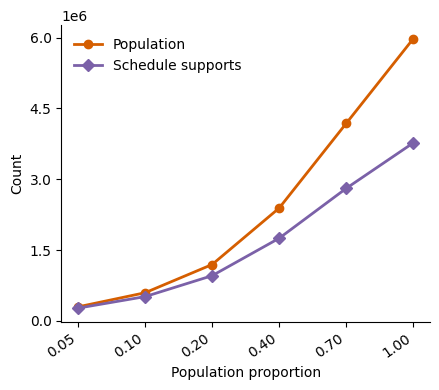


Reference total population for sgp: 6,000,000

Population and schedule diversity across settings:
SETTING_LABEL TOTAL_POPULATION_MEAN TOTAL_POPULATION_P025 TOTAL_POPULATION_P975 SCHEDULE_DIVERSITY_MEAN SCHEDULE_DIVERSITY_P025 SCHEDULE_DIVERSITY_P975
         0.05               298,749               298,620               298,861                 271,665                 271,330                 272,027
         0.10               597,501               597,246               597,721                 515,188                 514,564                 515,828
         0.20             1,194,999             1,194,487             1,195,443                 958,543                 957,361                 960,226
         0.40             2,390,001             2,388,969             2,390,892               1,750,954               1,748,300               1,754,335
         0.70             4,182,495             4,180,696             4,184,056               2,806,925               2,802,524              

In [ ]:
from __future__ import annotations

import os
from typing import List

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import MaxNLocator


# ============================================================
# CONFIGURATION
# ============================================================

MAX_TRIPS = 7

SPACE_COLS: List[str] = []
TIME_COLS: List[str] = []

for k in range(1, MAX_TRIPS + 1):
    SPACE_COLS += [f"ORIGIN_SUBZONE_{k}", f"DESTINATION_SUBZONE_{k}"]
    TIME_COLS += [f"TRIP_STARTTIME_{k}", f"TRIP_ENDTIME_{k}"]

SPACE_TIME_COLS = SPACE_COLS + TIME_COLS

reg = "sgp"
M = 6000
nb = 10
seeds = [12345, 23456, 34567, 45678, 56789]
settings = ["_frac_05", "_frac_10", "_frac_20", "_frac_40", "_frac_70", ""]

total_population_by_region = {
    "sgp": 6_000_000,
    "seoul": 9_000_000,
}

setting_labels = {
    "_frac_05": "0.05",
    "_frac_10": "0.10",
    "_frac_20": "0.20",
    "_frac_40": "0.40",
    "_frac_70": "0.70",
    "": "1.00",
}

population_color = "#D55E00"  # Vermillion/orange
diversity_color = "#7B61A8"   # Purple
interval_alpha = 0.25
summary_output_path = None
output_path = os.path.join(
    path_figure,
    f"population_and_schedule_diversity_{reg}_M_{M}_nb_{nb}_across_seeds.pdf",
)
dpi = 300


def calculate_seed_setting_summary(path_result, reg, M, nb, seed, setting):
    """Calculate population and unique space-time schedule diversity."""
    file_path = os.path.join(
        path_result,
        f"case_{reg}_sim_tour_M_{M}_nb_{nb}_seed_{seed}{setting}.csv",
    )

    required_columns = ["ID", "TRIP_MAX", *SPACE_TIME_COLS]
    df_tour = pd.read_csv(file_path, usecols=required_columns)

    return {
        "SEED": seed,
        "SETTING": setting,
        "TOTAL_POPULATION": df_tour["ID"].nunique(),
        "SCHEDULE_DIVERSITY": len(
            df_tour[["TRIP_MAX", *SPACE_TIME_COLS]].drop_duplicates()
        ),
    }


def calculate_all_seed_setting_summaries(path_result, reg, M, nb, seeds, settings):
    """Calculate population and diversity for every seed and setting."""
    rows = []

    for seed in seeds:
        for setting in settings:
            rows.append(
                calculate_seed_setting_summary(
                    path_result=path_result,
                    reg=reg,
                    M=M,
                    nb=nb,
                    seed=seed,
                    setting=setting,
                )
            )
        print(f"Processed seed {seed}")

    return pd.DataFrame(rows)


def summarize_across_seeds(seed_setting_summary):
    """Calculate across-seed means and empirical 2.5th–97.5th percentiles."""
    rows = []

    for setting, group in seed_setting_summary.groupby(
        "SETTING", observed=True, sort=False
    ):
        row = {
            "SETTING": setting,
            "N_SEEDS": group["SEED"].nunique(),
        }

        for column in ["TOTAL_POPULATION", "SCHEDULE_DIVERSITY"]:
            values = pd.to_numeric(group[column], errors="coerce").dropna()
            row[f"{column}_MEAN"] = values.mean()
            row[f"{column}_SD"] = values.std(ddof=1)
            row[f"{column}_P025"] = values.quantile(0.025)
            row[f"{column}_P975"] = values.quantile(0.975)

        rows.append(row)

    return pd.DataFrame(rows)


def plot_population_and_diversity(
    empirical_summary,
    settings,
    setting_labels,
    output_path=None,
    dpi=300,
):
    """Plot total population and schedule diversity on one count y-axis."""
    x = np.arange(len(settings), dtype=float)
    x_labels = [setting_labels.get(setting, setting if setting else "1.00") for setting in settings]
    data = empirical_summary.set_index("SETTING").reindex(settings)

    fig, ax = plt.subplots(figsize=(4.5, 4))

    for column, label, color, marker in [
        ("TOTAL_POPULATION", "Population", population_color, "o"),
        ("SCHEDULE_DIVERSITY", "Schedule supports", diversity_color, "D"),
    ]:
        mean = data[f"{column}_MEAN"].to_numpy(dtype=float)
        low = data[f"{column}_P025"].to_numpy(dtype=float)
        high = data[f"{column}_P975"].to_numpy(dtype=float)

        ax.fill_between(
            x,
            low,
            high,
            color=color,
            alpha=interval_alpha,
            linewidth=0,
            zorder=1,
        )
        ax.plot(
            x,
            mean,
            label=label,
            color=color,
            marker=marker,
            markersize=6,
            linewidth=2,
            zorder=2,
        )

    ax.set_xlabel("Population proportion", fontsize=10)
    ax.set_ylabel("Count", fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, rotation=35, ha="right")
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6))
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(loc="best", frameon=False, fontsize=10)

    fig.tight_layout()

    if output_path is not None:
        output_directory = os.path.dirname(output_path)
        if output_directory:
            os.makedirs(output_directory, exist_ok=True)
        fig.savefig(output_path, dpi=dpi, bbox_inches="tight")

    return fig, ax


# ============================================================
# RUN
# ============================================================

if __name__ == "__main__":
    if reg not in total_population_by_region:
        raise ValueError(f"Unknown region '{reg}'.")

    seed_setting_summary = calculate_all_seed_setting_summaries(
        path_result=path_result,
        reg=reg,
        M=M,
        nb=nb,
        seeds=seeds,
        settings=settings,
    )

    empirical_summary = summarize_across_seeds(seed_setting_summary)

    if summary_output_path is not None:
        output_directory = os.path.dirname(summary_output_path)
        if output_directory:
            os.makedirs(output_directory, exist_ok=True)
        empirical_summary.to_csv(summary_output_path, index=False)

    fig, ax = plot_population_and_diversity(
        empirical_summary=empirical_summary,
        settings=settings,
        setting_labels=setting_labels,
        output_path=output_path,
        dpi=dpi,
    )
    plt.show()

    print(f"\nReference total population for {reg}: {total_population_by_region[reg]:,}")
    print("\nPopulation and schedule diversity across settings:")

    display_summary = (
        empirical_summary.set_index("SETTING")
        .reindex(settings)
        .reset_index()
        .assign(SETTING_LABEL=lambda data: data["SETTING"].map(setting_labels))
    )

    print(
        display_summary[
            [
                "SETTING_LABEL",
                "TOTAL_POPULATION_MEAN",
                "TOTAL_POPULATION_P025",
                "TOTAL_POPULATION_P975",
                "SCHEDULE_DIVERSITY_MEAN",
                "SCHEDULE_DIVERSITY_P025",
                "SCHEDULE_DIVERSITY_P975",
            ]
        ].to_string(
            index=False,
            formatters={
                column: lambda value: f"{value:,.0f}"
                for column in [
                    "TOTAL_POPULATION_MEAN",
                    "TOTAL_POPULATION_P025",
                    "TOTAL_POPULATION_P975",
                    "SCHEDULE_DIVERSITY_MEAN",
                    "SCHEDULE_DIVERSITY_P025",
                    "SCHEDULE_DIVERSITY_P975",
                ]
            },
        )
    )

sgp

Population and schedule diversity across settings:
SETTING_LABEL TOTAL_POPULATION_MEAN TOTAL_POPULATION_P025 TOTAL_POPULATION_P975 SCHEDULE_DIVERSITY_MEAN SCHEDULE_DIVERSITY_P025 SCHEDULE_DIVERSITY_P975
         0.05               298,749               298,620               298,861                 271,665                 271,330                 272,027
         0.10               597,501               597,246               597,721                 515,188                 514,564                 515,828
         0.20             1,194,999             1,194,487             1,195,443                 958,543                 957,361                 960,226
         0.40             2,390,001             2,388,969             2,390,892               1,750,954               1,748,300               1,754,335
         0.70             4,182,495             4,180,696             4,184,056               2,806,925               2,802,524               2,812,568
         1.00             5,974,994             5,972,420             5,977,225               3,769,980               3,763,735               3,778,440

## Location segregation

Processed seed 12345
Processed seed 23456
Processed seed 34567
Processed seed 45678
Processed seed 56789


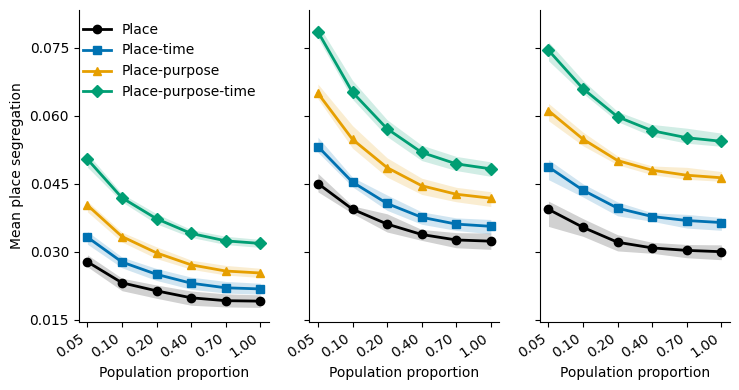


Minimum and maximum mean segregation across settings:
AGE    | Place                | Min = 0.019121 | Max = 0.027795
AGE    | Place-time           | Min = 0.021820 | Max = 0.033228
AGE    | Place-purpose        | Min = 0.025335 | Max = 0.040301
AGE    | Place-purpose-time   | Min = 0.031861 | Max = 0.050444
GENDER | Place                | Min = 0.032360 | Max = 0.045084
GENDER | Place-time           | Min = 0.035635 | Max = 0.053251
GENDER | Place-purpose        | Min = 0.041850 | Max = 0.065004
GENDER | Place-purpose-time   | Min = 0.048321 | Max = 0.078574
INCOME | Place                | Min = 0.030035 | Max = 0.039384
INCOME | Place-time           | Min = 0.036468 | Max = 0.048730
INCOME | Place-purpose        | Min = 0.046356 | Max = 0.061170
INCOME | Place-purpose-time   | Min = 0.054410 | Max = 0.074498


In [ ]:
from __future__ import annotations

import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import MaxNLocator


# ============================================================
# CONFIGURATION
# ============================================================

reg = "sgp"
M = 6000
nb = 10
seeds = [12345, 23456, 34567, 45678, 56789]
settings = ["_frac_05", "_frac_10", "_frac_20", "_frac_40", "_frac_70", ""]
attribute_order = ["AGE", "GENDER", "INCOME"]

setting_labels = {
    "_frac_05": "0.05",
    "_frac_10": "0.10",
    "_frac_20": "0.20",
    "_frac_40": "0.40",
    "_frac_70": "0.70",
    "": "1.00",
}

metric_specs = [
    {"key": "PLACE", "mean_column": "PLACE_SEGREGATION", "label": "Place", "color": "#000000", "marker": "o"},
    {"key": "TIME", "mean_column": "TIME_RESOLVED_SEGREGATION", "label": "Place-time", "color": "#0072B2", "marker": "s"},
    {"key": "PURPOSE", "mean_column": "PURPOSE_RESOLVED_SEGREGATION", "label": "Place-purpose", "color": "#E69F00", "marker": "^"},
    {
        "key": "PURPOSE_TIME",
        "mean_column": "PURPOSE_TIME_RESOLVED_SEGREGATION",
        "label": "Place-purpose-time",
        "color": "#009E73",
        "marker": "D",
    },
]

interval_alpha = 0.18
output_path = os.path.join(
    path_figure,
    f"place_vs_diversity_segregation_{reg}_"
    f"M_{M}_nb_{nb}_across_seeds.pdf")
summary_output_path = None  # Example: os.path.join(path_figure, "segregation_by_setting_empirical95.csv")
dpi = 300


def attendance_weighted_score(data, score_column, output_column):
    """Collapse resolved contexts to one attendance-weighted score per place."""
    keys = ["ACTIVITY_SUBZONE", "ATTRIBUTE"]
    data = data[[*keys, score_column, "TOTAL_ATTENDANCE_HOURS"]].copy()
    data["ATTRIBUTE"] = data["ATTRIBUTE"].astype("string").str.strip().str.upper()
    data[score_column] = pd.to_numeric(data[score_column], errors="coerce")
    data["TOTAL_ATTENDANCE_HOURS"] = pd.to_numeric(data["TOTAL_ATTENDANCE_HOURS"], errors="coerce")
    data = data.dropna(subset=[score_column, "TOTAL_ATTENDANCE_HOURS"])
    data = data.loc[data["TOTAL_ATTENDANCE_HOURS"] > 0]
    data["_WEIGHTED_SCORE"] = data[score_column] * data["TOTAL_ATTENDANCE_HOURS"]

    result = (
        data.groupby(keys, observed=True, sort=False, as_index=False)
        .agg(
            WEIGHTED_SCORE_SUM=("_WEIGHTED_SCORE", "sum"),
            TOTAL_ATTENDANCE_HOURS=("TOTAL_ATTENDANCE_HOURS", "sum"),
        )
    )
    result[output_column] = result["WEIGHTED_SCORE_SUM"] / result["TOTAL_ATTENDANCE_HOURS"]
    return result[[*keys, output_column]]


def calculate_seed_setting_summary(path_result, reg, M, nb, seed, setting):
    """Calculate mean segregation by attribute for one seed and setting."""
    file_paths = {
        "place": os.path.join(path_result, f"all_place_segregation_{reg}_M_{M}_nb_{nb}_seed_{seed}{setting}.csv"),
        "time": os.path.join(path_result, f"all_place_time_segregation_{reg}_M_{M}_nb_{nb}_seed_{seed}{setting}.csv"),
        "purpose": os.path.join(path_result, f"all_place_purpose_segregation_{reg}_M_{M}_nb_{nb}_seed_{seed}{setting}.csv"),
        "purpose_time": os.path.join(path_result, f"all_place_purpose_time_segregation_{reg}_M_{M}_nb_{nb}_seed_{seed}{setting}.csv"),
    }

    place = pd.read_csv(file_paths["place"], usecols=["ACTIVITY_SUBZONE", "ATTRIBUTE", "PLACE_SEGREGATION"])
    place["ATTRIBUTE"] = place["ATTRIBUTE"].astype("string").str.strip().str.upper()
    place["PLACE_SEGREGATION"] = pd.to_numeric(place["PLACE_SEGREGATION"], errors="coerce")
    place = place.dropna(subset=["PLACE_SEGREGATION"])

    time_summary = attendance_weighted_score(
        pd.read_csv(
            file_paths["time"],
            usecols=["ACTIVITY_SUBZONE", "ATTRIBUTE", "PLACE_TIME_SEGREGATION", "TOTAL_ATTENDANCE_HOURS"],
        ),
        "PLACE_TIME_SEGREGATION",
        "TIME_RESOLVED_SEGREGATION",
    )

    purpose_summary = attendance_weighted_score(
        pd.read_csv(
            file_paths["purpose"],
            usecols=["ACTIVITY_SUBZONE", "ATTRIBUTE", "PLACE_PURPOSE_SEGREGATION", "TOTAL_ATTENDANCE_HOURS"],
        ),
        "PLACE_PURPOSE_SEGREGATION",
        "PURPOSE_RESOLVED_SEGREGATION",
    )

    purpose_time_summary = attendance_weighted_score(
        pd.read_csv(
            file_paths["purpose_time"],
            usecols=["ACTIVITY_SUBZONE", "ATTRIBUTE", "PLACE_PURPOSE_TIME_SEGREGATION", "TOTAL_ATTENDANCE_HOURS"],
        ),
        "PLACE_PURPOSE_TIME_SEGREGATION",
        "PURPOSE_TIME_RESOLVED_SEGREGATION",
    )

    comparison = (
        place.merge(time_summary, on=["ACTIVITY_SUBZONE", "ATTRIBUTE"], how="inner")
        .merge(purpose_summary, on=["ACTIVITY_SUBZONE", "ATTRIBUTE"], how="inner")
        .merge(purpose_time_summary, on=["ACTIVITY_SUBZONE", "ATTRIBUTE"], how="inner")
    )

    summary = (
        comparison.groupby("ATTRIBUTE", observed=True, sort=False)
        .agg(
            N_PLACES=("ACTIVITY_SUBZONE", "nunique"),
            PLACE_SEGREGATION=("PLACE_SEGREGATION", "mean"),
            TIME_RESOLVED_SEGREGATION=("TIME_RESOLVED_SEGREGATION", "mean"),
            PURPOSE_RESOLVED_SEGREGATION=("PURPOSE_RESOLVED_SEGREGATION", "mean"),
            PURPOSE_TIME_RESOLVED_SEGREGATION=("PURPOSE_TIME_RESOLVED_SEGREGATION", "mean"),
        )
        .reset_index()
    )
    summary.insert(0, "SETTING", setting)
    summary.insert(0, "SEED", seed)
    return summary


def calculate_all_seed_setting_summaries(path_result, reg, M, nb, seeds, settings):
    parts = []
    for seed in seeds:
        for setting in settings:
            parts.append(calculate_seed_setting_summary(path_result, reg, M, nb, seed, setting))
        print(f"Processed seed {seed}")
    return pd.concat(parts, ignore_index=True)


def summarize_empirical_intervals(seed_setting_summaries, metric_specs):
    """Calculate across-seed means and empirical 2.5th–97.5th percentiles."""
    rows = []

    for (setting, attribute), group in seed_setting_summaries.groupby(
        ["SETTING", "ATTRIBUTE"], observed=True, sort=False
    ):
        row = {
            "SETTING": setting,
            "ATTRIBUTE": attribute,
            "N_SEEDS": group["SEED"].nunique(),
            "N_PLACES_MEAN": group["N_PLACES"].mean(),
        }

        for metric in metric_specs:
            column = metric["mean_column"]
            values = pd.to_numeric(group[column], errors="coerce").dropna()
            row[f"{column}_MEAN"] = values.mean()
            row[f"{column}_SD"] = values.std(ddof=1)
            row[f"{column}_P025"] = values.quantile(0.025)
            row[f"{column}_P975"] = values.quantile(0.975)

        rows.append(row)

    return pd.DataFrame(rows)


def plot_empirical_intervals(
    empirical_summary,
    settings,
    attributes,
    setting_labels,
    metric_specs,
    output_path=None,
    dpi=300,
):
    x = np.arange(len(settings), dtype=float)
    x_labels = [setting_labels.get(setting, setting if setting else "1.00") for setting in settings]

    fig, axes = plt.subplots(
        1,
        len(attributes),
        figsize=(2.5 * len(attributes), 4),
        sharex=True,
        sharey=True,
        squeeze=False,
    )
    axes = axes.ravel()

    for panel_index, (ax, attribute) in enumerate(zip(axes, attributes)):
        data = (
            empirical_summary.loc[empirical_summary["ATTRIBUTE"].eq(attribute)]
            .set_index("SETTING")
            .reindex(settings)
        )

        for metric in metric_specs:
            column = metric["mean_column"]
            mean = data[f"{column}_MEAN"].to_numpy(dtype=float)
            low = data[f"{column}_P025"].to_numpy(dtype=float)
            high = data[f"{column}_P975"].to_numpy(dtype=float)

            ax.fill_between(
                x, low, high, color=metric["color"], alpha=interval_alpha,
                linewidth=0, interpolate=True,
            )
            ax.plot(
                x, mean, label=metric["label"], color=metric["color"],
                marker=metric["marker"], markersize=6, linewidth=2,
            )

        ax.set_xlabel("Population proportion", fontsize=10)
        ax.set_xticks(x)
        ax.set_xticklabels(x_labels, rotation=35, ha="right")
        #ax.grid(True, linestyle=":", linewidth=0.7, alpha=0.5)
        ax.yaxis.set_major_locator(MaxNLocator(nbins=6))
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        # Legend only in the first plot.
        if panel_index == 0:
            ax.legend(loc="best", frameon=False, fontsize=10)

    axes[0].set_ylabel("Mean place segregation", fontsize=10)
    fig.tight_layout()

    if output_path is not None:
        output_directory = os.path.dirname(output_path)
        if output_directory:
            os.makedirs(output_directory, exist_ok=True)
        fig.savefig(output_path, dpi=dpi, bbox_inches="tight")

    return fig, axes


# ============================================================
# RUN
# ============================================================

if __name__ == "__main__":
    seed_setting_summaries = calculate_all_seed_setting_summaries(
        path_result=path_segregation,
        reg=reg,
        M=M,
        nb=nb,
        seeds=seeds,
        settings=settings,
    )

    empirical_summary = summarize_empirical_intervals(
        seed_setting_summaries=seed_setting_summaries,
        metric_specs=metric_specs,
    )

    if summary_output_path is not None:
        output_directory = os.path.dirname(summary_output_path)
        if output_directory:
            os.makedirs(output_directory, exist_ok=True)
        empirical_summary.to_csv(summary_output_path, index=False)

    fig, axes = plot_empirical_intervals(
        empirical_summary=empirical_summary,
        settings=settings,
        attributes=attribute_order,
        setting_labels=setting_labels,
        metric_specs=metric_specs,
        output_path=output_path,
        dpi=dpi,
    )
    plt.show()

    print("\nMinimum and maximum mean segregation across settings:")

    for attribute in attribute_order:
        attribute_data = (
            empirical_summary.loc[empirical_summary["ATTRIBUTE"].eq(attribute)]
            .set_index("SETTING")
            .reindex(settings)
        )

        for metric in metric_specs:
            column = metric["mean_column"]
            values = attribute_data[f"{column}_MEAN"].dropna()

            print(
                f"{attribute:<6} | {metric['label']:<20} | "
                f"Min = {values.min():.6f} | "
                f"Max = {values.max():.6f}"
            )

## Individual segregation

Processed seed 12345
Processed seed 23456
Processed seed 34567
Processed seed 45678
Processed seed 56789


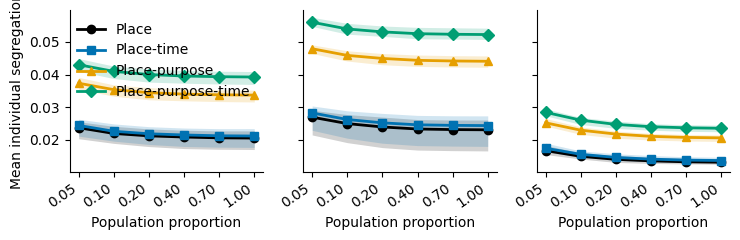


Minimum and maximum mean individual segregation across settings:
AGE    | Place                | Min = 0.020546 | Max = 0.023712
AGE    | Place-time           | Min = 0.021178 | Max = 0.024420
AGE    | Place-purpose        | Min = 0.033697 | Max = 0.037331
AGE    | Place-purpose-time   | Min = 0.039230 | Max = 0.042997
GENDER | Place                | Min = 0.023074 | Max = 0.026939
GENDER | Place-time           | Min = 0.024365 | Max = 0.028248
GENDER | Place-purpose        | Min = 0.044048 | Max = 0.047885
GENDER | Place-purpose-time   | Min = 0.052228 | Max = 0.056006
INCOME | Place                | Min = 0.013151 | Max = 0.016707
INCOME | Place-time           | Min = 0.013675 | Max = 0.017431
INCOME | Place-purpose        | Min = 0.020608 | Max = 0.025212
INCOME | Place-purpose-time   | Min = 0.023547 | Max = 0.028418


In [ ]:
from __future__ import annotations

import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import MaxNLocator


# ============================================================
# CONFIGURATION
# ============================================================

reg = "seoul"
M = 6000
nb = 10
seeds = [12345, 23456, 34567, 45678, 56789]
settings = ["_frac_05", "_frac_10", "_frac_20", "_frac_40", "_frac_70", ""]
attributes = ["AGE", "GENDER", "INCOME"]

setting_labels = {
    "_frac_05": "0.05",
    "_frac_10": "0.10",
    "_frac_20": "0.20",
    "_frac_40": "0.40",
    "_frac_70": "0.70",
    "": "1.00",
}

METRICS = [
    ("PLACE_SEGREGATION", "Place", "#000000", "o"),
    ("PLACE_TIME_SEGREGATION", "Place-time", "#0072B2", "s"),
    ("PLACE_PURPOSE_SEGREGATION", "Place-purpose", "#E69F00", "^"),
    ("PLACE_PURPOSE_TIME_SEGREGATION", "Place-purpose-time", "#009E73", "D"),
]

interval_alpha = 0.18
summary_output_path = None  # Example: os.path.join(path_figure, "individual_segregation_empirical95.csv")
output_path = os.path.join(
    path_figure,
    f"individual_place_vs_diversity_segregation_{reg}_M_{M}_nb_{nb}_across_seeds.pdf",
)
dpi = 300


def summarize_one_seed_setting(dataframe, attribute, setting, seed):
    """Calculate individual-population means for one seed, setting, and attribute."""
    score_columns = [column for column, _, _, _ in METRICS]
    data = dataframe[score_columns].copy()

    for column in score_columns:
        data[column] = pd.to_numeric(data[column], errors="coerce")
    data = data.replace([np.inf, -np.inf], np.nan).dropna()

    row = {
        "SEED": seed,
        "SETTING": setting,
        "ATTRIBUTE": attribute,
        "N_INDIVIDUALS": len(data),
    }
    for column in score_columns:
        row[f"{column}_MEAN"] = data[column].mean()
        row[f"{column}_SD"] = data[column].std(ddof=1)

    return row


def load_seed_setting_summaries(path_result, reg, M, nb, seeds, settings, attributes):
    """Load every seed-setting-attribute file and retain only seed-level summaries."""
    score_columns = [column for column, _, _, _ in METRICS]
    rows = []

    for seed in seeds:
        for setting in settings:
            for attribute in attributes:
                file_path = os.path.join(
                    path_result,
                    f"individual_segregation_{attribute.lower()}_{reg}_M_{M}_nb_{nb}_seed_{seed}{setting}.csv",
                )
                dataframe = pd.read_csv(file_path, usecols=score_columns)
                rows.append(
                    summarize_one_seed_setting(
                        dataframe=dataframe,
                        attribute=attribute,
                        setting=setting,
                        seed=seed,
                    )
                )
                del dataframe
        print(f"Processed seed {seed}")

    return pd.DataFrame(rows)


def summarize_across_seeds(seed_setting_summary):
    """Calculate empirical intervals from seed-specific population means."""
    rows = []

    for (setting, attribute), group in seed_setting_summary.groupby(
        ["SETTING", "ATTRIBUTE"], observed=True, sort=False
    ):
        row = {
            "SETTING": setting,
            "ATTRIBUTE": attribute,
            "N_SEEDS": group["SEED"].nunique(),
            "N_INDIVIDUALS_MEAN": group["N_INDIVIDUALS"].mean(),
            "N_INDIVIDUALS_MIN": group["N_INDIVIDUALS"].min(),
            "N_INDIVIDUALS_MAX": group["N_INDIVIDUALS"].max(),
        }

        for column, _, _, _ in METRICS:
            values = pd.to_numeric(group[f"{column}_MEAN"], errors="coerce").dropna()
            row[f"{column}_MEAN"] = values.mean()
            row[f"{column}_SD_ACROSS_SEEDS"] = values.std(ddof=1)
            row[f"{column}_P025"] = values.quantile(0.025)
            row[f"{column}_P975"] = values.quantile(0.975)

        rows.append(row)

    return pd.DataFrame(rows)


def plot_individual_segregation_across_seeds(
    empirical_summary,
    settings,
    attributes,
    setting_labels,
    output_path=None,
    dpi=300,
):
    """Plot across-seed means with empirical 2.5th–97.5th percentile bands."""
    x = np.arange(len(settings), dtype=float)
    x_labels = [setting_labels.get(setting, setting if setting else "1.00") for setting in settings]

    fig, axes = plt.subplots(
        1,
        len(attributes),
        figsize=(2.5 * len(attributes), 2.5),
        sharex=True,
        sharey=True,
        squeeze=False,
    )
    axes = axes.ravel()

    for panel_index, (ax, attribute) in enumerate(zip(axes, attributes)):
        data = (
            empirical_summary.loc[empirical_summary["ATTRIBUTE"].eq(attribute)]
            .set_index("SETTING")
            .reindex(settings)
        )

        for column, label, color, marker in METRICS:
            mean = data[f"{column}_MEAN"].to_numpy(dtype=float)
            low = data[f"{column}_P025"].to_numpy(dtype=float)
            high = data[f"{column}_P975"].to_numpy(dtype=float)

            ax.fill_between(
                x,
                low,
                high,
                color=color,
                alpha=interval_alpha,
                linewidth=0,
                interpolate=True,
            )
            ax.plot(
                x,
                mean,
                label=label,
                color=color,
                marker=marker,
                markersize=6,
                linewidth=2,
            )

        ax.set_xlabel("Population proportion", fontsize=10)
        ax.set_xticks(x)
        ax.set_xticklabels(x_labels, rotation=35, ha="right")
        ax.yaxis.set_major_locator(MaxNLocator(nbins=6))
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        # Legend only in the first attribute panel.
        if panel_index == 0:
            ax.legend(loc="best", frameon=False, fontsize=10)

    axes[0].set_ylabel("Mean individual segregation", fontsize=10)
    fig.tight_layout()

    if output_path is not None:
        output_directory = os.path.dirname(output_path)
        if output_directory:
            os.makedirs(output_directory, exist_ok=True)
        fig.savefig(output_path, dpi=dpi, bbox_inches="tight")

    return fig, axes


# ============================================================
# RUN
# ============================================================

if __name__ == "__main__":
    seed_setting_summary = load_seed_setting_summaries(
        path_result=path_segregation,
        reg=reg,
        M=M,
        nb=nb,
        seeds=seeds,
        settings=settings,
        attributes=attributes,
    )

    empirical_summary = summarize_across_seeds(seed_setting_summary)

    if summary_output_path is not None:
        output_directory = os.path.dirname(summary_output_path)
        if output_directory:
            os.makedirs(output_directory, exist_ok=True)
        empirical_summary.to_csv(summary_output_path, index=False)

    fig, axes = plot_individual_segregation_across_seeds(
        empirical_summary=empirical_summary,
        settings=settings,
        attributes=attributes,
        setting_labels=setting_labels,
        output_path=output_path,
        dpi=dpi,
    )
    plt.show()

    print("\nMinimum and maximum mean individual segregation across settings:")

    for attribute in attributes:
        attribute_data = (
            empirical_summary.loc[empirical_summary["ATTRIBUTE"].eq(attribute)]
            .set_index("SETTING")
            .reindex(settings)
        )

        for column, label, _, _ in METRICS:
            values = attribute_data[f"{column}_MEAN"].dropna()

            print(
                f"{attribute:<6} | {label:<20} | "
                f"Min = {values.min():.6f} | "
                f"Max = {values.max():.6f}"
            )

# Result 5: Surpose–time pattern of location segregation

## Purpose-time segregation matrix

Processed seed 12345
Processed seed 23456
Processed seed 34567
Processed seed 45678
Processed seed 56789


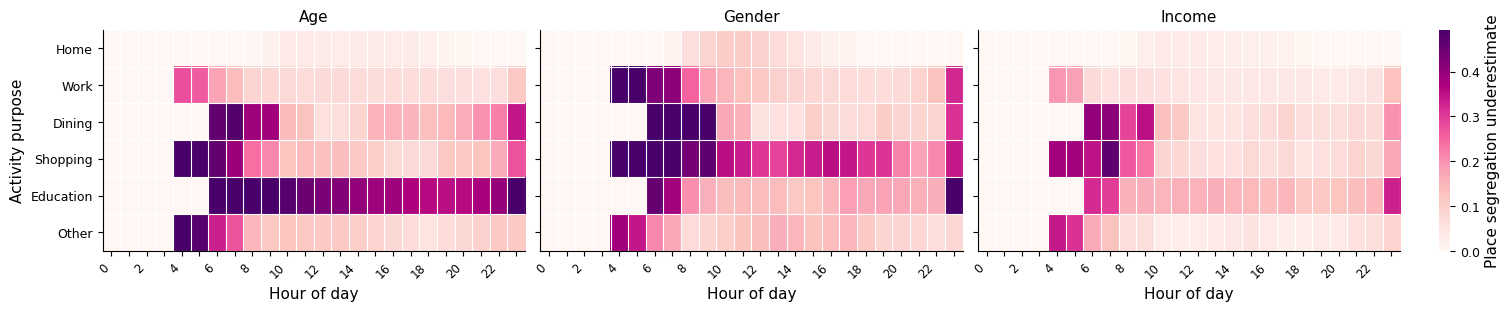

In [ ]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# ============================================================
# CONFIGURATION
# ============================================================

reg = "seoul"
M = 6000
nb = 10
seeds = [12345, 23456, 34567, 45678, 56789]
setting = ""  # For example: "_frac_20"

attributes = ["AGE", "GENDER", "INCOME"]
purposes = [0, 1, 2, 3, 4, 5]
hours = list(range(24))

purpose_labels = {
    0: "Home",
    1: "Work",
    2: "Dining",
    3: "Shopping",
    4: "Education",
    5: "Other",
}

figure_output_path = os.path.join(
    path_figure,
    f"positive_hidden_segregation_heatmaps_{reg}_M_{M}_nb_{nb}{setting}.pdf",
)

dpi = 300
colorbar_max_percentile = 95  # Use None for the absolute maximum.


def weighted_mean(values, weights):
    values = pd.to_numeric(values, errors="coerce").to_numpy(float)
    weights = pd.to_numeric(weights, errors="coerce").to_numpy(float)

    valid = np.isfinite(values) & np.isfinite(weights) & (weights > 0)

    return np.average(values[valid], weights=weights[valid]) if valid.any() else np.nan


def calculate_hidden_segregation(place_df, purpose_time_df, seed):
    place = (
        place_df.groupby("ATTRIBUTE")[["PLACE_SEGREGATION", "TOTAL_ATTENDANCE_HOURS"]]
        .apply(
            lambda data: weighted_mean(
                data["PLACE_SEGREGATION"],
                data["TOTAL_ATTENDANCE_HOURS"],
            )
        )
        .rename("PLACE_SEGREGATION")
        .reset_index()
    )

    ppt = (
        purpose_time_df.groupby(
            ["ATTRIBUTE", "ACTIVITY_PURPOSE", "ACTIVITY_TIME_SLOT"]
        )[["PLACE_PURPOSE_TIME_SEGREGATION", "TOTAL_ATTENDANCE_HOURS"]]
        .apply(
            lambda data: weighted_mean(
                data["PLACE_PURPOSE_TIME_SEGREGATION"],
                data["TOTAL_ATTENDANCE_HOURS"],
            )
        )
        .rename("PLACE_PURPOSE_TIME_SEGREGATION")
        .reset_index()
    )

    result = ppt.merge(
        place,
        on="ATTRIBUTE",
        how="inner",
        validate="many_to_one",
    )

    result["SEED"] = seed
    result["HIDDEN_SEGREGATION"] = (
        result["PLACE_PURPOSE_TIME_SEGREGATION"]
        - result["PLACE_SEGREGATION"]
    )

    return result


def load_hidden_segregation(
    path_segregation,
    reg,
    M,
    nb,
    seeds,
    setting,
):
    results = []

    for seed in seeds:
        place_path = os.path.join(
            path_segregation,
            f"all_place_segregation_{reg}_M_{M}_nb_{nb}_seed_{seed}{setting}.csv",
        )

        ppt_path = os.path.join(
            path_segregation,
            f"all_place_purpose_time_segregation_{reg}_M_{M}_nb_{nb}_seed_{seed}{setting}.csv",
        )

        if not os.path.isfile(place_path):
            raise FileNotFoundError(f"Place-segregation file not found: {place_path}")

        if not os.path.isfile(ppt_path):
            raise FileNotFoundError(
                f"Place-purpose-time file not found: {ppt_path}"
            )

        place_df = pd.read_csv(
            place_path,
            usecols=[
                "ATTRIBUTE",
                "PLACE_SEGREGATION",
                "TOTAL_ATTENDANCE_HOURS",
            ],
        )

        ppt_df = pd.read_csv(
            ppt_path,
            usecols=[
                "ATTRIBUTE",
                "ACTIVITY_PURPOSE",
                "ACTIVITY_TIME_SLOT",
                "PLACE_PURPOSE_TIME_SEGREGATION",
                "TOTAL_ATTENDANCE_HOURS",
            ],
        )

        results.append(
            calculate_hidden_segregation(
                place_df,
                ppt_df,
                seed,
            )
        )

        print(f"Processed seed {seed}")

    if not results:
        raise ValueError("No segregation results were loaded.")

    return pd.concat(results, ignore_index=True)


def plot_positive_hidden_segregation(
    hidden_by_seed,
    attributes,
    purposes,
    hours,
    output_path=None,
    dpi=300,
    colorbar_max_percentile=95,
):
    hours = sorted(
        {
            int(hour)
            for hour in hours
            if 0 <= int(hour) <= 23
        }
    )

    if not hours:
        raise ValueError("hours must contain at least one value between 0 and 23.")

    summary = (
        hidden_by_seed.groupby(
            [
                "ATTRIBUTE",
                "ACTIVITY_PURPOSE",
                "ACTIVITY_TIME_SLOT",
            ],
            as_index=False,
        )["HIDDEN_SEGREGATION"]
        .mean()
        .rename(
            columns={
                "HIDDEN_SEGREGATION": "MEAN_HIDDEN_SEGREGATION"
            }
        )
    )

    summary["POSITIVE_HIDDEN_SEGREGATION"] = summary[
        "MEAN_HIDDEN_SEGREGATION"
    ].clip(lower=0)

    selected_summary = summary.loc[
        summary["ATTRIBUTE"].isin(attributes)
        & summary["ACTIVITY_PURPOSE"].isin(purposes)
        & summary["ACTIVITY_TIME_SLOT"].isin(hours)
    ]

    values = selected_summary["POSITIVE_HIDDEN_SEGREGATION"].to_numpy(float)
    values = values[np.isfinite(values)]

    if colorbar_max_percentile is None:
        maximum = float(np.max(values)) if values.size else 1e-12
    else:
        if not 0 < colorbar_max_percentile <= 100:
            raise ValueError("colorbar_max_percentile must be in (0, 100].")

        maximum = (
            float(np.percentile(values, colorbar_max_percentile))
            if values.size
            else 1e-12
        )

    maximum = maximum if maximum > 0 else 1e-12

    fig, axes = plt.subplots(
        1,
        len(attributes),
        figsize=(5 * len(attributes), 3),
        sharey=True,
        constrained_layout=True,
    )

    axes = np.atleast_1d(axes)
    image = None

    for ax, attribute in zip(axes, attributes):
        data = selected_summary.loc[
            selected_summary["ATTRIBUTE"].eq(attribute)
        ]

        matrix = (
            data.pivot(
                index="ACTIVITY_PURPOSE",
                columns="ACTIVITY_TIME_SLOT",
                values="POSITIVE_HIDDEN_SEGREGATION",
            )
            .reindex(index=purposes, columns=hours)
            .fillna(0)
        )

        image = ax.imshow(
            matrix,
            cmap="RdPu",
            vmin=0,
            vmax=maximum,
            aspect="auto",
            interpolation="none",
        )

        ax.set_title(attribute.title(), fontsize=11)
        ax.set_xlabel("Hour of day", fontsize=11)

        ax.set_xticks(np.arange(len(hours)))
        ax.set_xticklabels(
            [
                str(hour) if hour % 2 == 0 else ""
                for hour in hours
            ],
            rotation=45,
            ha="right",
        )

        ax.set_yticks(np.arange(len(purposes)))
        ax.set_yticklabels(
            [
                purpose_labels[purpose]
                for purpose in purposes
            ]
        )

        ax.set_xticks(
            np.arange(-0.5, len(hours), 1),
            minor=True,
        )

        ax.set_yticks(
            np.arange(-0.5, len(purposes), 1),
            minor=True,
        )

        ax.grid(
            which="minor",
            color="white",
            linewidth=0.8,
        )

        ax.tick_params(
            which="minor",
            bottom=False,
            left=False,
        )

        # Remove top and right axes.
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    axes[0].set_ylabel("Activity purpose", fontsize=11)

    # Horizontal colorbar below the heatmaps.
    colorbar = fig.colorbar( image, ax=axes, orientation="vertical", location="right", fraction=0.02, pad=0.03)


    colorbar.outline.set_visible(False)
    colorbar.set_label(
        "Place segregation underestimate",
        fontsize=11,
    )

    if output_path:
        os.makedirs(
            os.path.dirname(output_path) or ".",
            exist_ok=True,
        )

        fig.savefig(
            output_path,
            dpi=dpi,
            bbox_inches="tight",
        )

    return summary, fig, axes


# ============================================================
# RUN
# ============================================================

hidden_by_seed = load_hidden_segregation(
    path_segregation=path_segregation,
    reg=reg,
    M=M,
    nb=nb,
    seeds=seeds,
    setting=setting,
)

summary, fig, axes = plot_positive_hidden_segregation(
    hidden_by_seed=hidden_by_seed,
    attributes=attributes,
    purposes=purposes,
    hours=hours,
    output_path=figure_output_path,
    dpi=dpi,
    colorbar_max_percentile=colorbar_max_percentile,
)

plt.show()

## Accumulative curve

Processed seed 12345
Processed seed 23456
Processed seed 34567
Processed seed 45678
Processed seed 56789
    ATTRIBUTE  ACTIVITY_TIME_SLOT  ACTIVITY_PURPOSE      MEAN    CI_LOW  \
0         AGE                   0               0.0  0.000063  0.000053   
1         AGE                   1               0.0  0.000126  0.000106   
2         AGE                   2               0.0  0.000189  0.000158   
3         AGE                   3               0.0  0.000252  0.000211   
4         AGE                   4               0.0  0.000315  0.000264   
..        ...                 ...               ...       ...       ...   
499    INCOME                  19               NaN       NaN       NaN   
500    INCOME                  20               NaN       NaN       NaN   
501    INCOME                  21               NaN       NaN       NaN   
502    INCOME                  22               NaN       NaN       NaN   
503    INCOME                  23               NaN       NaN       Na

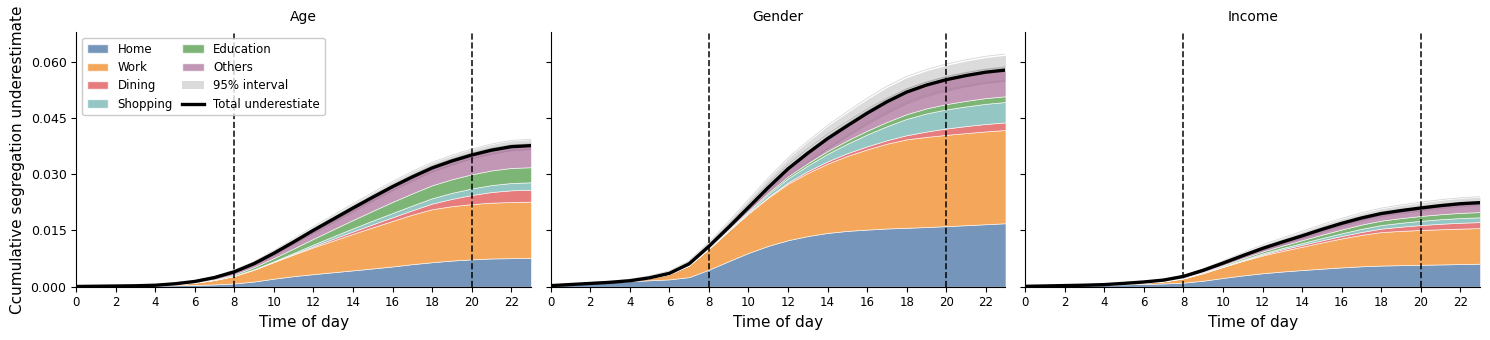

In [ ]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import MaxNLocator


# ============================================================
# CONFIGURATION
# ============================================================

reg = "seoul"
M = 6000
nb = 10
seeds = [12345, 23456, 34567, 45678, 56789]
frac = ""  # Example: "_frac_70".

attribute_order = ["AGE", "GENDER", "INCOME"]
purpose_order = [0, 1, 2, 3, 4, 5]

purpose_labels = {
    0: "Home",
    1: "Work",
    2: "Dining",
    3: "Shopping",
    4: "Education",
    5: "Others",
}

purpose_colors = {
    0: "#4E79A7",
    1: "#F28E2B",
    2: "#E15759",
    3: "#76B7B2",
    4: "#59A14F",
    5: "#B07AA1",
}

report_time_slots = [8, 20, 23]
reference_hours = [8, 20]

output_path = os.path.join(
    path_figure,
    f"{reg}_cumulative_hidden_place_purpose_time_segregation_across_seeds.pdf",
)

dpi = 300


def validate_columns(df, required, dataframe_name):
    missing = sorted(set(required).difference(df.columns))
    if missing:
        raise KeyError(f"{dataframe_name} is missing columns: {missing}")


def prepare_input(data, required_columns):
    data = data.copy()
    validate_columns(data, required_columns, "Input dataframe")

    for column in [
        "ATTRIBUTE",
        "ACTIVITY_PURPOSE",
        "ACTIVITY_TIME_SLOT",
        "TOTAL_ATTENDANCE_HOURS",
        "PLACE_SEGREGATION",
        "PLACE_PURPOSE_TIME_SEGREGATION",
    ]:
        if column not in data.columns:
            continue

        if column == "ATTRIBUTE":
            data[column] = data[column].astype("string").str.strip().str.upper()
        else:
            data[column] = pd.to_numeric(data[column], errors="coerce")

    return data


def calculate_seed_cumulative_hidden_segregation(
    place_df,
    purpose_time_df,
    seed,
):
    """Calculate cumulative positive attendance-weighted hidden segregation."""
    place_df = prepare_input(
        place_df,
        [
            "ACTIVITY_SUBZONE",
            "ATTRIBUTE",
            "PLACE_SEGREGATION",
        ],
    )

    purpose_time_df = prepare_input(
        purpose_time_df,
        [
            "ACTIVITY_SUBZONE",
            "ATTRIBUTE",
            "ACTIVITY_PURPOSE",
            "ACTIVITY_TIME_SLOT",
            "PLACE_PURPOSE_TIME_SEGREGATION",
            "TOTAL_ATTENDANCE_HOURS",
        ],
    )

    place_df = (
        place_df.dropna(
            subset=[
                "ACTIVITY_SUBZONE",
                "ATTRIBUTE",
                "PLACE_SEGREGATION",
            ]
        )
        .drop_duplicates(
            ["ACTIVITY_SUBZONE", "ATTRIBUTE"]
        )
    )

    purpose_time_df = purpose_time_df.dropna(
        subset=[
            "ACTIVITY_SUBZONE",
            "ATTRIBUTE",
            "ACTIVITY_PURPOSE",
            "ACTIVITY_TIME_SLOT",
            "PLACE_PURPOSE_TIME_SEGREGATION",
            "TOTAL_ATTENDANCE_HOURS",
        ]
    )

    purpose_time_df = purpose_time_df.loc[
        purpose_time_df["TOTAL_ATTENDANCE_HOURS"] > 0
    ]

    data = purpose_time_df.merge(
        place_df[
            [
                "ACTIVITY_SUBZONE",
                "ATTRIBUTE",
                "PLACE_SEGREGATION",
            ]
        ],
        on=[
            "ACTIVITY_SUBZONE",
            "ATTRIBUTE",
        ],
        how="inner",
        validate="many_to_one",
    )

    data["HIDDEN_SEGREGATION"] = (
        data["PLACE_PURPOSE_TIME_SEGREGATION"]
        - data["PLACE_SEGREGATION"]
    )

    data["POSITIVE_HIDDEN_SEGREGATION"] = data[
        "HIDDEN_SEGREGATION"
    ].clip(lower=0)

    data["POSITIVE_HIDDEN_SEGREGATION_HOURS"] = (
        data["POSITIVE_HIDDEN_SEGREGATION"]
        * data["TOTAL_ATTENDANCE_HOURS"]
    )

    grouped = (
        data.groupby(
            [
                "ATTRIBUTE",
                "ACTIVITY_TIME_SLOT",
                "ACTIVITY_PURPOSE",
            ],
            observed=True,
            sort=False,
            as_index=False,
        )
        .agg(
            POSITIVE_HIDDEN_SEGREGATION_HOURS=(
                "POSITIVE_HIDDEN_SEGREGATION_HOURS",
                "sum",
            ),
            ATTENDANCE_HOURS=(
                "TOTAL_ATTENDANCE_HOURS",
                "sum",
            ),
        )
    )

    daily_attendance = (
        data.groupby(
            "ATTRIBUTE",
            observed=True,
            sort=False,
        )["TOTAL_ATTENDANCE_HOURS"]
        .sum()
        .rename("TOTAL_DAILY_ATTENDANCE_HOURS")
    )

    grouped = grouped.merge(
        daily_attendance,
        on="ATTRIBUTE",
        how="left",
        validate="many_to_one",
    )

    grouped["HOURLY_HIDDEN_CONTRIBUTION"] = (
        grouped["POSITIVE_HIDDEN_SEGREGATION_HOURS"]
        / grouped["TOTAL_DAILY_ATTENDANCE_HOURS"]
    )

    complete_index = pd.MultiIndex.from_product(
        [
            attribute_order,
            range(24),
            purpose_order,
        ],
        names=[
            "ATTRIBUTE",
            "ACTIVITY_TIME_SLOT",
            "ACTIVITY_PURPOSE",
        ],
    )

    grouped = (
        grouped.set_index(
            [
                "ATTRIBUTE",
                "ACTIVITY_TIME_SLOT",
                "ACTIVITY_PURPOSE",
            ]
        )["HOURLY_HIDDEN_CONTRIBUTION"]
        .reindex(
            complete_index,
            fill_value=0.0,
        )
        .rename("HOURLY_HIDDEN_CONTRIBUTION")
        .reset_index()
        .sort_values(
            [
                "ATTRIBUTE",
                "ACTIVITY_PURPOSE",
                "ACTIVITY_TIME_SLOT",
            ]
        )
    )

    grouped["CUMULATIVE_HIDDEN_CONTRIBUTION"] = (
        grouped.groupby(
            [
                "ATTRIBUTE",
                "ACTIVITY_PURPOSE",
            ],
            observed=True,
            sort=False,
        )["HOURLY_HIDDEN_CONTRIBUTION"]
        .cumsum()
    )

    grouped["SEED"] = seed

    return grouped


def load_all_seed_results(
    path_segregation,
    reg,
    M,
    nb,
    seeds,
    frac,
):
    results = []

    for seed in seeds:
        place_path = os.path.join(
            path_segregation,
            (
                f"all_place_segregation_{reg}_M_{M}_nb_{nb}"
                f"_seed_{seed}{frac}.csv"
            ),
        )

        purpose_time_path = os.path.join(
            path_segregation,
            (
                f"all_place_purpose_time_segregation_{reg}_M_{M}"
                f"_nb_{nb}_seed_{seed}{frac}.csv"
            ),
        )

        if not os.path.isfile(place_path):
            raise FileNotFoundError(
                f"Place-segregation file not found: {place_path}"
            )

        if not os.path.isfile(purpose_time_path):
            raise FileNotFoundError(
                f"Place-purpose-time file not found: "
                f"{purpose_time_path}"
            )

        place_df = pd.read_csv(
            place_path,
            usecols=[
                "ACTIVITY_SUBZONE",
                "ATTRIBUTE",
                "PLACE_SEGREGATION",
            ],
        )

        purpose_time_df = pd.read_csv(
            purpose_time_path,
            usecols=[
                "ACTIVITY_SUBZONE",
                "ATTRIBUTE",
                "ACTIVITY_PURPOSE",
                "ACTIVITY_TIME_SLOT",
                "PLACE_PURPOSE_TIME_SEGREGATION",
                "TOTAL_ATTENDANCE_HOURS",
            ],
        )

        results.append(
            calculate_seed_cumulative_hidden_segregation(
                place_df,
                purpose_time_df,
                seed,
            )
        )

        print(f"Processed seed {seed}")

    return pd.concat(
        results,
        ignore_index=True,
    )


def summarize_across_seeds(seed_results):
    purpose_summary = (
        seed_results.groupby(
            [
                "ATTRIBUTE",
                "ACTIVITY_TIME_SLOT",
                "ACTIVITY_PURPOSE",
            ],
            observed=True,
            sort=False,
        )["CUMULATIVE_HIDDEN_CONTRIBUTION"]
        .agg(
            MEAN="mean",
            CI_LOW=lambda values: values.quantile(0.025),
            CI_HIGH=lambda values: values.quantile(0.975),
        )
        .reset_index()
    )

    total_by_seed = (
        seed_results.groupby(
            [
                "SEED",
                "ATTRIBUTE",
                "ACTIVITY_TIME_SLOT",
            ],
            observed=True,
            sort=False,
            as_index=False,
        )["CUMULATIVE_HIDDEN_CONTRIBUTION"]
        .sum()
        .rename(
            columns={
                "CUMULATIVE_HIDDEN_CONTRIBUTION": (
                    "CUMULATIVE_HIDDEN_TOTAL"
                )
            }
        )
    )

    total_summary = (
        total_by_seed.groupby(
            [
                "ATTRIBUTE",
                "ACTIVITY_TIME_SLOT",
            ],
            observed=True,
            sort=False,
        )["CUMULATIVE_HIDDEN_TOTAL"]
        .agg(
            MEAN_TOTAL="mean",
            CI_LOW_TOTAL=lambda values: values.quantile(0.025),
            CI_HIGH_TOTAL=lambda values: values.quantile(0.975),
        )
        .reset_index()
    )

    return purpose_summary, total_summary, total_by_seed


def plot_cumulative_hidden_segregation(
    purpose_summary,
    total_summary,
    total_by_seed,
    output_path=None,
    dpi=300,
    reference_hours=None,
):
    if reference_hours is None:
        reference_hours = [8, 20]

    fig, axes = plt.subplots(
        1,
        len(attribute_order),
        figsize=(5 * len(attribute_order), 3.5),
        sharex=True,
        sharey=True,
    )

    axes = np.atleast_1d(axes)

    maximum_upper = float(
        total_summary["CI_HIGH_TOTAL"].max()
    )

    y_limit = max(
        maximum_upper * 1.10,
        1e-5,
    )

    x = np.arange(24)

    for ax, attribute in zip(axes, attribute_order):
        attribute_purpose = purpose_summary.loc[
            purpose_summary["ATTRIBUTE"].eq(attribute)
        ]

        mean_table = (
            attribute_purpose.pivot(
                index="ACTIVITY_TIME_SLOT",
                columns="ACTIVITY_PURPOSE",
                values="MEAN",
            )
            .reindex(
                index=range(24),
                columns=purpose_order,
                fill_value=0.0,
            )
            .fillna(0.0)
        )

        ax.stackplot(
            x,
            *[
                mean_table[purpose].to_numpy(dtype=float)
                for purpose in purpose_order
            ],
            labels=[
                purpose_labels[purpose]
                for purpose in purpose_order
            ],
            colors=[
                purpose_colors[purpose]
                for purpose in purpose_order
            ],
            alpha=0.78,
            edgecolor="white",
            linewidth=0.5,
            zorder=2,
        )

        # Vertical dashed reference lines at 08:00 and 20:00.
        for reference_hour in reference_hours:
            if reference_hour in range(24):
                ax.axvline(
                    x=reference_hour,
                    color="black",
                    linestyle="--",
                    linewidth=1.2,
                    alpha=0.9,
                    zorder=5,
                )

        attribute_totals = total_by_seed.loc[
            total_by_seed["ATTRIBUTE"].eq(attribute)
        ]

        for _, seed_data in attribute_totals.groupby(
            "SEED",
            sort=False,
        ):
            seed_line = (
                seed_data.set_index("ACTIVITY_TIME_SLOT")[
                    "CUMULATIVE_HIDDEN_TOTAL"
                ]
                .reindex(range(24))
            )

            ax.plot(
                x,
                seed_line,
                color="black",
                linewidth=0.6,
                alpha=0.16,
                zorder=1,
            )

        total_data = (
            total_summary.loc[
                total_summary["ATTRIBUTE"].eq(attribute)
            ]
            .set_index("ACTIVITY_TIME_SLOT")
            .reindex(range(24))
        )

        ax.fill_between(
            x,
            total_data["CI_LOW_TOTAL"],
            total_data["CI_HIGH_TOTAL"],
            color="black",
            alpha=0.14,
            linewidth=0,
            zorder=1,
        )

        ax.plot(
            x,
            total_data["MEAN_TOTAL"],
            color="black",
            linewidth=2.4,
            zorder=4,
        )

        ax.set_title(
            attribute.title(),
            fontsize=10,
            pad=8,
        )

        ax.set_xlabel(
            "Time of day",
            fontsize=11,
        )

        ax.set_xticks(
            np.arange(0, 24, 2)
        )

        ax.set_xlim(0, 23)
        ax.set_ylim(0, y_limit)
        ax.yaxis.set_major_locator(
            MaxNLocator(nbins=6)
        )

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    axes[0].set_ylabel(
        "Ccumulative segregation underestimate",
        fontsize=11,
    )

    # --------------------------------------------------------
    # Legend placed inside the first panel
    # --------------------------------------------------------

    legend_handles = [
        Patch(
            facecolor=purpose_colors[purpose],
            edgecolor="white",
            alpha=0.78,
            label=purpose_labels[purpose],
        )
        for purpose in purpose_order
    ]

    legend_handles.extend(
        [
            Patch(
                facecolor="black",
                edgecolor="none",
                alpha=0.14,
                label="95% interval",
            ),
            Line2D(
                [0],
                [0],
                color="black",
                linewidth=2.4,
                label="Total underestiate",
            ),
        ]
    )

    axes[0].legend(
        handles=legend_handles,
        loc="upper left",
        #bbox_to_anchor=(0.02, 0.98),
        ncol=2,
        fontsize=8.5,
        #frameon=True,
        #fancybox=False,
        #framealpha=0.88,
        facecolor="white",
        edgecolor="0.75",
        #borderpad=0.65,
        handlelength=1.8,
        columnspacing=0.8,
        labelspacing=0.45,
    )

    fig.tight_layout()

    if output_path:
        os.makedirs(
            os.path.dirname(output_path) or ".",
            exist_ok=True,
        )

        fig.savefig(
            output_path,
            dpi=dpi,
            bbox_inches="tight",
        )

    return fig, axes


def print_purpose_shares_at_times(
    purpose_summary,
    report_time_slots,
):
    """Print purpose shares at selected hours."""
    report_time_slots = sorted(
        set(
            pd.to_numeric(
                pd.Series(report_time_slots),
                errors="coerce",
            )
            .dropna()
            .astype(int)
        )
    )

    invalid_hours = [
        hour
        for hour in report_time_slots
        if hour < 0 or hour > 23
    ]

    if invalid_hours:
        raise ValueError(
            "report_time_slots must be between 0 and 23; "
            f"invalid values: {invalid_hours}"
        )

    report = purpose_summary.loc[
        purpose_summary["ACTIVITY_TIME_SLOT"].isin(
            report_time_slots
        )
    ].copy()

    report["CUMULATIVE_TOTAL"] = (
        report.groupby(
            [
                "ATTRIBUTE",
                "ACTIVITY_TIME_SLOT",
            ],
            observed=True,
        )["MEAN"]
        .transform("sum")
    )

    report["PURPOSE_SHARE_PERCENT"] = np.where(
        report["CUMULATIVE_TOTAL"] > 0,
        100 * report["MEAN"] / report["CUMULATIVE_TOTAL"],
        np.nan,
    )

    report["ACTIVITY_PURPOSE_LABEL"] = report[
        "ACTIVITY_PURPOSE"
    ].map(purpose_labels)

    report = report.sort_values(
        [
            "ATTRIBUTE",
            "ACTIVITY_TIME_SLOT",
            "ACTIVITY_PURPOSE",
        ]
    )

    print(
        "\nPurpose shares of cumulative positive hidden segregation:"
    )

    for attribute in attribute_order:
        attribute_report = report.loc[
            report["ATTRIBUTE"].eq(attribute)
        ]

        if attribute_report.empty:
            continue

        print(f"\n{attribute.title()}")

        for hour in report_time_slots:
            hour_report = attribute_report.loc[
                attribute_report["ACTIVITY_TIME_SLOT"].eq(hour)
            ]

            if hour_report.empty:
                continue

            total = float(
                hour_report["CUMULATIVE_TOTAL"].iloc[0]
            )

            print(
                f"  {hour:02d}:00 "
                f"(cumulative total = {total:.5f})"
            )

            for _, row in hour_report.iterrows():
                share = (
                    "NA"
                    if pd.isna(row["PURPOSE_SHARE_PERCENT"])
                    else f"{row['PURPOSE_SHARE_PERCENT']:.1f}%"
                )

                print(
                    f"    {row['ACTIVITY_PURPOSE_LABEL']}: "
                    f"{share}"
                )

    return report


# ============================================================
# LOAD, CALCULATE, AND PLOT
# ============================================================

seed_results = load_all_seed_results(
    path_segregation,
    reg,
    M,
    nb,
    seeds,
    frac,
)

purpose_summary, total_summary, total_by_seed = (
    summarize_across_seeds(seed_results)
)

print(
    pd.concat(
        [
            purpose_summary.assign(SERIES="PURPOSE"),
            total_summary.assign(SERIES="TOTAL"),
        ],
        ignore_index=True,
        sort=False,
    )
)

purpose_share_report = print_purpose_shares_at_times(
    purpose_summary,
    report_time_slots,
)

fig, axes = plot_cumulative_hidden_segregation(
    purpose_summary,
    total_summary,
    total_by_seed,
    output_path=output_path,
    dpi=dpi,
    reference_hours=reference_hours,
)

plt.show()


## SFigure: Purpose-time participation matrix

Processed seed 12345
Processed seed 23456
Processed seed 34567
Processed seed 45678
Processed seed 56789


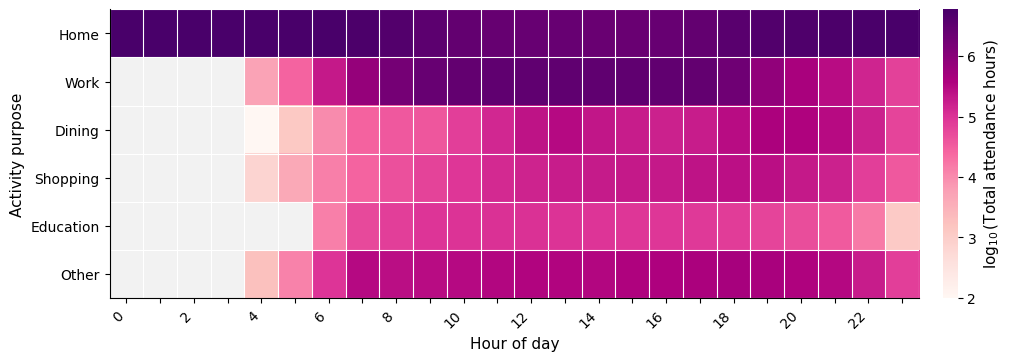

In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# ============================================================
# CONFIGURATION
# ============================================================

reg = "sgp"
M = 6000
nb = 10
seeds = [12345, 23456, 34567, 45678, 56789]
setting = ""  # For example: "_frac_20"

# Attendance patterns are identical across attributes, so plot one.
attribute_to_plot = "AGE"

purposes = [0, 1, 2, 3, 4, 5]
hours = list(range(24))

purpose_labels = {
    0: "Home",
    1: "Work",
    2: "Dining",
    3: "Shopping",
    4: "Education",
    5: "Other",
}

figure_output_path = os.path.join(
    path_figure,
    f"log_total_attendance_hours_heatmap_{reg}_M_{M}_nb_{nb}{setting}.pdf",
)

dpi = 300
colorbar_max_percentile = 95  # Set None to use the absolute maximum.


# ============================================================
# LOAD TOTAL ATTENDANCE HOURS
# ============================================================

def load_attendance_hours(
    path_segregation,
    reg,
    M,
    nb,
    seeds,
    setting,
    attribute_to_plot,
):
    results = []

    for seed in seeds:
        ppt_path = os.path.join(
            path_segregation,
            f"all_place_purpose_time_segregation_{reg}_M_{M}_nb_{nb}_seed_{seed}{setting}.csv",
        )

        if not os.path.isfile(ppt_path):
            raise FileNotFoundError(
                f"Place-purpose-time segregation file not found: {ppt_path}"
            )

        ppt_df = pd.read_csv(
            ppt_path,
            usecols=[
                "ATTRIBUTE",
                "ACTIVITY_PURPOSE",
                "ACTIVITY_TIME_SLOT",
                "TOTAL_ATTENDANCE_HOURS",
            ],
        )

        ppt_df = ppt_df.loc[
            ppt_df["ATTRIBUTE"].eq(attribute_to_plot)
        ].copy()

        if ppt_df.empty:
            raise ValueError(
                f"No rows found for ATTRIBUTE = '{attribute_to_plot}' in: {ppt_path}"
            )

        ppt_df["TOTAL_ATTENDANCE_HOURS"] = pd.to_numeric(
            ppt_df["TOTAL_ATTENDANCE_HOURS"],
            errors="coerce",
        )

        # Sum attendance hours over all activity locations within each purpose-hour cell.
        attendance = (
            ppt_df.groupby(
                ["ACTIVITY_PURPOSE", "ACTIVITY_TIME_SLOT"],
                as_index=False,
            )["TOTAL_ATTENDANCE_HOURS"]
            .sum()
        )

        attendance["SEED"] = seed
        results.append(attendance)

        print(f"Processed seed {seed}")

    if not results:
        raise ValueError("No attendance results were loaded.")

    return pd.concat(results, ignore_index=True)


# ============================================================
# PLOT LOG10(TOTAL ATTENDANCE HOURS)
# ============================================================

def plot_log_attendance_hours(
    attendance_by_seed,
    purposes,
    hours,
    output_path=None,
    dpi=300,
    colorbar_max_percentile=95,
):
    hours = sorted({int(hour) for hour in hours if 0 <= int(hour) <= 23})

    if not hours:
        raise ValueError("hours must contain at least one value between 0 and 23.")

    # Average raw attendance hours across seeds before log transformation.
    summary = (
        attendance_by_seed.groupby(
            ["ACTIVITY_PURPOSE", "ACTIVITY_TIME_SLOT"],
            as_index=False,
        )
        .agg(
            MEAN_TOTAL_ATTENDANCE_HOURS=("TOTAL_ATTENDANCE_HOURS", "mean"),
            SD_TOTAL_ATTENDANCE_HOURS=("TOTAL_ATTENDANCE_HOURS", "std"),
        )
    )

    selected_summary = summary.loc[
        summary["ACTIVITY_PURPOSE"].isin(purposes)
        & summary["ACTIVITY_TIME_SLOT"].isin(hours)
    ].copy()

    attendance_matrix = (
        selected_summary.pivot(
            index="ACTIVITY_PURPOSE",
            columns="ACTIVITY_TIME_SLOT",
            values="MEAN_TOTAL_ATTENDANCE_HOURS",
        )
        .reindex(index=purposes, columns=hours)
        .fillna(0)
    )

    attendance_values = attendance_matrix.to_numpy(dtype=float)

    # log10(0) is undefined. Zero-attendance cells are displayed in light grey.
    log_matrix = np.full(attendance_values.shape, np.nan, dtype=float)
    positive_mask = attendance_values > 0
    log_matrix[positive_mask] = np.log10(attendance_values[positive_mask])

    log_values = log_matrix[np.isfinite(log_matrix)]

    if log_values.size == 0:
        raise ValueError("No positive TOTAL_ATTENDANCE_HOURS values are available.")

    if colorbar_max_percentile is None:
        maximum = float(np.max(log_values))
    else:
        if not 0 < colorbar_max_percentile <= 100:
            raise ValueError("colorbar_max_percentile must be in (0, 100].")

        maximum = float(np.percentile(log_values, colorbar_max_percentile))

    minimum = float(np.min(log_values))

    if np.isclose(minimum, maximum):
        maximum = minimum + 1e-6

    cmap = plt.colormaps["RdPu"].copy()
    cmap.set_bad(color="#F2F2F2")

    fig, ax = plt.subplots(figsize=(10, 3.5), constrained_layout=True)

    image = ax.imshow(
        np.ma.masked_invalid(log_matrix),
        cmap=cmap,
        vmin=minimum,
        vmax=maximum,
        aspect="auto",
        interpolation="none",
    )

    ax.set_xlabel("Hour of day", fontsize=11)
    ax.set_ylabel("Activity purpose", fontsize=11)

    ax.set_xticks(np.arange(len(hours)))
    ax.set_xticklabels(
        [str(hour) if hour % 2 == 0 else "" for hour in hours],
        rotation=45,
        ha="right",
    )

    ax.set_yticks(np.arange(len(purposes)))
    ax.set_yticklabels([purpose_labels[purpose] for purpose in purposes])

    ax.set_xticks(np.arange(-0.5, len(hours), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(purposes), 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=0.8)
    ax.tick_params(which="minor", bottom=False, left=False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    colorbar = fig.colorbar(
        image,
        ax=ax,
        orientation="vertical",
        fraction=0.03,
        pad=0.03,
    )

    colorbar.outline.set_visible(False)
    colorbar.set_label(
        r"$\log_{10}$(Total attendance hours)",
        fontsize=11,
    )

    if output_path:
        os.makedirs(os.path.dirname(output_path) or ".", exist_ok=True)
        fig.savefig(output_path, dpi=dpi, bbox_inches="tight")

    return summary, fig, ax


# ============================================================
# RUN
# ============================================================

attendance_by_seed = load_attendance_hours(
    path_segregation=path_segregation,
    reg=reg,
    M=M,
    nb=nb,
    seeds=seeds,
    setting=setting,
    attribute_to_plot=attribute_to_plot,
)

summary, fig, ax = plot_log_attendance_hours(
    attendance_by_seed=attendance_by_seed,
    purposes=purposes,
    hours=hours,
    output_path=figure_output_path,
    dpi=dpi,
    colorbar_max_percentile=colorbar_max_percentile,
)

plt.show()

# Result 6: predicting individual hidden segregation

## Predictor

In [ ]:
import os
import re
import time
from dataclasses import dataclass
from typing import Iterable
import gc
import json
import joblib

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline


# =============================================================================
# 0. CONFIGURATION
# =============================================================================

path_segregation = "/content/drive/MyDrive/Colab Notebooks/Workspace/tour_generation/re1_segregation/"
REGIONS = ["sgp", "seoul"]
REGION_LABELS = {"sgp": "Singapore", "seoul": "Seoul"}

TARGET_COLUMN = "HIDDEN_PLACE_PURPOSE_TIME_SEGREGATION"
TARGET_COMPONENT_COLUMNS = [
    "PLACE_PURPOSE_TIME_SEGREGATION",
    "PLACE_SEGREGATION",
]
ATTRIBUTES = ["AGE", "GENDER", "INCOME"]
PURPOSE_CODES = [0, 1, 2, 3, 4, 5]
NON_HOUSEHOLD_PURPOSE_CODES = PURPOSE_CODES[1:]
purpose_labels = {
    0: "HOUSEHOLD",
    1: "WORK",
    2: "DINNING/REFRESHMENT",
    3: "SHOPPING",
    4: "EDUCATION",
    5: "OTHER",
}

# Set to a dictionary only if raw AGE codes must be regrouped.
AGE_GROUP_MAPPING = None

# Compact schedule set retained from the across-seed SHAP result. Features with
# consistently negligible importance were removed: destination diversity,
# revisit ratio, radius of gyration, Euclidean distance, mobility span, unique
# destinations/purposes, number of activities, and purpose transitions.
# -----------------------------------------------------------------------------
# CUSTOMIZABLE FEATURE CATALOG
# -----------------------------------------------------------------------------
# Land use at subzone z is inferred from trip arrivals by purpose. Each purpose
# share is normalized across locations, rather than across purposes at z:
#   LANDUSE_PURPOSE_p_SHARE(z) = N(destination=z, purpose=p)
#                                / sum_z' N(destination=z', purpose=p).
# HOME_CONTEXT maps the home subzone's land-use vector to each person.
# PLACE_CONTEXT averages the land-use vectors of the destination locations
# actually visited in trips 1..TRIP_MAX. The initial home activity is excluded;
# repeated destinations contribute once per recorded visit. Its purpose-share
# predictors exclude household purpose 0. Entropy still summarizes the local
# distribution across all six purposes and is therefore normalized within z.
'''
/content/drive/MyDrive/Colab Notebooks/Workspace/tour_generation/re1_segregation/
└── combined_seoul_sgp_model/
    ├── seed_12345/
    │   ├── age/
    │   ├── gender/
    │   └── income/
    └── seed_23456/
        ├── age/
        ├── gender/
        └── income/
        ....

For each seed and attribute, it saves:

nested_predictive_metrics.csv
predictive_metrics.json
combined_predictive_hgb.joblib
combined_shap_importance.csv
combined_shap_group_importance.csv
city_test_predictions.csv
combined_shap_beeswarm.png
'''
FEATURE_GROUPS = {
    "DEMOGRAPHIC": ["AGE", "GENDER", "INCOME"],
    "GENERAL_MOBILITY": ["TRIP_MAX", "MEAN_TRAVEL_TIME_HOURS"],
    "TEMPORAL_SCHEDULE": ["MEAN_TRIP_STARTTIME", "STD_TRIP_STARTTIME", "FIRST_DEPARTURE_FROM_HOME"],
    "ACTIVITY_DURATION": [
        "MEAN_ACTIVITY_DURATION_HOURS", "STD_ACTIVITY_DURATION_HOURS", "PURPOSE_ENTROPY",
        *[f"PURPOSE_{p}_DURATION_SHARE" for p in PURPOSE_CODES],
    ],
    "HOME_CONTEXT": ["HOME_LANDUSE_ENTROPY", *[f"HOME_PURPOSE_{p}_OPPOTUNITY" for p in PURPOSE_CODES]],
    "PLACE_CONTEXT": ["VISITED_LANDUSE_ENTROPY", *[f"VISITED_PURPOSE_{p}_OPPOTUNITY" for p in NON_HOUSEHOLD_PURPOSE_CODES]],
}

FEATURE_TYPE_ENABLED = {
    "DEMOGRAPHIC": False,
    "GENERAL_MOBILITY": False,
    "TEMPORAL_SCHEDULE": True,
    "ACTIVITY_DURATION": True,
    "HOME_CONTEXT": True,
    "PLACE_CONTEXT": True,
}

# Examples:
# FEATURES_TO_REMOVE = ["INCOME", "PURPOSE_3_DURATION_SHARE",
#                       "VISITED_{ATTRIBUTE}_OWN_GROUP_SHARE_STD"]
# FEATURES_TO_ADD = ["INCOME"]  # re-add a feature from a disabled type
FEATURES_TO_ADD: list[str] = []
FEATURES_TO_REMOVE: list[str] = []#["MEAN_TRAVEL_TIME_HOURS","HOME_LANDUSE_ENTROPY", "VISITED_LANDUSE_ENTROPY"]

# Nested entry stage for each feature type. Empty stages are retained in the
# output so model comparisons remain transparent after customization.
FEATURE_TYPE_STAGE = {
    "DEMOGRAPHIC": 0,
    "GENERAL_MOBILITY": 1,
    "TEMPORAL_SCHEDULE": 1,
    "ACTIVITY_DURATION": 1,
    "HOME_CONTEXT": 2,
    "PLACE_CONTEXT": 3,
}

MAIN_SHAP_GROUPS = {
    "ACTIVITY_DURATION": "Activity allocation",
    "TEMPORAL_SCHEDULE": "Temporal schedule",
    "HOME_CONTEXT": "Home opportunity structure",
    "PLACE_CONTEXT": "Visited-place opportunity structure",
    "GENERAL_MOBILITY": "Mobility intensity",
}


def _expand_feature_name(name: str, attribute: str) -> str:
    return name.replace("{ATTRIBUTE}", attribute)


def feature_groups_for_attribute(attribute: str) -> dict[str, list[str]]:
    if attribute not in ATTRIBUTES:
        raise ValueError(f"Unsupported attribute: {attribute}")
    return {group: [_expand_feature_name(name, attribute) for name in names]
            for group, names in FEATURE_GROUPS.items()}


def selected_feature_groups(attribute: str) -> dict[str, list[str]]:
    groups = feature_groups_for_attribute(attribute)
    catalog = {feature for names in groups.values() for feature in names}
    additions = {_expand_feature_name(name, attribute) for name in FEATURES_TO_ADD}
    removals = {_expand_feature_name(name, attribute) for name in FEATURES_TO_REMOVE}
    unknown = (additions | removals) - catalog
    if unknown:
        raise ValueError(f"Unknown customized features for {attribute}: {sorted(unknown)}")
    selected = {feature for group, names in groups.items() if FEATURE_TYPE_ENABLED.get(group, False) for feature in names}
    selected = (selected | additions) - removals
    return {group: [feature for feature in names if feature in selected] for group, names in groups.items()}


def selected_features(attribute: str) -> list[str]:
    return [feature for names in selected_feature_groups(attribute).values() for feature in names]


def print_feature_selection(attributes: list[str]) -> None:
    print("\nSELECTED FEATURES BY TYPE")
    for attribute in attributes:
        print(f"\n{attribute} ({len(selected_features(attribute))} features)")
        for group, features in selected_feature_groups(attribute).items():
            status = ", ".join(features) if features else "[disabled]"
            print(f"  {group}: {status}")


def display_feature_name(feature: str) -> str:
    """Return publication-ready labels for SHAP plots."""
    purpose_names = {0: "Home", 1: "Work", 2: "Dining", 3: "Shopping", 4: "Education", 5: "Other"}
    patterns = [
        (r"^PURPOSE_(\d+)_DURATION_SHARE$", lambda p: f"{purpose_names[int(p)]} time-attendance proportion"),
        (r"^HOME_PURPOSE_(\d+)_OPPOTUNITY$", lambda p: f"{purpose_names[int(p)]} opportunity at home location"),
        (r"^VISITED_PURPOSE_(\d+)_OPPOTUNITY$", lambda p: f"{purpose_names[int(p)]} opportunity at non-home visited locations"),
    ]
    for pattern, formatter in patterns:
        match = re.match(pattern, feature)
        if match:
            return formatter(match.group(1))
    labels = {
        "PURPOSE_ENTROPY": "Time-attendance proportion entropy",
        "HOME_LANDUSE_ENTROPY": "Home land-use entropy",
        "VISITED_LANDUSE_ENTROPY": "Non-home visited land-use entropy",
        "MEAN_ACTIVITY_DURATION_HOURS": "Mean activity duration",
        "STD_ACTIVITY_DURATION_HOURS": "SD of activity duration",
        "MEAN_TRIP_STARTTIME": "Mean trip start time",
        "STD_TRIP_STARTTIME": "SD of trip start time",
        "FIRST_DEPARTURE_FROM_HOME": "First departure from home",
        "MEAN_TRAVEL_TIME_HOURS": "Mean travel time",
        "TRIP_MAX": "Mumber of trips",
    }
    return labels.get(feature, feature.replace("_", " ").title())


@dataclass
class ModelConfig:
    random_state: int = 42
    test_size: float = 0.20
    max_model_rows: int | None = 1_000_000
    max_iter: int = 250
    learning_rate: float = 0.06
    max_leaf_nodes: int = 31
    min_samples_leaf: int = 50
    l2_regularization: float = 1.0
    shap_rows: int = 3_000
    shap_max_display: int = 20
    shap_direction_threshold: float = 0.10
    shap_direction_quantile: float = 0.25


# =============================================================================
# 1. GENERAL HELPERS
# =============================================================================

def validate_columns(df: pd.DataFrame, columns: Iterable[str], name: str) -> None:
    missing = [c for c in columns if c not in df.columns]
    if missing:
        raise KeyError(f"{name} is missing columns: {missing}")
    if df.empty:
        raise ValueError(f"{name} is empty.")


def sanitize_numeric(df: pd.DataFrame, columns: Iterable[str]) -> pd.DataFrame:
    for column in columns:
        if column in df.columns:
            values = pd.to_numeric(df[column], errors="coerce").to_numpy(dtype=np.float64, copy=True)
            values[~np.isfinite(values)] = np.nan
            df[column] = values
    return df


def rowwise_mean_std(matrix: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    matrix = np.asarray(matrix, dtype=np.float32)
    valid = np.isfinite(matrix)
    count = valid.sum(axis=1)
    total = np.where(valid, matrix, 0.0).sum(axis=1, dtype=np.float32)
    mean = np.divide(total, count, out=np.full(len(matrix), np.nan, np.float32), where=count > 0)
    variance = np.divide(
        np.where(valid, (matrix - mean[:, None]) ** 2, 0.0).sum(axis=1, dtype=np.float32),
        count, out=np.full(len(matrix), np.nan, np.float32), where=count > 0,
    )
    return mean, np.sqrt(variance).astype(np.float32)


def rowwise_entropy(weights: np.ndarray) -> np.ndarray:
    weights = np.asarray(weights, dtype=np.float32)
    totals = weights.sum(axis=1, keepdims=True, dtype=np.float32)
    shares = np.divide(weights, totals, out=np.zeros_like(weights), where=totals > 0)
    logs = np.zeros_like(shares)
    positive = shares > 0
    logs[positive] = np.log(shares[positive])
    return -np.sum(shares * logs, axis=1, dtype=np.float32)


def normalized_entropy(shares: np.ndarray) -> np.ndarray:
    if shares.shape[1] <= 1:
        return np.zeros(len(shares), dtype=np.float32)
    return (rowwise_entropy(np.nan_to_num(shares, nan=0.0)) / np.log(float(shares.shape[1]))).astype(np.float32)


def weighted_mean_std(values: np.ndarray, weights: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    valid = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    w = np.where(valid, weights, 0.0).astype(np.float32)
    wsum = w.sum(axis=1, dtype=np.float32)
    mean = np.divide(
        np.where(valid, values * w, 0.0).sum(axis=1, dtype=np.float32), wsum,
        out=np.full(len(values), np.nan, np.float32), where=wsum > 0,
    )
    variance = np.divide(
        np.where(valid, ((values - mean[:, None]) ** 2) * w, 0.0).sum(axis=1, dtype=np.float32),
        wsum, out=np.full(len(values), np.nan, np.float32), where=wsum > 0,
    )
    return mean, np.sqrt(variance).astype(np.float32)


def interval_overlap(start: np.ndarray, duration: np.ndarray, left: float, right: float) -> np.ndarray:
    overlap = np.maximum(np.minimum(start + duration, right) - np.maximum(start, left), 0.0).astype(np.float32)
    overlap[(~np.isfinite(start)) | (~np.isfinite(duration))] = 0.0
    return overlap


def attribute_group(df: pd.DataFrame, attribute: str) -> pd.Series:
    values = df[attribute]
    if attribute == "AGE" and AGE_GROUP_MAPPING is not None:
        return pd.to_numeric(values, errors="coerce").map(AGE_GROUP_MAPPING)
    return values.copy()


# =============================================================================
# 2. TRIP AND ACTIVITY ARRAYS
# =============================================================================

def extract_trip_arrays(df: pd.DataFrame, max_trips: int) -> dict[str, np.ndarray]:
    n = len(df)
    trip_max = pd.to_numeric(df["TRIP_MAX"], errors="coerce").fillna(0).to_numpy(np.int32, copy=False)
    trip_max = np.clip(trip_max, 0, max_trips)
    destination = np.empty((n, max_trips), dtype=object)
    origin = np.empty((n, max_trips), dtype=object)
    destination[:] = pd.NA
    origin[:] = pd.NA
    arrays = {
        "purpose": np.full((n, max_trips), np.nan, np.float32),
        "origin": origin, "destination": destination,
        "start": np.full((n, max_trips), np.nan, np.float32),
        "end": np.full((n, max_trips), np.nan, np.float32),
        "trip_max": trip_max,
    }
    prefixes = {
        "purpose": "TRIP_PURPOSE", "origin": "ORIGIN_SUBZONE",
        "destination": "DESTINATION_SUBZONE", "start": "TRIP_STARTTIME", "end": "TRIP_ENDTIME",
    }
    for j in range(1, max_trips + 1):
        for name, prefix in prefixes.items():
            column = f"{prefix}_{j}"
            if column not in df.columns:
                continue
            if name in {"origin", "destination"}:
                arrays[name][:, j - 1] = df[column].to_numpy(dtype=object, copy=False)
            else:
                arrays[name][:, j - 1] = pd.to_numeric(df[column], errors="coerce").to_numpy(np.float32, copy=False)
    arrays["within_trip_max"] = np.arange(max_trips)[None, :] < trip_max[:, None]
    return arrays


def derive_activity_arrays(arrays: dict[str, np.ndarray]) -> dict[str, np.ndarray]:
    purpose, origin, destination = arrays["purpose"], arrays["origin"], arrays["destination"]
    start, end = arrays["start"], arrays["end"]
    n, max_trips = purpose.shape
    within_trip_max = arrays["within_trip_max"]
    valid_trip = within_trip_max & np.isfinite(start) & np.isfinite(end) & pd.notna(destination)
    location = np.empty((n, max_trips + 1), dtype=object)
    location[:] = pd.NA
    activity_purpose = np.full((n, max_trips + 1), np.nan, np.float32)
    activity_start = np.full((n, max_trips + 1), np.nan, np.float32)
    duration = np.full((n, max_trips + 1), np.nan, np.float32)
    location[:, 0], activity_purpose[:, 0], activity_start[:, 0] = origin[:, 0], 0.0, 0.0
    first_departure = start[:, 0]
    duration[:, 0] = np.where(np.isfinite(first_departure) & (first_departure >= 0) & (first_departure <= 24), first_departure, np.nan)
    for j in range(max_trips):
        location[:, j + 1] = destination[:, j]
        activity_purpose[:, j + 1] = purpose[:, j]
        activity_start[:, j + 1] = end[:, j]
        next_exists = within_trip_max[:, j + 1] if j < max_trips - 1 else np.zeros(n, dtype=bool)
        next_start = np.where(next_exists, start[:, j + 1], np.nan) if j < max_trips - 1 else np.full(n, np.nan, np.float32)
        current_duration = np.where(np.isfinite(next_start), next_start - end[:, j], 24.0 - end[:, j]).astype(np.float32)
        invalid = (~valid_trip[:, j]) | (~np.isfinite(current_duration)) | (current_duration < 0) | (current_duration > 24)
        current_duration[invalid] = np.nan
        duration[:, j + 1] = current_duration
    valid = pd.notna(location) & np.isfinite(activity_purpose) & np.isfinite(activity_start) & np.isfinite(duration) & (duration > 0)
    return {"location": location, "purpose": activity_purpose, "start": activity_start,
            "duration": duration, "valid": valid, "valid_trip": valid_trip}


# =============================================================================
# 3. TRIP-PURPOSE LAND-USE LOOKUP
# =============================================================================

def build_landuse_lookup(df: pd.DataFrame, max_trips: int = 7,
                         row_chunk_size: int = 100_000) -> pd.DataFrame:
    """Estimate land use from destination-purpose counts for trips 1..TRIP_MAX."""
    partials = []
    for first in range(0, len(df), row_chunk_size):
        arrays = extract_trip_arrays(df.iloc[first:first + row_chunk_size], max_trips)
        for j in range(max_trips):
            destination, purpose = arrays["destination"][:, j], arrays["purpose"][:, j]
            mask = arrays["within_trip_max"][:, j] & pd.notna(destination) & np.isfinite(purpose) & np.isin(purpose, PURPOSE_CODES)
            if mask.any():
                current = pd.DataFrame({"LOCATION_SUBZONE": destination[mask],
                                        "ACTIVITY_PURPOSE": purpose[mask].astype(np.int16), "TRIP_COUNT": 1})
                partials.append(current.groupby(["LOCATION_SUBZONE", "ACTIVITY_PURPOSE"], observed=True,
                                                sort=False)["TRIP_COUNT"].sum().reset_index())
        del arrays
    if not partials:
        raise ValueError("No valid destination-purpose trips are available to infer land use.")
    counts = pd.concat(partials, ignore_index=True).groupby(
        ["LOCATION_SUBZONE", "ACTIVITY_PURPOSE"], observed=True, sort=False)["TRIP_COUNT"].sum().unstack(fill_value=0)
    counts = counts.reindex(columns=PURPOSE_CODES, fill_value=0)
    values = counts.to_numpy(np.float32)
    location_totals = values.sum(axis=1, keepdims=True, dtype=np.float32)
    local_purpose_shares = np.divide(values, location_totals, out=np.zeros_like(values), where=location_totals > 0)
    purpose_totals = values.sum(axis=0, keepdims=True, dtype=np.float32)
    location_shares_by_purpose = np.divide(values, purpose_totals, out=np.zeros_like(values), where=purpose_totals > 0)
    lookup = pd.DataFrame(index=counts.index)
    for k, purpose in enumerate(PURPOSE_CODES):
        lookup[f"LANDUSE_PURPOSE_{purpose}_SHARE"] = location_shares_by_purpose[:, k]
    lookup["LANDUSE_ENTROPY"] = normalized_entropy(local_purpose_shares)
    lookup["TOTAL_TRIPS"] = location_totals[:, 0]
    return lookup


# =============================================================================
# 4. LAND-USE MAPPING AND COMPACT FEATURE ENGINEERING
# =============================================================================

def add_landuse_features(additions: dict[str, np.ndarray], arrays: dict[str, np.ndarray],
                         lookup: pd.DataFrame) -> None:
    """Map home land use and average land use across destinations 1..TRIP_MAX."""
    home = pd.Series(arrays["origin"][:, 0], dtype=object)
    additions["HOME_LANDUSE_ENTROPY"] = home.map(lookup["LANDUSE_ENTROPY"]).to_numpy(np.float32)
    for purpose in PURPOSE_CODES:
        column = f"LANDUSE_PURPOSE_{purpose}_SHARE"
        additions[f"HOME_PURPOSE_{purpose}_OPPOTUNITY"] = home.map(lookup[column]).to_numpy(np.float32)

    destinations = arrays["destination"]
    valid_visit = arrays["within_trip_max"] & pd.notna(destinations)
    valid_non_household_visit = valid_visit & np.isfinite(arrays["purpose"]) & np.isin(
        arrays["purpose"], NON_HOUSEHOLD_PURPOSE_CODES)
    n, n_trips = destinations.shape
    context_columns = ["LANDUSE_ENTROPY", *[f"LANDUSE_PURPOSE_{p}_SHARE" for p in NON_HOUSEHOLD_PURPOSE_CODES]]
    for column in context_columns:
        matrix = np.full((n, n_trips), np.nan, np.float32)
        mapping = lookup[column]
        for j in range(n_trips):
            mask = valid_visit[:, j] if column == "LANDUSE_ENTROPY" else valid_non_household_visit[:, j]
            if mask.any():
                matrix[mask, j] = pd.Series(destinations[mask, j], dtype=object).map(mapping).to_numpy(np.float32)
        weights = valid_visit.astype(np.float32) if column == "LANDUSE_ENTROPY" else valid_non_household_visit.astype(np.float32)
        output = "VISITED_LANDUSE_ENTROPY" if column == "LANDUSE_ENTROPY" else column.replace(
            "LANDUSE_PURPOSE_", "VISITED_PURPOSE_").replace("_SHARE", "_OPPOTUNITY")
        additions[output] = weighted_mean_std(matrix, weights)[0]


def nested_feature_sets(attribute: str) -> dict[str, list[str]]:
    groups = selected_feature_groups(attribute)
    by_stage = {stage: [] for stage in range(4)}
    for group, features in groups.items():
        by_stage[FEATURE_TYPE_STAGE[group]].extend(features)
    m0 = by_stage[0]
    m1 = m0 + by_stage[1]
    m2 = m1 + by_stage[2]
    m3 = m2 + by_stage[3]
    candidates = {
        "M0_DEMOGRAPHICS": m0, "M1_PLUS_SCHEDULE": m1, "M2_PLUS_HOME_CONTEXT": m2,
        "M3_PLUS_PLACE_CONTEXT": m3,
    }
    # Do not fit empty stages or refit an unchanged stage after a complete type
    # has been disabled. The last retained stage is the final model.
    result, previous = {}, []
    for name, features in candidates.items():
        features = list(dict.fromkeys(features))
        if features and features != previous:
            result[name] = features
            previous = features
    if not result:
        raise ValueError(f"No predictors selected for {attribute}.")
    return result


def engineer_features(df: pd.DataFrame, landuse_lookup: pd.DataFrame,
                      attributes: list[str], max_trips: int = 7) -> pd.DataFrame:
    validate_columns(df, ["ID", "AGE", "GENDER", "INCOME", "TRIP_MAX"], "modeling sample")
    arrays = extract_trip_arrays(df, max_trips)
    activities = derive_activity_arrays(arrays)
    start, end, purpose = arrays["start"], arrays["end"], arrays["purpose"]
    valid_trip = activities["valid_trip"]
    travel_duration = (end - start).astype(np.float32)
    travel_duration[(~valid_trip) | (travel_duration < 0) | (travel_duration > 24)] = np.nan
    travel_mean, _ = rowwise_mean_std(travel_duration)
    start_mean, start_std = rowwise_mean_std(np.where(valid_trip, start, np.nan))
    activity_mean, activity_std = rowwise_mean_std(activities["duration"])
    clean_duration = np.nan_to_num(activities["duration"], nan=0.0)
    purpose_durations = np.zeros((len(df), len(PURPOSE_CODES)), np.float32)
    for k, code in enumerate(PURPOSE_CODES):
        purpose_durations[:, k] = np.where(activities["valid"] & (activities["purpose"] == code), clean_duration, 0.0).sum(axis=1)
    total = purpose_durations.sum(axis=1, dtype=np.float32)
    shares = np.divide(purpose_durations, total[:, None], out=np.zeros_like(purpose_durations), where=total[:, None] > 0)
    additions = {
        "MEAN_TRAVEL_TIME_HOURS": travel_mean, "MEAN_TRIP_STARTTIME": start_mean,
        "STD_TRIP_STARTTIME": start_std, "MEAN_ACTIVITY_DURATION_HOURS": activity_mean,
        "STD_ACTIVITY_DURATION_HOURS": activity_std, "PURPOSE_ENTROPY": rowwise_entropy(purpose_durations),
        "FIRST_DEPARTURE_FROM_HOME": start[:, 0].astype(np.float32),
    }
    for code in PURPOSE_CODES:
        additions[f"PURPOSE_{code}_DURATION_SHARE"] = shares[:, code]
    add_landuse_features(additions, arrays, landuse_lookup)
    features = pd.concat([df[["ID", "AGE", "GENDER", "INCOME", "TRIP_MAX"]].reset_index(drop=True), pd.DataFrame(additions)], axis=1)
    required = {feature for attribute in attributes for feature in selected_features(attribute)}
    features = features[["ID", *[column for column in features.columns if column in required]]]
    sanitize_numeric(features, [c for c in features.columns if c != "ID"])
    return features


# =============================================================================
# 5. COMBINED SEOUL–SINGAPORE MODEL
# =============================================================================

def output_paths(root: str, attribute: str) -> dict[str, str]:
    directory = os.path.join(root, attribute.lower())
    os.makedirs(directory, exist_ok=True)

    return {
        "directory": directory,
        "nested": os.path.join(directory, "nested_predictive_metrics.csv"),
        "metrics": os.path.join(directory, "predictive_metrics.json"),
        "model": os.path.join(directory, "combined_predictive_hgb.joblib"),
        "shap": os.path.join(directory, "combined_shap_importance.csv"),
        "shap_group": os.path.join(directory, "combined_shap_group_importance.csv"),
        "predictions": os.path.join(directory, "city_test_predictions.csv"),
        "beeswarm": os.path.join(directory, "combined_shap_beeswarm.png"),
    }


def build_model(config: ModelConfig) -> Pipeline:
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("regressor", HistGradientBoostingRegressor(
            max_iter=config.max_iter,
            learning_rate=config.learning_rate,
            max_leaf_nodes=config.max_leaf_nodes,
            min_samples_leaf=config.min_samples_leaf,
            l2_regularization=config.l2_regularization,
            random_state=config.random_state,
        )),
    ])


def evaluate(y: np.ndarray, prediction: np.ndarray) -> dict[str, float]:
    return {
        "R2": float(r2_score(y, prediction)),
        "MAE": float(mean_absolute_error(y, prediction)),
        "RMSE": float(np.sqrt(mean_squared_error(y, prediction))),
    }


def fit_combined_attribute_model(
    features_by_city: dict[str, pd.DataFrame],
    targets_by_city: dict[str, pd.DataFrame],
    attribute: str,
    root: str,
    config: ModelConfig,
) -> tuple[Pipeline, list[str], pd.DataFrame, pd.DataFrame]:
    """
    Train one pooled model using Seoul and Singapore data.

    The split is stratified by city so both cities are represented in the
    training and test sets.
    """
    pooled_data = []

    for city in REGIONS:
        if city not in features_by_city:
            raise KeyError(f"Missing engineered features for city: {city}")

        if city not in targets_by_city:
            raise KeyError(f"Missing target data for city: {city}")

        features = features_by_city[city].copy()
        target = targets_by_city[city].copy()

        validate_columns(
            target,
            ["ID", *TARGET_COMPONENT_COLUMNS],
            f"{city} target",
        )

        sanitize_numeric(target, TARGET_COMPONENT_COLUMNS)

        target[TARGET_COLUMN] = (
            target["PLACE_PURPOSE_TIME_SEGREGATION"]
            - target["PLACE_SEGREGATION"]
        )

        target = target[["ID", TARGET_COLUMN]].copy()
        target["CITY"] = city
        features["CITY"] = city

        merged = features.merge(
            target,
            on=["CITY", "ID"],
            how="inner",
            validate="one_to_one",
            sort=False,
        )

        pooled_data.append(merged)

    data = pd.concat(pooled_data, ignore_index=True)
    sanitize_numeric(data, [TARGET_COLUMN])

    data.dropna(subset=[TARGET_COLUMN], inplace=True)

    if data.empty:
        raise ValueError(f"No valid pooled observations for {attribute}.")

    feature_sets = nested_feature_sets(attribute)
    final_model_name = next(reversed(feature_sets))

    train_idx, test_idx = train_test_split(
        np.arange(len(data)),
        test_size=config.test_size,
        random_state=config.random_state,
        stratify=data["CITY"].to_numpy(),
    )

    y = data[TARGET_COLUMN].to_numpy(dtype=np.float32)

    rows = []
    previous_r2 = np.nan
    final_model = None
    final_features = None
    final_test = None
    started = time.time()

    for model_name, requested_features in feature_sets.items():
        usable = [
            column
            for column in requested_features
            if column in data.columns
            and data.iloc[train_idx][column].notna().any()
        ]

        if not usable:
            raise ValueError(
                f"No usable predictors remain for {attribute}, {model_name}."
            )

        model = build_model(config)

        model.fit(
            data.iloc[train_idx][usable],
            y[train_idx],
        )

        prediction = model.predict(
            data.iloc[test_idx][usable]
        )

        metrics = evaluate(y[test_idx], prediction)

        rows.append({
            "MODEL": model_name,
            "N_FEATURES": len(usable),
            **metrics,
            "DELTA_R2": (
                np.nan
                if np.isnan(previous_r2)
                else metrics["R2"] - previous_r2
            ),
        })

        previous_r2 = metrics["R2"]

        if model_name == final_model_name:
            final_model = model
            final_features = usable
            final_test = data.iloc[test_idx][usable].copy()
            train_prediction = model.predict(data.iloc[train_idx][usable])
            test_prediction = prediction
            train_metrics = evaluate(y[train_idx], train_prediction)

            final_metrics = {
                "attribute": attribute,
                "training_design": "Combined Seoul and Singapore",
                "n_rows": int(len(data)),
                "n_train": int(len(train_idx)),
                "n_test": int(len(test_idx)),
                "n_features": int(len(usable)),
                "fit_seconds": float(time.time() - started),
                "r2": metrics["R2"],
                "mae": metrics["MAE"],
                "rmse": metrics["RMSE"],
                "in_sample_r2": train_metrics["R2"],
                "in_sample_mae": train_metrics["MAE"],
                "in_sample_rmse": train_metrics["RMSE"],
                "city_counts": data["CITY"].value_counts().to_dict(),
            }
        else:
            del model

    paths = output_paths(root, attribute)

    nested_metrics = pd.DataFrame(rows)
    nested_metrics.insert(0, "ATTRIBUTE", attribute)
    nested_metrics.insert(0, "CITY", "Combined")
    nested_metrics.to_csv(paths["nested"], index=False)

    predictions = pd.concat([
        pd.DataFrame({
            "CITY": data.iloc[train_idx]["CITY"].to_numpy(), "ID": data.iloc[train_idx]["ID"].to_numpy(),
            "SAMPLE": "IN-SAMPLE", "OBSERVED_HIDDEN_SEGREGATION": y[train_idx],
            "PREDICTED_HIDDEN_SEGREGATION": train_prediction,
        }),
        pd.DataFrame({
            "CITY": data.iloc[test_idx]["CITY"].to_numpy(), "ID": data.iloc[test_idx]["ID"].to_numpy(),
            "SAMPLE": "OUT-OF-SAMPLE", "OBSERVED_HIDDEN_SEGREGATION": y[test_idx],
            "PREDICTED_HIDDEN_SEGREGATION": test_prediction,
        }),
    ], ignore_index=True)

    predictions.to_csv(paths["predictions"], index=False)

    with open(paths["metrics"], "w", encoding="utf-8") as file:
        json.dump(final_metrics, file, indent=2)

    joblib.dump(
        {
            "model": final_model,
            "feature_columns": final_features,
            "target": TARGET_COLUMN,
            "training_cities": REGIONS,
        },
        paths["model"],
        compress=3,
    )

    return final_model, final_features, final_test, predictions


# =============================================================================
# 6. SHAP FOR THE COMBINED MODEL
# =============================================================================

def run_combined_shap(
    model: Pipeline,
    feature_columns: list[str],
    X_test: pd.DataFrame,
    attribute: str,
    root: str,
    config: ModelConfig,
) -> pd.DataFrame:
    if X_test.empty:
        raise ValueError(f"Empty SHAP sample for {attribute}.")

    n = min(config.shap_rows, len(X_test))

    positions = np.random.default_rng(
        config.random_state
    ).choice(
        len(X_test),
        size=n,
        replace=False,
    )

    X = X_test.iloc[positions].copy()

    X_imputed = pd.DataFrame(
        model.named_steps["imputer"].transform(X),
        columns=feature_columns,
        index=X.index,
    )

    explainer = shap.TreeExplainer(
        model.named_steps["regressor"]
    )

    values = np.asarray(
        explainer.shap_values(X_imputed)
    )

    if values.ndim == 3 and values.shape[-1] == 1:
        values = values[..., 0]

    paths = output_paths(root, attribute)

    with open(paths["metrics"], encoding="utf-8") as file:
        test_r2 = float(json.load(file)["r2"])

    rows = []
    q = config.shap_direction_quantile

    for k, feature in enumerate(feature_columns):
        x = X_imputed[feature].to_numpy(dtype=float)
        phi = values[:, k].astype(float, copy=False)

        correlation = (
            pd.Series(x).corr(
                pd.Series(phi),
                method="spearman",
            )
            if np.unique(x).size > 1
            else np.nan
        )

        low_cut, high_cut = np.quantile(x, [q, 1.0 - q])

        low_mean = (
            float(phi[x <= low_cut].mean())
            if np.any(x <= low_cut)
            else np.nan
        )

        high_mean = (
            float(phi[x >= high_cut].mean())
            if np.any(x >= high_cut)
            else np.nan
        )

        high_minus_low = high_mean - low_mean

        if (
            not np.isfinite(correlation)
            or abs(correlation) < config.shap_direction_threshold
        ):
            direction = "MIXED/NONLINEAR"
        else:
            direction = "POSITIVE" if correlation > 0 else "NEGATIVE"

        rows.append({
            "CITY": "Combined",
            "ATTRIBUTE": attribute,
            "FEATURE": feature,
            "MEAN_ABS_SHAP": float(np.abs(phi).mean()),
            "MEAN_SHAP": float(phi.mean()),
            "MEAN_POSITIVE_SHAP": float(np.maximum(phi, 0).mean()),
            "MEAN_NEGATIVE_SHAP": float(np.minimum(phi, 0).mean()),
            "POSITIVE_SHAP_SHARE": float(np.mean(phi > 0)),
            "NEGATIVE_SHAP_SHARE": float(np.mean(phi < 0)),
            "SHAP_VALUE_SPEARMAN": correlation,
            "HIGH_MINUS_LOW_SHAP": high_minus_low,
            "DIRECTION": direction,
            "TEST_R2": test_r2,
        })

    result = pd.DataFrame(rows).sort_values(
        "MEAN_ABS_SHAP",
        ascending=False,
    )

    result.to_csv(paths["shap"], index=False)

    group_lookup = {
        feature: MAIN_SHAP_GROUPS[group]
        for group, features in selected_feature_groups(attribute).items()
        if group in MAIN_SHAP_GROUPS
        for feature in features
    }

    group_rows = []

    for group in MAIN_SHAP_GROUPS.values():
        indices = [
            k
            for k, feature in enumerate(feature_columns)
            if group_lookup.get(feature) == group
        ]

        if indices:
            group_values = np.abs(values[:, indices]).sum(axis=1)

            group_rows.append({
                "CITY": "Combined",
                "ATTRIBUTE": attribute,
                "FEATURE_GROUP": group,
                "GROUP_CONTRIBUTION": float(group_values.mean()),
                "GROUP_CONTRIBUTION_SD": (
                    float(group_values.std(ddof=1))
                    if len(group_values) > 1
                    else np.nan
                ),
                "N_FEATURES": len(indices),
                "TEST_R2": test_r2,
            })

    pd.DataFrame(group_rows).to_csv(
        paths["shap_group"],
        index=False,
    )

    X_display = X_imputed.rename(
        columns={
            feature: display_feature_name(feature)
            for feature in feature_columns
        }
    )

    plt.figure(figsize=(10, 9))

    shap.summary_plot(
        values,
        X_display,
        max_display=config.shap_max_display,
        show=False,
    )

    plt.title(
        f"Combined Seoul–Singapore SHAP analysis: {attribute.title()}",
        fontweight="bold",
    )

    plt.tight_layout()
    plt.savefig(
        paths["beeswarm"],
        dpi=300,
        bbox_inches="tight",
    )
    plt.close()

    return result


# =============================================================================
# 7. EXECUTION: TRAINING AND CSV OUTPUT ONLY
# =============================================================================

if __name__ == "__main__":
    M = 6000
    nb = 10
    seeds = [12345, 23456, 34567, 45678, 56789]

    attributes_to_run = ["AGE", "GENDER", "INCOME"]
    row_chunk_size = 200_000
    max_trips = 7

    config = ModelConfig(
        max_model_rows=4_000_000,
        random_state=42,
    )

    pipeline_started = time.time()
    print_feature_selection(attributes_to_run)

    for seed_number, seed in enumerate(seeds, start=1):
        started = time.time()

        seed_root = os.path.join(
            path_segregation,
            "combined_seoul_sgp_model",
            f"seed_{seed}",
        )

        features_by_city = {}
        targets_by_city = {}

        # --------------------------------------------------------
        # Build features independently for each city
        # --------------------------------------------------------
        for city in REGIONS:
            print(
                f"[{seed_number}/{len(seeds)}] Seed {seed}: "
                f"loading {REGION_LABELS.get(city, city)} population"
            )

            population_path = os.path.join(
                path_result,
                f"case_{city}_sim_tour_M_{M}_nb_{nb}_seed_{seed}.csv",
            )

            population = pd.read_csv(population_path)

            print(
                f"[{seed_number}/{len(seeds)}] Seed {seed}: "
                f"inferring {city} land use"
            )

            landuse_lookup = build_landuse_lookup(
                population,
                max_trips=max_trips,
                row_chunk_size=row_chunk_size,
            )

            if (
                config.max_model_rows is not None
                and len(population) > config.max_model_rows
            ):
                modeling_population = population.sample(
                    n=config.max_model_rows,
                    random_state=config.random_state,
                ).reset_index(drop=True)
            else:
                modeling_population = population.reset_index(drop=True)

            del population
            gc.collect()

            print(
                f"[{seed_number}/{len(seeds)}] Seed {seed}: "
                f"engineering {city} features "
                f"({len(modeling_population):,} rows)"
            )

            features_by_city[city] = engineer_features(
                modeling_population,
                landuse_lookup,
                attributes_to_run,
                max_trips=max_trips,
            )

            del modeling_population, landuse_lookup
            gc.collect()

        # --------------------------------------------------------
        # Fit one combined model per demographic attribute
        # --------------------------------------------------------
        for attribute in attributes_to_run:
            print(
                f"Seed {seed}: fitting combined Seoul–Singapore "
                f"{attribute} model"
            )

            target_template = os.path.join(
                path_segregation,
                f"individual_segregation_{{attribute}}_{{city}}_M_{M}_nb_{nb}_seed_{seed}.csv",
            )

            for city in REGIONS:
                target_path = target_template.format(
                    attribute=attribute.lower(),
                    city=city,
                )

                targets_by_city[city] = pd.read_csv(
                    target_path,
                    usecols=[
                        "ID",
                        *TARGET_COMPONENT_COLUMNS,
                    ],
                )

            model, feature_columns, X_test, _ = (
                fit_combined_attribute_model(
                    features_by_city=features_by_city,
                    targets_by_city=targets_by_city,
                    attribute=attribute,
                    root=seed_root,
                    config=config,
                )
            )

            run_combined_shap(
                model=model,
                feature_columns=feature_columns,
                X_test=X_test,
                attribute=attribute,
                root=seed_root,
                config=config,
            )

            del model, feature_columns, X_test
            gc.collect()

        del features_by_city, targets_by_city
        gc.collect()

        print(
            f"[{seed_number}/{len(seeds)}] Seed {seed} completed in "
            f"{(time.time() - started) / 60:.1f} minutes"
        )

    print(
        f"\nPipeline completed in "
        f"{(time.time() - pipeline_started) / 60:.1f} minutes"
    )



SELECTED FEATURES BY TYPE

AGE (25 features)
  DEMOGRAPHIC: [disabled]
  GENERAL_MOBILITY: [disabled]
  TEMPORAL_SCHEDULE: MEAN_TRIP_STARTTIME, STD_TRIP_STARTTIME, FIRST_DEPARTURE_FROM_HOME
  ACTIVITY_DURATION: MEAN_ACTIVITY_DURATION_HOURS, STD_ACTIVITY_DURATION_HOURS, PURPOSE_ENTROPY, PURPOSE_0_DURATION_SHARE, PURPOSE_1_DURATION_SHARE, PURPOSE_2_DURATION_SHARE, PURPOSE_3_DURATION_SHARE, PURPOSE_4_DURATION_SHARE, PURPOSE_5_DURATION_SHARE
  HOME_CONTEXT: HOME_LANDUSE_ENTROPY, HOME_PURPOSE_0_OPPOTUNITY, HOME_PURPOSE_1_OPPOTUNITY, HOME_PURPOSE_2_OPPOTUNITY, HOME_PURPOSE_3_OPPOTUNITY, HOME_PURPOSE_4_OPPOTUNITY, HOME_PURPOSE_5_OPPOTUNITY
  PLACE_CONTEXT: VISITED_LANDUSE_ENTROPY, VISITED_PURPOSE_1_OPPOTUNITY, VISITED_PURPOSE_2_OPPOTUNITY, VISITED_PURPOSE_3_OPPOTUNITY, VISITED_PURPOSE_4_OPPOTUNITY, VISITED_PURPOSE_5_OPPOTUNITY

GENDER (25 features)
  DEMOGRAPHIC: [disabled]
  GENERAL_MOBILITY: [disabled]
  TEMPORAL_SCHEDULE: MEAN_TRIP_STARTTIME, STD_TRIP_STARTTIME, FIRST_DEPARTURE_FROM_HOME


## SHAP analysis

Loaded AGE | seed 12345: /content/drive/MyDrive/Colab Notebooks/Workspace/tour_generation/re1_segregation/combined_seoul_sgp_model/seed_12345/age/combined_shap_importance.csv
Loaded AGE | seed 23456: /content/drive/MyDrive/Colab Notebooks/Workspace/tour_generation/re1_segregation/combined_seoul_sgp_model/seed_23456/age/combined_shap_importance.csv
Loaded AGE | seed 34567: /content/drive/MyDrive/Colab Notebooks/Workspace/tour_generation/re1_segregation/combined_seoul_sgp_model/seed_34567/age/combined_shap_importance.csv
Loaded AGE | seed 45678: /content/drive/MyDrive/Colab Notebooks/Workspace/tour_generation/re1_segregation/combined_seoul_sgp_model/seed_45678/age/combined_shap_importance.csv
Loaded AGE | seed 56789: /content/drive/MyDrive/Colab Notebooks/Workspace/tour_generation/re1_segregation/combined_seoul_sgp_model/seed_56789/age/combined_shap_importance.csv
Loaded GENDER | seed 12345: /content/drive/MyDrive/Colab Notebooks/Workspace/tour_generation/re1_segregation/combined_seoul_s

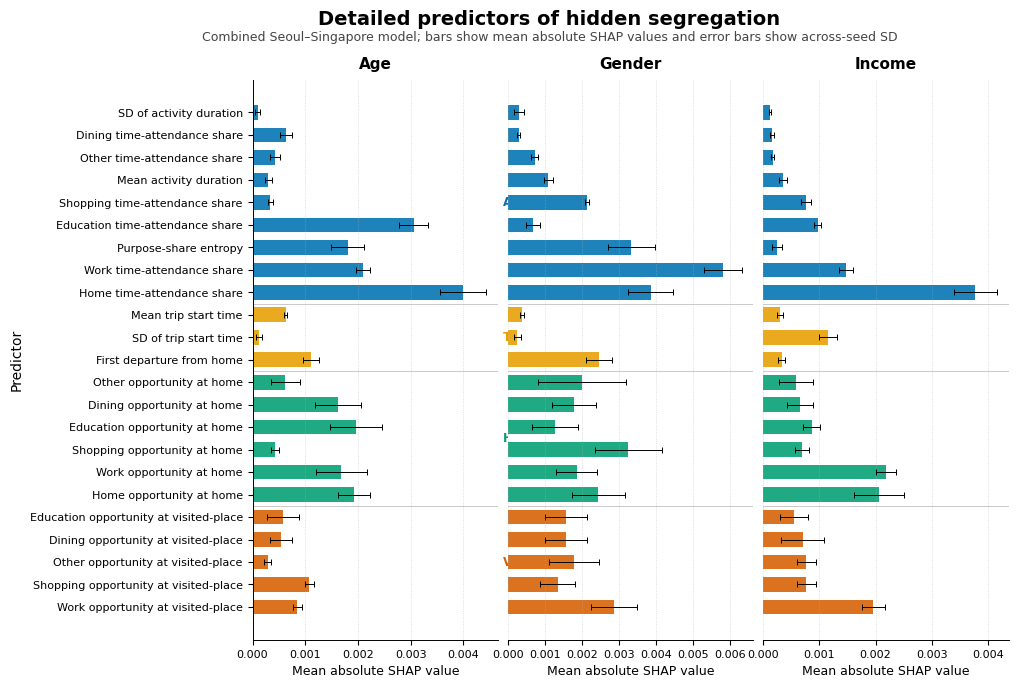

In [ ]:
from __future__ import annotations

import glob
import os
import re
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# =============================================================================
# CONFIGURATION
# =============================================================================

try:
    combined_model_root = Path(path_segregation) / "combined_seoul_sgp_model"
except NameError as exc:
    raise NameError("Define `path_segregation` before running this script.") from exc

attributes_to_plot = ["AGE", "GENDER", "INCOME"]
output_plot_path = combined_model_root / "combined_detailed_shap_grouped_by_feature_type.png"

feature_type_order = [
    "ACTIVITY_DURATION",
    "TEMPORAL_SCHEDULE",
    "HOME_CONTEXT",
    "PLACE_CONTEXT",
]

feature_type_labels = {
    "ACTIVITY_DURATION": "Activity allocation",
    "TEMPORAL_SCHEDULE": "Temporal schedule",
    "HOME_CONTEXT": "Home opportunity structure",
    "PLACE_CONTEXT": "Visited-place opportunity structure",
}

feature_type_colors = {
    "ACTIVITY_DURATION": "#0072B2",
    "TEMPORAL_SCHEDULE": "#E69F00",
    "HOME_CONTEXT": "#009E73",
    "PLACE_CONTEXT": "#D55E00",
}

FEATURE_TYPE_ENABLED = {
    "DEMOGRAPHIC": False,
    "GENERAL_MOBILITY": False,
    "TEMPORAL_SCHEDULE": True,
    "ACTIVITY_DURATION": True,
    "HOME_CONTEXT": True,
    "PLACE_CONTEXT": True,
}

FEATURES_TO_ADD: list[str] = []
FEATURES_TO_REMOVE = [
    "MEAN_TRAVEL_TIME_HOURS",
    "HOME_LANDUSE_ENTROPY",
    "VISITED_LANDUSE_ENTROPY",
]

purpose_labels = {
    0: "Home", 1: "Work", 2: "Dining", 3: "Shopping",
    4: "Education", 5: "Other",
}

FEATURE_GROUPS = {
    "DEMOGRAPHIC": ["AGE", "GENDER", "INCOME"],
    "GENERAL_MOBILITY": ["TRIP_MAX", "MEAN_TRAVEL_TIME_HOURS"],
    "TEMPORAL_SCHEDULE": [
        "MEAN_TRIP_STARTTIME", "STD_TRIP_STARTTIME", "FIRST_DEPARTURE_FROM_HOME",
    ],
    "ACTIVITY_DURATION": [
        "MEAN_ACTIVITY_DURATION_HOURS", "STD_ACTIVITY_DURATION_HOURS", "PURPOSE_ENTROPY",
        *[f"PURPOSE_{i}_DURATION_SHARE" for i in range(6)],
    ],
    "HOME_CONTEXT": [
        "HOME_LANDUSE_ENTROPY", *[f"HOME_PURPOSE_{i}_OPPOTUNITY" for i in range(6)],
    ],
    "PLACE_CONTEXT": [
        "VISITED_LANDUSE_ENTROPY", *[f"VISITED_PURPOSE_{i}_OPPOTUNITY" for i in range(1, 6)],
    ],
}


def configure_style() -> None:
    mpl.rcParams.update({
        "font.family": "DejaVu Sans", "font.size": 9,
        "axes.titlesize": 11, "axes.labelsize": 9,
        "xtick.labelsize": 8, "ytick.labelsize": 8,
        "axes.linewidth": 0.7, "pdf.fonttype": 42, "ps.fonttype": 42,
        "savefig.facecolor": "white",
    })


def selected_feature_groups() -> dict[str, list[str]]:
    catalog = {f for features in FEATURE_GROUPS.values() for f in features}
    unknown = (set(FEATURES_TO_ADD) | set(FEATURES_TO_REMOVE)) - catalog
    if unknown:
        raise ValueError(f"Unknown features: {sorted(unknown)}")
    selected = {
        group: list(features) if FEATURE_TYPE_ENABLED.get(group, False) else []
        for group, features in FEATURE_GROUPS.items()
    }
    active = set(FEATURES_TO_ADD)
    for features in selected.values():
        active.update(features)
    active.difference_update(FEATURES_TO_REMOVE)
    return {group: [f for f in features if f in active] for group, features in selected.items()}


def display_feature_name(feature: str) -> str:
    labels = {
        "PURPOSE_ENTROPY": "Purpose-share entropy",
        "HOME_LANDUSE_ENTROPY": "Home land-use entropy",
        "VISITED_LANDUSE_ENTROPY": "Visited-place land-use entropy",
        "MEAN_ACTIVITY_DURATION_HOURS": "Mean activity duration",
        "STD_ACTIVITY_DURATION_HOURS": "SD of activity duration",
        "MEAN_TRIP_STARTTIME": "Mean trip start time",
        "STD_TRIP_STARTTIME": "SD of trip start time",
        "FIRST_DEPARTURE_FROM_HOME": "First departure from home",
        "MEAN_TRAVEL_TIME_HOURS": "Mean travel time",
    }
    match = re.match(r"^(HOME|VISITED)?_?PURPOSE_(\d+)_(DURATION_SHARE|OPPOTUNITY)$", feature)
    if match:
        prefix, code, kind = match.groups()
        purpose = purpose_labels[int(code)]
        if kind == "DURATION_SHARE":
            return f"{purpose} time-attendance share"
        location = "home" if prefix == "HOME" else "visited-place"
        return f"{purpose} opportunity at {location}"
    return labels.get(feature, feature.replace("_", " ").title())


def load_combined_shap_results(root: Path, attributes: list[str]) -> pd.DataFrame:
    frames = []
    loaded = set()
    required = {"FEATURE", "MEAN_ABS_SHAP"}

    for attribute in attributes:
        pattern = root / "seed_*" / attribute.lower() / "combined_shap_importance.csv"
        files = sorted(Path(path) for path in glob.glob(str(pattern)))
        if not files:
            raise FileNotFoundError(f"No SHAP file found for {attribute}: {pattern}")

        for file_path in files:
            if file_path in loaded:
                continue
            data = pd.read_csv(file_path)
            missing = required - set(data.columns)
            if missing:
                raise KeyError(f"{file_path} is missing columns: {sorted(missing)}")
            match = re.search(r"seed_(\d+)", str(file_path), flags=re.IGNORECASE)
            if match is None:
                raise ValueError(f"Cannot identify seed from {file_path}")
            data = data.copy()
            data["SEED"] = int(match.group(1))
            data["ATTRIBUTE"] = attribute
            data["SOURCE_FILE"] = str(file_path)
            frames.append(data)
            loaded.add(file_path)
            print(f"Loaded {attribute} | seed {data['SEED'].iloc[0]}: {file_path}")

    return pd.concat(frames, ignore_index=True)


def summarize_shap(data: pd.DataFrame) -> pd.DataFrame:
    lookup = {
        feature: group
        for group, features in selected_feature_groups().items()
        for feature in features
    }
    data = data.copy()
    data["FEATURE_TYPE"] = data["FEATURE"].map(lookup).fillna("OTHER")
    data = data[data["FEATURE_TYPE"].isin(feature_type_order)].copy()
    data["MEAN_ABS_SHAP"] = pd.to_numeric(data["MEAN_ABS_SHAP"], errors="coerce")
    data = data.dropna(subset=["MEAN_ABS_SHAP"])

    summary = data.groupby(
        ["ATTRIBUTE", "FEATURE_TYPE", "FEATURE"], as_index=False,
    ).agg(
        MEAN_ABS_SHAP=("MEAN_ABS_SHAP", "mean"),
        SD_ABS_SHAP=("MEAN_ABS_SHAP", "std"),
        N_SEEDS=("SEED", "nunique"),
    )
    summary["SD_ABS_SHAP"] = summary["SD_ABS_SHAP"].fillna(0.0)
    summary["FEATURE_TYPE_ORDER"] = summary["FEATURE_TYPE"].map(
        {group: i for i, group in enumerate(feature_type_order)}
    )
    return summary


def plot_detailed_shap_grouped(
    shap_summary: pd.DataFrame,
    attributes: list[str],
    output_path: Path,
):
    # One common feature order ensures that all three panels are comparable.
    feature_order = (
        shap_summary.groupby(
            ["FEATURE_TYPE", "FEATURE", "FEATURE_TYPE_ORDER"], as_index=False,
        )["MEAN_ABS_SHAP"].mean()
        .sort_values(["FEATURE_TYPE_ORDER", "MEAN_ABS_SHAP"], ascending=[True, True])
        ["FEATURE"].tolist()[::-1]
    )
    type_lookup = shap_summary.drop_duplicates("FEATURE").set_index("FEATURE")["FEATURE_TYPE"].to_dict()
    y = np.arange(len(feature_order))

    fig, axes = plt.subplots(
        1, len(attributes), figsize=(13.5, 7), sharey=True, squeeze=False,
        gridspec_kw={"wspace": 0.04},
    )
    axes = axes.ravel()

    for panel_index, (ax, attribute) in enumerate(zip(axes, attributes)):
        data = shap_summary[shap_summary["ATTRIBUTE"].eq(attribute)].set_index("FEATURE").reindex(feature_order)
        values = data["MEAN_ABS_SHAP"].fillna(0).to_numpy()
        errors = data["SD_ABS_SHAP"].fillna(0).to_numpy()
        colors = [feature_type_colors.get(type_lookup.get(feature), "#999999") for feature in feature_order]

        ax.barh(
            y, values, xerr=errors, height=0.65, color=colors, alpha=0.88,
            error_kw={"elinewidth": 0.7, "capsize": 2, "capthick": 0.7},
            edgecolor="none",
        )
        ax.set_yticks(y)
        if panel_index == 0:
            ax.set_yticklabels([display_feature_name(feature) for feature in feature_order], fontsize=8)
            ax.set_ylabel("Predictor", fontsize=10)
        else:
            ax.tick_params(axis="y", left=False, labelleft=False)
        ax.set_xlabel("Mean absolute SHAP value", fontsize=9)
        ax.set_title(attribute.title(), fontsize=11, fontweight="bold", pad=8)
        ax.grid(axis="x", linestyle=":", linewidth=0.6, alpha=0.55)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_visible(panel_index == 0)

    group_positions = {}
    for position, feature in enumerate(feature_order):
        group_positions.setdefault(type_lookup.get(feature), []).append(position)
    for group in feature_type_order:
        positions = group_positions.get(group, [])
        if not positions:
            continue
        first, last = min(positions), max(positions)
        for ax in axes:
            if first > 0:
                ax.axhline(first - 0.5, color="#BDBDBD", linewidth=0.7, alpha=0.8)
        axes[0].text(
            1.02, (first + last) / 2, feature_type_labels[group],
            transform=axes[0].get_yaxis_transform(), va="center", ha="left",
            fontsize=8.5, fontweight="bold", color=feature_type_colors[group],
        )

    fig.suptitle("Detailed predictors of hidden segregation", fontsize=14, fontweight="bold", x=0.52, y=0.98)
    fig.text(0.52, 0.935, "Combined Seoul–Singapore model; bars show mean absolute SHAP values and error bars show across-seed SD",
             ha="center", fontsize=9, color="#444444")
    fig.subplots_adjust(left=0.30, right=0.86, bottom=0.08, top=0.88, wspace=0.04)

    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, dpi=600, bbox_inches="tight")
    fig.savefig(output_path.with_suffix(".pdf"), bbox_inches="tight")
    print(f"Saved: {output_path}")
    print(f"Saved: {output_path.with_suffix('.pdf')}")
    return fig, axes


if __name__ == "__main__":
    configure_style()
    raw = load_combined_shap_results(combined_model_root, attributes_to_plot)
    summary = summarize_shap(raw)
    summary_path = output_plot_path.with_name(output_plot_path.stem + "_summary.csv")
    summary.to_csv(summary_path, index=False)
    plot_detailed_shap_grouped(summary, attributes_to_plot, output_plot_path)
    plt.show()


## Scatter plot

Loaded out-of-sample data | AGE | seed 12345: /content/drive/MyDrive/Colab Notebooks/Workspace/tour_generation/re1_segregation/combined_seoul_sgp_model/seed_12345/age/city_test_predictions.csv
Loaded out-of-sample data | AGE | seed 23456: /content/drive/MyDrive/Colab Notebooks/Workspace/tour_generation/re1_segregation/combined_seoul_sgp_model/seed_23456/age/city_test_predictions.csv
Loaded out-of-sample data | AGE | seed 34567: /content/drive/MyDrive/Colab Notebooks/Workspace/tour_generation/re1_segregation/combined_seoul_sgp_model/seed_34567/age/city_test_predictions.csv
Loaded out-of-sample data | AGE | seed 45678: /content/drive/MyDrive/Colab Notebooks/Workspace/tour_generation/re1_segregation/combined_seoul_sgp_model/seed_45678/age/city_test_predictions.csv
Loaded out-of-sample data | AGE | seed 56789: /content/drive/MyDrive/Colab Notebooks/Workspace/tour_generation/re1_segregation/combined_seoul_sgp_model/seed_56789/age/city_test_predictions.csv
Loaded out-of-sample data | GENDER 

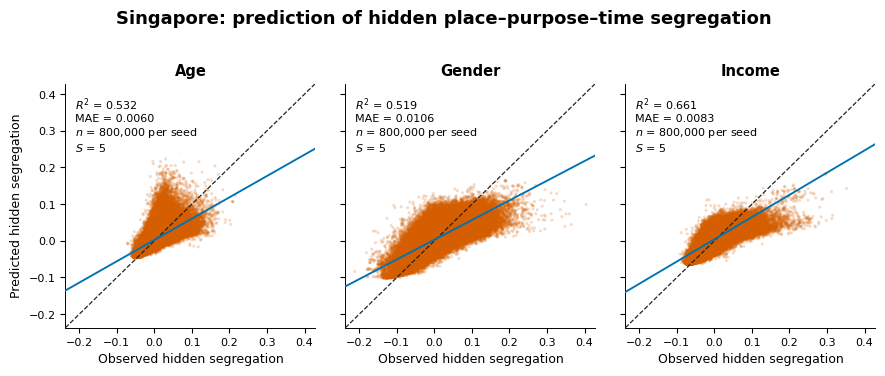

Saved: /content/drive/MyDrive/Colab Notebooks/Workspace/tour_generation/re1_segregation/combined_seoul_sgp_model/figures/seoul_out_of_sample_scatter_plots.png
Saved: /content/drive/MyDrive/Colab Notebooks/Workspace/tour_generation/re1_segregation/combined_seoul_sgp_model/figures/seoul_out_of_sample_scatter_plots.pdf


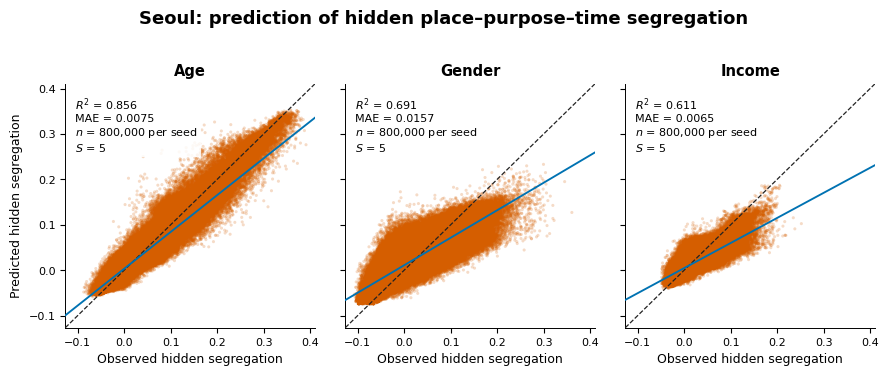

Saved: /content/drive/MyDrive/Colab Notebooks/Workspace/tour_generation/re1_segregation/combined_seoul_sgp_model/figures/city_out_of_sample_scatter_metrics.csv
 CITY ATTRIBUTE        SAMPLE  N_PREDICTION_ROWS  N_PER_SEED  N_SEEDS       R2      MAE     RMSE
  sgp       AGE OUT-OF-SAMPLE            4000000      800000        5 0.532061 0.005986 0.008654
  sgp    GENDER OUT-OF-SAMPLE            4000000      800000        5 0.519353 0.010616 0.015150
  sgp    INCOME OUT-OF-SAMPLE            4000000      800000        5 0.661023 0.008341 0.011650
seoul       AGE OUT-OF-SAMPLE            4000000      800000        5 0.855670 0.007514 0.010380
seoul    GENDER OUT-OF-SAMPLE            4000000      800000        5 0.691014 0.015699 0.020785
seoul    INCOME OUT-OF-SAMPLE            4000000      800000        5 0.610841 0.006486 0.008952


In [ ]:
'''
The reported values should be approximately:

Training (IN-SAMPLE): 80%
Testing (OUT-OF-SAMPLE): 20%
'''


from __future__ import annotations

import glob
import re
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# -----------------------------------------------------------------------------
# Configuration
# -----------------------------------------------------------------------------

PATH_SEGREGATION = Path(
    "/content/drive/MyDrive/Colab Notebooks/Workspace/tour_generation/re1_segregation"
)
MODEL_ROOT = PATH_SEGREGATION / "combined_seoul_sgp_model"
OUTPUT_DIR = MODEL_ROOT / "figures"

ATTRIBUTES = ["AGE", "GENDER", "INCOME"]
CITIES = ["sgp", "seoul"]
EXPECTED_SEEDS = [12345, 23456, 34567, 45678, 56789]

SAMPLE = "OUT-OF-SAMPLE"

CITY_LABELS = {
    "sgp": "Singapore",
    "seoul": "Seoul",
}

SCATTER_COLOR = "#D55E00"
REFERENCE_LINE_COLOR = "#222222"
FIT_LINE_COLOR = "#0072B2"

REQUIRED_COLUMNS = {
    "CITY",
    "ID",
    "SAMPLE",
    "OBSERVED_HIDDEN_SEGREGATION",
    "PREDICTED_HIDDEN_SEGREGATION",
}


# -----------------------------------------------------------------------------
# Plot style
# -----------------------------------------------------------------------------

def configure_plot_style() -> None:
    mpl.rcParams.update({
        "font.family": "DejaVu Sans",
        "font.size": 9,
        "axes.titlesize": 10.5,
        "axes.labelsize": 9,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "axes.linewidth": 0.7,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "savefig.facecolor": "white",
    })


# -----------------------------------------------------------------------------
# Data loading
# -----------------------------------------------------------------------------

def load_predictions(
    root: Path,
    attributes: list[str],
) -> pd.DataFrame:
    """Load only out-of-sample predictions for all attributes and seeds."""
    frames = []
    loaded_files = set()

    for attribute in attributes:
        pattern = (
            root
            / "seed_*"
            / attribute.lower()
            / "city_test_predictions.csv"
        )

        files = sorted(Path(path) for path in glob.glob(str(pattern)))

        if not files:
            raise FileNotFoundError(
                f"No prediction files found for {attribute}: {pattern}"
            )

        for file_path in files:
            if file_path in loaded_files:
                continue

            seed_match = re.search(
                r"seed_(\d+)",
                str(file_path),
                flags=re.IGNORECASE,
            )

            if seed_match is None:
                raise ValueError(f"Cannot identify seed from: {file_path}")

            seed = int(seed_match.group(1))
            data = pd.read_csv(file_path)

            missing = REQUIRED_COLUMNS - set(data.columns)
            if missing:
                raise KeyError(
                    f"{file_path} is missing columns: {sorted(missing)}"
                )

            data = data.copy()
            data["ATTRIBUTE"] = attribute
            data["SEED"] = seed
            data["SOURCE_FILE"] = str(file_path)

            data["CITY"] = (
                data["CITY"]
                .astype(str)
                .str.lower()
                .str.strip()
            )

            data["SAMPLE"] = (
                data["SAMPLE"]
                .astype(str)
                .str.upper()
                .str.strip()
            )

            invalid_cities = sorted(set(data["CITY"]) - set(CITIES))
            if invalid_cities:
                raise ValueError(
                    f"Unexpected city labels in {file_path}: {invalid_cities}"
                )

            # Retain only test observations
            data = data[data["SAMPLE"].eq(SAMPLE)].copy()

            if not data.empty:
                frames.append(data)
                print(
                    f"Loaded out-of-sample data | "
                    f"{attribute} | seed {seed}: {file_path}"
                )

            loaded_files.add(file_path)

    if not frames:
        raise ValueError("No out-of-sample observations were found.")

    result = pd.concat(frames, ignore_index=True)

    actual_seeds = sorted(result["SEED"].unique())
    missing_seeds = sorted(set(EXPECTED_SEEDS) - set(actual_seeds))

    if missing_seeds:
        raise FileNotFoundError(
            f"Missing expected seeds: {missing_seeds}"
        )

    return result


# -----------------------------------------------------------------------------
# Metrics and utilities
# -----------------------------------------------------------------------------

def get_xy(data: pd.DataFrame) -> tuple[np.ndarray, np.ndarray]:
    x = pd.to_numeric(
        data["OBSERVED_HIDDEN_SEGREGATION"],
        errors="coerce",
    ).to_numpy(float)

    y = pd.to_numeric(
        data["PREDICTED_HIDDEN_SEGREGATION"],
        errors="coerce",
    ).to_numpy(float)

    valid = np.isfinite(x) & np.isfinite(y)
    return x[valid], y[valid]


def calculate_metrics(
    x: np.ndarray,
    y: np.ndarray,
) -> dict[str, float]:
    if len(x) < 2:
        return {
            "R2": np.nan,
            "MAE": np.nan,
            "RMSE": np.nan,
        }

    return {
        "R2": float(r2_score(x, y)),
        "MAE": float(mean_absolute_error(x, y)),
        "RMSE": float(np.sqrt(mean_squared_error(x, y))),
    }


def panel_limits(
    predictions: pd.DataFrame,
    city: str,
) -> tuple[float, float]:
    data = predictions[predictions["CITY"].eq(city)]

    values = pd.concat([
        pd.to_numeric(
            data["OBSERVED_HIDDEN_SEGREGATION"],
            errors="coerce",
        ),
        pd.to_numeric(
            data["PREDICTED_HIDDEN_SEGREGATION"],
            errors="coerce",
        ),
    ]).dropna().to_numpy(float)

    if len(values) == 0:
        return 0.0, 1.0

    low = float(values.min())
    high = float(values.max())
    padding = max((high - low) * 0.04, 1e-6)

    return low - padding, high + padding


# -----------------------------------------------------------------------------
# Separate city figures
# -----------------------------------------------------------------------------

def plot_city(
    predictions: pd.DataFrame,
    city: str,
) -> pd.DataFrame:
    city_data = predictions[predictions["CITY"].eq(city)].copy()
    limits = panel_limits(city_data, city)

    fig, axes = plt.subplots(
        1,
        len(ATTRIBUTES),
        figsize=(9, 3.7),
        sharex=True,
        sharey=True,
        gridspec_kw={"wspace": 0.12},
    )

    axes = np.atleast_1d(axes)
    metric_rows = []

    for col, attribute in enumerate(ATTRIBUTES):
        ax = axes[col]

        subset = city_data[
            city_data["ATTRIBUTE"].eq(attribute)
        ]

        x, y = get_xy(subset)
        metrics = calculate_metrics(x, y)
        n_rows = len(x)

        valid_subset = subset.copy()
        valid_subset["X"] = pd.to_numeric(
            valid_subset["OBSERVED_HIDDEN_SEGREGATION"],
            errors="coerce",
        )
        valid_subset["Y"] = pd.to_numeric(
            valid_subset["PREDICTED_HIDDEN_SEGREGATION"],
            errors="coerce",
        )

        valid_subset = valid_subset[
            np.isfinite(valid_subset["X"])
            & np.isfinite(valid_subset["Y"])
        ]

        n_seeds = valid_subset["SEED"].nunique()
        n_per_seed = int(round(n_rows / n_seeds)) if n_seeds else 0

        if n_rows == 0:
            ax.text(
                0.5,
                0.5,
                "No observations",
                ha="center",
                va="center",
                transform=ax.transAxes,
            )
            continue

        ax.scatter(
            x,
            y,
            s=5,
            color=SCATTER_COLOR,
            alpha=0.22,
            edgecolors="none",
            linewidths=0,
            rasterized=True,
        )

        # Perfect-prediction reference line
        ax.plot(
            limits,
            limits,
            color=REFERENCE_LINE_COLOR,
            lw=0.9,
            ls="--",
            zorder=3,
        )

        # Linear regression line
        if len(x) > 2 and not np.isclose(np.ptp(x), 0):
            slope, intercept = np.polyfit(x, y, 1)
            grid = np.linspace(limits[0], limits[1], 100)

            ax.plot(
                grid,
                intercept + slope * grid,
                color=FIT_LINE_COLOR,
                lw=1.35,
                zorder=4,
            )

        ax.set_xlim(limits)
        ax.set_ylim(limits)

        ax.set_title(
            attribute.title(),
            fontweight="bold",
            pad=6,
        )

        ax.text(
            0.04,
            0.95,
            f"$R^2$ = {metrics['R2']:.3f}\n"
            f"MAE = {metrics['MAE']:.4f}\n"
            f"$n$ = {n_per_seed:,} per seed\n"
            f"$S$ = {n_seeds}",
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=8,
            bbox={
                "facecolor": "white",
                "edgecolor": "none",
                "alpha": 0.84,
                "pad": 2.5,
            },
        )

        '''ax.grid(
            color="#D9D9D9",
            lw=0.5,
            ls=":",
            zorder=0,
        )'''
        ax.spines[["top", "right"]].set_visible(False)

        metric_rows.append({
            "CITY": city,
            "ATTRIBUTE": attribute,
            "SAMPLE": SAMPLE,
            "N_PREDICTION_ROWS": n_rows,
            "N_PER_SEED": n_per_seed,
            "N_SEEDS": n_seeds,
            **metrics,
        })

    for ax in axes:
        ax.set_xlabel("Observed hidden segregation")

    axes[0].set_ylabel("Predicted hidden segregation")

    fig.suptitle(
        f"{CITY_LABELS[city]}: prediction of hidden "
        "place–purpose–time segregation",
        fontsize=13,
        fontweight="bold",
        y=1.02,
    )

    fig.subplots_adjust(
        left=0.08,
        right=0.98,
        bottom=0.16,
        top=0.82,
    )

    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    stem = f"{city}_out_of_sample_scatter_plots"
    png_path = OUTPUT_DIR / f"{stem}.png"
    pdf_path = OUTPUT_DIR / f"{stem}.pdf"

    fig.savefig(
        png_path,
        dpi=600,
        bbox_inches="tight",
    )
    fig.savefig(
        pdf_path,
        bbox_inches="tight",
    )

    print(f"Saved: {png_path}")
    print(f"Saved: {pdf_path}")

    plt.show()
    plt.close(fig)

    return pd.DataFrame(metric_rows)


# -----------------------------------------------------------------------------
# Main
# -----------------------------------------------------------------------------

if __name__ == "__main__":
    configure_plot_style()

    predictions = load_predictions(
        MODEL_ROOT,
        ATTRIBUTES,
    )

    city_summaries = []

    for city in CITIES:
        city_summary = plot_city(
            predictions,
            city,
        )
        city_summaries.append(city_summary)

    metrics = pd.concat(
        city_summaries,
        ignore_index=True,
    )

    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    metrics_path = OUTPUT_DIR / "city_out_of_sample_scatter_metrics.csv"
    metrics.to_csv(metrics_path, index=False)

    print(f"Saved: {metrics_path}")
    print(metrics.to_string(index=False))

# STable: Validation OD-time + Age Singapore


In [ ]:
import os
import numpy as np
import pandas as pd
from scipy.spatial.distance import jensenshannon
from sklearn.metrics import r2_score, mean_squared_error


# ============================================================
# Build weighted distribution P(Z)
# ============================================================
def build_weighted_distribution(
    df: pd.DataFrame,
    key_cols: list[str],
    count_col: str = "COUNT",
) -> pd.DataFrame:
    """
    Build normalized weighted joint distribution over key_cols.
    """
    missing = [c for c in key_cols + [count_col] if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    x = df[key_cols + [count_col]].dropna(subset=key_cols + [count_col]).copy()
    x[count_col] = pd.to_numeric(x[count_col], errors="coerce")
    x = x.dropna(subset=[count_col])

    dist = (
        x.groupby(key_cols, sort=False, as_index=False)[count_col]
         .sum()
         .rename(columns={count_col: "count"})
    )

    total = dist["count"].sum()
    if total <= 0:
        raise ValueError("Total weight is non-positive.")

    dist["prob"] = dist["count"] / total
    return dist


# ============================================================
# Align distributions on common support union
# ============================================================
def align_distributions(
    dist_a: pd.DataFrame,
    dist_b: pd.DataFrame,
    key_cols: list[str],
) -> pd.DataFrame:
    """
    Align two distributions on the union of keys.
    """
    a = dist_a.rename(columns={"count": "count_a", "prob": "prob_a"})
    b = dist_b.rename(columns={"count": "count_b", "prob": "prob_b"})

    merged = (
        a.merge(b, on=key_cols, how="outer")
         .fillna(0.0)
         .sort_values(key_cols)
         .reset_index(drop=True)
    )

    for c in ["count_a", "prob_a", "count_b", "prob_b"]:
        merged[c] = merged[c].astype(float)

    # Re-normalize after alignment, just to be safe
    if merged["prob_a"].sum() > 0:
        merged["prob_a"] = merged["prob_a"] / merged["prob_a"].sum()
    if merged["prob_b"].sum() > 0:
        merged["prob_b"] = merged["prob_b"] / merged["prob_b"].sum()

    return merged


# ============================================================
# Compute metrics
# ============================================================
def compute_distribution_metrics_from_weights(
    df_a: pd.DataFrame,
    df_b: pd.DataFrame,
    key_cols: list[str],
    count_col_a: str = "COUNT",
    count_col_b: str = "COUNT",
) -> tuple[dict, pd.DataFrame]:
    """
    Compute JSD, R2, and RMSE between two weighted joint distributions.
    """
    dist_a = build_weighted_distribution(df_a, key_cols=key_cols, count_col=count_col_a)
    dist_b = build_weighted_distribution(df_b, key_cols=key_cols, count_col=count_col_b)

    aligned = align_distributions(dist_a, dist_b, key_cols=key_cols)

    p_a = aligned["prob_a"].to_numpy(dtype=float)
    p_b = aligned["prob_b"].to_numpy(dtype=float)

    jsd = float(jensenshannon(p_a, p_b) ** 2)
    r2 = float(r2_score(p_a, p_b))
    rmse = float(np.sqrt(mean_squared_error(p_a, p_b)))

    metrics = {
        "JSD": jsd,
        "R2": r2,
        "RMSE": rmse,
    }
    return metrics, aligned


# ============================================================
# Run
# ============================================================
# ============================================================
# Load datasets
# ============================================================

att_Z = [
        'ORIGIN_SUBZONE',
        'DESTINATION_SUBZONE',
        'TRIP_STARTTIME',
        'COMMUTER_CATEGORY'
    ]

commuter_ages  = list(range(4))
commuter_ages_ = ['CHILD', 'ADULT', 'ADULT',  'SENIOR']

df_sc  = pd.read_csv(os.path.join(path_data,   'data_sgp_sc_trip.csv'))
df_sc  = df_sc[df_sc['COMMUTER_CATEGORY'] != 'CHILD']

REGION = 'sgp'
NB = 10
seed = 12345
KK = 6000




TRIP_MAX = 7
#for KK in [1000, 6000, 10000]:
#for end_tag in ['_severity_05_combined', '_severity_10_combined', '']:
for end_tag in ['_frac_0.6', '_frac_0.8', '']:

    #tag = 'identification_'
    #tag = 'distort_pcm_'
    tag = 'distort_hts_'
    #if KK == 6000: tag = ''
    if end_tag == '': tag = ''


    #df_fus = pd.read_csv(os.path.join(path_result,  f"{tag}case_{REGION}_sim_trip_M_{KK}_nb_{NB}_seed_{seed}.csv"))
    df_fus = pd.read_csv(os.path.join(path_result,  f"{tag}case_{REGION}_sim_trip_M_{KK}_nb_{NB}_seed_{seed}{end_tag}.csv"))

    df_fus = reduce_mem_usage22(df_fus)

    # ============================================================
    # Preprocessing
    # ============================================================

    df_fus['COMMUTER_CATEGORY'] = df_fus['AGE'].replace(commuter_ages, commuter_ages_)
    df_fus['COUNT'] = df_fus['Prob_XYZ_fus']

    # Apply filters consistently
    df_fus = df_fus[df_fus['TRAVEL_MODE'].isin([1, 2])]
    df_fus = df_fus[df_fus['COMMUTER_CATEGORY'] != 'CHILD']


    metrics, aligned = compute_distribution_metrics_from_weights(
        df_a=df_sc,
        df_b=df_fus,
        key_cols=att_Z,
        count_col_a="COUNT",
        count_col_b="COUNT",
    )

    print("========================================")
    #print(f"M = {KK}")
    print(f"distort pcm = {end_tag}")
    print("========================================")
    print(f"JSD  : {metrics['JSD']:.6f}")
    print(f"R2   : {metrics['R2']:.6f}")
    print(f"RMSE : {metrics['RMSE']:.8e}")
    print("========================================")
    del df_fus



'''
identification sgp

M = 1000
JSD  : 0.075795
R2   : 0.826535
RMSE : 1.17737844e-06

M = 6000
JSD  : 0.076022
R2   : 0.826226
RMSE : 1.19237687e-06

M = 10000
JSD  : 0.076937
R2   : 0.825645
RMSE : 1.19974009e-06


distort pcm

========================================
distort pcm = _severity_05_combined
========================================
JSD  : 0.076652
R2   : 0.807760
RMSE : 1.25400553e-06
========================================
========================================
distort pcm = _severity_10_combined
========================================
JSD  : 0.078215
R2   : 0.775132
RMSE : 1.35753729e-06
========================================
========================================
distort pcm =
========================================
JSD  : 0.076022
R2   : 0.826226
RMSE : 1.19237687e-06
========================================


distort hts
========================================
distort pcm = _frac_0.6
========================================
JSD  : 0.079214
R2   : 0.815797
RMSE : 1.23978240e-06
========================================
========================================
distort pcm = _frac_0.8
========================================
JSD  : 0.077458
R2   : 0.832027
RMSE : 1.18117769e-06
========================================
========================================
distort pcm =
========================================
JSD  : 0.076022
R2   : 0.826226
RMSE : 1.19237687e-06
========================================

'''

distort pcm = _frac_0.6
JSD  : 0.079214
R2   : 0.815797
RMSE : 1.23978240e-06
distort pcm = _frac_0.8
JSD  : 0.077458
R2   : 0.832027
RMSE : 1.18117769e-06
distort pcm = 
JSD  : 0.076022
R2   : 0.826226
RMSE : 1.19237687e-06


'\nidentification sgp\n\nAge\n\nM = 1000\nJSD  : 0.075795\nR2   : 0.826535\nRMSE : 1.17737844e-06\n\nM = 6000\nJSD  : 0.076022\nR2   : 0.826226\nRMSE : 1.19237687e-06\n\nM = 10000\nJSD  : 0.076937\nR2   : 0.825645\nRMSE : 1.19974009e-06\n\n\ndistort pcm \n\n========================================\ndistort pcm = _severity_05_combined\n========================================\nJSD  : 0.076652\nR2   : 0.807760\nRMSE : 1.25400553e-06\n========================================\n========================================\ndistort pcm = _severity_10_combined\n========================================\nJSD  : 0.078215\nR2   : 0.775132\nRMSE : 1.35753729e-06\n========================================\n========================================\ndistort pcm = \n========================================\nJSD  : 0.076022\nR2   : 0.826226\nRMSE : 1.19237687e-06\n========================================\n\n\ndistort hts\n\n========================================\ndistort pcm = _frac_0.6\n=================

In [ ]:
REGION = 'sgp'
df_pcm = pd.read_csv(os.path.join(path_data, f'data_{REGION}_pcm_trip_severity_05_combined.csv'))
print(df_pcm.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1081746 entries, 0 to 1081745
Data columns (total 10 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   ORIGIN_SUBZONE         1081746 non-null  object 
 1   DESTINATION_SUBZONE    1081746 non-null  object 
 2   ORIGIN_SUBZONE_X       1081746 non-null  float64
 3   ORIGIN_SUBZONE_Y       1081746 non-null  float64
 4   DESTINATION_SUBZONE_X  1081746 non-null  float64
 5   DESTINATION_SUBZONE_Y  1081746 non-null  float64
 6   TRIP_STARTTIME         1081746 non-null  int64  
 7   TRIP_ENDTIME           1081746 non-null  int64  
 8   COUNT                  1081746 non-null  float64
 9   COUNT_ORIGINAL         1081746 non-null  float64
dtypes: float64(6), int64(2), object(2)
memory usage: 82.5+ MB
None


# STable: Validaiton **OD**-time + Age & Purpose Seoul

In [ ]:
import os
import numpy as np
import pandas as pd
from scipy.spatial.distance import jensenshannon
from sklearn.metrics import r2_score, mean_squared_error


AGE_RECODE = {0:0, 1:0, 2:1, 3:1, 4:2, 5:2, 6:3, 7:3}
PURPOSE_RECODE_HTS_FUS = {0: 0, 1: 1, 2: 2, 3: 2, 4: 2, 5: 2}  # keeps Work=1, Other=2
PURPOSE_RECODE_PCM = {"H": 0, "W": 1, "E": 2}  # assumes E corresponds to Other

def prepare_pcm(df: pd.DataFrame) -> pd.DataFrame:
    df["TRIP_PURPOSE"] = df["TRIP_PURPOSE"].replace(PURPOSE_RECODE_PCM)
    return df

def prepare_fus(df: pd.DataFrame) -> pd.DataFrame:
    df["COUNT"] = df["Prob_XYZ_fus"]
    df["TRIP_PURPOSE"] = df["TRIP_PURPOSE"].replace(PURPOSE_RECODE_HTS_FUS)
    return df


# ============================================================
# Build weighted distribution P(Z)
# ============================================================
def build_weighted_distribution(
    df: pd.DataFrame,
    key_cols: list[str],
    count_col: str = "COUNT",
) -> pd.DataFrame:
    """
    Build normalized weighted joint distribution over key_cols.
    """
    missing = [c for c in key_cols + [count_col] if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    x = df[key_cols + [count_col]].dropna(subset=key_cols + [count_col]).copy()
    x[count_col] = pd.to_numeric(x[count_col], errors="coerce")
    x = x.dropna(subset=[count_col])

    dist = (
        x.groupby(key_cols, sort=False, as_index=False)[count_col]
         .sum()
         .rename(columns={count_col: "count"})
    )

    total = dist["count"].sum()
    if total <= 0:
        raise ValueError("Total weight is non-positive.")

    dist["prob"] = dist["count"] / total
    return dist


# ============================================================
# Align distributions on common support union
# ============================================================
def align_distributions(
    dist_a: pd.DataFrame,
    dist_b: pd.DataFrame,
    key_cols: list[str],
) -> pd.DataFrame:
    """
    Align two distributions on the union of keys.
    """
    a = dist_a.rename(columns={"count": "count_a", "prob": "prob_a"})
    b = dist_b.rename(columns={"count": "count_b", "prob": "prob_b"})

    merged = (
        a.merge(b, on=key_cols, how="outer")
         .fillna(0.0)
         .sort_values(key_cols)
         .reset_index(drop=True)
    )

    for c in ["count_a", "prob_a", "count_b", "prob_b"]:
        merged[c] = merged[c].astype(float)

    # Re-normalize after alignment, just to be safe
    if merged["prob_a"].sum() > 0:
        merged["prob_a"] = merged["prob_a"] / merged["prob_a"].sum()
    if merged["prob_b"].sum() > 0:
        merged["prob_b"] = merged["prob_b"] / merged["prob_b"].sum()

    return merged


# ============================================================
# Compute metrics
# ============================================================
def compute_distribution_metrics_from_weights(
    df_a: pd.DataFrame,
    df_b: pd.DataFrame,
    key_cols: list[str],
    count_col_a: str = "COUNT",
    count_col_b: str = "COUNT",
) -> tuple[dict, pd.DataFrame]:
    """
    Compute JSD, R2, and RMSE between two weighted joint distributions.
    """
    dist_a = build_weighted_distribution(df_a, key_cols=key_cols, count_col=count_col_a)
    dist_b = build_weighted_distribution(df_b, key_cols=key_cols, count_col=count_col_b)

    aligned = align_distributions(dist_a, dist_b, key_cols=key_cols)

    p_a = aligned["prob_a"].to_numpy(dtype=float)
    p_b = aligned["prob_b"].to_numpy(dtype=float)

    jsd = float(jensenshannon(p_a, p_b) ** 2)
    r2 = float(r2_score(p_a, p_b))
    rmse = float(np.sqrt(mean_squared_error(p_a, p_b)))

    metrics = {
        "JSD": jsd,
        "R2": r2,
        "RMSE": rmse,
    }
    return metrics, aligned


# ============================================================
# Run
# ============================================================
# ============================================================
# Load datasets
# ============================================================

att_Z = [
        'ORIGIN_SUBZONE',
        'DESTINATION_SUBZONE',
        'TRIP_STARTTIME',
        #'AGE',
        #'TRIP_PURPOSE',
        #'GENDER'
    ]

att_X = ['AGE', 'TRIP_PURPOSE', 'GENDER']

df_pcm  = pd.read_csv(os.path.join(path_data,   'data_seoul_pcm_trip.csv'))
if "TRIP_PURPOSE_" in df_pcm.columns and "TRIP_PURPOSE" not in df_pcm.columns:
        df_pcm.rename(columns={"TRIP_PURPOSE_": "TRIP_PURPOSE"}, inplace=True)
df_pcm['AGE'].replace([i for i in range(8)], [0, 0, 1, 1, 2, 2, 3, 3], inplace=True)
df_pcm = prepare_pcm(df_pcm)

TRIP_MAX = 7
REGION = 'seoul'
NB = 10
seed = 12345
seed = 12345
KK = 6000




#for KK in [1000, 6000, 10000]:
for end_tag in ['_severity_05_combined', '_severity_10_combined', '']:
#for end_tag in ['_frac_0.6', '_frac_0.8', '']:

    #tag = 'identification_'
    tag = 'distort_pcm_'
    #tag = 'distort_hts_'
    #if KK == 6000: tag = ''
    if end_tag == '': tag = ''


    #df_fus = pd.read_csv(os.path.join(path_result,  f"{tag}case_{REGION}_sim_trip_M_{KK}_nb_{NB}_seed_{seed}.csv"))
    df_fus = pd.read_csv(os.path.join(path_result,  f"{tag}case_{REGION}_sim_trip_M_{KK}_nb_{NB}_seed_{seed}{end_tag}.csv"))

    df_fus = reduce_mem_usage(df_fus)
    df_fus = prepare_fus(df_fus)


    for att in att_X:
        # ============================================================
        # Preprocessing
        # ============================================================
        metrics, aligned = compute_distribution_metrics_from_weights(
            df_a=df_pcm.copy(),
            df_b=df_fus.copy(),
            key_cols=att_Z + [att],
            count_col_a="COUNT",
            count_col_b="COUNT",
        )

        print("========================================")
        #print(f"M = {KK}, Attribut = {att}")
        print(f"end_tag = {end_tag}, Attribut = {att}")
        print("========================================")
        print(f"JSD  : {metrics['JSD']:.6f}")
        print(f"R2   : {metrics['R2']:.6f}")
        print(f"RMSE : {metrics['RMSE']:.8e}")
        print("========================================")


'''
identification

========================================
M = 1000, Attribut = AGE
========================================
JSD  : 0.088834
R2   : 0.738948
RMSE : 4.00184709e-07
========================================
========================================
M = 1000, Attribut = TRIP_PURPOSE
========================================
JSD  : 0.051522
R2   : 0.860824
RMSE : 3.92595929e-07
========================================
========================================
M = 1000, Attribut = GENDER
========================================
JSD  : 0.020916
R2   : 0.914305
RMSE : 3.60637413e-07
========================================
========================================
M = 6000, Attribut = AGE
========================================
JSD  : 0.088236
R2   : 0.738920
RMSE : 3.93477291e-07
========================================
========================================
M = 6000, Attribut = TRIP_PURPOSE
========================================
JSD  : 0.046222
R2   : 0.874135
RMSE : 3.67026277e-07
========================================
========================================
M = 6000, Attribut = GENDER
========================================
JSD  : 0.020624
R2   : 0.917583
RMSE : 3.50161598e-07
========================================
========================================
M = 10000, Attribut = AGE
========================================
JSD  : 0.088070
R2   : 0.744654
RMSE : 3.88159870e-07
========================================
========================================
M = 10000, Attribut = TRIP_PURPOSE
========================================
JSD  : 0.044609
R2   : 0.889121
RMSE : 3.44258165e-07
========================================
========================================
M = 10000, Attribut = GENDER
========================================
JSD  : 0.020959
R2   : 0.930649
RMSE : 3.20529169e-07


distort hts

========================================
end_tag = _frac_0.6, Attribut = AGE
========================================
JSD  : 0.089749
R2   : 0.750492
RMSE : 3.83039935e-07
========================================
========================================
end_tag = _frac_0.6, Attribut = TRIP_PURPOSE
========================================
JSD  : 0.046056
R2   : 0.883552
RMSE : 3.51279289e-07
========================================
========================================
end_tag = _frac_0.6, Attribut = GENDER
========================================
JSD  : 0.021457
R2   : 0.921999
RMSE : 3.39190231e-07
========================================
========================================
end_tag = _frac_0.8, Attribut = AGE
========================================
JSD  : 0.089469
R2   : 0.746996
RMSE : 3.86036848e-07
========================================
========================================
end_tag = _frac_0.8, Attribut = TRIP_PURPOSE
========================================
JSD  : 0.045048
R2   : 0.880254
RMSE : 3.57491956e-07
========================================
========================================
end_tag = _frac_0.8, Attribut = GENDER
========================================
JSD  : 0.020720
R2   : 0.927150
RMSE : 3.28362526e-07
========================================
========================================
end_tag = , Attribut = AGE
========================================
JSD  : 0.088236
R2   : 0.738920
RMSE : 3.93477291e-07
========================================
========================================
end_tag = , Attribut = TRIP_PURPOSE
========================================
JSD  : 0.046222
R2   : 0.874135
RMSE : 3.67026277e-07
========================================
========================================
end_tag = , Attribut = GENDER
========================================
JSD  : 0.020624
R2   : 0.917583
RMSE : 3.50161598e-07
========================================


distort pcm

========================================
end_tag = _severity_05_combined, Attribut = AGE
========================================
JSD  : 0.088771
R2   : 0.734894
RMSE : 3.96665512e-07
========================================
========================================
end_tag = _severity_05_combined, Attribut = TRIP_PURPOSE
========================================
JSD  : 0.046793
R2   : 0.866027
RMSE : 3.78851247e-07
========================================
========================================
end_tag = _severity_05_combined, Attribut = GENDER
========================================
JSD  : 0.021203
R2   : 0.914652
RMSE : 3.56399975e-07
========================================
========================================
end_tag = _severity_10_combined, Attribut = AGE
========================================
JSD  : 0.090240
R2   : 0.720975
RMSE : 4.07187609e-07
========================================
========================================
end_tag = _severity_10_combined, Attribut = TRIP_PURPOSE
========================================
JSD  : 0.048369
R2   : 0.849352
RMSE : 4.02020513e-07
========================================
========================================
end_tag = _severity_10_combined, Attribut = GENDER
========================================
JSD  : 0.022832
R2   : 0.902807
RMSE : 3.80429053e-07
========================================
========================================
end_tag = , Attribut = AGE
========================================
JSD  : 0.088236
R2   : 0.738920
RMSE : 3.93477291e-07
========================================
========================================
end_tag = , Attribut = TRIP_PURPOSE
========================================
JSD  : 0.046222
R2   : 0.874135
RMSE : 3.67026277e-07
========================================
========================================
end_tag = , Attribut = GENDER
========================================
JSD  : 0.020624
R2   : 0.917583
RMSE : 3.50161598e-07
========================================

'''


end_tag = _severity_05_combined, Attribut = AGE
JSD  : 0.088771
R2   : 0.734894
RMSE : 3.96665512e-07
end_tag = _severity_05_combined, Attribut = TRIP_PURPOSE
JSD  : 0.046793
R2   : 0.866027
RMSE : 3.78851247e-07
end_tag = _severity_05_combined, Attribut = GENDER
JSD  : 0.021203
R2   : 0.914652
RMSE : 3.56399975e-07
end_tag = _severity_10_combined, Attribut = AGE
JSD  : 0.090240
R2   : 0.720975
RMSE : 4.07187609e-07
end_tag = _severity_10_combined, Attribut = TRIP_PURPOSE
JSD  : 0.048369
R2   : 0.849352
RMSE : 4.02020513e-07
end_tag = _severity_10_combined, Attribut = GENDER
JSD  : 0.022832
R2   : 0.902807
RMSE : 3.80429053e-07
end_tag = , Attribut = AGE
JSD  : 0.088236
R2   : 0.738920
RMSE : 3.93477291e-07
end_tag = , Attribut = TRIP_PURPOSE
JSD  : 0.046222
R2   : 0.874135
RMSE : 3.67026277e-07
end_tag = , Attribut = GENDER
JSD  : 0.020624
R2   : 0.917583
RMSE : 3.50161598e-07


'\nidentification\n\n========================================\nM = 1000, Attribut = AGE\n========================================\nJSD  : 0.088834\nR2   : 0.738948\nRMSE : 4.00184709e-07\n========================================\n========================================\nM = 1000, Attribut = TRIP_PURPOSE\n========================================\nJSD  : 0.051522\nR2   : 0.860824\nRMSE : 3.92595929e-07\n========================================\n========================================\nM = 1000, Attribut = GENDER\n========================================\nJSD  : 0.020916\nR2   : 0.914305\nRMSE : 3.60637413e-07\n========================================\n========================================\nM = 6000, Attribut = AGE\n========================================\nJSD  : 0.088236\nR2   : 0.738920\nRMSE : 3.93477291e-07\n========================================\n========================================\nM = 6000, Attribut = TRIP_PURPOSE\n========================================\nJSD  : 0.046

# STable: HTS XY + PCM Z presvervation

In [ ]:
import os
import numpy as np
import pandas as pd
from scipy.spatial.distance import jensenshannon
from sklearn.metrics import r2_score, mean_squared_error


# ==========================================================
# ATTRIBUTE SETS
# ==========================================================
ATT_X = ["AGE", "GENDER", 'INCOME']
ATT_Y = ["TRIP_CNT", "TRIP_MAX", "TRIP_PURPOSE", "TRAVEL_MODE"]
ATT_Z = ["ORIGIN_SUBZONE", "DESTINATION_SUBZONE", "TRIP_STARTTIME", "TRIP_ENDTIME"]

ATT_XY = ATT_X + ATT_Y


# ==========================================================
# DISTRIBUTION UTILITIES
# ==========================================================
def build_distribution(
    df: pd.DataFrame,
    cols: list[str],
    weight_col: str | None = None,
) -> pd.DataFrame:
    """
    Build a normalized distribution over `cols`.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe.
    cols : list[str]
        Columns defining the state space.
    weight_col : str or None
        If None, each row has weight 1.
        Otherwise, probabilities are computed from the sum of `weight_col`.

    Returns
    -------
    pd.DataFrame
        Columns = cols + ["weight", "prob"]
    """
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns in input dataframe: {missing}")

    if weight_col is not None and weight_col not in df.columns:
        raise ValueError(f"Missing weight column: {weight_col}")

    # Keep only needed columns to reduce memory
    use_cols = cols if weight_col is None else cols + [weight_col]
    x = df[use_cols].dropna(subset=cols).copy()

    if weight_col is None:
        dist = (
            x.groupby(cols, observed=True, sort=False)
             .size()
             .reset_index(name="weight")
        )
    else:
        x[weight_col] = pd.to_numeric(x[weight_col], errors="coerce")
        x = x.dropna(subset=[weight_col])

        dist = (
            x.groupby(cols, observed=True, sort=False)[weight_col]
             .sum()
             .reset_index(name="weight")
        )

    total_weight = dist["weight"].sum()
    if total_weight <= 0:
        raise ValueError("Total weight must be positive.")

    dist["prob"] = dist["weight"] / total_weight
    return dist


def align_probability_tables(
    dist_ref: pd.DataFrame,
    dist_cmp: pd.DataFrame,
    cols: list[str],
) -> pd.DataFrame:
    """
    Align two distributions on the union of support.

    Returns
    -------
    pd.DataFrame
        cols + ["prob_ref", "prob_cmp"]
    """
    ref = dist_ref[cols + ["prob"]].rename(columns={"prob": "prob_ref"})
    cmp_ = dist_cmp[cols + ["prob"]].rename(columns={"prob": "prob_cmp"})

    merged = (
        ref.merge(cmp_, on=cols, how="outer")
           .fillna(0.0)
           .reset_index(drop=True)
    )

    # Safety renormalization
    if merged["prob_ref"].sum() > 0:
        merged["prob_ref"] = merged["prob_ref"] / merged["prob_ref"].sum()
    if merged["prob_cmp"].sum() > 0:
        merged["prob_cmp"] = merged["prob_cmp"] / merged["prob_cmp"].sum()

    return merged


def compute_distribution_metrics_from_tables(aligned: pd.DataFrame) -> dict:
    """
    Compute JSD, R2, and RMSE from an aligned probability table.
    """
    p_ref = aligned["prob_ref"].to_numpy(dtype=float)
    p_cmp = aligned["prob_cmp"].to_numpy(dtype=float)

    return {
        "JSD": float(jensenshannon(p_ref, p_cmp) ** 2),
        "R2": float(r2_score(p_ref, p_cmp)),
        "RMSE": float(np.sqrt(mean_squared_error(p_ref, p_cmp))),
    }


def compare_distributions(
    df_ref: pd.DataFrame,
    df_cmp: pd.DataFrame,
    cols: list[str],
    ref_weight_col: str | None = None,
    cmp_weight_col: str | None = None,
) -> tuple[dict, pd.DataFrame]:
    """
    Build two distributions, align them, and compute JSD / R2 / RMSE.

    Returns
    -------
    metrics : dict
    aligned : pd.DataFrame
        Probability table containing cols + ["prob_ref", "prob_cmp"]
    """
    dist_ref = build_distribution(df_ref, cols, ref_weight_col)
    dist_cmp = build_distribution(df_cmp, cols, cmp_weight_col)

    aligned = align_probability_tables(dist_ref, dist_cmp, cols)
    metrics = compute_distribution_metrics_from_tables(aligned)

    return metrics, aligned


# ==========================================================
# EVALUATION LOGIC
# ==========================================================
def evaluate_probability_table(
    df_survey: pd.DataFrame,
    df_generated_prob: pd.DataFrame,
    df_pcm: pd.DataFrame,
    generated_weight_col: str,
) -> tuple[dict, dict]:
    """
    Evaluate the probability table on:
      1) P(X,Y): generated vs survey
      2) P(Z):   generated vs PCM

    Parameters
    ----------
    df_survey : pd.DataFrame
        Household travel survey data.
    df_generated_prob : pd.DataFrame
        Generated probability table.
    df_pcm : pd.DataFrame
        PCM trip data with COUNT.
    generated_weight_col : str
        Weight column for generated probability table,
        e.g. 'Prob_XYZ_fus' or 'COUNT'.

    Returns
    -------
    metrics_flat : dict
        Flattened benchmark metrics.
    aligned_tables : dict
        {"PXY": aligned_pxy, "PZ": aligned_pz}
    """
    metrics_xy, aligned_xy = compare_distributions(
        df_ref=df_survey,
        df_cmp=df_generated_prob,
        cols=ATT_XY,
        ref_weight_col=None,
        cmp_weight_col=generated_weight_col,
    )

    metrics_z, aligned_z = compare_distributions(
        df_ref=df_pcm,
        df_cmp=df_generated_prob,
        cols=ATT_Z,
        ref_weight_col="COUNT",
        cmp_weight_col=generated_weight_col,
    )

    metrics_flat = {
        "JSD_PXY": metrics_xy["JSD"],
        "R2_PXY": metrics_xy["R2"],
        "RMSE_PXY": metrics_xy["RMSE"],
        "JSD_PZ": metrics_z["JSD"],
        "R2_PZ": metrics_z["R2"],
        "RMSE_PZ": metrics_z["RMSE"],
    }

    aligned_tables = {
        "PXY": aligned_xy,
        "PZ": aligned_z,
    }

    return metrics_flat, aligned_tables


# ==========================================================
# RUN
# ==========================================================
if __name__ == "__main__":


    REGION = 'seoul'
    NB = 10
    seed = 12345
    KK = 6000
    TRIP_MAX = 7

    df_hts = pd.read_csv(os.path.join(path_data, f"data_{REGION}_hts_trip.csv"))
    df_hts = df_hts[df_hts['INCOME'] < 3]
    df_pcm = pd.read_csv(os.path.join(path_data, f"data_{REGION}_pcm_trip.csv"))
    #df_pcm['AGE'].replace([i for i in range(8)], [0, 0, 1, 1, 2, 2, 3, 3], inplace=True)
    df_hts['AGE'].replace([i for i in range(8)], [0, 0, 1, 1, 2, 2, 3, 3], inplace=True)


    for KK in [1000, 6000, 10000]:
    #for end_tag in ['_severity_05_combined', '_severity_10_combined', '']:
    #for end_tag in ['_frac_0.6', '_frac_0.8', '']:

        tag = 'identification_'
        if KK == 6000: tag = ''
        #tag = 'distort_pcm_'
        #tag = 'distort_hts_'
        #if end_tag == '': tag = ''


        df_fus = pd.read_csv(os.path.join(path_result,  f"{tag}case_{REGION}_sim_trip_M_{KK}_nb_{NB}_seed_{seed}.csv"))
        #df_fus = pd.read_csv(os.path.join(path_result,  f"{tag}case_{REGION}_sim_trip_M_{KK}_nb_{NB}_seed_{seed}{end_tag}.csv"))



        print(f'Settings {KK}')

        # ------------------------------------------------------
        # Benchmark only the probability table
        # ------------------------------------------------------
        metrics_prob, aligned_tables = evaluate_probability_table(
            df_survey=df_hts,
            df_generated_prob=df_fus,
            df_pcm=df_pcm,
            generated_weight_col="Prob_XYZ_fus",
        )

        results = pd.DataFrame(
            [
                {
                    "model_source": "weighted_probability_table",
                    **metrics_prob,
                }
            ]
        )

        #print("\nEvaluation results")
        #print(results)

        #print("========================================")
        #print(f"NB = {NB}")
        print("========================================")
        # Pretty print
        row = results.iloc[0]
        print(f"\n{row['model_source']}")
        print(
            f"  P(X,Y) vs survey : "
            f"JSD={row['JSD_PXY']:.6f}, "
            f"R2={row['R2_PXY']:.6f}, "
            f"RMSE={row['RMSE_PXY']:.6e}"
        )
        print(
            f"  P(Z)   vs PCM    : "
            f"JSD={row['JSD_PZ']:.6f}, "
            f"R2={row['R2_PZ']:.6f}, "
            f"RMSE={row['RMSE_PZ']:.6e}"
        )
        print("========================================")
        del df_fus



'''

Singapore: identification

Settings 1000
========================================

weighted_probability_table
  P(X,Y) vs survey : JSD=0.007342, R2=0.965419, RMSE=2.811463e-04
  P(Z)   vs PCM    : JSD=0.000060, R2=1.000000, RMSE=2.670424e-09
========================================
Settings 6000
========================================

weighted_probability_table
  P(X,Y) vs survey : JSD=0.008542, R2=0.958061, RMSE=3.096142e-04
  P(Z)   vs PCM    : JSD=0.000024, R2=1.000000, RMSE=1.582839e-09
========================================
Settings 10000
========================================

weighted_probability_table
  P(X,Y) vs survey : JSD=0.008653, R2=0.958612, RMSE=3.075710e-04
  P(Z)   vs PCM    : JSD=0.000044, R2=1.000000, RMSE=2.269500e-09


Singapore: distort hts

Settings _frac_0.6
========================================

weighted_probability_table
  P(X,Y) vs survey : JSD=0.020344, R2=0.953047, RMSE=3.275997e-04
  P(Z)   vs PCM    : JSD=0.000007, R2=1.000000, RMSE=7.038221e-10
========================================
Settings _frac_0.8
========================================

weighted_probability_table
  P(X,Y) vs survey : JSD=0.013414, R2=0.957004, RMSE=3.134901e-04
  P(Z)   vs PCM    : JSD=0.000023, R2=1.000000, RMSE=1.575981e-09
========================================
Settings
========================================

weighted_probability_table
  P(X,Y) vs survey : JSD=0.008542, R2=0.958061, RMSE=3.096142e-04
  P(Z)   vs PCM    : JSD=0.000024, R2=1.000000, RMSE=1.582839e-09
========================================


Singapore: distort pcm

Settings _severity_05_combined
========================================

weighted_probability_table
  P(X,Y) vs survey : JSD=0.007741, R2=0.962437, RMSE=2.930158e-04
  P(Z)   vs PCM    : JSD=0.000559, R2=0.994168, RMSE=3.231466e-07
========================================
Settings _severity_10_combined
========================================

weighted_probability_table
  P(X,Y) vs survey : JSD=0.007022, R2=0.966572, RMSE=2.764164e-04
  P(Z)   vs PCM    : JSD=0.002171, R2=0.975773, RMSE=6.586339e-07
========================================
Settings
========================================

weighted_probability_table
  P(X,Y) vs survey : JSD=0.008542, R2=0.958061, RMSE=3.096142e-04
  P(Z)   vs PCM    : JSD=0.000024, R2=1.000000, RMSE=1.582839e-09


************************************************************************************
seoul indentification

weighted_probability_table
  P(X,Y) vs survey : JSD=0.003855, R2=0.975818, RMSE=1.447241e-04
  P(Z)   vs PCM    : JSD=0.005606, R2=0.999708, RMSE=2.774553e-08
========================================
Settings 6000
========================================

weighted_probability_table
  P(X,Y) vs survey : JSD=0.003848, R2=0.982567, RMSE=1.228804e-04
  P(Z)   vs PCM    : JSD=0.003688, R2=0.999872, RMSE=1.838664e-08
========================================
Settings 10000
========================================

weighted_probability_table
  P(X,Y) vs survey : JSD=0.004072, R2=0.980910, RMSE=1.285865e-04
  P(Z)   vs PCM    : JSD=0.003340, R2=0.999894, RMSE=1.669255e-08


Seoul: distort hts

Settings _frac_0.6
========================================

weighted_probability_table
  P(X,Y) vs survey : JSD=0.015479, R2=0.973812, RMSE=1.506072e-04
  P(Z)   vs PCM    : JSD=0.003133, R2=0.999905, RMSE=1.579406e-08
========================================
Settings _frac_0.8
========================================

weighted_probability_table
  P(X,Y) vs survey : JSD=0.008915, R2=0.978767, RMSE=1.356107e-04
  P(Z)   vs PCM    : JSD=0.003482, R2=0.999885, RMSE=1.741371e-08
========================================
Settings
========================================

weighted_probability_table
  P(X,Y) vs survey : JSD=0.003848, R2=0.982567, RMSE=1.228804e-04
  P(Z)   vs PCM    : JSD=0.003688, R2=0.999872, RMSE=1.838664e-08


Seoul: distort pcm
Settings _severity_05_combined
========================================

weighted_probability_table
  P(X,Y) vs survey : JSD=0.003344, R2=0.984913, RMSE=1.143130e-04
  P(Z)   vs PCM    : JSD=0.004307, R2=0.995985, RMSE=1.028282e-07
========================================
Settings _severity_10_combined
========================================

weighted_probability_table
  P(X,Y) vs survey : JSD=0.002945, R2=0.986672, RMSE=1.074407e-04
  P(Z)   vs PCM    : JSD=0.006015, R2=0.983701, RMSE=2.071756e-07
========================================
Settings
========================================

weighted_probability_table
  P(X,Y) vs survey : JSD=0.003848, R2=0.982567, RMSE=1.228804e-04
  P(Z)   vs PCM    : JSD=0.003688, R2=0.999872, RMSE=1.838664e-08
'''


Settings 1000

weighted_probability_table
  P(X,Y) vs survey : JSD=0.003855, R2=0.975818, RMSE=1.447241e-04
  P(Z)   vs PCM    : JSD=0.005606, R2=0.999708, RMSE=2.774553e-08
Settings 6000

weighted_probability_table
  P(X,Y) vs survey : JSD=0.003848, R2=0.982567, RMSE=1.228804e-04
  P(Z)   vs PCM    : JSD=0.003688, R2=0.999872, RMSE=1.838664e-08
Settings 10000

weighted_probability_table
  P(X,Y) vs survey : JSD=0.004072, R2=0.980910, RMSE=1.285865e-04
  P(Z)   vs PCM    : JSD=0.003340, R2=0.999894, RMSE=1.669255e-08


'\n\nSingapore: identification\n\nSettings 1000\n========================================\n\nweighted_probability_table\n  P(X,Y) vs survey : JSD=0.007342, R2=0.965419, RMSE=2.811463e-04\n  P(Z)   vs PCM    : JSD=0.000060, R2=1.000000, RMSE=2.670424e-09\n========================================\nSettings 6000\n========================================\n\nweighted_probability_table\n  P(X,Y) vs survey : JSD=0.008542, R2=0.958061, RMSE=3.096142e-04\n  P(Z)   vs PCM    : JSD=0.000024, R2=1.000000, RMSE=1.582839e-09\n========================================\nSettings 10000\n========================================\n\nweighted_probability_table\n  P(X,Y) vs survey : JSD=0.008653, R2=0.958612, RMSE=3.075710e-04\n  P(Z)   vs PCM    : JSD=0.000044, R2=1.000000, RMSE=2.269500e-09\n\n\nSingapore: distort hts\n\nSettings _frac_0.6\n========================================\n\nweighted_probability_table\n  P(X,Y) vs survey : JSD=0.020344, R2=0.953047, RMSE=3.275997e-04\n  P(Z)   vs PCM    : JSD=0.00

# STable: HTS XY + PCM Z presvervation (simulated vs probability table)

In [ ]:
import os
import numpy as np
import pandas as pd


# ==========================================================
# ATTRIBUTE SETS
# ==========================================================
ATT_X = ["AGE", "GENDER", "INCOME"]
ATT_Y = ["TRIP_CNT", "TRIP_MAX", "TRIP_PURPOSE", "TRAVEL_MODE"]
ATT_Z = ["ORIGIN_SUBZONE", "DESTINATION_SUBZONE", "TRIP_STARTTIME", "TRIP_ENDTIME"]

ATT_XY = ATT_X + ATT_Y
TRIP_MAX_WIDE = 7


# ==========================================================
# DISTRIBUTION UTILITIES
# ==========================================================
def _add_distribution(
    current: pd.Series | None,
    partial: pd.Series,
) -> pd.Series:
    """
    Add one chunk-level distribution to the accumulated distribution.
    """
    if current is None:
        return partial.astype(np.float64)

    return current.add(partial, fill_value=0.0)


def build_distribution(
    df: pd.DataFrame,
    cols: list[str],
    weight_col: str | None = None,
) -> pd.Series:
    """
    Build a distribution over `cols`.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe.
    cols : list[str]
        Columns defining the state space.
    weight_col : str or None
        If None, each row has weight 1.
        Otherwise, probabilities are computed from the sum of `weight_col`.

    Returns
    -------
    pd.Series
        A Series indexed by `cols`, containing unnormalized weights.

    Notes
    -----
    Returning a Series with a MultiIndex avoids allocating another large
    dataframe with duplicated state-space columns.
    """
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns in input dataframe: {missing}")

    if weight_col is not None and weight_col not in df.columns:
        raise ValueError(f"Missing weight column: {weight_col}")

    # Match the original reshape_trip() behavior: incomplete records
    # are excluded from the corresponding distribution.
    valid = df.dropna(subset=cols)

    if weight_col is None:
        dist = valid.groupby(cols, observed=True, sort=False).size()
    else:
        valid = valid.dropna(subset=[weight_col])
        valid = valid[valid[weight_col] > 0]
        dist = valid.groupby(cols, observed=True, sort=False)[weight_col].sum()

    if dist.empty:
        raise ValueError("No valid records remain after filtering.")

    return dist.astype(np.float64)


def build_distributions_from_csv(
    file_path: str,
    distribution_specs: list[tuple[list[str], str | None]],
    chunksize: int = 500_000,
    age_grouping: bool = False,
    income_filter: bool = False,
) -> list[pd.Series]:
    """
    Build one or more distributions from a CSV file in chunks.

    This avoids loading the whole CSV into RAM. It also reads only the columns
    required for the requested distributions.
    """
    usecols = []

    for cols, weight_col in distribution_specs:
        usecols.extend(cols)

        if weight_col is not None:
            usecols.append(weight_col)

    usecols = list(dict.fromkeys(usecols))
    distributions = [None] * len(distribution_specs)

    for chunk in pd.read_csv(
        file_path,
        usecols=usecols,
        chunksize=chunksize,
    ):
        if age_grouping and "AGE" in chunk.columns:
            chunk["AGE"] = chunk["AGE"].replace(
                [0, 1, 2, 3, 4, 5, 6, 7],
                [0, 0, 1, 1, 2, 2, 3, 3],
            )

        if income_filter and "INCOME" in chunk.columns:
            chunk = chunk[chunk["INCOME"] < 3]

        for index, (cols, weight_col) in enumerate(distribution_specs):
            partial = build_distribution(
                df=chunk,
                cols=cols,
                weight_col=weight_col,
            )

            distributions[index] = _add_distribution(
                current=distributions[index],
                partial=partial,
            )

    if any(dist is None or dist.empty for dist in distributions):
        raise ValueError(f"No valid records found in: {file_path}")

    return distributions


def align_probability_vectors(
    dist_ref: pd.Series,
    dist_cmp: pd.Series,
) -> pd.DataFrame:
    """
    Align two distributions on their overlapping support only.

    The original version created an outer merge over the complete union of
    support, which can be extremely large for P(Z) and causes RAM crashes.

    The metric function below uses the overlap plus summary statistics to
    compute exactly the same JSD, R2, and RMSE as the full union alignment.
    """
    return dist_ref.to_frame("weight_ref").join(
        dist_cmp.to_frame("weight_cmp"),
        how="inner",
    )


def compute_distribution_metrics(
    dist_ref: pd.Series,
    dist_cmp: pd.Series,
) -> dict:
    """
    Compute JSD, R2, and RMSE between two distributions.

    This is mathematically equivalent to computing metrics on two probability
    vectors aligned on the union of support, with missing states assigned zero
    probability. It avoids creating those enormous vectors in memory.
    """
    total_ref = float(dist_ref.sum())
    total_cmp = float(dist_cmp.sum())

    if total_ref <= 0 or total_cmp <= 0:
        raise ValueError("Total weight must be positive.")

    p_ref = dist_ref / total_ref
    p_cmp = dist_cmp / total_cmp

    # Only the common support is joined.
    overlap = align_probability_vectors(p_ref, p_cmp)
    overlap = overlap.rename(
        columns={
            "weight_ref": "prob_ref",
            "weight_cmp": "prob_cmp",
        }
    )

    n_ref = len(p_ref)
    n_cmp = len(p_cmp)
    n_overlap = len(overlap)
    n_union = n_ref + n_cmp - n_overlap

    # ------------------------------------------------------
    # RMSE and R2 on union support
    #
    # SSE = sum[(p_ref - p_cmp)^2]
    #     = sum(p_ref^2) + sum(p_cmp^2) - 2 * sum(p_ref * p_cmp)
    # ------------------------------------------------------
    sum_ref_sq = float(np.dot(p_ref.to_numpy(), p_ref.to_numpy()))
    sum_cmp_sq = float(np.dot(p_cmp.to_numpy(), p_cmp.to_numpy()))

    if n_overlap > 0:
        cross_product = float(
            np.dot(
                overlap["prob_ref"].to_numpy(),
                overlap["prob_cmp"].to_numpy(),
            )
        )
    else:
        cross_product = 0.0

    sse = sum_ref_sq + sum_cmp_sq - 2.0 * cross_product
    sse = max(sse, 0.0)  # Numerical safety.

    rmse = np.sqrt(sse / n_union)

    # Equivalent to sklearn.metrics.r2_score(p_ref, p_cmp)
    # after both vectors are aligned on union support.
    mean_ref = 1.0 / n_union
    sst = sum_ref_sq - n_union * mean_ref**2
    r2 = np.nan if sst <= 0 else 1.0 - sse / sst

    # ------------------------------------------------------
    # Jensen-Shannon divergence on union support
    #
    # Begin from the case in which all states are non-overlapping,
    # then replace that contribution for overlapping states.
    # ------------------------------------------------------
    log_2 = np.log(2.0)
    jsd = log_2

    if n_overlap > 0:
        p = overlap["prob_ref"].to_numpy()
        q = overlap["prob_cmp"].to_numpy()
        midpoint = 0.5 * (p + q)

        old_overlap_contribution = 0.5 * log_2 * np.sum(p + q)
        new_overlap_contribution = 0.5 * np.sum(
            p * np.log(p / midpoint)
            + q * np.log(q / midpoint)
        )

        jsd += new_overlap_contribution - old_overlap_contribution

    return {
        "JSD": float(jsd),
        "R2": float(r2),
        "RMSE": float(rmse),
    }


def compare_distributions(
    dist_ref: pd.Series,
    dist_cmp: pd.Series,
) -> dict:
    """
    Compare two pre-built distributions and compute JSD / R2 / RMSE.
    """
    return compute_distribution_metrics(
        dist_ref=dist_ref,
        dist_cmp=dist_cmp,
    )


# ==========================================================
# EVALUATION LOGIC
# ==========================================================
def evaluate_model(
    survey_xy: pd.Series,
    generated_xy: pd.Series,
    pcm_z: pd.Series,
    generated_z: pd.Series,
) -> dict:
    """
    Evaluate:
      1) P(X,Y): generated vs survey
      2) P(Z): generated vs PCM

    Parameters
    ----------
    survey_xy : pd.Series
        Pre-aggregated P(X,Y) distribution from HTS.
    generated_xy : pd.Series
        Pre-aggregated P(X,Y) distribution from generated data.
    pcm_z : pd.Series
        Pre-aggregated P(Z) distribution from PCM.
    generated_z : pd.Series
        Pre-aggregated P(Z) distribution from generated data.

    Returns
    -------
    dict
        Flattened metric dictionary.
    """
    metrics_xy = compare_distributions(
        dist_ref=survey_xy,
        dist_cmp=generated_xy,
    )

    metrics_z = compare_distributions(
        dist_ref=pcm_z,
        dist_cmp=generated_z,
    )

    return {
        "JSD_PXY": metrics_xy["JSD"],
        "R2_PXY": metrics_xy["R2"],
        "RMSE_PXY": metrics_xy["RMSE"],
        "JSD_PZ": metrics_z["JSD"],
        "R2_PZ": metrics_z["R2"],
        "RMSE_PZ": metrics_z["RMSE"],
    }


# ==========================================================
# WIDE-TO-LONG HELPER
# ==========================================================
def reshape_trip(
    df: pd.DataFrame,
    trip_max_wide: int = TRIP_MAX_WIDE,
) -> pd.DataFrame:
    """
    Convert wide-format tours with TRIP_*_i columns to long-format trips.

    Output columns:
      AGE, GENDER, INCOME, TRIP_MAX, TRIP_CNT, TRIP_PURPOSE, TRAVEL_MODE,
      TRIP_STARTTIME, TRIP_ENDTIME, ORIGIN_SUBZONE, DESTINATION_SUBZONE

    Note
    ----
    This function is retained for convenience when working with small data.
    The main evaluation below uses the chunked function instead, because
    concatenating seven full copies of a population-scale table can crash RAM.
    """
    parts = []

    for i in range(1, trip_max_wide + 1):
        cols_i = [
            f"TRIP_PURPOSE_{i}",
            f"TRAVEL_MODE_{i}",
            f"TRIP_STARTTIME_{i}",
            f"TRIP_ENDTIME_{i}",
            f"ORIGIN_SUBZONE_{i}",
            f"DESTINATION_SUBZONE_{i}",
        ]

        missing_cols = [c for c in cols_i if c not in df.columns]
        if missing_cols:
            continue

        dff = df[["AGE", "GENDER", "INCOME", "TRIP_MAX"] + cols_i].copy()

        dff.rename(
            columns={
                f"TRIP_PURPOSE_{i}": "TRIP_PURPOSE",
                f"TRAVEL_MODE_{i}": "TRAVEL_MODE",
                f"TRIP_STARTTIME_{i}": "TRIP_STARTTIME",
                f"TRIP_ENDTIME_{i}": "TRIP_ENDTIME",
                f"ORIGIN_SUBZONE_{i}": "ORIGIN_SUBZONE",
                f"DESTINATION_SUBZONE_{i}": "DESTINATION_SUBZONE",
            },
            inplace=True,
        )

        dff["TRIP_CNT"] = i
        parts.append(dff)

    if not parts:
        raise ValueError("No trip columns found in wide dataframe.")

    out = pd.concat(parts, ignore_index=True)

    # Drop only rows with incomplete trip records
    out.dropna(
        subset=[
            "TRIP_PURPOSE",
            "TRAVEL_MODE",
            "TRIP_STARTTIME",
            "TRIP_ENDTIME",
            "ORIGIN_SUBZONE",
            "DESTINATION_SUBZONE",
        ],
        inplace=True,
    )

    out = out[
        [
            "AGE",
            "GENDER",
            "INCOME",
            "TRIP_MAX",
            "TRIP_CNT",
            "TRIP_PURPOSE",
            "TRAVEL_MODE",
            "TRIP_STARTTIME",
            "TRIP_ENDTIME",
            "ORIGIN_SUBZONE",
            "DESTINATION_SUBZONE",
        ]
    ].reset_index(drop=True)

    return out


def aggregate_wide_tours_from_csv(
    file_path: str,
    trip_max_wide: int = TRIP_MAX_WIDE,
    chunksize: int = 200_000,
) -> tuple[pd.Series, pd.Series]:
    """
    Convert wide-format generated tours into P(X,Y) and P(Z) distributions.

    Unlike reshape_trip(), this reads the file in chunks and immediately
    aggregates each trip position. It never stores a full long-format table.
    """
    base_cols = ["AGE", "GENDER", "INCOME", "TRIP_MAX"]
    trip_cols = []

    for i in range(1, trip_max_wide + 1):
        trip_cols.extend([
            f"TRIP_PURPOSE_{i}",
            f"TRAVEL_MODE_{i}",
            f"TRIP_STARTTIME_{i}",
            f"TRIP_ENDTIME_{i}",
            f"ORIGIN_SUBZONE_{i}",
            f"DESTINATION_SUBZONE_{i}",
        ])

    usecols = base_cols + trip_cols

    distribution_xy = None
    distribution_z = None

    for chunk in pd.read_csv(
        file_path,
        usecols=usecols,
        chunksize=chunksize,
    ):
        for i in range(1, trip_max_wide + 1):
            cols_i = [
                f"TRIP_PURPOSE_{i}",
                f"TRAVEL_MODE_{i}",
                f"TRIP_STARTTIME_{i}",
                f"TRIP_ENDTIME_{i}",
                f"ORIGIN_SUBZONE_{i}",
                f"DESTINATION_SUBZONE_{i}",
            ]

            if not all(col in chunk.columns for col in cols_i):
                continue

            dff = chunk[base_cols + cols_i].rename(
                columns={
                    f"TRIP_PURPOSE_{i}": "TRIP_PURPOSE",
                    f"TRAVEL_MODE_{i}": "TRAVEL_MODE",
                    f"TRIP_STARTTIME_{i}": "TRIP_STARTTIME",
                    f"TRIP_ENDTIME_{i}": "TRIP_ENDTIME",
                    f"ORIGIN_SUBZONE_{i}": "ORIGIN_SUBZONE",
                    f"DESTINATION_SUBZONE_{i}": "DESTINATION_SUBZONE",
                }
            )

            dff = dff.copy()
            dff["TRIP_CNT"] = i

            # Match the original reshape_trip() logic.
            dff = dff.dropna(
                subset=[
                    "TRIP_PURPOSE",
                    "TRAVEL_MODE",
                    "TRIP_STARTTIME",
                    "TRIP_ENDTIME",
                    "ORIGIN_SUBZONE",
                    "DESTINATION_SUBZONE",
                ]
            )

            if dff.empty:
                continue

            xy_partial = build_distribution(
                df=dff,
                cols=ATT_XY,
                weight_col=None,
            )

            z_partial = build_distribution(
                df=dff,
                cols=ATT_Z,
                weight_col=None,
            )

            distribution_xy = _add_distribution(distribution_xy, xy_partial)
            distribution_z = _add_distribution(distribution_z, z_partial)

    if distribution_xy is None or distribution_z is None:
        raise ValueError(f"No valid trips found in: {file_path}")

    return distribution_xy, distribution_z


# ==========================================================
# RUN
# ==========================================================
if __name__ == "__main__":

    REGION = "sgp"
    NB = 10
    KK = 6000
    seed = 12345

    TRIP_MAX = 7

    # Adjust downward if your machine still has limited RAM.
    CHUNKSIZE = 500_000
    TOUR_CHUNKSIZE = 200_000

    hts_file = os.path.join(
        path_data,
        f"data_{REGION}_hts_trip.csv",
    )

    pcm_file = os.path.join(
        path_data,
        f"data_{REGION}_pcm_trip.csv",
    )

    # Original logic:
    # df_hts['AGE'].replace([i for i in range(8)], [0, 0, 1, 1, 2, 2, 3, 3], inplace=True)
    # df_hts = df_hts[df_hts['INCOME'] < 3]
    #
    # The same operations are applied chunk-by-chunk below.
    survey_xy, = build_distributions_from_csv(
        file_path=hts_file,
        distribution_specs=[
            (ATT_XY, None),
        ],
        chunksize=CHUNKSIZE,
        age_grouping=True,
        income_filter=True,
    )

    # df_pcm['AGE'].replace(...) remains commented out because AGE is not used
    # in ATT_Z, matching the original evaluation logic.
    pcm_z, = build_distributions_from_csv(
        file_path=pcm_file,
        distribution_specs=[
            (ATT_Z, "COUNT"),
        ],
        chunksize=CHUNKSIZE,
        age_grouping=False,
        income_filter=False,
    )

    all_results = []

    #for KK in [1000, 6000, 10000]:
    #for end_tag in ['_severity_05_combined', '_severity_10_combined', '']:
    for end_tag in ['_frac_0.6', '_frac_0.8', '']:

        #tag = "identification_"
        #end_tag = ""
        #if KK == 6000: tag = ""

        #tag = 'distort_pcm_'
        tag = 'distort_hts_'
        if end_tag == '': tag = ''

        print(f"Settings {end_tag}")

        fus_trip_file = os.path.join(
            path_result,
            f"{tag}case_{REGION}_sim_trip_M_{KK}_nb_{NB}_seed_{seed}{end_tag}.csv",
        )

        fus_tour_file = os.path.join(
            path_result,
            f"{tag}case_{REGION}_sim_tour_M_{KK}_nb_{NB}_seed_{seed}{end_tag}.csv",
        )

        # Convert generated tour-wide file to long trips.
        # The chunked implementation aggregates directly instead of creating
        # df_fus_tour_wide and df_fus_tour in RAM.
        sampled_xy, sampled_z = aggregate_wide_tours_from_csv(
            file_path=fus_tour_file,
            trip_max_wide=TRIP_MAX_WIDE,
            chunksize=TOUR_CHUNKSIZE,
        )

        # 1) Generated sampled trips: each row weight = 1
        metrics_sampled = evaluate_model(
            survey_xy=survey_xy,
            generated_xy=sampled_xy,
            pcm_z=pcm_z,
            generated_z=sampled_z,
        )

        # 2) Probability table / weighted generated trips: use Prob_XYZ_fus
        weighted_xy, weighted_z = build_distributions_from_csv(
            file_path=fus_trip_file,
            distribution_specs=[
                (ATT_XY, "Prob_XYZ_fus"),
                (ATT_Z, "Prob_XYZ_fus"),
            ],
            chunksize=CHUNKSIZE,
            age_grouping=False,
            income_filter=False,
        )

        metrics_weighted = evaluate_model(
            survey_xy=survey_xy,
            generated_xy=weighted_xy,
            pcm_z=pcm_z,
            generated_z=weighted_z,
        )

        results = pd.DataFrame(
            [
                {
                    "KK": KK,
                    "model_source": "sampled_generated_tours",
                    **metrics_sampled,
                },
                {
                    "KK": KK,
                    "model_source": "weighted_probability_table",
                    **metrics_weighted,
                },
            ]
        )

        all_results.append(results)

        #print("\nEvaluation results")
        #print(results)

        # Optional pretty print
        for _, row in results.iterrows():
            print(f"\n{row['model_source']}")
            print(
                f"  P(X,Y) vs survey : "
                f"JSD={row['JSD_PXY']:.6f}, "
                f"R2={row['R2_PXY']:.6f}, "
                f"RMSE={row['RMSE_PXY']:.6e}"
            )
            print(
                f"  P(Z)   vs PCM    : "
                f"JSD={row['JSD_PZ']:.6f}, "
                f"R2={row['R2_PZ']:.6f}, "
                f"RMSE={row['RMSE_PZ']:.6e}"
            )

    final_results = pd.concat(all_results, ignore_index=True)

    output_file = os.path.join(
        path_result,
        f"evaluation_{REGION}_nb_{NB}_seed_{seed}.csv",
    )

    #final_results.to_csv(output_file, index=False)
    print(f"\nSaved results to: {output_file}")


'''

Singapore: Indentification

Settings 1000

sampled_generated_tours
  P(X,Y) vs survey : JSD=0.014051, R2=0.979145, RMSE=2.183335e-04
  P(Z)   vs PCM    : JSD=0.089633, R2=0.800985, RMSE=1.535038e-06

weighted_probability_table
  P(X,Y) vs survey : JSD=0.007342, R2=0.965419, RMSE=2.811463e-04
  P(Z)   vs PCM    : JSD=0.000060, R2=1.000000, RMSE=2.670424e-09
Settings 6000

sampled_generated_tours
  P(X,Y) vs survey : JSD=0.014925, R2=0.973862, RMSE=2.444260e-04
  P(Z)   vs PCM    : JSD=0.088033, R2=0.806293, RMSE=1.515689e-06

weighted_probability_table
  P(X,Y) vs survey : JSD=0.008542, R2=0.958061, RMSE=3.096142e-04
  P(Z)   vs PCM    : JSD=0.000024, R2=1.000000, RMSE=1.582839e-09
Settings 10000

sampled_generated_tours
  P(X,Y) vs survey : JSD=0.014913, R2=0.974780, RMSE=2.400930e-04
  P(Z)   vs PCM    : JSD=0.088834, R2=0.795046, RMSE=1.557551e-06

weighted_probability_table
  P(X,Y) vs survey : JSD=0.008653, R2=0.958612, RMSE=3.075710e-04
  P(Z)   vs PCM    : JSD=0.000044, R2=1.000000, RMSE=2.269500e-09



Singapore distort pcm

Settings _severity_05_combined

sampled_generated_tours
  P(X,Y) vs survey : JSD=0.014503, R2=0.976273, RMSE=2.328803e-04
  P(Z)   vs PCM    : JSD=0.089169, R2=0.801857, RMSE=1.533752e-06

weighted_probability_table
  P(X,Y) vs survey : JSD=0.007741, R2=0.962437, RMSE=2.930158e-04
  P(Z)   vs PCM    : JSD=0.000559, R2=0.994168, RMSE=3.231466e-07
Settings _severity_10_combined

sampled_generated_tours
  P(X,Y) vs survey : JSD=0.014122, R2=0.978679, RMSE=2.207585e-04
  P(Z)   vs PCM    : JSD=0.090876, R2=0.792254, RMSE=1.571203e-06

weighted_probability_table
  P(X,Y) vs survey : JSD=0.007022, R2=0.966572, RMSE=2.764164e-04
  P(Z)   vs PCM    : JSD=0.002171, R2=0.975773, RMSE=6.586339e-07
Settings

sampled_generated_tours
  P(X,Y) vs survey : JSD=0.014925, R2=0.973862, RMSE=2.444260e-04
  P(Z)   vs PCM    : JSD=0.088033, R2=0.806293, RMSE=1.515689e-06

weighted_probability_table
  P(X,Y) vs survey : JSD=0.008542, R2=0.958061, RMSE=3.096142e-04
  P(Z)   vs PCM    : JSD=0.000024, R2=1.000000, RMSE=1.582839e-09


Singapore distort hts


Settings _frac_0.6

sampled_generated_tours
  P(X,Y) vs survey : JSD=0.027008, R2=0.968815, RMSE=2.669846e-04
  P(Z)   vs PCM    : JSD=0.090694, R2=0.806107, RMSE=1.518248e-06

weighted_probability_table
  P(X,Y) vs survey : JSD=0.020344, R2=0.953047, RMSE=3.275997e-04
  P(Z)   vs PCM    : JSD=0.000007, R2=1.000000, RMSE=7.038220e-10
Settings _frac_0.8

sampled_generated_tours
  P(X,Y) vs survey : JSD=0.019679, R2=0.973189, RMSE=2.475535e-04
  P(Z)   vs PCM    : JSD=0.090245, R2=0.783125, RMSE=1.606198e-06

weighted_probability_table
  P(X,Y) vs survey : JSD=0.013414, R2=0.957004, RMSE=3.134901e-04
  P(Z)   vs PCM    : JSD=0.000023, R2=1.000000, RMSE=1.575981e-09
Settings

sampled_generated_tours
  P(X,Y) vs survey : JSD=0.014925, R2=0.973862, RMSE=2.444260e-04
  P(Z)   vs PCM    : JSD=0.088033, R2=0.806293, RMSE=1.515689e-06

weighted_probability_table
  P(X,Y) vs survey : JSD=0.008542, R2=0.958061, RMSE=3.096142e-04
  P(Z)   vs PCM    : JSD=0.000024, R2=1.000000, RMSE=1.582839e-09




***********************************************************************************************
Seoul: Indentification

Settings 1000

sampled_generated_tours
  P(X,Y) vs survey : JSD=0.013875, R2=0.963353, RMSE=1.781597e-04
  P(Z)   vs PCM    : JSD=0.052784, R2=0.924490, RMSE=4.288542e-07

weighted_probability_table
  P(X,Y) vs survey : JSD=0.003855, R2=0.975818, RMSE=1.447241e-04
  P(Z)   vs PCM    : JSD=0.005606, R2=0.999708, RMSE=2.774553e-08
Settings 6000

sampled_generated_tours
  P(X,Y) vs survey : JSD=0.014242, R2=0.969110, RMSE=1.635681e-04
  P(Z)   vs PCM    : JSD=0.051755, R2=0.914110, RMSE=4.560487e-07

weighted_probability_table
  P(X,Y) vs survey : JSD=0.003848, R2=0.982567, RMSE=1.228804e-04
  P(Z)   vs PCM    : JSD=0.003688, R2=0.999872, RMSE=1.838664e-08
Settings 10000

sampled_generated_tours
  P(X,Y) vs survey : JSD=0.014244, R2=0.968885, RMSE=1.641632e-04
  P(Z)   vs PCM    : JSD=0.051724, R2=0.924872, RMSE=4.265892e-07

weighted_probability_table
  P(X,Y) vs survey : JSD=0.004072, R2=0.980910, RMSE=1.285865e-04
  P(Z)   vs PCM    : JSD=0.003340, R2=0.999894, RMSE=1.669255e-08



Seoul distort pcm

Settings _severity_05_combined

sampled_generated_tours
  P(X,Y) vs survey : JSD=0.013745, R2=0.970915, RMSE=1.587174e-04
  P(Z)   vs PCM    : JSD=0.052569, R2=0.909777, RMSE=4.674619e-07

weighted_probability_table
  P(X,Y) vs survey : JSD=0.003344, R2=0.984913, RMSE=1.143130e-04
  P(Z)   vs PCM    : JSD=0.004307, R2=0.995985, RMSE=1.028282e-07
Settings _severity_10_combined

sampled_generated_tours
  P(X,Y) vs survey : JSD=0.013425, R2=0.972530, RMSE=1.542487e-04
  P(Z)   vs PCM    : JSD=0.053946, R2=0.900843, RMSE=4.900590e-07

weighted_probability_table
  P(X,Y) vs survey : JSD=0.002945, R2=0.986672, RMSE=1.074407e-04
  P(Z)   vs PCM    : JSD=0.006015, R2=0.983701, RMSE=2.071756e-07
Settings

sampled_generated_tours
  P(X,Y) vs survey : JSD=0.014242, R2=0.969110, RMSE=1.635681e-04
  P(Z)   vs PCM    : JSD=0.051755, R2=0.914110, RMSE=4.560487e-07

weighted_probability_table
  P(X,Y) vs survey : JSD=0.003848, R2=0.982567, RMSE=1.228804e-04
  P(Z)   vs PCM    : JSD=0.003688, R2=0.999872, RMSE=1.838664e-08


Seoul distort hts

Settings _frac_0.6

sampled_generated_tours
  P(X,Y) vs survey : JSD=0.024800, R2=0.960998, RMSE=1.837971e-04
  P(Z)   vs PCM    : JSD=0.053195, R2=0.925742, RMSE=4.237331e-07

weighted_probability_table
  P(X,Y) vs survey : JSD=0.015479, R2=0.973812, RMSE=1.506072e-04
  P(Z)   vs PCM    : JSD=0.003133, R2=0.999905, RMSE=1.579406e-08
Settings _frac_0.8

sampled_generated_tours
  P(X,Y) vs survey : JSD=0.018719, R2=0.969028, RMSE=1.637863e-04
  P(Z)   vs PCM    : JSD=0.053036, R2=0.927410, RMSE=4.194865e-07

weighted_probability_table
  P(X,Y) vs survey : JSD=0.008915, R2=0.978767, RMSE=1.356107e-04
  P(Z)   vs PCM    : JSD=0.003482, R2=0.999885, RMSE=1.741371e-08
Settings

sampled_generated_tours
  P(X,Y) vs survey : JSD=0.014242, R2=0.969110, RMSE=1.635681e-04
  P(Z)   vs PCM    : JSD=0.051755, R2=0.914110, RMSE=4.560487e-07

weighted_probability_table
  P(X,Y) vs survey : JSD=0.003848, R2=0.982567, RMSE=1.228804e-04
  P(Z)   vs PCM    : JSD=0.003688, R2=0.999872, RMSE=1.838664e-08

'''

Settings _frac_0.6

sampled_generated_tours
  P(X,Y) vs survey : JSD=0.027008, R2=0.968815, RMSE=2.669846e-04
  P(Z)   vs PCM    : JSD=0.090694, R2=0.806107, RMSE=1.518248e-06

weighted_probability_table
  P(X,Y) vs survey : JSD=0.020344, R2=0.953047, RMSE=3.275997e-04
  P(Z)   vs PCM    : JSD=0.000007, R2=1.000000, RMSE=7.038220e-10
Settings _frac_0.8

sampled_generated_tours
  P(X,Y) vs survey : JSD=0.019679, R2=0.973189, RMSE=2.475535e-04
  P(Z)   vs PCM    : JSD=0.090245, R2=0.783125, RMSE=1.606198e-06

weighted_probability_table
  P(X,Y) vs survey : JSD=0.013414, R2=0.957004, RMSE=3.134901e-04
  P(Z)   vs PCM    : JSD=0.000023, R2=1.000000, RMSE=1.575981e-09
Settings 

sampled_generated_tours
  P(X,Y) vs survey : JSD=0.014925, R2=0.973862, RMSE=2.444260e-04
  P(Z)   vs PCM    : JSD=0.088033, R2=0.806293, RMSE=1.515689e-06

weighted_probability_table
  P(X,Y) vs survey : JSD=0.008542, R2=0.958061, RMSE=3.096142e-04
  P(Z)   vs PCM    : JSD=0.000024, R2=1.000000, RMSE=1.582839e-09



'\n\nSingapore: Indentification\n\nSettings 1000\n\nsampled_generated_tours\n  P(X,Y) vs survey : JSD=0.014051, R2=0.979145, RMSE=2.183335e-04\n  P(Z)   vs PCM    : JSD=0.089633, R2=0.800985, RMSE=1.535038e-06\n\nweighted_probability_table\n  P(X,Y) vs survey : JSD=0.007342, R2=0.965419, RMSE=2.811463e-04\n  P(Z)   vs PCM    : JSD=0.000060, R2=1.000000, RMSE=2.670424e-09\nSettings 6000\n\nsampled_generated_tours\n  P(X,Y) vs survey : JSD=0.014925, R2=0.973862, RMSE=2.444260e-04\n  P(Z)   vs PCM    : JSD=0.088033, R2=0.806293, RMSE=1.515689e-06\n\nweighted_probability_table\n  P(X,Y) vs survey : JSD=0.008542, R2=0.958061, RMSE=3.096142e-04\n  P(Z)   vs PCM    : JSD=0.000024, R2=1.000000, RMSE=1.582839e-09\nSettings 10000\n\nsampled_generated_tours\n  P(X,Y) vs survey : JSD=0.014913, R2=0.974780, RMSE=2.400930e-04\n  P(Z)   vs PCM    : JSD=0.088834, R2=0.795046, RMSE=1.557551e-06\n\nweighted_probability_table\n  P(X,Y) vs survey : JSD=0.008653, R2=0.958612, RMSE=3.075710e-04\n  P(Z)   vs

# STable: Place segregation sensitivity

In [ ]:
import os
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score


# ============================================================
# Configuration
# ============================================================

REGION = "seoul"
NB = 10
seed = 12345

ATTRIBUTE_ORDER = ["AGE", "GENDER", "INCOME"]

# ------------------------------------------------------------
# Equal-count bin settings
#
# Baseline and comparison values are sorted independently for
# each attribute, then divided into N_EQUAL_BINS groups with
# equal or near-equal numbers of observations.
# ------------------------------------------------------------
N_EQUAL_BINS = 100


# ------------------------------------------------------------
# File-name template
#
# Segregation files are saved using:
# {tag}all_place_purpose_time_segregation_
# {reg}_M_{M}_nb_{nb}_seed_{seed}{end_tag}.csv
# ------------------------------------------------------------

SEGREGATION_FILE_TEMPLATE = (
    "{tag}all_place_purpose_time_segregation_"
    "{reg}_M_{M}_nb_{nb}_seed_{seed}{end_tag}.csv"
)


# ============================================================
# Baseline result
# ============================================================

baseline_setting = {
    "label": "Baseline",
    "tag": "",
    "end_tag": "",
    "KK": 6000,
}


# ============================================================
# Results to compare with the baseline
# ============================================================

comparison_settings = [
    {
        "label": "Identification, M = 1000",
        "tag": "identification_",
        "end_tag": "",
        "KK": 1000,
    },
    {
        "label": "Identification, M = 10000",
        "tag": "identification_",
        "end_tag": "",
        "KK": 10000,
    },

    # --------------------------------------------------------
    # Add or modify settings here.
    # --------------------------------------------------------

    {
        "label": "Severity 0.05",
        "tag": "distort_pcm_",
        "end_tag": "_severity_05_combined",
        "KK": 6000,
    },
    {
        "label": "Severity 0.1",
        "tag": "distort_pcm_",
        "end_tag": "_severity_10_combined",
        "KK": 6000,
    },
    {
        "label": "Fraction 0.6",
        "tag": "distort_hts_",
        "end_tag": "_frac_0.6",
        "KK": 6000,
    },
    {
        "label": "Fraction 0.8",
        "tag": "distort_hts_",
        "end_tag": "_frac_0.8",
        "KK": 6000,
    },
]


# ============================================================
# Read and retrieve place-purpose-time segregation
# ============================================================

def build_segregation_path(
    path_segregation,
    reg,
    nb,
    seed,
    setting,
):
    """
    Build the file path for one place-purpose-time segregation result.
    """
    file_name = SEGREGATION_FILE_TEMPLATE.format(
        tag=setting["tag"],
        end_tag=setting["end_tag"],
        reg=reg,
        M=setting["KK"],
        nb=nb,
        seed=seed,
    )

    return os.path.join(path_segregation, file_name)


def read_weighted_place_purpose_time_segregation(
    path_segregation,
    reg,
    nb,
    seed,
    setting,
):
    """
    Read place-purpose-time segregation and aggregate it to one
    attendance-weighted segregation score per:

        (ACTIVITY_SUBZONE, ATTRIBUTE)

    This follows the same aggregation logic as the attached plotting code.
    """
    file_path = build_segregation_path(
        path_segregation=path_segregation,
        reg=reg,
        nb=nb,
        seed=seed,
        setting=setting,
    )

    if not os.path.exists(file_path):
        raise FileNotFoundError(
            f"Segregation file not found:\n{file_path}"
        )

    print(f"Reading: {file_path}")

    segregation = pd.read_csv(
        file_path,
        usecols=[
            "ACTIVITY_SUBZONE",
            "ATTRIBUTE",
            "PLACE_PURPOSE_TIME_SEGREGATION",
            "TOTAL_ATTENDANCE_HOURS",
        ],
    )

    segregation["ACTIVITY_SUBZONE"] = (
        segregation["ACTIVITY_SUBZONE"]
        .astype("string")
        .str.strip()
        .str.upper()
    )

    segregation["ATTRIBUTE"] = (
        segregation["ATTRIBUTE"]
        .astype("string")
        .str.strip()
        .str.upper()
    )

    segregation["PLACE_PURPOSE_TIME_SEGREGATION"] = pd.to_numeric(
        segregation["PLACE_PURPOSE_TIME_SEGREGATION"],
        errors="coerce",
    )

    segregation["TOTAL_ATTENDANCE_HOURS"] = pd.to_numeric(
        segregation["TOTAL_ATTENDANCE_HOURS"],
        errors="coerce",
    )

    segregation = segregation.dropna(
        subset=[
            "ACTIVITY_SUBZONE",
            "ATTRIBUTE",
            "PLACE_PURPOSE_TIME_SEGREGATION",
            "TOTAL_ATTENDANCE_HOURS",
        ]
    )

    segregation = segregation.loc[
        segregation["TOTAL_ATTENDANCE_HOURS"].gt(0)
    ].copy()

    segregation["_WEIGHTED_SEGREGATION"] = (
        segregation["PLACE_PURPOSE_TIME_SEGREGATION"]
        * segregation["TOTAL_ATTENDANCE_HOURS"]
    )

    weighted_segregation = (
        segregation
        .groupby(
            [
                "ACTIVITY_SUBZONE",
                "ATTRIBUTE",
            ],
            observed=True,
            sort=False,
            as_index=False,
        )
        .agg(
            WEIGHTED_SUM=("_WEIGHTED_SEGREGATION", "sum"),
            TOTAL_ATTENDANCE_HOURS=("TOTAL_ATTENDANCE_HOURS", "sum"),
        )
    )

    weighted_segregation["PLACE_PURPOSE_TIME_WEIGHTED_SEGREGATION"] = (
        weighted_segregation["WEIGHTED_SUM"]
        / weighted_segregation["TOTAL_ATTENDANCE_HOURS"]
    )

    return weighted_segregation[
        [
            "ACTIVITY_SUBZONE",
            "ATTRIBUTE",
            "PLACE_PURPOSE_TIME_WEIGHTED_SEGREGATION",
        ]
    ]


# ============================================================
# Fit a linear model and calculate R²
# ============================================================

def fit_linear_model(x, y):
    """
    Fit y = intercept + slope * x and calculate fitted-line R².
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)

    x = x[valid]
    y = y[valid]

    if len(x) < 2 or np.isclose(np.ptp(x), 0):
        return np.nan, np.nan, np.nan

    slope, intercept = np.polyfit(x, y, 1)
    fitted = intercept + slope * x

    residual_sum_squares = np.sum(
        (y - fitted) ** 2
    )

    total_sum_squares = np.sum(
        (y - y.mean()) ** 2
    )

    r_squared = (
        1.0 - residual_sum_squares / total_sum_squares
        if total_sum_squares > 0
        else np.nan
    )

    return slope, intercept, r_squared


# ============================================================
# Sort values and calculate equal-count bin means
# ============================================================

def calculate_equal_count_bins(
    values,
    n_bins,
):
    """
    Sort segregation values and divide them into n equal-count bins.

    Each bin represents the same percentile interval of the distribution.
    The final bin may differ in size by at most one observation.
    """
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    values = np.sort(values)

    if values.size < n_bins:
        raise ValueError(
            f"N_EQUAL_BINS={n_bins} exceeds the number of valid "
            f"observations ({values.size})."
        )

    split_values = np.array_split(
        values,
        n_bins,
    )

    records = []

    for bin_index, bin_values in enumerate(split_values, start=1):
        records.append(
            {
                "BIN": bin_index,
                "PERCENTILE_LOWER": (bin_index - 1) / n_bins,
                "PERCENTILE_UPPER": bin_index / n_bins,
                "N_OBSERVATIONS": len(bin_values),
                "BIN_MIN": float(np.min(bin_values)),
                "BIN_MAX": float(np.max(bin_values)),
                "BIN_MEAN": float(np.mean(bin_values)),
                "BIN_STD": (
                    float(np.std(bin_values, ddof=1))
                    if len(bin_values) > 1
                    else np.nan
                ),
            }
        )

    return pd.DataFrame(records)


# ============================================================
# Calculate R² against baseline using equal-count bins
# ============================================================

def calculate_r2_against_baseline(
    baseline,
    comparison,
    setting_label,
    n_bins,
):
    """
    Compare place-purpose-time segregation distributions with the baseline.

    Baseline and comparison values are sorted independently within each
    attribute. Both distributions are divided into equal-count bins, and
    R² is calculated between corresponding bin means.

    R2_BINNED_IDENTITY_VS_BASELINE:
        Strict R² with baseline bin means as y_true. It equals 1 only
        when comparison bin means match baseline bin means exactly.

    R2_BINNED_LINEAR_FIT:
        R² after fitting a linear model between baseline and comparison
        bin means.
    """
    baseline = baseline.rename(
        columns={
            "PLACE_PURPOSE_TIME_WEIGHTED_SEGREGATION":
            "BASELINE_SEGREGATION",
        }
    )

    comparison = comparison.rename(
        columns={
            "PLACE_PURPOSE_TIME_WEIGHTED_SEGREGATION":
            "COMPARISON_SEGREGATION",
        }
    )

    result_records = []
    bin_records = []

    for attribute in ATTRIBUTE_ORDER:
        baseline_values = baseline.loc[
            baseline["ATTRIBUTE"].eq(attribute),
            "BASELINE_SEGREGATION",
        ].to_numpy(dtype=float)

        comparison_values = comparison.loc[
            comparison["ATTRIBUTE"].eq(attribute),
            "COMPARISON_SEGREGATION",
        ].to_numpy(dtype=float)

        baseline_values = baseline_values[
            np.isfinite(baseline_values)
        ]

        comparison_values = comparison_values[
            np.isfinite(comparison_values)
        ]

        if baseline_values.size == 0:
            raise ValueError(
                f"No valid baseline values for attribute: {attribute}"
            )

        if comparison_values.size == 0:
            raise ValueError(
                f"No valid comparison values for attribute: {attribute}"
            )

        baseline_bins = calculate_equal_count_bins(
            values=baseline_values,
            n_bins=n_bins,
        ).rename(
            columns={
                "N_OBSERVATIONS": "BASELINE_N_OBSERVATIONS",
                "BIN_MIN": "BASELINE_BIN_MIN",
                "BIN_MAX": "BASELINE_BIN_MAX",
                "BIN_MEAN": "BASELINE_BIN_MEAN",
                "BIN_STD": "BASELINE_BIN_STD",
            }
        )

        comparison_bins = calculate_equal_count_bins(
            values=comparison_values,
            n_bins=n_bins,
        ).rename(
            columns={
                "N_OBSERVATIONS": "COMPARISON_N_OBSERVATIONS",
                "BIN_MIN": "COMPARISON_BIN_MIN",
                "BIN_MAX": "COMPARISON_BIN_MAX",
                "BIN_MEAN": "COMPARISON_BIN_MEAN",
                "BIN_STD": "COMPARISON_BIN_STD",
            }
        )

        binned_comparison = baseline_bins.merge(
            comparison_bins,
            on=[
                "BIN",
                "PERCENTILE_LOWER",
                "PERCENTILE_UPPER",
            ],
            how="inner",
            validate="one_to_one",
        )

        baseline_bin_means = binned_comparison[
            "BASELINE_BIN_MEAN"
        ].to_numpy(dtype=float)

        comparison_bin_means = binned_comparison[
            "COMPARISON_BIN_MEAN"
        ].to_numpy(dtype=float)

        if (
            len(baseline_bin_means) < 2
            or np.isclose(np.ptp(baseline_bin_means), 0)
        ):
            r2_binned_identity = np.nan
        else:
            r2_binned_identity = r2_score(
                y_true=baseline_bin_means,
                y_pred=comparison_bin_means,
            )

        slope, intercept, r2_binned_linear_fit = fit_linear_model(
            x=baseline_bin_means,
            y=comparison_bin_means,
        )

        mean_absolute_error = float(
            np.mean(
                np.abs(
                    comparison_bin_means
                    - baseline_bin_means
                )
            )
        )

        root_mean_squared_error = float(
            np.sqrt(
                np.mean(
                    (
                        comparison_bin_means
                        - baseline_bin_means
                    ) ** 2
                )
            )
        )

        result_records.append(
            {
                "SETTING": setting_label,
                "ATTRIBUTE": attribute,
                "N_EQUAL_BINS": n_bins,
                "N_BASELINE_OBSERVATIONS": len(baseline_values),
                "N_COMPARISON_OBSERVATIONS": len(comparison_values),
                "R2_BINNED_IDENTITY_VS_BASELINE": r2_binned_identity,
                "R2_BINNED_LINEAR_FIT": r2_binned_linear_fit,
                "SLOPE_BINNED_LINEAR_FIT": slope,
                "INTERCEPT_BINNED_LINEAR_FIT": intercept,
                "MAE_BINNED_VS_BASELINE": mean_absolute_error,
                "RMSE_BINNED_VS_BASELINE": root_mean_squared_error,
                "BASELINE_MEAN": float(np.mean(baseline_values)),
                "BASELINE_STD": (
                    float(np.std(baseline_values, ddof=1))
                    if len(baseline_values) > 1
                    else np.nan
                ),
                "COMPARISON_MEAN": float(np.mean(comparison_values)),
                "COMPARISON_STD": (
                    float(np.std(comparison_values, ddof=1))
                    if len(comparison_values) > 1
                    else np.nan
                ),
            }
        )

        binned_comparison.insert(
            0,
            "SETTING",
            setting_label,
        )

        binned_comparison.insert(
            1,
            "ATTRIBUTE",
            attribute,
        )

        binned_comparison["BIN_MEAN_DIFFERENCE"] = (
            binned_comparison["COMPARISON_BIN_MEAN"]
            - binned_comparison["BASELINE_BIN_MEAN"]
        )

        bin_records.append(binned_comparison)

    return (
        pd.DataFrame(result_records),
        pd.concat(bin_records, ignore_index=True),
    )


# ============================================================
# RUN
# ============================================================

if __name__ == "__main__":

    # --------------------------------------------------------
    # Read baseline place-purpose-time segregation
    # --------------------------------------------------------
    baseline_segregation = (
        read_weighted_place_purpose_time_segregation(
            path_segregation=path_segregation,
            reg=REGION,
            nb=NB,
            seed=seed,
            setting=baseline_setting,
        )
    )

    all_results = []
    all_binned_results = []

    # --------------------------------------------------------
    # Compare each result against the baseline
    # --------------------------------------------------------
    for setting in comparison_settings:
        print(f"\nComparing: {setting['label']}")

        comparison_segregation = (
            read_weighted_place_purpose_time_segregation(
                path_segregation=path_segregation,
                reg=REGION,
                nb=NB,
                seed=seed,
                setting=setting,
            )
        )

        result, binned_result = calculate_r2_against_baseline(
            baseline=baseline_segregation,
            comparison=comparison_segregation,
            setting_label=setting["label"],
            n_bins=N_EQUAL_BINS,
        )

        all_results.append(result)
        all_binned_results.append(binned_result)

    r2_results = pd.concat(
        all_results,
        ignore_index=True,
    )

    binned_results = pd.concat(
        all_binned_results,
        ignore_index=True,
    )

    print("\nBinned R² of place–purpose–time segregation against baseline:")

    print(
        r2_results[['SETTING', 'ATTRIBUTE', 'R2_BINNED_IDENTITY_VS_BASELINE']].to_string(
            index=False,
            float_format=lambda value: f"{value:.6f}",
        )
    )

    output_file = os.path.join(
        path_segregation,
        f"r2_place_purpose_time_equal_bins_vs_baseline_"
        f"{REGION}_nb_{NB}_seed_{seed}_bins_{N_EQUAL_BINS}.csv",
    )

    binned_output_file = os.path.join(
        path_segregation,
        f"place_purpose_time_equal_bin_means_"
        f"{REGION}_nb_{NB}_seed_{seed}_bins_{N_EQUAL_BINS}.csv",
    )

    r2_results.to_csv(
        output_file,
        index=False,
    )

    binned_results.to_csv(
        binned_output_file,
        index=False,
    )

    print(f"\nSaved R² summary: {output_file}")
    print(f"Saved bin-level values: {binned_output_file}")


    '''
Singapore
    Binned R² of place–purpose–time segregation against baseline:
                  SETTING ATTRIBUTE  R2_BINNED_IDENTITY_VS_BASELINE
 Identification, M = 1000       AGE                        0.947747
 Identification, M = 1000    GENDER                        0.979002
 Identification, M = 1000    INCOME                        0.977744
Identification, M = 10000       AGE                        0.984528
Identification, M = 10000    GENDER                        0.983188
Identification, M = 10000    INCOME                        0.992605
            Severity 0.05       AGE                        0.995407
            Severity 0.05    GENDER                        0.995669
            Severity 0.05    INCOME                        0.996801
             Severity 0.1       AGE                        0.996551
             Severity 0.1    GENDER                        0.995779
             Severity 0.1    INCOME                        0.996608
             Fraction 0.6       AGE                        0.969247
             Fraction 0.6    GENDER                        0.834214
             Fraction 0.6    INCOME                        0.978598
             Fraction 0.8       AGE                        0.974724
             Fraction 0.8    GENDER                        0.944476
             Fraction 0.8    INCOME                        0.957752

Seoul

Binned R² of place–purpose–time segregation against baseline:
                  SETTING ATTRIBUTE  R2_BINNED_IDENTITY_VS_BASELINE
 Identification, M = 1000       AGE                        0.793497
 Identification, M = 1000    GENDER                        0.802213
 Identification, M = 1000    INCOME                        0.909617
Identification, M = 10000       AGE                        0.972611
Identification, M = 10000    GENDER                        0.969304
Identification, M = 10000    INCOME                        0.983118
            Severity 0.05       AGE                        0.998047
            Severity 0.05    GENDER                        0.998346
            Severity 0.05    INCOME                        0.993729
             Severity 0.1       AGE                        0.997326
             Severity 0.1    GENDER                        0.996427
             Severity 0.1    INCOME                        0.995992
             Fraction 0.6       AGE                        0.590519
             Fraction 0.6    GENDER                        0.986508
             Fraction 0.6    INCOME                        0.855229
             Fraction 0.8       AGE                        0.927130
             Fraction 0.8    GENDER                        0.934964
             Fraction 0.8    INCOME                        0.920106

    '''

Reading: /content/drive/MyDrive/Colab Notebooks/Workspace/tour_generation/re1_segregation/all_place_purpose_time_segregation_seoul_M_6000_nb_10_seed_12345.csv

Comparing: Identification, M = 1000
Reading: /content/drive/MyDrive/Colab Notebooks/Workspace/tour_generation/re1_segregation/identification_all_place_purpose_time_segregation_seoul_M_1000_nb_10_seed_12345.csv

Comparing: Identification, M = 10000
Reading: /content/drive/MyDrive/Colab Notebooks/Workspace/tour_generation/re1_segregation/identification_all_place_purpose_time_segregation_seoul_M_10000_nb_10_seed_12345.csv

Comparing: Severity 0.05
Reading: /content/drive/MyDrive/Colab Notebooks/Workspace/tour_generation/re1_segregation/distort_pcm_all_place_purpose_time_segregation_seoul_M_6000_nb_10_seed_12345_severity_05_combined.csv

Comparing: Severity 0.1
Reading: /content/drive/MyDrive/Colab Notebooks/Workspace/tour_generation/re1_segregation/distort_pcm_all_place_purpose_time_segregation_seoul_M_6000_nb_10_seed_12345_severit

# STable: Individual segregation sensitivity


In [ ]:
from __future__ import annotations

import os
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score


# ============================================================
# Configuration
# ============================================================

REGION = "seoul"
NB = 10
seeds = [12345]

# Attribute names used in individual-segregation file names.
attributes = ["age", "gender", "income"]

# Individual segregation metric to compare.
METRIC = "PLACE_PURPOSE_TIME_SEGREGATION"

# ------------------------------------------------------------
# Equal-count bin settings
#
# Each dataset is sorted independently, then divided into this
# number of bins. Every bin contains approximately the same
# number of individuals.
# ------------------------------------------------------------
N_EQUAL_BINS = 100


# ============================================================
# File-name template
# ============================================================

INDIVIDUAL_FILE_TEMPLATE = (
    "{tag}individual_segregation_{attribute}_{reg}_"
    "M_{M}_nb_{nb}_seed_{seed}{end_tag}.csv"
)


# ============================================================
# Baseline result
# ============================================================

baseline_setting = {
    "label": "Baseline",
    "tag": "",
    "end_tag": "",
    "KK": 6000,
}


# ============================================================
# Results to compare with the baseline
# ============================================================

comparison_settings = [
    {
        "label": "Identification, M = 1000",
        "tag": "identification_",
        "end_tag": "",
        "KK": 1000,
    },
    {
        "label": "Identification, M = 10000",
        "tag": "identification_",
        "end_tag": "",
        "KK": 10000,
    },
    {
        "label": "PCM severity 0.05",
        "tag": "distort_pcm_",
        "end_tag": "_severity_05_combined",
        "KK": 6000,
    },
    {
        "label": "PCM severity 0.10",
        "tag": "distort_pcm_",
        "end_tag": "_severity_10_combined",
        "KK": 6000,
    },
    {
        "label": "HTS fraction 0.6",
        "tag": "distort_hts_",
        "end_tag": "_frac_0.6",
        "KK": 6000,
    },
    {
        "label": "HTS fraction 0.8",
        "tag": "distort_hts_",
        "end_tag": "_frac_0.8",
        "KK": 6000,
    },
]


# ============================================================
# Read individual segregation
# ============================================================

def build_individual_segregation_path(
    path_segregation,
    attribute,
    reg,
    nb,
    seed,
    setting,
):
    """
    Build the input path for one individual-segregation result.
    """
    file_name = INDIVIDUAL_FILE_TEMPLATE.format(
        tag=setting["tag"],
        attribute=attribute.lower(),
        reg=reg,
        M=setting["KK"],
        nb=nb,
        seed=seed,
        end_tag=setting["end_tag"],
    )

    return os.path.join(path_segregation, file_name)


def read_individual_segregation(
    path_segregation,
    attribute,
    reg,
    nb,
    seed,
    setting,
    metric,
):
    """
    Read one individual-segregation file and return valid metric values.
    """
    input_path = build_individual_segregation_path(
        path_segregation=path_segregation,
        attribute=attribute,
        reg=reg,
        nb=nb,
        seed=seed,
        setting=setting,
    )

    if not os.path.exists(input_path):
        raise FileNotFoundError(
            f"Individual segregation file not found:\n{input_path}"
        )

    dataframe = pd.read_csv(
        input_path,
        usecols=[metric],
    )

    values = pd.to_numeric(
        dataframe[metric],
        errors="coerce",
    ).to_numpy(dtype=float)

    values = values[np.isfinite(values)]

    if values.size == 0:
        raise ValueError(
            f"No valid {metric} values in:\n{input_path}"
        )

    return values


def load_setting_data(
    path_segregation,
    setting,
    attributes,
    reg,
    nb,
    seeds,
    metric,
):
    """
    Load individual segregation values for every attribute and seed.
    """
    setting_data = {
        attribute: {}
        for attribute in attributes
    }

    for attribute in attributes:
        for seed in seeds:
            print(
                f"Reading {setting['label']} | "
                f"{attribute.upper()} | seed {seed}"
            )

            setting_data[attribute][seed] = read_individual_segregation(
                path_segregation=path_segregation,
                attribute=attribute,
                reg=reg,
                nb=nb,
                seed=seed,
                setting=setting,
                metric=metric,
            )

    return setting_data


# ============================================================
# Sort individual segregation into equal-count bins
# ============================================================

def calculate_equal_count_bins(
    values,
    n_bins,
):
    """
    Sort individual segregation values and divide them into equal-count bins.

    Each output row represents the same percentile interval of the population.
    The final bin may differ in size by at most one individual.
    """
    values = np.sort(
        np.asarray(values, dtype=float)
    )

    if values.size < n_bins:
        raise ValueError(
            f"N_EQUAL_BINS={n_bins} exceeds the number of valid "
            f"individuals ({values.size})."
        )

    split_values = np.array_split(
        values,
        n_bins,
    )

    records = []

    for bin_index, bin_values in enumerate(split_values, start=1):
        records.append(
            {
                "BIN": bin_index,
                "PERCENTILE_LOWER": (bin_index - 1) / n_bins,
                "PERCENTILE_UPPER": bin_index / n_bins,
                "N_INDIVIDUALS": len(bin_values),
                "BIN_MIN": float(np.min(bin_values)),
                "BIN_MAX": float(np.max(bin_values)),
                "BIN_MEAN": float(np.mean(bin_values)),
                "BIN_STD": (
                    float(np.std(bin_values, ddof=1))
                    if len(bin_values) > 1
                    else np.nan
                ),
            }
        )

    return pd.DataFrame(records)


# ============================================================
# Calculate individual-distribution summary
# ============================================================

def calculate_individual_summary(
    setting_data,
    setting_label,
    attributes,
):
    """
    Calculate individual-level mean and standard deviation for each seed.
    """
    records = []

    for attribute in attributes:
        for seed, values in setting_data[attribute].items():
            records.append(
                {
                    "SETTING": setting_label,
                    "ATTRIBUTE": attribute.upper(),
                    "SEED": seed,
                    "N_INDIVIDUALS": len(values),
                    "MEAN_SEGREGATION": float(np.mean(values)),
                    "INDIVIDUAL_STD": (
                        float(np.std(values, ddof=1))
                        if len(values) > 1
                        else np.nan
                    ),
                }
            )

    seed_summary = pd.DataFrame(records)

    summary = (
        seed_summary
        .groupby(
            [
                "SETTING",
                "ATTRIBUTE",
            ],
            observed=True,
            as_index=False,
        )
        .agg(
            N_SEEDS=("SEED", "nunique"),
            MEAN_N_INDIVIDUALS=("N_INDIVIDUALS", "mean"),
            MEAN_SEGREGATION=("MEAN_SEGREGATION", "mean"),
            MEAN_SEGREGATION_SEED_STD=(
                "MEAN_SEGREGATION",
                "std",
            ),
            INDIVIDUAL_STD=("INDIVIDUAL_STD", "mean"),
            INDIVIDUAL_STD_SEED_STD=(
                "INDIVIDUAL_STD",
                "std",
            ),
        )
    )

    return seed_summary, summary


# ============================================================
# Calculate binned R² against baseline
# ============================================================

def calculate_binned_r2_against_baseline(
    baseline_data,
    comparison_data,
    comparison_label,
    attributes,
    seeds,
    n_bins,
):
    """
    Calculate R² between baseline and comparison binned means.

    For each attribute and seed:
      1. Sort each dataset independently.
      2. Divide each sorted distribution into equal-count bins.
      3. Compare baseline and comparison BIN_MEAN values.
      4. Calculate R² across the N_EQUAL_BINS percentile bins.

    This compares distributional shape without matching individuals.
    """
    r2_records = []
    bin_records = []

    for attribute in attributes:
        for seed in seeds:
            baseline_values = baseline_data[attribute].get(seed)
            comparison_values = comparison_data[attribute].get(seed)

            if baseline_values is None or comparison_values is None:
                continue

            baseline_bins = calculate_equal_count_bins(
                values=baseline_values,
                n_bins=n_bins,
            ).rename(
                columns={
                    "N_INDIVIDUALS": "BASELINE_N_INDIVIDUALS",
                    "BIN_MIN": "BASELINE_BIN_MIN",
                    "BIN_MAX": "BASELINE_BIN_MAX",
                    "BIN_MEAN": "BASELINE_BIN_MEAN",
                    "BIN_STD": "BASELINE_BIN_STD",
                }
            )

            comparison_bins = calculate_equal_count_bins(
                values=comparison_values,
                n_bins=n_bins,
            ).rename(
                columns={
                    "N_INDIVIDUALS": "COMPARISON_N_INDIVIDUALS",
                    "BIN_MIN": "COMPARISON_BIN_MIN",
                    "BIN_MAX": "COMPARISON_BIN_MAX",
                    "BIN_MEAN": "COMPARISON_BIN_MEAN",
                    "BIN_STD": "COMPARISON_BIN_STD",
                }
            )

            matched_bins = baseline_bins.merge(
                comparison_bins,
                on=[
                    "BIN",
                    "PERCENTILE_LOWER",
                    "PERCENTILE_UPPER",
                ],
                how="inner",
                validate="one_to_one",
            )

            baseline_bin_means = matched_bins[
                "BASELINE_BIN_MEAN"
            ].to_numpy(dtype=float)

            comparison_bin_means = matched_bins[
                "COMPARISON_BIN_MEAN"
            ].to_numpy(dtype=float)

            if (
                len(baseline_bin_means) < 2
                or np.isclose(np.ptp(baseline_bin_means), 0)
            ):
                r_squared = np.nan
            else:
                r_squared = r2_score(
                    y_true=baseline_bin_means,
                    y_pred=comparison_bin_means,
                )

            mean_absolute_error = float(
                np.mean(
                    np.abs(
                        comparison_bin_means
                        - baseline_bin_means
                    )
                )
            )

            root_mean_squared_error = float(
                np.sqrt(
                    np.mean(
                        (
                            comparison_bin_means
                            - baseline_bin_means
                        ) ** 2
                    )
                )
            )

            r2_records.append(
                {
                    "SETTING": comparison_label,
                    "ATTRIBUTE": attribute.upper(),
                    "SEED": seed,
                    "N_BINS": len(matched_bins),
                    "R2_BINNED_VS_BASELINE": r_squared,
                    "MAE_BINNED_VS_BASELINE": mean_absolute_error,
                    "RMSE_BINNED_VS_BASELINE": root_mean_squared_error,
                }
            )

            matched_bins.insert(0, "SETTING", comparison_label)
            matched_bins.insert(1, "ATTRIBUTE", attribute.upper())
            matched_bins.insert(2, "SEED", seed)

            matched_bins["BIN_MEAN_DIFFERENCE"] = (
                matched_bins["COMPARISON_BIN_MEAN"]
                - matched_bins["BASELINE_BIN_MEAN"]
            )

            bin_records.append(matched_bins)

    seed_r2 = pd.DataFrame(r2_records)

    binned_comparison = pd.concat(
        bin_records,
        ignore_index=True,
    )

    r2_summary = (
        seed_r2
        .groupby(
            [
                "SETTING",
                "ATTRIBUTE",
            ],
            observed=True,
            as_index=False,
        )
        .agg(
            N_SEEDS=("SEED", "nunique"),
            R2_BINNED_VS_BASELINE=(
                "R2_BINNED_VS_BASELINE",
                "mean",
            ),
            R2_BINNED_SEED_STD=(
                "R2_BINNED_VS_BASELINE",
                "std",
            ),
            R2_BINNED_P025=(
                "R2_BINNED_VS_BASELINE",
                lambda values: values.quantile(0.025),
            ),
            R2_BINNED_P975=(
                "R2_BINNED_VS_BASELINE",
                lambda values: values.quantile(0.975),
            ),
            MAE_BINNED_VS_BASELINE=(
                "MAE_BINNED_VS_BASELINE",
                "mean",
            ),
            RMSE_BINNED_VS_BASELINE=(
                "RMSE_BINNED_VS_BASELINE",
                "mean",
            ),
        )
    )

    return seed_r2, r2_summary, binned_comparison


# ============================================================
# RUN
# ============================================================

if __name__ == "__main__":

    # --------------------------------------------------------
    # Load baseline individual segregation
    # --------------------------------------------------------
    baseline_data = load_setting_data(
        path_segregation=path_segregation,
        setting=baseline_setting,
        attributes=attributes,
        reg=REGION,
        nb=NB,
        seeds=seeds,
        metric=METRIC,
    )

    baseline_seed_summary, baseline_summary = (
        calculate_individual_summary(
            setting_data=baseline_data,
            setting_label=baseline_setting["label"],
            attributes=attributes,
        )
    )

    all_seed_summaries = [baseline_seed_summary]
    all_summaries = [baseline_summary]
    all_seed_r2 = []
    all_r2_summaries = []
    all_binned_comparisons = []

    # --------------------------------------------------------
    # Load comparison settings and calculate binned R²
    # --------------------------------------------------------
    for setting in comparison_settings:
        print(f"\nProcessing: {setting['label']}")

        comparison_data = load_setting_data(
            path_segregation=path_segregation,
            setting=setting,
            attributes=attributes,
            reg=REGION,
            nb=NB,
            seeds=seeds,
            metric=METRIC,
        )

        comparison_seed_summary, comparison_summary = (
            calculate_individual_summary(
                setting_data=comparison_data,
                setting_label=setting["label"],
                attributes=attributes,
            )
        )

        (
            seed_r2,
            r2_summary,
            binned_comparison,
        ) = calculate_binned_r2_against_baseline(
            baseline_data=baseline_data,
            comparison_data=comparison_data,
            comparison_label=setting["label"],
            attributes=attributes,
            seeds=seeds,
            n_bins=N_EQUAL_BINS,
        )

        all_seed_summaries.append(comparison_seed_summary)
        all_summaries.append(comparison_summary)
        all_seed_r2.append(seed_r2)
        all_r2_summaries.append(r2_summary)
        all_binned_comparisons.append(binned_comparison)

    # --------------------------------------------------------
    # Combine outputs
    # --------------------------------------------------------
    individual_seed_summary_output = pd.concat(
        all_seed_summaries,
        ignore_index=True,
    )

    individual_summary_output = pd.concat(
        all_summaries,
        ignore_index=True,
    )

    binned_r2_seed_output = pd.concat(
        all_seed_r2,
        ignore_index=True,
    )

    binned_r2_summary_output = pd.concat(
        all_r2_summaries,
        ignore_index=True,
    )

    binned_comparison_output = pd.concat(
        all_binned_comparisons,
        ignore_index=True,
    )

    # --------------------------------------------------------
    # Save outputs
    # --------------------------------------------------------
    output_prefix = (
        f"individual_place_purpose_time_equal_bins_"
        f"{REGION}_nb_{NB}_bins_{N_EQUAL_BINS}"
    )

    individual_seed_summary_file = os.path.join(
        path_segregation,
        f"{output_prefix}_individual_seed_summary.csv",
    )

    individual_summary_file = os.path.join(
        path_segregation,
        f"{output_prefix}_individual_summary.csv",
    )

    binned_r2_seed_file = os.path.join(
        path_segregation,
        f"{output_prefix}_r2_seed.csv",
    )

    binned_r2_summary_file = os.path.join(
        path_segregation,
        f"{output_prefix}_r2_summary.csv",
    )

    binned_comparison_file = os.path.join(
        path_segregation,
        f"{output_prefix}_bin_means.csv",
    )

    individual_seed_summary_output.to_csv(
        individual_seed_summary_file,
        index=False,
    )

    individual_summary_output.to_csv(
        individual_summary_file,
        index=False,
    )

    binned_r2_seed_output.to_csv(
        binned_r2_seed_file,
        index=False,
    )

    binned_r2_summary_output.to_csv(
        binned_r2_summary_file,
        index=False,
    )

    binned_comparison_output.to_csv(
        binned_comparison_file,
        index=False,
    )

    # --------------------------------------------------------
    # Print concise summary
    # --------------------------------------------------------
    print("\nIndividual segregation summary:")

    print(
        individual_summary_output.to_string(
            index=False,
            float_format=lambda value: f"{value:.6f}",
        )
    )

    print("\nBinned R² against baseline:")

    print(
        binned_r2_summary_output[['SETTING', 'ATTRIBUTE', 'R2_BINNED_VS_BASELINE']].to_string(
            index=False,
            float_format=lambda value: f"{value:.6f}",
        )
    )

    print(f"\nSaved: {individual_seed_summary_file}")
    print(f"Saved: {individual_summary_file}")
    print(f"Saved: {binned_r2_seed_file}")
    print(f"Saved: {binned_r2_summary_file}")
    print(f"Saved: {binned_comparison_file}")

'''
singapore
Binned R² against baseline:
                  SETTING ATTRIBUTE  R2_BINNED_VS_BASELINE
 Identification, M = 1000       AGE               0.954257
 Identification, M = 1000    GENDER               0.979944
 Identification, M = 1000    INCOME               0.974276
Identification, M = 10000       AGE               0.980518
Identification, M = 10000    GENDER               0.988514
Identification, M = 10000    INCOME               0.998264
        PCM severity 0.05       AGE               0.999982
        PCM severity 0.05    GENDER               0.999285
        PCM severity 0.05    INCOME               0.999896
        PCM severity 0.10       AGE               0.999613
        PCM severity 0.10    GENDER               0.999279
        PCM severity 0.10    INCOME               0.999947
         HTS fraction 0.6       AGE               0.989230
         HTS fraction 0.6    GENDER               0.956560
         HTS fraction 0.6    INCOME               0.999236
         HTS fraction 0.8       AGE               0.996057
         HTS fraction 0.8    GENDER               0.964110
         HTS fraction 0.8    INCOME               0.997384


Seoul

                  SETTING ATTRIBUTE  R2_BINNED_VS_BASELINE
 Identification, M = 1000       AGE               0.949411
 Identification, M = 1000    GENDER               0.977281
 Identification, M = 1000    INCOME               0.982178
Identification, M = 10000       AGE               0.994440
Identification, M = 10000    GENDER               0.996309
Identification, M = 10000    INCOME               0.989737
        PCM severity 0.05       AGE               0.999837
        PCM severity 0.05    GENDER               0.999916
        PCM severity 0.05    INCOME               0.999860
        PCM severity 0.10       AGE               0.999613
        PCM severity 0.10    GENDER               0.999493
        PCM severity 0.10    INCOME               0.999672
         HTS fraction 0.6       AGE               0.937212
         HTS fraction 0.6    GENDER               0.995342
         HTS fraction 0.6    INCOME               0.968688
         HTS fraction 0.8       AGE               0.995445
         HTS fraction 0.8    GENDER               0.990458
         HTS fraction 0.8    INCOME               0.991943
'''

Reading Baseline | AGE | seed 12345
Reading Baseline | GENDER | seed 12345
Reading Baseline | INCOME | seed 12345

Processing: Identification, M = 1000
Reading Identification, M = 1000 | AGE | seed 12345
Reading Identification, M = 1000 | GENDER | seed 12345
Reading Identification, M = 1000 | INCOME | seed 12345

Processing: Identification, M = 10000
Reading Identification, M = 10000 | AGE | seed 12345
Reading Identification, M = 10000 | GENDER | seed 12345
Reading Identification, M = 10000 | INCOME | seed 12345

Processing: PCM severity 0.05
Reading PCM severity 0.05 | AGE | seed 12345
Reading PCM severity 0.05 | GENDER | seed 12345
Reading PCM severity 0.05 | INCOME | seed 12345

Processing: PCM severity 0.10
Reading PCM severity 0.10 | AGE | seed 12345
Reading PCM severity 0.10 | GENDER | seed 12345
Reading PCM severity 0.10 | INCOME | seed 12345

Processing: HTS fraction 0.6
Reading HTS fraction 0.6 | AGE | seed 12345
Reading HTS fraction 0.6 | GENDER | seed 12345
Reading HTS fract

'\nsingapore\nBinned R² against baseline:\n                  SETTING ATTRIBUTE  R2_BINNED_VS_BASELINE\n Identification, M = 1000       AGE               0.954257\n Identification, M = 1000    GENDER               0.979944\n Identification, M = 1000    INCOME               0.974276\nIdentification, M = 10000       AGE               0.980518\nIdentification, M = 10000    GENDER               0.988514\nIdentification, M = 10000    INCOME               0.998264\n        PCM severity 0.05       AGE               0.999982\n        PCM severity 0.05    GENDER               0.999285\n        PCM severity 0.05    INCOME               0.999896\n        PCM severity 0.10       AGE               0.999613\n        PCM severity 0.10    GENDER               0.999279\n        PCM severity 0.10    INCOME               0.999947\n         HTS fraction 0.6       AGE               0.989230\n         HTS fraction 0.6    GENDER               0.956560\n         HTS fraction 0.6    INCOME               0.99923

# STable: Finding M

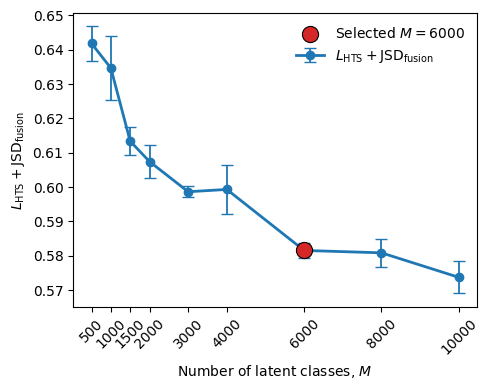

Figure saved to: /content/drive/MyDrive/Colab Notebooks/Workspace/tour_generation/re1_figure/K_combined_objective_seoul.pdf


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

reg = 'seoul'
df = pd.read_csv(path_result + f'case_{reg}_K_sweep_summary_nb_10.csv')


import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# User settings
# =============================================================================
SELECTED_K = 6000          # Set to None to show no selected K
OUTPUT_FILE = path_figure + f"K_combined_objective_{reg}.pdf"

# =============================================================================
# Prepare plotting variables
# =============================================================================
df_plot = df.copy().sort_values("K")

df_plot["combined_mean"] = (
    df_plot["L_hts_final_mean"]
    + df_plot["fusion_consistency_js_mean"]
)

# Propagated SD for the sum, assuming the two estimates are independent
df_plot["combined_sd"] = np.sqrt(
    df_plot["L_hts_final_sd"] ** 2
    + df_plot["fusion_consistency_js_sd"] ** 2
)

# Customize the selection independently of any existing `is_selected` column
df_plot["is_selected_plot"] = df_plot["K"].eq(SELECTED_K)

# =============================================================================
# Plot
# =============================================================================
fig, ax = plt.subplots(figsize=(5, 4))

ax.errorbar(
    df_plot["K"],
    df_plot["combined_mean"],
    yerr=df_plot["combined_sd"],
    fmt="o-",
    color="#1f77b4",
    ecolor="#1f77b4",
    capsize=4,
    elinewidth=1.3,
    linewidth=2,
    markersize=6,
    label=r"$L_{\mathrm{HTS}} + \mathrm{JSD}_{\mathrm{fusion}}$",
)

selected = df_plot[df_plot["is_selected_plot"]]

if not selected.empty:
    ax.scatter(
        selected["K"],
        selected["combined_mean"],
        s=135,
        color="#d62728",
        edgecolor="black",
        linewidth=0.8,
        zorder=4,
        label=f"Selected $M={SELECTED_K}$",
    )

ax.set_xlabel("Number of latent classes, $M$")
ax.set_ylabel(r"$L_{\mathrm{HTS}} + \mathrm{JSD}_{\mathrm{fusion}}$")
ax.set_xticks(df_plot["K"])
ax.tick_params(axis="x", rotation=45)
#ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig(OUTPUT_FILE, format="pdf", bbox_inches="tight")
plt.show()

print(f"Figure saved to: {OUTPUT_FILE}")

# STable: HTS vs PCM spatial descriptive

In [ ]:
# -*- coding: utf-8 -*-
"""
Compute descriptive statistics of origins, destinations, OD pairs,
OD-time tuples (4D: origin, destination, start time, end time),
and trip counts for HTS and PCM in Singapore and Seoul.

Column names (same for HTS and PCM):
  - ORIGIN_SUBZONE
  - DESTINATION_SUBZONE
  - TRIP_STARTTIME
  - TRIP_ENDTIME
  - COUNT   (USED FOR BOTH HTS AND PCM)

Definitions:
  - Origin        = # unique ORIGIN_SUBZONE
  - Destination   = # unique DESTINATION_SUBZONE
  - OD pair       = # unique (ORIGIN_SUBZONE, DESTINATION_SUBZONE)
  - OD-time tuple = # unique (ORIGIN_SUBZONE, DESTINATION_SUBZONE, TRIP_STARTTIME, TRIP_ENDTIME)
  - Trip          = sum(COUNT)

Coverage = HTS / PCM (formatted; <0.01 shown as '$<0.01$')
"""

from __future__ import annotations
from typing import Dict, List, Union
import os
import numpy as np
import pandas as pd


# =========================
# 0) CONFIG
# =========================

ORIGIN_COL = "ORIGIN_SUBZONE"
DEST_COL   = "DESTINATION_SUBZONE"
START_COL  = "TRIP_STARTTIME"
END_COL    = "TRIP_ENDTIME"
COUNT_COL  = "COUNT"   # used for BOTH HTS and PCM


# =========================
# 1) HELPERS
# =========================

def _ensure_cols(df: pd.DataFrame, cols: List[str], name: str) -> None:
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"[{name}] Missing required columns: {missing}")

def _format_int(x: Union[int, float]) -> str:
    try:
        return f"{int(x):,}"
    except Exception:
        return "NA"

def _format_cov_ratio(r: float) -> str:
    if not np.isfinite(r):
        return "NA"
    if r < 0.01:
        return r"$<0.01$"
    return f"{r:.2f}"


# =========================
# 2) STANDARDIZE INPUT
# =========================

def standardize(df: pd.DataFrame, name: str) -> pd.DataFrame:
    """
    Return standardized dataframe with:
      ORIGIN_ZONE, DESTINATION_ZONE, START_TIME, END_TIME, COUNT

    Keeps times at their native resolution (no binning) to match your 4D OD-time tuple definition.
    """
    _ensure_cols(df, [ORIGIN_COL, DEST_COL, START_COL, END_COL, COUNT_COL], name=name)

    out = df[[ORIGIN_COL, DEST_COL, START_COL, END_COL, COUNT_COL]].copy()
    out.columns = ["ORIGIN_ZONE", "DESTINATION_ZONE", "START_TIME", "END_TIME", "COUNT"]

    # Coerce times + count
    out["START_TIME"] = pd.to_numeric(out["START_TIME"], errors="coerce")
    out["END_TIME"]   = pd.to_numeric(out["END_TIME"], errors="coerce")
    out["COUNT"]      = pd.to_numeric(out["COUNT"], errors="coerce").fillna(0.0)

    # Drop rows missing OD/time; also drop zero-count rows (optional but usually correct)
    out = out.dropna(subset=["ORIGIN_ZONE", "DESTINATION_ZONE", "START_TIME", "END_TIME"])
    out = out.loc[out["COUNT"] > 0, :]

    return out


# =========================
# 3) CORE STATS
# =========================

def compute_stats(df_std: pd.DataFrame) -> Dict[str, int]:
    """
    Rows:
      - Origin: unique origins
      - Destination: unique destinations
      - OD pair: unique (origin, destination)
      - OD-time tuple: unique (origin, destination, start_time, end_time)   <-- 4D
      - Trip: sum(COUNT)
    """
    _ensure_cols(df_std, ["ORIGIN_ZONE", "DESTINATION_ZONE", "START_TIME", "END_TIME", "COUNT"], name="STD")

    n_origin = df_std["ORIGIN_ZONE"].nunique()
    n_dest   = df_std["DESTINATION_ZONE"].nunique()

    n_od = df_std[["ORIGIN_ZONE", "DESTINATION_ZONE"]].drop_duplicates().shape[0]
    n_odt = df_std[["ORIGIN_ZONE", "DESTINATION_ZONE", "START_TIME", "END_TIME"]].drop_duplicates().shape[0]

    n_trip = int(np.round(df_std["COUNT"].sum()))

    return {
        "Origin": int(n_origin),
        "Destination": int(n_dest),
        "OD pair": int(n_od),
        "OD-time tuple": int(n_odt),
        "Trip": int(n_trip),
    }


def compute_coverage(hts: Dict[str, int], pcm: Dict[str, int]) -> Dict[str, str]:
    out = {}
    for k in ["Origin", "Destination", "OD pair", "OD-time tuple", "Trip"]:
        a = float(hts.get(k, 0))
        b = float(pcm.get(k, 0))
        r = (a / b) if b > 0 else np.nan
        out[k] = _format_cov_ratio(r)
    return out


# =========================
# 4) LATEX ROWS
# =========================

def latex_rows(
    sg_hts: Dict[str, int], sg_pcm: Dict[str, int], sg_cov: Dict[str, str],
    se_hts: Dict[str, int], se_pcm: Dict[str, int], se_cov: Dict[str, str],
) -> str:
    rows = ["Origin", "Destination", "OD pair", "OD-time tuple", "Trip"]
    lines = []
    for r in rows:
        lines.append(
            f"{r:<12s} & "
            f"{_format_int(sg_hts[r])} & {_format_int(sg_pcm[r])} & {sg_cov[r]} & "
            f"{_format_int(se_hts[r])} & {_format_int(se_pcm[r])} & {se_cov[r]} \\\\"
        )
    return "\n".join(lines)


# =========================
# 5) RUN
# =========================

# You must define path_data before running.
# path_data = "..."

df_sgp_hts = pd.read_csv(os.path.join(path_data, "data_sgp_hts_trip.csv"))
df_sgp_pcm = pd.read_csv(os.path.join(path_data, "data_sgp_pcm_trip.csv"))
df_sel_hts = pd.read_csv(os.path.join(path_data, "data_seoul_hts_trip.csv"))
df_sel_pcm = pd.read_csv(os.path.join(path_data, "data_seoul_pcm_trip.csv"))

df_sgp_hts = df_sgp_hts[df_sgp_hts['INCOME'] < 3]
df_sel_hts = df_sel_hts[df_sel_hts['INCOME'] < 3]


# Ensure COUNT exists in BOTH; if HTS has no COUNT, set to 1 (your convention)
if COUNT_COL not in df_sgp_hts.columns:
    df_sgp_hts[COUNT_COL] = 1
if COUNT_COL not in df_sel_hts.columns:
    df_sel_hts[COUNT_COL] = 1

# Standardize
sg_hts_std = standardize(df_sgp_hts, name="SG_HTS")
sg_pcm_std = standardize(df_sgp_pcm, name="SG_PCM")
se_hts_std = standardize(df_sel_hts, name="SE_HTS")
se_pcm_std = standardize(df_sel_pcm, name="SE_PCM")

# Stats
sg_hts_stats = compute_stats(sg_hts_std)
sg_pcm_stats = compute_stats(sg_pcm_std)
se_hts_stats = compute_stats(se_hts_std)
se_pcm_stats = compute_stats(se_pcm_std)

# Coverage
sg_cov = compute_coverage(sg_hts_stats, sg_pcm_stats)
se_cov = compute_coverage(se_hts_stats, se_pcm_stats)

# Sanity prints
print("SG HTS:", sg_hts_stats)
print("SG PCM:", sg_pcm_stats)
print("SE HTS:", se_hts_stats)
print("SE PCM:", se_pcm_stats)

# LaTeX rows
print("\nLaTeX rows:\n")
print(latex_rows(sg_hts_stats, sg_pcm_stats, sg_cov, se_hts_stats, se_pcm_stats, se_cov))


SG HTS: {'Origin': 307, 'Destination': 309, 'OD pair': 17203, 'OD-time tuple': 30053, 'Trip': 34339}
SG PCM: {'Origin': 303, 'Destination': 303, 'OD pair': 74548, 'OD-time tuple': 1081746, 'Trip': 7435068}
SE HTS: {'Origin': 421, 'Destination': 421, 'OD pair': 19680, 'OD-time tuple': 33794, 'Trip': 38879}
SE PCM: {'Origin': 421, 'Destination': 421, 'OD pair': 176990, 'OD-time tuple': 4678619, 'Trip': 441486943}

LaTeX rows:

Origin       & 307 & 303 & 1.01 & 421 & 421 & 1.00 \\
Destination  & 309 & 303 & 1.02 & 421 & 421 & 1.00 \\
OD pair      & 17,203 & 74,548 & 0.23 & 19,680 & 176,990 & 0.11 \\
OD-time tuple & 30,053 & 1,081,746 & 0.03 & 33,794 & 4,678,619 & $<0.01$ \\
Trip         & 34,339 & 7,435,068 & $<0.01$ & 38,879 & 441,486,943 & $<0.01$ \\


# STable: HTS demographic descriptive

In [ ]:
# -*- coding: utf-8 -*-
"""
Compute person-level and trip-level proportions for Singapore and Seoul HTS data,
and print LaTeX-ready table rows.

Age coding:
    Raw AGE codes 0..7 are recoded into:
        0: <20 years
        1: 20--40 years
        2: 40--60 years
        3: >60 years
"""

from __future__ import annotations

from typing import Dict, List, Tuple
import os

import numpy as np
import pandas as pd


# ============================================================
# 0) CONFIGURATION
# ============================================================

MAX_TRIPS = 7

# Raw age codes -> final age-bin codes
AGE_MAPPING = {
    0: 0,
    1: 0,
    2: 1,
    3: 1,
    4: 2,
    5: 2,
    6: 3,
    7: 3,
}

# Final age-bin codes after AGE_MAPPING
AGE_CODE_MAP = {
    0: "<20 years",
    1: "20--40 years",
    2: "40--60 years",
    3: ">60 years",
}

AGE_ORDER = [
    "<20 years",
    "20--40 years",
    "40--60 years",
    ">60 years",
]

GENDER_MAP = {
    0: "Male",
    1: "Female",
}

GENDER_ORDER = [
    "Male",
    "Female",
]

INCOME_MAP = {
    0: "Low",
    1: "Medium",
    2: "High",
    3: "Not disclosed",
}

INCOME_ORDER = [
    "Low",
    "Medium",
    "High",
    "Not disclosed",
]

PURPOSE_MAP = {
    0: "Home (H)",
    1: "Work (W)",
    2: "Dining (D)",
    3: "Shopping (S)",
    4: "Education (E)",
    5: "Other (O)",
}

PURPOSE_ORDER = [
    "Home (H)",
    "Work (W)",
    "Dining (D)",
    "Shopping (S)",
    "Education (E)",
    "Other (O)",
]

MODE_MAP = {
    0: "Non-transit",
    1: "Transit",
}

MODE_ORDER = [
    "Non-transit",
    "Transit",
]


# ============================================================
# 1) HELPER FUNCTIONS
# ============================================================

def ensure_columns(df: pd.DataFrame, columns: List[str]) -> None:
    """Check whether all required columns are available."""
    missing = [column for column in columns if column not in df.columns]

    if missing:
        raise ValueError(f"Missing required columns: {missing}")


def round3(value: float) -> float:
    """Round a number to three decimal places."""
    return float(np.round(value, 3))


def get_proportion(series: pd.Series, key) -> float:
    """Safely obtain a proportion from a Series."""
    return float(series.get(key, 0.0))


def print_age_distribution(df: pd.DataFrame, city_name: str) -> None:
    """Print diagnostic age counts and proportions."""
    print(f"\n{city_name} age-code distribution:")

    print(
        df["AGE"]
        .value_counts(dropna=False)
        .sort_index()
    )

    print(f"\n{city_name} age-label distribution:")

    age_labels = df["AGE"].map(AGE_CODE_MAP)

    unknown_codes = sorted(
        df.loc[age_labels.isna(), "AGE"]
        .dropna()
        .unique()
        .tolist()
    )

    if unknown_codes:
        print(f"WARNING: Unknown age codes found: {unknown_codes}")

    print(
        age_labels
        .value_counts(dropna=False)
        .reindex(AGE_ORDER, fill_value=0)
    )


# ============================================================
# 2) PERSON-LEVEL STATISTICS
# ============================================================

def person_level_stats(
    df: pd.DataFrame,
) -> Tuple[pd.Series, pd.Series, pd.Series, pd.Series]:
    """
    Compute person-level distributions.

    Each unique ID is counted once.

    Returns:
        age_prop
        gender_prop
        income_prop
        tripmax_prop
    """

    required_columns = [
        "ID",
        "AGE",
        "GENDER",
        "INCOME",
        "TRIP_MAX",
    ]

    ensure_columns(df, required_columns)

    # Keep only one record per person
    persons = (
        df[required_columns]
        .drop_duplicates(subset="ID")
        .copy()
    )

    # --------------------------------------------------------
    # Age
    # --------------------------------------------------------

    persons["AGE_LABEL"] = persons["AGE"].map(AGE_CODE_MAP)

    unknown_age_codes = sorted(
        persons.loc[
            persons["AGE_LABEL"].isna(),
            "AGE"
        ]
        .dropna()
        .unique()
        .tolist()
    )

    if unknown_age_codes:
        raise ValueError(
            "Unknown AGE codes detected after recoding: "
            f"{unknown_age_codes}. "
            "Check AGE_MAPPING and the original AGE coding."
        )

    age_prop = (
        persons["AGE_LABEL"]
        .value_counts(normalize=True)
        .reindex(AGE_ORDER, fill_value=0.0)
    )

    # --------------------------------------------------------
    # Gender
    # --------------------------------------------------------

    persons["GENDER_LABEL"] = persons["GENDER"].map(GENDER_MAP)

    gender_prop = (
        persons["GENDER_LABEL"]
        .value_counts(normalize=True)
        .reindex(GENDER_ORDER, fill_value=0.0)
    )

    # --------------------------------------------------------
    # Income
    # --------------------------------------------------------

    persons["INCOME_LABEL"] = persons["INCOME"].map(INCOME_MAP)

    income_prop = (
        persons["INCOME_LABEL"]
        .value_counts(normalize=True)
        .reindex(INCOME_ORDER, fill_value=0.0)
    )

    # --------------------------------------------------------
    # Maximum number of trips per day
    # --------------------------------------------------------

    tripmax = (
        pd.to_numeric(
            persons["TRIP_MAX"],
            errors="coerce",
        )
        .dropna()
        .astype(int)
    )

    tripmax_prop = (
        tripmax
        .value_counts(normalize=True)
        .sort_index()
    )

    return (
        age_prop,
        gender_prop,
        income_prop,
        tripmax_prop,
    )


# ============================================================
# 3) TRIP-LEVEL STATISTICS
# ============================================================

def trip_level_stats(
    df: pd.DataFrame,
    max_trips: int = MAX_TRIPS,
) -> Tuple[pd.Series, pd.Series]:
    """
    Compute trip-level distributions.

    Each observed trip is counted once.

    Returns:
        purpose_prop
        mode_prop
    """

    purpose_columns = [
        f"TRIP_PURPOSE_{k}"
        for k in range(1, max_trips + 1)
        if f"TRIP_PURPOSE_{k}" in df.columns
    ]

    mode_columns = [
        f"TRAVEL_MODE_{k}"
        for k in range(1, max_trips + 1)
        if f"TRAVEL_MODE_{k}" in df.columns
    ]

    if not purpose_columns:
        raise ValueError(
            "No TRIP_PURPOSE_k columns were found."
        )

    if not mode_columns:
        raise ValueError(
            "No TRAVEL_MODE_k columns were found."
        )

    purposes = (
        pd.concat(
            [df[column] for column in purpose_columns],
            ignore_index=True,
        )
        .dropna()
        .map(PURPOSE_MAP)
        .dropna()
    )

    modes = (
        pd.concat(
            [df[column] for column in mode_columns],
            ignore_index=True,
        )
        .dropna()
        .map(MODE_MAP)
        .dropna()
    )

    purpose_prop = (
        purposes
        .value_counts(normalize=True)
        .reindex(PURPOSE_ORDER, fill_value=0.0)
    )

    mode_prop = (
        modes
        .value_counts(normalize=True)
        .reindex(MODE_ORDER, fill_value=0.0)
    )

    return purpose_prop, mode_prop


# ============================================================
# 4) CITY SUMMARY
# ============================================================

def city_summary(df: pd.DataFrame) -> Dict[str, pd.Series]:
    """Compute all distributions for one city."""

    (
        age_prop,
        gender_prop,
        income_prop,
        tripmax_prop,
    ) = person_level_stats(df)

    purpose_prop, mode_prop = trip_level_stats(df)

    return {
        "age": age_prop,
        "gender": gender_prop,
        "income": income_prop,
        "tripmax": tripmax_prop,
        "purpose": purpose_prop,
        "mode": mode_prop,
    }


# ============================================================
# 5) LATEX ROW BUILDERS
# ============================================================

def latex_value(
    series: pd.Series,
    key,
) -> str:
    """Return a LaTeX-formatted proportion."""
    return f"{round3(get_proportion(series, key)):.3f}"


def build_latex_rows(
    stats_sg: Dict[str, pd.Series],
    stats_se: Dict[str, pd.Series],
) -> str:
    """
    Build LaTeX rows using the layout:

    Attribute & Category A & SG & Seoul
              & Category B & SG & Seoul \\
    """

    lines: List[str] = []

    # --------------------------------------------------------
    # Age: four categories, two categories per row
    # --------------------------------------------------------

    for i in range(0, len(AGE_ORDER), 2):
        left = AGE_ORDER[i]
        right = AGE_ORDER[i + 1]

        prefix = "Age (4)" if i == 0 else ""

        lines.append(
            f"{prefix} & {left} "
            f"& {latex_value(stats_sg['age'], left)} "
            f"& {latex_value(stats_se['age'], left)} "
            f"& {right} "
            f"& {latex_value(stats_sg['age'], right)} "
            f"& {latex_value(stats_se['age'], right)} \\\\"
        )

    lines.append("\\midrule")

    # --------------------------------------------------------
    # Gender
    # --------------------------------------------------------

    left, right = GENDER_ORDER

    lines.append(
        f"Gender (2) & {left} "
        f"& {latex_value(stats_sg['gender'], left)} "
        f"& {latex_value(stats_se['gender'], left)} "
        f"& {right} "
        f"& {latex_value(stats_sg['gender'], right)} "
        f"& {latex_value(stats_se['gender'], right)} \\\\"
    )

    lines.append("\\midrule")

    # --------------------------------------------------------
    # Income
    # --------------------------------------------------------

    for i in range(0, len(INCOME_ORDER), 2):
        left = INCOME_ORDER[i]
        right = INCOME_ORDER[i + 1]

        prefix = "Income (4)" if i == 0 else ""

        lines.append(
            f"{prefix} & {left} "
            f"& {latex_value(stats_sg['income'], left)} "
            f"& {latex_value(stats_se['income'], left)} "
            f"& {right} "
            f"& {latex_value(stats_sg['income'], right)} "
            f"& {latex_value(stats_se['income'], right)} \\\\"
        )

    lines.append("\\midrule")

    # --------------------------------------------------------
    # Trip purpose
    # --------------------------------------------------------

    for i in range(0, len(PURPOSE_ORDER), 2):
        left = PURPOSE_ORDER[i]
        right = PURPOSE_ORDER[i + 1]

        prefix = "Trip purpose (6)" if i == 0 else ""

        lines.append(
            f"{prefix} & {left} "
            f"& {latex_value(stats_sg['purpose'], left)} "
            f"& {latex_value(stats_se['purpose'], left)} "
            f"& {right} "
            f"& {latex_value(stats_sg['purpose'], right)} "
            f"& {latex_value(stats_se['purpose'], right)} \\\\"
        )

    lines.append("\\midrule")

    # --------------------------------------------------------
    # Travel mode
    # --------------------------------------------------------

    left, right = MODE_ORDER

    lines.append(
        f"Travel mode (2) & {left} "
        f"& {latex_value(stats_sg['mode'], left)} "
        f"& {latex_value(stats_se['mode'], left)} "
        f"& {right} "
        f"& {latex_value(stats_sg['mode'], right)} "
        f"& {latex_value(stats_se['mode'], right)} \\\\"
    )

    return "\n".join(lines)


def build_tripmax_block(
    stats_sg: Dict[str, pd.Series],
    stats_se: Dict[str, pd.Series],
) -> str:
    """Build the TRIP_MAX LaTeX block."""

    keys = sorted(
        set(stats_sg["tripmax"].index.tolist())
        | set(stats_se["tripmax"].index.tolist())
    )

    keys = [
        int(key)
        for key in keys
        if pd.notna(key)
    ]

    lines: List[str] = []

    for i in range(0, len(keys), 2):
        left = keys[i]
        right = keys[i + 1] if i + 1 < len(keys) else None

        prefix = (
            "Trips per day (TRIP\\_MAX)"
            if i == 0
            else ""
        )

        left_values = (
            f"{latex_value(stats_sg['tripmax'], left)} "
            f"& {latex_value(stats_se['tripmax'], left)}"
        )

        if right is not None:
            right_values = (
                f"{right} "
                f"& {latex_value(stats_sg['tripmax'], right)} "
                f"& {latex_value(stats_se['tripmax'], right)}"
            )

            lines.append(
                f"{prefix} & {left} & {left_values} "
                f"& {right_values} \\\\"
            )
        else:
            lines.append(
                f"{prefix} & {left} & {left_values} "
                f"&  &  &  \\\\"
            )

    return "\n".join(lines)


# ============================================================
# 6) LOAD DATA
# ============================================================

sg_path = os.path.join(
    path_data,
    "data_sgp_hts_tour.csv",
)

seoul_path = os.path.join(
    path_data,
    "data_seoul_hts_tour.csv",
)

df_sgp_hts = pd.read_csv(sg_path)
df_sel_hts = pd.read_csv(seoul_path)


# ============================================================
# 7) FILTER AND RECODE DATA
# ============================================================

# Exclude undisclosed income
df_sgp_hts = df_sgp_hts[
    df_sgp_hts["INCOME"] < 3
].copy()

df_sel_hts = df_sel_hts[
    df_sel_hts["INCOME"] < 3
].copy()

print(len(df_sgp_hts))
print(len(df_sel_hts))

# Recode raw age codes into four age groups
df_sgp_hts["AGE"] = df_sgp_hts["AGE"].replace(AGE_MAPPING)
df_sel_hts["AGE"] = df_sel_hts["AGE"].replace(AGE_MAPPING)


# ============================================================
# 8) DIAGNOSTIC CHECK
# ============================================================

print_age_distribution(
    df_sgp_hts,
    "Singapore",
)

print_age_distribution(
    df_sel_hts,
    "Seoul",
)


# ============================================================
# 9) COMPUTE SUMMARIES
# ============================================================

stats_sg = city_summary(df_sgp_hts)
stats_se = city_summary(df_sel_hts)


# ============================================================
# 10) BUILD AND PRINT LATEX OUTPUT
# ============================================================

latex_body_main = build_latex_rows(
    stats_sg,
    stats_se,
)

latex_body_tripmax = build_tripmax_block(
    stats_sg,
    stats_se,
)

print("\n% Main LaTeX table body")
print(latex_body_main)

print("\n\\midrule")

print("% TRIP_MAX LaTeX block")
print(latex_body_tripmax)

13306
13107

Singapore age-code distribution:
AGE
0      22
1    6714
2    5733
3     837
Name: count, dtype: int64

Singapore age-label distribution:
AGE
<20 years         22
20--40 years    6714
40--60 years    5733
>60 years        837
Name: count, dtype: int64

Seoul age-code distribution:
AGE
0     165
1    5340
2    5472
3    2130
Name: count, dtype: int64

Seoul age-label distribution:
AGE
<20 years        165
20--40 years    5340
40--60 years    5472
>60 years       2130
Name: count, dtype: int64

% Main LaTeX table body
Age (4) & <20 years & 0.002 & 0.013 & 20--40 years & 0.505 & 0.407 \\
 & 40--60 years & 0.431 & 0.417 & >60 years & 0.063 & 0.163 \\
\midrule
Gender (2) & Male & 0.510 & 0.453 & Female & 0.490 & 0.547 \\
\midrule
Income (4) & Low & 0.402 & 0.244 & Medium & 0.408 & 0.627 \\
 & High & 0.190 & 0.129 & Not disclosed & 0.000 & 0.000 \\
\midrule
Trip purpose (6) & Home (H) & 0.445 & 0.380 & Work (W) & 0.316 & 0.284 \\
 & Dining (D) & 0.062 & 0.080 & Shopping (S) & 0.

# HTS weighting

## STable: HTS weighting

In [ ]:
import os
import numpy as np
import pandas as pd


# =============================================================================
# Settings
# =============================================================================
REGION = "seoul"
KK = 6000
NB = 10
SEEDS = [12345, 23456, 34567, 45678, 56789]

GROUP_COLS = ["AGE", "GENDER", "INCOME", "ORIGIN_SUBZONE_1"]

AGE_MAPPING = {
    0: 0, 1: 0,
    2: 1, 3: 1,
    4: 2, 5: 2,
    6: 3, 7: 3,
}


# =============================================================================
# Helper function
# =============================================================================
def simulate_population_from_hts(df_hts, df_fus, group_cols, random_seed):
    """
    Create a simulated HTS population using the demographic-home composition
    of df_fus.

    For each AGE-GENDER-INCOME-home group:
        - The output contains exactly FUS_COUNT simulated individuals.
        - HTS respondents are duplicated as evenly as possible.
        - Remaining copies are randomly allocated among HTS respondents.

    Groups present in df_fus but absent from df_hts cannot be simulated and
    are reported as warnings.
    """
    rng = np.random.default_rng(random_seed)

    df_hts_sim = df_hts.copy()
    df_fus_sim = df_fus.copy()

    # Ensure consistent home-location type before grouping.
    for df in (df_hts_sim, df_fus_sim):
        df["ORIGIN_SUBZONE_1"] = (
            df["ORIGIN_SUBZONE_1"]
            .astype("string")
            .str.strip()
        )

    # Number of fused individuals in each demographic-home group.
    fus_group = (
        df_fus_sim
        .groupby(group_cols, dropna=False)
        .size()
        .rename("FUS_COUNT")
        .reset_index()
    )

    # Attach the desired simulated population size to each HTS respondent.
    df_hts_sim = df_hts_sim.merge(
        fus_group,
        on=group_cols,
        how="left",
        validate="many_to_one",
    )

    # Keep only HTS groups represented in the fused population.
    matched_mask = df_hts_sim["FUS_COUNT"].notna()
    unmatched_hts = (~matched_mask).sum()

    if unmatched_hts > 0:
        print(
            f"Warning: {unmatched_hts:,} HTS respondents have no matching "
            "demographic-home group in df_fus and are excluded."
        )

    df_hts_sim = df_hts_sim.loc[matched_mask].copy()
    df_hts_sim["FUS_COUNT"] = df_hts_sim["FUS_COUNT"].astype(int)

    # Check fused groups that are unavailable in HTS.
    hts_groups = df_hts_sim[group_cols].drop_duplicates()

    missing_fus_groups = (
        fus_group
        .merge(hts_groups, on=group_cols, how="left", indicator=True)
        .query("_merge == 'left_only'")
        .drop(columns="_merge")
    )

    if not missing_fus_groups.empty:
        missing_population = missing_fus_groups["FUS_COUNT"].sum()

        print(
            f"Warning: {len(missing_fus_groups):,} fused demographic-home "
            f"groups ({missing_population:,} individuals) are absent from HTS "
            "and cannot be simulated."
        )

    # Simulate exactly FUS_COUNT individuals per group.
    simulated_groups = []

    for _, group_df in df_hts_sim.groupby(group_cols, dropna=False, sort=False):
        group_df = group_df.copy()

        hts_count = len(group_df)
        fus_count = int(group_df["FUS_COUNT"].iloc[0])

        # Every HTS respondent receives the same base number of copies.
        base_copies = fus_count // hts_count

        # The remainder is allocated to randomly selected HTS respondents.
        remainder = fus_count % hts_count

        repeat_counts = np.full(hts_count, base_copies, dtype=int)

        if remainder > 0:
            selected_indices = rng.choice(
                hts_count,
                size=remainder,
                replace=False,
            )
            repeat_counts[selected_indices] += 1

        simulated_group = group_df.loc[
            group_df.index.repeat(repeat_counts)
        ].copy()

        simulated_groups.append(simulated_group)

    # Combine all simulated demographic-home groups.
    df_hts_population = pd.concat(
        simulated_groups,
        ignore_index=True,
    )

    # Create new unique IDs for the simulated individuals.
    df_hts_population["ID"] = np.arange(1, len(df_hts_population) + 1)

    # Remove intermediate weighting/count columns from the final output.
    columns_to_remove = [
        "FUS_COUNT",
        "FUS_SHARE",
        "INDIVIDUAL_WEIGHT",
        "EXPANSION_WEIGHT",
    ]

    df_hts_population = df_hts_population.drop(
        columns=columns_to_remove,
        errors="ignore",
    )

    return df_hts_population


# =============================================================================
# Read and prepare HTS data once
# =============================================================================
df_hts_base = pd.read_csv(
    os.path.join(path_data, f"data_{REGION}_hts_tour.csv")
)

df_hts_base = df_hts_base.loc[df_hts_base["INCOME"] < 3].copy()
df_hts_base["AGE"] = df_hts_base["AGE"].replace(AGE_MAPPING)


# =============================================================================
# Simulate population-scale HTS data for each seed
# =============================================================================
for random_seed in SEEDS:
    print(f"\nProcessing seed {random_seed}...")

    fused_file = os.path.join(
        path_result,
        f"case_{REGION}_sim_tour_M_{KK}_nb_{NB}_seed_{random_seed}.csv",
    )

    output_file = os.path.join(
        path_data,
        f"data_{REGION}_hts_tour_M_{KK}_nb_{NB}_seed_{random_seed}.csv",
    )

    df_fus = pd.read_csv(fused_file)

    df_hts_population = simulate_population_from_hts(
        df_hts=df_hts_base,
        df_fus=df_fus,
        group_cols=GROUP_COLS,
        random_seed=random_seed,
    )

    print(f"  Fused population size:     {len(df_fus):,}")
    print(f"  Simulated HTS population:  {len(df_hts_population):,}")

    df_hts_population.to_csv(output_file, index=False)

    print(f"  Saved: {output_file}")


Processing seed 12345...
  Fused population size:     8,965,625
  Simulated HTS population:  7,218,309
  Saved: /content/drive/MyDrive/Colab Notebooks/Workspace/tour_generation/data_tour/data_seoul_hts_tour_M_6000_nb_10_seed_12345.csv

Processing seed 23456...
  Fused population size:     8,958,995
  Simulated HTS population:  7,191,688
  Saved: /content/drive/MyDrive/Colab Notebooks/Workspace/tour_generation/data_tour/data_seoul_hts_tour_M_6000_nb_10_seed_23456.csv

Processing seed 34567...
  Fused population size:     8,959,880
  Simulated HTS population:  7,216,309
  Saved: /content/drive/MyDrive/Colab Notebooks/Workspace/tour_generation/data_tour/data_seoul_hts_tour_M_6000_nb_10_seed_34567.csv

Processing seed 45678...
  Fused population size:     8,959,260
  Simulated HTS population:  7,215,561
  Saved: /content/drive/MyDrive/Colab Notebooks/Workspace/tour_generation/data_tour/data_seoul_hts_tour_M_6000_nb_10_seed_45678.csv

Processing seed 56789...
  Fused population size:     8

## SFigure: HTS weighting

Processed Simulated tour, seed 12345
Processed Simulated tour, seed 23456
Processed Simulated tour, seed 34567
Processed Simulated tour, seed 45678
Processed Simulated tour, seed 56789
Processed HTS weighted, seed 12345
Processed HTS weighted, seed 23456
Processed HTS weighted, seed 34567
Processed HTS weighted, seed 45678
Processed HTS weighted, seed 56789
Processed HTS unweighted


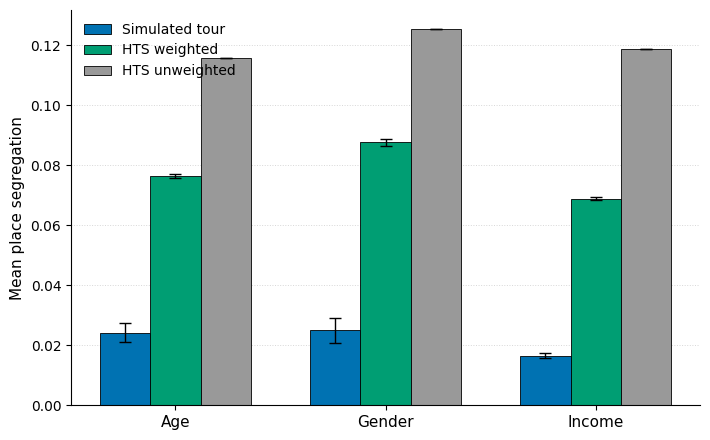


Place-segregation comparison:
       DATASET ATTRIBUTE  N_SEEDS  N_PLACES_MEAN  PLACE_SEGREGATION_MEAN  PLACE_SEGREGATION_SD
Simulated tour       AGE        5          421.0                0.024144              0.003115
  HTS weighted       AGE        5          421.0                0.076357              0.000771
HTS unweighted       AGE        0          421.0                0.115873              0.000000
Simulated tour    GENDER        5          421.0                0.024932              0.004076
  HTS weighted    GENDER        5          421.0                0.087678              0.001155
HTS unweighted    GENDER        0          421.0                0.125446              0.000000
Simulated tour    INCOME        5          421.0                0.016509              0.000879
  HTS weighted    INCOME        5          421.0                0.068784              0.000459
HTS unweighted    INCOME        0          421.0                0.118642              0.000000

Figure saved to:
/

In [ ]:
from __future__ import annotations

import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# =============================================================================
# CONFIGURATION
# =============================================================================
REGION = "seoul"
M = 6000
NB = 10
SEEDS = [12345, 23456, 34567, 45678, 56789]

ATTRIBUTE_ORDER = ["AGE", "GENDER", "INCOME"]

# Folder containing the already-calculated all_place_segregation CSV files.
# Example: path_segregation = "/your/path/to/segregation/results"
INPUT_PATH = path_segregation

OUTPUT_FIGURE = os.path.join(
    path_figure,
    f"comparison_place_segregation_{REGION}_M_{M}_nb_{NB}.pdf",
)

OUTPUT_SUMMARY = os.path.join(
    path_figure,
    f"comparison_place_segregation_{REGION}_M_{M}_nb_{NB}_summary.csv",
)

DPI = 300

# -------------------------------------------------------------------------
# Change only these filename templates if necessary.
#
# {reg}, {M}, {nb}, and {seed} will be replaced automatically.
#
# Simulated tour and weighted HTS: one file per seed.
# Unweighted HTS: one file only, because it does not vary by seed.
# -------------------------------------------------------------------------
DATASET_SPECS = {
    "Simulated tour": {
        "file_template": (
            "all_place_segregation_{reg}_M_{M}_nb_{nb}_seed_{seed}.csv"
        ),
        "seeds": SEEDS,
        "color": "#0072B2",
    },
    "HTS weighted": {
        "file_template": (
            "hts_all_place_segregation_{reg}_M_{M}_nb_{nb}_seed_{seed}.csv"
        ),
        "seeds": SEEDS,
        "color": "#009E73",
    },
    "HTS unweighted": {
        "file_template": (
            "unweighted_hts_all_place_segregation_{reg}.csv"
        ),
        "seeds": [None],
        "color": "#999999",
    },
}


# =============================================================================
# FUNCTIONS
# =============================================================================
def build_file_path(input_path, file_template, reg, M, nb, seed):
    """Build one input filename from the configured template."""
    filename = file_template.format(
        reg=reg,
        M=M,
        nb=nb,
        seed=seed,
    )
    return os.path.join(input_path, filename)


def calculate_place_segregation_summary(
    file_path,
    dataset_name,
    seed,
):
    """
    Calculate the mean place segregation for each attribute from one file.

    The mean is calculated across ACTIVITY_SUBZONE values, consistently with
    the attached code.
    """
    required_columns = [
        "ACTIVITY_SUBZONE",
        "ATTRIBUTE",
        "PLACE_SEGREGATION",
    ]

    data = pd.read_csv(file_path, usecols=required_columns)

    data["ATTRIBUTE"] = (
        data["ATTRIBUTE"]
        .astype("string")
        .str.strip()
        .str.upper()
    )

    data["PLACE_SEGREGATION"] = pd.to_numeric(
        data["PLACE_SEGREGATION"],
        errors="coerce",
    )

    data = data.dropna(
        subset=["ACTIVITY_SUBZONE", "ATTRIBUTE", "PLACE_SEGREGATION"]
    )

    summary = (
        data.groupby("ATTRIBUTE", observed=True, sort=False)
        .agg(
            N_PLACES=("ACTIVITY_SUBZONE", "nunique"),
            PLACE_SEGREGATION=("PLACE_SEGREGATION", "mean"),
        )
        .reset_index()
    )

    summary.insert(0, "SEED", seed)
    summary.insert(0, "DATASET", dataset_name)

    return summary


def collect_all_dataset_summaries(
    input_path,
    dataset_specs,
    reg,
    M,
    nb,
):
    """Read all available dataset/seed files and calculate their summaries."""
    summaries = []

    for dataset_name, spec in dataset_specs.items():
        for seed in spec["seeds"]:
            file_path = build_file_path(
                input_path=input_path,
                file_template=spec["file_template"],
                reg=reg,
                M=M,
                nb=nb,
                seed=seed,
            )

            if not os.path.exists(file_path):
                raise FileNotFoundError(
                    f"Missing file for '{dataset_name}'"
                    f"{'' if seed is None else f', seed {seed}'}:\n"
                    f"{file_path}"
                )

            summary = calculate_place_segregation_summary(
                file_path=file_path,
                dataset_name=dataset_name,
                seed=seed,
            )

            summaries.append(summary)

            print(
                f"Processed {dataset_name}"
                f"{'' if seed is None else f', seed {seed}'}"
            )

    return pd.concat(summaries, ignore_index=True)


def summarize_across_seeds(all_summaries, dataset_order, attribute_order):
    """Calculate mean and standard deviation across seeds."""
    summary = (
        all_summaries
        .groupby(["DATASET", "ATTRIBUTE"], observed=True, sort=False)
        .agg(
            N_SEEDS=("SEED", lambda x: x.notna().sum()),
            N_PLACES_MEAN=("N_PLACES", "mean"),
            PLACE_SEGREGATION_MEAN=("PLACE_SEGREGATION", "mean"),
            PLACE_SEGREGATION_SD=("PLACE_SEGREGATION", "std"),
        )
        .reset_index()
    )

    summary["PLACE_SEGREGATION_SD"] = (
        summary["PLACE_SEGREGATION_SD"].fillna(0.0)
    )

    summary["DATASET"] = pd.Categorical(
        summary["DATASET"],
        categories=dataset_order,
        ordered=True,
    )

    summary["ATTRIBUTE"] = pd.Categorical(
        summary["ATTRIBUTE"],
        categories=attribute_order,
        ordered=True,
    )

    return summary.sort_values(["ATTRIBUTE", "DATASET"]).reset_index(drop=True)

def plot_place_segregation_comparison(
    summary,
    dataset_specs,
    attribute_order,
    output_path,
    dpi=300,
):
    """
    Plot mean place segregation across seeds.

    Bar height: mean across seeds.
    Error bar:  mean ± one standard deviation across seeds.
    """
    dataset_order = list(dataset_specs.keys())

    x = np.arange(len(attribute_order), dtype=float)
    bar_width = 0.24
    offsets = np.array([-bar_width, 0.0, bar_width])

    fig, ax = plt.subplots(figsize=(7.2, 4.5))

    for dataset_index, dataset_name in enumerate(dataset_order):
        color = dataset_specs[dataset_name]["color"]

        dataset_summary = (
            summary.loc[summary["DATASET"].eq(dataset_name)]
            .set_index("ATTRIBUTE")
            .reindex(attribute_order)
        )

        means = dataset_summary["PLACE_SEGREGATION_MEAN"].to_numpy(dtype=float)
        stds = dataset_summary["PLACE_SEGREGATION_SD"].to_numpy(dtype=float)

        ax.bar(
            x + offsets[dataset_index],
            means,
            width=bar_width,
            color=color,
            edgecolor="black",
            linewidth=0.6,
            label=dataset_name,
            yerr=stds,
            capsize=4,
            error_kw={
                "ecolor": "black",
                "elinewidth": 1.0,
                "capthick": 1.0,
            },
            zorder=2,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(["Age", "Gender", "Income"], fontsize=11)
    ax.set_ylabel("Mean place segregation", fontsize=11)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.grid(
        axis="y",
        linestyle=":",
        linewidth=0.7,
        alpha=0.5,
        zorder=0,
    )

    ax.legend(
        frameon=False,
        fontsize=10,
        loc="upper left",
    )

    fig.tight_layout()

    output_directory = os.path.dirname(output_path)
    if output_directory:
        os.makedirs(output_directory, exist_ok=True)

    fig.savefig(
        output_path,
        dpi=dpi,
        bbox_inches="tight",
    )

    return fig, ax


# =============================================================================
# RUN
# =============================================================================
if __name__ == "__main__":

    dataset_order = list(DATASET_SPECS.keys())

    # 1. Calculate mean place segregation for every dataset and seed.
    all_summaries = collect_all_dataset_summaries(
        input_path=INPUT_PATH,
        dataset_specs=DATASET_SPECS,
        reg=REGION,
        M=M,
        nb=NB,
    )

    # 2. Summarize the five-seed results.
    comparison_summary = summarize_across_seeds(
        all_summaries=all_summaries,
        dataset_order=dataset_order,
        attribute_order=ATTRIBUTE_ORDER,
    )

    # 3. Save numerical results.
    comparison_summary.to_csv(
        OUTPUT_SUMMARY,
        index=False,
    )

    # 4. Create the bar chart.
    fig, ax = plot_place_segregation_comparison(
        summary=comparison_summary,
        dataset_specs=DATASET_SPECS,
        attribute_order=ATTRIBUTE_ORDER,
        output_path=OUTPUT_FIGURE,
        dpi=DPI,
    )

    plt.show()

    print("\nPlace-segregation comparison:")
    print(
        comparison_summary[
            [
                "DATASET",
                "ATTRIBUTE",
                "N_SEEDS",
                "N_PLACES_MEAN",
                "PLACE_SEGREGATION_MEAN",
                "PLACE_SEGREGATION_SD",
            ]
        ].to_string(index=False)
    )

    print(f"\nFigure saved to:\n{OUTPUT_FIGURE}")
    print(f"\nSummary table saved to:\n{OUTPUT_SUMMARY}")

# Simulated experiment

## Validate schedule

In [ ]:
import os
import numpy as np
import pandas as pd
from scipy.spatial.distance import jensenshannon
from sklearn.metrics import r2_score, mean_squared_error


PURPOSE_RECODE_HTS_FUS = {0: 0, 1: 1, 2: 2, 3: 2, 4: 2, 5: 2}  # keeps Work=1, Other=2
PURPOSE_RECODE_PCM = {"H": 0, "W": 1, "E": 2}  # assumes E corresponds to Other

def prepare_pcm(df: pd.DataFrame) -> pd.DataFrame:
    df["COUNT"] = 1
    #df["TRIP_PURPOSE"] = df["TRIP_PURPOSE"].replace(PURPOSE_RECODE_PCM)
    return df

def prepare_fus(df: pd.DataFrame) -> pd.DataFrame:
    df["COUNT"] = df["Prob_XYZ_fus"]
    #df["TRIP_PURPOSE"] = df["TRIP_PURPOSE"].replace(PURPOSE_RECODE_HTS_FUS)
    return df


# ============================================================
# Build weighted distribution P(Z)
# ============================================================
def build_weighted_distribution(
    df: pd.DataFrame,
    key_cols: list[str],
    count_col: str = "COUNT",
) -> pd.DataFrame:
    """
    Build normalized weighted joint distribution over key_cols.
    """
    missing = [c for c in key_cols + [count_col] if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    x = df[key_cols + [count_col]].dropna(subset=key_cols + [count_col]).copy()
    x[count_col] = pd.to_numeric(x[count_col], errors="coerce")
    x = x.dropna(subset=[count_col])

    dist = (
        x.groupby(key_cols, sort=False, as_index=False)[count_col]
         .sum()
         .rename(columns={count_col: "count"})
    )

    total = dist["count"].sum()
    if total <= 0:
        raise ValueError("Total weight is non-positive.")

    dist["prob"] = dist["count"] / total
    return dist


# ============================================================
# Align distributions on common support union
# ============================================================
def align_distributions(
    dist_a: pd.DataFrame,
    dist_b: pd.DataFrame,
    key_cols: list[str],
) -> pd.DataFrame:
    """
    Align two distributions on the union of keys.
    """
    a = dist_a.rename(columns={"count": "count_a", "prob": "prob_a"})
    b = dist_b.rename(columns={"count": "count_b", "prob": "prob_b"})

    merged = (
        a.merge(b, on=key_cols, how="outer")
         .fillna(0.0)
         .sort_values(key_cols)
         .reset_index(drop=True)
    )

    for c in ["count_a", "prob_a", "count_b", "prob_b"]:
        merged[c] = merged[c].astype(float)

    # Re-normalize after alignment, just to be safe
    if merged["prob_a"].sum() > 0:
        merged["prob_a"] = merged["prob_a"] / merged["prob_a"].sum()
    if merged["prob_b"].sum() > 0:
        merged["prob_b"] = merged["prob_b"] / merged["prob_b"].sum()

    return merged


# ============================================================
# Compute metrics
# ============================================================
def compute_distribution_metrics_from_weights(
    df_a: pd.DataFrame,
    df_b: pd.DataFrame,
    key_cols: list[str],
    count_col_a: str = "COUNT",
    count_col_b: str = "COUNT",
) -> tuple[dict, pd.DataFrame]:
    """
    Compute JSD, R2, and RMSE between two weighted joint distributions.
    """
    dist_a = build_weighted_distribution(df_a, key_cols=key_cols, count_col=count_col_a)
    dist_b = build_weighted_distribution(df_b, key_cols=key_cols, count_col=count_col_b)

    aligned = align_distributions(dist_a, dist_b, key_cols=key_cols)

    p_a = aligned["prob_a"].to_numpy(dtype=float)
    p_b = aligned["prob_b"].to_numpy(dtype=float)

    jsd = float(jensenshannon(p_a, p_b) ** 2)
    r2 = float(r2_score(p_a, p_b))
    rmse = float(np.sqrt(mean_squared_error(p_a, p_b)))

    metrics = {
        "JSD": jsd,
        "R2": r2,
        "RMSE": rmse,
    }
    return metrics, aligned


# ============================================================
# Run
# ============================================================
# ============================================================
# Load datasets
# ============================================================

att_Z = [
        'ORIGIN_SUBZONE',
        'DESTINATION_SUBZONE',
        'TRIP_STARTTIME',
        #'AGE',
        #'TRIP_PURPOSE',
        #'GENDER'
    ]

att_X = ['AGE', 'TRIP_PURPOSE', 'GENDER']

df_pcm  = pd.read_csv(os.path.join(path_data,   'val_data_true_trip.csv'))
#df_pcm = df_pcm[df_pcm['AGE']>0]
df_pcm = prepare_pcm(df_pcm)

TRIP_MAX = 7

for frac in [0.1,0.2, 0.4]:
    df_fus = pd.read_csv(os.path.join(path_result,  f'val_sim_trip_proposed_{frac}.csv'))
    #df_fus = df_fus[df_fus['AGE']>0]

    df_fus = prepare_fus(df_fus)

    for att in att_X:
        # ============================================================
        # Preprocessing
        # ============================================================
        metrics, aligned = compute_distribution_metrics_from_weights(
            df_a=df_pcm.copy(),
            df_b=df_fus.copy(),
            key_cols=att_Z + [att],
            count_col_a="COUNT",
            count_col_b="COUNT",
        )

        print("****************************************")
        #print(f"M = {KK}, Attribut = {att}")
        print(f"Fract = {frac}, Attribut = {att}")
        print("****************************************")
        print(f"JSD  : {metrics['JSD']:.6f}")
        print(f"R2   : {metrics['R2']:.6f}")
        print(f"RMSE : {metrics['RMSE']:.8e}")
        print("****************************************")




****************************************
Fract = 0.1, Attribut = AGE
****************************************
JSD  : 0.253106
R2   : 0.303557
RMSE : 1.29553925e-05
****************************************
****************************************
Fract = 0.1, Attribut = TRIP_PURPOSE
****************************************
JSD  : 0.222927
R2   : 0.461075
RMSE : 1.09457383e-05
****************************************
****************************************
Fract = 0.1, Attribut = GENDER
****************************************
JSD  : 0.182377
R2   : 0.306067
RMSE : 1.53554565e-05
****************************************
****************************************
Fract = 0.2, Attribut = AGE
****************************************
JSD  : 0.241994
R2   : 0.353744
RMSE : 1.23271249e-05
****************************************
****************************************
Fract = 0.2, Attribut = TRIP_PURPOSE
****************************************
JSD  : 0.210413
R2   : 0.514961
RMSE : 1.00646551

***********************************
************ ALL ******************
***********************************


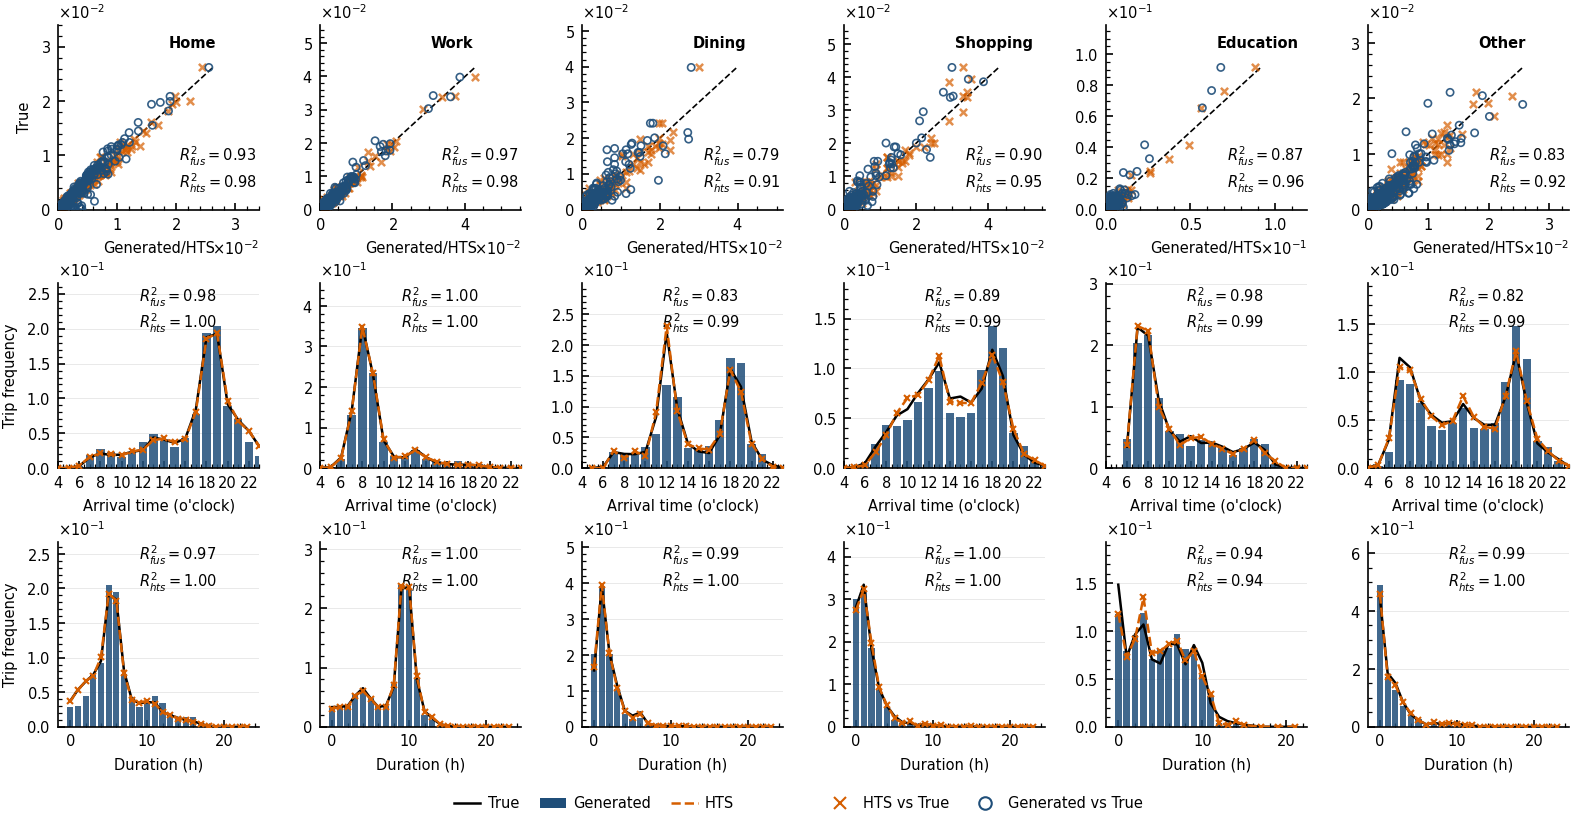

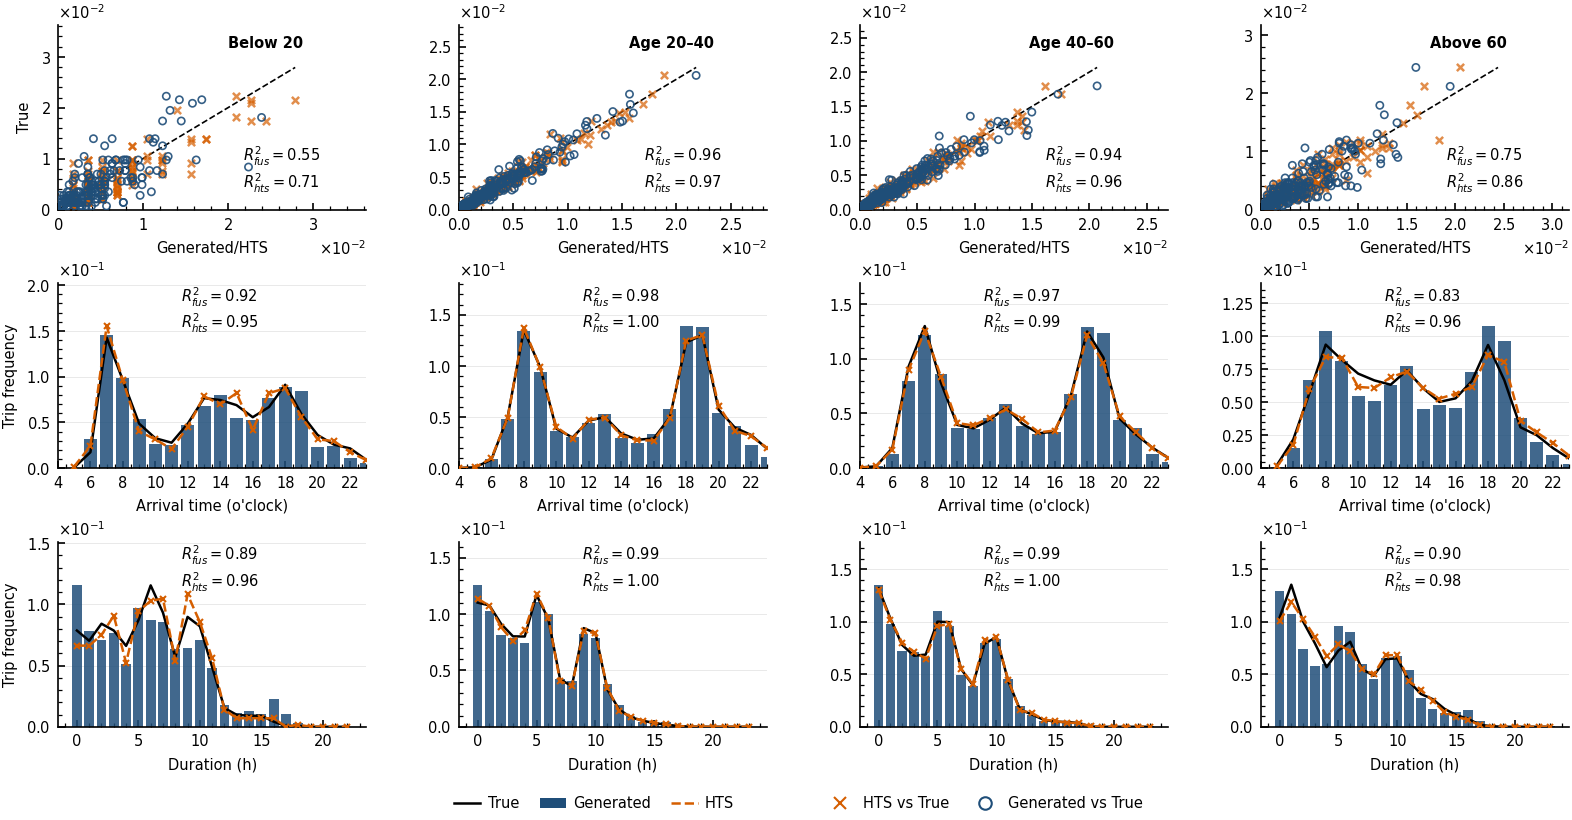

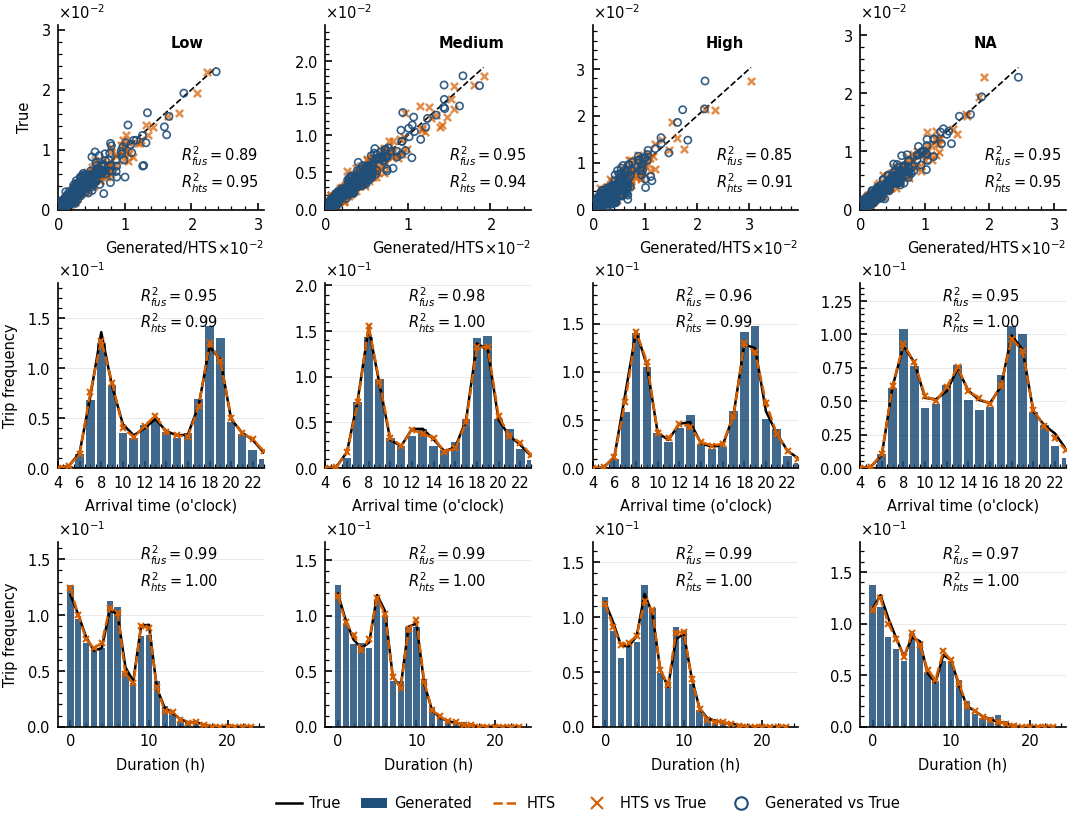

In [ ]:
# -*- coding: utf-8 -*-
"""
Full plotting pipeline (Nature-style) for HTS / True / Generated comparisons.

What it does:
- Computes destination duration at each leg: DUR_i = start_{i+1} - end_i; for final leg, DUR = 24 - end_i.
- Explodes wide per-chain rows into per-trip rows (long view) with chain-level attrs carried over.
- Chain-level attrs: AGE, GENDER, TRIP_MAX, TOUR_PURPOSE  (computed from WIDE)
- Trip-level attrs: TRIP_PURPOSE, TRAVEL_MODE, TRIP_ENDTIME, DESTINATION_DURATION, DESTINATION_SUBZONE, etc. (from LONG)
- Purpose filtering is by the TRIP's OWN purpose (no “any-purpose-in-chain” leakage).
- Scatter plots robustified (key dtype normalization, Pop_* coercion, and inner merges for common support).

Fill in: path_data, path_result, path_figure in MAIN.
"""

import os
from functools import reduce
from typing import List, Tuple

import pandas as pd
import numpy as np
from scipy.special import rel_entr
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter, AutoMinorLocator, MultipleLocator
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy.stats import spearmanr
from sklearn.metrics import r2_score

# =========================
# Global Config
# =========================
TRIP_MAX = 7  # max trips per chain (1..7)

def set_nature_style():
    plt.rcParams.update({
        "figure.dpi": 150, "savefig.dpi": 150,
        "font.family": "DejaVu Sans", "font.size": 7,
        "axes.labelsize": 7, "axes.titlesize": 7,
        "legend.fontsize": 7, "xtick.labelsize": 7, "ytick.labelsize": 7,
        "axes.linewidth": 0.8, "lines.linewidth": 1.2, "patch.linewidth": 0.8,
        "xtick.direction": "in", "ytick.direction": "in",
        "xtick.major.size": 3.5, "ytick.major.size": 3.5,
        "xtick.minor.size": 2, "ytick.minor.size": 2,
        "legend.frameon": False,
        "savefig.bbox": "tight", "savefig.pad_inches": 0.02,
        "pdf.fonttype": 42, "ps.fonttype": 42,
    })
set_nature_style()

COLORSzz = {
    "true": "#000000",   # deep black
    "sim":  "#1B9E77",   # turquoise-green
    "hts":  "#7570B3",   # slate blue
    "diag": "#000000",
}

COLORSz = {
    "true":  "#000000",
    "sim":   "#2C7FB8",
    "hts": "#7A7A7A",
    "diag":  "#000000",
}

COLORS1 = {
    "true": "#000000",
    "sim":  "#2E8B57",   # sea-green
    "hts":  "#A0A0A0",
    "diag": "#000000",
}


COLORS3 = {
    "true": "#000000",
    "sim":  "#0072B2",   # teal-blue
    "hts":  "#E69F00",    # warm amber
    "diag": "#000000",
}


COLORS = {
    "true": "#000000",
    "hts":  "#D55E00",   # orange-red
    "sim":  "#1F4E79",    # deep blue
    "diag": "#000000",
}


COLORS2 = {
    "true":   "#440154",  # deep violet — low end of Viridis
    "sim": "#35B779",  # teal-green — mid Viridis tone (harmonizes naturally)
    "hts":  "#FDE725",  # lime-yellow — high end of Viridis
}

AX_LABELS = {
    'AGE': 'Age', 'GENDER': 'Gender', 'INCOME': 'Income', 'TRIP_MAX': 'Activity-chain length',
    'TRIP_PURPOSE': 'Activity purpose', 'TRAVEL_MODE': 'Travel mode',
    'TOUR_PURPOSE': 'Activity-chain purpose', 'TRIP_STARTTIME': "Departure time (o'clock)",
    'TRIP_ENDTIME': "Arrival time (o'clock)", 'DESTINATION_DURATION': 'Duration (h)',
    'TRIP_DISTANCE': 'Trip distance (km)', 'DESTINATION': 'Destination',
    'ORIGIN': 'Origin', 'OD': 'OD',
}

PURPOSE_NAMES = {0:'Home',1:'Work',2:'Dining',3:'Shopping',4:'Education',5:'Other'}
AGE_NAMES = {0:'Below 20',1:'Age 20–40',2:'Age 40–60',3:'Above 60'}
INCOME_NAMES = {0:'Low',1:'Medium',2:'High', 3:'NA'}
# =========================
# Utilities
# =========================
def merge_three(a: pd.DataFrame, b: pd.DataFrame, c: pd.DataFrame, on: List[str]) -> pd.DataFrame:
    out = reduce(lambda x, y: pd.merge(x, y, on=on, how='outer'), [a, b, c])
    return out.fillna(0)

def merge_three_inner(a: pd.DataFrame, b: pd.DataFrame, c: pd.DataFrame, on: List[str]) -> pd.DataFrame:
    """Inner-join variant (for scatter, enforces common support across sources)."""
    out = a.merge(b, on=on, how='inner').merge(c, on=on, how='inner')
    return out

def prob_table(series: pd.Series, value_col: str, pop_name: str) -> pd.DataFrame:
    s = series.dropna()
    if s.empty:
        return pd.DataFrame({value_col: [], f'Pop_{pop_name}': []})
    probs = (s.value_counts() / s.size).rename(f'Pop_{pop_name}').reset_index()
    probs = probs.rename(columns={'index': value_col})
    return probs.sort_values(value_col)

def haversine_km(lat1, lon1, lat2, lon2) -> np.ndarray:
    lat1 = np.radians(lat1); lon1 = np.radians(lon1)
    lat2 = np.radians(lat2); lon2 = np.radians(lon2)
    dlat = lat2 - lat1; dlon = lon2 - lon1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2.0)**2
    return 6371.0 * 2.0 * np.arcsin(np.sqrt(a))

def _format_axis_sci(ax, which="both"):
    fmt = ScalarFormatter(useMathText=True); fmt.set_powerlimits((0, 0))
    if which in ("x", "both"): ax.xaxis.set_major_formatter(fmt)
    if which in ("y", "both"): ax.yaxis.set_major_formatter(fmt)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())

def _beautify_axes(ax, top=False, right=False, grid=True):
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible({"top": top, "right": right}[spine])
    ax.spines["left"].set_linewidth(0.8); ax.spines["bottom"].set_linewidth(0.8)
    if grid: ax.grid(axis="y", which="major", linewidth=0.3, color="#DDDDDD")
    ax.tick_params(width=0.8, length=3.5); ax.tick_params(which="minor", width=0.6, length=2)

def js_div(p: np.ndarray, q: np.ndarray) -> np.ndarray:
    h = 0.5 * (p + q)
    return 0.5 * rel_entr(p, h) + 0.5 * rel_entr(q, h)

def _safe_spearman(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float); y_pred = np.asarray(y_pred, dtype=float)
    m = ~(np.isnan(y_true) | np.isnan(y_pred))
    y_true = y_true[m]; y_pred = y_pred[m]
    if y_true.size < 3 or np.allclose(y_true, y_true[0]) or np.allclose(y_pred, y_pred[0]):
        return np.nan
    return float(spearmanr(y_true, y_pred).correlation)

def _r2(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float); y_pred = np.asarray(y_pred, dtype=float)
    m = ~(np.isnan(y_true) | np.isnan(y_pred))
    if not m.any(): return np.nan
    return float(r2_score(y_true[m], y_pred[m]))

def get_max(df: pd.DataFrame) -> float:
    vals = [df[k].max() for k in ("Pop_sim", "Pop_true", "Pop_hts") if k in df]
    return float(max(vals)) if vals else 0.0

def _normalize_keys(df: pd.DataFrame, cols: List[str]) -> pd.DataFrame:
    """Force join keys to a canonical type (string) to avoid misalignment across sources."""
    df = df.copy()
    for c in cols:
        if c in df.columns:
            df[c] = df[c].astype(str)
    return df

def _coerce_pop_numeric(df: pd.DataFrame) -> pd.DataFrame:
    """Ensure Pop_* columns are numeric (NaNs allowed)."""
    df = df.copy()
    for c in ('Pop_true','Pop_sim','Pop_hts'):
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='coerce')
    return df

# =========================
# Wide -> Long conversion
# =========================
def _iter_existing(df: pd.DataFrame, base: str):
    for i in range(1, TRIP_MAX + 1):
        col = f"{base}_{i}"
        if col in df.columns:
            yield i, col

def build_trip_long(df: pd.DataFrame) -> pd.DataFrame:
    """
    Wide -> long using reshape-style stacking (no reconstruction):
      - For each i in 1..TRIP_MAX, select the per-leg columns that exist,
        rename to base names, add TRIP_CNT=i (and TRIP_INDEX alias).
      - Compute DESTINATION_DURATION:
           if TRIP_INDEX < TRIP_MAX: TRIP_STARTTIME(next) - TRIP_ENDTIME
           else:                     24 - TRIP_ENDTIME
        (wrap small negatives by +24)
      - Compute TRIP_DISTANCE (km) if all 4 coords exist for the leg:
           haversine(ORIGIN_SUBZONE_Y, ORIGIN_SUBZONE_X,
                     DESTINATION_SUBZONE_Y, DESTINATION_SUBZONE_X)
      - Finally drop rows with any NaN (matching your reshape() strictness).
    """
    parts = []
    base_cols = ['ID', 'AGE', 'GENDER', 'INCOME', 'TRIP_MAX']

    for i in range(1, TRIP_MAX + 1):
        att_ = [
            f'TRIP_PURPOSE_{i}',
            f'TRAVEL_MODE_{i}',
            f'TRIP_STARTTIME_{i}',
            f'TRIP_ENDTIME_{i}',
            f'ORIGIN_SUBZONE_{i}',
            f'DESTINATION_SUBZONE_{i}',
            # coordinates are optional; include if they exist
            f'ORIGIN_SUBZONE_X_{i}',
            f'ORIGIN_SUBZONE_Y_{i}',
            f'DESTINATION_SUBZONE_X_{i}',
            f'DESTINATION_SUBZONE_Y_{i}',
        ]
        cols_i = [c for c in (base_cols + att_) if c in df.columns]

        # require the 6 core per-trip fields (as in your reshape_trip)
        core_req = {
            f'TRIP_PURPOSE_{i}',
            f'TRAVEL_MODE_{i}',
            f'TRIP_STARTTIME_{i}',
            f'TRIP_ENDTIME_{i}',
            f'ORIGIN_SUBZONE_{i}',
            f'DESTINATION_SUBZONE_{i}',
        }
        if not core_req.issubset(set(cols_i)):
            continue

        dff = df[cols_i].copy()
        dff['TRIP_CNT'] = i

        # rename to base names
        rename_map = {
            f'TRIP_PURPOSE_{i}':        'TRIP_PURPOSE',
            f'TRAVEL_MODE_{i}':         'TRAVEL_MODE',
            f'TRIP_STARTTIME_{i}':      'TRIP_STARTTIME',
            f'TRIP_ENDTIME_{i}':        'TRIP_ENDTIME',
            f'ORIGIN_SUBZONE_{i}':      'ORIGIN_SUBZONE',
            f'DESTINATION_SUBZONE_{i}': 'DESTINATION_SUBZONE',
        }
        # optional coordinate renames (only if present)
        opt_map = {
            f'ORIGIN_SUBZONE_X_{i}':      'ORIGIN_SUBZONE_X',
            f'ORIGIN_SUBZONE_Y_{i}':      'ORIGIN_SUBZONE_Y',
            f'DESTINATION_SUBZONE_X_{i}': 'DESTINATION_SUBZONE_X',
            f'DESTINATION_SUBZONE_Y_{i}': 'DESTINATION_SUBZONE_Y',
        }
        for k, v in opt_map.items():
            if k in dff.columns:
                rename_map[k] = v

        dff.rename(columns=rename_map, inplace=True)
        parts.append(dff)

    if not parts:
        return pd.DataFrame(columns=[
            'ID','AGE','GENDER', 'INCOME','TRIP_MAX','TRIP_CNT','TRIP_INDEX',
            'TRIP_PURPOSE','TRAVEL_MODE','TRIP_STARTTIME','TRIP_ENDTIME',
            'ORIGIN_SUBZONE','DESTINATION_SUBZONE',
            'ORIGIN_SUBZONE_X','ORIGIN_SUBZONE_Y',
            'DESTINATION_SUBZONE_X','DESTINATION_SUBZONE_Y',
            'DESTINATION_DURATION','TRIP_DISTANCE'
        ])

    df_long = pd.concat(parts, ignore_index=True)

    # Index & ordering
    df_long['TRIP_INDEX'] = df_long['TRIP_CNT']
    df_long.sort_values(['ID', 'TRIP_INDEX'], inplace=True)

    # Duration
    next_start = df_long.groupby('ID')['TRIP_STARTTIME'].shift(-1)
    dur = next_start - df_long['TRIP_ENDTIME']
    is_last = df_long['TRIP_INDEX'] >= df_long['TRIP_MAX']
    df_long['DESTINATION_DURATION'] = np.where(is_last, 24 - df_long['TRIP_ENDTIME'], dur)
    # wrap tiny negatives
    neg = df_long['DESTINATION_DURATION'] < 0
    df_long.loc[neg, 'DESTINATION_DURATION'] = df_long.loc[neg, 'DESTINATION_DURATION'] + 24

    # Distance (km) if all coords exist on that row; else stays NaN
    has_coords = {'ORIGIN_SUBZONE_X','ORIGIN_SUBZONE_Y','DESTINATION_SUBZONE_X','DESTINATION_SUBZONE_Y'}
    if has_coords.issubset(df_long.columns):
        df_long['TRIP_DISTANCE'] = haversine_km(
            df_long['ORIGIN_SUBZONE_Y'], df_long['ORIGIN_SUBZONE_X'],
            df_long['DESTINATION_SUBZONE_Y'], df_long['DESTINATION_SUBZONE_X']
        )
    else:
        df_long['TRIP_DISTANCE'] = np.nan

    # Strict like your reshape: drop rows with any NaN among selected columns
    df_long.dropna(inplace=True)

    return df_long.reset_index(drop=True)



def total_trip_long(df_long: pd.DataFrame) -> float:
    return 0.0 if df_long is None or df_long.empty else float(len(df_long))

# =========================
# Probability Builders (Chain-level vs Trip-level)
# =========================
def join_prob_att(df_sim: pd.DataFrame, df_true: pd.DataFrame, df_hts: pd.DataFrame, att: str) -> pd.DataFrame:
    a = prob_table(df_sim[att], att, 'sim')
    b = prob_table(df_true[att], att, 'true')
    c = prob_table(df_hts[att], att, 'hts')
    return merge_three(a, b, c, on=[att])

def tour_purpose(df: pd.DataFrame, tag: str) -> pd.DataFrame:
    """Encode chain pattern from TRIP_PURPOSE_1..7 → string code without padding."""
    if df.empty: return pd.DataFrame(columns=['TOUR_PURPOSE', f'Pop_{tag}'])
    d = df.copy()
    for i in range(1, TRIP_MAX + 1):
        col = f'TRIP_PURPOSE_{i}'
        if col not in d: d[col] = np.nan
    d = d.fillna(9)
    weights = np.array([1e6, 1e5, 1e4, 1e3, 1e2, 1e1, 1e0], dtype=float)[:TRIP_MAX]
    code = 9e8 + sum(d[f'TRIP_PURPOSE_{i}'] * weights[i-1] for i in range(1, TRIP_MAX + 1))
    s = code.astype(np.int64).astype(str).str.replace('9', '', regex=False)
    NN = float(len(d))
    if NN == 0: return pd.DataFrame(columns=['TOUR_PURPOSE', f'Pop_{tag}'])
    t = s.to_frame('TOUR_PURPOSE'); t['__n'] = 1.0
    probs = (t.groupby('TOUR_PURPOSE')['__n'].sum() / NN).rename(f'Pop_{tag}').reset_index()
    return probs

def _aggregate_across_trips_long(df_long: pd.DataFrame, col: str, pop_tag: str) -> pd.DataFrame:
    NN = total_trip_long(df_long)
    if NN <= 0 or col not in df_long: return pd.DataFrame({col: [], f'Pop_{pop_tag}': []})
    s = df_long[col].dropna()
    if s.empty: return pd.DataFrame({col: [], f'Pop_{pop_tag}': []})
    probs = (s.value_counts() / NN).rename(f'Pop_{pop_tag}').reset_index()
    probs = probs.rename(columns={'index': col}).sort_values(col)
    return probs

def trip_purpose_all(df_long: pd.DataFrame, tag: str) -> pd.DataFrame:
    return _aggregate_across_trips_long(df_long, 'TRIP_PURPOSE', tag)

def trip_mode_all(df_long: pd.DataFrame, tag: str) -> pd.DataFrame:
    return _aggregate_across_trips_long(df_long, 'TRAVEL_MODE', tag)

def trip_generation_all(df_long: pd.DataFrame, tag: str) -> pd.DataFrame:
    df_long = _normalize_keys(df_long, ['ORIGIN_SUBZONE'])
    NN = total_trip_long(df_long)
    if NN <= 0 or 'ORIGIN_SUBZONE' not in df_long:
        return pd.DataFrame(columns=['ORIGIN_SUBZONE', f'Pop_{tag}'])
    probs = (df_long['ORIGIN_SUBZONE'].value_counts() / NN).rename(f'Pop_{tag}').reset_index()
    return probs.rename(columns={'index': 'ORIGIN_SUBZONE'})

def trip_attraction_all(df_long: pd.DataFrame, tag: str) -> pd.DataFrame:
    df_long = _normalize_keys(df_long, ['DESTINATION_SUBZONE'])
    NN = total_trip_long(df_long)
    if NN <= 0 or 'DESTINATION_SUBZONE' not in df_long:
        return pd.DataFrame(columns=['DESTINATION_SUBZONE', f'Pop_{tag}'])
    probs = (df_long['DESTINATION_SUBZONE'].value_counts() / NN).rename(f'Pop_{tag}').reset_index()
    return probs.rename(columns={'index': 'DESTINATION_SUBZONE'})

def od_demand_all(df_long: pd.DataFrame, tag: str) -> pd.DataFrame:
    df_long = _normalize_keys(df_long, ['ORIGIN_SUBZONE','DESTINATION_SUBZONE'])
    NN = total_trip_long(df_long)
    if NN <= 0 or not {'ORIGIN_SUBZONE','DESTINATION_SUBZONE'}.issubset(df_long.columns):
        return pd.DataFrame(columns=['ORIGIN_SUBZONE','DESTINATION_SUBZONE', f'Pop_{tag}'])
    g = df_long.groupby(['ORIGIN_SUBZONE','DESTINATION_SUBZONE']).size() / NN
    return g.rename(f'Pop_{tag}').reset_index()

def departure_time_all(df_long: pd.DataFrame, time_att: str, tag: str) -> pd.DataFrame:
    if time_att not in df_long: return pd.DataFrame({time_att: [], f'Pop_{tag}': []})
    return _aggregate_across_trips_long(df_long, time_att, tag)

def duration_all(df_long: pd.DataFrame, tag: str) -> pd.DataFrame:
    if 'DESTINATION_DURATION' not in df_long:
        return pd.DataFrame(columns=['DESTINATION_DURATION', f'Pop_{tag}'])
    return _aggregate_across_trips_long(df_long, 'DESTINATION_DURATION', tag)

def travel_distance_all(df_long: pd.DataFrame, tag: str) -> pd.DataFrame:
    NN = total_trip_long(df_long)
    if NN <= 0: return pd.DataFrame(columns=['TRIP_DISTANCE', f'Pop_{tag}'])
    req = ['ORIGIN_SUBZONE_X','ORIGIN_SUBZONE_Y','DESTINATION_SUBZONE_X','DESTINATION_SUBZONE_Y']
    if not set(req).issubset(df_long.columns):
        return pd.DataFrame(columns=['TRIP_DISTANCE', f'Pop_{tag}'])
    km = haversine_km(df_long['ORIGIN_SUBZONE_Y'], df_long['ORIGIN_SUBZONE_X'],
                      df_long['DESTINATION_SUBZONE_Y'], df_long['DESTINATION_SUBZONE_X'])
    bins = np.ceil(km).astype('Int64')
    s = pd.Series(bins, name='TRIP_DISTANCE').dropna()
    if s.empty: return pd.DataFrame(columns=['TRIP_DISTANCE', f'Pop_{tag}'])
    probs = (s.value_counts() / NN).rename(f'Pop_{tag}').reset_index()
    return probs.rename(columns={'index': 'TRIP_DISTANCE'}).sort_values('TRIP_DISTANCE')

# =========================
# Conditioned Builders
# =========================
def filter_by_trip_purpose(df_long_or_wide: pd.DataFrame, p: int) -> pd.DataFrame:
    df_long = df_long_or_wide if 'TRIP_INDEX' in df_long_or_wide.columns else build_trip_long(df_long_or_wide)
    return df_long[df_long['TRIP_PURPOSE'] == p].copy()

def filter_by_age(df_long_or_wide: pd.DataFrame, age_val: int) -> pd.DataFrame:
    df_ = df_long_or_wide if 'TRIP_INDEX' in df_long_or_wide.columns else build_trip_long(df_long_or_wide)
    return df_[df_['AGE'] == age_val].copy()

def filter_by_income(df_long_or_wide: pd.DataFrame, p: int) -> pd.DataFrame:
    df_long = df_long_or_wide if 'TRIP_INDEX' in df_long_or_wide.columns else build_trip_long(df_long_or_wide)
    return df_long[df_long['INCOME'] == p].copy()

def departure_time_conditional(df_long: pd.DataFrame, time_att: str, tag: str) -> pd.DataFrame:
    if time_att not in df_long.columns:
        return pd.DataFrame({time_att: [], f'Pop_{tag}': []})
    return _aggregate_across_trips_long(df_long, time_att, tag)

def duration_conditional(df_long: pd.DataFrame, tag: str) -> pd.DataFrame:
    if 'DESTINATION_DURATION' not in df_long.columns:
        return pd.DataFrame(columns=['DESTINATION_DURATION', f'Pop_{tag}'])
    return _aggregate_across_trips_long(df_long, 'DESTINATION_DURATION', tag)

def attraction_conditional(df_long: pd.DataFrame, tag: str) -> pd.DataFrame:
    if 'DESTINATION_SUBZONE' not in df_long.columns:
        return pd.DataFrame(columns=['DESTINATION_SUBZONE', f'Pop_{tag}'])
    NN = total_trip_long(df_long)
    if NN <= 0: return pd.DataFrame(columns=['DESTINATION_SUBZONE', f'Pop_{tag}'])
    probs = (df_long['DESTINATION_SUBZONE'].value_counts() / NN).rename(f'Pop_{tag}').reset_index()
    return probs.rename(columns={'index': 'DESTINATION_SUBZONE'})

# =========================
# Plotters
# =========================
def plot_bar_ax(ax, df: pd.DataFrame, att: str):
    d = df.sort_values(att).copy()
    if att == 'TOUR_PURPOSE' and 'Pop_true' in d:
        d = d.sort_values('Pop_true', ascending=False)

    x = np.arange(len(d)); w = 0.28
    has_true = 'Pop_true' in d; has_sim = 'Pop_sim' in d; has_hts = 'Pop_hts' in d
    off = -w if has_true and (has_sim or has_hts) else 0.0

    if has_true:
        ax.bar(x + off, d['Pop_true'], width=w, color=COLORS["true"], label='True', zorder=3); off += w
    if has_sim:
        ax.bar(x + off, d['Pop_sim'], width=w, color=COLORS["sim"], label='Generated', zorder=3); off += w
    if has_hts:
        ax.bar(x + off, d['Pop_hts'], width=w, color=COLORS["hts"], label='HTS', zorder=3)

    ax.set_xlabel(AX_LABELS.get(att, att));
    ax.set_ylabel('Population share')
    maxz = get_max(d);
    if maxz and maxz > 0: ax.set_ylim(0, 1.3 * maxz)

    if att == 'AGE':
        ax.set_xticks(x, ['<20', '20-40', '40-60', '>60'], rotation=20)
    elif att == 'GENDER':
        ax.set_xticks(x, ['Male', 'Female'])
    elif att == 'INCOME':
        ax.set_xticks(x, ['Low', 'Medium', 'High'], rotation=20)
    elif att == 'TRIP_MAX':
        ax.set_xticks(x, [int(v) for v in d['TRIP_MAX']])
    elif att == 'TRAVEL_MODE':
        ax.set_xticks(x, ['Non-transit', 'Transit'])
        ax.set_ylabel('Trip frequency')
    elif att == 'TRIP_PURPOSE':
        ax.set_xticks(x, ['H','W','D','S','E','O'])
        ax.set_ylabel('Trip frequency')
    elif att == 'TOUR_PURPOSE':
        mapping = {'0':'H','1':'W','2':'D','3':'S','4':'E','5':'O'}
        labels = [''.join(mapping.get(ch, '') for ch in str(s)) for s in d['TOUR_PURPOSE'].astype(str)]
        ax.set_xticks(x, labels, rotation=30)

    _format_axis_sci(ax, which="y"); _beautify_axes(ax)

def plot_line_ax(ax, df: pd.DataFrame, att: str, context: str = '', idx: int = -1):
    label_map = {
        'TRIP_STARTTIME': "Departure time (o'clock)",
        'TRIP_ENDTIME':   "Arrival time (o'clock)",
        'DESTINATION_DURATION': 'Duration (h)',
        'TRIP_DISTANCE':       'Trip distance (km)',
    }
    d = df.copy()
    if att in d.columns: d[att] = pd.to_numeric(d[att], errors='coerce')

    if 'Pop_true' in d:
        ax.plot(d[att], d['Pop_true'], color=COLORS["true"], linestyle='-', label='True', zorder=3)
    if 'Pop_sim' in d:
        ax.bar(d[att], d['Pop_sim'], width=0.8, color=COLORS["sim"], edgecolor='none', alpha=0.85, label='Generated', zorder=2)
    if 'Pop_hts' in d:
        ax.plot(d[att], d['Pop_hts'], color=COLORS["hts"], linestyle='--', markersize=2.5, marker='x', label='HTS', zorder=4)

    ax.set_xlabel(label_map.get(att, att)); ax.set_ylabel('Trip frequency')
    maxz = get_max(d);
    if maxz and maxz > 0: ax.set_ylim(0, 1.3 * maxz)

    if att in {'TRIP_STARTTIME','TRIP_ENDTIME'}:
        ax.set_xlim(4, 23); ax.set_xticks(np.arange(4, 24, 2))
        ax.set_xticklabels([str(int(x)) for x in np.arange(4, 24, 2)])
        ax.xaxis.set_minor_locator(MultipleLocator(1))

    _format_axis_sci(ax, which="y"); _beautify_axes(ax)

    metrics = []
    if {'Pop_true','Pop_sim'}.issubset(d.columns):
        rho = _r2(d['Pop_true'], d['Pop_sim'])
        if not np.isnan(rho): metrics.append(fr"$R^2_{{fus}}={rho:.2f}$")
    if {'Pop_true','Pop_hts'}.issubset(d.columns):
        rho = _r2(d['Pop_true'], d['Pop_hts'])
        if not np.isnan(rho): metrics.append(fr"$R^2_{{hts}}={rho:.2f}$")
    if metrics:
        ax.text(0.4, 0.99, "\n".join(metrics), transform=ax.transAxes, va='top', ha='left', fontsize=7)



def plot_point_ax(ax, df: pd.DataFrame, att: str, context: str = '', idx: int = -1):
    limit = get_max(df)
    if limit and limit > 0:
        ax.plot([0, limit], [0, limit], linestyle='--', color=COLORS["true"], linewidth=0.8, zorder=1) #"#999999"
        ax.set_xlim(0, 1.3 * limit)
        ax.set_ylim(0, 1.3 * limit)

    if {'Pop_hts','Pop_true'}.issubset(df.columns):
        ax.scatter(df['Pop_hts'], df['Pop_true'], s=12, marker='x', color=COLORS["hts"], alpha=0.7,
                   label='HTS vs True', zorder=2)
    if {'Pop_sim','Pop_true'}.issubset(df.columns):
        ax.scatter(df['Pop_sim'], df['Pop_true'], s=12, facecolor="none", edgecolor=COLORS["sim"],
                   linewidth=0.8, alpha=0.9, label='Generated vs True', zorder=3)

    ax.set_xlabel('Generated/HTS')
    ax.set_ylabel('True')
    _format_axis_sci(ax, which="both")
    _beautify_axes(ax, grid=False)

    # --- R² values ---
    metrics_lines = []
    if {'Pop_true', 'Pop_sim'}.issubset(df.columns):
        r2_gen = _r2(df['Pop_true'], df['Pop_sim'])
        if not np.isnan(r2_gen):
            metrics_lines.append(fr"$R^2_{{fus}}={r2_gen:.2f}$")
    if {'Pop_true', 'Pop_hts'}.issubset(df.columns):
        r2_hts = _r2(df['Pop_true'], df['Pop_hts'])
        if not np.isnan(r2_hts):
            metrics_lines.append(fr"$R^2_{{hts}}={r2_hts:.2f}$")

    if metrics_lines:
        ax.text(0.6, 0.35, "\n".join(metrics_lines),
                transform=ax.transAxes, va='top', ha='left', fontsize=7)

# =========================
# Grid composers
# =========================
def compose_share_grid(panels: list, nrows: int = 3, ncols: int = 4,
                       figsize: Tuple[float,float] = (7.0, 5.5), save_path: str | None = None):
    import string
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
    axes = axes.flatten(); letters = list(string.ascii_lowercase)
    for ax in axes: ax.set_visible(False)

    legend_handles, legend_labels = [], []
    for i, (kind, df, att, context, idx) in enumerate(panels):
        if i >= len(axes): break
        ax = axes[i]; ax.set_visible(True)

        if kind == 'bar':   plot_bar_ax(ax, df, att)
        elif kind == 'line': plot_line_ax(ax, df, att, context=context, idx=idx)
        elif kind == 'point': plot_point_ax(ax, df, att, context=context, idx=idx)
        else: raise ValueError("Unknown kind")

        h, l = ax.get_legend_handles_labels()
        for hh, ll in zip(h, l):
            if ll not in legend_labels:
                legend_handles.append(hh); legend_labels.append(ll)

        #ax.text(0.05, 0.99, f"{letters[i]}", transform=ax.transAxes, va="top", ha="left",
        #        fontsize=9, fontweight="bold",
        #        bbox=dict(boxstyle="square,pad=0.1", facecolor="white", alpha=0.85, lw=0))

        if letters[i] == 'j':
            ax.text(0.6, 0.96, "Origin", transform=ax.transAxes, va='top', ha='left', fontsize=7)
        elif letters[i] == 'k':
            ax.text(0.6, 0.96, "Destination", transform=ax.transAxes, va='top', ha='left', fontsize=7)
        elif letters[i] == 'l':
            ax.text(0.6, 0.96, "OD", transform=ax.transAxes, va='top', ha='left', fontsize=7)

    plt.subplots_adjust(wspace=0.30, hspace=0.40, bottom=0.14)

    if legend_handles:
        fig.legend(legend_handles, legend_labels, loc="lower center", bbox_to_anchor=(0.5, -0.02),
                   ncol=5, frameon=False, handlelength=1.8, columnspacing=1.4, handletextpad=0.5)

    if save_path:
        #plt.savefig(save_path + ".pdf", dpi=600, bbox_inches="tight")
        plt.savefig(save_path + ".png", dpi=200, bbox_inches="tight")
    return fig

def compose_purpose_grid(df_true: pd.DataFrame, df_sim: pd.DataFrame, df_hts: pd.DataFrame,
                         purposes=(0, 1, 2, 3), time_att='TRIP_ENDTIME',
                         figsize=(7.0, 5.5), save_path: str | None = None):
    import string
    ncols = len(purposes)
    fig, axes = plt.subplots(nrows=3, ncols=ncols, figsize=figsize)
    letters = list(string.ascii_lowercase)

    sim_long  = build_trip_long(df_sim)
    true_long = build_trip_long(df_true)
    hts_long  = build_trip_long(df_hts)

    for j, p in enumerate(purposes):
        fs = filter_by_trip_purpose(sim_long,  p)
        ft = filter_by_trip_purpose(true_long, p)
        fh = filter_by_trip_purpose(hts_long,  p)

        # === Row 1 — Destination scatter (moved to top row) ===
        a1 = attraction_conditional(fs, 'sim')
        a2 = attraction_conditional(ft, 'true')
        a3 = attraction_conditional(fh, 'hts')
        dest = merge_three_inner(a2, a1, a3, on=['DESTINATION_SUBZONE']).sort_values('Pop_true')
        ax = axes[0, j]
        plot_point_ax(ax, dest, 'DESTINATION', context='PURPOSE', idx=p)
        #ax.text(0.05, 0.99, f"{letters[j]}",
        #        transform=ax.transAxes, va='top', ha='left',
        #        fontsize=9, fontweight='bold')
        # Bold purpose text ONLY in scatter row
        ax.text(0.55, 0.94, PURPOSE_NAMES.get(p, str(p)),
                transform=ax.transAxes, va='top', ha='left',
                fontsize=7, fontweight='bold') #

        # === Row 2 — Arrival time line ===
        d1 = departure_time_conditional(fs, time_att, 'sim')
        d2 = departure_time_conditional(ft, time_att, 'true')
        d3 = departure_time_conditional(fh, time_att, 'hts')
        arr = merge_three(d1, d2, d3, on=[time_att]).fillna(0).sort_values(time_att)
        ax = axes[1, j]
        plot_line_ax(ax, arr, time_att, context='PURPOSE', idx=p)
        #ax.text(0.05, 0.99, f"{letters[ncols + j]}",
        #        transform=ax.transAxes, va='top', ha='left',
        #        fontsize=9, fontweight='bold')
        # ⬇️ NO purpose text here (line plot)

        # === Row 3 — Duration line ===
        d1 = duration_conditional(fs, 'sim')
        d2 = duration_conditional(ft, 'true')
        d3 = duration_conditional(fh, 'hts')
        dur = merge_three(d1, d2, d3, on=['DESTINATION_DURATION']).fillna(0).sort_values('DESTINATION_DURATION')
        ax = axes[2, j]
        plot_line_ax(ax, dur, 'DESTINATION_DURATION', context='PURPOSE', idx=p)
        #ax.text(0.05, 0.99, f"{letters[2 * ncols + j]}",
        #       transform=ax.transAxes, va='top', ha='left',
        #        fontsize=9, fontweight='bold')
        # ⬇️ NO purpose text here (line plot)

        if j > 0:
            axes[0, j].set_ylabel('')
            axes[1, j].set_ylabel('')
            axes[2, j].set_ylabel('')

    # Row labels updated to match new row semantics
    axes[0, 0].set_ylabel('True')            # scatter
    axes[1, 0].set_ylabel('Trip frequency')  # arrival time
    axes[2, 0].set_ylabel('Trip frequency')  # duration

    # X-labels updated: row 1 scatter, row 2 arrival, row 3 duration
    for j in range(ncols):
        axes[0, j].set_xlabel('Generated/HTS')
        axes[1, j].set_xlabel("Arrival time (o'clock)")
        axes[2, j].set_xlabel('Duration (h)')

    plt.subplots_adjust(wspace=0.30, hspace=0.40, bottom=0.16)

    legend1 = [
        Line2D([0], [0], color=COLORS["true"], lw=1.2, label='True'),
        Patch(facecolor=COLORS["sim"], edgecolor='none', label='Generated'),
        Line2D([0], [0], color=COLORS["hts"], lw=1.2, ls='--', label='HTS'),
    ]
    fig.legend(legend1, ['True', 'Generated', 'HTS'],
               loc='lower center', bbox_to_anchor=(0.4, 0.06),
               ncol=3, frameon=False, handlelength=1.8, columnspacing=1.4, handletextpad=0.5)

    legend2 = [
        Line2D([], [], marker='x', linestyle='None',
               markerfacecolor=COLORS["hts"], markeredgecolor=COLORS["hts"],
               markersize=6, label='HTS vs True'),
        Line2D([], [], marker='o', linestyle='None',
               markerfacecolor='none', markeredgecolor=COLORS["sim"],
               markersize=6, label='Generated vs True'),
    ]
    fig.legend(legend2, ['HTS vs True', 'Generated vs True'],
               loc='lower center', bbox_to_anchor=(0.6, 0.06),
               ncol=2, frameon=False, columnspacing=1.4, handletextpad=0.6)

    if save_path:
        #plt.savefig(save_path + ".pdf", dpi=600, bbox_inches='tight')
        plt.savefig(save_path + ".png", dpi=200, bbox_inches='tight')
    return fig

def compose_age_grid(df_true: pd.DataFrame, df_sim: pd.DataFrame, df_hts: pd.DataFrame,
                     ages=(1, 2, 3, 4, 6), time_att='TRIP_ENDTIME',
                     figsize=(7.0, 5.5), save_path: str | None = None):
    import string
    ncols = len(ages)
    fig, axes = plt.subplots(nrows=3, ncols=ncols, figsize=figsize)
    letters = list(string.ascii_lowercase)

    sim_long  = build_trip_long(df_sim)
    true_long = build_trip_long(df_true)
    hts_long  = build_trip_long(df_hts)

    for j, a in enumerate(ages):
        fs = filter_by_age(sim_long,  a)
        ft = filter_by_age(true_long, a)
        fh = filter_by_age(hts_long,  a)

        # === Row 1 — Destination scatter (moved to top row) ===
        a1 = attraction_conditional(fs, 'sim')
        a2 = attraction_conditional(ft, 'true')
        a3 = attraction_conditional(fh, 'hts')
        dest = merge_three_inner(a2, a1, a3, on=['DESTINATION_SUBZONE']).sort_values('Pop_true')
        ax = axes[0, j]
        plot_point_ax(ax, dest, 'DESTINATION', context='AGE', idx=a)
        #ax.text(0.05, 0.99, f"{letters[j]}",
        #        transform=ax.transAxes, va='top', ha='left',
        #        fontsize=9, fontweight='bold')
        # Bold age group text ONLY in scatter row
        ax.text(0.55, 0.94, AGE_NAMES.get(a, str(a)),
                transform=ax.transAxes, va='top', ha='left',
                fontsize=7, fontweight='bold') #, fontweight='bold'

        # === Row 2 — Arrival time line ===
        d1 = departure_time_conditional(fs, time_att, 'sim')
        d2 = departure_time_conditional(ft, time_att, 'true')
        d3 = departure_time_conditional(fh, time_att, 'hts')
        arr = merge_three(d1, d2, d3, on=[time_att]).fillna(0).sort_values(time_att)
        ax = axes[1, j]
        plot_line_ax(ax, arr, time_att, context='AGE', idx=a)
        #ax.text(0.05, 0.99, f"{letters[ncols + j]}",
        #        transform=ax.transAxes, va='top', ha='left',
        #        fontsize=9) #, fontweight='bold'
        # ⬇️ NO age text here (line plot)

        # === Row 3 — Duration line ===
        d1 = duration_conditional(fs, 'sim')
        d2 = duration_conditional(ft, 'true')
        d3 = duration_conditional(fh, 'hts')
        dur = merge_three(d1, d2, d3, on=['DESTINATION_DURATION']).fillna(0).sort_values('DESTINATION_DURATION')
        ax = axes[2, j]
        plot_line_ax(ax, dur, 'DESTINATION_DURATION', context='AGE', idx=a)
        #ax.text(0.05, 0.99, f"{letters[2 * ncols + j]}",
        #        transform=ax.transAxes, va='top', ha='left',
        #        fontsize=9, fontweight='bold')
        # ⬇️ NO age text here (line plot)

        if j > 0:
            axes[0, j].set_ylabel('')
            axes[1, j].set_ylabel('')
            axes[2, j].set_ylabel('')

    # Row labels updated
    axes[0, 0].set_ylabel('True')            # scatter
    axes[1, 0].set_ylabel('Trip frequency')  # arrival time
    axes[2, 0].set_ylabel('Trip frequency')  # duration

    # X-labels updated
    for j in range(ncols):
        axes[0, j].set_xlabel('Generated/HTS')
        axes[1, j].set_xlabel("Arrival time (o'clock)")
        axes[2, j].set_xlabel('Duration (h)')

    plt.subplots_adjust(wspace=0.30, hspace=0.40, bottom=0.16)

    legend1 = [
        Line2D([0], [0], color=COLORS["true"], lw=1.2, label='True'),
        Patch(facecolor=COLORS["sim"], edgecolor='none', label='Generated'),
        Line2D([0], [0], color=COLORS["hts"], lw=1.2, ls='--', label='HTS'),
    ]
    fig.legend(legend1, ['True', 'Generated', 'HTS'],
               loc='lower center', bbox_to_anchor=(0.4, 0.06),
               ncol=3, frameon=False, handlelength=1.8, columnspacing=1.4, handletextpad=0.5)

    legend2 = [
        Line2D([], [], marker='x', linestyle='None',
               markerfacecolor=COLORS["hts"], markeredgecolor=COLORS["hts"],
               markersize=6, label='HTS vs True'),
        Line2D([], [], marker='o', linestyle='None',
               markerfacecolor='none', markeredgecolor=COLORS["sim"],
               markersize=6, label='Generated vs True'),
    ]
    fig.legend(legend2, ['HTS vs True', 'Generated vs True'],
               loc='lower center', bbox_to_anchor=(0.6, 0.06),
               ncol=2, frameon=False, columnspacing=1.4, handletextpad=0.6)

    if save_path:
        #plt.savefig(save_path + ".pdf", dpi=600, bbox_inches='tight')
        plt.savefig(save_path + ".png", dpi=200, bbox_inches='tight')
    return fig


def compose_income_grid(df_true: pd.DataFrame, df_sim: pd.DataFrame, df_hts: pd.DataFrame,
                     incomes=(0, 1, 2, 3), time_att='TRIP_ENDTIME',
                     figsize=(7.0, 5.5), save_path: str | None = None):
    import string
    ncols = len(incomes)
    fig, axes = plt.subplots(nrows=3, ncols=ncols, figsize=figsize)
    letters = list(string.ascii_lowercase)

    sim_long  = build_trip_long(df_sim)
    true_long = build_trip_long(df_true)
    hts_long  = build_trip_long(df_hts)

    for j, a in enumerate(incomes):
        fs = filter_by_income(sim_long,  a)
        ft = filter_by_income(true_long, a)
        fh = filter_by_income(hts_long,  a)

        # === Row 1 — Destination scatter (moved to top row) ===
        a1 = attraction_conditional(fs, 'sim')
        a2 = attraction_conditional(ft, 'true')
        a3 = attraction_conditional(fh, 'hts')
        dest = merge_three_inner(a2, a1, a3, on=['DESTINATION_SUBZONE']).sort_values('Pop_true')
        ax = axes[0, j]
        plot_point_ax(ax, dest, 'DESTINATION', context='INCOME', idx=a)
        #ax.text(0.05, 0.99, f"{letters[j]}",
        #        transform=ax.transAxes, va='top', ha='left',
        #        fontsize=9, fontweight='bold')
        # Bold age group text ONLY in scatter row
        ax.text(0.55, 0.94, INCOME_NAMES.get(a, str(a)),
                transform=ax.transAxes, va='top', ha='left',
                fontsize=7, fontweight='bold') #, fontweight='bold'

        # === Row 2 — Arrival time line ===
        d1 = departure_time_conditional(fs, time_att, 'sim')
        d2 = departure_time_conditional(ft, time_att, 'true')
        d3 = departure_time_conditional(fh, time_att, 'hts')
        arr = merge_three(d1, d2, d3, on=[time_att]).fillna(0).sort_values(time_att)
        ax = axes[1, j]
        plot_line_ax(ax, arr, time_att, context='INCOME', idx=a)
        #ax.text(0.05, 0.99, f"{letters[ncols + j]}",
        #        transform=ax.transAxes, va='top', ha='left',
        #        fontsize=9) #, fontweight='bold'
        # ⬇️ NO age text here (line plot)

        # === Row 3 — Duration line ===
        d1 = duration_conditional(fs, 'sim')
        d2 = duration_conditional(ft, 'true')
        d3 = duration_conditional(fh, 'hts')
        dur = merge_three(d1, d2, d3, on=['DESTINATION_DURATION']).fillna(0).sort_values('DESTINATION_DURATION')
        ax = axes[2, j]
        plot_line_ax(ax, dur, 'DESTINATION_DURATION', context='INCOME', idx=a)
        #ax.text(0.05, 0.99, f"{letters[2 * ncols + j]}",
        #        transform=ax.transAxes, va='top', ha='left',
        #        fontsize=9, fontweight='bold')
        # ⬇️ NO age text here (line plot)

        if j > 0:
            axes[0, j].set_ylabel('')
            axes[1, j].set_ylabel('')
            axes[2, j].set_ylabel('')

    # Row labels updated
    axes[0, 0].set_ylabel('True')            # scatter
    axes[1, 0].set_ylabel('Trip frequency')  # arrival time
    axes[2, 0].set_ylabel('Trip frequency')  # duration

    # X-labels updated
    for j in range(ncols):
        axes[0, j].set_xlabel('Generated/HTS')
        axes[1, j].set_xlabel("Arrival time (o'clock)")
        axes[2, j].set_xlabel('Duration (h)')

    plt.subplots_adjust(wspace=0.30, hspace=0.40, bottom=0.16)

    legend1 = [
        Line2D([0], [0], color=COLORS["true"], lw=1.2, label='True'),
        Patch(facecolor=COLORS["sim"], edgecolor='none', label='Generated'),
        Line2D([0], [0], color=COLORS["hts"], lw=1.2, ls='--', label='HTS'),
    ]
    fig.legend(legend1, ['True', 'Generated', 'HTS'],
               loc='lower center', bbox_to_anchor=(0.4, 0.06),
               ncol=3, frameon=False, handlelength=1.8, columnspacing=1.4, handletextpad=0.5)

    legend2 = [
        Line2D([], [], marker='x', linestyle='None',
               markerfacecolor=COLORS["hts"], markeredgecolor=COLORS["hts"],
               markersize=6, label='HTS vs True'),
        Line2D([], [], marker='o', linestyle='None',
               markerfacecolor='none', markeredgecolor=COLORS["sim"],
               markersize=6, label='Generated vs True'),
    ]
    fig.legend(legend2, ['HTS vs True', 'Generated vs True'],
               loc='lower center', bbox_to_anchor=(0.65, 0.06),
               ncol=2, frameon=False, columnspacing=1.4, handletextpad=0.6)

    if save_path:
        #plt.savefig(save_path + ".pdf", dpi=600, bbox_inches='tight')
        plt.savefig(save_path + ".png", dpi=200, bbox_inches='tight')
    return fig

# =========================
# MAIN
# =========================
if __name__ == "__main__":
    print('***********************************')
    print('************ ALL ******************')
    print('***********************************')

    # ---- Fill your paths ----
    # path_data = "..."
    # path_result = "..."
    # path_figure = "..."

    frac = '0.4'

    # Load wide per-chain data
    df_hts  = pd.read_csv(os.path.join(path_data,   f'val_data_hts_tour_{frac}.csv'))
    df_true = pd.read_csv(os.path.join(path_data,   f'val_data_true_tour.csv'))
    df_fus  = pd.read_csv(os.path.join(path_result, f'val_sim_tour_proposed_{frac}.csv'))


    '''print(df_fus['AGE'].value_counts())
    print(df_fus['GENDER'].value_counts())
    print(df_fus['INCOME'].value_counts())

    print(df_true['AGE'].value_counts())
    print(df_true['GENDER'].value_counts())
    print(df_true['INCOME'].value_counts())

    print(df_hts['AGE'].value_counts())
    print(df_hts['GENDER'].value_counts())
    print(df_hts['INCOME'].value_counts())'''

    # Prepare long once
    df_hts_long  = build_trip_long(df_hts)
    df_true_long = build_trip_long(df_true)
    df_fus_long  = build_trip_long(df_fus)

    # Chain-level bars (use wide)
    df_age     = join_prob_att(df_fus, df_true, df_hts, 'AGE')
    df_gender  = join_prob_att(df_fus, df_true, df_hts, 'GENDER')
    df_income  = join_prob_att(df_fus, df_true, df_hts, 'INCOME')
    df_tripmax = join_prob_att(df_fus, df_true, df_hts, 'TRIP_MAX')

    # Trip-level bars (use long)
    mode_all = merge_three(trip_mode_all(df_fus_long, 'sim'),
                           trip_mode_all(df_true_long, 'true'),
                           trip_mode_all(df_hts_long, 'hts'),
                           on=['TRAVEL_MODE']).dropna().sort_values('TRAVEL_MODE')

    pur_all = merge_three(trip_purpose_all(df_fus_long, 'sim'),
                          trip_purpose_all(df_true_long, 'true'),
                          trip_purpose_all(df_hts_long, 'hts'),
                          on=['TRIP_PURPOSE']).dropna().sort_values('TRIP_PURPOSE')

    # TOUR_PURPOSE (chain-level, wide) top-8 by True
    tour_all = merge_three(tour_purpose(df_true, 'true'),
                           tour_purpose(df_fus,  'sim'),
                           tour_purpose(df_hts,  'hts'),
                           on=['TOUR_PURPOSE']).fillna(0)
    tour_all = tour_all.sort_values('Pop_true', ascending=False).reset_index(drop=True).head(8)

    # Lines (trip-level, long)
    time_att = 'TRIP_ENDTIME'
    t_all = merge_three(departure_time_all(df_fus_long, time_att, 'sim'),
                        departure_time_all(df_true_long, time_att, 'true'),
                        departure_time_all(df_hts_long, time_att, 'hts'),
                        on=[time_att]).sort_values(time_att)

    dur_all = merge_three(duration_all(df_fus_long, 'sim'),
                          duration_all(df_true_long, 'true'),
                          duration_all(df_hts_long, 'hts'),
                          on=['DESTINATION_DURATION']).sort_values('DESTINATION_DURATION')

    dist_all = merge_three(travel_distance_all(df_fus_long, 'sim'),
                           travel_distance_all(df_true_long, 'true'),
                           travel_distance_all(df_hts_long, 'hts'),
                           on=['TRIP_DISTANCE']).sort_values('TRIP_DISTANCE')

    # Scatter panels (trip-level, long) — use INNER merges for common support
    dest_all = merge_three_inner(
        trip_attraction_all(df_true_long, 'true'),
        trip_attraction_all(df_fus_long,  'sim'),
        trip_attraction_all(df_hts_long,  'hts'),
        on=['DESTINATION_SUBZONE']
    ).sort_values('Pop_true')

    org_all = merge_three_inner(
        trip_generation_all(df_true_long, 'true'),
        trip_generation_all(df_fus_long,  'sim'),
        trip_generation_all(df_hts_long,  'hts'),
        on=['ORIGIN_SUBZONE']
    ).sort_values('Pop_true')

    od_all = merge_three_inner(
        od_demand_all(df_true_long, 'true'),
        od_demand_all(df_fus_long,  'sim'),
        od_demand_all(df_hts_long,  'hts'),
        on=['ORIGIN_SUBZONE', 'DESTINATION_SUBZONE']
    ).sort_values('Pop_true')

    # Compose 3x4 “share” grid
    panels = [
        ('bar',  df_age,     'AGE',           '', -1),
        ('bar',  df_gender,  'GENDER',        '', -1),
        ('bar',  df_income,  'INCOME',        '', -1),
        ('bar',  df_tripmax, 'TRIP_MAX',      '', -1),
        ('bar',  tour_all,   'TOUR_PURPOSE',  '', -1),
        ('bar',  mode_all,   'TRAVEL_MODE',   '', -1),
        ('bar',  pur_all,    'TRIP_PURPOSE',  '', -1),
        ('line', t_all,      'TRIP_ENDTIME',  '', -1),             # Arrival time
        ('line', dur_all,    'DESTINATION_DURATION','', -1),
        #('line', dist_all,   'TRIP_DISTANCE', '', -1),
        ('point',org_all,    'ORIGIN',        '', -1),
        ('point',dest_all,   'DESTINATION',   '', -1),
        ('point',od_all,     'OD',            '', -1),
    ]
    #fig = compose_share_grid(panels, nrows=2, ncols=6, figsize=(13,4.3),#9.6.5
    #                         save_path=os.path.join(path_figure, "val_share_grid")
    #                         )
    #plt.show()

    # Per-purpose grid
    fig_pur = compose_purpose_grid(
        df_true=df_true, df_sim=df_fus, df_hts=df_hts,
        purposes=(0, 1, 2, 3, 4, 5), time_att='TRIP_ENDTIME',
        figsize=(13,6.5), #figsize=(9,6.5),
        save_path=os.path.join(path_figure, "val_purpose_grid") #11.25,6.5
    )
    plt.show()

    # Per-age grid
    fig_age = compose_age_grid(
        df_true=df_true, df_sim=df_fus, df_hts=df_hts,
        ages=( 0, 1, 2, 3), time_att='TRIP_ENDTIME',
        figsize=(13,6.5),
        save_path=os.path.join(path_figure, "val_age_grid")
    )
    plt.show()

    # Per-age grid
    fig_age = compose_income_grid(
        df_true=df_true, df_sim=df_fus, df_hts=df_hts,
        incomes=(0, 1, 2, 3), time_att='TRIP_ENDTIME',
        figsize=(8.67,6.5),
        save_path=os.path.join(path_figure, "val_income_grid")
    )
    plt.show()



## Validate place segregation

In [ ]:
import os
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score


# ============================================================
# Configuration
# ============================================================

ATTRIBUTE_ORDER = ["AGE", "GENDER", "INCOME"]
N_EQUAL_BINS = 100

# Folder containing the segregation CSV files.
# Keep this line if `path_segregation` is already defined above
# in your notebook/script.
path_segregation = path_segregation


# ------------------------------------------------------------
# Select the segregation indicator to compare
#
# Available examples:
#   "PLACE_SEGREGATION"
#   "PLACE_TIME_SEGREGATION"
#   "PLACE_PURPOSE_SEGREGATION"
#   "PLACE_PURPOSE_TIME_SEGREGATION"
# ------------------------------------------------------------

SEGREGATION_TYPE = "PLACE_PURPOSE_TIME_SEGREGATION"


# ------------------------------------------------------------
# Input file name
#
# This file may contain several segregation columns; the code
# selects only the column specified by SEGREGATION_TYPE.
# ------------------------------------------------------------

SEGREGATION_FILE_TEMPLATE = (
    "val_all_place_purpose_time_segregation_{frac}.csv"
)


# ============================================================
# Baseline result
# ============================================================

baseline_setting = {
    "frac": "true",
    "label": "Baseline (full sample)",
}


# ============================================================
# Results to compare with the baseline
# ============================================================

comparison_settings = [
    {
        "frac": "0.1",
        "label": "10% sample",
    },
    {
        "frac": "0.2",
        "label": "20% sample",
    },
    {
        "frac": "0.4",
        "label": "40% sample",
    },

    # Add settings here, for example:
    # {
    #     "frac": "0.8",
    #     "label": "80% sample",
    # },
]


# ============================================================
# Build file paths
# ============================================================

def build_segregation_path(path_segregation, setting):
    """Build the file path for one segregation result."""
    try:
        file_name = SEGREGATION_FILE_TEMPLATE.format(**setting)
    except KeyError as error:
        raise KeyError(
            f"Missing template field {error} in setting: {setting}"
        ) from error

    return os.path.join(path_segregation, file_name)


# ============================================================
# Read and aggregate segregation values
# ============================================================

def read_weighted_segregation(path_segregation, setting):
    """
    Read the selected segregation metric and calculate one
    attendance-weighted segregation score per:

        (ACTIVITY_SUBZONE, ATTRIBUTE)
    """
    file_path = build_segregation_path(
        path_segregation=path_segregation,
        setting=setting,
    )

    if not os.path.exists(file_path):
        raise FileNotFoundError(
            f"Segregation file not found:\n{file_path}"
        )

    print(f"Reading: {file_path}")
    print(f"Segregation type: {SEGREGATION_TYPE}")

    required_columns = [
        "ACTIVITY_SUBZONE",
        "ATTRIBUTE",
        SEGREGATION_TYPE,
        "TOTAL_ATTENDANCE_HOURS",
    ]

    segregation = pd.read_csv(
        file_path,
        usecols=required_columns,
    )

    segregation["ACTIVITY_SUBZONE"] = (
        segregation["ACTIVITY_SUBZONE"]
        .astype("string")
        .str.strip()
        .str.upper()
    )

    segregation["ATTRIBUTE"] = (
        segregation["ATTRIBUTE"]
        .astype("string")
        .str.strip()
        .str.upper()
    )

    segregation[SEGREGATION_TYPE] = pd.to_numeric(
        segregation[SEGREGATION_TYPE],
        errors="coerce",
    )

    segregation["TOTAL_ATTENDANCE_HOURS"] = pd.to_numeric(
        segregation["TOTAL_ATTENDANCE_HOURS"],
        errors="coerce",
    )

    segregation = segregation.dropna(
        subset=[
            "ACTIVITY_SUBZONE",
            "ATTRIBUTE",
            SEGREGATION_TYPE,
            "TOTAL_ATTENDANCE_HOURS",
        ]
    )

    segregation = segregation.loc[
        segregation["TOTAL_ATTENDANCE_HOURS"].gt(0)
    ].copy()

    segregation["_WEIGHTED_SEGREGATION"] = (
        segregation[SEGREGATION_TYPE]
        * segregation["TOTAL_ATTENDANCE_HOURS"]
    )

    weighted_segregation = (
        segregation
        .groupby(
            ["ACTIVITY_SUBZONE", "ATTRIBUTE"],
            observed=True,
            sort=False,
            as_index=False,
        )
        .agg(
            WEIGHTED_SUM=("_WEIGHTED_SEGREGATION", "sum"),
            TOTAL_ATTENDANCE_HOURS=("TOTAL_ATTENDANCE_HOURS", "sum"),
        )
    )

    weighted_segregation["SEGREGATION_VALUE"] = (
        weighted_segregation["WEIGHTED_SUM"]
        / weighted_segregation["TOTAL_ATTENDANCE_HOURS"]
    )

    return weighted_segregation[
        [
            "ACTIVITY_SUBZONE",
            "ATTRIBUTE",
            "SEGREGATION_VALUE",
        ]
    ]


# ============================================================
# Fit a linear model and calculate fitted-line R²
# ============================================================

def fit_linear_model(x, y):
    """Fit y = intercept + slope × x."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    if len(x) < 2 or np.isclose(np.ptp(x), 0):
        return np.nan, np.nan, np.nan

    slope, intercept = np.polyfit(x, y, 1)
    fitted = intercept + slope * x

    total_sum_squares = np.sum((y - y.mean()) ** 2)
    residual_sum_squares = np.sum((y - fitted) ** 2)

    r_squared = (
        1.0 - residual_sum_squares / total_sum_squares
        if total_sum_squares > 0
        else np.nan
    )

    return slope, intercept, r_squared


# ============================================================
# Calculate equal-count bin statistics
# ============================================================

def calculate_equal_count_bins(values, n_bins):
    """
    Sort values independently and divide them into equal or
    near-equal count bins.
    """
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    values = np.sort(values)

    if values.size < n_bins:
        raise ValueError(
            f"N_EQUAL_BINS={n_bins} exceeds the number of valid "
            f"observations ({values.size})."
        )

    split_values = np.array_split(values, n_bins)
    records = []

    for bin_index, bin_values in enumerate(split_values, start=1):
        records.append(
            {
                "BIN": bin_index,
                "PERCENTILE_LOWER": (bin_index - 1) / n_bins,
                "PERCENTILE_UPPER": bin_index / n_bins,
                "N_OBSERVATIONS": len(bin_values),
                "BIN_MIN": float(np.min(bin_values)),
                "BIN_MAX": float(np.max(bin_values)),
                "BIN_MEAN": float(np.mean(bin_values)),
                "BIN_STD": (
                    float(np.std(bin_values, ddof=1))
                    if len(bin_values) > 1
                    else np.nan
                ),
            }
        )

    return pd.DataFrame(records)


# ============================================================
# Calculate R² against baseline
# ============================================================

def calculate_r2_against_baseline(
    baseline,
    comparison,
    setting_label,
    n_bins,
):
    """
    Compare independently sorted baseline and comparison
    distributions by their corresponding equal-count bin means.
    """
    baseline = baseline.rename(
        columns={"SEGREGATION_VALUE": "BASELINE_SEGREGATION"}
    )

    comparison = comparison.rename(
        columns={"SEGREGATION_VALUE": "COMPARISON_SEGREGATION"}
    )

    result_records = []
    bin_records = []

    for attribute in ATTRIBUTE_ORDER:

        baseline_values = baseline.loc[
            baseline["ATTRIBUTE"].eq(attribute),
            "BASELINE_SEGREGATION",
        ].to_numpy(dtype=float)

        comparison_values = comparison.loc[
            comparison["ATTRIBUTE"].eq(attribute),
            "COMPARISON_SEGREGATION",
        ].to_numpy(dtype=float)

        baseline_values = baseline_values[np.isfinite(baseline_values)]
        comparison_values = comparison_values[np.isfinite(comparison_values)]

        if baseline_values.size == 0:
            raise ValueError(
                f"No valid baseline values for attribute: {attribute}"
            )

        if comparison_values.size == 0:
            raise ValueError(
                f"No valid comparison values for attribute: {attribute}"
            )

        baseline_bins = calculate_equal_count_bins(
            values=baseline_values,
            n_bins=n_bins,
        ).rename(
            columns={
                "N_OBSERVATIONS": "BASELINE_N_OBSERVATIONS",
                "BIN_MIN": "BASELINE_BIN_MIN",
                "BIN_MAX": "BASELINE_BIN_MAX",
                "BIN_MEAN": "BASELINE_BIN_MEAN",
                "BIN_STD": "BASELINE_BIN_STD",
            }
        )

        comparison_bins = calculate_equal_count_bins(
            values=comparison_values,
            n_bins=n_bins,
        ).rename(
            columns={
                "N_OBSERVATIONS": "COMPARISON_N_OBSERVATIONS",
                "BIN_MIN": "COMPARISON_BIN_MIN",
                "BIN_MAX": "COMPARISON_BIN_MAX",
                "BIN_MEAN": "COMPARISON_BIN_MEAN",
                "BIN_STD": "COMPARISON_BIN_STD",
            }
        )

        binned_comparison = baseline_bins.merge(
            comparison_bins,
            on=[
                "BIN",
                "PERCENTILE_LOWER",
                "PERCENTILE_UPPER",
            ],
            how="inner",
            validate="one_to_one",
        )

        baseline_bin_means = binned_comparison[
            "BASELINE_BIN_MEAN"
        ].to_numpy(dtype=float)

        comparison_bin_means = binned_comparison[
            "COMPARISON_BIN_MEAN"
        ].to_numpy(dtype=float)

        if (
            len(baseline_bin_means) < 2
            or np.isclose(np.ptp(baseline_bin_means), 0)
        ):
            r2_binned_identity = np.nan
        else:
            r2_binned_identity = r2_score(
                y_true=baseline_bin_means,
                y_pred=comparison_bin_means,
            )

        slope, intercept, r2_binned_linear_fit = fit_linear_model(
            x=baseline_bin_means,
            y=comparison_bin_means,
        )

        mae = float(
            np.mean(
                np.abs(
                    comparison_bin_means - baseline_bin_means
                )
            )
        )

        rmse = float(
            np.sqrt(
                np.mean(
                    (comparison_bin_means - baseline_bin_means) ** 2
                )
            )
        )

        result_records.append(
            {
                "SEGREGATION_TYPE": SEGREGATION_TYPE,
                "SETTING": setting_label,
                "ATTRIBUTE": attribute,
                "N_EQUAL_BINS": n_bins,
                "N_BASELINE_OBSERVATIONS": len(baseline_values),
                "N_COMPARISON_OBSERVATIONS": len(comparison_values),
                "R2_BINNED_IDENTITY_VS_BASELINE": r2_binned_identity,
                "R2_BINNED_LINEAR_FIT": r2_binned_linear_fit,
                "SLOPE_BINNED_LINEAR_FIT": slope,
                "INTERCEPT_BINNED_LINEAR_FIT": intercept,
                "MAE_BINNED_VS_BASELINE": mae,
                "RMSE_BINNED_VS_BASELINE": rmse,
                "BASELINE_MEAN": float(np.mean(baseline_values)),
                "BASELINE_STD": (
                    float(np.std(baseline_values, ddof=1))
                    if len(baseline_values) > 1
                    else np.nan
                ),
                "COMPARISON_MEAN": float(np.mean(comparison_values)),
                "COMPARISON_STD": (
                    float(np.std(comparison_values, ddof=1))
                    if len(comparison_values) > 1
                    else np.nan
                ),
            }
        )

        binned_comparison.insert(0, "SEGREGATION_TYPE", SEGREGATION_TYPE)
        binned_comparison.insert(1, "SETTING", setting_label)
        binned_comparison.insert(2, "ATTRIBUTE", attribute)

        binned_comparison["BIN_MEAN_DIFFERENCE"] = (
            binned_comparison["COMPARISON_BIN_MEAN"]
            - binned_comparison["BASELINE_BIN_MEAN"]
        )

        bin_records.append(binned_comparison)

    return (
        pd.DataFrame(result_records),
        pd.concat(bin_records, ignore_index=True),
    )


# ============================================================
# Run analysis
# ============================================================

if __name__ == "__main__":

    baseline_segregation = read_weighted_segregation(
        path_segregation=path_segregation,
        setting=baseline_setting,
    )

    all_results = []
    all_binned_results = []

    for setting in comparison_settings:
        print(f"\nComparing: {setting['label']}")

        comparison_segregation = read_weighted_segregation(
            path_segregation=path_segregation,
            setting=setting,
        )

        result, binned_result = calculate_r2_against_baseline(
            baseline=baseline_segregation,
            comparison=comparison_segregation,
            setting_label=setting["label"],
            n_bins=N_EQUAL_BINS,
        )

        all_results.append(result)
        all_binned_results.append(binned_result)

    r2_results = pd.concat(all_results, ignore_index=True)
    binned_results = pd.concat(all_binned_results, ignore_index=True)

    print(f"\nSegregation type: {SEGREGATION_TYPE}")
    print("\nBinned R² against full-sample baseline:")

    print(
        r2_results[
            [
                "SETTING",
                "ATTRIBUTE",
                "R2_BINNED_IDENTITY_VS_BASELINE",
            ]
        ].to_string(
            index=False,
            float_format=lambda value: f"{value:.6f}",
        )
    )

    segregation_type_lower = SEGREGATION_TYPE.lower()

    output_file = os.path.join(
        path_segregation,
        f"val_r2_{segregation_type_lower}_equal_bins_vs_baseline.csv",
    )

    binned_output_file = os.path.join(
        path_segregation,
        f"val_{segregation_type_lower}_equal_bin_means.csv",
    )

    r2_results.to_csv(output_file, index=False)
    binned_results.to_csv(binned_output_file, index=False)

    print(f"\nSaved R² summary: {output_file}")
    print(f"Saved bin-level values: {binned_output_file}")

Reading: /content/drive/MyDrive/Colab Notebooks/Workspace/tour_generation/re1_segregation/val_all_place_purpose_time_segregation_true.csv
Segregation type: PLACE_PURPOSE_TIME_SEGREGATION

Comparing: 10% sample
Reading: /content/drive/MyDrive/Colab Notebooks/Workspace/tour_generation/re1_segregation/val_all_place_purpose_time_segregation_0.1.csv
Segregation type: PLACE_PURPOSE_TIME_SEGREGATION

Comparing: 20% sample
Reading: /content/drive/MyDrive/Colab Notebooks/Workspace/tour_generation/re1_segregation/val_all_place_purpose_time_segregation_0.2.csv
Segregation type: PLACE_PURPOSE_TIME_SEGREGATION

Comparing: 40% sample
Reading: /content/drive/MyDrive/Colab Notebooks/Workspace/tour_generation/re1_segregation/val_all_place_purpose_time_segregation_0.4.csv
Segregation type: PLACE_PURPOSE_TIME_SEGREGATION

Segregation type: PLACE_PURPOSE_TIME_SEGREGATION

Binned R² against full-sample baseline:
   SETTING ATTRIBUTE  R2_BINNED_IDENTITY_VS_BASELINE
10% sample       AGE                      

## Validate individual segregation

Reading Baseline (full sample) | AGE | PLACE_PURPOSE_TIME_SEGREGATION
Reading Baseline (full sample) | GENDER | PLACE_PURPOSE_TIME_SEGREGATION
Reading Baseline (full sample) | INCOME | PLACE_PURPOSE_TIME_SEGREGATION

Processing: 10% sample
Reading 10% sample | AGE | PLACE_PURPOSE_TIME_SEGREGATION
Reading 10% sample | GENDER | PLACE_PURPOSE_TIME_SEGREGATION
Reading 10% sample | INCOME | PLACE_PURPOSE_TIME_SEGREGATION

Processing: 20% sample
Reading 20% sample | AGE | PLACE_PURPOSE_TIME_SEGREGATION
Reading 20% sample | GENDER | PLACE_PURPOSE_TIME_SEGREGATION
Reading 20% sample | INCOME | PLACE_PURPOSE_TIME_SEGREGATION

Processing: 40% sample
Reading 40% sample | AGE | PLACE_PURPOSE_TIME_SEGREGATION
Reading 40% sample | GENDER | PLACE_PURPOSE_TIME_SEGREGATION
Reading 40% sample | INCOME | PLACE_PURPOSE_TIME_SEGREGATION

Number of bins used in each scatter plot:
SETTING     ATTRIBUTE
10% sample  AGE          100
            GENDER       100
            INCOME       100
20% sample  AGE     

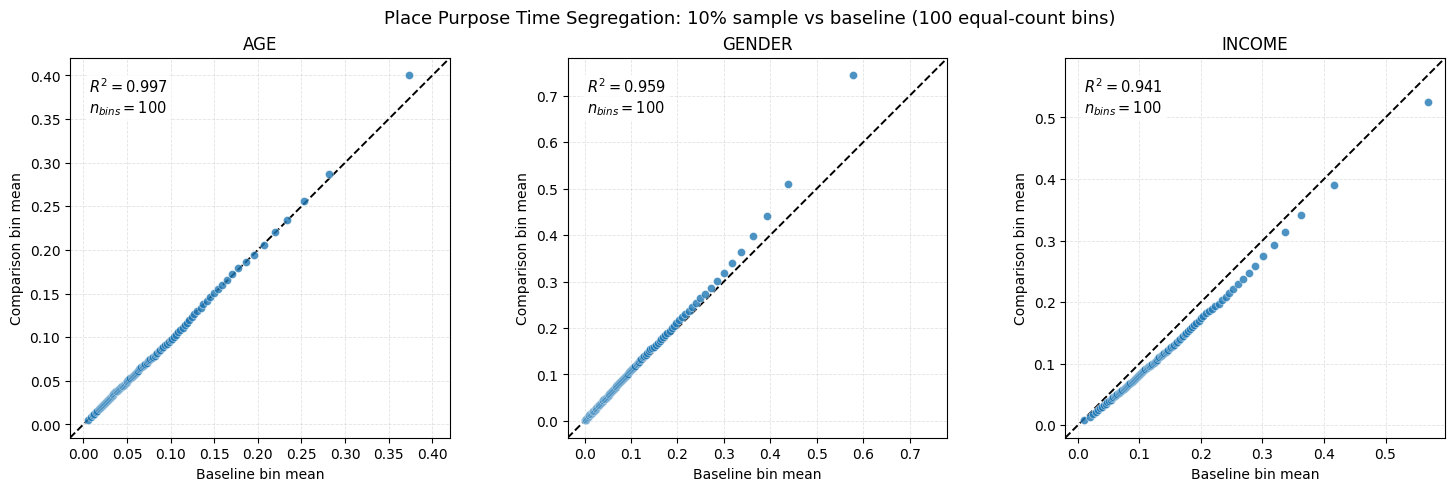

Saved scatter plot: /content/drive/MyDrive/Colab Notebooks/Workspace/tour_generation/re1_segregation/val_individual_place_purpose_time_segregation_scatter_plots/scatter_place_purpose_time_segregation_bins_100_10pct_sample.pdf


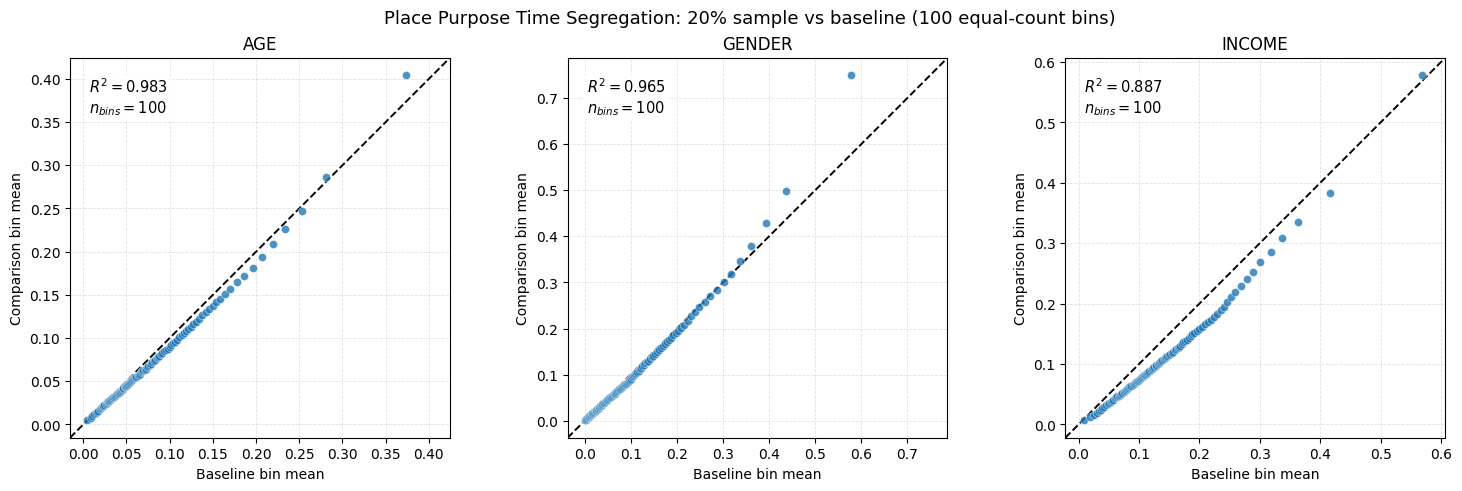

Saved scatter plot: /content/drive/MyDrive/Colab Notebooks/Workspace/tour_generation/re1_segregation/val_individual_place_purpose_time_segregation_scatter_plots/scatter_place_purpose_time_segregation_bins_100_20pct_sample.pdf


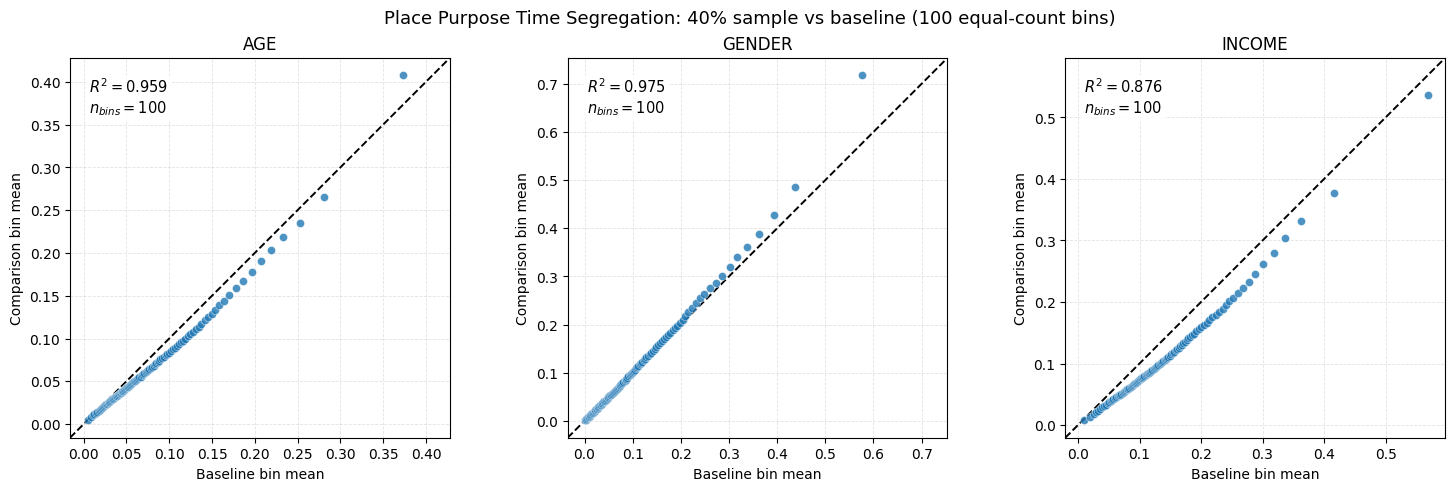

Saved scatter plot: /content/drive/MyDrive/Colab Notebooks/Workspace/tour_generation/re1_segregation/val_individual_place_purpose_time_segregation_scatter_plots/scatter_place_purpose_time_segregation_bins_100_40pct_sample.pdf

Binned R² against baseline:
   SETTING ATTRIBUTE  N_EQUAL_BINS  R2_BINNED_VS_BASELINE
10% sample       AGE           100               0.997455
10% sample    GENDER           100               0.958534
10% sample    INCOME           100               0.940954
20% sample       AGE           100               0.983166
20% sample    GENDER           100               0.964629
20% sample    INCOME           100               0.887119
40% sample       AGE           100               0.959367
40% sample    GENDER           100               0.974653
40% sample    INCOME           100               0.876309

Saved R² summary: /content/drive/MyDrive/Colab Notebooks/Workspace/tour_generation/re1_segregation/val_individual_place_purpose_time_segregation_equal_bins_bins_100

In [ ]:
from __future__ import annotations

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score


# ============================================================
# Configuration
# ============================================================

# Folder containing the input CSV files.
# Keep this line only if `path_segregation` was defined earlier.
path_segregation = path_segregation

attributes = ["age", "gender", "income"]

# Change this value. The code recalculates bins before plotting.
N_EQUAL_BINS = 100

# Choose the individual-segregation metric to compare.
#
# Examples:
#   "PLACE_SEGREGATION"
#   "PLACE_TIME_SEGREGATION"
#   "PLACE_PURPOSE_SEGREGATION"
#   "PLACE_PURPOSE_TIME_SEGREGATION"
METRIC = "PLACE_PURPOSE_TIME_SEGREGATION"


# ============================================================
# File-name template
# ============================================================

INDIVIDUAL_FILE_TEMPLATE = (
    "val_individual_segregation_{attribute}_{frac}.csv"
)


# ============================================================
# Baseline and comparison settings
# ============================================================

baseline_setting = {
    "frac": "true",
    "label": "Baseline (full sample)",
}

comparison_settings = [
    {
        "frac": "0.1",
        "label": "10% sample",
    },
    {
        "frac": "0.2",
        "label": "20% sample",
    },
    {
        "frac": "0.4",
        "label": "40% sample",
    },

    # Add settings here, for example:
    # {
    #     "frac": "0.8",
    #     "label": "80% sample",
    # },
]


# ============================================================
# Read data
# ============================================================

def build_individual_segregation_path(
    path_segregation,
    attribute,
    setting,
):
    """Build the input path for one attribute and one setting."""
    try:
        file_name = INDIVIDUAL_FILE_TEMPLATE.format(
            attribute=attribute.lower(),
            **setting,
        )
    except KeyError as error:
        raise KeyError(
            f"Missing template field {error} in setting: {setting}"
        ) from error

    return os.path.join(path_segregation, file_name)


def read_individual_segregation(
    path_segregation,
    attribute,
    setting,
    metric,
):
    """Read valid individual-level values for the selected metric."""
    input_path = build_individual_segregation_path(
        path_segregation=path_segregation,
        attribute=attribute,
        setting=setting,
    )

    if not os.path.exists(input_path):
        raise FileNotFoundError(
            f"Individual segregation file not found:\n{input_path}"
        )

    print(
        f"Reading {setting['label']} | "
        f"{attribute.upper()} | {metric}"
    )

    try:
        dataframe = pd.read_csv(
            input_path,
            usecols=[metric],
        )
    except ValueError as error:
        raise ValueError(
            f"Column '{metric}' was not found in:\n{input_path}"
        ) from error

    values = pd.to_numeric(
        dataframe[metric],
        errors="coerce",
    ).to_numpy(dtype=float)

    values = values[np.isfinite(values)]

    if values.size == 0:
        raise ValueError(
            f"No valid {metric} values in:\n{input_path}"
        )

    return values


def load_setting_data(
    path_segregation,
    setting,
    attributes,
    metric,
):
    """Load selected metric values for every demographic attribute."""
    setting_data = {}

    for attribute in attributes:
        setting_data[attribute] = read_individual_segregation(
            path_segregation=path_segregation,
            attribute=attribute,
            setting=setting,
            metric=metric,
        )

    return setting_data


# ============================================================
# Equal-count bin calculations
# ============================================================

def calculate_equal_count_bins(values, n_bins):
    """
    Sort values and divide them into `n_bins` equal or near-equal
    count groups.
    """
    values = np.asarray(values, dtype=float)
    values = np.sort(values[np.isfinite(values)])

    if values.size < n_bins:
        raise ValueError(
            f"N_EQUAL_BINS={n_bins} exceeds the number of valid "
            f"individuals ({values.size})."
        )

    records = []

    for bin_index, bin_values in enumerate(
        np.array_split(values, n_bins),
        start=1,
    ):
        records.append(
            {
                "BIN": bin_index,
                "PERCENTILE_LOWER": (bin_index - 1) / n_bins,
                "PERCENTILE_UPPER": bin_index / n_bins,
                "N_INDIVIDUALS": len(bin_values),
                "BIN_MIN": float(np.min(bin_values)),
                "BIN_MAX": float(np.max(bin_values)),
                "BIN_MEAN": float(np.mean(bin_values)),
                "BIN_STD": (
                    float(np.std(bin_values, ddof=1))
                    if len(bin_values) > 1
                    else np.nan
                ),
            }
        )

    return pd.DataFrame(records)


# ============================================================
# Compare each setting with baseline
# ============================================================

def calculate_binned_comparison(
    baseline_values,
    comparison_values,
    n_bins,
):
    """Recalculate bin means and comparison statistics."""
    baseline_bins = calculate_equal_count_bins(
        values=baseline_values,
        n_bins=n_bins,
    ).rename(
        columns={
            "N_INDIVIDUALS": "BASELINE_N_INDIVIDUALS",
            "BIN_MIN": "BASELINE_BIN_MIN",
            "BIN_MAX": "BASELINE_BIN_MAX",
            "BIN_MEAN": "BASELINE_BIN_MEAN",
            "BIN_STD": "BASELINE_BIN_STD",
        }
    )

    comparison_bins = calculate_equal_count_bins(
        values=comparison_values,
        n_bins=n_bins,
    ).rename(
        columns={
            "N_INDIVIDUALS": "COMPARISON_N_INDIVIDUALS",
            "BIN_MIN": "COMPARISON_BIN_MIN",
            "BIN_MAX": "COMPARISON_BIN_MAX",
            "BIN_MEAN": "COMPARISON_BIN_MEAN",
            "BIN_STD": "COMPARISON_BIN_STD",
        }
    )

    matched_bins = baseline_bins.merge(
        comparison_bins,
        on=[
            "BIN",
            "PERCENTILE_LOWER",
            "PERCENTILE_UPPER",
        ],
        how="inner",
        validate="one_to_one",
    )

    baseline_bin_means = matched_bins[
        "BASELINE_BIN_MEAN"
    ].to_numpy(dtype=float)

    comparison_bin_means = matched_bins[
        "COMPARISON_BIN_MEAN"
    ].to_numpy(dtype=float)

    r_squared = (
        r2_score(
            y_true=baseline_bin_means,
            y_pred=comparison_bin_means,
        )
        if (
            len(baseline_bin_means) >= 2
            and not np.isclose(np.ptp(baseline_bin_means), 0)
        )
        else np.nan
    )

    metrics = {
        "R2_BINNED_VS_BASELINE": r_squared,
        "MAE_BINNED_VS_BASELINE": float(
            np.mean(
                np.abs(comparison_bin_means - baseline_bin_means)
            )
        ),
        "RMSE_BINNED_VS_BASELINE": float(
            np.sqrt(
                np.mean(
                    (comparison_bin_means - baseline_bin_means) ** 2
                )
            )
        ),
        "BASELINE_MEAN": float(np.mean(baseline_values)),
        "BASELINE_STD": (
            float(np.std(baseline_values, ddof=1))
            if len(baseline_values) > 1
            else np.nan
        ),
        "COMPARISON_MEAN": float(np.mean(comparison_values)),
        "COMPARISON_STD": (
            float(np.std(comparison_values, ddof=1))
            if len(comparison_values) > 1
            else np.nan
        ),
    }

    matched_bins["BIN_MEAN_DIFFERENCE"] = (
        matched_bins["COMPARISON_BIN_MEAN"]
        - matched_bins["BASELINE_BIN_MEAN"]
    )

    return matched_bins, metrics


# ============================================================
# Plot 45-degree scatter plots
# ============================================================

def plot_binned_scatter(
    binned_comparison_output,
    r2_summary_output,
    setting_label,
    metric,
    attributes,
    n_bins,
    output_directory,
):
    """
    Plot baseline versus comparison bin means for each attribute.

    The number of plotted points is checked against N_EQUAL_BINS,
    ensuring that the plot always uses the current bin calculation.
    """
    setting_data = binned_comparison_output.loc[
        binned_comparison_output["SETTING"].eq(setting_label)
    ].copy()

    fig, axes = plt.subplots(
        nrows=1,
        ncols=len(attributes),
        figsize=(5.0 * len(attributes), 4.8),
        constrained_layout=True,
    )

    if len(attributes) == 1:
        axes = [axes]

    for ax, attribute in zip(axes, attributes):

        attribute_name = attribute.upper()

        plot_data = setting_data.loc[
            setting_data["ATTRIBUTE"].eq(attribute_name)
        ].copy()

        actual_n_bins = plot_data["BIN"].nunique()

        if actual_n_bins != n_bins:
            raise ValueError(
                f"{setting_label} | {attribute_name}: "
                f"plot data contain {actual_n_bins} bins, but "
                f"N_EQUAL_BINS={n_bins}."
            )

        x = plot_data["BASELINE_BIN_MEAN"].to_numpy(dtype=float)
        y = plot_data["COMPARISON_BIN_MEAN"].to_numpy(dtype=float)

        valid = np.isfinite(x) & np.isfinite(y)
        x = x[valid]
        y = y[valid]

        lower_limit = min(x.min(), y.min())
        upper_limit = max(x.max(), y.max())

        padding = (upper_limit - lower_limit) * 0.05

        if np.isclose(lower_limit, upper_limit):
            padding = max(abs(lower_limit) * 0.05, 0.01)

        lower_limit -= padding
        upper_limit += padding

        r2_value = r2_summary_output.loc[
            (
                r2_summary_output["SETTING"].eq(setting_label)
                & r2_summary_output["ATTRIBUTE"].eq(attribute_name)
            ),
            "R2_BINNED_VS_BASELINE",
        ].iloc[0]

        ax.scatter(
            x,
            y,
            s=34,
            color="#1f77b4",
            alpha=0.8,
            edgecolor="white",
            linewidth=0.35,
            zorder=3,
        )

        ax.plot(
            [lower_limit, upper_limit],
            [lower_limit, upper_limit],
            linestyle="--",
            linewidth=1.4,
            color="black",
            zorder=2,
        )

        ax.set_xlim(lower_limit, upper_limit)
        ax.set_ylim(lower_limit, upper_limit)
        ax.set_aspect("equal", adjustable="box")

        ax.set_title(attribute_name)
        ax.set_xlabel("Baseline bin mean")
        ax.set_ylabel("Comparison bin mean")

        ax.text(
            0.05,
            0.95,
            rf"$R^2 = {r2_value:.3f}$" + "\n"
            rf"$n_{{bins}} = {actual_n_bins}$",
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=10.5,
            bbox={
                "boxstyle": "round,pad=0.25",
                "facecolor": "white",
                "edgecolor": "none",
                "alpha": 0.85,
            },
        )

        ax.grid(
            linestyle="--",
            linewidth=0.6,
            alpha=0.35,
        )

    fig.suptitle(
        f"{metric.replace('_', ' ').title()}: "
        f"{setting_label} vs baseline "
        f"({n_bins} equal-count bins)",
        fontsize=13,
    )

    safe_setting_label = (
        setting_label.lower()
        .replace(" ", "_")
        .replace("%", "pct")
        .replace(",", "")
        .replace("=", "")
    )

    output_plot_file = os.path.join(
        output_directory,
        f"scatter_{metric.lower()}_bins_{n_bins}_"
        f"{safe_setting_label}.pdf",
    )

    fig.savefig(
        output_plot_file,
        format="pdf",
        bbox_inches="tight",
    )

    plt.show()
    plt.close(fig)

    print(f"Saved scatter plot: {output_plot_file}")


# ============================================================
# Run analysis and plotting
# ============================================================

if __name__ == "__main__":

    baseline_data = load_setting_data(
        path_segregation=path_segregation,
        setting=baseline_setting,
        attributes=attributes,
        metric=METRIC,
    )

    all_r2_records = []
    all_binned_comparisons = []

    plot_directory = os.path.join(
        path_segregation,
        f"val_individual_{METRIC.lower()}_scatter_plots",
    )

    os.makedirs(plot_directory, exist_ok=True)

    for setting in comparison_settings:
        print(f"\nProcessing: {setting['label']}")

        comparison_data = load_setting_data(
            path_segregation=path_segregation,
            setting=setting,
            attributes=attributes,
            metric=METRIC,
        )

        for attribute in attributes:
            attribute_name = attribute.upper()

            matched_bins, metrics = calculate_binned_comparison(
                baseline_values=baseline_data[attribute],
                comparison_values=comparison_data[attribute],
                n_bins=N_EQUAL_BINS,
            )

            matched_bins.insert(0, "METRIC", METRIC)
            matched_bins.insert(1, "SETTING", setting["label"])
            matched_bins.insert(2, "ATTRIBUTE", attribute_name)

            all_binned_comparisons.append(matched_bins)

            all_r2_records.append(
                {
                    "METRIC": METRIC,
                    "SETTING": setting["label"],
                    "ATTRIBUTE": attribute_name,
                    "N_EQUAL_BINS": N_EQUAL_BINS,
                    **metrics,
                }
            )

    binned_comparison_output = pd.concat(
        all_binned_comparisons,
        ignore_index=True,
    )

    r2_summary_output = pd.DataFrame(all_r2_records)

    # Diagnostic: each setting–attribute group must have
    # exactly N_EQUAL_BINS scatter points.
    print("\nNumber of bins used in each scatter plot:")

    print(
        binned_comparison_output
        .groupby(["SETTING", "ATTRIBUTE"])["BIN"]
        .nunique()
        .to_string()
    )

    for setting in comparison_settings:
        plot_binned_scatter(
            binned_comparison_output=binned_comparison_output,
            r2_summary_output=r2_summary_output,
            setting_label=setting["label"],
            metric=METRIC,
            attributes=attributes,
            n_bins=N_EQUAL_BINS,
            output_directory=plot_directory,
        )

    output_prefix = (
        f"val_individual_{METRIC.lower()}_equal_bins_"
        f"bins_{N_EQUAL_BINS}"
    )

    r2_summary_file = os.path.join(
        path_segregation,
        f"{output_prefix}_r2_summary.csv",
    )

    binned_comparison_file = os.path.join(
        path_segregation,
        f"{output_prefix}_bin_means.csv",
    )

    r2_summary_output.to_csv(
        r2_summary_file,
        index=False,
    )

    binned_comparison_output.to_csv(
        binned_comparison_file,
        index=False,
    )

    print("\nBinned R² against baseline:")

    print(
        r2_summary_output[
            [
                "SETTING",
                "ATTRIBUTE",
                "N_EQUAL_BINS",
                "R2_BINNED_VS_BASELINE",
            ]
        ].to_string(
            index=False,
            float_format=lambda value: f"{value:.6f}",
        )
    )

    print(f"\nSaved R² summary: {r2_summary_file}")
    print(f"Saved bin-level values: {binned_comparison_file}")
    print(f"Saved scatter plots: {plot_directory}")